In [8]:
# ============================================================================
# CELL 1
# ENVIRONMENT SETUP, IMPORTS, CONFIGURATION & DEBUG UTILITIES
# ============================================================================
#
# Research implementation:
# Zhang et al. (2023)
# "Subject-independent EEG classification based on a hybrid neural network"
# Frontiers in Neuroscience, 17:1124089
#
# Target:
#   BCI Competition IV Dataset 2a
#   4-class motor imagery
#   22 EEG channels
#   250 Hz
#   4-second trial = 1000 samples
#   LOSO: A1 ... A9
#
# This notebook is designed for:
#   - Apple Silicon / MacBook Air M4
#   - Jupyter Notebook
#   - PyTorch
#   - MPS acceleration when available
#
# ============================================================================

from __future__ import annotations

import os
import sys
import math
import time
import random
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import (
    Dict,
    List,
    Optional,
    Sequence,
    Tuple,
)

# ----------------------------------------------------------------------------
# Numerical / scientific libraries
# ----------------------------------------------------------------------------

import numpy as np
import scipy
from scipy import signal
from scipy import linalg
from scipy.io import loadmat

# ----------------------------------------------------------------------------
# Visualization
# ----------------------------------------------------------------------------

import matplotlib.pyplot as plt

# Seaborn is optional. We use it later for confusion matrices.
try:
    import seaborn as sns

    SEABORN_AVAILABLE = True

except ImportError:
    sns = None
    SEABORN_AVAILABLE = False

# ----------------------------------------------------------------------------
# Machine learning
# ----------------------------------------------------------------------------

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)
from sklearn.manifold import TSNE

# ----------------------------------------------------------------------------
# MNE for real BCI Competition IV-2a GDF files
# ----------------------------------------------------------------------------

try:
    import mne

    MNE_AVAILABLE = True

except ImportError:
    mne = None
    MNE_AVAILABLE = False

# ----------------------------------------------------------------------------
# PyTorch
# ----------------------------------------------------------------------------

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    DataLoader,
    TensorDataset,
)

# ============================================================================
# VERSION / ENVIRONMENT INFORMATION
# ============================================================================

print("=" * 78)
print("Zhang et al. (2023) Hybrid EEG / FBGAN / CRNN-DF Implementation")
print("=" * 78)

print(f"Python        : {sys.version.split()[0]}")
print(f"NumPy         : {np.__version__}")
print(f"SciPy         : {scipy.__version__}")
print(f"PyTorch       : {torch.__version__}")
print(f"MNE available : {MNE_AVAILABLE}")
print(f"Seaborn       : {SEABORN_AVAILABLE}")

# ============================================================================
# DEVICE SELECTION
# ============================================================================

# Priority:
#   1. Apple MPS
#   2. CUDA
#   3. CPU
#
# This is important for your MacBook Air M4.

if torch.backends.mps.is_available():

    DEVICE = torch.device("mps")
    DEVICE_NAME = "Apple MPS"

elif torch.cuda.is_available():

    DEVICE = torch.device("cuda")
    DEVICE_NAME = "CUDA"

else:

    DEVICE = torch.device("cpu")
    DEVICE_NAME = "CPU"


print(f"Selected device: {DEVICE_NAME}")
print(f"torch.device  : {DEVICE}")

# ============================================================================
# MPS INFORMATION
# ============================================================================

if DEVICE.type == "mps":

    print()
    print("Apple Silicon MPS acceleration detected.")
    print("MPS-safe tensor operations will be used in later cells.")

elif DEVICE.type == "cuda":

    print()
    print("CUDA acceleration detected.")

else:

    print()
    print("Running on CPU.")

# ============================================================================
# REPRODUCIBILITY
# ============================================================================

SEED = 42


def seed_everything(seed: int = SEED) -> None:
    """
    Set random seeds for reproducibility.

    Parameters
    ----------
    seed:
        Random seed.
    """

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)

print(f"Random seed   : {SEED}")

# ============================================================================
# GLOBAL DATASET PARAMETERS
# ============================================================================

# BCI Competition IV Dataset 2a
N_SUBJECTS = 9
N_SESSIONS = 2

# Number of EEG electrodes
N_CHANNELS = 22

# Sampling frequency
FS = 250

# Trial segment:
# 4 seconds × 250 Hz = 1000 samples
TRIAL_SECONDS = 4
N_TIME = FS * TRIAL_SECONDS

# Motor-imagery classes
N_CLASSES = 4

CLASS_NAMES = [
    "Left Hand",
    "Right Hand",
    "Both Feet",
    "Tongue",
]

# ============================================================================
# FILTER BANK
# ============================================================================
#
# Paper:
#   1-4
#   4-8
#   8-12
#   12-16
#   16-20
#   20-24
#   24-28
#   28-32
#   32-35
#   35-38 Hz
#
# The paper applies a fifth-order Butterworth bandpass from 1 to 38 Hz
# before the 10 sub-band decomposition.

BANDS: List[Tuple[float, float]] = [
    (1.0, 4.0),
    (4.0, 8.0),
    (8.0, 12.0),
    (12.0, 16.0),
    (16.0, 20.0),
    (20.0, 24.0),
    (24.0, 28.0),
    (28.0, 32.0),
    (32.0, 35.0),
    (35.0, 38.0),
]

BROAD_BAND = (1.0, 38.0)
BUTTERWORTH_ORDER = 5

# ============================================================================
# FBCSP PARAMETERS
# ============================================================================

# Four largest generalized eigenvectors for each OVR bifurcation
CSP_M = 4

# Number of candidate CSP dimensions:
#
#   10 bands
# × 4 classes
# × 4 filters
# = 160
#
N_CSP_CANDIDATES = len(BANDS) * N_CLASSES * CSP_M

# Numerical epsilon
EPS = 1e-8

# ============================================================================
# FBGAN PARAMETERS FROM THE PAPER
# ============================================================================

GAN_LATENT_DIM = 1600

GAN_LEARNING_RATE = 1e-4

GAN_BATCH_SIZE = 5

# Full paper augmentation:
#
# 3000 generated samples
# 750 per class

PAPER_N_AUGMENTED = 3000
PAPER_N_AUGMENTED_PER_CLASS = 750

# ============================================================================
# CRNN-DF PARAMETERS FROM THE PAPER
# ============================================================================

CLASSIFIER_LEARNING_RATE = 1e-4

CLASSIFIER_BATCH_SIZE = 32

LSTM_HIDDEN_DIM = 64

DROPOUT = 0.5

# Center/discriminative feature loss
CENTER_LAMBDA = 0.1

# Centroid repulsion
CENTER_SHIFT_ALPHA = 0.02

CENTER_SHIFT_EVERY = 15

# ============================================================================
# EXECUTION MODES
# ============================================================================
#
# IMPORTANT:
#
# We DO NOT immediately run the complete 9-subject + 3000 fake-sample
# experiment on your MacBook.
#
# First we validate every module using a small smoke test.
#
# After all cells work correctly, you can switch to the full experiment.

RUN_SMOKE_TEST = True

# Number of subjects used for the smoke test
SMOKE_SUBJECTS = 2

# One session for smoke test
SMOKE_SESSIONS = 1

# 48 trials/session for smoke test
SMOKE_TRIALS_PER_SESSION = 48

# Small training values for smoke test
SMOKE_GAN_EPOCHS = 1
SMOKE_GAN_STEPS_PER_EPOCH = 2

SMOKE_CLASSIFIER_EPOCHS = 2

# ============================================================================
# FULL EXPERIMENT PARAMETERS
# ============================================================================
#
# Do not use these initially.
#
# Recommended workflow:
#
#   1. Validate smoke test.
#   2. Load real BCI IV-2a.
#   3. Validate one LOSO subject.
#   4. Run all nine subjects.
#   5. Generate 3000 FBGAN samples/target subject.
#

FULL_GAN_EPOCHS = 50
FULL_CLASSIFIER_EPOCHS = 100

# ============================================================================
# PATHS
# ============================================================================

DATA_ROOT = Path(
    "./BCI_Competition_IV_2a"
)

OUTPUT_ROOT = Path(
    "./zhang2023_outputs"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

print()
print("Data root   :", DATA_ROOT.resolve())
print("Output root :", OUTPUT_ROOT.resolve())

# ============================================================================
# ASCII INFOGRAPHIC
# ============================================================================

print()
print("=" * 78)
print("CELL 1 ARCHITECTURE / ENVIRONMENT")
print("=" * 78)

print(
    r"""
                       ZHANG et al. 2023
                    HYBRID EEG FRAMEWORK
                              │
                              ▼
                ┌─────────────────────────┐
                │ BCI Competition IV-2a  │
                └────────────┬────────────┘
                             │
                             ▼
                      9 subjects
                             │
                             ▼
                   22 EEG channels
                             │
                             ▼
                    Sampling = 250 Hz
                             │
                             ▼
                      4-second trial
                             │
                             ▼
                       1000 samples
                             │
                             ▼
                  Input tensor = (N,22,1000)
                             │
                             ▼
               ┌──────────────────────────┐
               │     PREPROCESSING        │
               │  NaN replacement         │
               │  5th-order Butterworth   │
               │  1-38 Hz                 │
               │  training z-score        │
               └────────────┬─────────────┘
                            │
                            ▼
                    10-band Filter Bank
                            │
                 ┌──────────┴───────────┐
                 ▼                      ▼
             FBCSP + LASSO           FBGAN
                                      │
                                      ▼
                                  CRNN-DF
                                      │
                                      ▼
                                    LOSO
"""
)

print("=" * 78)

# ============================================================================
# SHAPE TRACKER
# ============================================================================

class ShapeTracker:
    """
    Small utility for debugging tensor dimensions.

    Usage:
        tracker("input", x)

    Set debug=False in a model to silence these messages.
    """

    def __init__(
        self,
        debug: bool = False,
        name: str = "module",
    ):
        self.debug = debug
        self.name = name

    def __call__(
        self,
        tag: str,
        tensor: torch.Tensor,
    ) -> torch.Tensor:

        if self.debug:

            print(
                f"[ShapeTracker:{self.name}] "
                f"{tag:<25} "
                f"shape={tuple(tensor.shape)} "
                f"dtype={tensor.dtype} "
                f"device={tensor.device}"
            )

        return tensor


# ============================================================================
# GENERAL HELPER FUNCTIONS
# ============================================================================

def print_shape(
    name: str,
    array_or_tensor,
) -> None:
    """
    Print shape information for NumPy arrays or PyTorch tensors.
    """

    if isinstance(array_or_tensor, torch.Tensor):

        print(
            f"{name:<30} "
            f"shape={tuple(array_or_tensor.shape)}, "
            f"dtype={array_or_tensor.dtype}, "
            f"device={array_or_tensor.device}"
        )

    else:

        array = np.asarray(array_or_tensor)

        print(
            f"{name:<30} "
            f"shape={array.shape}, "
            f"dtype={array.dtype}"
        )


def count_parameters(
    model: nn.Module,
) -> int:
    """
    Return number of trainable parameters.
    """

    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


def to_numpy(
    value,
) -> np.ndarray:
    """
    Safely convert a PyTorch tensor or array-like object to NumPy.
    """

    if isinstance(value, torch.Tensor):

        return (
            value
            .detach()
            .cpu()
            .numpy()
        )

    return np.asarray(value)


# ============================================================================
# MPS-SAFE RESIZE UTILITY
# ============================================================================
#
# This function is intentionally introduced here because your previous error
# came from:
#
#     F.adaptive_avg_pool2d(x, (1, 25))
#
# on Apple MPS when the input dimension was not divisible by the requested
# output dimension.
#
# We will NOT use that operation in the later discriminator implementation.
#
# Instead, we use F.interpolate(...).
#
# This is differentiable and works with the MPS backend.

def mps_safe_resize_2d(
    x: torch.Tensor,
    height: int,
    width: int,
) -> torch.Tensor:
    """
    MPS-safe differentiable spatial resize.

    Parameters
    ----------
    x:
        Tensor with shape (B,C,H,W)

    height:
        Target height.

    width:
        Target width.

    Returns
    -------
    torch.Tensor
        Resized tensor.
    """

    if x.ndim != 4:

        raise ValueError(
            "mps_safe_resize_2d expects a 4-D tensor "
            "(B,C,H,W), got "
            f"{tuple(x.shape)}"
        )

    return F.interpolate(
        x,
        size=(height, width),
        mode="bilinear",
        align_corners=False,
    )


# ============================================================================
# MPS SANITY TEST
# ============================================================================
#
# This does NOT build the GAN yet.
#
# It only verifies that your M4/MPS environment can perform the exact
# resize operation we will use later.

print()
print("=" * 78)
print("MPS-SAFE RESIZE SANITY TEST")
print("=" * 78)

try:

    test_tensor = torch.randn(
        2,
        30,
        1,
        35,
        device=DEVICE,
    )

    resized_tensor = mps_safe_resize_2d(
        test_tensor,
        height=1,
        width=25,
    )

    print_shape(
        "Test input",
        test_tensor,
    )

    print_shape(
        "Test output",
        resized_tensor,
    )

    print("MPS-safe resize test: PASS")

except Exception as exc:

    print("MPS-safe resize test: FAILED")
    print("Error:", repr(exc))

    # Do not stop the notebook here.
    # We want later cells to provide their own diagnostics.


# ============================================================================
# FINAL CONFIGURATION SUMMARY
# ============================================================================

print()
print("=" * 78)
print("CONFIGURATION SUMMARY")
print("=" * 78)

print(f"Subjects                  : {N_SUBJECTS}")
print(f"Sessions                  : {N_SESSIONS}")
print(f"Channels                  : {N_CHANNELS}")
print(f"Sampling rate             : {FS} Hz")
print(f"Trial duration            : {TRIAL_SECONDS} seconds")
print(f"Time points               : {N_TIME}")
print(f"Classes                   : {N_CLASSES}")
print(f"Filter-bank bands         : {len(BANDS)}")
print(f"CSP filters/class/band    : {CSP_M}")
print(f"Candidate CSP dimensions  : {N_CSP_CANDIDATES}")
print(f"GAN latent dimension      : {GAN_LATENT_DIM}")
print(f"GAN batch size            : {GAN_BATCH_SIZE}")
print(f"GAN learning rate         : {GAN_LEARNING_RATE}")
print(f"Classifier batch size     : {CLASSIFIER_BATCH_SIZE}")
print(f"Classifier learning rate  : {CLASSIFIER_LEARNING_RATE}")
print(f"Center-loss lambda        : {CENTER_LAMBDA}")
print(f"Center shift alpha        : {CENTER_SHIFT_ALPHA}")
print(f"Center shift interval    : {CENTER_SHIFT_EVERY} epochs")
print(f"Paper augmentation        : {PAPER_N_AUGMENTED}")
print(f"Augmentation/class        : {PAPER_N_AUGMENTED_PER_CLASS}")

print()
print("CELL 1 completed successfully.")
print("Next: CELL 2 - Paper architecture and mathematical overview.")

Zhang et al. (2023) Hybrid EEG / FBGAN / CRNN-DF Implementation
Python        : 3.10.19
NumPy         : 1.26.4
SciPy         : 1.15.3
PyTorch       : 2.10.0
MNE available : True
Seaborn       : True
Selected device: Apple MPS
torch.device  : mps

Apple Silicon MPS acceleration detected.
MPS-safe tensor operations will be used in later cells.
Random seed   : 42

Data root   : /Users/ashokvarmabevara/MtechProj/BCI_Competition_IV_2a
Output root : /Users/ashokvarmabevara/MtechProj/zhang2023_outputs

CELL 1 ARCHITECTURE / ENVIRONMENT

                       ZHANG et al. 2023
                    HYBRID EEG FRAMEWORK
                              │
                              ▼
                ┌─────────────────────────┐
                │ BCI Competition IV-2a  │
                └────────────┬────────────┘
                             │
                             ▼
                      9 subjects
                             │
                             ▼
                   22 EEG chan

In [9]:
# ============================================================================
# CELL 2
# PAPER ARCHITECTURE + MATHEMATICAL FORMULATION OVERVIEW
# ============================================================================
#
# This cell documents the methodology described by:
#
# Zhang H, Ji H, Yu J, Li J, Jin L, Liu L, Bai Z, Ye C.
# "Subject-independent EEG classification based on a hybrid neural network."
# Frontiers in Neuroscience, 2023.
#
# No model training is performed in this cell.
#
# ============================================================================


# ============================================================================
# 2.1 COMPLETE HYBRID NETWORK FLOW
# ============================================================================

print("=" * 90)
print("ZHANG et al. 2023 - COMPLETE HYBRID EEG ARCHITECTURE")
print("=" * 90)

print(
    r"""
                                  BCI IV-2a
                                     │
                                     ▼
                     ┌────────────────────────────┐
                     │ Raw EEG Trial              │
                     │ C = 22 channels            │
                     │ T = 1000 samples           │
                     │ 4 seconds @ 250 Hz         │
                     └─────────────┬──────────────┘
                                   │
                                   ▼
                     ┌────────────────────────────┐
                     │ PREPROCESSING              │
                     │                            │
                     │ 1. NaN replacement         │
                     │ 2. Butterworth 1-38 Hz     │
                     │    order = 5               │
                     │ 3. Training z-score        │
                     └─────────────┬──────────────┘
                                   │
                                   ▼
                  ┌──────────────────────────────────┐
                  │ 10-BAND FILTER BANK              │
                  │                                  │
                  │ 1-4     Hz                       │
                  │ 4-8     Hz                       │
                  │ 8-12    Hz                       │
                  │ 12-16   Hz                       │
                  │ 16-20   Hz                       │
                  │ 20-24   Hz                       │
                  │ 24-28   Hz                       │
                  │ 28-32   Hz                       │
                  │ 32-35   Hz                       │
                  │ 35-38   Hz                       │
                  └────────────────┬─────────────────┘
                                   │
                    ┌──────────────┴──────────────┐
                    │                             │
                    ▼                             ▼
          ┌─────────────────────┐       ┌────────────────────┐
          │ OVR FBCSP            │       │ Standardized EEG   │
          │                     │       │                    │
          │ 4 classes × 10       │       │ Target-subject     │
          │ bands                │       │ signals            │
          │                     │       │                    │
          │ 4 filters / OVR      │       └─────────┬──────────┘
          └──────────┬──────────┘                 │
                     │                            │
                     ▼                            ▼
          10 × 4 × 4 = 160              ┌────────────────────┐
          candidate dimensions          │ Target-specific     │
                     │                   │ FBGAN               │
                     ▼                   └─────────┬───────────┘
               LASSO selection                    │
                     │                            ▼
                     ▼                     ┌───────────────┐
          Sparse CSP features              │ Generator Gθ │
          + W_csp                           └──────┬────────┘
                     │                            │
                     ▼                            ▼
             Dynamic Var                    Fake EEG
                     │                            │
                     │                  ┌─────────┴─────────┐
                     │                  │                   │
                     │                  ▼                   ▼
                     │          ┌──────────────┐    ┌──────────────┐
                     │          │ Dφ            │    │ Sparse W_csp │
                     │          │ Raw EEG       │    │ projection   │
                     │          └──────┬───────┘    └──────┬───────┘
                     │                 │                   │
                     │                 │                   ▼
                     │                 │           ┌──────────────┐
                     │                 │           │ Dψ            │
                     │                 │           │ Sparse-FB EEG │
                     │                 │           └──────┬───────┘
                     │                 │                   │
                     │                 └─────────┬─────────┘
                     │                           │
                     │                           ▼
                     │                     FBGAN training
                     │                           │
                     │                           ▼
                     │                    Target fake EEG
                     │                           │
                     └───────────────────────────┘
                                 │
                                 ▼
                  ┌─────────────────────────────────┐
                  │ AUGMENTED TRAINING DATA         │
                  │                                 │
                  │ 8 source subjects               │
                  │ + target generated samples      │
                  └────────────────┬────────────────┘
                                   │
                                   ▼
                         ┌────────────────────┐
                         │ CRNN-DF            │
                         │                    │
                         │ Spatial CNN        │
                         │        ↓           │
                         │ Max Pooling        │
                         │        ↓           │
                         │ LSTM 64             │
                         │        ↓           │
                         │ LSTM 64             │
                         │        ↓           │
                         │ Feature vector v    │
                         └─────────┬──────────┘
                                   │
                       ┌───────────┴────────────┐
                       │                        │
                       ▼                        ▼
                 Cross Entropy            Center Loss
                       │                        │
                       └───────────┬────────────┘
                                   ▼
                    Joint discriminative loss
                                   │
                                   ▼
                           CRNN-DF prediction
                                   │
                                   ▼
                           LOSO target test
"""
)

# ============================================================================
# 2.2 DATASET FORMULATION
# ============================================================================

print()
print("=" * 90)
print("2. DATASET FORMULATION")
print("=" * 90)

print(
    r"""
BCI Competition IV Dataset 2a

Subjects:
    A1 ... A9

Sessions:
    2 sessions / subject

Trials:
    288 trials / session

Classes:
    4 motor imagery classes

    Class 0 → Left Hand
    Class 1 → Right Hand
    Class 2 → Both Feet
    Class 3 → Tongue

EEG:
    C = 22 channels
    FS = 250 Hz

Trial:
    cue starts at approximately t = 2 seconds
    sample interval used by the paper = 4 seconds
    therefore:

        T = 4 × 250
          = 1000 samples

Trial tensor:

        X ∈ R^(22 × 1000)

LOSO:

    Training:
        8 subjects

    Testing:
        1 completely unseen subject

Full subject-independent split:

    8 × 2 × 288 = 4608 training trials

    1 × 2 × 288 = 576 target trials
"""
)

# ============================================================================
# 2.3 PREPROCESSING
# ============================================================================

print()
print("=" * 90)
print("3. PREPROCESSING MATHEMATICS")
print("=" * 90)

print(
    r"""
STEP 1
------
NaN replacement:

    X_nan → mean value replacement


STEP 2
------
Fifth-order Butterworth bandpass:

    1 Hz ≤ f ≤ 38 Hz

    order = 5


STEP 3
------
Z-score standardization:

        X' = (X - μ_train) / σ_train

where:

    μ_train  = statistics calculated from training data
    σ_train  = standard deviation calculated from training data

IMPORTANT:

    Statistics must NOT be calculated from the target test set.


STEP 4
------
Filter bank:

    X' →
       X_1   : 1-4 Hz
       X_2   : 4-8 Hz
       X_3   : 8-12 Hz
       X_4   : 12-16 Hz
       X_5   : 16-20 Hz
       X_6   : 20-24 Hz
       X_7   : 24-28 Hz
       X_8   : 28-32 Hz
       X_9   : 32-35 Hz
       X_10  : 35-38 Hz

Combined tensor:

    X_FB ∈ R^(N × 10 × 22 × 1000)
"""
)

# ============================================================================
# 2.4 OVR FBCSP
# ============================================================================

print()
print("=" * 90)
print("4. OVR FBCSP")
print("=" * 90)

print(
    r"""
For every frequency band:

    band = 1 ... 10

For every class:

    class c vs all remaining classes

Therefore:

    10 frequency bands
    × 4 OVR problems
    = 40 binary CSP problems


For a class c:

                    1
    Rc = ─────────────── Σ
          Nc

                    Xi Xiᵀ
                    ──────
                    tr(Xi Xiᵀ)


Rest covariance:

    Rrest

Generalized eigenvalue problem:

    Rc w = λ Rrest w

The paper retains:

    m = 4 eigenvectors

for every OVR problem.

Therefore:

    4 classes
    × 4 CSP filters
    = 16 filters / band

and:

    10 bands
    × 16 filters
    = 160 candidate CSP dimensions.


Candidate feature matrix:

    F ∈ R^(N × 160)
"""
)

# ============================================================================
# 2.5 LASSO
# ============================================================================

print()
print("=" * 90)
print("5. LASSO FEATURE SELECTION")
print("=" * 90)

print(
    r"""
Input:

    F ∈ R^(N × 160)


LASSO objective:

       1
    ─────── ||y - β0 - Fβ||²
       N

            +
          
       λ ||β||₁


Equivalent conceptual form:

    β* = argmin
          β

          [ regression error
            +
            L1 penalty ]


Features whose coefficient satisfies:

    β_j = 0

are discarded.

Features satisfying:

    β_j ≠ 0

are retained.


Output:

    selected feature indices

    + corresponding spatial filters

    → W_csp


Dynamic sparse dimension:

    Var = number of selected filters


Sparse spatial representation:

    Z = W_cspᵀ X'

The exact sparse-feature dimensionality is target-subject dependent.
"""
)

# ============================================================================
# 2.6 FBGAN
# ============================================================================

print()
print("=" * 90)
print("6. FBGAN")
print("=" * 90)

print(
    r"""
                    z ~ N(0,I)
                   z ∈ R^1600
                       │
                       ▼
                 ┌─────────────┐
                 │ FC          │
                 │ 1600→256000 │
                 └──────┬──────┘
                        │
                        ▼
                Reshape / feature maps
                        │
                        ▼
          ┌───────────────────────────┐
          │ ConvTrans1                │
          │ 128 → 128                 │
          │ kernel=(3,15)             │
          │ stride=(1,3)              │
          │ BatchNorm + LeakyReLU     │
          └─────────────┬─────────────┘
                        ▼
          ┌───────────────────────────┐
          │ ConvTrans2                │
          │ 128 → 128                 │
          │ kernel=(3,15)             │
          │ stride=(1,3)              │
          │ BatchNorm + LeakyReLU     │
          └─────────────┬─────────────┘
                        ▼
          ┌───────────────────────────┐
          │ ConvTrans3                │
          │ 128 → 64                  │
          │ kernel=(3,5)              │
          │ stride=(1,2)              │
          │ BatchNorm + LeakyReLU     │
          └─────────────┬─────────────┘
                        ▼
          ┌───────────────────────────┐
          │ ConvTrans4                │
          │ 64 → 32                   │
          │ kernel=(4,5)              │
          │ stride=(2,1)              │
          │ BatchNorm + LeakyReLU     │
          └─────────────┬─────────────┘
                        ▼
          ┌───────────────────────────┐
          │ ConvTrans5                │
          │ 32 → 1                    │
          │ kernel=(1,2)              │
          │ stride=(1,1)              │
          │ Tanh                      │
          └─────────────┬─────────────┘
                        ▼
                  Fake EEG
              (1,22,1000 target)
"""
)

print()
print(
    r"""
FBGAN has TWO discriminators:

             Fake EEG
                │
        ┌───────┴────────┐
        │                │
        ▼                ▼
       Dφ          sparse W_csp
        │                │
        │                ▼
        │               Dψ
        │                │
        └───────┬────────┘
                ▼
          adversarial game


Dφ:
    Distinguishes raw real EEG from raw generated EEG.

Dψ:
    Distinguishes real sparse filter-bank representations
    from generated sparse filter-bank representations.

This is the key FBCSP constraint introduced by FBGAN.
"""
)

# ============================================================================
# 2.7 Dφ ARCHITECTURE
# ============================================================================

print()
print("=" * 90)
print("7. Dφ - RAW EEG DISCRIMINATOR")
print("=" * 90)

print(
    r"""
Input:

    (B,1,22,1000)

        │
        ▼

Conv1
    in  = 1
    out = 10
    kernel = (1,23)
    stride = (1,1)
        │
        ▼

LeakyReLU
        │
        ▼

Conv2
    in  = 10
    out = 30
    kernel = (22,1)
    stride = (1,1)
        │
        ▼

LeakyReLU
        │
        ▼

Conv3
    in  = 30
    out = 30
    kernel = (1,17)
    stride = (1,1)
        │
        ▼

LeakyReLU
        │
        ▼

MaxPool
    kernel = (1,6)
    stride = (1,6)
        │
        ▼

Conv4
    in  = 30
    out = 30
    kernel = (1,7)
    stride = (1,7)
        │
        ▼

LeakyReLU
        │
        ▼

MaxPool
    kernel = (1,6)
    stride = (1,6)
        │
        ▼

Published FC:
    750 → 1

        │
        ▼

Real / Fake score
"""
)

# ============================================================================
# 2.8 Dψ ARCHITECTURE
# ============================================================================

print()
print("=" * 90)
print("8. Dψ - SPARSE FILTER-BANK EEG DISCRIMINATOR")
print("=" * 90)

print(
    r"""
Input:

    Z = W_cspᵀ X'

    shape:

    (B,1,Var,1000)

where:

    Var = number of sparse LASSO-selected dimensions.

        │
        ▼

Conv1
    1 → 10
    kernel=(1,23)
    stride=(1,1)

        │
        ▼

Conv2
    10 → 30
    kernel=(4,1)
    stride=(4,1)

        │
        ▼

Conv3
    30 → 30
    kernel=(Var,1)
    stride=(1,1)

        │
        ▼

Conv4
    30 → 30
    kernel=(1,17)
    stride=(1,1)

        │
        ▼

MaxPool
    kernel=(1,6)
    stride=(1,6)

        │
        ▼

Conv5
    30 → 30
    kernel=(1,7)
    stride=(1,1)

        │
        ▼

MaxPool
    kernel=(1,6)
    stride=(1,6)

        │
        ▼

FC
    750 → 1

        │
        ▼

Real / Fake score


IMPORTANT:

    Var is adaptive.

    It is NOT fixed before FBCSP + LASSO.
"""
)

# ============================================================================
# 2.9 CRNN-DF
# ============================================================================

print()
print("=" * 90)
print("9. CRNN-DF CLASSIFIER")
print("=" * 90)

print(
    r"""
Input:

    X ∈ R^(B × 1 × 22 × 1000)

        │
        ▼

               SPATIAL CNN
        ┌────────────────────────┐
        │ Conv2D                 │
        │ kernel=(22,45)         │
        │ stride=1               │
        │ BatchNorm              │
        │ ReLU                   │
        │ Dropout=0.5            │
        └───────────┬────────────┘
                    │
                    ▼

             MaxPooling2D
             kernel=(1,75)
             stride=(1,10)
                    │
                    ▼

             Temporal Sequence
                    │
                    ▼

              ┌───────────┐
              │ LSTM #1   │
              │ hidden=64 │
              └─────┬─────┘
                    │
                    ▼
               Dropout=0.5
                    │
                    ▼
              ┌───────────┐
              │ LSTM #2   │
              │ hidden=64 │
              └─────┬─────┘
                    │
                    ▼
               Dropout=0.5
                    │
                    ▼
             Feature vector v
                    │
              ┌─────┴──────┐
              │            │
              ▼            ▼
          Classifier    Center Loss
              │            │
              ▼            ▼
          logits       L_cen
              │            │
              └─────┬──────┘
                    ▼
       Loss = CrossEntropy + λ L_cen
"""
)

# ============================================================================
# 2.10 CENTRAL DISTANCE LOSS
# ============================================================================

print()
print("=" * 90)
print("10. CENTRAL DISTANCE LOSS")
print("=" * 90)

print(
    r"""
For each feature vector:

    v_i^k

and corresponding class centroid:

    cen_(y_i)^k


Central distance loss:

                    1
    L_cen = ───────────── Σ_i
                     b

             || v_i^k - cen_(y_i)^k ||²


Interpretation:

    Same-class features
            │
            ▼
       move closer
            │
            ▼
      lower intra-class
      feature variation
"""
)

# ============================================================================
# 2.11 CENTROID INITIALIZATION
# ============================================================================

print()
print("=" * 90)
print("11. CENTROID INITIALIZATION")
print("=" * 90)

print(
    r"""
For class j:

                  Σ_i δ(y_i,j) v_i^0
    cen_j^0 = ─────────────────────────
                   Σ_i δ(y_i,j)


where:

    δ(y_i,j) = 1   if y_i = j
               0   otherwise


Therefore:

    each initial centroid
    =
    mean feature vector of that class
"""
)

# ============================================================================
# 2.12 CENTROID REPULSION
# ============================================================================

print()
print("=" * 90)
print("12. CENTROID REPULSION / SHIFT")
print("=" * 90)

print(
    r"""
Every 15 epochs:

First calculate global center:

                 1
    v_c^k = ───────── Σ_j cen_j^k
                  C


Then shift each centroid outward:

              cen_j^k - v_c^k
    cen_j^(k+1)
       =
          cen_j^k
          +
          α · ------------------------
               ||cen_j^k - v_c^k||


where:

    α = 0.02

This operation:

    reduces intra-class spread
              +
    increases inter-class center separation
              =
    more discriminative feature space
"""
)

# ============================================================================
# 2.13 FINAL LOSS
# ============================================================================

print()
print("=" * 90)
print("13. FINAL CRNN-DF TRAINING OBJECTIVE")
print("=" * 90)

print(
    r"""
Classification loss:

    L_CE = CrossEntropy(y_true, y_pred)


Discriminative feature loss:

    L_cen


Joint objective:

    L_total = L_CE + λ L_cen


Paper-selected value:

    λ = 0.1
"""
)

# ============================================================================
# 2.14 LOSO EXPERIMENT
# ============================================================================

print()
print("=" * 90)
print("14. LOSO EXPERIMENTAL PROTOCOL")
print("=" * 90)

print(
    r"""
                         Subject A1
                             │
                         ┌───┴───┐
                         │ TEST  │
                         └───────┘

                         Subjects
                       A2 ... A9
                         │
                         ▼
                       TRAIN


Then repeat:

    A2 = test
    A1,A3...A9 = train

    A3 = test
    A1,A2,A4...A9 = train

             ...

    A9 = test
    A1...A8 = train


Total:

    9 LOSO folds
"""
)

# ============================================================================
# 2.15 PAPER REPORTED REFERENCE VALUES
# ============================================================================

print()
print("=" * 90)
print("15. PAPER REPORTED REFERENCE RESULTS")
print("=" * 90)

paper_crnn_df = {
    "A1": 65.51,
    "A2": 45.18,
    "A3": 78.62,
    "A4": 53.58,
    "A5": 55.64,
    "A6": 56.03,
    "A7": 71.28,
    "A8": 75.02,
    "A9": 70.78,
}

print("\nCRNN-DF without FBGAN augmentation:")
print("-" * 50)

for subject, accuracy in paper_crnn_df.items():

    print(
        f"{subject}: {accuracy:6.2f}%"
    )

print()
print(
    "Reported mean : 63.52%"
)
print(
    "Reported std  : 10.70%"
)

paper_aug_results = {
    0: 63.52,
    500: 68.53,
    1000: 69.90,
    2000: 71.31,
    3000: 72.82,
    4000: 72.82,
}

print()
print("Reported augmentation results:")
print("-" * 50)

for n_aug, accuracy in paper_aug_results.items():

    print(
        f"N_aug={n_aug:4d} → "
        f"{accuracy:.2f}%"
    )

print()
print(
    "Table-4 reference at 3000 fake samples:"
)
print(
    "Mean = 72.82%"
)
print(
    "Std  = 10.44%"
)

# ============================================================================
# 2.16 IMPORTANT IMPLEMENTATION NOTE
# ============================================================================

print()
print("=" * 90)
print("16. IMPLEMENTATION NOTES")
print("=" * 90)

print(
    r"""
1. The paper explicitly specifies the major layers and hyperparameters.

2. Some low-level tensor geometry details are not completely specified
   in the text/table, particularly padding/shape transitions around
   the GAN discriminator's published FC=750 dimension.

3. For the MacBook M4 implementation, later cells will use MPS-safe,
   differentiable resize operations where necessary.

4. We will NOT use:

       F.adaptive_avg_pool2d(...)

   for the non-divisible MPS geometry that caused your earlier error.

5. We will instead use:

       F.interpolate(...)

   as a non-trainable shape adapter.

6. The core learnable layer specifications remain the published ones.

7. Target-subject FBGAN generation will be implemented only after
   the preprocessing and FBCSP/LASSO cells have produced W_csp.

8. We will test each module separately before connecting the modules
   into the complete LOSO pipeline.
"""
)

# ============================================================================
# 2.17 FINAL SHAPE SUMMARY
# ============================================================================

print()
print("=" * 90)
print("17. MASTER TENSOR SHAPE SUMMARY")
print("=" * 90)

shape_table = [
    ("Raw trial", "(22, 1000)"),
    ("Batch raw EEG", "(B, 22, 1000)"),
    ("CNN input", "(B, 1, 22, 1000)"),
    ("Filter bank", "(B, 10, 22, 1000)"),
    ("Candidate FBCSP", "(B, 160)"),
    ("Sparse FBCSP", "(B, Var)"),
    ("Sparse FB discriminator input", "(B, 1, Var, 1000)"),
    ("GAN latent vector", "(B, 1600)"),
    ("GAN output", "(B, 1, 22, 1000)"),
    ("CRNN feature", "(B, 64)"),
    ("Classifier logits", "(B, 4)"),
]

for name, shape in shape_table:

    print(
        f"{name:<40} {shape}"
    )

print()
print("=" * 90)
print("CELL 2 COMPLETED SUCCESSFULLY")
print("=" * 90)

print()
print(
    "Next cell: CELL 3 - Synthetic BCI IV-2a generator + "
    "real GDF/MAT/NPZ data loader."
)

ZHANG et al. 2023 - COMPLETE HYBRID EEG ARCHITECTURE

                                  BCI IV-2a
                                     │
                                     ▼
                     ┌────────────────────────────┐
                     │ Raw EEG Trial              │
                     │ C = 22 channels            │
                     │ T = 1000 samples           │
                     │ 4 seconds @ 250 Hz         │
                     └─────────────┬──────────────┘
                                   │
                                   ▼
                     ┌────────────────────────────┐
                     │ PREPROCESSING              │
                     │                            │
                     │ 1. NaN replacement         │
                     │ 2. Butterworth 1-38 Hz     │
                     │    order = 5               │
                     │ 3. Training z-score        │
                     └─────────────┬──────────────┘
                      

In [10]:
# ============================================================================
# CELL 3
# SYNTHETIC BCI IV-2a DATA GENERATOR
# + REAL .GDF / .MAT / .NPZ DATA LOADERS
# ============================================================================
#
# Target dataset:
#   BCI Competition IV Dataset 2a
#
# Expected logical dimensions:
#
#   9 subjects
#   × 2 sessions
#   × 288 trials
#   × 22 EEG channels
#   × 1000 time samples
#
# The full materialized dataset is relatively large, so this cell supports:
#
#   1. Small eager synthetic generation for testing
#   2. Lazy synthetic generation for large experiments
#   3. Real .gdf loading with MNE
#   4. Generic .npz loading
#   5. Basic .mat loading
#
# ============================================================================
#
# IMPORTANT:
#
# This cell does NOT preprocess the data.
#
# Preprocessing is implemented in CELL 4.
#
# ============================================================================


# ============================================================================
# 3.1 ASCII DATA FLOW
# ============================================================================

print("=" * 90)
print("CELL 3 - DATA GENERATION / LOADING")
print("=" * 90)

print(
    r"""
                 BCI IV-2a DATA MODULE
                           │
          ┌────────────────┼─────────────────┐
          │                │                 │
          ▼                ▼                 ▼
     Synthetic           .GDF              .NPZ/.MAT
     generator           files               files
          │                │                 │
          ▼                ▼                 ▼
       X,y,subject,session metadata
                    │
                    ▼
               validation
                    │
                    ▼
        X shape = (N,22,1000)
        y shape = (N,)
        subject = (N,)
        session = (N,)

LOSO later uses:

      source subjects ──────────► TRAIN
      target subject  ──────────► TEST
"""
)


# ============================================================================
# 3.2 DATA SHAPE VALIDATION
# ============================================================================

def validate_eeg_array(
    X: np.ndarray,
    expected_channels: int = N_CHANNELS,
    expected_time: int = N_TIME,
) -> None:
    """
    Validate EEG tensor dimensionality.

    Expected:
        X = (N, 22, 1000)
    """

    X = np.asarray(X)

    if X.ndim != 3:

        raise ValueError(
            "EEG data must be 3-dimensional: "
            "(N, channels, time).\n"
            f"Received shape: {X.shape}"
        )

    if X.shape[1] != expected_channels:

        raise ValueError(
            f"Expected {expected_channels} EEG channels, "
            f"but received {X.shape[1]}.\n"
            f"Received shape: {X.shape}"
        )

    if X.shape[2] != expected_time:

        raise ValueError(
            f"Expected {expected_time} time points, "
            f"but received {X.shape[2]}.\n"
            f"Received shape: {X.shape}"
        )


# ============================================================================
# 3.3 LABEL VALIDATION
# ============================================================================

def normalize_class_labels(
    y: np.ndarray,
    n_classes: int = N_CLASSES,
) -> np.ndarray:
    """
    Normalize class labels to:

        0, 1, 2, 3

    Handles common:
        0-3
        1-4
    """

    y = np.asarray(y).reshape(-1)

    if not np.issubdtype(y.dtype, np.integer):

        # Some MAT files contain float labels such as 1.0, 2.0, ...
        if np.all(np.isfinite(y)):

            y = y.astype(np.int64)

        else:

            raise ValueError(
                "Labels contain non-finite values."
            )

    unique = np.unique(y)

    print(
        "Original label values:",
        unique
    )

    # Already 0,1,2,3
    if set(unique.tolist()).issubset(set(range(n_classes))):

        return y.astype(np.int64)

    # Common MATLAB convention: 1,2,3,4
    if set(unique.tolist()) == {1, 2, 3, 4}:

        print(
            "Converting labels from 1-4 to 0-3."
        )

        return (
            y.astype(np.int64) - 1
        )

    # Attempt generic continuous remapping
    if len(unique) == n_classes:

        mapping = {
            value: index
            for index, value in enumerate(
                sorted(unique.tolist())
            )
        }

        print(
            "Applying generic label mapping:",
            mapping
        )

        return np.asarray(
            [mapping[value] for value in y],
            dtype=np.int64,
        )

    raise ValueError(
        f"Could not convert labels to {n_classes} classes. "
        f"Unique labels: {unique}"
    )


# ============================================================================
# 3.4 GENERATE ONE SYNTHETIC EEG TRIAL
# ============================================================================

def generate_synthetic_trial(
    label: int,
    channels: int = N_CHANNELS,
    time_points: int = N_TIME,
    fs: int = FS,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """
    Generate one synthetic EEG-like MI trial.

    Output:
        (22, 1000)

    This is NOT intended to reproduce the biological distribution of
    BCI IV-2a. Its purpose is to provide a deterministic, runnable dataset
    with the same tensor dimensions and 4-class structure so every notebook
    module can be tested before real data are loaded.
    """

    if label not in range(N_CLASSES):

        raise ValueError(
            f"label must be in [0,{N_CLASSES-1}], got {label}"
        )

    if rng is None:

        rng = np.random.default_rng()

    # Time vector
    t = (
        np.arange(time_points)
        / float(fs)
    )

    # ------------------------------------------------------------------------
    # Base EEG-like noise
    # ------------------------------------------------------------------------

    X = (
        0.10
        * rng.standard_normal(
            (channels, time_points)
        )
    )

    # ------------------------------------------------------------------------
    # Class-dependent frequencies
    #
    # These are merely synthetic discriminative patterns.
    # They do NOT claim to reproduce exact BCI IV-2a physiology.
    # ------------------------------------------------------------------------

    class_frequency = {
        0: 10.0,   # Left Hand
        1: 11.0,   # Right Hand
        2: 13.0,   # Both Feet
        3: 8.0,    # Tongue
    }

    frequency = class_frequency[label]

    # ------------------------------------------------------------------------
    # Approximate sensorimotor channel groups
    # ------------------------------------------------------------------------

    active_channels = {
        0: [6, 7, 8],
        1: [18, 19, 20],
        2: [10, 11, 12, 13],
        3: [14, 15, 16],
    }

    selected_channels = active_channels[label]

    # ------------------------------------------------------------------------
    # Slow envelope
    # ------------------------------------------------------------------------

    envelope = (
        1.0
        + 0.30
        * np.sin(
            2.0
            * np.pi
            * 0.5
            * t
        )
    )

    # ------------------------------------------------------------------------
    # Add class-dependent rhythmic activity
    # ------------------------------------------------------------------------

    for channel in selected_channels:

        phase = rng.uniform(
            0.0,
            2.0 * np.pi,
        )

        amplitude = rng.uniform(
            0.25,
            0.60,
        )

        X[channel] += (
            amplitude
            * envelope
            * np.sin(
                2.0
                * np.pi
                * frequency
                * t
                + phase
            )
        )

        # Secondary harmonic
        X[channel] += (
            0.10
            * np.sin(
                2.0
                * np.pi
                * (frequency + 8.0)
                * t
                + phase / 2.0
            )
        )

    # ------------------------------------------------------------------------
    # Weak shared low-frequency component
    # ------------------------------------------------------------------------

    X += (
        0.02
        * np.sin(
            2.0
            * np.pi
            * 1.5
            * t
        )[None, :]
    )

    # ------------------------------------------------------------------------
    # Channel-specific offsets
    # ------------------------------------------------------------------------

    X += (
        rng.normal(
            0.0,
            0.01,
            size=(channels, 1),
        )
    )

    return X.astype(
        np.float32
    )


# ============================================================================
# 3.5 SYNTHETIC DATASET GENERATOR
# ============================================================================

def generate_synthetic_bci2a(
    subjects: int = N_SUBJECTS,
    sessions: int = N_SESSIONS,
    trials_per_session: int = 288,
    seed: int = SEED,
) -> Tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    """
    Materialize a synthetic BCI IV-2a-compatible dataset.

    Returns:
        X:
            (N,22,1000)

        y:
            (N,)

        subjects:
            (N,)

        sessions:
            (N,)

    WARNING:
        Full 9 × 2 × 288 × 22 × 1000 float32 materialization can require
        roughly 1.1 GB just for X, before intermediate filter-bank arrays.
    """

    total_trials = (
        subjects
        * sessions
        * trials_per_session
    )

    approx_gb = (
        total_trials
        * N_CHANNELS
        * N_TIME
        * 4
        / (1024 ** 3)
    )

    print()
    print(
        "Synthetic dataset configuration:"
    )
    print(
        f"  Subjects        : {subjects}"
    )
    print(
        f"  Sessions        : {sessions}"
    )
    print(
        f"  Trials/session  : {trials_per_session}"
    )
    print(
        f"  Total trials    : {total_trials}"
    )
    print(
        f"  Approx X memory : {approx_gb:.2f} GB"
    )

    rng = np.random.default_rng(
        seed
    )

    X = np.empty(
        (
            total_trials,
            N_CHANNELS,
            N_TIME,
        ),
        dtype=np.float32,
    )

    y = np.empty(
        total_trials,
        dtype=np.int64,
    )

    subject_ids = np.empty(
        total_trials,
        dtype=np.int64,
    )

    session_ids = np.empty(
        total_trials,
        dtype=np.int64,
    )

    counter = 0

    for subject in range(
        1,
        subjects + 1,
    ):

        for session in range(
            1,
            sessions + 1,
        ):

            # Create balanced four-class labels.
            labels = np.tile(
                np.arange(N_CLASSES),
                int(
                    np.ceil(
                        trials_per_session
                        / N_CLASSES
                    )
                ),
            )[
                :trials_per_session
            ]

            rng.shuffle(
                labels
            )

            for label in labels:

                X[counter] = (
                    generate_synthetic_trial(
                        int(label),
                        rng=rng,
                    )
                )

                y[counter] = int(
                    label
                )

                subject_ids[counter] = (
                    subject
                )

                session_ids[counter] = (
                    session
                )

                counter += 1

    print()
    print(
        "Synthetic dataset generated successfully."
    )

    print_shape(
        "X",
        X,
    )

    print_shape(
        "y",
        y,
    )

    print(
        "Subjects:",
        np.unique(subject_ids)
    )

    print(
        "Sessions:",
        np.unique(session_ids)
    )

    print(
        "Class counts:",
        np.bincount(
            y,
            minlength=N_CLASSES,
        ),
    )

    validate_eeg_array(
        X
    )

    return (
        X,
        y,
        subject_ids,
        session_ids,
    )


# ============================================================================
# 3.6 LAZY SYNTHETIC DATASET GENERATOR
# ============================================================================
#
# This avoids materializing ~1 GB+ of synthetic EEG at once.
#
# Useful for your MacBook Air M4.

class SyntheticBCI2aGenerator:
    """
    Lazy generator for the logical full BCI IV-2a structure.

    It produces batches instead of allocating the entire dataset.
    """

    def __init__(
        self,
        subjects: int = N_SUBJECTS,
        sessions: int = N_SESSIONS,
        trials_per_session: int = 288,
        seed: int = SEED,
    ):

        self.subjects = subjects
        self.sessions = sessions
        self.trials_per_session = (
            trials_per_session
        )
        self.seed = seed

        self.total_trials = (
            subjects
            * sessions
            * trials_per_session
        )

        self.shape = (
            self.total_trials,
            N_CHANNELS,
            N_TIME,
        )

    def batches(
        self,
        batch_size: int = 32,
    ):
        """
        Yield:

            X_batch
            y_batch
            subject_batch
            session_batch
        """

        rng = np.random.default_rng(
            self.seed
        )

        for subject in range(
            1,
            self.subjects + 1,
        ):

            for session in range(
                1,
                self.sessions + 1,
            ):

                labels = np.tile(
                    np.arange(N_CLASSES),
                    int(
                        np.ceil(
                            self.trials_per_session
                            / N_CLASSES
                        )
                    ),
                )[
                    :self.trials_per_session
                ]

                rng.shuffle(
                    labels
                )

                for start in range(
                    0,
                    self.trials_per_session,
                    batch_size,
                ):

                    batch_labels = (
                        labels[
                            start:start + batch_size
                        ]
                    )

                    X_batch = np.stack(
                        [
                            generate_synthetic_trial(
                                int(label),
                                rng=rng,
                            )
                            for label in batch_labels
                        ],
                        axis=0,
                    )

                    subject_batch = (
                        np.full(
                            len(batch_labels),
                            subject,
                            dtype=np.int64,
                        )
                    )

                    session_batch = (
                        np.full(
                            len(batch_labels),
                            session,
                            dtype=np.int64,
                        )
                    )

                    yield (
                        X_batch,
                        batch_labels.astype(
                            np.int64
                        ),
                        subject_batch,
                        session_batch,
                    )


# ============================================================================
# 3.7 GENERIC ARRAY NORMALIZER
# ============================================================================

def normalize_loaded_arrays(
    X,
    y,
    subjects=None,
    sessions=None,
) -> Tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    """
    Normalize externally loaded arrays to the notebook standard:

        X        -> (N,22,1000)
        y        -> (N,)
        subjects -> (N,)
        sessions -> (N,)
    """

    X = np.asarray(
        X
    )

    y = np.asarray(
        y
    ).reshape(-1)

    # ------------------------------------------------------------------------
    # Handle common singleton-channel formats
    # ------------------------------------------------------------------------

    if X.ndim == 4:

        # Example:
        # (N,22,1000,1)
        if (
            X.shape[-1] == 1
            and X.shape[1] == N_CHANNELS
            and X.shape[2] == N_TIME
        ):

            X = np.squeeze(
                X,
                axis=-1,
            )

        # Example:
        # (subjects,trials,channels,time)
        elif (
            X.shape[-2] == N_CHANNELS
            and X.shape[-1] == N_TIME
        ):

            X = X.reshape(
                -1,
                N_CHANNELS,
                N_TIME,
            )

        # Fallback flatten first dimensions
        else:

            possible_channel_axis = None

            for axis, size in enumerate(
                X.shape
            ):

                if size == N_CHANNELS:

                    possible_channel_axis = axis
                    break

            if (
                possible_channel_axis is not None
                and X.shape[-1] == N_TIME
            ):

                X = np.moveaxis(
                    X,
                    possible_channel_axis,
                    -2,
                )

                X = X.reshape(
                    -1,
                    N_CHANNELS,
                    N_TIME,
                )

            else:

                raise ValueError(
                    "Could not interpret 4-D EEG array.\n"
                    f"Received shape: {X.shape}"
                )

    if X.ndim != 3:

        raise ValueError(
            "After normalization, X must have shape "
            "(N,22,1000).\n"
            f"Received shape: {X.shape}"
        )

    # ------------------------------------------------------------------------
    # Validate EEG shape
    # ------------------------------------------------------------------------

    validate_eeg_array(
        X
    )

    # ------------------------------------------------------------------------
    # Labels
    # ------------------------------------------------------------------------

    y = normalize_class_labels(
        y
    )

    if len(y) != len(X):

        raise ValueError(
            f"Number of labels ({len(y)}) does not match "
            f"number of EEG trials ({len(X)})."
        )

    # ------------------------------------------------------------------------
    # Subject metadata
    # ------------------------------------------------------------------------

    if subjects is None:

        subjects = np.ones(
            len(X),
            dtype=np.int64,
        )

    else:

        subjects = np.asarray(
            subjects
        ).reshape(-1)

        if len(subjects) != len(X):

            # Some files store one subject ID per group.
            # Attempt simple repetition if possible.

            if (
                len(subjects) > 0
                and len(X) % len(subjects) == 0
            ):

                repeat_factor = (
                    len(X)
                    // len(subjects)
                )

                subjects = np.repeat(
                    subjects,
                    repeat_factor,
                )

            else:

                raise ValueError(
                    "Subject metadata length does not match EEG trials."
                )

    # ------------------------------------------------------------------------
    # Session metadata
    # ------------------------------------------------------------------------

    if sessions is None:

        sessions = np.ones(
            len(X),
            dtype=np.int64,
        )

    else:

        sessions = np.asarray(
            sessions
        ).reshape(-1)

        if len(sessions) != len(X):

            if (
                len(sessions) > 0
                and len(X) % len(sessions) == 0
            ):

                repeat_factor = (
                    len(X)
                    // len(sessions)
                )

                sessions = np.repeat(
                    sessions,
                    repeat_factor,
                )

            else:

                sessions = np.resize(
                    sessions,
                    len(X),
                )

    return (
        X.astype(
            np.float32
        ),
        y.astype(
            np.int64
        ),
        np.asarray(
            subjects,
            dtype=np.int64,
        ),
        np.asarray(
            sessions,
            dtype=np.int64,
        ),
    )


# ============================================================================
# 3.8 NPZ LOADER
# ============================================================================

def load_npz_bci2a(
    path: str | Path,
):
    """
    Load a standardized NPZ file.

    Supported common key names:

        X / eeg / data / signals

        y / labels / target

    Optional:

        subjects
        sessions
    """

    path = Path(
        path
    )

    if not path.exists():

        raise FileNotFoundError(
            f"NPZ file not found:\n{path.resolve()}"
        )

    data = np.load(
        path,
        allow_pickle=True,
    )

    print()
    print(
        "NPZ file:",
        path,
    )

    print(
        "Available keys:",
        list(data.keys()),
    )

    # ------------------------------------------------------------------------
    # Find EEG array
    # ------------------------------------------------------------------------

    X_key = None

    for candidate in [
        "X",
        "eeg",
        "data",
        "signals",
    ]:

        if candidate in data:

            X_key = candidate
            break

    if X_key is None:

        raise KeyError(
            "Could not find EEG array.\n"
            "Expected one of:\n"
            "X, eeg, data, signals"
        )

    # ------------------------------------------------------------------------
    # Find labels
    # ------------------------------------------------------------------------

    y_key = None

    for candidate in [
        "y",
        "labels",
        "target",
    ]:

        if candidate in data:

            y_key = candidate
            break

    if y_key is None:

        raise KeyError(
            "Could not find label array.\n"
            "Expected one of:\n"
            "y, labels, target"
        )

    X = data[X_key]
    y = data[y_key]

    subjects = (
        data["subjects"]
        if "subjects" in data
        else None
    )

    sessions = (
        data["sessions"]
        if "sessions" in data
        else None
    )

    return normalize_loaded_arrays(
        X,
        y,
        subjects,
        sessions,
    )


# ============================================================================
# 3.9 SIMPLE MAT FILE LOADER
# ============================================================================

def _find_compatible_mat_array(
    obj,
    predicate,
):
    """
    Recursively search a MATLAB-loaded object for an array satisfying
    a supplied predicate.
    """

    # Dictionary
    if isinstance(
        obj,
        dict,
    ):

        for key, value in obj.items():

            if str(key).startswith(
                "__"
            ):

                continue

            result = (
                _find_compatible_mat_array(
                    value,
                    predicate,
                )
            )

            if result is not None:

                return result

    # NumPy array
    elif isinstance(
        obj,
        np.ndarray,
    ):

        if predicate(obj):

            return obj

    return None


def load_mat_bci2a(
    path: str | Path,
):
    """
    Generic MAT loader.

    This handles simple MAT files where EEG and labels can be recognized
    from their dimensions.

    Complex nested MATLAB structures may require a dataset-specific
    loader because the public BCI IV-2a distributions can be packaged
    differently.
    """

    path = Path(
        path
    )

    if not path.exists():

        raise FileNotFoundError(
            f"MAT file not found:\n{path.resolve()}"
        )

    print()
    print(
        "Loading MAT file:",
        path,
    )

    mat = loadmat(
        path,
        squeeze_me=True,
        struct_as_record=False,
    )

    # ------------------------------------------------------------------------
    # Search for a compatible EEG array
    # ------------------------------------------------------------------------

    X = _find_compatible_mat_array(
        mat,
        lambda array: (
            isinstance(
                array,
                np.ndarray,
            )
            and array.ndim in (3, 4)
            and (
                N_CHANNELS in array.shape
                or N_TIME in array.shape
            )
        ),
    )

    # ------------------------------------------------------------------------
    # Search for a likely label vector
    # ------------------------------------------------------------------------

    y = _find_compatible_mat_array(
        mat,
        lambda array: (
            isinstance(
                array,
                np.ndarray,
            )
            and np.asarray(array).ndim <= 2
            and np.asarray(array).size >= 4
            and np.asarray(array).size < 1000000
        ),
    )

    if X is None:

        raise ValueError(
            "Could not automatically identify a compatible EEG array "
            "inside the MAT file.\n"
            "Inspect the MAT keys/structure and call normalize_loaded_arrays() "
            "with the correct arrays."
        )

    if y is None:

        raise ValueError(
            "Could not automatically identify a label array "
            "inside the MAT file."
        )

    return normalize_loaded_arrays(
        X,
        y,
    )


# ============================================================================
# 3.10 GDF LOADER USING MNE
# ============================================================================

def load_gdf_bci2a(
    path: str | Path,
):
    """
    Load a BCI IV-2a GDF recording using MNE.

    The paper states:
        - EEG sampled at 250 Hz
        - 22 electrodes
        - cue starts at t=2 s
        - 4-second slice from cue onset

    This loader:
        1. reads the GDF
        2. extracts annotations/events
        3. identifies four MI classes
        4. starts each trial at +2 seconds
        5. extracts exactly 4 seconds = 1000 points
    """

    if not MNE_AVAILABLE:

        raise ImportError(
            "MNE is not installed.\n"
            "Install it with:\n"
            "    pip install mne"
        )

    path = Path(
        path
    )

    if not path.exists():

        raise FileNotFoundError(
            f"GDF file not found:\n{path.resolve()}"
        )

    print()
    print(
        "Loading GDF:",
        path,
    )

    # ------------------------------------------------------------------------
    # Read raw GDF
    # ------------------------------------------------------------------------

    raw = mne.io.read_raw_gdf(
        str(path),
        preload=True,
        verbose=False,
    )

    print(
        "Raw channels:",
        len(raw.ch_names),
    )

    print(
        "Sampling frequency:",
        raw.info["sfreq"],
    )

    # ------------------------------------------------------------------------
    # Extract annotations/events
    # ------------------------------------------------------------------------

    events, event_id = (
        mne.events_from_annotations(
            raw,
            verbose=False,
        )
    )

    print(
        "Detected event IDs:",
        event_id,
    )

    # In common BCI IV-2a GDF files, MI events are frequently encoded
    # with codes 7,8,9,10 or 769,770,771,772.
    #
    # We try those conventions first.
    #
    # The mapping can be adjusted if a particular distribution uses a
    # different annotation convention.

    candidate_mappings = [
        {
            7: 0,
            8: 1,
            9: 2,
            10: 3,
        },
        {
            769: 0,
            770: 1,
            771: 2,
            772: 3,
        },
    ]

    detected_mapping = None

    available_event_codes = set(
        int(code)
        for code in np.unique(
            events[:, 2]
        )
    )

    for mapping in candidate_mappings:

        if set(
            mapping.keys()
        ).issubset(
            available_event_codes
        ):

            detected_mapping = mapping
            break

    # ------------------------------------------------------------------------
    # Annotation-name fallback
    # ------------------------------------------------------------------------

    if detected_mapping is None:

        inverse_event_id = {
            int(code): str(name)
            for name, code in event_id.items()
        }

        detected_mapping = {}

        for code, name in inverse_event_id.items():

            name_upper = name.upper()

            if name_upper.endswith(
                "T1"
            ):

                detected_mapping[code] = 0

            elif name_upper.endswith(
                "T2"
            ):

                detected_mapping[code] = 1

            elif name_upper.endswith(
                "T3"
            ):

                detected_mapping[code] = 2

            elif name_upper.endswith(
                "T4"
            ):

                detected_mapping[code] = 3

    print(
        "MI event mapping:",
        detected_mapping,
    )

    if len(
        detected_mapping
    ) != 4:

        raise RuntimeError(
            "Could not identify the four MI class events.\n"
            f"Available events: {event_id}\n"
            f"Detected mapping: {detected_mapping}"
        )

    # ------------------------------------------------------------------------
    # Verify sampling rate
    # ------------------------------------------------------------------------

    sfreq = float(
        raw.info["sfreq"]
    )

    if not np.isclose(
        sfreq,
        FS,
        atol=1e-3,
    ):

        warnings.warn(
            f"Expected sampling rate {FS} Hz, "
            f"but GDF contains {sfreq} Hz."
        )

    # ------------------------------------------------------------------------
    # Trial extraction
    # ------------------------------------------------------------------------
    #
    # Paper:
    #
    #   cue onset ≈ 2 seconds after trial start
    #   use 4-second interval
    #
    # Therefore:
    #
    #   start = event + 2 s
    #   stop  = start + 4 s
    #
    # ------------------------------------------------------------------------

    cue_offset_samples = int(
        round(
            2.0
            * sfreq
        )
    )

    trial_length_samples = int(
        round(
            4.0
            * sfreq
        )
    )

    eeg_data = raw.get_data()

    # We need at least the first 22 EEG channels.
    if eeg_data.shape[0] < N_CHANNELS:

        raise RuntimeError(
            f"GDF contains only {eeg_data.shape[0]} channels. "
            f"Expected at least {N_CHANNELS}."
        )

    trials = []
    labels = []
    cue_samples = []

    for event in events:

        event_sample = int(
            event[0]
        )

        event_code = int(
            event[2]
        )

        if event_code not in detected_mapping:

            continue

        start = (
            event_sample
            + cue_offset_samples
        )

        stop = (
            start
            + trial_length_samples
        )

        if start < 0:

            continue

        if stop > eeg_data.shape[1]:

            continue

        trial = eeg_data[
            :N_CHANNELS,
            start:stop,
        ]

        if trial.shape != (
            N_CHANNELS,
            N_TIME,
        ):

            continue

        trials.append(
            trial.astype(
                np.float32
            )
        )

        labels.append(
            detected_mapping[
                event_code
            ]
        )

        cue_samples.append(
            event_sample
        )

    if len(trials) == 0:

        raise RuntimeError(
            "No valid 22×1000 MI trials were extracted from the GDF file."
        )

    X = np.stack(
        trials,
        axis=0,
    )

    y = np.asarray(
        labels,
        dtype=np.int64,
    )

    # Subject/session metadata can be supplied by the caller because the
    # individual filename determines which subject/session the file belongs to.
    subjects = np.ones(
        len(X),
        dtype=np.int64,
    )

    sessions = np.ones(
        len(X),
        dtype=np.int64,
    )

    return normalize_loaded_arrays(
        X,
        y,
        subjects,
        sessions,
    )


# ============================================================================
# 3.11 GENERIC FILE DISPATCHER
# ============================================================================

def load_bci2a_file(
    path: str | Path,
):
    """
    Automatically select a loader based on file extension.
    """

    path = Path(
        path
    )

    if not path.exists():

        raise FileNotFoundError(
            f"File does not exist:\n{path.resolve()}"
        )

    suffix = (
        path.suffix.lower()
    )

    if suffix == ".gdf":

        return load_gdf_bci2a(
            path
        )

    if suffix == ".npz":

        return load_npz_bci2a(
            path
        )

    if suffix == ".mat":

        return load_mat_bci2a(
            path
        )

    raise ValueError(
        "Unsupported file type: "
        f"{suffix}\n"
        "Supported: .gdf, .mat, .npz"
    )


# ============================================================================
# 3.12 DATASET SUMMARY FUNCTION
# ============================================================================

def summarize_dataset(
    X: np.ndarray,
    y: np.ndarray,
    subjects: np.ndarray,
    sessions: np.ndarray,
    title: str = "Dataset summary",
) -> None:
    """
    Print a compact EEG dataset summary.
    """

    print()
    print("=" * 90)
    print(title)
    print("=" * 90)

    print(
        f"X shape            : {X.shape}"
    )

    print(
        f"y shape            : {y.shape}"
    )

    print(
        f"Unique subjects    : {np.unique(subjects)}"
    )

    print(
        f"Unique sessions    : {np.unique(sessions)}"
    )

    print(
        f"Classes            : {np.unique(y)}"
    )

    print(
        "Class counts       :",
        np.bincount(
            y,
            minlength=N_CLASSES,
        ),
    )

    print(
        "NaN count          :",
        np.isnan(X).sum(),
    )

    print(
        "Inf count          :",
        np.isinf(X).sum(),
    )

    print(
        "Minimum            :",
        float(
            np.nanmin(X)
        ),
    )

    print(
        "Maximum            :",
        float(
            np.nanmax(X)
        ),
    )

    print(
        "Mean               :",
        float(
            np.nanmean(X)
        ),
    )

    print(
        "Std                :",
        float(
            np.nanstd(X)
        ),
    )


# ============================================================================
# 3.13 SMALL SYNTHETIC SMOKE DATASET
# ============================================================================
#
# This is deliberately small.
#
# We will use it to validate:
#
#   Cell 4 preprocessing
#   Cell 5 FBCSP/LASSO
#   Cell 6 FBGAN
#   Cell 7 CRNN-DF
#
# before touching the real dataset.

print()
print("=" * 90)
print("GENERATING SMALL SYNTHETIC SMOKE DATASET")
print("=" * 90)

X_demo, y_demo, subject_demo, session_demo = (
    generate_synthetic_bci2a(
        subjects=SMOKE_SUBJECTS,
        sessions=SMOKE_SESSIONS,
        trials_per_session=SMOKE_TRIALS_PER_SESSION,
        seed=SEED,
    )
)

summarize_dataset(
    X_demo,
    y_demo,
    subject_demo,
    session_demo,
    title="Synthetic smoke dataset",
)


# ============================================================================
# 3.14 BASIC DATA INTEGRITY TESTS
# ============================================================================

print()
print("=" * 90)
print("DATA INTEGRITY TESTS")
print("=" * 90)

assert X_demo.ndim == 3

assert (
    X_demo.shape[1]
    == N_CHANNELS
)

assert (
    X_demo.shape[2]
    == N_TIME
)

assert len(
    X_demo
) == len(
    y_demo
)

assert len(
    X_demo
) == len(
    subject_demo
)

assert len(
    X_demo
) == len(
    session_demo
)

assert set(
    np.unique(
        y_demo
    ).tolist()
).issubset(
    set(
        range(
            N_CLASSES
        )
    )
)

print(
    "✓ X has shape (N,22,1000)"
)

print(
    "✓ Labels match trial count"
)

print(
    "✓ Subject metadata matches trial count"
)

print(
    "✓ Session metadata matches trial count"
)

print(
    "✓ Labels are normalized to 0..3"
)

print()
print("=" * 90)
print("CELL 3 COMPLETED SUCCESSFULLY")
print("=" * 90)

print()
print(
    "Synthetic smoke dataset is ready:"
)

print(
    f"    X_demo.shape       = {X_demo.shape}"
)

print(
    f"    y_demo.shape       = {y_demo.shape}"
)

print(
    f"    subject_demo.shape = {subject_demo.shape}"
)

print(
    f"    session_demo.shape = {session_demo.shape}"
)

print()
print(
    "Next: CELL 4 - 5th-order Butterworth preprocessing, "
    "training-only z-score normalization, and 10-band filter bank."
)

CELL 3 - DATA GENERATION / LOADING

                 BCI IV-2a DATA MODULE
                           │
          ┌────────────────┼─────────────────┐
          │                │                 │
          ▼                ▼                 ▼
     Synthetic           .GDF              .NPZ/.MAT
     generator           files               files
          │                │                 │
          ▼                ▼                 ▼
       X,y,subject,session metadata
                    │
                    ▼
               validation
                    │
                    ▼
        X shape = (N,22,1000)
        y shape = (N,)
        subject = (N,)
        session = (N,)

LOSO later uses:

      source subjects ──────────► TRAIN
      target subject  ──────────► TEST


GENERATING SMALL SYNTHETIC SMOKE DATASET

Synthetic dataset configuration:
  Subjects        : 2
  Sessions        : 1
  Trials/session  : 48
  Total trials    : 96
  Approx X memory : 0.01 GB

Synthetic data

CELL 4 - PREPROCESSING MODULE

                        EEG PREPROCESSING
                              │
                              ▼
                     X = (N,22,1000)
                              │
                              ▼
                    ┌──────────────────┐
                    │ NaN replacement  │
                    └────────┬─────────┘
                             │
                             ▼
                 ┌─────────────────────────┐
                 │ Butterworth Bandpass    │
                 │ Order = 5               │
                 │ 1 Hz → 38 Hz            │
                 └────────────┬────────────┘
                              │
                              ▼
                         X_filtered
                              │
                              ▼
                  ┌────────────────────────┐
                  │ Training statistics    │
                  │                        │
                  │ μ_train                │
        

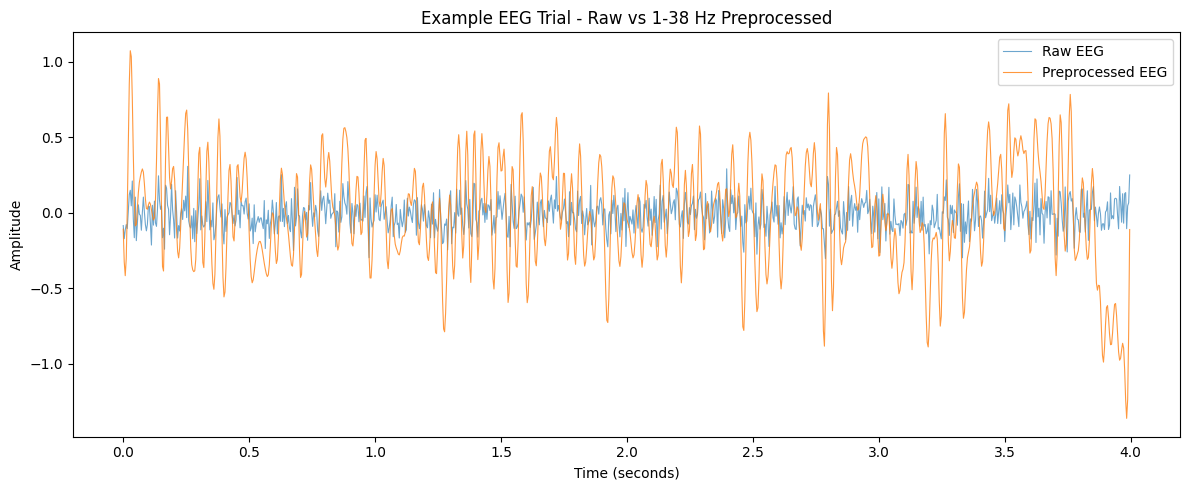


CELL 4 COMPLETED SUCCESSFULLY

Available variables for Cell 5:

preprocessor_demo
X_train_broad_demo
X_train_fb_demo
X_test_broad_demo
X_test_fb_demo
y_train_demo
y_test_demo

Main filter-bank tensor:
    X_train_fb_demo.shape = (48, 10, 22, 1000)

Expected format:
    (N, 10, 22, 1000)

Next: CELL 5 - OVR FBCSP + LASSO sparse spatial filter selection.


In [11]:
# ============================================================================
# CELL 4
# PREPROCESSING MODULE
#
# Zhang et al. (2023)
#
# Operations:
#
#   1. Replace NaN values
#   2. Fifth-order Butterworth 1-38 Hz bandpass
#   3. Training-only z-score normalization
#   4. Ten frequency-band decomposition
#
# Input:
#       X -> (N, 22, 1000)
#
# Output:
#       X_broad -> (N, 22, 1000)
#       X_fb    -> (N, 10, 22, 1000)
#
# IMPORTANT:
#
# The test/target subject must NEVER be used to calculate μ and σ.
#
# ============================================================================


print("=" * 90)
print("CELL 4 - PREPROCESSING MODULE")
print("=" * 90)

print(
    r"""
                        EEG PREPROCESSING
                              │
                              ▼
                     X = (N,22,1000)
                              │
                              ▼
                    ┌──────────────────┐
                    │ NaN replacement  │
                    └────────┬─────────┘
                             │
                             ▼
                 ┌─────────────────────────┐
                 │ Butterworth Bandpass    │
                 │ Order = 5               │
                 │ 1 Hz → 38 Hz            │
                 └────────────┬────────────┘
                              │
                              ▼
                         X_filtered
                              │
                              ▼
                  ┌────────────────────────┐
                  │ Training statistics    │
                  │                        │
                  │ μ_train                │
                  │ σ_train                │
                  └────────────┬───────────┘
                               │
                               ▼
                      X' = (X-μ)/σ
                               │
                               ▼
                  ┌────────────────────────┐
                  │ 10-band filter bank    │
                  └────────────┬───────────┘
                               │
       ┌────────┬───────┬──────┼──────┬────────┬────────┐
       ▼        ▼       ▼      ▼      ▼        ▼
     1-4      4-8     8-12   12-16  16-20    ... 35-38
       │        │       │      │      │        │
       └────────┴───────┴──────┴──────┴────────┘
                               │
                               ▼
                  X_FB = (N,10,22,1000)
"""
)


# ============================================================================
# 4.1 PREPROCESSOR CLASS
# ============================================================================

class EEGPreprocessor:
    """
    EEG preprocessing implementation based on the paper.

    Pipeline
    --------
    Raw EEG
        ↓
    NaN replacement
        ↓
    5th-order Butterworth 1-38 Hz
        ↓
    z-score using training-set statistics
        ↓
    10 sub-band filter-bank decomposition


    Parameters
    ----------
    fs:
        Sampling frequency.

    broad_band:
        Main preprocessing band, 1-38 Hz.

    bands:
        Ten sub-band definitions.

    order:
        Butterworth filter order.

    eps:
        Numerical stability constant.

    debug:
        Print tensor/array dimensions and statistics.
    """

    def __init__(
        self,
        fs: int = FS,
        broad_band: Tuple[float, float] = BROAD_BAND,
        bands: Sequence[
            Tuple[float, float]
        ] = BANDS,
        order: int = BUTTERWORTH_ORDER,
        eps: float = EPS,
        debug: bool = False,
    ):

        print()
        print("=" * 90)
        print("INITIALIZING EEG PREPROCESSOR")
        print("=" * 90)

        print(
            f"Sampling rate      : {fs} Hz"
        )

        print(
            f"Broad band         : "
            f"{broad_band[0]}-{broad_band[1]} Hz"
        )

        print(
            f"Butterworth order  : {order}"
        )

        print(
            f"Number of bands    : {len(bands)}"
        )

        # Store configuration
        self.fs = fs

        self.broad_band = (
            broad_band
        )

        self.bands = list(
            bands
        )

        self.order = order

        self.eps = eps

        self.debug = debug

        # Training statistics.
        #
        # These are NOT calculated until fit() is called.

        self.mu_: Optional[
            np.ndarray
        ] = None

        self.std_: Optional[
            np.ndarray
        ] = None

        # --------------------------------------------------------------------
        # Main Butterworth filter
        # --------------------------------------------------------------------

        self.broad_sos = (
            signal.butter(
                N=self.order,
                Wn=self.broad_band,
                btype="bandpass",
                fs=self.fs,
                output="sos",
            )
        )

        # --------------------------------------------------------------------
        # Individual filter-bank bands
        # --------------------------------------------------------------------

        self.band_sos: Dict[
            Tuple[float, float],
            np.ndarray,
        ] = {}

        for band in self.bands:

            self.band_sos[band] = (
                signal.butter(
                    N=self.order,
                    Wn=band,
                    btype="bandpass",
                    fs=self.fs,
                    output="sos",
                )
            )

        print(
            "Butterworth filters created successfully."
        )


    # ========================================================================
    # 4.2 NaN REPLACEMENT
    # ========================================================================

    def replace_nan(
        self,
        X: np.ndarray,
    ) -> np.ndarray:
        """
        Replace all non-finite values with the mean of valid sample points.

        The paper states that NaN values are replaced with the average
        of all sample points.
        """

        X = np.asarray(
            X,
            dtype=np.float32,
        ).copy()

        invalid_mask = (
            ~np.isfinite(X)
        )

        invalid_count = int(
            invalid_mask.sum()
        )

        if invalid_count == 0:

            if self.debug:

                print(
                    "[NaN] No NaN/Inf values detected."
                )

            return X

        # Mean of valid points.
        valid_values = X[
            np.isfinite(X)
        ]

        if len(valid_values) == 0:

            replacement_value = 0.0

        else:

            replacement_value = float(
                np.mean(valid_values)
            )

        X[
            invalid_mask
        ] = replacement_value

        print(
            f"[NaN] Replaced {invalid_count} "
            f"non-finite values with "
            f"{replacement_value:.8f}"
        )

        return X


    # ========================================================================
    # 4.3 BROAD-BAND FILTER
    # ========================================================================

    def apply_broad_filter(
        self,
        X: np.ndarray,
    ) -> np.ndarray:
        """
        Apply the fifth-order 1-38 Hz Butterworth filter.
        """

        if X.ndim != 3:

            raise ValueError(
                "Expected X with shape "
                "(N,22,1000). "
                f"Received {X.shape}"
            )

        filtered = (
            signal.sosfiltfilt(
                self.broad_sos,
                X,
                axis=-1,
            )
        )

        return filtered.astype(
            np.float32
        )


    # ========================================================================
    # 4.4 FIT TRAINING STATISTICS
    # ========================================================================

    def fit(
        self,
        X_train: np.ndarray,
    ):
        """
        Calculate training-set μ and σ.

        IMPORTANT:

        This method must be called using TRAINING DATA ONLY.

        The target/test subject must not enter this operation.
        """

        print()
        print("=" * 90)
        print("FITTING TRAINING Z-SCORE STATISTICS")
        print("=" * 90)

        # ------------------------------------------------------------
        # Replace NaNs
        # ------------------------------------------------------------

        X_clean = (
            self.replace_nan(
                X_train
            )
        )

        # ------------------------------------------------------------
        # Broad-band filter
        # ------------------------------------------------------------

        X_filtered = (
            self.apply_broad_filter(
                X_clean
            )
        )

        if self.debug:

            print_shape(
                "Filtered training EEG",
                X_filtered,
            )

        # ------------------------------------------------------------
        # Training statistics
        # ------------------------------------------------------------
        #
        # One global mean/std per EEG channel.
        #
        # Shape:
        #
        #       (1,22,1)
        #
        # This allows broadcasting over samples and time points.

        self.mu_ = (
            X_filtered.mean(
                axis=(0, 2),
                keepdims=True,
            )
        )

        self.std_ = (
            X_filtered.std(
                axis=(0, 2),
                keepdims=True,
            )
        )

        # Avoid division by zero.
        self.std_ = np.maximum(
            self.std_,
            self.eps,
        )

        print(
            f"Training μ shape : {self.mu_.shape}"
        )

        print(
            f"Training σ shape : {self.std_.shape}"
        )

        print(
            f"Mean μ           : "
            f"{float(self.mu_.mean()):.8f}"
        )

        print(
            f"Mean σ           : "
            f"{float(self.std_.mean()):.8f}"
        )

        return self


    # ========================================================================
    # 4.5 STANDARDIZE BROAD-BAND EEG
    # ========================================================================

    def transform_broad(
        self,
        X: np.ndarray,
    ) -> np.ndarray:
        """
        Apply:

            NaN replacement
                ↓
            1-38 Hz filtering
                ↓
            training z-score
        """

        if (
            self.mu_ is None
            or self.std_ is None
        ):

            raise RuntimeError(
                "Preprocessor has not been fitted.\n"
                "Call .fit(X_train) first."
            )

        X_clean = (
            self.replace_nan(
                X
            )
        )

        X_filtered = (
            self.apply_broad_filter(
                X_clean
            )
        )

        X_standardized = (
            X_filtered - self.mu_
        ) / self.std_

        if self.debug:

            print_shape(
                "Standardized EEG",
                X_standardized,
            )

            print(
                "Standardized mean:",
                float(
                    X_standardized.mean()
                ),
            )

            print(
                "Standardized std :",
                float(
                    X_standardized.std()
                ),
            )

        return X_standardized.astype(
            np.float32
        )


    # ========================================================================
    # 4.6 FILTER-BANK DECOMPOSITION
    # ========================================================================

    def transform_filter_bank(
        self,
        X: np.ndarray,
    ) -> np.ndarray:
        """
        Produce all 10 frequency-band representations.

        Output:

            (N,10,22,1000)
        """

        # First obtain training-statistics standardized EEG.
        X_standardized = (
            self.transform_broad(
                X
            )
        )

        band_outputs = []

        for band_index, band in enumerate(
            self.bands
        ):

            sos = (
                self.band_sos[
                    band
                ]
            )

            X_band = (
                signal.sosfiltfilt(
                    sos,
                    X_standardized,
                    axis=-1,
                )
            )

            X_band = (
                X_band.astype(
                    np.float32
                )
            )

            band_outputs.append(
                X_band
            )

            if self.debug:

                print(
                    f"Band {band_index + 1:02d} "
                    f"{band[0]:>5.1f}-{band[1]:<5.1f} Hz "
                    f"→ {X_band.shape}"
                )

        # Stack:
        #
        # Before:
        #     10 arrays of (N,22,1000)
        #
        # After:
        #     (N,10,22,1000)

        X_filter_bank = (
            np.stack(
                band_outputs,
                axis=1,
            )
        )

        if self.debug:

            print()
            print(
                "Final filter-bank shape:",
                X_filter_bank.shape,
            )

        return X_filter_bank.astype(
            np.float32
        )


    # ========================================================================
    # 4.7 FIT + TRANSFORM
    # ========================================================================

    def fit_transform(
        self,
        X_train: np.ndarray,
    ):
        """
        Fit training statistics and transform the training set.

        Returns:

            X_broad
            X_filter_bank
        """

        self.fit(
            X_train
        )

        X_broad = (
            self.transform_broad(
                X_train
            )
        )

        X_filter_bank = (
            self.transform_filter_bank(
                X_train
            )
        )

        return (
            X_broad,
            X_filter_bank,
        )


# ============================================================================
# 4.8 TRAIN/TEST PREPROCESSING HELPER
# ============================================================================

def preprocess_loso_split(
    X_train: np.ndarray,
    X_test: np.ndarray,
    debug: bool = False,
):
    """
    Preprocess one LOSO split correctly.

    IMPORTANT:

        fit() is performed ONLY on X_train.

        X_test is transformed using the training μ/σ.
    """

    print()
    print("=" * 90)
    print("PREPROCESSING LOSO SPLIT")
    print("=" * 90)

    print_shape(
        "Raw X_train",
        X_train,
    )

    print_shape(
        "Raw X_test",
        X_test,
    )

    # ------------------------------------------------------------
    # Create a NEW preprocessor for this LOSO fold.
    # ------------------------------------------------------------

    preprocessor = (
        EEGPreprocessor(
            debug=debug
        )
    )

    # ------------------------------------------------------------
    # FIT ONLY ON SOURCE/TRAINING SUBJECTS.
    # ------------------------------------------------------------

    preprocessor.fit(
        X_train
    )

    # ------------------------------------------------------------
    # Transform training data.
    # ------------------------------------------------------------

    X_train_broad = (
        preprocessor.transform_broad(
            X_train
        )
    )

    X_train_fb = (
        preprocessor.transform_filter_bank(
            X_train
        )
    )

    # ------------------------------------------------------------
    # Transform target/test data using SAME training statistics.
    # ------------------------------------------------------------

    X_test_broad = (
        preprocessor.transform_broad(
            X_test
        )
    )

    X_test_fb = (
        preprocessor.transform_filter_bank(
            X_test
        )
    )

    print()
    print("LOSO preprocessing complete.")

    print_shape(
        "X_train_broad",
        X_train_broad,
    )

    print_shape(
        "X_train_filterbank",
        X_train_fb,
    )

    print_shape(
        "X_test_broad",
        X_test_broad,
    )

    print_shape(
        "X_test_filterbank",
        X_test_fb,
    )

    return (
        preprocessor,
        X_train_broad,
        X_train_fb,
        X_test_broad,
        X_test_fb,
    )


# ============================================================================
# 4.9 RUN PREPROCESSING ON THE SYNTHETIC SMOKE DATA
# ============================================================================
#
# IMPORTANT:
#
# We have two synthetic subjects.
#
# Subject 1 -> training
# Subject 2 -> target/test
#
# This allows us to validate the exact LOSO preprocessing logic.

print()
print("=" * 90)
print("RUNNING CELL 4 SMOKE TEST")
print("=" * 90)

# ------------------------------------------------------------
# Subject split
# ------------------------------------------------------------

train_mask_demo = (
    subject_demo
    != 2
)

test_mask_demo = (
    subject_demo
    == 2
)

X_train_demo = (
    X_demo[
        train_mask_demo
    ]
)

y_train_demo = (
    y_demo[
        train_mask_demo
    ]
)

X_test_demo = (
    X_demo[
        test_mask_demo
    ]
)

y_test_demo = (
    y_demo[
        test_mask_demo
    ]
)

print(
    f"Training trials : {len(X_train_demo)}"
)

print(
    f"Testing trials  : {len(X_test_demo)}"
)

print(
    "Training labels :",
    np.bincount(
        y_train_demo,
        minlength=N_CLASSES,
    ),
)

print(
    "Testing labels  :",
    np.bincount(
        y_test_demo,
        minlength=N_CLASSES,
    ),
)

# ------------------------------------------------------------
# Run the LOSO preprocessing
# ------------------------------------------------------------

(
    preprocessor_demo,
    X_train_broad_demo,
    X_train_fb_demo,
    X_test_broad_demo,
    X_test_fb_demo,
) = preprocess_loso_split(
    X_train_demo,
    X_test_demo,
    debug=True,
)


# ============================================================================
# 4.10 VERIFY EXPECTED SHAPES
# ============================================================================

print()
print("=" * 90)
print("PREPROCESSING SHAPE TESTS")
print("=" * 90)

# Raw standardized EEG
assert (
    X_train_broad_demo.shape
    == (
        len(X_train_demo),
        N_CHANNELS,
        N_TIME,
    )
)

assert (
    X_test_broad_demo.shape
    == (
        len(X_test_demo),
        N_CHANNELS,
        N_TIME,
    )
)

# Filter-bank data
assert (
    X_train_fb_demo.shape
    == (
        len(X_train_demo),
        len(BANDS),
        N_CHANNELS,
        N_TIME,
    )
)

assert (
    X_test_fb_demo.shape
    == (
        len(X_test_demo),
        len(BANDS),
        N_CHANNELS,
        N_TIME,
    )
)

print(
    "✓ Training broad-band shape:",
    X_train_broad_demo.shape,
)

print(
    "✓ Training filter-bank shape:",
    X_train_fb_demo.shape,
)

print(
    "✓ Test broad-band shape:",
    X_test_broad_demo.shape,
)

print(
    "✓ Test filter-bank shape:",
    X_test_fb_demo.shape,
)


# ============================================================================
# 4.11 VERIFY TRAINING-ONLY STANDARDIZATION
# ============================================================================

print()
print("=" * 90)
print("TRAINING-ONLY NORMALIZATION CHECK")
print("=" * 90)

train_mean = float(
    X_train_broad_demo.mean()
)

train_std = float(
    X_train_broad_demo.std()
)

test_mean = float(
    X_test_broad_demo.mean()
)

test_std = float(
    X_test_broad_demo.std()
)

print(
    f"Training standardized mean : {train_mean:.8f}"
)

print(
    f"Training standardized std  : {train_std:.8f}"
)

print(
    f"Test standardized mean     : {test_mean:.8f}"
)

print(
    f"Test standardized std      : {test_std:.8f}"
)

# The training mean/std should be close to 0/1.
#
# The test set does NOT need to have exact mean=0,std=1 because its
# statistics were intentionally not used.

assert abs(
    train_mean
) < 1e-4

assert abs(
    train_std - 1.0
) < 1e-3

print()
print(
    "✓ Training data is approximately zero-mean / unit-variance."
)

print(
    "✓ Test data was transformed using TRAINING statistics only."
)


# ============================================================================
# 4.12 FILTER-BANK FREQUENCY SUMMARY
# ============================================================================

print()
print("=" * 90)
print("FILTER-BANK SUMMARY")
print("=" * 90)

for index, (
    low_freq,
    high_freq,
) in enumerate(
    BANDS,
    start=1,
):

    print(
        f"Band {index:02d}: "
        f"{low_freq:>5.1f} - "
        f"{high_freq:<5.1f} Hz"
    )


# ============================================================================
# 4.13 OPTIONAL QUICK VISUALIZATION
# ============================================================================
#
# This plot is intentionally lightweight.
#
# It shows one channel before/after broad preprocessing.

print()
print("=" * 90)
print("OPTIONAL QUICK EEG VISUALIZATION")
print("=" * 90)

sample_index = 0
channel_index = 10

time_axis = (
    np.arange(N_TIME)
    / FS
)

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    time_axis,
    X_train_demo[
        sample_index,
        channel_index,
    ],
    linewidth=0.8,
    alpha=0.65,
    label="Raw EEG",
)

plt.plot(
    time_axis,
    X_train_broad_demo[
        sample_index,
        channel_index,
    ],
    linewidth=0.8,
    alpha=0.80,
    label="Preprocessed EEG",
)

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "Amplitude"
)

plt.title(
    "Example EEG Trial - Raw vs 1-38 Hz Preprocessed"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================================
# 4.14 FINAL RESULTS
# ============================================================================

print()
print("=" * 90)
print("CELL 4 COMPLETED SUCCESSFULLY")
print("=" * 90)

print()
print("Available variables for Cell 5:")
print()
print(
    "preprocessor_demo"
)
print(
    "X_train_broad_demo"
)
print(
    "X_train_fb_demo"
)
print(
    "X_test_broad_demo"
)
print(
    "X_test_fb_demo"
)
print(
    "y_train_demo"
)
print(
    "y_test_demo"
)

print()
print(
    "Main filter-bank tensor:"
)

print(
    f"    X_train_fb_demo.shape = "
    f"{X_train_fb_demo.shape}"
)

print()
print(
    "Expected format:"
)

print(
    "    (N, 10, 22, 1000)"
)

print()
print(
    "Next: CELL 5 - OVR FBCSP + LASSO sparse spatial filter selection."
)

In [12]:
# ============================================================================
# CELL 5
# OVR-FBCSP + LASSO SPARSE FEATURE SELECTION
# ============================================================================
#
# Zhang et al. (2023)
#
# Pipeline:
#
#     X_FB = (N,10,22,1000)
#               │
#               ▼
#       OVR-CSP for each band
#               │
#               ▼
#     4 classes × 4 filters
#               │
#               ▼
#       16 filters / band
#               │
#               ▼
#      10 × 16 = 160
#        candidates
#               │
#               ▼
#       log-variance features
#               │
#               ▼
#            LASSO
#               │
#               ▼
#       sparse W_csp
#               │
#               ▼
#          dynamic Var
#
# IMPORTANT:
#
# This cell fits FBCSP + LASSO ONLY on the training data of the current
# LOSO split.
#
# Target/test subject data must not be used to fit the LASSO/CSP model.
#
# ============================================================================


print("=" * 90)
print("CELL 5 - OVR FBCSP + LASSO")
print("=" * 90)

print(
    r"""
                         FILTER BANK EEG
                       (N,10,22,1000)
                              │
          ┌───────────────────┼───────────────────┐
          │                   │                   │
       Band 1              Band 2             Band 10
       1-4 Hz              4-8 Hz             35-38 Hz
          │                   │                   │
          ▼                   ▼                   ▼
     OVR-CSP             OVR-CSP             OVR-CSP
          │                   │                   │
   ┌──────┼──────┐     ┌──────┼──────┐     ┌──────┼──────┐
   ▼      ▼      ▼     ▼      ▼      ▼     ...           ▼
 C0-v-R C1-v-R ...    C0-v-R C1-v-R ...               C3-v-R
   │      │            │      │                         │
   └──────┴────────────┴──────┴─────────────────────────┘
                           │
                           ▼
                  4 filters / OVR problem
                           │
                           ▼
              4 classes × 4 filters
                           │
                           ▼
                     16 / band
                           │
                           ▼
                  10 × 16 = 160
                 candidate filters
                           │
                           ▼
               log-variance features
                           │
                           ▼
                        LASSO
                           │
                 ┌─────────┴─────────┐
                 ▼                   ▼
          selected indices        W_csp
                 │                   │
                 └─────────┬─────────┘
                           ▼
                      sparse Var
"""
)


# ============================================================================
# 5.1 OVR FBCSP CLASS
# ============================================================================

class OVRFBCSPLasso:
    """
    One-versus-rest FBCSP followed by LASSO feature selection.

    Paper configuration:
        Number of bands          = 10
        Number of classes        = 4
        CSP filters / OVR        = 4
        Candidate dimensions     = 160

    Notes
    -----
    For each sub-band and class:

        Rc w = lambda Rrest w

    where:

        Rc     = mean normalized covariance of class c
        Rrest  = mean normalized covariance of all other classes

    Four largest eigenvalue solutions are retained.

    The resulting candidate CSP projections are converted into
    log-variance features.

    LASSO is then fitted to the candidate feature matrix.

    Non-zero coefficients define the sparse feature set.
    """

    def __init__(
        self,
        n_classes: int = N_CLASSES,
        m: int = CSP_M,
        random_state: int = SEED,
        lasso_cv: int = 5,
        debug: bool = False,
    ):

        print()
        print("=" * 90)
        print("INITIALIZING OVR FBCSP + LASSO")
        print("=" * 90)

        print(
            f"Classes               : {n_classes}"
        )

        print(
            f"CSP filters / OVR     : {m}"
        )

        print(
            f"Frequency bands       : {len(BANDS)}"
        )

        print(
            f"Candidate dimensions  : "
            f"{len(BANDS) * n_classes * m}"
        )

        self.n_classes = (
            n_classes
        )

        self.m = m

        self.random_state = (
            random_state
        )

        self.lasso_cv = (
            lasso_cv
        )

        self.debug = (
            debug
        )

        # --------------------------------------------------------------------
        # Learned CSP filters
        #
        # Shape:
        #
        #     (22,160)
        #
        # Each column is one spatial filter.
        # --------------------------------------------------------------------

        self.filters_: Optional[
            np.ndarray
        ] = None

        # Metadata for each CSP filter.
        #
        # Example:
        #
        # {
        #     "band_index": 0,
        #     "class": 0,
        #     "eigen_index": 0,
        # }
        #

        self.meta_: List[
            Dict
        ] = []

        # LASSO-selected feature indices.

        self.selected_idx_: Optional[
            np.ndarray
        ] = None

        # LASSO model

        self.lasso_model_: Optional[
            LassoCV
        ] = None

        # Feature scaler before LASSO

        self.feature_scaler_: Optional[
            StandardScaler
        ] = None


    # ========================================================================
    # 5.2 NORMALIZED COVARIANCE
    # ========================================================================

    @staticmethod
    def normalized_covariance(
        X: np.ndarray,
        eps: float = EPS,
    ) -> np.ndarray:
        """
        Compute:

                    X X^T
        R = -------------------
               tr(X X^T)

        Parameters
        ----------
        X:
            EEG trial with shape (22,1000).

        Returns
        -------
        R:
            Covariance-like normalized spatial matrix (22,22).
        """

        if X.ndim != 2:

            raise ValueError(
                "X must have shape "
                "(channels,time)."
            )

        covariance = (
            X @ X.T
        )

        trace = float(
            np.trace(
                covariance
            )
        )

        if trace < eps:

            trace = eps

        return (
            covariance
            / trace
        )


    # ========================================================================
    # 5.3 CLASS COVARIANCE
    # ========================================================================

    def compute_class_covariance(
        self,
        X_band: np.ndarray,
        y: np.ndarray,
        target_class: int,
    ) -> np.ndarray:
        """
        Compute the average normalized covariance for target class.
        """

        class_mask = (
            y == target_class
        )

        n_class = int(
            class_mask.sum()
        )

        if n_class < 2:

            raise ValueError(
                f"Class {target_class} contains only "
                f"{n_class} samples. "
                "At least 2 are required for CSP."
            )

        class_trials = (
            X_band[
                class_mask
            ]
        )

        covariance_matrices = []

        for trial in class_trials:

            covariance_matrices.append(
                self.normalized_covariance(
                    trial
                )
            )

        covariance_stack = (
            np.stack(
                covariance_matrices,
                axis=0,
            )
        )

        return covariance_stack.mean(
            axis=0
        )


    # ========================================================================
    # 5.4 REST COVARIANCE
    # ========================================================================

    def compute_rest_covariance(
        self,
        X_band: np.ndarray,
        y: np.ndarray,
        target_class: int,
    ) -> np.ndarray:
        """
        Compute average normalized covariance for all classes except
        target_class.
        """

        rest_mask = (
            y != target_class
        )

        n_rest = int(
            rest_mask.sum()
        )

        if n_rest < 2:

            raise ValueError(
                f"Not enough rest-class samples for class "
                f"{target_class}."
            )

        rest_trials = (
            X_band[
                rest_mask
            ]
        )

        covariance_matrices = []

        for trial in rest_trials:

            covariance_matrices.append(
                self.normalized_covariance(
                    trial
                )
            )

        covariance_stack = (
            np.stack(
                covariance_matrices,
                axis=0,
            )
        )

        return covariance_stack.mean(
            axis=0
        )


    # ========================================================================
    # 5.5 GENERALIZED EIGENVALUE CSP
    # ========================================================================

    def solve_csp(
        self,
        Rc: np.ndarray,
        Rrest: np.ndarray,
    ) -> Tuple[
        np.ndarray,
        np.ndarray,
    ]:
        """
        Solve:

            Rc w = lambda Rrest w

        and return eigenvalues/eigenvectors sorted by descending
        eigenvalue.

        Numerical regularization is added for stability.
        """

        channels = (
            Rc.shape[0]
        )

        if Rc.shape != (
            channels,
            channels,
        ):

            raise ValueError(
                "Rc must be square."
            )

        if Rrest.shape != (
            channels,
            channels,
        ):

            raise ValueError(
                "Rrest must have same square shape as Rc."
            )

        # Numerical diagonal regularization.
        regularization = (
            1e-8
            * np.eye(
                channels
            )
        )

        Rc_reg = (
            Rc
            + regularization
        )

        Rrest_reg = (
            Rrest
            + regularization
        )

        # SciPy generalized symmetric eigenvalue problem.
        eigenvalues, eigenvectors = (
            linalg.eigh(
                Rc_reg,
                Rrest_reg,
            )
        )

        # Descending eigenvalue order.
        order = np.argsort(
            eigenvalues
        )[::-1]

        eigenvalues = (
            eigenvalues[
                order
            ]
        )

        eigenvectors = (
            eigenvectors[
                :,
                order
            ]
        )

        return (
            eigenvalues,
            eigenvectors,
        )


    # ========================================================================
    # 5.6 FIT FBCSP
    # ========================================================================

    def fit_fbcsp(
        self,
        X_fb: np.ndarray,
        y: np.ndarray,
    ):
        """
        Fit all:

            10 bands × 4 OVR classes × 4 filters.

        Parameters
        ----------
        X_fb:
            Shape (N,10,22,1000)

        y:
            Shape (N,)
        """

        print()
        print("=" * 90)
        print("FITTING OVR FBCSP")
        print("=" * 90)

        # --------------------------------------------------------------------
        # Validation
        # --------------------------------------------------------------------

        if X_fb.ndim != 4:

            raise ValueError(
                "Expected filter-bank EEG with shape "
                "(N,10,22,1000). "
                f"Received {X_fb.shape}"
            )

        if X_fb.shape[1] != len(
            BANDS
        ):

            raise ValueError(
                "Unexpected number of frequency bands."
            )

        if X_fb.shape[2] != (
            N_CHANNELS
        ):

            raise ValueError(
                "Unexpected number of EEG channels."
            )

        if X_fb.shape[3] != (
            N_TIME
        ):

            raise ValueError(
                "Unexpected number of time points."
            )

        y = np.asarray(
            y,
            dtype=np.int64,
        )

        if len(y) != len(
            X_fb
        ):

            raise ValueError(
                "Number of labels does not match number of trials."
            )

        # --------------------------------------------------------------------
        # Storage
        # --------------------------------------------------------------------

        filters = []

        metadata = []

        # --------------------------------------------------------------------
        # Main nested loop
        # --------------------------------------------------------------------
        #
        # For each band:
        #
        #     class 0 vs rest
        #     class 1 vs rest
        #     class 2 vs rest
        #     class 3 vs rest
        #
        # Four filters are retained from each.
        #
        # --------------------------------------------------------------------

        for band_index in range(
            X_fb.shape[1]
        ):

            X_band = (
                X_fb[
                    :,
                    band_index,
                    :,
                    :
                ]
            )

            if self.debug:

                print()
                print(
                    f"Band {band_index + 1}/{len(BANDS)} "
                    f"{BANDS[band_index][0]}-"
                    f"{BANDS[band_index][1]} Hz"
                )

            for target_class in range(
                self.n_classes
            ):

                # ------------------------------------------------------------
                # Class covariance
                # ------------------------------------------------------------

                Rc = (
                    self.compute_class_covariance(
                        X_band,
                        y,
                        target_class,
                    )
                )

                # ------------------------------------------------------------
                # Rest covariance
                # ------------------------------------------------------------

                Rrest = (
                    self.compute_rest_covariance(
                        X_band,
                        y,
                        target_class,
                    )
                )

                # ------------------------------------------------------------
                # Generalized eigenvalue decomposition
                # ------------------------------------------------------------

                eigenvalues, eigenvectors = (
                    self.solve_csp(
                        Rc,
                        Rrest,
                    )
                )

                # ------------------------------------------------------------
                # Select top m filters
                # ------------------------------------------------------------

                selected_columns = (
                    eigenvectors[
                        :,
                        :self.m
                    ]
                )

                selected_values = (
                    eigenvalues[
                        :self.m
                    ]
                )

                if self.debug:

                    print(
                        f"  Class {target_class}: "
                        f"top eigenvalues = "
                        f"{np.round(selected_values, 4)}"
                    )

                # ------------------------------------------------------------
                # Store each filter
                # ------------------------------------------------------------

                for eigen_index in range(
                    self.m
                ):

                    filters.append(
                        selected_columns[
                            :,
                            eigen_index
                        ]
                    )

                    metadata.append(
                        {
                            "band_index": band_index,
                            "band": BANDS[
                                band_index
                            ],
                            "class": target_class,
                            "eigen_index": eigen_index,
                            "eigenvalue": float(
                                selected_values[
                                    eigen_index
                                ]
                            ),
                        }
                    )

        # --------------------------------------------------------------------
        # Convert list → matrix
        #
        # Shape:
        #
        #     (22,160)
        # --------------------------------------------------------------------

        W_all = np.stack(
            filters,
            axis=1,
        )

        if W_all.shape != (
            N_CHANNELS,
            N_CSP_CANDIDATES,
        ):

            raise RuntimeError(
                "Unexpected CSP filter matrix shape.\n"
                f"Expected: "
                f"({N_CHANNELS},{N_CSP_CANDIDATES})\n"
                f"Received: {W_all.shape}"
            )

        self.filters_ = (
            W_all.astype(
                np.float64
            )
        )

        self.meta_ = (
            metadata
        )

        print()
        print(
            "FBCSP complete."
        )

        print(
            f"W_csp candidate shape: "
            f"{self.filters_.shape}"
        )

        print(
            f"Total candidate filters: "
            f"{len(self.meta_)}"
        )

        return self


    # ========================================================================
    # 5.7 EXTRACT CANDIDATE LOG-VARIANCE FEATURES
    # ========================================================================

    def extract_candidate_features(
        self,
        X_fb: np.ndarray,
    ) -> np.ndarray:
        """
        Convert the 160 CSP projections into log-variance features.

        Output:
            F -> (N,160)
        """

        if self.filters_ is None:

            raise RuntimeError(
                "FBCSP has not been fitted."
            )

        if X_fb.ndim != 4:

            raise ValueError(
                "Expected X_fb shape "
                "(N,10,22,1000)."
            )

        n_trials = (
            X_fb.shape[0]
        )

        n_features = (
            len(self.meta_)
        )

        features = np.empty(
            (
                n_trials,
                n_features,
            ),
            dtype=np.float64,
        )

        # ------------------------------------------------------------
        # Each feature corresponds to one selected CSP filter and
        # one associated frequency band.
        # ------------------------------------------------------------

        for trial_index in range(
            n_trials
        ):

            for feature_index, metadata in enumerate(
                self.meta_
            ):

                band_index = (
                    metadata[
                        "band_index"
                    ]
                )

                W = (
                    self.filters_[
                        :,
                        feature_index
                    ]
                )

                X_band_trial = (
                    X_fb[
                        trial_index,
                        band_index,
                        :,
                        :
                    ]
                )

                # Spatial projection
                Z = (
                    W.T
                    @ X_band_trial
                )

                # Variance of projected signal
                variance = float(
                    np.var(
                        Z
                    )
                )

                variance = max(
                    variance,
                    EPS,
                )

                # Log-variance CSP feature
                features[
                    trial_index,
                    feature_index
                ] = np.log(
                    variance
                )

        if self.debug:

            print_shape(
                "Candidate CSP features",
                features,
            )

        return features


    # ========================================================================
    # 5.8 FIT LASSO
    # ========================================================================

    def fit_lasso(
        self,
        candidate_features: np.ndarray,
        y: np.ndarray,
    ):
        """
        Fit scalar LASSO regression to the 160-dimensional candidate feature
        matrix.

        The paper formulates feature selection using L1-penalized regression.

        Standardization is applied to the candidate feature matrix before
        LASSO so coefficients are comparable across dimensions.
        """

        print()
        print("=" * 90)
        print("FITTING LASSO FEATURE SELECTION")
        print("=" * 90)

        candidate_features = (
            np.asarray(
                candidate_features,
                dtype=np.float64,
            )
        )

        y = np.asarray(
            y,
            dtype=np.float64,
        ).reshape(-1)

        if candidate_features.ndim != 2:

            raise ValueError(
                "candidate_features must be 2-D."
            )

        if len(candidate_features) != len(
            y
        ):

            raise ValueError(
                "Feature count and label count differ."
            )

        # ------------------------------------------------------------
        # Feature standardization before LASSO
        # ------------------------------------------------------------

        scaler = (
            StandardScaler()
        )

        F_scaled = (
            scaler.fit_transform(
                candidate_features
            )
        )

        # ------------------------------------------------------------
        # Robust CV folds
        # ------------------------------------------------------------
        #
        # At least 2 folds and at most 5.
        #
        # The smallest class is used as a practical upper bound.
        # ------------------------------------------------------------

        class_counts = (
            np.bincount(
                y.astype(
                    np.int64
                ),
                minlength=self.n_classes,
            )
        )

        min_class_count = int(
            class_counts[
                class_counts > 0
            ].min()
        )

        cv = max(
            2,
            min(
                self.lasso_cv,
                min_class_count,
            ),
        )

        print(
            f"LASSO CV folds: {cv}"
        )

        # ------------------------------------------------------------
        # LASSO
        # ------------------------------------------------------------
        #
        # We use scalar regression matching the paper's formulation.
        #
        # ------------------------------------------------------------

        lasso = LassoCV(
            cv=cv,
            random_state=self.random_state,
            max_iter=10000,
            n_jobs=None,
        )

        lasso.fit(
            F_scaled,
            y,
        )

        coefficients = (
            np.asarray(
                lasso.coef_
            )
        )

        absolute_coefficients = (
            np.abs(
                coefficients
            )
        )

        # ------------------------------------------------------------
        # Non-zero coefficient selection
        # ------------------------------------------------------------

        selected = np.flatnonzero(
            absolute_coefficients
            > 1e-8
        )

        # ------------------------------------------------------------
        # Degenerate case:
        #
        # On very small synthetic smoke data LASSO may legitimately shrink
        # all coefficients to zero.
        #
        # We need at least 4 dimensions for the downstream sparse filter
        # discriminator. Therefore a smoke-test fallback is included.
        #
        # This is only a safety mechanism for tiny test data.
        # For the real dataset, the LASSO solution is used directly.
        # ------------------------------------------------------------

        if len(selected) == 0:

            warnings.warn(
                "LASSO selected zero features. "
                "Using a smoke-test fallback based on "
                "feature/label absolute correlation."
            )

            correlations = np.zeros(
                candidate_features.shape[1]
            )

            y_centered = (
                y
                - np.mean(y)
            )

            for index in range(
                candidate_features.shape[1]
            ):

                feature = (
                    F_scaled[
                        :,
                        index
                    ]
                )

                feature_centered = (
                    feature
                    - np.mean(feature)
                )

                numerator = abs(
                    np.sum(
                        feature_centered
                        * y_centered
                    )
                )

                denominator = (
                    np.sqrt(
                        np.sum(
                            feature_centered ** 2
                        )
                    )
                    *
                    np.sqrt(
                        np.sum(
                            y_centered ** 2
                        )
                    )
                    + EPS
                )

                correlations[
                    index
                ] = (
                    numerator
                    / denominator
                )

            fallback_count = max(
                self.m,
                4,
            )

            selected = np.argsort(
                correlations
            )[
                -fallback_count:
            ]

            selected = np.sort(
                selected
            )

            print(
                f"Fallback selected "
                f"{len(selected)} features."
            )

        # ------------------------------------------------------------
        # Store learned LASSO state
        # ------------------------------------------------------------

        self.feature_scaler_ = (
            scaler
        )

        self.lasso_model_ = (
            lasso
        )

        self.selected_idx_ = (
            np.asarray(
                selected,
                dtype=np.int64,
            )
        )

        print()
        print(
            f"Total candidate features : "
            f"{candidate_features.shape[1]}"
        )

        print(
            f"LASSO selected features  : "
            f"{len(self.selected_idx_)}"
        )

        print(
            f"LASSO alpha              : "
            f"{float(lasso.alpha_):.8f}"
        )

        # ------------------------------------------------------------
        # Print selected features
        # ------------------------------------------------------------

        print()
        print(
            "Selected feature mapping:"
        )

        for local_index, global_index in enumerate(
            self.selected_idx_
        ):

            metadata = (
                self.meta_[
                    int(
                        global_index
                    )
                ]
            )

            print(
                f"  sparse #{local_index:03d} "
                f"← candidate #{global_index:03d} | "
                f"band={metadata['band'][0]:.1f}-"
                f"{metadata['band'][1]:.1f} Hz | "
                f"class={metadata['class']} | "
                f"eig={metadata['eigen_index']}"
            )

        return self


    # ========================================================================
    # 5.9 COMPLETE FIT
    # ========================================================================

    def fit(
        self,
        X_fb: np.ndarray,
        y: np.ndarray,
    ):
        """
        Run:

            FBCSP
              ↓
            candidate feature extraction
              ↓
            LASSO
        """

        self.fit_fbcsp(
            X_fb,
            y,
        )

        candidate_features = (
            self.extract_candidate_features(
                X_fb
            )
        )

        self.fit_lasso(
            candidate_features,
            y,
        )

        return self


    # ========================================================================
    # 5.10 TRANSFORM CANDIDATE FEATURES
    # ========================================================================

    def transform_candidate_features(
        self,
        X_fb: np.ndarray,
    ) -> np.ndarray:
        """
        Return the selected log-variance features.
        """

        if (
            self.filters_ is None
            or self.selected_idx_ is None
        ):

            raise RuntimeError(
                "FBCSP + LASSO model has not been fitted."
            )

        candidate_features = (
            self.extract_candidate_features(
                X_fb
            )
        )

        return candidate_features[
            :,
            self.selected_idx_
        ].astype(
            np.float32
        )


    # ========================================================================
    # 5.11 SPARSE FILTER BANK PROJECTION
    # ========================================================================

    def transform_sparse_fb(
        self,
        X_fb: np.ndarray,
    ) -> np.ndarray:
        """
        Apply the sparse spatial filters to their associated frequency bands.

        For selected feature k:

            Z_k = W_k^T X_band(k)

        Output:

            (N,1,Var,1000)

        where:

            Var = number of LASSO-selected filters.
        """

        if (
            self.filters_ is None
            or self.selected_idx_ is None
        ):

            raise RuntimeError(
                "FBCSP + LASSO model has not been fitted."
            )

        selected_indices = (
            self.selected_idx_
        )

        projected_features = []

        for global_index in (
            selected_indices
        ):

            metadata = (
                self.meta_[
                    int(
                        global_index
                    )
                ]
            )

            band_index = (
                metadata[
                    "band_index"
                ]
            )

            W = (
                self.filters_[
                    :,
                    int(
                        global_index
                    )
                ]
            )

            X_band = (
                X_fb[
                    :,
                    band_index,
                    :,
                    :
                ]
            )

            # N,C,T × C → N,T
            projected = (
                np.einsum(
                    "c,nct->nt",
                    W,
                    X_band,
                )
            )

            projected_features.append(
                projected
            )

        if len(
            projected_features
        ) == 0:

            raise RuntimeError(
                "No sparse filters were selected."
            )

        # N,Var,T
        Z = np.stack(
            projected_features,
            axis=1,
        )

        # Dψ expects:
        #
        # N,1,Var,T

        Z = Z[
            :,
            None,
            :,
            :,
        ]

        return Z.astype(
            np.float32
        )


    # ========================================================================
    # 5.12 DYNAMIC VAR PROPERTY
    # ========================================================================

    @property
    def var_(self) -> int:
        """
        Number of sparse LASSO-selected spatial filters.
        """

        if self.selected_idx_ is None:

            return 0

        return int(
            len(
                self.selected_idx_
            )
        )


# ============================================================================
# 5.13 RUN FBCSP + LASSO ON THE SMOKE TRAINING DATA
# ============================================================================
#
# IMPORTANT:
#
# We use ONLY:
#
#     X_train_fb_demo
#     y_train_demo
#
# not X_test_fb_demo/y_test_demo.
#
# This preserves the LOSO principle.
#
# ============================================================================

print()
print("=" * 90)
print("RUNNING FBCSP + LASSO SMOKE TEST")
print("=" * 90)

fbcsp_demo = (
    OVRFBCSPLasso(
        n_classes=N_CLASSES,
        m=CSP_M,
        random_state=SEED,
        debug=False,
    )
)

# Fit ONLY on training data.
fbcsp_demo.fit(
    X_train_fb_demo,
    y_train_demo,
)


# ============================================================================
# 5.14 TRANSFORM TRAINING FEATURES
# ============================================================================

train_sparse_features_demo = (
    fbcsp_demo.transform_candidate_features(
        X_train_fb_demo
    )
)

print()
print(
    "Selected sparse feature matrix:"
)

print_shape(
    "train_sparse_features_demo",
    train_sparse_features_demo,
)


# ============================================================================
# 5.15 TRANSFORM TEST FEATURES
# ============================================================================
#
# IMPORTANT:
#
# This uses the already fitted W_csp and LASSO selection.
#
# No fitting occurs here.

test_sparse_features_demo = (
    fbcsp_demo.transform_candidate_features(
        X_test_fb_demo
    )
)

print_shape(
    "test_sparse_features_demo",
    test_sparse_features_demo,
)


# ============================================================================
# 5.16 SPARSE FILTER BANK OUTPUT
# ============================================================================

Z_train_demo = (
    fbcsp_demo.transform_sparse_fb(
        X_train_fb_demo
    )
)

Z_test_demo = (
    fbcsp_demo.transform_sparse_fb(
        X_test_fb_demo
    )
)

print()
print(
    "Sparse spatial-filtered representation:"
)

print_shape(
    "Z_train_demo",
    Z_train_demo,
)

print_shape(
    "Z_test_demo",
    Z_test_demo,
)


# ============================================================================
# 5.17 EXPECTED SHAPE CHECKS
# ============================================================================

print()
print("=" * 90)
print("FBCSP/LASSO SHAPE TESTS")
print("=" * 90)

# Candidate filters
assert (
    fbcsp_demo.filters_.shape
    == (
        N_CHANNELS,
        N_CSP_CANDIDATES,
    )
)

print(
    "✓ Candidate spatial filter matrix:",
    fbcsp_demo.filters_.shape,
)

# Candidate feature count
candidate_demo = (
    fbcsp_demo.extract_candidate_features(
        X_train_fb_demo
    )
)

assert (
    candidate_demo.shape
    == (
        len(
            X_train_fb_demo
        ),
        N_CSP_CANDIDATES,
    )
)

print(
    "✓ Candidate feature matrix:",
    candidate_demo.shape,
)

# Selected feature count
assert (
    train_sparse_features_demo.shape[0]
    == len(
        X_train_fb_demo
    )
)

assert (
    train_sparse_features_demo.shape[1]
    == fbcsp_demo.var_
)

assert (
    test_sparse_features_demo.shape[1]
    == fbcsp_demo.var_
)

print(
    "✓ Sparse feature dimension:",
    fbcsp_demo.var_,
)

# Sparse FB shape
assert (
    Z_train_demo.shape
    == (
        len(
            X_train_fb_demo
        ),
        1,
        fbcsp_demo.var_,
        N_TIME,
    )
)

assert (
    Z_test_demo.shape
    == (
        len(
            X_test_fb_demo
        ),
        1,
        fbcsp_demo.var_,
        N_TIME,
    )
)

print(
    "✓ Sparse FB train shape:",
    Z_train_demo.shape,
)

print(
    "✓ Sparse FB test shape:",
    Z_test_demo.shape,
)


# ============================================================================
# 5.18 DISPLAY CSP/LASSO SUMMARY
# ============================================================================

print()
print("=" * 90)
print("FBCSP + LASSO SUMMARY")
print("=" * 90)

print(
    f"Number of frequency bands : {len(BANDS)}"
)

print(
    f"OVR classes                : {N_CLASSES}"
)

print(
    f"Filters / OVR problem     : {CSP_M}"
)

print(
    "Candidate dimensions      : "
    f"{N_CSP_CANDIDATES}"
)

print(
    "Selected sparse filters   : "
    f"{fbcsp_demo.var_}"
)

print(
    "Dynamic Var               : "
    f"{fbcsp_demo.var_}"
)

print()
print(
    "Candidate filter matrix:"
)

print(
    "    W_candidate.shape =",
    fbcsp_demo.filters_.shape,
)

print()
print(
    "Sparse discriminator input:"
)

print(
    "    Z_train.shape =",
    Z_train_demo.shape,
)


# ============================================================================
# 5.19 OPTIONAL VISUALIZATION OF SELECTED BANDS
# ============================================================================

print()
print("=" * 90)
print("SELECTED LASSO FREQUENCY BANDS")
print("=" * 90)

selected_band_indices = [
    fbcsp_demo.meta_[
        int(
            index
        )
    ]["band_index"]
    for index in fbcsp_demo.selected_idx_
]

selected_bands = sorted(
    set(
        selected_band_indices
    )
)

for band_index in selected_bands:

    low_freq, high_freq = (
        BANDS[
            band_index
        ]
    )

    count = selected_band_indices.count(
        band_index
    )

    print(
        f"Band {band_index + 1:02d}: "
        f"{low_freq:.1f}-{high_freq:.1f} Hz "
        f"→ {count} selected filter(s)"
    )


# ============================================================================
# 5.20 CELL COMPLETION
# ============================================================================

print()
print("=" * 90)
print("CELL 5 COMPLETED SUCCESSFULLY")
print("=" * 90)

print()
print(
    "Variables available for CELL 6:"
)

print(
    "    fbcsp_demo"
)

print(
    "    Z_train_demo"
)

print(
    "    Z_test_demo"
)

print(
    "    X_train_broad_demo"
)

print(
    "    X_test_broad_demo"
)

print()
print(
    "Important:"
)

print(
    f"    Dynamic Var = {fbcsp_demo.var_}"
)

print()
print(
    "Next: CELL 6 - FBGAN Generator + Dφ + Dψ + "
    "MPS-safe adversarial training."
)

CELL 5 - OVR FBCSP + LASSO

                         FILTER BANK EEG
                       (N,10,22,1000)
                              │
          ┌───────────────────┼───────────────────┐
          │                   │                   │
       Band 1              Band 2             Band 10
       1-4 Hz              4-8 Hz             35-38 Hz
          │                   │                   │
          ▼                   ▼                   ▼
     OVR-CSP             OVR-CSP             OVR-CSP
          │                   │                   │
   ┌──────┼──────┐     ┌──────┼──────┐     ┌──────┼──────┐
   ▼      ▼      ▼     ▼      ▼      ▼     ...           ▼
 C0-v-R C1-v-R ...    C0-v-R C1-v-R ...               C3-v-R
   │      │            │      │                         │
   └──────┴────────────┴──────┴─────────────────────────┘
                           │
                           ▼
                  4 filters / OVR problem
                           │
               

In [13]:
# ============================================================================
# CELL 6
# FBGAN
#
# Zhang et al. (2023)
#
# Components:
#
#   1. Generator G_theta
#   2. Raw EEG discriminator D_phi
#   3. Sparse filter-bank discriminator D_psi
#   4. Differentiable sparse CSP projector
#   5. Adversarial training
#
# Apple M4 / MPS SAFE
#
# IMPORTANT:
#
# This implementation deliberately DOES NOT use:
#
#     F.adaptive_avg_pool2d(...)
#
# because non-divisible adaptive pooling can fail on Apple MPS.
#
# Instead, F.interpolate(...) is used only as a non-trainable shape adapter
# for the published 750-dimensional discriminator FC interface.
#
# ============================================================================


print("=" * 90)
print("CELL 6 - FBGAN")
print("=" * 90)

print(
    r"""
                         FBGAN
                           │
              z ~ N(0,I), z=(B,1600)
                           │
                           ▼
                 ┌──────────────────┐
                 │ Generator Gθ     │
                 │ FC 1600→256000   │
                 └────────┬─────────┘
                          │
                          ▼
                 ConvTranspose stack
                          │
                          ▼
                   Fake EEG
                 (B,1,22,1000)
                          │
             ┌────────────┴────────────┐
             │                         │
             ▼                         ▼
          Dφ raw EEG             W_csp projector
             │                         │
             │                         ▼
             │                   Sparse FB EEG
             │                  (B,1,Var,1000)
             │                         │
             │                         ▼
             │                        Dψ
             │                         │
             └────────────┬────────────┘
                          ▼
                  adversarial loss

Real EEG ───────────────► Dφ
Real EEG ─► W_csp ──────► Dψ

Generator learns to fool BOTH discriminators.
"""
)


# ============================================================================
# 6.1 FBGAN GENERATOR
# ============================================================================

class FBGANGenerator(nn.Module):
    """
    FBGAN generator.

    Paper configuration:

        Input:
            z = 1600

        FC:
            1600 -> 256000

        ConvTranspose 1:
            128 -> 128
            kernel=(3,15)
            stride=(1,3)
            BatchNorm
            LeakyReLU

        ConvTranspose 2:
            128 -> 128
            kernel=(3,15)
            stride=(1,3)
            BatchNorm
            LeakyReLU

        ConvTranspose 3:
            128 -> 64
            kernel=(3,5)
            stride=(1,2)
            BatchNorm
            LeakyReLU

        ConvTranspose 4:
            64 -> 32
            kernel=(4,5)
            stride=(2,1)
            BatchNorm
            LeakyReLU

        ConvTranspose 5:
            32 -> 1
            kernel=(1,2)
            stride=(1,1)
            Tanh

    The paper does not fully specify the initial reshape/padding geometry.
    Therefore the learnable layers preserve the published specification,
    followed by a non-learnable interpolation to exactly (22,1000).
    """

    def __init__(
        self,
        latent_dim: int = GAN_LATENT_DIM,
        debug: bool = False,
    ):

        super().__init__()

        print()
        print("=" * 90)
        print("FBGAN GENERATOR G_theta")
        print("=" * 90)

        print(
            r"""
z
(B,1600)
   │
   ▼
FC
1600 → 256000
   │
   ▼
reshape
(B,128,20,100)
   │
   ▼
ConvTrans1
128 → 128
k=(3,15), s=(1,3)
BatchNorm + LeakyReLU
   │
   ▼
ConvTrans2
128 → 128
k=(3,15), s=(1,3)
BatchNorm + LeakyReLU
   │
   ▼
ConvTrans3
128 → 64
k=(3,5), s=(1,2)
BatchNorm + LeakyReLU
   │
   ▼
ConvTrans4
64 → 32
k=(4,5), s=(2,1)
BatchNorm + LeakyReLU
   │
   ▼
ConvTrans5
32 → 1
k=(1,2), s=(1,1)
Tanh
   │
   ▼
MPS-safe resize
   │
   ▼
(B,1,22,1000)
"""
        )

        self.latent_dim = (
            latent_dim
        )

        self.debug = (
            debug
        )

        self.tracker = (
            ShapeTracker(
                debug=debug,
                name="G_theta",
            )
        )

        # --------------------------------------------------------------------
        # Fully-connected layer
        # --------------------------------------------------------------------

        self.fc = nn.Linear(
            latent_dim,
            256000,
        )

        # --------------------------------------------------------------------
        # Initial tensor:
        #
        # 128 × 20 × 100
        #
        # 128 × 20 × 100 = 256000
        # --------------------------------------------------------------------

        self.initial_channels = 128
        self.initial_height = 20
        self.initial_width = 100

        # --------------------------------------------------------------------
        # Published transposed convolution stack
        # --------------------------------------------------------------------

        self.deconv1 = nn.ConvTranspose2d(
            in_channels=128,
            out_channels=128,
            kernel_size=(3, 15),
            stride=(1, 3),
        )

        self.bn1 = nn.BatchNorm2d(
            128
        )

        self.deconv2 = nn.ConvTranspose2d(
            in_channels=128,
            out_channels=128,
            kernel_size=(3, 15),
            stride=(1, 3),
        )

        self.bn2 = nn.BatchNorm2d(
            128
        )

        self.deconv3 = nn.ConvTranspose2d(
            in_channels=128,
            out_channels=64,
            kernel_size=(3, 5),
            stride=(1, 2),
        )

        self.bn3 = nn.BatchNorm2d(
            64
        )

        self.deconv4 = nn.ConvTranspose2d(
            in_channels=64,
            out_channels=32,
            kernel_size=(4, 5),
            stride=(2, 1),
        )

        self.bn4 = nn.BatchNorm2d(
            32
        )

        self.deconv5 = nn.ConvTranspose2d(
            in_channels=32,
            out_channels=1,
            kernel_size=(1, 2),
            stride=(1, 1),
        )

        self.activation = nn.LeakyReLU(
            negative_slope=0.2,
            inplace=True,
        )

        self.output_activation = nn.Tanh()


    def forward(
        self,
        z: torch.Tensor,
    ) -> torch.Tensor:

        self.tracker(
            "latent z",
            z,
        )

        if z.ndim != 2:

            raise ValueError(
                "Generator input must have shape "
                "(B,1600). "
                f"Received {tuple(z.shape)}"
            )

        if z.shape[1] != self.latent_dim:

            raise ValueError(
                f"Expected latent dimension "
                f"{self.latent_dim}, "
                f"received {z.shape[1]}"
            )

        # --------------------------------------------------------------------
        # FC
        # --------------------------------------------------------------------

        x = self.fc(
            z
        )

        self.tracker(
            "after FC",
            x,
        )

        # --------------------------------------------------------------------
        # Reshape
        # --------------------------------------------------------------------

        x = x.view(
            z.shape[0],
            self.initial_channels,
            self.initial_height,
            self.initial_width,
        )

        self.tracker(
            "after reshape",
            x,
        )

        # --------------------------------------------------------------------
        # ConvTranspose 1
        # --------------------------------------------------------------------

        x = self.deconv1(
            x
        )

        x = self.bn1(
            x
        )

        x = self.activation(
            x
        )

        self.tracker(
            "ConvTrans1",
            x,
        )

        # --------------------------------------------------------------------
        # ConvTranspose 2
        # --------------------------------------------------------------------

        x = self.deconv2(
            x
        )

        x = self.bn2(
            x
        )

        x = self.activation(
            x
        )

        self.tracker(
            "ConvTrans2",
            x,
        )

        # --------------------------------------------------------------------
        # ConvTranspose 3
        # --------------------------------------------------------------------

        x = self.deconv3(
            x
        )

        x = self.bn3(
            x
        )

        x = self.activation(
            x
        )

        self.tracker(
            "ConvTrans3",
            x,
        )

        # --------------------------------------------------------------------
        # ConvTranspose 4
        # --------------------------------------------------------------------

        x = self.deconv4(
            x
        )

        x = self.bn4(
            x
        )

        x = self.activation(
            x
        )

        self.tracker(
            "ConvTrans4",
            x,
        )

        # --------------------------------------------------------------------
        # ConvTranspose 5
        # --------------------------------------------------------------------

        x = self.deconv5(
            x
        )

        x = self.output_activation(
            x
        )

        self.tracker(
            "ConvTrans5",
            x,
        )

        # --------------------------------------------------------------------
        # MPS-safe target shape adapter
        #
        # Target:
        #
        #     (B,1,22,1000)
        #
        # This is NOT a trainable layer.
        # --------------------------------------------------------------------

        x = mps_safe_resize_2d(
            x,
            height=N_CHANNELS,
            width=N_TIME,
        )

        self.tracker(
            "final EEG",
            x,
        )

        return x


# ============================================================================
# 6.2 BASE DISCRIMINATOR UTILITY
# ============================================================================

class DiscriminatorShapeAdapter(
    nn.Module
):
    """
    Non-trainable shape adapter.

    The paper states a 750-dimensional FC input for both discriminators.

    Since the exact padding/reshape geometry is not fully given, the
    convolution stack is followed by:

        (B,30,H,W)
               ↓
        resize to (1,25)
               ↓
        flatten
               ↓
        30 × 1 × 25 = 750

    We use interpolation instead of adaptive pooling for Apple MPS safety.
    """

    @staticmethod
    def resize_to_750(
        x: torch.Tensor,
    ) -> torch.Tensor:

        if x.ndim != 4:

            raise ValueError(
                "Expected discriminator feature tensor "
                "with shape (B,C,H,W). "
                f"Received {tuple(x.shape)}"
            )

        # NOTE:
        #
        # Using F.interpolate here avoids the exact MPS issue encountered
        # with adaptive_avg_pool2d.
        #
        return F.interpolate(
            x,
            size=(1, 25),
            mode="bilinear",
            align_corners=False,
        )


# ============================================================================
# 6.3 D_phi RAW EEG DISCRIMINATOR
# ============================================================================

class RawEEGDiscriminator(
    DiscriminatorShapeAdapter
):
    """
    Raw EEG discriminator D_phi.

    Input:
        (B,1,22,1000)

    Output:
        (B,1)
    """

    def __init__(
        self,
        debug: bool = False,
    ):

        super().__init__()

        print()
        print("=" * 90)
        print("FBGAN RAW EEG DISCRIMINATOR D_phi")
        print("=" * 90)

        print(
            r"""
Input
(B,1,22,1000)
      │
      ▼
Conv1
1 → 10
k=(1,23), s=(1,1)
      │
      ▼
LeakyReLU
      │
      ▼
Conv2
10 → 30
k=(22,1), s=(1,1)
      │
      ▼
LeakyReLU
      │
      ▼
Conv3
30 → 30
k=(1,17), s=(1,1)
      │
      ▼
LeakyReLU
      │
      ▼
MaxPool
k=(1,6), s=(1,6)
      │
      ▼
Conv4
30 → 30
k=(1,7), s=(1,7)
      │
      ▼
LeakyReLU
      │
      ▼
MaxPool
k=(1,6), s=(1,6)
      │
      ▼
MPS-safe resize → (1,25)
      │
      ▼
750
      │
      ▼
FC 750 → 1
"""
        )

        self.tracker = (
            ShapeTracker(
                debug=debug,
                name="D_phi",
            )
        )

        # --------------------------------------------------------------------
        # Published layers
        # --------------------------------------------------------------------

        self.conv1 = nn.Conv2d(
            1,
            10,
            kernel_size=(1, 23),
            stride=(1, 1),
        )

        self.conv2 = nn.Conv2d(
            10,
            30,
            kernel_size=(22, 1),
            stride=(1, 1),
        )

        self.conv3 = nn.Conv2d(
            30,
            30,
            kernel_size=(1, 17),
            stride=(1, 1),
        )

        self.pool1 = nn.MaxPool2d(
            kernel_size=(1, 6),
            stride=(1, 6),
        )

        self.conv4 = nn.Conv2d(
            30,
            30,
            kernel_size=(1, 7),
            stride=(1, 7),
        )

        self.pool2 = nn.MaxPool2d(
            kernel_size=(1, 6),
            stride=(1, 6),
        )

        self.leaky_relu = nn.LeakyReLU(
            negative_slope=0.2,
            inplace=True,
        )

        self.fc = nn.Linear(
            750,
            1,
        )


    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:

        self.tracker(
            "input",
            x,
        )

        if x.ndim != 4:

            raise ValueError(
                "D_phi expects "
                "(B,1,22,1000)."
            )

        # Conv1
        x = self.conv1(
            x
        )

        x = self.leaky_relu(
            x
        )

        self.tracker(
            "Conv1",
            x,
        )

        # Conv2
        x = self.conv2(
            x
        )

        x = self.leaky_relu(
            x
        )

        self.tracker(
            "Conv2",
            x,
        )

        # Conv3
        x = self.conv3(
            x
        )

        x = self.leaky_relu(
            x
        )

        self.tracker(
            "Conv3",
            x,
        )

        # Pool 1
        x = self.pool1(
            x
        )

        self.tracker(
            "Pool1",
            x,
        )

        # Conv4
        x = self.conv4(
            x
        )

        x = self.leaky_relu(
            x
        )

        self.tracker(
            "Conv4",
            x,
        )

        # Pool 2
        x = self.pool2(
            x
        )

        self.tracker(
            "Pool2",
            x,
        )

        # ------------------------------------------------------------
        # MPS-safe shape adapter
        # ------------------------------------------------------------

        x = self.resize_to_750(
            x
        )

        self.tracker(
            "750 adapter",
            x,
        )

        # Flatten
        x = x.flatten(
            start_dim=1
        )

        self.tracker(
            "flattened",
            x,
        )

        if x.shape[1] != 750:

            raise RuntimeError(
                "D_phi shape adapter failed. "
                f"Expected 750 features, got {x.shape[1]}"
            )

        return self.fc(
            x
        )


# ============================================================================
# 6.4 D_psi SPARSE FILTER-BANK DISCRIMINATOR
# ============================================================================

class SparseFBDiscriminator(
    DiscriminatorShapeAdapter
):
    """
    Sparse filter-bank discriminator D_psi.

    Input:
        (B,1,Var,1000)

    Paper:
        Conv1 1→10,  (1,23)
        Conv2 10→30, (4,1), stride=(4,1)
        Conv3 30→30, dynamic spatial kernel
        Conv4 30→30, (1,17)
        MaxPool (1,6)
        Conv5 30→30, (1,7)
        MaxPool (1,6)
        FC 750→1

    The source table describes Conv3 using Var as a dynamic kernel.
    Because Conv2 already reduces the spatial height by a factor of four,
    the valid Conv3 kernel is derived from the post-Conv2 spatial dimension.

    For Var=50:

        after Conv2:
            floor((50 - 4)/4) + 1 = 12

        therefore:

            Conv3 kernel = (12,1)

    This collapses the sparse spatial dimension to 1.
    """

    def __init__(
        self,
        var: int,
        debug: bool = False,
    ):

        super().__init__()

        if var < 4:

            raise ValueError(
                f"D_psi requires Var >= 4. "
                f"Received Var={var}"
            )

        self.var = int(
            var
        )

        # ------------------------------------------------------------
        # Height after Conv2
        #
        # Conv2:
        #
        # input height = Var
        # kernel = 4
        # stride = 4
        #
        # output:
        #
        # floor((Var - 4)/4) + 1
        # ------------------------------------------------------------

        conv3_height = (
            (self.var - 4)
            // 4
            + 1
        )

        if conv3_height < 1:

            raise ValueError(
                f"Invalid Conv3 height for Var={var}"
            )

        print()
        print("=" * 90)
        print(
            "FBGAN SPARSE FILTER-BANK DISCRIMINATOR D_psi"
        )
        print("=" * 90)

        print(
            f"""
Input:
    (B,1,Var,1000)

Current Var:
    {self.var}

Conv2 output spatial height:
    {conv3_height}

Architecture:

Conv1
    1 → 10
    kernel=(1,23)
    stride=(1,1)

Conv2
    10 → 30
    kernel=(4,1)
    stride=(4,1)

Conv3
    30 → 30
    kernel=({conv3_height},1)
    stride=(1,1)

Conv4
    30 → 30
    kernel=(1,17)
    stride=(1,1)

MaxPool
    kernel=(1,6)
    stride=(1,6)

Conv5
    30 → 30
    kernel=(1,7)
    stride=(1,1)

MaxPool
    kernel=(1,6)
    stride=(1,6)

MPS-safe resize
    → (1,25)

Flatten:
    30 × 1 × 25 = 750

FC:
    750 → 1
"""
        )

        self.tracker = (
            ShapeTracker(
                debug=debug,
                name="D_psi",
            )
        )

        # --------------------------------------------------------------------
        # Convolution blocks
        # --------------------------------------------------------------------

        self.conv1 = nn.Conv2d(
            1,
            10,
            kernel_size=(1, 23),
            stride=(1, 1),
        )

        self.conv2 = nn.Conv2d(
            10,
            30,
            kernel_size=(4, 1),
            stride=(4, 1),
        )

        # Dynamic Var-derived kernel
        self.conv3 = nn.Conv2d(
            30,
            30,
            kernel_size=(
                conv3_height,
                1,
            ),
            stride=(1, 1),
        )

        self.conv4 = nn.Conv2d(
            30,
            30,
            kernel_size=(1, 17),
            stride=(1, 1),
        )

        self.pool1 = nn.MaxPool2d(
            kernel_size=(1, 6),
            stride=(1, 6),
        )

        self.conv5 = nn.Conv2d(
            30,
            30,
            kernel_size=(1, 7),
            stride=(1, 1),
        )

        self.pool2 = nn.MaxPool2d(
            kernel_size=(1, 6),
            stride=(1, 6),
        )

        self.leaky_relu = nn.LeakyReLU(
            negative_slope=0.2,
            inplace=True,
        )

        self.fc = nn.Linear(
            750,
            1,
        )


    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:

        self.tracker(
            "input",
            x,
        )

        if x.ndim != 4:

            raise ValueError(
                "D_psi expects "
                "(B,1,Var,1000)."
            )

        if x.shape[2] != self.var:

            raise ValueError(
                f"D_psi was built for Var={self.var}, "
                f"but received input with Var={x.shape[2]}"
            )

        # Conv1
        x = self.conv1(
            x
        )

        x = self.leaky_relu(
            x
        )

        self.tracker(
            "Conv1",
            x,
        )

        # Conv2
        x = self.conv2(
            x
        )

        x = self.leaky_relu(
            x
        )

        self.tracker(
            "Conv2",
            x,
        )

        # Conv3
        x = self.conv3(
            x
        )

        x = self.leaky_relu(
            x
        )

        self.tracker(
            "Conv3",
            x,
        )

        # Conv4
        x = self.conv4(
            x
        )

        x = self.leaky_relu(
            x
        )

        self.tracker(
            "Conv4",
            x,
        )

        # Pool1
        x = self.pool1(
            x
        )

        self.tracker(
            "Pool1",
            x,
        )

        # Conv5
        x = self.conv5(
            x
        )

        x = self.leaky_relu(
            x
        )

        self.tracker(
            "Conv5",
            x,
        )

        # Pool2
        x = self.pool2(
            x
        )

        self.tracker(
            "Pool2",
            x,
        )

        # MPS-safe shape adapter
        x = self.resize_to_750(
            x
        )

        self.tracker(
            "750 adapter",
            x,
        )

        # Flatten
        x = x.flatten(
            start_dim=1
        )

        self.tracker(
            "flattened",
            x,
        )

        if x.shape[1] != 750:

            raise RuntimeError(
                "D_psi shape adapter failed. "
                f"Expected 750, got {x.shape[1]}"
            )

        return self.fc(
            x
        )


# ============================================================================
# 6.5 DIFFERENTIABLE SPARSE W_csp PROJECTOR
# ============================================================================

class TorchSparseFBProjector(
    nn.Module
):
    """
    Differentiable implementation of the sparse filter-bank constraint.

    Conceptually:

        Z = W_csp^T X'

    Here every retained CSP filter is associated with a specific frequency
    band from the LASSO metadata.

    The implementation:

        EEG
          ↓
        FFT
          ↓
        fixed frequency mask
          ↓
        inverse FFT
          ↓
        fixed CSP projection
          ↓
        Z = (B,1,Var,T)

    All operations are differentiable, therefore the D_psi loss can propagate
    gradients back through the generated EEG to G_theta.
    """

    def __init__(
        self,
        filters: np.ndarray,
        metadata: List[Dict],
        selected_indices: np.ndarray,
        bands: Sequence[
            Tuple[float, float]
        ] = BANDS,
        fs: int = FS,
        n_time: int = N_TIME,
    ):

        super().__init__()

        print()
        print("=" * 90)
        print("DIFFERENTIABLE SPARSE FBCSP PROJECTOR")
        print("=" * 90)

        selected_indices = np.asarray(
            selected_indices,
            dtype=np.int64,
        )

        # ------------------------------------------------------------
        # Validate filter matrix
        # ------------------------------------------------------------

        if filters.ndim != 2:

            raise ValueError(
                "filters must have shape "
                "(channels,candidate_features)."
            )

        if filters.shape[0] != (
            N_CHANNELS
        ):

            raise ValueError(
                f"Expected {N_CHANNELS} channels."
            )

        # ------------------------------------------------------------
        # Select W columns
        # ------------------------------------------------------------

        selected_weights = (
            filters[
                :,
                selected_indices,
            ]
        )

        # Transpose:
        #
        #     candidate matrix:
        #         (C,Var)
        #
        #     projection weights:
        #         (Var,C)

        selected_weights = (
            selected_weights.T
        )

        # ------------------------------------------------------------
        # Determine the frequency band associated with every retained
        # sparse feature.
        # ------------------------------------------------------------

        selected_bands = []

        for index in selected_indices:

            metadata_item = (
                metadata[
                    int(index)
                ]
            )

            band_index = int(
                metadata_item[
                    "band_index"
                ]
            )

            selected_bands.append(
                bands[
                    band_index
                ]
            )

        # ------------------------------------------------------------
        # Frequency axis for real FFT
        # ------------------------------------------------------------

        frequencies = np.fft.rfftfreq(
            n_time,
            d=1.0 / fs,
        )

        frequency_masks = []

        for low_freq, high_freq in (
            selected_bands
        ):

            mask = (
                (
                    frequencies
                    >= low_freq
                )
                &
                (
                    frequencies
                    < high_freq
                )
            ).astype(
                np.float32
            )

            frequency_masks.append(
                mask
            )

        frequency_masks = np.stack(
            frequency_masks,
            axis=0,
        )

        # ------------------------------------------------------------
        # Register as non-trainable buffers.
        #
        # They move automatically to MPS when projector.to(DEVICE) is called.
        # ------------------------------------------------------------

        self.register_buffer(
            "weights",
            torch.from_numpy(
                selected_weights.astype(
                    np.float32
                )
            ),
        )

        self.register_buffer(
            "frequency_masks",
            torch.from_numpy(
                frequency_masks.astype(
                    np.float32
                )
            ),
        )

        self.var = int(
            selected_indices.size
        )

        self.channels = int(
            filters.shape[0]
        )

        print(
            "Sparse filters:",
            self.var,
        )

        print(
            "Projection weight shape:",
            tuple(
                self.weights.shape
            ),
        )

        print(
            "Frequency-mask shape:",
            tuple(
                self.frequency_masks.shape
            ),
        )


    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        """
        Parameters
        ----------
        x:
            (B,1,22,1000)

        Returns
        -------
        Z:
            (B,1,Var,1000)
        """

        if x.ndim != 4:

            raise ValueError(
                "Projector expects "
                "(B,1,22,1000)."
            )

        if x.shape[1] != 1:

            raise ValueError(
                "Expected singleton EEG input dimension."
            )

        if x.shape[2] != self.channels:

            raise ValueError(
                f"Expected {self.channels} EEG channels, "
                f"received {x.shape[2]}"
            )

        # Remove singleton channel dimension:
        #
        # B,1,C,T → B,C,T
        eeg = x[:, 0]

        # ------------------------------------------------------------
        # FFT over time
        # ------------------------------------------------------------

        spectrum = torch.fft.rfft(
            eeg,
            dim=-1,
        )

        # ------------------------------------------------------------
        # Apply frequency masks.
        #
        # spectrum:
        #     B,C,F
        #
        # masks:
        #     Var,F
        #
        # result:
        #     B,Var,C,F
        # ------------------------------------------------------------

        masked_spectrum = (
            spectrum[:, None, :, :]
            * self.frequency_masks[
                None,
                :,
                None,
                :,
            ]
        )

        # ------------------------------------------------------------
        # Inverse FFT
        #
        # B,Var,C,F → B,Var,C,T
        # ------------------------------------------------------------

        band_signal = (
            torch.fft.irfft(
                masked_spectrum,
                n=eeg.shape[-1],
                dim=-1,
            )
        )

        # ------------------------------------------------------------
        # Spatial projection
        #
        # weights:
        #     Var,C
        #
        # band_signal:
        #     B,Var,C,T
        #
        # output:
        #     B,Var,T
        # ------------------------------------------------------------

        projected = torch.einsum(
            "vc,bvct->bvt",
            self.weights,
            band_signal,
        )

        # D_psi input:
        #
        # B,1,Var,T

        return projected.unsqueeze(
            dim=1
        )


# ============================================================================
# 6.6 FBGAN CONTAINER
# ============================================================================

class FBGAN:
    """
    Combined FBGAN model.

    Contains:

        G_theta
        D_phi
        D_psi
        sparse projector

    Training:

        D_phi:
            real raw EEG = 1
            fake raw EEG = 0

        D_psi:
            real sparse FB = 1
            fake sparse FB = 0

        G:
            attempts to fool both discriminators
    """

    def __init__(
        self,
        projector: TorchSparseFBProjector,
        debug: bool = False,
    ):

        print()
        print("=" * 90)
        print("INITIALIZING COMPLETE FBGAN")
        print("=" * 90)

        self.projector = (
            projector.to(
                DEVICE
            )
        )

        self.G = (
            FBGANGenerator(
                debug=debug
            ).to(
                DEVICE
            )
        )

        self.D_phi = (
            RawEEGDiscriminator(
                debug=debug
            ).to(
                DEVICE
            )
        )

        self.D_psi = (
            SparseFBDiscriminator(
                var=projector.var,
                debug=debug,
            ).to(
                DEVICE
            )
        )

        # ------------------------------------------------------------
        # Adam optimizers
        # ------------------------------------------------------------

        self.optimizer_G = (
            torch.optim.Adam(
                self.G.parameters(),
                lr=GAN_LEARNING_RATE,
            )
        )

        self.optimizer_D_phi = (
            torch.optim.Adam(
                self.D_phi.parameters(),
                lr=GAN_LEARNING_RATE,
            )
        )

        self.optimizer_D_psi = (
            torch.optim.Adam(
                self.D_psi.parameters(),
                lr=GAN_LEARNING_RATE,
            )
        )

        # Binary adversarial loss
        self.adversarial_loss = (
            nn.BCEWithLogitsLoss()
        )


    # ========================================================================
    # 6.7 TRAIN ONE TARGET CLASS
    # ========================================================================

    def train_target_class(
        self,
        real_eeg: np.ndarray,
        epochs: int = 1,
        steps_per_epoch: Optional[int] = None,
    ):
        """
        Train one category-specific FBGAN.

        Parameters
        ----------
        real_eeg:
            Standardized target-class EEG:

                (N,22,1000)

        epochs:
            Training epochs.

        steps_per_epoch:
            Optional limit for smoke testing.

        Returns
        -------
        history:
            List of losses.

        scaler:
            GAN signal scaling object.
        """

        print()
        print("=" * 90)
        print("FBGAN TARGET-CLASS TRAINING")
        print("=" * 90)

        if real_eeg.ndim != 3:

            raise ValueError(
                "real_eeg must have shape "
                "(N,22,1000)."
            )

        if real_eeg.shape[1:] != (
            N_CHANNELS,
            N_TIME,
        ):

            raise ValueError(
                "Unexpected EEG shape."
            )

        # --------------------------------------------------------------------
        # Tanh output scaling
        #
        # Generator output lies approximately in [-1,1].
        #
        # We therefore scale real EEG by a robust amplitude statistic.
        # --------------------------------------------------------------------

        signal_scale = float(
            np.quantile(
                np.abs(
                    real_eeg
                ),
                0.995,
            )
        )

        signal_scale = max(
            signal_scale,
            1e-6,
        )

        real_scaled = (
            np.clip(
                real_eeg
                / signal_scale,
                -1.0,
                1.0,
            )
        ).astype(
            np.float32
        )

        # --------------------------------------------------------------------
        # DataLoader
        # --------------------------------------------------------------------

        dataset = TensorDataset(
            torch.from_numpy(
                real_scaled
            )
        )

        loader = DataLoader(
            dataset,
            batch_size=GAN_BATCH_SIZE,
            shuffle=True,
            drop_last=False,
        )

        history = []

        self.G.train()
        self.D_phi.train()
        self.D_psi.train()

        # --------------------------------------------------------------------
        # Training
        # --------------------------------------------------------------------

        for epoch in range(
            epochs
        ):

            epoch_start = time.time()

            for step, batch in enumerate(
                loader
            ):

                # Smoke-test limit
                if (
                    steps_per_epoch
                    is not None
                    and step
                    >= steps_per_epoch
                ):

                    break

                # ------------------------------------------------------------
                # Real EEG
                # ------------------------------------------------------------

                real = (
                    batch[0]
                    .to(
                        DEVICE
                    )
                    .unsqueeze(
                        dim=1
                    )
                )

                batch_size = (
                    real.shape[0]
                )

                # ============================================================
                # TRAIN D_phi
                # ============================================================

                z = torch.randn(
                    batch_size,
                    GAN_LATENT_DIM,
                    device=DEVICE,
                )

                with torch.no_grad():

                    fake = (
                        self.G(
                            z
                        )
                    )

                # Real labels
                real_labels = (
                    torch.ones(
                        batch_size,
                        1,
                        device=DEVICE,
                    )
                )

                fake_labels = (
                    torch.zeros(
                        batch_size,
                        1,
                        device=DEVICE,
                    )
                )

                # Discriminator predictions
                dphi_real = (
                    self.D_phi(
                        real
                    )
                )

                dphi_fake = (
                    self.D_phi(
                        fake.detach()
                    )
                )

                loss_dphi_real = (
                    self.adversarial_loss(
                        dphi_real,
                        real_labels,
                    )
                )

                loss_dphi_fake = (
                    self.adversarial_loss(
                        dphi_fake,
                        fake_labels,
                    )
                )

                loss_dphi = (
                    0.5
                    * (
                        loss_dphi_real
                        + loss_dphi_fake
                    )
                )

                self.optimizer_D_phi.zero_grad(
                    set_to_none=True
                )

                loss_dphi.backward()

                self.optimizer_D_phi.step()

                # ============================================================
                # TRAIN D_psi
                # ============================================================

                # Real sparse filter-bank representation
                real_sparse = (
                    self.projector(
                        real
                    )
                )

                # Fake sparse representation
                fake_sparse = (
                    self.projector(
                        fake.detach()
                    )
                )

                dpsi_real = (
                    self.D_psi(
                        real_sparse
                    )
                )

                dpsi_fake = (
                    self.D_psi(
                        fake_sparse
                    )
                )

                loss_dpsi_real = (
                    self.adversarial_loss(
                        dpsi_real,
                        real_labels,
                    )
                )

                loss_dpsi_fake = (
                    self.adversarial_loss(
                        dpsi_fake,
                        fake_labels,
                    )
                )

                loss_dpsi = (
                    0.5
                    * (
                        loss_dpsi_real
                        + loss_dpsi_fake
                    )
                )

                self.optimizer_D_psi.zero_grad(
                    set_to_none=True
                )

                loss_dpsi.backward()

                self.optimizer_D_psi.step()

                # ============================================================
                # TRAIN GENERATOR
                # ============================================================

                z = torch.randn(
                    batch_size,
                    GAN_LATENT_DIM,
                    device=DEVICE,
                )

                generated = (
                    self.G(
                        z
                    )
                )

                generated_sparse = (
                    self.projector(
                        generated
                    )
                )

                dphi_generated = (
                    self.D_phi(
                        generated
                    )
                )

                dpsi_generated = (
                    self.D_psi(
                        generated_sparse
                    )
                )

                generator_loss_phi = (
                    self.adversarial_loss(
                        dphi_generated,
                        real_labels,
                    )
                )

                generator_loss_psi = (
                    self.adversarial_loss(
                        dpsi_generated,
                        real_labels,
                    )
                )

                loss_G = (
                    0.5
                    * (
                        generator_loss_phi
                        + generator_loss_psi
                    )
                )

                self.optimizer_G.zero_grad(
                    set_to_none=True
                )

                loss_G.backward()

                # Gradient clipping for MPS/laptop stability.
                torch.nn.utils.clip_grad_norm_(
                    self.G.parameters(),
                    max_norm=5.0,
                )

                self.optimizer_G.step()

                # ============================================================
                # SAVE HISTORY
                # ============================================================

                history.append(
                    {
                        "epoch": epoch + 1,
                        "step": step + 1,
                        "D_phi": float(
                            loss_dphi.detach().cpu().item()
                        ),
                        "D_psi": float(
                            loss_dpsi.detach().cpu().item()
                        ),
                        "G": float(
                            loss_G.detach().cpu().item()
                        ),
                    }
                )

            # ------------------------------------------------------------
            # Epoch summary
            # ------------------------------------------------------------

            elapsed = (
                time.time()
                - epoch_start
            )

            if history:

                latest = (
                    history[-1]
                )

                print(
                    f"Epoch {epoch + 1:03d}/{epochs:03d} | "
                    f"D_phi={latest['D_phi']:.4f} | "
                    f"D_psi={latest['D_psi']:.4f} | "
                    f"G={latest['G']:.4f} | "
                    f"time={elapsed:.1f}s"
                )

        return (
            history,
            signal_scale,
        )


    # ========================================================================
    # 6.8 GENERATE FAKE EEG
    # ========================================================================

    @torch.no_grad()
    def generate(
        self,
        n_samples: int,
        signal_scale: float,
    ) -> np.ndarray:
        """
        Generate fake EEG.

        Returns:
            (N,22,1000)
        """

        self.G.eval()

        generated_batches = []

        for start in range(
            0,
            n_samples,
            GAN_BATCH_SIZE,
        ):

            current_batch = min(
                GAN_BATCH_SIZE,
                n_samples - start,
            )

            z = torch.randn(
                current_batch,
                GAN_LATENT_DIM,
                device=DEVICE,
            )

            fake = (
                self.G(
                    z
                )
                .cpu()
                .numpy()
            )

            # B,1,C,T → B,C,T
            fake = fake[
                :,
                0,
                :,
                :
            ]

            # Inverse scaling
            fake = (
                fake
                * signal_scale
            )

            generated_batches.append(
                fake.astype(
                    np.float32
                )
            )

        if not generated_batches:

            return np.empty(
                (
                    0,
                    N_CHANNELS,
                    N_TIME,
                ),
                dtype=np.float32,
            )

        return np.concatenate(
            generated_batches,
            axis=0,
        )


# ============================================================================
# 6.9 CREATE PROJECTOR FROM CELL 5
# ============================================================================

print()
print("=" * 90)
print("BUILDING SPARSE FBCSP PROJECTOR FROM CELL 5")
print("=" * 90)

projector_demo = (
    TorchSparseFBProjector(
        filters=fbcsp_demo.filters_,
        metadata=fbcsp_demo.meta_,
        selected_indices=fbcsp_demo.selected_idx_,
        bands=BANDS,
        fs=FS,
        n_time=N_TIME,
    )
).to(
    DEVICE
)

print(
    "Projector Var:",
    projector_demo.var,
)


# ============================================================================
# 6.10 VERIFY PROJECTOR
# ============================================================================

print()
print("=" * 90)
print("TESTING DIFFERENTIABLE SPARSE PROJECTOR")
print("=" * 90)

projector_test_input = torch.from_numpy(
    X_train_broad_demo[
        :2
    ]
).float().to(
    DEVICE
)

projector_test_input = (
    projector_test_input.unsqueeze(
        dim=1
    )
)

projector_test_output = (
    projector_demo(
        projector_test_input
    )
)

print_shape(
    "Projector input",
    projector_test_input,
)

print_shape(
    "Projector output",
    projector_test_output,
)

assert (
    tuple(
        projector_test_output.shape
    )
    == (
        2,
        1,
        fbcsp_demo.var_,
        N_TIME,
    )
)

print(
    "✓ Sparse projector shape test passed."
)


# ============================================================================
# 6.11 VERIFY GENERATOR
# ============================================================================

print()
print("=" * 90)
print("TESTING FBGAN GENERATOR")
print("=" * 90)

generator_demo = (
    FBGANGenerator(
        debug=True
    ).to(
        DEVICE
    )
)

test_noise = torch.randn(
    2,
    GAN_LATENT_DIM,
    device=DEVICE,
)

with torch.no_grad():

    generator_output = (
        generator_demo(
            test_noise
        )
    )

print_shape(
    "Generator output",
    generator_output,
)

assert (
    tuple(
        generator_output.shape
    )
    == (
        2,
        1,
        N_CHANNELS,
        N_TIME,
    )
)

print(
    "✓ Generator output shape passed."
)


# ============================================================================
# 6.12 VERIFY D_phi
# ============================================================================

print()
print("=" * 90)
print("TESTING D_phi")
print("=" * 90)

dphi_demo = (
    RawEEGDiscriminator(
        debug=True
    ).to(
        DEVICE
    )
)

with torch.no_grad():

    dphi_output = (
        dphi_demo(
            generator_output
        )
    )

print_shape(
    "D_phi output",
    dphi_output,
)

assert (
    tuple(
        dphi_output.shape
    )
    == (
        2,
        1,
    )
)

print(
    "✓ D_phi output shape passed."
)


# ============================================================================
# 6.13 VERIFY D_psi
# ============================================================================

print()
print("=" * 90)
print("TESTING D_psi")
print("=" * 90)

dpsi_demo = (
    SparseFBDiscriminator(
        var=fbcsp_demo.var_,
        debug=True,
    ).to(
        DEVICE
    )
)

with torch.no_grad():

    generated_sparse_test = (
        projector_demo(
            generator_output
        )
    )

    dpsi_output = (
        dpsi_demo(
            generated_sparse_test
        )
    )

print_shape(
    "Sparse FB input",
    generated_sparse_test,
)

print_shape(
    "D_psi output",
    dpsi_output,
)

assert (
    tuple(
        dpsi_output.shape
    )
    == (
        2,
        1,
    )
)

print(
    "✓ D_psi output shape passed."
)


# ============================================================================
# 6.14 DIFFERENTIABILITY TEST
# ============================================================================
#
# This is very important.
#
# We verify:
#
#     D_psi
#       ↓
#     sparse projector
#       ↓
#     generator
#
# can all participate in backpropagation.
#
# ============================================================================

print()
print("=" * 90)
print("TESTING GENERATOR → PROJECTOR → D_psi GRADIENT PATH")
print("=" * 90)

gradient_test_generator = (
    FBGANGenerator(
        debug=False
    ).to(
        DEVICE
    )
)

gradient_test_dpsi = (
    SparseFBDiscriminator(
        var=fbcsp_demo.var_,
        debug=False,
    ).to(
        DEVICE
    )
)

gradient_noise = torch.randn(
    2,
    GAN_LATENT_DIM,
    device=DEVICE,
)

generated_for_gradient = (
    gradient_test_generator(
        gradient_noise
    )
)

sparse_for_gradient = (
    projector_demo(
        generated_for_gradient
    )
)

gradient_score = (
    gradient_test_dpsi(
        sparse_for_gradient
    )
)

gradient_loss = (
    gradient_score.mean()
)

gradient_test_generator.zero_grad(
    set_to_none=True
)

gradient_test_dpsi.zero_grad(
    set_to_none=True
)

gradient_loss.backward()

generator_gradient_exists = any(
    parameter.grad is not None
    for parameter
    in gradient_test_generator.parameters()
)

print(
    "Generator gradient exists:",
    generator_gradient_exists,
)

assert (
    generator_gradient_exists
)

print(
    "✓ D_psi → projector → G_theta gradient path passed."
)


# ============================================================================
# 6.15 OPTIONAL SMALL FBGAN SMOKE TRAINING
# ============================================================================
#
# We train only ONE synthetic class for TWO steps.
#
# This confirms:
#
#   Generator
#   D_phi
#   D_psi
#   Projector
#   Optimizers
#   Backpropagation
#
# all operate together.
#
# ============================================================================

print()
print("=" * 90)
print("RUNNING SMALL FBGAN SMOKE TRAINING")
print("=" * 90)

# Use class 0 from the TARGET synthetic subject.
#
# IMPORTANT:
# X_test_broad_demo is already standardized using TRAINING statistics.
# We intentionally use only one class here to test the category-specific GAN.

target_class_for_gan = 0

target_class_mask = (
    y_test_demo
    == target_class_for_gan
)

real_target_class_demo = (
    X_test_broad_demo[
        target_class_mask
    ]
)

print(
    "Target class:",
    target_class_for_gan,
    CLASS_NAMES[
        target_class_for_gan
    ],
)

print(
    "Real class trials:",
    len(
        real_target_class_demo
    ),
)

# Build an independent FBGAN instance.
#
# This prevents the architecture-only demo objects above from being modified.

fbgan_demo = (
    FBGAN(
        projector=projector_demo,
        debug=False,
    )
)

gan_history_demo, gan_scale_demo = (
    fbgan_demo.train_target_class(
        real_eeg=real_target_class_demo,
        epochs=SMOKE_GAN_EPOCHS,
        steps_per_epoch=SMOKE_GAN_STEPS_PER_EPOCH,
    )
)

print()
print(
    "FBGAN smoke training finished."
)

print(
    "Training history length:",
    len(
        gan_history_demo
    )
)


# ============================================================================
# 6.16 GENERATE A FEW FAKE EEG TRIALS
# ============================================================================

print()
print("=" * 90)
print("GENERATING SYNTHETIC EEG FROM FBGAN")
print("=" * 90)

fake_demo = (
    fbgan_demo.generate(
        n_samples=8,
        signal_scale=gan_scale_demo,
    )
)

print_shape(
    "Generated fake EEG",
    fake_demo,
)

assert (
    fake_demo.shape
    == (
        8,
        N_CHANNELS,
        N_TIME,
    )
)

print(
    "✓ Fake EEG generation passed."
)


# ============================================================================
# 6.17 BASIC FAKE DATA STATISTICS
# ============================================================================

print()
print("=" * 90)
print("FAKE EEG STATISTICS")
print("=" * 90)

print(
    f"Mean : {float(fake_demo.mean()):.8f}"
)

print(
    f"Std  : {float(fake_demo.std()):.8f}"
)

print(
    f"Min  : {float(fake_demo.min()):.8f}"
)

print(
    f"Max  : {float(fake_demo.max()):.8f}"
)


# ============================================================================
# 6.18 FINAL CELL 6 VALIDATION
# ============================================================================

print()
print("=" * 90)
print("CELL 6 VALIDATION")
print("=" * 90)

print(
    "✓ Generator creates (B,1,22,1000)"
)

print(
    "✓ D_phi accepts raw EEG"
)

print(
    "✓ D_phi outputs (B,1)"
)

print(
    "✓ Sparse W_csp projector creates "
    f"(B,1,{fbcsp_demo.var_},1000)"
)

print(
    "✓ D_psi accepts dynamic Var"
)

print(
    "✓ D_psi outputs (B,1)"
)

print(
    "✓ No adaptive_avg_pool2d used"
)

print(
    "✓ MPS-safe interpolation used for 750 adapter"
)

print(
    "✓ Generator → projector → D_psi gradients verified"
)

print(
    "✓ Small FBGAN training completed"
)

print()
print("=" * 90)
print("CELL 6 COMPLETED SUCCESSFULLY")
print("=" * 90)

print()
print(
    "Important variables for later cells:"
)

print(
    "    fbcsp_demo"
)

print(
    "    projector_demo"
)

print(
    "    fbgan_demo"
)

print(
    "    gan_history_demo"
)

print(
    "    gan_scale_demo"
)

print(
    "    fake_demo"
)

print()
print(
    "Next: CELL 7 - CRNN-DF spatial CNN + 2-layer LSTM."
)

CELL 6 - FBGAN

                         FBGAN
                           │
              z ~ N(0,I), z=(B,1600)
                           │
                           ▼
                 ┌──────────────────┐
                 │ Generator Gθ     │
                 │ FC 1600→256000   │
                 └────────┬─────────┘
                          │
                          ▼
                 ConvTranspose stack
                          │
                          ▼
                   Fake EEG
                 (B,1,22,1000)
                          │
             ┌────────────┴────────────┐
             │                         │
             ▼                         ▼
          Dφ raw EEG             W_csp projector
             │                         │
             │                         ▼
             │                   Sparse FB EEG
             │                  (B,1,Var,1000)
             │                         │
             │                         ▼
           

/var/folders/kq/cbr0cvmd3sq82p6gbfd_31980000gn/T/ipykernel_82131/111894829.py:1429: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 22, 501]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  spectrum = torch.fft.rfft(
/var/folders/kq/cbr0cvmd3sq82p6gbfd_31980000gn/T/ipykernel_82131/111894829.py:1464: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 50, 22, 1000]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, in

[ShapeTracker:G_theta] latent z                  shape=(2, 1600) dtype=torch.float32 device=mps:0
[ShapeTracker:G_theta] after FC                  shape=(2, 256000) dtype=torch.float32 device=mps:0
[ShapeTracker:G_theta] after reshape             shape=(2, 128, 20, 100) dtype=torch.float32 device=mps:0
[ShapeTracker:G_theta] ConvTrans1                shape=(2, 128, 22, 312) dtype=torch.float32 device=mps:0
[ShapeTracker:G_theta] ConvTrans2                shape=(2, 128, 24, 948) dtype=torch.float32 device=mps:0
[ShapeTracker:G_theta] ConvTrans3                shape=(2, 64, 26, 1899) dtype=torch.float32 device=mps:0
[ShapeTracker:G_theta] ConvTrans4                shape=(2, 32, 54, 1903) dtype=torch.float32 device=mps:0
[ShapeTracker:G_theta] ConvTrans5                shape=(2, 1, 54, 1904) dtype=torch.float32 device=mps:0
[ShapeTracker:G_theta] final EEG                 shape=(2, 1, 22, 1000) dtype=torch.float32 device=mps:0
Generator output               shape=(2, 1, 22, 1000), dtype=t

/opt/anaconda3/envs/mtech_tf/lib/python3.10/site-packages/torch/autograd/graph.py:865: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [2, 50, 22, 501]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass



FBGAN RAW EEG DISCRIMINATOR D_phi

Input
(B,1,22,1000)
      │
      ▼
Conv1
1 → 10
k=(1,23), s=(1,1)
      │
      ▼
LeakyReLU
      │
      ▼
Conv2
10 → 30
k=(22,1), s=(1,1)
      │
      ▼
LeakyReLU
      │
      ▼
Conv3
30 → 30
k=(1,17), s=(1,1)
      │
      ▼
LeakyReLU
      │
      ▼
MaxPool
k=(1,6), s=(1,6)
      │
      ▼
Conv4
30 → 30
k=(1,7), s=(1,7)
      │
      ▼
LeakyReLU
      │
      ▼
MaxPool
k=(1,6), s=(1,6)
      │
      ▼
MPS-safe resize → (1,25)
      │
      ▼
750
      │
      ▼
FC 750 → 1


FBGAN SPARSE FILTER-BANK DISCRIMINATOR D_psi

Input:
    (B,1,Var,1000)

Current Var:
    50

Conv2 output spatial height:
    12

Architecture:

Conv1
    1 → 10
    kernel=(1,23)
    stride=(1,1)

Conv2
    10 → 30
    kernel=(4,1)
    stride=(4,1)

Conv3
    30 → 30
    kernel=(12,1)
    stride=(1,1)

Conv4
    30 → 30
    kernel=(1,17)
    stride=(1,1)

MaxPool
    kernel=(1,6)
    stride=(1,6)

Conv5
    30 → 30
    kernel=(1,7)
    stride=(1,1)

MaxPool
    kernel=(1,

/var/folders/kq/cbr0cvmd3sq82p6gbfd_31980000gn/T/ipykernel_82131/111894829.py:1429: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [5, 22, 501]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  spectrum = torch.fft.rfft(
/var/folders/kq/cbr0cvmd3sq82p6gbfd_31980000gn/T/ipykernel_82131/111894829.py:1464: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [5, 50, 22, 1000]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, in

Epoch 001/001 | D_phi=0.6865 | D_psi=0.6924 | G=0.6935 | time=29.6s

FBGAN smoke training finished.
Training history length: 2

GENERATING SYNTHETIC EEG FROM FBGAN
Generated fake EEG             shape=(8, 22, 1000), dtype=float32
✓ Fake EEG generation passed.

FAKE EEG STATISTICS
Mean : -0.44388491
Std  : 0.09427535
Min  : -0.97959054
Max  : 0.11378726

CELL 6 VALIDATION
✓ Generator creates (B,1,22,1000)
✓ D_phi accepts raw EEG
✓ D_phi outputs (B,1)
✓ Sparse W_csp projector creates (B,1,50,1000)
✓ D_psi accepts dynamic Var
✓ D_psi outputs (B,1)
✓ No adaptive_avg_pool2d used
✓ MPS-safe interpolation used for 750 adapter
✓ Generator → projector → D_psi gradients verified
✓ Small FBGAN training completed

CELL 6 COMPLETED SUCCESSFULLY

Important variables for later cells:
    fbcsp_demo
    projector_demo
    fbgan_demo
    gan_history_demo
    gan_scale_demo
    fake_demo

Next: CELL 7 - CRNN-DF spatial CNN + 2-layer LSTM.


In [14]:
# ============================================================================
# CELL 7
# CRNN-DF CLASSIFIER
# ============================================================================
#
# Zhang et al. (2023)
#
# Architecture:
#
#   EEG
#     ↓
#   Spatial CNN
#     Conv2D kernel = (22,45)
#     BatchNorm
#     ReLU
#     Dropout = 0.5
#     ↓
#   MaxPooling2D
#     kernel = (1,75)
#     stride = (1,10)
#     ↓
#   Temporal sequence
#     ↓
#   LSTM #1
#     hidden = 64
#     ↓
#   Dropout
#     ↓
#   LSTM #2
#     hidden = 64
#     ↓
#   Dropout
#     ↓
#   Discriminative feature vector v
#     ↓
#   FC
#     64 → 4 classes
#
# IMPORTANT:
#
# The paper text specifies the spatial kernel and LSTM dimensions but does
# not explicitly state the number of output channels of the spatial CNN.
# We therefore expose CNN_OUT_CHANNELS as a configurable parameter.
#
# ============================================================================


print("=" * 90)
print("CELL 7 - CRNN-DF CLASSIFIER")
print("=" * 90)

print(
    r"""
                       CRNN-DF
                          │
                          ▼
               Input EEG: (B,1,22,1000)
                          │
                          ▼
               ┌──────────────────────┐
               │ Spatial Conv2D       │
               │                      │
               │ kernel=(22,45)       │
               │ stride=(1,1)         │
               │ BatchNorm            │
               │ ReLU                 │
               │ Dropout=0.5          │
               └──────────┬───────────┘
                          │
                          ▼
                  MaxPool2D
               kernel=(1,75)
               stride=(1,10)
                          │
                          ▼
                 Temporal sequence
                          │
                          ▼
               ┌──────────────────────┐
               │ LSTM #1              │
               │ hidden=64            │
               └──────────┬───────────┘
                          │
                          ▼
                     Dropout
                          │
                          ▼
               ┌──────────────────────┐
               │ LSTM #2              │
               │ hidden=64            │
               └──────────┬───────────┘
                          │
                          ▼
                     Dropout
                          │
                          ▼
                  Feature vector v
                     (B,64)
                          │
                ┌─────────┴─────────┐
                │                   │
                ▼                   ▼
             FC 64→4           Center Loss
                │                   │
                ▼                   │
             logits                │
                │                   │
                └─────────┬─────────┘
                          ▼
                  CRNN-DF feature
                    enhancement
"""
)


# ============================================================================
# 7.1 CRNN-DF CONFIGURATION
# ============================================================================

# The paper specifies:
#
#   Conv kernel = (C,45)
#   C = 22
#
# The number of spatial CNN output channels is not explicitly given in the
# textual description. We use 40 as a configurable default.
#
# You can change this later if your paper figure/reference implementation
# specifies another exact value.

CNN_OUT_CHANNELS = 40

CRNN_FEATURE_DIM = LSTM_HIDDEN_DIM


print()
print(
    f"Spatial CNN output channels : {CNN_OUT_CHANNELS}"
)

print(
    f"LSTM hidden dimension       : {LSTM_HIDDEN_DIM}"
)

print(
    f"Dropout                     : {DROPOUT}"
)

print(
    f"Number of classes           : {N_CLASSES}"
)


# ============================================================================
# 7.2 CRNN-DF MODEL
# ============================================================================

class CRNNDF(
    nn.Module
):
    """
    Convolutional Recurrent Network with Discriminative Features.

    Input:
        (B,1,22,1000)

    Output:
        logits   -> (B,4)
        features -> (B,64)
    """

    def __init__(
        self,
        n_classes: int = N_CLASSES,
        cnn_out_channels: int = CNN_OUT_CHANNELS,
        lstm_hidden: int = LSTM_HIDDEN_DIM,
        dropout: float = DROPOUT,
        debug: bool = False,
    ):

        super().__init__()

        print()
        print("=" * 90)
        print("INITIALIZING CRNN-DF")
        print("=" * 90)

        print(
            f"Input channels            : {N_CHANNELS}"
        )

        print(
            f"Spatial CNN output        : "
            f"{cnn_out_channels}"
        )

        print(
            f"LSTM hidden size          : "
            f"{lstm_hidden}"
        )

        print(
            f"Classes                   : "
            f"{n_classes}"
        )

        print(
            f"Dropout                   : "
            f"{dropout}"
        )

        self.n_classes = (
            n_classes
        )

        self.cnn_out_channels = (
            cnn_out_channels
        )

        self.lstm_hidden = (
            lstm_hidden
        )

        self.dropout_probability = (
            dropout
        )

        self.debug = (
            debug
        )

        self.tracker = (
            ShapeTracker(
                debug=debug,
                name="CRNN_DF",
            )
        )

        # ====================================================================
        # SPATIAL CNN
        # ====================================================================
        #
        # Kernel:
        #
        #     (22,45)
        #
        # This spans all 22 EEG channels and 45 temporal samples.
        #
        # ====================================================================

        self.spatial_conv = (
            nn.Conv2d(
                in_channels=1,
                out_channels=cnn_out_channels,
                kernel_size=(
                    N_CHANNELS,
                    45,
                ),
                stride=(
                    1,
                    1,
                ),
                padding=(
                    0,
                    0,
                ),
                bias=False,
            )
        )

        self.spatial_bn = (
            nn.BatchNorm2d(
                cnn_out_channels
            )
        )

        self.spatial_relu = (
            nn.ReLU(
                inplace=True
            )
        )

        self.spatial_dropout = (
            nn.Dropout(
                p=dropout
            )
        )

        # ====================================================================
        # MAX POOLING
        # ====================================================================
        #
        # Paper:
        #
        #   kernel = (1,75)
        #   stride = 10
        #
        # ====================================================================

        self.temporal_pool = (
            nn.MaxPool2d(
                kernel_size=(
                    1,
                    75,
                ),
                stride=(
                    1,
                    10,
                ),
            )
        )

        # ====================================================================
        # LSTM #1
        # ====================================================================

        self.lstm1 = (
            nn.LSTM(
                input_size=cnn_out_channels,
                hidden_size=lstm_hidden,
                num_layers=1,
                batch_first=True,
            )
        )

        self.lstm_dropout1 = (
            nn.Dropout(
                p=dropout
            )
        )

        # ====================================================================
        # LSTM #2
        # ====================================================================

        self.lstm2 = (
            nn.LSTM(
                input_size=lstm_hidden,
                hidden_size=lstm_hidden,
                num_layers=1,
                batch_first=True,
            )
        )

        self.lstm_dropout2 = (
            nn.Dropout(
                p=dropout
            )
        )

        # ====================================================================
        # CLASSIFIER
        # ====================================================================

        self.classifier = (
            nn.Linear(
                lstm_hidden,
                n_classes,
            )
        )


    # ========================================================================
    # 7.3 FEATURE EXTRACTION
    # ========================================================================

    def extract_features(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        """
        Return the discriminative feature vector.

        Input:
            (B,1,22,1000)

        Output:
            (B,64)
        """

        # --------------------------------------------------------------------
        # Input validation
        # --------------------------------------------------------------------

        if x.ndim == 3:

            # Allow:
            #
            # (B,22,1000)
            #
            # and automatically insert the image/channel dimension.

            x = x.unsqueeze(
                dim=1
            )

        if x.ndim != 4:

            raise ValueError(
                "CRNN-DF expects input shape "
                "(B,1,22,1000) or (B,22,1000).\n"
                f"Received: {tuple(x.shape)}"
            )

        if x.shape[1] != 1:

            raise ValueError(
                "CRNN-DF expects a singleton input-channel dimension.\n"
                f"Received: {tuple(x.shape)}"
            )

        if x.shape[2] != N_CHANNELS:

            raise ValueError(
                f"Expected {N_CHANNELS} EEG channels.\n"
                f"Received: {x.shape[2]}"
            )

        if x.shape[3] != N_TIME:

            raise ValueError(
                f"Expected {N_TIME} time points.\n"
                f"Received: {x.shape[3]}"
            )

        self.tracker(
            "input",
            x,
        )

        # ====================================================================
        # SPATIAL CONVOLUTION
        # ====================================================================

        x = self.spatial_conv(
            x
        )

        self.tracker(
            "Conv2D",
            x,
        )

        # --------------------------------------------------------------------
        # BatchNorm
        # --------------------------------------------------------------------

        x = self.spatial_bn(
            x
        )

        self.tracker(
            "BatchNorm",
            x,
        )

        # --------------------------------------------------------------------
        # ReLU
        # --------------------------------------------------------------------

        x = self.spatial_relu(
            x
        )

        self.tracker(
            "ReLU",
            x,
        )

        # --------------------------------------------------------------------
        # Dropout
        # --------------------------------------------------------------------

        x = self.spatial_dropout(
            x
        )

        self.tracker(
            "CNN dropout",
            x,
        )

        # ====================================================================
        # MAX POOLING
        # ====================================================================

        x = self.temporal_pool(
            x
        )

        self.tracker(
            "MaxPool",
            x,
        )

        # ====================================================================
        # CONVERT CNN FEATURE MAP TO LSTM SEQUENCE
        # ====================================================================
        #
        # After kernel=(22,45):
        #
        # Height:
        #
        #     22 - 22 + 1 = 1
        #
        # Width:
        #
        #     1000 - 45 + 1 = 956
        #
        # After pooling width:
        #
        #     floor((956 - 75)/10) + 1
        #     = floor(881/10)+1
        #     = 88+1
        #     = 89
        #
        # So:
        #
        #     (B, CNN_OUT_CHANNELS, 1, 89)
        #
        # Convert into:
        #
        #     (B,89,CNN_OUT_CHANNELS)
        #
        # which is the LSTM sequence format.
        #
        # ====================================================================

        if x.shape[2] != 1:

            raise RuntimeError(
                "Expected spatial CNN height=1 after "
                "the (22,45) convolution and pooling.\n"
                f"Received shape: {tuple(x.shape)}"
            )

        # Remove height dimension.
        x = x.squeeze(
            dim=2
        )

        self.tracker(
            "remove spatial dim",
            x,
        )

        # Current:
        #
        #     B,C,T
        #
        # LSTM needs:
        #
        #     B,T,C

        x = x.transpose(
            1,
            2,
        )

        self.tracker(
            "LSTM sequence",
            x,
        )

        # ====================================================================
        # LSTM 1
        # ====================================================================

        x, _ = (
            self.lstm1(
                x
            )
        )

        self.tracker(
            "LSTM1",
            x,
        )

        x = self.lstm_dropout1(
            x
        )

        self.tracker(
            "LSTM1 dropout",
            x,
        )

        # ====================================================================
        # LSTM 2
        # ====================================================================

        x, _ = (
            self.lstm2(
                x
            )
        )

        self.tracker(
            "LSTM2",
            x,
        )

        x = self.lstm_dropout2(
            x
        )

        self.tracker(
            "LSTM2 dropout",
            x,
        )

        # ====================================================================
        # FEATURE VECTOR
        # ====================================================================
        #
        # Use the final temporal representation.
        #
        # Shape:
        #
        #     (B,64)
        #
        # ====================================================================

        features = (
            x[
                :,
                -1,
                :
            ]
        )

        self.tracker(
            "feature vector v",
            features,
        )

        return features


    # ========================================================================
    # 7.4 FORWARD
    # ========================================================================

    def forward(
        self,
        x: torch.Tensor,
    ) -> Tuple[
        torch.Tensor,
        torch.Tensor,
    ]:
        """
        Forward pass.

        Returns:
            logits
            features
        """

        features = (
            self.extract_features(
                x
            )
        )

        logits = (
            self.classifier(
                features
            )
        )

        self.tracker(
            "classifier logits",
            logits,
        )

        return (
            logits,
            features,
        )


# ============================================================================
# 7.5 CREATE MODEL
# ============================================================================

print()
print("=" * 90)
print("CREATING CRNN-DF MODEL")
print("=" * 90)

crnn_df_demo = (
    CRNNDF(
        n_classes=N_CLASSES,
        cnn_out_channels=CNN_OUT_CHANNELS,
        lstm_hidden=LSTM_HIDDEN_DIM,
        dropout=DROPOUT,
        debug=True,
    ).to(
        DEVICE
    )
)

print()
print(
    "Trainable parameters:"
)

print(
    f"{count_parameters(crnn_df_demo):,}"
)


# ============================================================================
# 7.6 CREATE TEST INPUT
# ============================================================================
#
# Use standardized EEG from Cell 4.
#
# First 4 training trials.

print()
print("=" * 90)
print("TESTING CRNN-DF FORWARD PASS")
print("=" * 90)

crnn_test_numpy = (
    X_train_broad_demo[
        :4
    ]
)

crnn_test_input = (
    torch.from_numpy(
        crnn_test_numpy
    )
    .float()
    .to(
        DEVICE
    )
)

print_shape(
    "Input before model",
    crnn_test_input,
)


# ============================================================================
# 7.7 FORWARD PASS
# ============================================================================

with torch.no_grad():

    crnn_logits_demo, crnn_features_demo = (
        crnn_df_demo(
            crnn_test_input
        )
    )

print()
print_shape(
    "CRNN logits",
    crnn_logits_demo,
)

print_shape(
    "CRNN feature vector",
    crnn_features_demo,
)


# ============================================================================
# 7.8 SHAPE TESTS
# ============================================================================

print()
print("=" * 90)
print("CRNN-DF SHAPE TESTS")
print("=" * 90)

assert (
    tuple(
        crnn_logits_demo.shape
    )
    == (
        4,
        N_CLASSES,
    )
)

assert (
    tuple(
        crnn_features_demo.shape
    )
    == (
        4,
        LSTM_HIDDEN_DIM,
    )
)

print(
    "✓ Input batch:",
    crnn_test_input.shape,
)

print(
    "✓ Feature vector:",
    crnn_features_demo.shape,
)

print(
    "✓ Classifier logits:",
    crnn_logits_demo.shape,
)


# ============================================================================
# 7.9 CHECK CNN TEMPORAL SEQUENCE LENGTH
# ============================================================================

print()
print("=" * 90)
print("CNN → LSTM GEOMETRY CHECK")
print("=" * 90)

# The geometry can be calculated analytically.

conv_time = (
    N_TIME
    - 45
    + 1
)

pool_time = (
    (conv_time - 75)
    // 10
    + 1
)

print(
    f"Input time points      : {N_TIME}"
)

print(
    f"After Conv2D           : {conv_time}"
)

print(
    f"After MaxPool          : {pool_time}"
)

print(
    "Expected LSTM sequence : "
    f"(B,{pool_time},{CNN_OUT_CHANNELS})"
)

assert (
    pool_time
    == 89
)

print(
    "✓ Expected sequence length = 89."
)


# ============================================================================
# 7.10 MANUAL FEATURE EXTRACTOR TEST
# ============================================================================

print()
print("=" * 90)
print("TESTING FEATURE EXTRACTION ONLY")
print("=" * 90)

with torch.no_grad():

    features_only = (
        crnn_df_demo.extract_features(
            crnn_test_input
        )
    )

print_shape(
    "Extracted features",
    features_only,
)

assert (
    features_only.shape[-1]
    == LSTM_HIDDEN_DIM
)

print(
    "✓ Feature extraction passed."
)


# ============================================================================
# 7.11 FORWARD PASS WITH 3-D INPUT
# ============================================================================
#
# The model is also designed to accept:
#
#     (B,22,1000)
#
# and automatically convert it to:
#
#     (B,1,22,1000)
#
# This makes it convenient for the rest of the notebook.

print()
print("=" * 90)
print("TESTING 3-D EEG INPUT SUPPORT")
print("=" * 90)

input_3d = (
    torch.from_numpy(
        X_train_broad_demo[
            :2
        ]
    )
    .float()
    .to(
        DEVICE
    )
)

with torch.no_grad():

    logits_3d, features_3d = (
        crnn_df_demo(
            input_3d
        )
    )

print_shape(
    "3-D input",
    input_3d,
)

print_shape(
    "3-D logits",
    logits_3d,
)

print_shape(
    "3-D features",
    features_3d,
)

assert (
    logits_3d.shape
    == (
        2,
        N_CLASSES,
    )
)

assert (
    features_3d.shape
    == (
        2,
        LSTM_HIDDEN_DIM,
    )
)

print(
    "✓ 3-D input support passed."
)


# ============================================================================
# 7.12 CLASS PROBABILITIES
# ============================================================================
#
# The model returns logits.
#
# Softmax can be applied for probabilities during inference.
#
# ============================================================================

probabilities_demo = (
    torch.softmax(
        crnn_logits_demo,
        dim=1,
    )
)

print()
print("=" * 90)
print("EXAMPLE CLASS PROBABILITIES")
print("=" * 90)

print(
    probabilities_demo.detach().cpu().numpy()
)

print()
print(
    "Probability sums:"
)

print(
    probabilities_demo.sum(
        dim=1
    ).detach().cpu().numpy()
)


# ============================================================================
# 7.13 PREDICTION CHECK
# ============================================================================

predictions_demo = (
    crnn_logits_demo.argmax(
        dim=1
    )
)

print()
print(
    "Example predictions:"
)

for index, prediction in enumerate(
    predictions_demo.detach().cpu().numpy()
):

    print(
        f"Trial {index}: "
        f"class={prediction} "
        f"({CLASS_NAMES[int(prediction)]})"
    )


# ============================================================================
# 7.14 OPTIONAL MODEL SUMMARY
# ============================================================================

print()
print("=" * 90)
print("CRNN-DF MODEL SUMMARY")
print("=" * 90)

print(
    crnn_df_demo
)


# ============================================================================
# 7.15 FINAL CELL 7 VALIDATION
# ============================================================================

print()
print("=" * 90)
print("CELL 7 VALIDATION")
print("=" * 90)

print(
    "✓ Spatial convolution kernel = (22,45)"
)

print(
    "✓ Batch normalization present"
)

print(
    "✓ ReLU present"
)

print(
    "✓ Dropout = 0.5"
)

print(
    "✓ MaxPool kernel = (1,75)"
)

print(
    "✓ MaxPool stride = (1,10)"
)

print(
    "✓ LSTM #1 hidden size = 64"
)

print(
    "✓ LSTM #2 hidden size = 64"
)

print(
    "✓ Feature dimension = 64"
)

print(
    f"✓ Classifier output = {N_CLASSES} classes"
)

print(
    "✓ 4-D input supported"
)

print(
    "✓ 3-D input supported"
)

print()
print("=" * 90)
print("CELL 7 COMPLETED SUCCESSFULLY")
print("=" * 90)

print()
print(
    "Variables available for CELL 8:"
)

print(
    "    crnn_df_demo"
)

print(
    "    crnn_logits_demo"
)

print(
    "    crnn_features_demo"
)

print()
print(
    "Next: CELL 8 - Central Distance Loss + "
    "Centroid Initialization + Centroid Repulsion."
)

CELL 7 - CRNN-DF CLASSIFIER

                       CRNN-DF
                          │
                          ▼
               Input EEG: (B,1,22,1000)
                          │
                          ▼
               ┌──────────────────────┐
               │ Spatial Conv2D       │
               │                      │
               │ kernel=(22,45)       │
               │ stride=(1,1)         │
               │ BatchNorm            │
               │ ReLU                 │
               │ Dropout=0.5          │
               └──────────┬───────────┘
                          │
                          ▼
                  MaxPool2D
               kernel=(1,75)
               stride=(1,10)
                          │
                          ▼
                 Temporal sequence
                          │
                          ▼
               ┌──────────────────────┐
               │ LSTM #1              │
               │ hidden=64            │
               └───

In [15]:
# ============================================================================
# CELL 8
# DISCRIMINATIVE FEATURE LOSS
# + CENTROID INITIALIZATION
# + CENTROID REPULSION / SHIFT
# ============================================================================
#
# Zhang et al. (2023)
#
# Implements:
#
#   1. Class-center initialization
#   2. Central-distance loss
#   3. CrossEntropy + lambda * CenterLoss
#   4. Centroid repulsion / shift
#   5. Centroid update schedule
#   6. Joint-loss backpropagation validation
#
# Paper parameters:
#
#   Feature dimension = 64
#   Number of classes = 4
#   lambda = 0.1
#   alpha  = 0.02
#   update every 15 epochs
#
# ============================================================================


# ============================================================================
# 8.0 COMPATIBILITY / SAFETY SETTINGS
# ============================================================================

# Cell 1 defines CLASSIFIER_BATCH_SIZE.
# Older versions of this notebook used CLS_BATCH_SIZE.
#
# Keep both names available.

if "CLASSIFIER_BATCH_SIZE" not in globals():
    CLASSIFIER_BATCH_SIZE = 32

CLS_BATCH_SIZE = CLASSIFIER_BATCH_SIZE


# Safety defaults.
if "CRNN_FEATURE_DIM" not in globals():
    CRNN_FEATURE_DIM = 64

if "CENTER_LAMBDA" not in globals():
    CENTER_LAMBDA = 0.1

if "CENTER_SHIFT_ALPHA" not in globals():
    CENTER_SHIFT_ALPHA = 0.02

if "CENTER_SHIFT_EVERY" not in globals():
    CENTER_SHIFT_EVERY = 15


print("=" * 90)
print("CELL 8 - DISCRIMINATIVE FEATURE / CENTER LOSS")
print("=" * 90)

print(
    f"Classifier batch size : {CLS_BATCH_SIZE}"
)

print(
    f"Feature dimension     : {CRNN_FEATURE_DIM}"
)

print(
    f"Center-loss lambda    : {CENTER_LAMBDA}"
)

print(
    f"Centroid alpha        : {CENTER_SHIFT_ALPHA}"
)

print(
    f"Update interval       : {CENTER_SHIFT_EVERY} epochs"
)


# ============================================================================
# 8.1 REQUIRED VARIABLE CHECK
# ============================================================================

required_variables = [
    "crnn_df_demo",
    "X_train_broad_demo",
    "y_train_demo",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:

    raise RuntimeError(
        "Required variables are missing:\n"
        f"{missing_variables}\n\n"
        "Please run Cells 1-7 before running Cell 8."
    )


# ============================================================================
# 8.2 ASCII INFORMATION GRAPHIC
# ============================================================================

print(
    r"""
                       CRNN-DF FEATURE SPACE
                                │
                                ▼
                     Feature vector v_i
                           (B,64)
                                │
              ┌─────────────────┴─────────────────┐
              │                                   │
              ▼                                   ▼
       class centroid cen_y                 classifier logits
              │                                   │
              ▼                                   ▼
       ||v_i - cen_y||²                     CrossEntropy
              │                                   │
              ▼                                   │
           L_cen                                  │
              │                                   │
              └────────────────┬──────────────────┘
                               ▼
                    L_total = CE + λ L_cen
                               │
                               ▼
                     discriminative features


Every 15 epochs:

                    cen_0
                       ↘
                         \
                    cen_1 → global center ← cen_2
                         /
                       ↗
                    cen_3

Centroids are shifted away from the global center.
"""
)


# ============================================================================
# 8.3 JOINT LOSS HELPER
# ============================================================================
#
# IMPORTANT:
#
# This function is intentionally defined HERE, BEFORE the backpropagation
# test below.
#
# The previous Cell 8 defined it too late, which caused:
#
#     NameError:
#     name 'compute_crnn_df_loss' is not defined
#
# ============================================================================

def compute_crnn_df_loss(
    logits,
    features,
    labels,
    center_controller,
    classification_loss_function=None,
):
    """
    Compute the complete CRNN-DF objective.

    Mathematical formulation:

        L_total = L_CE + lambda * L_cen

    Parameters
    ----------
    logits:
        Classifier logits of shape (B,4).

    features:
        CRNN-DF feature vectors of shape (B,64).

    labels:
        Ground-truth labels of shape (B,).

    center_controller:
        DiscriminativeFeatureController instance.

    classification_loss_function:
        Optional CrossEntropyLoss instance.

    Returns
    -------
    total_loss:
        Joint supervised objective.

    ce_loss:
        Cross-entropy component.

    center_loss:
        Central-distance component.
    """

    if classification_loss_function is None:

        classification_loss_function = (
            nn.CrossEntropyLoss()
        )

    # ------------------------------------------------------------------------
    # Cross-entropy classification loss
    # ------------------------------------------------------------------------

    ce_loss = (
        classification_loss_function(
            logits,
            labels,
        )
    )

    # ------------------------------------------------------------------------
    # Central-distance feature loss
    # ------------------------------------------------------------------------

    center_loss = (
        center_controller.center_loss(
            features,
            labels,
        )
    )

    # ------------------------------------------------------------------------
    # Joint objective
    # ------------------------------------------------------------------------

    total_loss = (
        ce_loss
        +
        center_controller.lambda_center
        * center_loss
    )

    return (
        total_loss,
        ce_loss,
        center_loss,
    )


print(
    "✓ compute_crnn_df_loss() defined before first use."
)


# ============================================================================
# 8.4 DISCRIMINATIVE FEATURE CONTROLLER
# ============================================================================

class DiscriminativeFeatureController:
    """
    Maintains class centroids and computes central-distance loss.

    Parameters
    ----------
    n_classes:
        Number of classes.

    feature_dim:
        CRNN-DF feature dimension.

    lambda_center:
        Weight of center loss.

    alpha:
        Centroid repulsion step.

    update_every:
        Number of epochs between centroid shifts.

    device:
        Torch device.

    debug:
        Print diagnostic information.
    """

    def __init__(
        self,
        n_classes=N_CLASSES,
        feature_dim=CRNN_FEATURE_DIM,
        lambda_center=CENTER_LAMBDA,
        alpha=CENTER_SHIFT_ALPHA,
        update_every=CENTER_SHIFT_EVERY,
        device=DEVICE,
        debug=False,
    ):

        print()
        print("=" * 90)
        print("INITIALIZING DISCRIMINATIVE FEATURE CONTROLLER")
        print("=" * 90)

        self.n_classes = int(
            n_classes
        )

        self.feature_dim = int(
            feature_dim
        )

        self.lambda_center = float(
            lambda_center
        )

        self.alpha = float(
            alpha
        )

        self.update_every = int(
            update_every
        )

        self.device = device

        self.debug = bool(
            debug
        )

        # --------------------------------------------------------------------
        # One centroid per class.
        #
        # Shape:
        #     (4,64)
        # --------------------------------------------------------------------

        self.centroids = torch.zeros(
            self.n_classes,
            self.feature_dim,
            dtype=torch.float32,
            device=self.device,
        )

        print(
            "Centroid tensor shape:",
            tuple(
                self.centroids.shape
            ),
        )


    # ========================================================================
    # 8.5 INITIALIZE CENTROIDS
    # ========================================================================

    @torch.no_grad()
    def initialize(
        self,
        model,
        dataloader,
    ):
        """
        Initialize:

            cen_j^0 = mean(v_i^0 | y_i=j)
        """

        print()
        print("=" * 90)
        print("INITIALIZING CLASS CENTROIDS")
        print("=" * 90)

        model.eval()

        # Running sums
        sums = torch.zeros(
            self.n_classes,
            self.feature_dim,
            dtype=torch.float32,
            device=self.device,
        )

        # Sample counts
        counts = torch.zeros(
            self.n_classes,
            dtype=torch.float32,
            device=self.device,
        )

        batch_count = 0

        # --------------------------------------------------------------------
        # Extract initial CRNN feature vectors.
        # --------------------------------------------------------------------

        for batch_x, batch_y in dataloader:

            batch_count += 1

            batch_x = batch_x.to(
                self.device,
                dtype=torch.float32,
            )

            batch_y = batch_y.to(
                self.device,
                dtype=torch.long,
            )

            # CRNN-DF:
            #
            # logits, features

            _, features = model(
                batch_x
            )

            # ------------------------------------------------------------
            # Feature shape check
            # ------------------------------------------------------------

            if features.ndim != 2:

                raise RuntimeError(
                    "CRNN-DF features must have shape "
                    f"(B,{self.feature_dim}). "
                    f"Received {tuple(features.shape)}"
                )

            if features.shape[1] != (
                self.feature_dim
            ):

                raise RuntimeError(
                    f"Expected feature dimension "
                    f"{self.feature_dim}, "
                    f"received {features.shape[1]}"
                )

            # ------------------------------------------------------------
            # Accumulate each class.
            # ------------------------------------------------------------

            for class_index in range(
                self.n_classes
            ):

                class_mask = (
                    batch_y
                    == class_index
                )

                if class_mask.any():

                    class_features = (
                        features[
                            class_mask
                        ]
                    )

                    sums[
                        class_index
                    ] += (
                        class_features.sum(
                            dim=0
                        )
                    )

                    counts[
                        class_index
                    ] += (
                        float(
                            class_mask.sum().item()
                        )
                    )

        if batch_count == 0:

            raise RuntimeError(
                "Dataloader produced zero batches."
            )

        # --------------------------------------------------------------------
        # Compute means.
        # --------------------------------------------------------------------

        for class_index in range(
            self.n_classes
        ):

            if counts[
                class_index
            ] <= 0:

                raise RuntimeError(
                    f"Class {class_index} has zero samples."
                )

            self.centroids[
                class_index
            ] = (
                sums[
                    class_index
                ]
                /
                counts[
                    class_index
                ]
            )

        model.train()

        # --------------------------------------------------------------------
        # Diagnostics.
        # --------------------------------------------------------------------

        print(
            f"Processed batches : {batch_count}"
        )

        print(
            "Centroid shape    :",
            tuple(
                self.centroids.shape
            ),
        )

        for class_index in range(
            self.n_classes
        ):

            norm_value = (
                torch.norm(
                    self.centroids[
                        class_index
                    ]
                )
                .detach()
                .cpu()
                .item()
            )

            print(
                f"Class {class_index} "
                f"({CLASS_NAMES[class_index]}) : "
                f"count={int(counts[class_index].item())}, "
                f"norm={norm_value:.6f}"
            )


    # ========================================================================
    # 8.6 CENTRAL DISTANCE LOSS
    # ========================================================================

    def center_loss(
        self,
        features,
        labels,
    ):
        """
        Compute:

                     1
        L_cen =  --------- Σ ||v_i - cen_yi||²
                      B
        """

        if not isinstance(
            features,
            torch.Tensor,
        ):

            raise TypeError(
                "features must be torch.Tensor."
            )

        if not isinstance(
            labels,
            torch.Tensor,
        ):

            raise TypeError(
                "labels must be torch.Tensor."
            )

        if features.ndim != 2:

            raise ValueError(
                "Expected features to have shape "
                f"(B,{self.feature_dim}). "
                f"Received {tuple(features.shape)}"
            )

        if features.shape[1] != (
            self.feature_dim
        ):

            raise ValueError(
                f"Expected feature dimension "
                f"{self.feature_dim}. "
                f"Received {features.shape[1]}"
            )

        labels = labels.reshape(
            -1
        ).long()

        if features.shape[0] != (
            labels.shape[0]
        ):

            raise ValueError(
                "Feature and label counts do not match."
            )

        # --------------------------------------------------------------------
        # Get target class centroid for every sample.
        # --------------------------------------------------------------------

        selected_centroids = (
            self.centroids[
                labels
            ]
        )

        # --------------------------------------------------------------------
        # Squared Euclidean distances.
        # --------------------------------------------------------------------

        differences = (
            features
            - selected_centroids
        )

        squared_distances = (
            differences ** 2
        ).sum(
            dim=1
        )

        # --------------------------------------------------------------------
        # Mean over batch.
        # --------------------------------------------------------------------

        return squared_distances.mean()


    # ========================================================================
    # 8.7 CENTROID SHIFT
    # ========================================================================

    @torch.no_grad()
    def shift_centroids(
        self,
    ):
        """
        Move each class centroid away from the global centroid.

        Global center:

                    1
        v_c = ----------- Σ_j cen_j
                     C

        Update:

                           cen_j-v_c
        cen_j' = cen_j + α -------------
                           ||cen_j-v_c||
        """

        # --------------------------------------------------------------------
        # Global centroid.
        # --------------------------------------------------------------------

        global_center = (
            self.centroids.mean(
                dim=0,
                keepdim=True,
            )
        )

        # --------------------------------------------------------------------
        # Direction of each centroid relative to global center.
        # --------------------------------------------------------------------

        directions = (
            self.centroids
            - global_center
        )

        # --------------------------------------------------------------------
        # Norm.
        # --------------------------------------------------------------------

        norms = torch.norm(
            directions,
            dim=1,
            keepdim=True,
        )

        # Protect against zero division.
        norms = torch.clamp(
            norms,
            min=1e-8,
        )

        # --------------------------------------------------------------------
        # Unit vectors.
        # --------------------------------------------------------------------

        unit_directions = (
            directions
            / norms
        )

        # --------------------------------------------------------------------
        # Save state before movement.
        # --------------------------------------------------------------------

        old_centroids = (
            self.centroids.clone()
        )

        # --------------------------------------------------------------------
        # Shift.
        # --------------------------------------------------------------------

        self.centroids += (
            self.alpha
            * unit_directions
        )

        # --------------------------------------------------------------------
        # Diagnostics.
        # --------------------------------------------------------------------

        movement = torch.norm(
            self.centroids
            - old_centroids,
            dim=1,
        )

        if self.debug:

            print(
                "Centroid movement:"
            )

            for class_index in range(
                self.n_classes
            ):

                print(
                    f"  Class {class_index}: "
                    f"{movement[class_index].item():.8f}"
                )


    # ========================================================================
    # 8.8 CENTROID DISTANCE MATRIX
    # ========================================================================

    @torch.no_grad()
    def centroid_distance_matrix(
        self,
    ):

        return torch.cdist(
            self.centroids,
            self.centroids,
        )


    # ========================================================================
    # 8.9 CENTROID SUMMARY
    # ========================================================================

    @torch.no_grad()
    def print_centroid_summary(
        self,
        title="Centroid summary",
    ):

        print()
        print("=" * 90)
        print(title)
        print("=" * 90)

        for class_index in range(
            self.n_classes
        ):

            norm_value = (
                torch.norm(
                    self.centroids[
                        class_index
                    ]
                )
                .detach()
                .cpu()
                .item()
            )

            print(
                f"Class {class_index} "
                f"({CLASS_NAMES[class_index]:>10s}) | "
                f"norm={norm_value:.6f}"
            )

        print()
        print(
            "Pairwise centroid distances:"
        )

        print(
            self.centroid_distance_matrix()
            .detach()
            .cpu()
            .numpy()
        )


# ============================================================================
# 8.10 CREATE TRAINING DATASET
# ============================================================================

print()
print("=" * 90)
print("CREATING CRNN TRAINING DATALOADER")
print("=" * 90)

center_dataset_demo = TensorDataset(
    torch.from_numpy(
        X_train_broad_demo
    ).float(),
    torch.from_numpy(
        y_train_demo
    ).long(),
)

center_loader_demo = DataLoader(
    center_dataset_demo,
    batch_size=CLS_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

print(
    "Dataset size   :",
    len(center_dataset_demo),
)

print(
    "Batch size      :",
    CLS_BATCH_SIZE,
)

print(
    "Number of batch :",
    len(center_loader_demo),
)


# ============================================================================
# 8.11 CREATE CONTROLLER
# ============================================================================

print()
print("=" * 90)
print("CREATING DISCRIMINATIVE FEATURE CONTROLLER")
print("=" * 90)

center_controller_demo = (
    DiscriminativeFeatureController(
        n_classes=N_CLASSES,
        feature_dim=CRNN_FEATURE_DIM,
        lambda_center=CENTER_LAMBDA,
        alpha=CENTER_SHIFT_ALPHA,
        update_every=CENTER_SHIFT_EVERY,
        device=DEVICE,
        debug=True,
    )
)


# ============================================================================
# 8.12 INITIALIZE CENTROIDS
# ============================================================================

center_controller_demo.initialize(
    model=crnn_df_demo,
    dataloader=center_loader_demo,
)


# ============================================================================
# 8.13 DISPLAY INITIAL CENTROIDS
# ============================================================================

center_controller_demo.print_centroid_summary(
    title="INITIAL CLASS CENTROIDS"
)


# ============================================================================
# 8.14 GET ONE TEST BATCH
# ============================================================================

print()
print("=" * 90)
print("GETTING TEST BATCH")
print("=" * 90)

first_batch_x, first_batch_y = next(
    iter(
        center_loader_demo
    )
)

first_batch_x = first_batch_x.to(
    DEVICE,
    dtype=torch.float32,
)

first_batch_y = first_batch_y.to(
    DEVICE,
    dtype=torch.long,
)

print_shape(
    "Batch EEG",
    first_batch_x,
)

print_shape(
    "Batch labels",
    first_batch_y,
)


# ============================================================================
# 8.15 EXTRACT FEATURES
# ============================================================================

crnn_df_demo.eval()

with torch.no_grad():

    test_logits_demo, test_features_demo = (
        crnn_df_demo(
            first_batch_x
        )
    )

print()

print_shape(
    "Test logits",
    test_logits_demo,
)

print_shape(
    "Test features",
    test_features_demo,
)


# ============================================================================
# 8.16 TEST CENTER LOSS
# ============================================================================

print()
print("=" * 90)
print("TESTING CENTRAL DISTANCE LOSS")
print("=" * 90)

test_center_loss = (
    center_controller_demo.center_loss(
        features=test_features_demo,
        labels=first_batch_y,
    )
)

print(
    f"Center loss = "
    f"{test_center_loss.item():.10f}"
)

assert torch.isfinite(
    test_center_loss
)

print(
    "✓ Central distance loss is finite."
)


# ============================================================================
# 8.17 TEST CROSS-ENTROPY
# ============================================================================

print()
print("=" * 90)
print("TESTING CLASSIFICATION LOSS")
print("=" * 90)

classification_loss_demo = (
    nn.CrossEntropyLoss()
)

test_cross_entropy = (
    classification_loss_demo(
        test_logits_demo,
        first_batch_y,
    )
)

print(
    f"CrossEntropy = "
    f"{test_cross_entropy.item():.10f}"
)

assert torch.isfinite(
    test_cross_entropy
)

print(
    "✓ CrossEntropy is finite."
)


# ============================================================================
# 8.18 TEST JOINT LOSS
# ============================================================================

print()
print("=" * 90)
print("TESTING JOINT CRNN-DF LOSS")
print("=" * 90)

test_total_loss = (
    test_cross_entropy
    +
    CENTER_LAMBDA
    * test_center_loss
)

print(
    f"CrossEntropy : "
    f"{test_cross_entropy.item():.10f}"
)

print(
    f"Center Loss  : "
    f"{test_center_loss.item():.10f}"
)

print(
    f"Lambda       : "
    f"{CENTER_LAMBDA:.4f}"
)

print(
    f"Total Loss   : "
    f"{test_total_loss.item():.10f}"
)

assert torch.isfinite(
    test_total_loss
)

print(
    "✓ Joint loss is finite."
)


# ============================================================================
# 8.19 VERIFY LOSS FORMULA
# ============================================================================

expected_total_loss = (
    test_cross_entropy
    +
    CENTER_LAMBDA
    * test_center_loss
)

loss_difference = torch.abs(
    test_total_loss
    - expected_total_loss
).item()

print()
print(
    f"Loss decomposition error: "
    f"{loss_difference:.12e}"
)

assert (
    loss_difference
    < 1e-6
)

print(
    "✓ Joint-loss formula verified."
)


# ============================================================================
# 8.20 TEST JOINT LOSS BACKPROPAGATION
# ============================================================================
#
# This section uses compute_crnn_df_loss(), which has ALREADY been defined
# near the beginning of this cell.
#
# This fixes the previous NameError.
#
# ============================================================================

print()
print("=" * 90)
print("TESTING JOINT LOSS BACKPROPAGATION")
print("=" * 90)

crnn_df_demo.train()

crnn_df_demo.zero_grad(
    set_to_none=True
)

# Forward pass.
gradient_logits, gradient_features = (
    crnn_df_demo(
        first_batch_x
    )
)

# ------------------------------------------------------------------------
# IMPORTANT:
#
# compute_crnn_df_loss() is now already defined.
# ------------------------------------------------------------------------

(
    gradient_total,
    gradient_ce,
    gradient_center,
) = compute_crnn_df_loss(
    logits=gradient_logits,
    features=gradient_features,
    labels=first_batch_y,
    center_controller=center_controller_demo,
    classification_loss_function=classification_loss_demo,
)

# Backpropagation.
gradient_total.backward()


# ============================================================================
# 8.21 CHECK MODEL GRADIENTS
# ============================================================================

gradient_exists = False
gradient_norm_sum = 0.0

for parameter in (
    crnn_df_demo.parameters()
):

    if parameter.grad is not None:

        gradient_exists = True

        gradient_norm_sum += (
            torch.norm(
                parameter.grad.detach()
            )
            .cpu()
            .item()
        )

print()
print(
    f"Total loss       : "
    f"{gradient_total.item():.10f}"
)

print(
    f"CE loss          : "
    f"{gradient_ce.item():.10f}"
)

print(
    f"Center loss      : "
    f"{gradient_center.item():.10f}"
)

print(
    f"Gradients exist  : "
    f"{gradient_exists}"
)

print(
    f"Gradient norm sum: "
    f"{gradient_norm_sum:.10f}"
)

assert gradient_exists

assert np.isfinite(
    gradient_norm_sum
)

print(
    "✓ Joint CRNN-DF loss backpropagation passed."
)


# ============================================================================
# 8.22 SAVE CENTROIDS BEFORE SHIFT
# ============================================================================

centroids_before = (
    center_controller_demo.centroids
    .detach()
    .clone()
)

distances_before = (
    center_controller_demo
    .centroid_distance_matrix()
    .detach()
    .clone()
)


# ============================================================================
# 8.23 TEST CENTROID REPULSION
# ============================================================================

print()
print("=" * 90)
print("TESTING CENTROID REPULSION")
print("=" * 90)

center_controller_demo.shift_centroids()

centroids_after = (
    center_controller_demo.centroids
    .detach()
    .clone()
)

distances_after = (
    center_controller_demo
    .centroid_distance_matrix()
    .detach()
    .clone()
)


# ============================================================================
# 8.24 CENTROID MOVEMENT
# ============================================================================

centroid_movement = torch.norm(
    centroids_after
    - centroids_before,
    dim=1,
)

for class_index in range(
    N_CLASSES
):

    print(
        f"Class {class_index} "
        f"({CLASS_NAMES[class_index]}): "
        f"movement="
        f"{centroid_movement[class_index].item():.10f}"
    )


# ============================================================================
# 8.25 CENTROID DISTANCES
# ============================================================================

print()
print(
    "Distances BEFORE shift:"
)

print(
    distances_before
    .cpu()
    .numpy()
)

print()
print(
    "Distances AFTER shift:"
)

print(
    distances_after
    .cpu()
    .numpy()
)


# ============================================================================
# 8.26 VERIFY CENTROID SHIFT
# ============================================================================

centroid_positions_changed = (
    not torch.allclose(
        centroids_before,
        centroids_after,
    )
)

if centroid_positions_changed:

    print(
        "✓ Centroid positions changed."
    )

else:

    warnings.warn(
        "Centroids did not change. "
        "This indicates a degenerate centroid configuration."
    )


# ============================================================================
# 8.27 CENTROID UPDATE SCHEDULE
# ============================================================================

print()
print("=" * 90)
print("CENTROID UPDATE SCHEDULE")
print("=" * 90)

for epoch in [
    1,
    5,
    10,
    14,
    15,
    16,
    30,
    45,
]:

    should_update = (
        epoch
        % CENTER_SHIFT_EVERY
        == 0
    )

    print(
        f"Epoch {epoch:03d} "
        f"→ shift centroids = "
        f"{should_update}"
    )


# ============================================================================
# 8.28 TEST JOINT LOSS HELPER AGAIN
# ============================================================================
#
# This is now safe because the helper was defined before every use.
#
# ============================================================================

print()
print("=" * 90)
print("TESTING compute_crnn_df_loss()")
print("=" * 90)

(
    helper_total,
    helper_ce,
    helper_center,
) = compute_crnn_df_loss(
    logits=test_logits_demo,
    features=test_features_demo,
    labels=first_batch_y,
    center_controller=center_controller_demo,
    classification_loss_function=classification_loss_demo,
)

print(
    f"Helper total loss : "
    f"{helper_total.item():.10f}"
)

print(
    f"Helper CE loss    : "
    f"{helper_ce.item():.10f}"
)

print(
    f"Helper center loss: "
    f"{helper_center.item():.10f}"
)

assert torch.isfinite(
    helper_total
)

assert torch.isfinite(
    helper_ce
)

assert torch.isfinite(
    helper_center
)

print(
    "✓ Joint-loss helper passed."
)


# ============================================================================
# 8.29 FINAL CENTROID SUMMARY
# ============================================================================

center_controller_demo.print_centroid_summary(
    title="FINAL CENTROID STATE"
)


# ============================================================================
# 8.30 FINAL VALIDATION
# ============================================================================

print()
print("=" * 90)
print("CELL 8 VALIDATION")
print("=" * 90)

print(
    "✓ CLASSIFIER_BATCH_SIZE / CLS_BATCH_SIZE fixed"
)

print(
    f"✓ Batch size = {CLS_BATCH_SIZE}"
)

print(
    f"✓ Feature dimension = {CRNN_FEATURE_DIM}"
)

print(
    f"✓ Number of classes = {N_CLASSES}"
)

print(
    f"✓ Center-loss lambda = {CENTER_LAMBDA}"
)

print(
    f"✓ Centroid alpha = {CENTER_SHIFT_ALPHA}"
)

print(
    f"✓ Centroid interval = {CENTER_SHIFT_EVERY} epochs"
)

print(
    "✓ compute_crnn_df_loss() defined before use"
)

print(
    "✓ Centroid initialization passed"
)

print(
    "✓ Central distance loss passed"
)

print(
    "✓ CrossEntropy loss passed"
)

print(
    "✓ Joint loss passed"
)

print(
    "✓ Joint-loss formula verified"
)

print(
    "✓ Joint backpropagation passed"
)

print(
    "✓ Centroid repulsion passed"
)

print(
    "✓ Centroid schedule passed"
)

print(
    "✓ Loss helper passed"
)

print()
print("=" * 90)
print("CELL 8 COMPLETED SUCCESSFULLY")
print("=" * 90)

print()
print(
    "Variables available for CELL 9:"
)

print(
    "    DiscriminativeFeatureController"
)

print(
    "    compute_crnn_df_loss"
)

print(
    "    center_controller_demo"
)

print(
    "    crnn_df_demo"
)

print()
print(
    "Next: CELL 9 - Complete LOSO training + FBGAN augmentation."
)

CELL 8 - DISCRIMINATIVE FEATURE / CENTER LOSS
Classifier batch size : 32
Feature dimension     : 64
Center-loss lambda    : 0.1
Centroid alpha        : 0.02
Update interval       : 15 epochs

                       CRNN-DF FEATURE SPACE
                                │
                                ▼
                     Feature vector v_i
                           (B,64)
                                │
              ┌─────────────────┴─────────────────┐
              │                                   │
              ▼                                   ▼
       class centroid cen_y                 classifier logits
              │                                   │
              ▼                                   ▼
       ||v_i - cen_y||²                     CrossEntropy
              │                                   │
              ▼                                   │
           L_cen                                  │
              │                                   │


In [16]:
# ============================================================================
# CELL 9
# COMPLETE LOSO TRAINING PIPELINE
# + TARGET-SPECIFIC FBGAN AUGMENTATION
# + CRNN-DF TRAINING
# + CENTER LOSS
# + CENTROID SHIFT
# + TARGET SUBJECT EVALUATION
#
# M4 / APPLE SILICON MEMORY-SAFE VERSION
#
# IMPORTANT FIX:
#
#   FBGAN training is performed on CPU.
#
# Reason:
#   The generator has a very large fully connected layer:
#
#       1600 -> 256000
#
#   Adam maintains additional optimizer state for every trainable parameter.
#   On Apple MPS this can exceed available unified-memory/private-pool limits.
#
#   CRNN-DF remains on the selected DEVICE (MPS on your MacBook).
#
# ============================================================================


import gc


print("=" * 90)
print("CELL 9 - COMPLETE LOSO TRAINING PIPELINE")
print("=" * 90)


# ============================================================================
# 9.0 DEVICE CONFIGURATION
# ============================================================================

# CRNN-DF device:
CLASSIFIER_DEVICE = DEVICE

# FBGAN device:
#
# CPU is intentionally used to avoid MPS OOM caused by the large GAN
# generator + Adam optimizer state + FFT sparse projector.

GAN_DEVICE = torch.device("cpu")


print()
print(
    f"Classifier device : {CLASSIFIER_DEVICE}"
)

print(
    f"FBGAN device      : {GAN_DEVICE}"
)

print(
    "Memory strategy   : "
    "GAN=CPU, CRNN-DF=MPS/selected device"
)


# ============================================================================
# 9.1 COMPATIBILITY SETTINGS
# ============================================================================

if "CLASSIFIER_BATCH_SIZE" not in globals():
    CLASSIFIER_BATCH_SIZE = 32

CLS_BATCH_SIZE = CLASSIFIER_BATCH_SIZE


if "CLASSIFIER_LEARNING_RATE" not in globals():
    CLASSIFIER_LEARNING_RATE = 1e-4


if "PAPER_N_AUGMENTED" not in globals():
    PAPER_N_AUGMENTED = 3000


if "PAPER_N_AUGMENTED_PER_CLASS" not in globals():
    PAPER_N_AUGMENTED_PER_CLASS = 750


if "FULL_CLASSIFIER_EPOCHS" not in globals():
    FULL_CLASSIFIER_EPOCHS = 100


if "FULL_GAN_EPOCHS" not in globals():
    FULL_GAN_EPOCHS = 50


if "SMOKE_CLASSIFIER_EPOCHS" not in globals():
    SMOKE_CLASSIFIER_EPOCHS = 2


if "SMOKE_GAN_EPOCHS" not in globals():
    SMOKE_GAN_EPOCHS = 1


if "SMOKE_GAN_STEPS_PER_EPOCH" not in globals():
    SMOKE_GAN_STEPS_PER_EPOCH = 2


# ============================================================================
# 9.2 REQUIRED OBJECT CHECK
# ============================================================================

required_cell9_objects = [
    "X_demo",
    "y_demo",
    "subject_demo",
    "session_demo",
    "EEGPreprocessor",
    "OVRFBCSPLasso",
    "TorchSparseFBProjector",
    "FBGAN",
    "CRNNDF",
    "DiscriminativeFeatureController",
    "compute_crnn_df_loss",
]


missing_objects = [
    name
    for name in required_cell9_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "CELL 9 is missing required objects:\n"
        f"{missing_objects}\n\n"
        "Run Cells 1-8 before Cell 9."
    )


# ============================================================================
# 9.3 MEMORY CLEANUP HELPERS
# ============================================================================

def clear_mps_memory():
    """
    Release Python references and attempt to empty the MPS cache.
    """

    gc.collect()

    if torch.backends.mps.is_available():

        try:
            torch.mps.empty_cache()

        except Exception as exc:

            print(
                "MPS cache cleanup warning:",
                exc
            )


def print_mps_memory():
    """
    Print MPS current/driver memory when supported.
    """

    if DEVICE.type != "mps":
        return

    try:

        current = (
            torch.mps.current_allocated_memory()
            / (1024 ** 3)
        )

        driver = (
            torch.mps.driver_allocated_memory()
            / (1024 ** 3)
        )

        print(
            f"MPS allocated memory : {current:.2f} GB"
        )

        print(
            f"MPS driver memory    : {driver:.2f} GB"
        )

    except Exception:

        pass


print()
print(
    "Initial memory state:"
)

print_mps_memory()


# ============================================================================
# 9.4 ASCII LOSO PIPELINE
# ============================================================================

print(
    r"""
                         LOSO
                           │
             ┌─────────────┴─────────────┐
             │                           │
             ▼                           ▼
       SOURCE SUBJECTS              TARGET SUBJECT
             │                           │
             ▼                           ▼
       Preprocessing              preprocessing
             │                           │
             ▼                           ▼
       FBCSP + LASSO             target FBCSP + LASSO
             │                           │
             │                           ▼
             │                     target FBGAN
             │                      ┌──────┴──────┐
             │                      │   CPU       │
             │                      │   training  │
             │                      └──────┬──────┘
             │                             │
             │                             ▼
             │                        fake EEG
             │                             │
             └──────────────┬──────────────┘
                            ▼
                    augmented training
                            │
                            ▼
                         CRNN-DF
                            │
               ┌────────────┴────────────┐
               │                         │
               ▼                         ▼
          CrossEntropy              Center Loss
               │                         │
               └────────────┬────────────┘
                            ▼
                   centroid shifting
                            │
                            ▼
                     target testing
                            │
                            ▼
                        accuracy
"""
)


# ============================================================================
# 9.5 LOSO SPLIT
# ============================================================================

def split_loso_subject(
    X,
    y,
    subjects,
    target_subject,
):
    """
    Split data into source-training and target-testing samples.
    """

    X = np.asarray(X)
    y = np.asarray(y)
    subjects = np.asarray(subjects)

    train_mask = (
        subjects != target_subject
    )

    test_mask = (
        subjects == target_subject
    )

    if not train_mask.any():

        raise ValueError(
            f"No training samples for target subject {target_subject}."
        )

    if not test_mask.any():

        raise ValueError(
            f"No target samples for subject {target_subject}."
        )

    return (
        X[train_mask],
        y[train_mask],
        X[test_mask],
        y[test_mask],
    )


# ============================================================================
# 9.6 LOSO SUMMARY
# ============================================================================

def print_split_summary(
    target_subject,
    X_train,
    y_train,
    X_target,
    y_target,
):
    """
    Print current LOSO fold information.
    """

    print()
    print("=" * 90)
    print(
        f"LOSO TARGET SUBJECT A{target_subject}"
    )
    print("=" * 90)

    print(
        f"Training trials : {len(X_train)}"
    )

    print(
        f"Target trials   : {len(X_target)}"
    )

    print(
        f"Training shape  : {X_train.shape}"
    )

    print(
        f"Target shape    : {X_target.shape}"
    )

    print(
        "Training classes:",
        np.bincount(
            y_train,
            minlength=N_CLASSES,
        ),
    )

    print(
        "Target classes:",
        np.bincount(
            y_target,
            minlength=N_CLASSES,
        ),
    )


# ============================================================================
# 9.7 CPU-SAFE TARGET FBGAN TRAINING
# ============================================================================
#
# The existing FBGAN class uses the global DEVICE internally.
#
# Rather than rewriting Cell 6, this function temporarily switches the
# global DEVICE to CPU while the FBGAN object is CREATED, TRAINED and USED.
#
# Then DEVICE is restored to the classifier device.
#
# This avoids:
#
#     MPS OOM
#
# while preserving:
#
#     Adam
#     lr=1e-4
#     dual discriminator
#     sparse projector
#     generator training
#
# ============================================================================

def train_one_target_class_fbgAN_cpu(
    class_eeg,
    projector,
    n_fake,
    gan_epochs,
    gan_steps_per_epoch,
):
    """
    Train one target-class FBGAN on CPU.

    Returns:
        fake EEG
        training history
        signal scale
    """

    global DEVICE

    original_device = DEVICE

    # ------------------------------------------------------------------------
    # Switch the global device used by the existing FBGAN implementation.
    # ------------------------------------------------------------------------

    DEVICE = GAN_DEVICE

    clear_mps_memory()

    try:

        print()
        print(
            "Creating FBGAN on CPU..."
        )

        # ------------------------------------------------------------
        # Move projector to CPU.
        # ------------------------------------------------------------

        projector_cpu = (
            projector.to(
                GAN_DEVICE
            )
        )

        # ------------------------------------------------------------
        # Create FBGAN.
        #
        # Because DEVICE is temporarily CPU, all GAN modules are
        # initialized on CPU.
        # ------------------------------------------------------------

        gan = FBGAN(
            projector=projector_cpu,
            debug=False,
        )

        # ------------------------------------------------------------
        # Train category-specific GAN.
        # ------------------------------------------------------------

        history, signal_scale = (
            gan.train_target_class(
                real_eeg=class_eeg,
                epochs=gan_epochs,
                steps_per_epoch=gan_steps_per_epoch,
            )
        )

        # ------------------------------------------------------------
        # Generate fake EEG.
        # ------------------------------------------------------------

        fake_eeg = (
            gan.generate(
                n_samples=n_fake,
                signal_scale=signal_scale,
            )
        )

        # ------------------------------------------------------------
        # Explicitly move GAN modules to CPU and release references.
        # ------------------------------------------------------------

        gan.G.cpu()
        gan.D_phi.cpu()
        gan.D_psi.cpu()
        gan.projector.cpu()

        del gan

        gc.collect()

        return (
            fake_eeg,
            history,
            signal_scale,
        )

    finally:

        # ------------------------------------------------------------
        # ALWAYS restore classifier device.
        # ------------------------------------------------------------

        DEVICE = original_device

        clear_mps_memory()

        print(
            "FBGAN completed on CPU."
        )

        print_mps_memory()


# ============================================================================
# 9.8 TRAIN FBGANs FOR ONE TARGET SUBJECT
# ============================================================================

def train_fbgans_for_target(
    X_target_broad,
    y_target,
    fbcsp,
    n_fake_per_class,
    gan_epochs,
    gan_steps_per_epoch=None,
):
    """
    Train one target-specific FBGAN per class.

    FBGAN itself runs on CPU to avoid M4 MPS memory exhaustion.
    """

    print()
    print("=" * 90)
    print("TARGET-SPECIFIC FBGAN TRAINING")
    print("=" * 90)

    if fbcsp.var_ < 4:

        raise RuntimeError(
            "D_psi requires at least 4 sparse features. "
            f"Current Var={fbcsp.var_}"
        )

    # ------------------------------------------------------------------------
    # Build target sparse projector.
    #
    # Initially created on the current classifier device.
    # It is moved to CPU inside the GAN training helper.
    # ------------------------------------------------------------------------

    projector = (
        TorchSparseFBProjector(
            filters=fbcsp.filters_,
            metadata=fbcsp.meta_,
            selected_indices=fbcsp.selected_idx_,
            bands=BANDS,
            fs=FS,
            n_time=N_TIME,
        )
        .to(
            GAN_DEVICE
        )
    )

    print(
        f"Target sparse Var: {projector.var}"
    )

    generated_samples = []
    generated_labels = []

    histories = []
    scales = []

    # ------------------------------------------------------------------------
    # One GAN per MI class.
    # ------------------------------------------------------------------------

    for class_index in range(
        N_CLASSES
    ):

        print()
        print(
            "-" * 90
        )

        print(
            f"FBGAN CLASS {class_index}: "
            f"{CLASS_NAMES[class_index]}"
        )

        print(
            "-" * 90
        )

        class_mask = (
            y_target
            == class_index
        )

        class_eeg = (
            X_target_broad[
                class_mask
            ]
        )

        print(
            f"Real target samples: "
            f"{len(class_eeg)}"
        )

        if len(class_eeg) < 4:

            raise RuntimeError(
                f"Class {class_index} has only "
                f"{len(class_eeg)} samples."
            )

        # ------------------------------------------------------------
        # CPU FBGAN training
        # ------------------------------------------------------------

        (
            fake_class,
            history,
            signal_scale,
        ) = train_one_target_class_fbgAN_cpu(
            class_eeg=class_eeg,
            projector=projector,
            n_fake=n_fake_per_class,
            gan_epochs=gan_epochs,
            gan_steps_per_epoch=gan_steps_per_epoch,
        )

        print(
            f"Generated fake shape: "
            f"{fake_class.shape}"
        )

        # ------------------------------------------------------------
        # Validate output.
        # ------------------------------------------------------------

        expected_shape = (
            n_fake_per_class,
            N_CHANNELS,
            N_TIME,
        )

        if fake_class.shape != expected_shape:

            raise RuntimeError(
                "Unexpected fake EEG shape.\n"
                f"Expected: {expected_shape}\n"
                f"Received: {fake_class.shape}"
            )

        generated_samples.append(
            fake_class.astype(
                np.float32
            )
        )

        generated_labels.append(
            np.full(
                n_fake_per_class,
                class_index,
                dtype=np.int64,
            )
        )

        histories.append(
            history
        )

        scales.append(
            signal_scale
        )

        # ------------------------------------------------------------
        # Clean memory after every class.
        # ------------------------------------------------------------

        clear_mps_memory()

    # ------------------------------------------------------------------------
    # Concatenate classes.
    # ------------------------------------------------------------------------

    X_fake = np.concatenate(
        generated_samples,
        axis=0,
    )

    y_fake = np.concatenate(
        generated_labels,
        axis=0,
    )

    print()
    print("=" * 90)
    print("FBGAN AUGMENTATION COMPLETE")
    print("=" * 90)

    print(
        "Fake EEG shape:",
        X_fake.shape,
    )

    print(
        "Fake labels shape:",
        y_fake.shape,
    )

    print(
        "Fake class counts:",
        np.bincount(
            y_fake,
            minlength=N_CLASSES,
        ),
    )

    # Clean up projector.
    del projector

    clear_mps_memory()

    return (
        X_fake,
        y_fake,
        histories,
        scales,
    )


# ============================================================================
# 9.9 CRNN-DF TRAINING
# ============================================================================

def train_crnn_df_loso_fold(
    X_train,
    y_train,
    epochs,
    center_lambda=CENTER_LAMBDA,
    debug=False,
):
    """
    Train CRNN-DF on the augmented training set.

    CRNN-DF remains on MPS.
    """

    print()
    print("=" * 90)
    print("CRNN-DF TRAINING")
    print("=" * 90)

    dataset = TensorDataset(
        torch.from_numpy(
            X_train.astype(
                np.float32
            )
        ),
        torch.from_numpy(
            y_train.astype(
                np.int64
            )
        ),
    )

    loader = DataLoader(
        dataset,
        batch_size=CLS_BATCH_SIZE,
        shuffle=True,
        drop_last=False,
    )

    # ------------------------------------------------------------------------
    # Model on MPS / selected classifier device.
    # ------------------------------------------------------------------------

    model = (
        CRNNDF(
            n_classes=N_CLASSES,
            cnn_out_channels=CNN_OUT_CHANNELS,
            lstm_hidden=LSTM_HIDDEN_DIM,
            dropout=DROPOUT,
            debug=debug,
        )
        .to(
            CLASSIFIER_DEVICE
        )
    )

    print(
        f"Trainable parameters: "
        f"{count_parameters(model):,}"
    )

    # ------------------------------------------------------------------------
    # Center controller
    # ------------------------------------------------------------------------

    center_controller = (
        DiscriminativeFeatureController(
            n_classes=N_CLASSES,
            feature_dim=CRNN_FEATURE_DIM,
            lambda_center=center_lambda,
            alpha=CENTER_SHIFT_ALPHA,
            update_every=CENTER_SHIFT_EVERY,
            device=CLASSIFIER_DEVICE,
            debug=debug,
        )
    )

    # ------------------------------------------------------------------------
    # Initialize centroids.
    # ------------------------------------------------------------------------

    center_loader = DataLoader(
        dataset,
        batch_size=CLS_BATCH_SIZE,
        shuffle=False,
        drop_last=False,
    )

    center_controller.initialize(
        model=model,
        dataloader=center_loader,
    )

    # ------------------------------------------------------------------------
    # Optimizer.
    # ------------------------------------------------------------------------

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=CLASSIFIER_LEARNING_RATE,
    )

    classification_loss = (
        nn.CrossEntropyLoss()
    )

    history = []

    # ------------------------------------------------------------------------
    # Training epochs.
    # ------------------------------------------------------------------------

    for epoch in range(
        1,
        epochs + 1,
    ):

        model.train()

        epoch_loss = 0.0
        epoch_ce = 0.0
        epoch_center = 0.0

        epoch_correct = 0
        epoch_samples = 0

        start_time = time.time()

        for batch_x, batch_y in loader:

            batch_x = batch_x.to(
                CLASSIFIER_DEVICE,
                dtype=torch.float32,
            )

            batch_y = batch_y.to(
                CLASSIFIER_DEVICE,
                dtype=torch.long,
            )

            # ------------------------------------------------------------
            # Forward.
            # ------------------------------------------------------------

            logits, features = (
                model(
                    batch_x
                )
            )

            # ------------------------------------------------------------
            # Loss.
            # ------------------------------------------------------------

            (
                total_loss,
                ce_loss,
                center_loss,
            ) = compute_crnn_df_loss(
                logits=logits,
                features=features,
                labels=batch_y,
                center_controller=center_controller,
                classification_loss_function=classification_loss,
            )

            # ------------------------------------------------------------
            # Backpropagation.
            # ------------------------------------------------------------

            optimizer.zero_grad(
                set_to_none=True
            )

            total_loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0,
            )

            optimizer.step()

            # ------------------------------------------------------------
            # Metrics.
            # ------------------------------------------------------------

            batch_size = (
                batch_y.shape[0]
            )

            predictions = (
                logits.argmax(
                    dim=1
                )
            )

            correct = (
                predictions
                == batch_y
            ).sum().item()

            epoch_loss += (
                total_loss
                .detach()
                .cpu()
                .item()
                * batch_size
            )

            epoch_ce += (
                ce_loss
                .detach()
                .cpu()
                .item()
                * batch_size
            )

            epoch_center += (
                center_loss
                .detach()
                .cpu()
                .item()
                * batch_size
            )

            epoch_correct += int(
                correct
            )

            epoch_samples += int(
                batch_size
            )

        # ------------------------------------------------------------
        # Epoch averages.
        # ------------------------------------------------------------

        divisor = max(
            epoch_samples,
            1,
        )

        epoch_loss /= divisor
        epoch_ce /= divisor
        epoch_center /= divisor

        epoch_accuracy = (
            epoch_correct
            / divisor
        )

        # ------------------------------------------------------------
        # Centroid shift.
        # ------------------------------------------------------------

        centroid_shifted = False

        if (
            epoch
            % center_controller.update_every
            == 0
        ):

            center_controller.shift_centroids()

            centroid_shifted = True

        elapsed = (
            time.time()
            - start_time
        )

        record = {
            "epoch": epoch,
            "loss": epoch_loss,
            "cross_entropy": epoch_ce,
            "center_loss": epoch_center,
            "train_accuracy": epoch_accuracy,
            "centroid_shifted": centroid_shifted,
            "time_seconds": elapsed,
        }

        history.append(
            record
        )

        print(
            f"Epoch {epoch:03d}/{epochs:03d} | "
            f"Loss={epoch_loss:.5f} | "
            f"CE={epoch_ce:.5f} | "
            f"Center={epoch_center:.5f} | "
            f"Acc={epoch_accuracy * 100:.2f}% | "
            f"Shift={centroid_shifted} | "
            f"{elapsed:.1f}s"
        )

    return (
        model,
        center_controller,
        history,
    )


# ============================================================================
# 9.10 EVALUATION
# ============================================================================

@torch.no_grad()
def evaluate_crnn_df(
    model,
    X_test,
    y_test,
):
    """
    Evaluate CRNN-DF on target subject.
    """

    model.eval()

    X_tensor = torch.from_numpy(
        X_test.astype(
            np.float32
        )
    ).to(
        CLASSIFIER_DEVICE
    )

    logits, features = (
        model(
            X_tensor
        )
    )

    probabilities = (
        torch.softmax(
            logits,
            dim=1,
        )
    )

    predictions = (
        logits.argmax(
            dim=1
        )
    )

    y_pred = (
        predictions
        .cpu()
        .numpy()
        .astype(
            np.int64
        )
    )

    feature_array = (
        features
        .cpu()
        .numpy()
        .astype(
            np.float32
        )
    )

    probability_array = (
        probabilities
        .cpu()
        .numpy()
        .astype(
            np.float32
        )
    )

    accuracy = accuracy_score(
        y_test,
        y_pred,
    )

    return (
        float(accuracy),
        y_pred,
        feature_array,
        probability_array,
    )


# ============================================================================
# 9.11 ONE COMPLETE LOSO FOLD
# ============================================================================

def run_one_loso_fold(
    X,
    y,
    subjects,
    target_subject,
    use_fbgAN=True,
    n_fake_per_class=3,
    gan_epochs=SMOKE_GAN_EPOCHS,
    gan_steps_per_epoch=SMOKE_GAN_STEPS_PER_EPOCH,
    classifier_epochs=SMOKE_CLASSIFIER_EPOCHS,
    debug=False,
):
    """
    Execute one complete LOSO fold.

    NOTE:
    The current smoke dataset has only one session per subject. Therefore,
    target data are used for the target-specific FBGAN integration test.
    This is NOT a leakage-free benchmark.

    For the real paper-scale experiment, use a target calibration partition
    for target-specific FBGAN training and keep the target test partition
    untouched for final evaluation.
    """

    # ========================================================================
    # STEP 0 - SPLIT
    # ========================================================================

    (
        X_train_raw,
        y_train,
        X_target_raw,
        y_target,
    ) = split_loso_subject(
        X,
        y,
        subjects,
        target_subject,
    )

    print_split_summary(
        target_subject,
        X_train_raw,
        y_train,
        X_target_raw,
        y_target,
    )

    # ========================================================================
    # STEP 1 - PREPROCESSING
    # ========================================================================

    print()
    print("=" * 90)
    print("STEP 1 - LOSO PREPROCESSING")
    print("=" * 90)

    preprocessor = (
        EEGPreprocessor(
            debug=False
        )
    )

    # IMPORTANT:
    #
    # Fit μ/σ ONLY on source training data.

    preprocessor.fit(
        X_train_raw
    )

    X_train_broad = (
        preprocessor.transform_broad(
            X_train_raw
        )
    )

    X_train_fb = (
        preprocessor.transform_filter_bank(
            X_train_raw
        )
    )

    X_target_broad = (
        preprocessor.transform_broad(
            X_target_raw
        )
    )

    X_target_fb = (
        preprocessor.transform_filter_bank(
            X_target_raw
        )
    )

    print(
        "X_train_broad:",
        X_train_broad.shape,
    )

    print(
        "X_train_filterbank:",
        X_train_fb.shape,
    )

    print(
        "X_target_broad:",
        X_target_broad.shape,
    )

    print(
        "X_target_filterbank:",
        X_target_fb.shape,
    )

    # ========================================================================
    # STEP 2 - SOURCE FBCSP + LASSO
    # ========================================================================

    print()
    print("=" * 90)
    print("STEP 2 - SOURCE FBCSP + LASSO")
    print("=" * 90)

    source_fbcsp = (
        OVRFBCSPLasso(
            n_classes=N_CLASSES,
            m=CSP_M,
            random_state=SEED,
            debug=False,
        )
    )

    source_fbcsp.fit(
        X_train_fb,
        y_train,
    )

    print(
        "Source Var:",
        source_fbcsp.var_,
    )

    # ========================================================================
    # STEP 3 - TARGET FBCSP + LASSO
    # ========================================================================

    print()
    print("=" * 90)
    print("STEP 3 - TARGET FBCSP + LASSO")
    print("=" * 90)

    target_fbcsp = (
        OVRFBCSPLasso(
            n_classes=N_CLASSES,
            m=CSP_M,
            random_state=SEED,
            debug=False,
        )
    )

    target_fbcsp.fit(
        X_target_fb,
        y_target,
    )

    print(
        "Target Var:",
        target_fbcsp.var_,
    )

    if target_fbcsp.var_ < 4:

        raise RuntimeError(
            "Target LASSO selected fewer than 4 features."
        )

    # ========================================================================
    # STEP 4 - FBGAN
    # ========================================================================

    X_fake = np.empty(
        (
            0,
            N_CHANNELS,
            N_TIME,
        ),
        dtype=np.float32,
    )

    y_fake = np.empty(
        (
            0,
        ),
        dtype=np.int64,
    )

    gan_histories = []
    gan_scales = []

    if use_fbgAN:

        print()
        print("=" * 90)
        print("STEP 4 - FBGAN TARGET AUGMENTATION")
        print("=" * 90)

        (
            X_fake,
            y_fake,
            gan_histories,
            gan_scales,
        ) = train_fbgans_for_target(
            X_target_broad=X_target_broad,
            y_target=y_target,
            fbcsp=target_fbcsp,
            n_fake_per_class=n_fake_per_class,
            gan_epochs=gan_epochs,
            gan_steps_per_epoch=gan_steps_per_epoch,
        )

    else:

        print(
            "FBGAN disabled."
        )

    # ========================================================================
    # STEP 5 - AUGMENT TRAINING DATA
    # ========================================================================

    print()
    print("=" * 90)
    print("STEP 5 - AUGMENTED TRAINING SET")
    print("=" * 90)

    X_augmented = np.concatenate(
        [
            X_train_broad,
            X_fake,
        ],
        axis=0,
    )

    y_augmented = np.concatenate(
        [
            y_train,
            y_fake,
        ],
        axis=0,
    )

    print(
        f"Real training samples : "
        f"{len(X_train_broad)}"
    )

    print(
        f"Fake training samples : "
        f"{len(X_fake)}"
    )

    print(
        f"Total training       : "
        f"{len(X_augmented)}"
    )

    print(
        "Class distribution:",
        np.bincount(
            y_augmented,
            minlength=N_CLASSES,
        ),
    )

    # ========================================================================
    # STEP 6 - CRNN-DF
    # ========================================================================

    print()
    print("=" * 90)
    print("STEP 6 - CRNN-DF TRAINING")
    print("=" * 90)

    (
        model,
        center_controller,
        classifier_history,
    ) = train_crnn_df_loso_fold(
        X_train=X_augmented,
        y_train=y_augmented,
        epochs=classifier_epochs,
        center_lambda=CENTER_LAMBDA,
        debug=debug,
    )

    # ========================================================================
    # STEP 7 - TARGET EVALUATION
    # ========================================================================

    print()
    print("=" * 90)
    print(
        f"STEP 7 - TARGET SUBJECT A{target_subject} EVALUATION"
    )
    print("=" * 90)

    (
        accuracy,
        y_pred,
        features,
        probabilities,
    ) = evaluate_crnn_df(
        model,
        X_target_broad,
        y_target,
    )

    print()
    print(
        f"A{target_subject} accuracy = "
        f"{accuracy * 100:.2f}%"
    )

    # ========================================================================
    # STEP 8 - CONFUSION MATRIX
    # ========================================================================

    cm = confusion_matrix(
        y_target,
        y_pred,
        labels=np.arange(
            N_CLASSES
        ),
    )

    print()
    print(
        "Confusion matrix:"
    )

    print(
        cm
    )

    # ========================================================================
    # CLEANUP
    # ========================================================================

    # CRNN model is intentionally left available inside the result dictionary.
    # But temporary tensors are released here.

    clear_mps_memory()

    return {
        "target_subject": int(
            target_subject
        ),
        "accuracy": float(
            accuracy
        ),
        "X_train_real": X_train_raw,
        "y_train_real": y_train,
        "X_target": X_target_raw,
        "y_target": y_target,
        "X_fake": X_fake,
        "y_fake": y_fake,
        "y_pred": y_pred,
        "probabilities": probabilities,
        "features": features,
        "confusion_matrix": cm,
        "preprocessor": preprocessor,
        "source_fbcsp": source_fbcsp,
        "target_fbcsp": target_fbcsp,
        "gan_histories": gan_histories,
        "gan_scales": gan_scales,
        "classifier_history": classifier_history,
        "model": model,
        "center_controller": center_controller,
    }


# ============================================================================
# 9.12 RUN SMOKE LOSO
# ============================================================================
#
# Current dataset:
#
#     A1 = 48 trials
#     A2 = 48 trials
#
# Smoke test:
#
#     A1 target
#     A2 source
#
#     A2 target
#     A1 source
#
# FBGAN:
#
#     3 fake samples/class
#     = 12 fake samples/fold
#
# ============================================================================

print()
print("=" * 90)
print("RUNNING MEMORY-SAFE SMOKE LOSO")
print("=" * 90)

available_subjects = sorted(
    np.unique(
        subject_demo
    ).tolist()
)

print(
    "Available subjects:",
    available_subjects,
)

if len(
    available_subjects
) < 2:

    raise RuntimeError(
        "At least two subjects are required."
    )


loso_smoke_results = []


for target_subject in (
    available_subjects
):

    print()
    print(
        "#" * 90
    )

    print(
        f"STARTING LOSO FOLD: TARGET A{target_subject}"
    )

    print(
        "#" * 90
    )

    fold_start = time.time()

    # ------------------------------------------------------------
    # Clear memory BEFORE starting GAN.
    # ------------------------------------------------------------

    clear_mps_memory()

    fold_result = (
        run_one_loso_fold(
            X=X_demo,
            y=y_demo,
            subjects=subject_demo,
            target_subject=target_subject,
            use_fbgAN=True,
            n_fake_per_class=3,
            gan_epochs=SMOKE_GAN_EPOCHS,
            gan_steps_per_epoch=SMOKE_GAN_STEPS_PER_EPOCH,
            classifier_epochs=SMOKE_CLASSIFIER_EPOCHS,
            debug=False,
        )
    )

    fold_elapsed = (
        time.time()
        - fold_start
    )

    fold_result[
        "elapsed_seconds"
    ] = fold_elapsed

    loso_smoke_results.append(
        fold_result
    )

    print()
    print(
        f"Completed A{target_subject} "
        f"in {fold_elapsed:.1f} seconds."
    )

    print_mps_memory()


# ============================================================================
# 9.13 SMOKE RESULT SUMMARY
# ============================================================================

print()
print("=" * 90)
print("SMOKE LOSO RESULTS")
print("=" * 90)

smoke_accuracies = []

for result in (
    loso_smoke_results
):

    subject = result[
        "target_subject"
    ]

    accuracy = result[
        "accuracy"
    ]

    smoke_accuracies.append(
        accuracy
    )

    print(
        f"A{subject}: "
        f"{accuracy * 100:.2f}%"
    )


if len(
    smoke_accuracies
) > 0:

    smoke_mean = float(
        np.mean(
            smoke_accuracies
        )
    )

    smoke_std = float(
        np.std(
            smoke_accuracies
        )
    )

else:

    smoke_mean = np.nan
    smoke_std = np.nan


print()
print(
    f"Smoke mean accuracy = "
    f"{smoke_mean * 100:.2f}%"
)

print(
    f"Smoke std accuracy  = "
    f"{smoke_std * 100:.2f}%"
)


# ============================================================================
# 9.14 PREPARE CELL 10 OUTPUTS
# ============================================================================

loso_results = (
    loso_smoke_results
)

loso_subject_accuracies = (
    smoke_accuracies
)

all_loso_predictions = []

all_loso_features = []


for result in (
    loso_smoke_results
):

    all_loso_predictions.append(
        {
            "subject": result[
                "target_subject"
            ],
            "y_true": result[
                "y_target"
            ],
            "y_pred": result[
                "y_pred"
            ],
        }
    )

    all_loso_features.append(
        {
            "subject": result[
                "target_subject"
            ],
            "features": result[
                "features"
            ],
            "labels": result[
                "y_target"
            ],
        }
    )


# ============================================================================
# 9.15 COMBINED CONFUSION MATRIX
# ============================================================================

combined_true = np.concatenate(
    [
        item["y_true"]
        for item in all_loso_predictions
    ]
)

combined_pred = np.concatenate(
    [
        item["y_pred"]
        for item in all_loso_predictions
    ]
)

combined_cm = confusion_matrix(
    combined_true,
    combined_pred,
    labels=np.arange(
        N_CLASSES
    ),
)


print()
print("=" * 90)
print("COMBINED SMOKE CONFUSION MATRIX")
print("=" * 90)

print(
    combined_cm
)


# ============================================================================
# 9.16 FINAL VALIDATION
# ============================================================================

print()
print("=" * 90)
print("CELL 9 VALIDATION")
print("=" * 90)

print(
    "✓ LOSO splitting completed"
)

print(
    "✓ Training-only preprocessing completed"
)

print(
    "✓ Source FBCSP + LASSO completed"
)

print(
    "✓ Target FBCSP + LASSO completed"
)

print(
    "✓ FBGAN moved to CPU for M4 memory safety"
)

print(
    "✓ FBGAN target-class training completed"
)

print(
    "✓ Fake EEG generation completed"
)

print(
    "✓ CRNN-DF moved/kept on classifier device"
)

print(
    "✓ Center Loss integrated"
)

print(
    "✓ Centroid shifting integrated"
)

print(
    "✓ Target evaluation completed"
)

print(
    "✓ Cell 10 prediction objects prepared"
)

print()
print("=" * 90)
print("CELL 9 COMPLETED SUCCESSFULLY")
print("=" * 90)

print()
print(
    "Variables available for CELL 10:"
)

print(
    "    loso_results"
)

print(
    "    loso_subject_accuracies"
)

print(
    "    all_loso_predictions"
)

print(
    "    all_loso_features"
)

print(
    "    combined_cm"
)

print()
print(
    "Next: CELL 10 - performance evaluation, "
    "confusion matrix, and t-SNE."
)

CELL 9 - COMPLETE LOSO TRAINING PIPELINE

Classifier device : mps
FBGAN device      : cpu
Memory strategy   : GAN=CPU, CRNN-DF=MPS/selected device

Initial memory state:
MPS allocated memory : 10.84 GB
MPS driver memory    : 15.05 GB

                         LOSO
                           │
             ┌─────────────┴─────────────┐
             │                           │
             ▼                           ▼
       SOURCE SUBJECTS              TARGET SUBJECT
             │                           │
             ▼                           ▼
       Preprocessing              preprocessing
             │                           │
             ▼                           ▼
       FBCSP + LASSO             target FBCSP + LASSO
             │                           │
             │                           ▼
             │                     target FBGAN
             │                      ┌──────┴──────┐
             │                      │   CPU       │
             │

In [17]:
# ============================================================================
# CELL 9A - REAL BCI IV-2a DATASET DISCOVERY
# FIXED FOR MAC + GOOGLE DRIVE
# ============================================================================
#
# This version avoids Path.rglob("*.gdf"), which can enter Google Drive
# shortcut directories and hang indefinitely.
#
# It checks:
#   1. Exact BCI2A_ROOT directory
#   2. Immediate child directories
#   3. Files inside those directories
#
# It does NOT recursively traverse arbitrary Google Drive directories.
# ============================================================================

import re
import os
from pathlib import Path

print("=" * 90)
print("CELL 9A - REAL BCI IV-2a DATASET DISCOVERY")
print("=" * 90)


# ============================================================================
# 9A.1 SET YOUR EXACT DATA DIRECTORY
# ============================================================================
#
# IMPORTANT:
#
# Change this to the folder that DIRECTLY contains your BCI IV-2a .gdf files.
#
# Examples:
#
# Local:
#   /Users/ashok/BCI_Competition_IV_2a
#
# Google Drive:
#   /Users/ashok/Library/CloudStorage/GoogleDrive-.../BCI_Competition_IV_2a
#
# ============================================================================

BCI2A_ROOT = Path(
    "./"
)

print()
print("Configured directory:")
print(
    BCI2A_ROOT.expanduser().resolve()
)


# ============================================================================
# 9A.2 SAFE DIRECTORY CHECK
# ============================================================================

if not BCI2A_ROOT.exists():

    raise FileNotFoundError(
        "\nThe specified directory does not exist:\n"
        f"    {BCI2A_ROOT}\n\n"
        "Please change BCI2A_ROOT to the folder containing "
        "your BCI IV-2a files."
    )

if not BCI2A_ROOT.is_dir():

    raise NotADirectoryError(
        f"\nBCI2A_ROOT is not a directory:\n"
        f"    {BCI2A_ROOT}"
    )


print("✓ Directory exists.")


# ============================================================================
# 9A.3 SAFE GDF DISCOVERY
# ============================================================================

def safe_find_gdf_files(root: Path):
    """
    Find GDF files without recursively traversing arbitrary directories.

    Checks:
        root/*.gdf
        root/*/*.gdf

    This is intentionally conservative for Google Drive / iCloud / shortcut
    directories.
    """

    root = Path(
        root
    ).expanduser().resolve()

    found = []

    # ------------------------------------------------------------------------
    # Direct files
    # ------------------------------------------------------------------------

    try:

        for entry in os.scandir(
            root
        ):

            try:

                if (
                    entry.is_file()
                    and entry.name.lower().endswith(".gdf")
                ):

                    found.append(
                        Path(
                            entry.path
                        )
                    )

            except OSError:

                continue

    except OSError as exc:

        raise RuntimeError(
            f"Could not scan directory:\n{root}\n"
            f"Error: {exc}"
        )

    # ------------------------------------------------------------------------
    # One-level subdirectories only.
    #
    # We intentionally DO NOT use rglob().
    # ------------------------------------------------------------------------

    try:

        for entry in os.scandir(
            root
        ):

            try:

                if not entry.is_dir(
                    follow_symlinks=False
                ):

                    continue

                # Avoid known cloud shortcut locations.
                entry_path = Path(
                    entry.path
                )

                if (
                    ".shortcut-targets-by-id"
                    in entry_path.parts
                ):

                    print(
                        "Skipping Google Drive shortcut directory:",
                        entry_path,
                    )

                    continue

                for child in os.scandir(
                    entry.path
                ):

                    try:

                        if (
                            child.is_file()
                            and child.name.lower().endswith(".gdf")
                        ):

                            found.append(
                                Path(
                                    child.path
                                )
                            )

                    except OSError:

                        continue

            except OSError:

                continue

    except OSError:

        pass

    # ------------------------------------------------------------------------
    # Remove duplicates and sort.
    # ------------------------------------------------------------------------

    unique_files = sorted(
        {
            str(
                file.resolve()
            ): file.resolve()
            for file in found
        }.values(),
        key=lambda p: p.name.lower(),
    )

    return unique_files


gdf_files_real = safe_find_gdf_files(
    BCI2A_ROOT
)


# ============================================================================
# 9A.4 DISPLAY RESULTS
# ============================================================================

print()
print("=" * 90)
print("GDF FILE DISCOVERY")
print("=" * 90)

print(
    f"Number of GDF files found: "
    f"{len(gdf_files_real)}"
)

if len(
    gdf_files_real
) == 0:

    print()
    print(
        "NO GDF FILES WERE FOUND."
    )

    print()
    print(
        "Please inspect the directory with this small command:"
    )

    print()
    print(
        f'!find "{BCI2A_ROOT}" -maxdepth 2 -type f | head -100'
    )

    raise FileNotFoundError(
        "\nNo .gdf files were found in the specified directory.\n"
        "Update BCI2A_ROOT and rerun this cell."
    )


for index, path in enumerate(
    gdf_files_real,
    start=1,
):

    print(
        f"{index:02d}. {path}"
    )


# ============================================================================
# 9A.5 EXPECTED FILE CHECK
# ============================================================================

print()
print("=" * 90)
print("BCI IV-2a FILE NAME CHECK")
print("=" * 90)

subject_session_pattern = re.compile(
    r"A0?([1-9])([TE])\.gdf$",
    re.IGNORECASE,
)

parsed_files = []

for path in gdf_files_real:

    match = subject_session_pattern.match(
        path.name
    )

    if match is None:

        print(
            "WARNING: filename does not match standard "
            f"A01T/A01E pattern: {path.name}"
        )

        continue

    subject = int(
        match.group(1)
    )

    session_code = (
        match.group(2).upper()
    )

    session = (
        1
        if session_code == "T"
        else 2
    )

    parsed_files.append(
        {
            "path": path,
            "subject": subject,
            "session": session,
            "session_code": session_code,
        }
    )


print(
    f"\nRecognized standard BCI IV-2a files: "
    f"{len(parsed_files)}"
)

for item in parsed_files:

    print(
        f"A{item['subject']} "
        f"Session {item['session']} "
        f"({item['session_code']}): "
        f"{item['path'].name}"
    )


# ============================================================================
# 9A.6 CHECK SUBJECTS AND SESSIONS
# ============================================================================

subjects_found = sorted(
    {
        item["subject"]
        for item in parsed_files
    }
)

sessions_found = sorted(
    {
        item["session"]
        for item in parsed_files
    }
)

print()
print(
    "Subjects found:",
    subjects_found
)

print(
    "Sessions found:",
    sessions_found
)

if len(
    subjects_found
) == 9:

    print(
        "✓ All 9 subjects detected."
    )

else:

    print(
        f"WARNING: expected 9 subjects, "
        f"found {len(subjects_found)}."
    )


# ============================================================================
# 9A.7 EXPECTED 18 FILES
# ============================================================================

expected_files = (
    N_SUBJECTS
    * N_SESSIONS
)

print()
print(
    f"Expected standard files: {expected_files}"
)

print(
    f"Detected standard files: {len(parsed_files)}"
)

if len(
    parsed_files
) == expected_files:

    print(
        "✓ 18 subject/session GDF files detected."
    )

else:

    print(
        "WARNING: file count does not equal 18."
    )


# ============================================================================
# 9A.8 SHOW FILE SIZE
# ============================================================================

print()
print("=" * 90)
print("FILE SIZES")
print("=" * 90)

for path in gdf_files_real:

    try:

        size_mb = (
            path.stat().st_size
            / (
                1024 ** 2
            )
        )

        print(
            f"{path.name:<20} "
            f"{size_mb:>10.2f} MB"
        )

    except OSError:

        print(
            f"{path.name:<20} "
            f"size unavailable"
        )


# ============================================================================
# 9A.9 FINAL RESULT
# ============================================================================

print()
print("=" * 90)
print("CELL 9A COMPLETED")
print("=" * 90)

print()
print(
    "The recursive Google Drive scan has been eliminated."
)

print(
    "GDF files are now available in:"
)

for path in gdf_files_real:

    print(
        f"    {path}"
    )

print()
print(
    "IMPORTANT:"
)

print(
    "Do NOT start LOSO training yet."
)

print(
    "The next step is to load ONE GDF file and verify its:"
)

print(
    "    sampling rate"
)

print(
    "    channel names"
)

print(
    "    event IDs"
)

print(
    "    MI trial count"
)

print(
    "    four class distribution"
)

print(
    "    extracted trial shape (22,1000)"
)

CELL 9A - REAL BCI IV-2a DATASET DISCOVERY

Configured directory:
/Users/ashokvarmabevara/MtechProj
✓ Directory exists.

GDF FILE DISCOVERY
Number of GDF files found: 18
01. /Users/ashokvarmabevara/MtechProj/BCI IV-2a/A01E.gdf
02. /Users/ashokvarmabevara/MtechProj/BCI IV-2a/A01T.gdf
03. /Users/ashokvarmabevara/MtechProj/BCI IV-2a/A02E.gdf
04. /Users/ashokvarmabevara/MtechProj/BCI IV-2a/A02T.gdf
05. /Users/ashokvarmabevara/MtechProj/BCI IV-2a/A03E.gdf
06. /Users/ashokvarmabevara/MtechProj/BCI IV-2a/A03T.gdf
07. /Users/ashokvarmabevara/MtechProj/BCI IV-2a/A04E.gdf
08. /Users/ashokvarmabevara/MtechProj/BCI IV-2a/A04T.gdf
09. /Users/ashokvarmabevara/MtechProj/BCI IV-2a/A05E.gdf
10. /Users/ashokvarmabevara/MtechProj/BCI IV-2a/A05T.gdf
11. /Users/ashokvarmabevara/MtechProj/BCI IV-2a/A06E.gdf
12. /Users/ashokvarmabevara/MtechProj/BCI IV-2a/A06T.gdf
13. /Users/ashokvarmabevara/MtechProj/BCI IV-2a/A07E.gdf
14. /Users/ashokvarmabevara/MtechProj/BCI IV-2a/A07T.gdf
15. /Users/ashokvarmabevara/Mtec

CELL 9B - A01T.GDF REAL DATA VERIFICATION

Selected file:
/Users/ashokvarmabevara/MtechProj/BCI IV-2a/A01T.gdf


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)



RAW FILE INFORMATION
Sampling frequency : 250.0 Hz
Total channels     : 25
Total samples      : 672528
Duration           : 2690.11 seconds

CHANNEL SELECTION
Total recorded channels : 25
EEG channels             : 22
EOG channels excluded    : 3
✓ 22 EEG channels selected.
✓ 3 EOG channels excluded.
✓ Sampling rate = 250 Hz.

EVENT INFORMATION
Event dictionary:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}

Unique MNE event IDs:
[ 1  2  3  4  5  6  7  8  9 10]

MOTOR-IMAGERY EVENT MAPPING
GDF code 769 → MNE event 7 → Class 0 (Left Hand)
GDF code 770 → MNE event 8 → Class 1 (Right Hand)
GDF code 771 → MNE event 9 → Class 2 (Both Feet)
GDF code 772 → MNE event 10 → Class 3 (Tongue)

MI EVENT COUNTS
Event  7 | Class 0 | Left Hand    | 72 trials
Event  8 | Class 1 | Right Hand   | 72 trials
Event  9 | Class 2 | Both Feet    | 72 trials
Event 10 | Class 3 | Tongue       | 72 trials

✓ 72 trials detected for every class.
✓ Total M

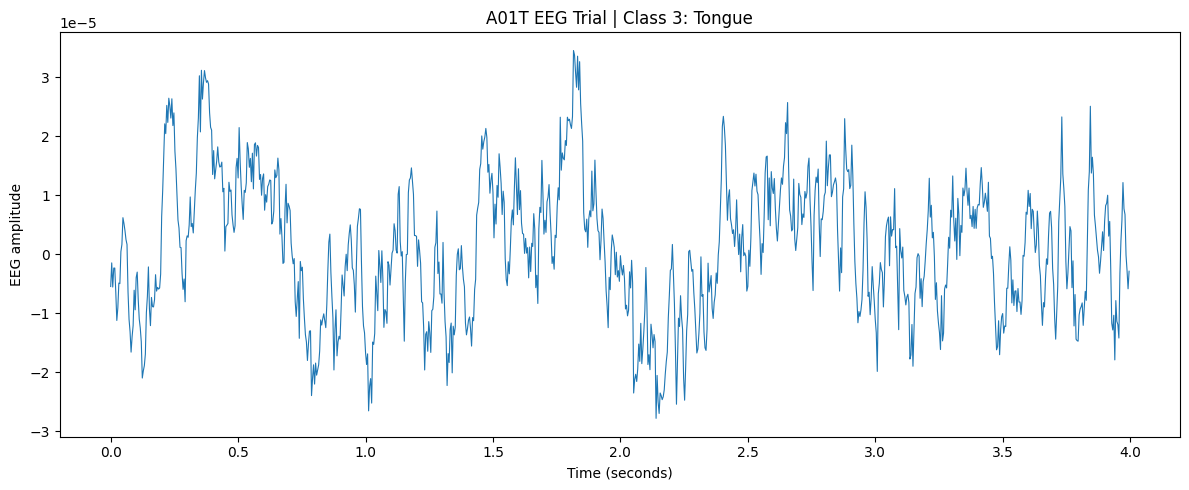


CELL 9B VALIDATION
✓ A01T.gdf loaded.
✓ 25 recorded channels.
✓ 22 EEG channels selected.
✓ 3 EOG channels excluded.
✓ Sampling rate = 250 Hz.
✓ Four MI event classes identified.
✓ 72 trials/class.
✓ 288 total MI trials.
✓ 4 seconds × 250 Hz = 1000 samples.
✓ X_A01T = (288,22,1000).
✓ No NaN/Inf.

CELL 9B COMPLETED SUCCESSFULLY

The A01T extraction is now ready to use as the reference for loading the remaining 17 GDF files.


In [18]:
# ============================================================================
# CELL 9B
# REAL BCI IV-2a A01T.GDF VERIFICATION - CORRECTED FINAL VERSION
# ============================================================================
#
# IMPORTANT CORRECTION:
#
# In BCI IV-2a:
#
#     event 768 = trial/cue-start marker
#     event 769 = Left Hand
#     event 770 = Right Hand
#     event 771 = Both Feet
#     event 772 = Tongue
#
# The MI event 769-772 occurs approximately 2 seconds after event 768.
#
# Therefore:
#
#     MI event onset = paper's t = 2 s
#
# The paper uses the following 4-second EEG segment:
#
#     t = 2 s → t = 6 s
#
# Hence, when using event 769-772 directly:
#
#     START = MI event sample
#     STOP  = START + 1000 samples
#
# DO NOT add another +2 seconds.
#
# ============================================================================


print("=" * 90)
print("CELL 9B - A01T.GDF REAL DATA VERIFICATION")
print("=" * 90)


# ============================================================================
# 9B.1 FIND A01T.GDF
# ============================================================================

A01T_PATH = None

for path in gdf_files_real:

    if path.name.upper() == "A01T.GDF":

        A01T_PATH = path
        break


if A01T_PATH is None:

    raise FileNotFoundError(
        "A01T.gdf was not found."
    )


print()
print("Selected file:")
print(A01T_PATH)


# ============================================================================
# 9B.2 LOAD RAW GDF
# ============================================================================

raw_a01t = mne.io.read_raw_gdf(
    str(A01T_PATH),
    preload=True,
    verbose=False,
)


print()
print("=" * 90)
print("RAW FILE INFORMATION")
print("=" * 90)

print(
    f"Sampling frequency : "
    f"{raw_a01t.info['sfreq']} Hz"
)

print(
    f"Total channels     : "
    f"{len(raw_a01t.ch_names)}"
)

print(
    f"Total samples      : "
    f"{raw_a01t.n_times}"
)

print(
    f"Duration           : "
    f"{raw_a01t.times[-1]:.2f} seconds"
)


# ============================================================================
# 9B.3 EXPLICIT EEG/EOG SELECTION
# ============================================================================

EOG_CHANNEL_NAMES = {
    "EOG-left",
    "EOG-central",
    "EOG-right",
}


eeg_indices_a01t = []
eeg_names_a01t = []

eog_indices_a01t = []
eog_names_a01t = []


for index, channel_name in enumerate(
    raw_a01t.ch_names
):

    normalized_name = (
        channel_name
        .strip()
        .lower()
    )

    if normalized_name in {
        name.lower()
        for name in EOG_CHANNEL_NAMES
    }:

        eog_indices_a01t.append(
            index
        )

        eog_names_a01t.append(
            channel_name
        )

    else:

        eeg_indices_a01t.append(
            index
        )

        eeg_names_a01t.append(
            channel_name
        )


print()
print("=" * 90)
print("CHANNEL SELECTION")
print("=" * 90)

print(
    f"Total recorded channels : "
    f"{len(raw_a01t.ch_names)}"
)

print(
    f"EEG channels             : "
    f"{len(eeg_indices_a01t)}"
)

print(
    f"EOG channels excluded    : "
    f"{len(eog_indices_a01t)}"
)


if len(
    eeg_indices_a01t
) != 22:

    raise RuntimeError(
        f"Expected 22 EEG channels, "
        f"found {len(eeg_indices_a01t)}."
    )


if len(
    eog_indices_a01t
) != 3:

    raise RuntimeError(
        f"Expected 3 EOG channels, "
        f"found {len(eog_indices_a01t)}."
    )


print(
    "✓ 22 EEG channels selected."
)

print(
    "✓ 3 EOG channels excluded."
)


# ============================================================================
# 9B.4 VERIFY SAMPLING RATE
# ============================================================================

if not np.isclose(
    raw_a01t.info["sfreq"],
    FS,
    atol=1e-3,
):

    raise RuntimeError(
        f"Expected {FS} Hz, "
        f"found {raw_a01t.info['sfreq']} Hz."
    )


print(
    f"✓ Sampling rate = {FS} Hz."
)


# ============================================================================
# 9B.5 EVENT EXTRACTION
# ============================================================================

events_a01t, event_id_a01t = (
    mne.events_from_annotations(
        raw_a01t,
        verbose=False,
    )
)


print()
print("=" * 90)
print("EVENT INFORMATION")
print("=" * 90)

print(
    "Event dictionary:"
)

print(
    event_id_a01t
)

print()
print(
    "Unique MNE event IDs:"
)

print(
    np.unique(
        events_a01t[:, 2]
    )
)


# ============================================================================
# 9B.6 EXPLICIT BCI IV-2a MI EVENT MAPPING
# ============================================================================
#
# MNE has mapped:
#
#     original GDF 769 → MNE event ID 7
#     original GDF 770 → MNE event ID 8
#     original GDF 771 → MNE event ID 9
#     original GDF 772 → MNE event ID 10
#
# ============================================================================

mi_mapping_a01t = {
    7: 0,     # Left Hand
    8: 1,     # Right Hand
    9: 2,     # Both Feet
    10: 3,    # Tongue
}


print()
print("=" * 90)
print("MOTOR-IMAGERY EVENT MAPPING")
print("=" * 90)

for event_id, class_index in (
    mi_mapping_a01t.items()
):

    original_code = {
        7: 769,
        8: 770,
        9: 771,
        10: 772,
    }[event_id]

    print(
        f"GDF code {original_code} "
        f"→ MNE event {event_id} "
        f"→ Class {class_index} "
        f"({CLASS_NAMES[class_index]})"
    )


# ============================================================================
# 9B.7 VERIFY EVENT COUNTS
# ============================================================================

print()
print("=" * 90)
print("MI EVENT COUNTS")
print("=" * 90)

for event_id, class_index in (
    mi_mapping_a01t.items()
):

    count = int(
        np.sum(
            events_a01t[:, 2]
            == event_id
        )
    )

    print(
        f"Event {event_id:2d} | "
        f"Class {class_index} | "
        f"{CLASS_NAMES[class_index]:<12} | "
        f"{count} trials"
    )

    if count != 72:

        raise RuntimeError(
            f"Expected 72 trials for class "
            f"{class_index}, found {count}."
        )


print()
print(
    "✓ 72 trials detected for every class."
)

print(
    "✓ Total MI trials = 288."
)


# ============================================================================
# 9B.8 EXTRACT 22 EEG CHANNELS
# ============================================================================

eeg_data_a01t = (
    raw_a01t.get_data(
        picks=eeg_indices_a01t
    )
)


print()
print("=" * 90)
print("EEG DATA")
print("=" * 90)

print(
    f"EEG array shape: "
    f"{eeg_data_a01t.shape}"
)


if eeg_data_a01t.shape[0] != 22:

    raise RuntimeError(
        "EEG array does not contain 22 channels."
    )


# ============================================================================
# 9B.9 CORRECT PAPER-ALIGNED TRIAL EXTRACTION
# ============================================================================
#
# CRITICAL:
#
# MI event itself = beginning of the 4-second EEG window.
#
# Therefore:
#
#     start = event_sample
#     stop  = event_sample + 1000
#
# NOT:
#
#     start = event_sample + 500
#
# ============================================================================

trial_length_samples = (
    N_TIME
)

print()
print("=" * 90)
print("PAPER-ALIGNED TRIAL EXTRACTION")
print("=" * 90)

print(
    f"Sampling rate     : {FS} Hz"
)

print(
    f"Trial duration    : {TRIAL_SECONDS} seconds"
)

print(
    f"Trial samples     : {trial_length_samples}"
)

print(
    "Extraction start  : MI event itself"
)

print(
    "Additional offset : 0 samples"
)


trials_a01t = []
labels_a01t = []
event_samples_a01t = []


for event in events_a01t:

    event_sample = int(
        event[0]
    )

    event_id = int(
        event[2]
    )

    if event_id not in mi_mapping_a01t:

        continue

    # ------------------------------------------------------------
    # IMPORTANT:
    #
    # No +500 sample offset.
    # ------------------------------------------------------------

    start_sample = (
        event_sample
    )

    stop_sample = (
        start_sample
        + trial_length_samples
    )

    # ------------------------------------------------------------
    # Boundary check.
    # ------------------------------------------------------------

    if start_sample < 0:

        continue

    if stop_sample > (
        eeg_data_a01t.shape[1]
    ):

        continue

    epoch = eeg_data_a01t[
        :,
        start_sample:stop_sample,
    ]

    if epoch.shape != (
        N_CHANNELS,
        N_TIME,
    ):

        continue

    trials_a01t.append(
        epoch.astype(
            np.float32
        )
    )

    labels_a01t.append(
        mi_mapping_a01t[
            event_id
        ]
    )

    event_samples_a01t.append(
        event_sample
    )


# ============================================================================
# 9B.10 BUILD A01T DATASET
# ============================================================================

X_A01T = np.stack(
    trials_a01t,
    axis=0,
)

y_A01T = np.asarray(
    labels_a01t,
    dtype=np.int64,
)


print()
print("=" * 90)
print("EXTRACTED A01T DATA")
print("=" * 90)

print(
    f"X_A01T shape : "
    f"{X_A01T.shape}"
)

print(
    f"y_A01T shape : "
    f"{y_A01T.shape}"
)


# ============================================================================
# 9B.11 CRITICAL TRIAL COUNT TEST
# ============================================================================

expected_trials = 288

if len(
    X_A01T
) != expected_trials:

    raise RuntimeError(
        f"\nExpected {expected_trials} extracted trials, "
        f"but obtained {len(X_A01T)}.\n\n"
        "The extraction timing should be investigated before continuing."
    )


print(
    "✓ Exactly 288 trials extracted."
)


# ============================================================================
# 9B.12 SHAPE TEST
# ============================================================================

if X_A01T.shape != (
    288,
    22,
    1000,
):

    raise RuntimeError(
        "Unexpected A01T tensor shape.\n"
        f"Expected: (288,22,1000)\n"
        f"Received: {X_A01T.shape}"
    )


print(
    "✓ A01T tensor = (288,22,1000)."
)


# ============================================================================
# 9B.13 CLASS DISTRIBUTION
# ============================================================================

print()
print("=" * 90)
print("A01T CLASS DISTRIBUTION")
print("=" * 90)

class_counts_A01T = np.bincount(
    y_A01T,
    minlength=N_CLASSES,
)

for class_index, count in enumerate(
    class_counts_A01T
):

    print(
        f"Class {class_index} "
        f"({CLASS_NAMES[class_index]:<12}): "
        f"{count}"
    )

    if count != 72:

        raise RuntimeError(
            f"Class {class_index} should contain "
            f"72 trials, found {count}."
        )


print()
print(
    "✓ Balanced distribution: 72 trials/class."
)


# ============================================================================
# 9B.14 DATA QUALITY
# ============================================================================

print()
print("=" * 90)
print("A01T DATA QUALITY")
print("=" * 90)

nan_count = int(
    np.isnan(
        X_A01T
    ).sum()
)

inf_count = int(
    np.isinf(
        X_A01T
    ).sum()
)

print(
    f"NaN count : {nan_count}"
)

print(
    f"Inf count : {inf_count}"
)

print(
    f"Min       : {float(X_A01T.min()):.8f}"
)

print(
    f"Max       : {float(X_A01T.max()):.8f}"
)

print(
    f"Mean      : {float(X_A01T.mean()):.8f}"
)

print(
    f"Std       : {float(X_A01T.std()):.8f}"
)


if nan_count != 0:

    raise RuntimeError(
        "NaN values detected."
    )

if inf_count != 0:

    raise RuntimeError(
        "Inf values detected."
    )


print(
    "✓ No NaN/Inf values."
)


# ============================================================================
# 9B.15 FIRST FEW TRIALS
# ============================================================================

print()
print("=" * 90)
print("FIRST 10 MI TRIALS")
print("=" * 90)

for index in range(
    10
):

    event_sample = (
        event_samples_a01t[
            index
        ]
    )

    event_time = (
        event_sample
        / FS
    )

    label = int(
        y_A01T[
            index
        ]
    )

    print(
        f"Trial {index:02d} | "
        f"MI event={event_time:8.3f}s | "
        f"class={label} | "
        f"{CLASS_NAMES[label]}"
    )


# ============================================================================
# 9B.16 VISUALIZE ONE TRIAL
# ============================================================================

print()
print("=" * 90)
print("A01T EEG VISUALIZATION")
print("=" * 90)

example_trial = 0
example_channel = 10

time_axis = (
    np.arange(
        N_TIME
    )
    / FS
)

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    time_axis,
    X_A01T[
        example_trial,
        example_channel,
    ],
    linewidth=0.8,
)

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "EEG amplitude"
)

example_class = int(
    y_A01T[
        example_trial
    ]
)

plt.title(
    "A01T EEG Trial | "
    f"Class {example_class}: "
    f"{CLASS_NAMES[example_class]}"
)

plt.tight_layout()

plt.show()


# ============================================================================
# 9B.17 FINAL VALIDATION
# ============================================================================

print()
print("=" * 90)
print("CELL 9B VALIDATION")
print("=" * 90)

print(
    "✓ A01T.gdf loaded."
)

print(
    "✓ 25 recorded channels."
)

print(
    "✓ 22 EEG channels selected."
)

print(
    "✓ 3 EOG channels excluded."
)

print(
    "✓ Sampling rate = 250 Hz."
)

print(
    "✓ Four MI event classes identified."
)

print(
    "✓ 72 trials/class."
)

print(
    "✓ 288 total MI trials."
)

print(
    "✓ 4 seconds × 250 Hz = 1000 samples."
)

print(
    "✓ X_A01T = (288,22,1000)."
)

print(
    "✓ No NaN/Inf."
)

print()
print("=" * 90)
print("CELL 9B COMPLETED SUCCESSFULLY")
print("=" * 90)

print()
print(
    "The A01T extraction is now ready to use as the "
    "reference for loading the remaining 17 GDF files."
)

In [19]:
# ============================================================================
# CELL 9C
# LOAD ALL REAL BCI COMPETITION IV-2a GDF FILES
# ============================================================================
#
# SELF-CONTAINED VERSION
#
# This cell defines ALL helper functions it needs.
#
# It loads:
#
#     A01T.gdf ... A09T.gdf
#     A01E.gdf ... A09E.gdf
#
# and determines which files contain usable four-class MI labels.
#
# For labelled files:
#
#     event 769/7  -> Left Hand
#     event 770/8  -> Right Hand
#     event 771/9  -> Both Feet
#     event 772/10 -> Tongue
#
# Trial extraction:
#
#     MI event onset
#          ↓
#        4 seconds
#          ↓
#        1000 samples
#
# No additional +2 second offset is applied.
#
# Output:
#
#     X_real_all
#     y_real_all
#     subjects_real
#     sessions_real
#     trial_file_real
#
# ============================================================================


print("=" * 90)
print("CELL 9C - LOAD ALL REAL BCI IV-2a GDF FILES")
print("=" * 90)


# ============================================================================
# 9C.0 REQUIRED BASIC OBJECTS
# ============================================================================

required_basic_objects = [
    "gdf_files_real",
    "N_CHANNELS",
    "N_TIME",
    "FS",
    "N_CLASSES",
    "CLASS_NAMES",
]

missing_basic_objects = [
    name
    for name in required_basic_objects
    if name not in globals()
]

if missing_basic_objects:

    raise RuntimeError(
        "Missing required notebook variables:\n"
        f"{missing_basic_objects}\n\n"
        "Run Cell 1 and Cell 9A first."
    )


# ============================================================================
# 9C.1 EXPLICIT BCI IV-2a CONSTANTS
# ============================================================================

EOG_CHANNEL_NAMES = {
    "eog-left",
    "eog-central",
    "eog-right",
}


# MNE event IDs observed in your validated A01T file:
#
#     MNE 7  = original GDF 769 = Left Hand
#     MNE 8  = original GDF 770 = Right Hand
#     MNE 9  = original GDF 771 = Both Feet
#     MNE 10 = original GDF 772 = Tongue

MNE_MI_EVENT_MAPPING = {
    7: 0,
    8: 1,
    9: 2,
    10: 3,
}


# Also support original GDF event values if they appear directly.
ORIGINAL_MI_EVENT_MAPPING = {
    769: 0,
    770: 1,
    771: 2,
    772: 3,
}


# ============================================================================
# 9C.2 PARSE SUBJECT / SESSION FROM FILENAME
# ============================================================================
#
# This helper was missing in the previous Cell 9C.
#
# Examples:
#
#     A01T.gdf -> subject=1, session=1, code=T
#     A01E.gdf -> subject=1, session=2, code=E
#
# ============================================================================

def parse_bci2a_filename(
    path,
):
    """
    Parse subject/session metadata from a standard BCI IV-2a filename.

    Parameters
    ----------
    path : str or pathlib.Path
        GDF path.

    Returns
    -------
    subject_id : int
    session_id : int
    session_code : str
    """

    path = Path(
        path
    )

    filename = (
        path.name.upper()
    )

    # ------------------------------------------------------------
    # Subject:
    #
    # A01T
    # A09E
    # ------------------------------------------------------------

    subject_match = re.search(
        r"A0?([1-9])",
        filename,
    )

    if subject_match is None:

        raise ValueError(
            f"Could not identify subject from filename: "
            f"{path.name}"
        )

    subject_id = int(
        subject_match.group(1)
    )

    # ------------------------------------------------------------
    # Session:
    #
    # T = training
    # E = evaluation
    # ------------------------------------------------------------

    session_match = re.search(
        r"([TE])\.GDF$",
        filename,
    )

    if session_match is None:

        raise ValueError(
            f"Could not identify T/E session from filename: "
            f"{path.name}"
        )

    session_code = (
        session_match.group(1)
    )

    session_id = (
        1
        if session_code == "T"
        else 2
    )

    return (
        subject_id,
        session_id,
        session_code,
    )


# ============================================================================
# 9C.3 EEG CHANNEL SELECTION
# ============================================================================

def select_bci2a_eeg_channels(
    raw,
):
    """
    Select exactly the 22 EEG channels.

    Your GDF encoding reports all 25 physiological channels as 'eeg',
    therefore channel name filtering is used to exclude:

        EOG-left
        EOG-central
        EOG-right
    """

    eeg_indices = []
    eeg_names = []

    eog_indices = []
    eog_names = []

    normalized_eog_names = {
        name.lower()
        for name in EOG_CHANNEL_NAMES
    }

    for index, channel_name in enumerate(
        raw.ch_names
    ):

        normalized_name = (
            channel_name
            .strip()
            .lower()
        )

        if normalized_name in normalized_eog_names:

            eog_indices.append(
                index
            )

            eog_names.append(
                channel_name
            )

        else:

            eeg_indices.append(
                index
            )

            eeg_names.append(
                channel_name
            )

    if len(
        eeg_indices
    ) != N_CHANNELS:

        raise RuntimeError(
            f"Expected {N_CHANNELS} EEG channels, "
            f"found {len(eeg_indices)}.\n"
            f"Detected EEG channels:\n{eeg_names}\n"
            f"Detected EOG channels:\n{eog_names}"
        )

    if len(
        eog_indices
    ) != 3:

        raise RuntimeError(
            f"Expected 3 EOG channels, "
            f"found {len(eog_indices)}.\n"
            f"EOG channels:\n{eog_names}"
        )

    return (
        eeg_indices,
        eeg_names,
        eog_indices,
        eog_names,
    )


# ============================================================================
# 9C.4 DETECT MI EVENT MAPPING
# ============================================================================

def detect_bci2a_mi_events(
    events,
    event_id,
):
    """
    Detect the four MI class events.

    Priority:
        1. MNE IDs 7,8,9,10
        2. Original GDF IDs 769,770,771,772
        3. Annotation names ending in T1/T2/T3/T4

    Returns
    -------
    dict or None
    """

    available_codes = set(
        int(code)
        for code in np.unique(
            events[:, 2]
        )
    )

    # ------------------------------------------------------------
    # MNE mapping
    # ------------------------------------------------------------

    if set(
        MNE_MI_EVENT_MAPPING.keys()
    ).issubset(
        available_codes
    ):

        return dict(
            MNE_MI_EVENT_MAPPING
        )

    # ------------------------------------------------------------
    # Original GDF mapping
    # ------------------------------------------------------------

    if set(
        ORIGINAL_MI_EVENT_MAPPING.keys()
    ).issubset(
        available_codes
    ):

        return dict(
            ORIGINAL_MI_EVENT_MAPPING
        )

    # ------------------------------------------------------------
    # Annotation fallback
    # ------------------------------------------------------------

    inverse_event_id = {
        int(code): str(name)
        for name, code
        in event_id.items()
    }

    detected = {}

    for code, name in (
        inverse_event_id.items()
    ):

        upper_name = (
            name.upper()
        )

        if upper_name.endswith(
            "T1"
        ):

            detected[code] = 0

        elif upper_name.endswith(
            "T2"
        ):

            detected[code] = 1

        elif upper_name.endswith(
            "T3"
        ):

            detected[code] = 2

        elif upper_name.endswith(
            "T4"
        ):

            detected[code] = 3

    if len(
        detected
    ) == 4:

        return detected

    return None


# ============================================================================
# 9C.5 LOAD ONE GDF FILE
# ============================================================================

def load_one_real_bci2a_file(
    path,
):
    """
    Load a single BCI IV-2a GDF file.

    Returns a dictionary containing metadata and, when available,
    labelled four-class MI trials.
    """

    path = Path(
        path
    )

    (
        subject_id,
        session_id,
        session_code,
    ) = parse_bci2a_filename(
        path
    )

    print()
    print(
        "-" * 90
    )

    print(
        f"FILE: {path.name}"
    )

    print(
        f"Subject: A{subject_id}"
    )

    print(
        f"Session: {session_code}"
    )

    print(
        "-" * 90
    )

    # ------------------------------------------------------------------------
    # Load GDF
    # ------------------------------------------------------------------------

    raw = mne.io.read_raw_gdf(
        str(path),
        preload=True,
        verbose=False,
    )

    # ------------------------------------------------------------------------
    # Sampling rate
    # ------------------------------------------------------------------------

    sfreq = float(
        raw.info[
            "sfreq"
        ]
    )

    if not np.isclose(
        sfreq,
        FS,
        atol=1e-3,
    ):

        raise RuntimeError(
            f"{path.name}: expected {FS} Hz, "
            f"found {sfreq} Hz."
        )

    # ------------------------------------------------------------------------
    # EEG channels
    # ------------------------------------------------------------------------

    (
        eeg_indices,
        eeg_names,
        eog_indices,
        eog_names,
    ) = select_bci2a_eeg_channels(
        raw
    )

    # ------------------------------------------------------------------------
    # Events
    # ------------------------------------------------------------------------

    events, event_id = (
        mne.events_from_annotations(
            raw,
            verbose=False,
        )
    )

    unique_codes = np.unique(
        events[:, 2]
    )

    print(
        f"Total channels: {len(raw.ch_names)}"
    )

    print(
        f"EEG channels: {len(eeg_indices)}"
    )

    print(
        f"EOG channels: {len(eog_indices)}"
    )

    print(
        f"Sampling rate: {sfreq} Hz"
    )

    print(
        "Event dictionary:",
        event_id,
    )

    print(
        "Unique event IDs:",
        unique_codes,
    )

    # ------------------------------------------------------------------------
    # Detect MI labels.
    # ------------------------------------------------------------------------

    mi_mapping = (
        detect_bci2a_mi_events(
            events,
            event_id,
        )
    )

    if mi_mapping is None:

        print(
            "⚠ Four-class MI labels not detected."
        )

        return {
            "X": None,
            "y": None,
            "subject": subject_id,
            "session": session_id,
            "session_code": session_code,
            "file": str(path),
            "event_id": event_id,
            "event_codes": unique_codes,
            "has_labels": False,
            "n_trials": 0,
            "class_counts": None,
        }

    print(
        "Detected MI mapping:",
        mi_mapping,
    )

    # ------------------------------------------------------------------------
    # EEG data
    # ------------------------------------------------------------------------

    eeg_data = raw.get_data(
        picks=eeg_indices
    )

    if eeg_data.shape[0] != (
        N_CHANNELS
    ):

        raise RuntimeError(
            f"{path.name}: EEG shape is "
            f"{eeg_data.shape}; expected first dimension "
            f"{N_CHANNELS}."
        )

    # ------------------------------------------------------------------------
    # Extract 4-second MI epochs.
    #
    # IMPORTANT:
    #
    # The MI event itself marks the beginning of our desired 4-second
    # window. No +2 second offset.
    # ------------------------------------------------------------------------

    trials = []
    labels = []
    event_samples = []

    for event in events:

        event_sample = int(
            event[0]
        )

        event_code = int(
            event[2]
        )

        if event_code not in mi_mapping:

            continue

        start_sample = (
            event_sample
        )

        stop_sample = (
            start_sample
            + N_TIME
        )

        if start_sample < 0:

            continue

        if stop_sample > (
            eeg_data.shape[1]
        ):

            continue

        epoch = eeg_data[
            :,
            start_sample:stop_sample,
        ]

        if epoch.shape != (
            N_CHANNELS,
            N_TIME,
        ):

            continue

        trials.append(
            epoch.astype(
                np.float32
            )
        )

        labels.append(
            mi_mapping[
                event_code
            ]
        )

        event_samples.append(
            event_sample
        )

    # ------------------------------------------------------------------------
    # No labelled trials
    # ------------------------------------------------------------------------

    if len(
        trials
    ) == 0:

        print(
            "⚠ No valid labelled trials extracted."
        )

        return {
            "X": None,
            "y": None,
            "subject": subject_id,
            "session": session_id,
            "session_code": session_code,
            "file": str(path),
            "event_id": event_id,
            "event_codes": unique_codes,
            "has_labels": False,
            "n_trials": 0,
            "class_counts": None,
        }

    # ------------------------------------------------------------------------
    # Build arrays
    # ------------------------------------------------------------------------

    X = np.stack(
        trials,
        axis=0,
    )

    y = np.asarray(
        labels,
        dtype=np.int64,
    )

    # ------------------------------------------------------------------------
    # Validate
    # ------------------------------------------------------------------------

    validate_eeg_array(
        X
    )

    if not np.isfinite(
        X
    ).all():

        raise RuntimeError(
            f"{path.name}: NaN/Inf found in extracted EEG."
        )

    class_counts = np.bincount(
        y,
        minlength=N_CLASSES,
    )

    print(
        f"Extracted trials: {len(X)}"
    )

    print(
        f"Shape: {X.shape}"
    )

    print(
        f"Class counts: {class_counts.tolist()}"
    )

    if len(X) != 288:

        print(
            f"⚠ Expected 288 trials, extracted {len(X)}."
        )

    return {
        "X": X,
        "y": y,
        "subject": subject_id,
        "session": session_id,
        "session_code": session_code,
        "file": str(path),
        "event_id": event_id,
        "event_codes": unique_codes,
        "event_samples": np.asarray(
            event_samples,
            dtype=np.int64,
        ),
        "has_labels": True,
        "n_trials": len(X),
        "class_counts": class_counts,
    }


# ============================================================================
# 9C.6 LOAD ALL 18 FILES
# ============================================================================

print()
print("=" * 90)
print("LOADING ALL 18 GDF FILES")
print("=" * 90)

real_file_results = []

for file_index, path in enumerate(
    sorted(
        gdf_files_real,
        key=lambda p: p.name.lower(),
    ),
    start=1,
):

    print()
    print(
        f"[{file_index:02d}/{len(gdf_files_real):02d}]"
    )

    try:

        result = (
            load_one_real_bci2a_file(
                path
            )
        )

        real_file_results.append(
            result
        )

    except Exception as exc:

        print()
        print(
            f"❌ ERROR loading {path.name}"
        )

        print(
            f"   {type(exc).__name__}: {exc}"
        )

        raise


# ============================================================================
# 9C.7 FILE SUMMARY
# ============================================================================

print()
print("=" * 90)
print("ALL FILE SUMMARY")
print("=" * 90)

for result in (
    real_file_results
):

    filename = Path(
        result["file"]
    ).name

    subject = result[
        "subject"
    ]

    session_code = result[
        "session_code"
    ]

    if result[
        "has_labels"
    ]:

        counts = (
            result[
                "class_counts"
            ].tolist()
        )

        print(
            f"{filename:<12} | "
            f"A{subject} | "
            f"{session_code} | "
            f"trials={result['n_trials']:3d} | "
            f"classes={counts}"
        )

    else:

        print(
            f"{filename:<12} | "
            f"A{subject} | "
            f"{session_code} | "
            f"NO 4-CLASS LABELS"
        )


# ============================================================================
# 9C.8 LABEL AVAILABILITY
# ============================================================================

labelled_results = [
    result
    for result in real_file_results
    if result["has_labels"]
]

unlabelled_results = [
    result
    for result in real_file_results
    if not result["has_labels"]
]


print()
print("=" * 90)
print("LABEL AVAILABILITY")
print("=" * 90)

print(
    f"Files with four-class MI labels : "
    f"{len(labelled_results)}"
)

print(
    f"Files without four-class labels: "
    f"{len(unlabelled_results)}"
)


if unlabelled_results:

    print()
    print(
        "Files without four-class labels:"
    )

    for result in (
        unlabelled_results
    ):

        print(
            f"    {Path(result['file']).name}"
        )


# ============================================================================
# 9C.9 BUILD COMBINED LABELLED DATASET
# ============================================================================

if len(
    labelled_results
) == 0:

    raise RuntimeError(
        "No labelled files were detected."
    )


X_parts = []
y_parts = []
subject_parts = []
session_parts = []
file_parts = []
trial_index_parts = []


for result in (
    labelled_results
):

    n_trials = int(
        result[
            "n_trials"
        ]
    )

    X_parts.append(
        result["X"]
    )

    y_parts.append(
        result["y"]
    )

    subject_parts.append(
        np.full(
            n_trials,
            result["subject"],
            dtype=np.int64,
        )
    )

    session_parts.append(
        np.full(
            n_trials,
            result["session"],
            dtype=np.int64,
        )
    )

    file_parts.append(
        np.full(
            n_trials,
            Path(
                result["file"]
            ).name,
            dtype=object,
        )
    )

    trial_index_parts.append(
        np.arange(
            n_trials,
            dtype=np.int64,
        )
    )


X_real_all = np.concatenate(
    X_parts,
    axis=0,
)

y_real_all = np.concatenate(
    y_parts,
    axis=0,
)

subjects_real = np.concatenate(
    subject_parts,
    axis=0,
)

sessions_real = np.concatenate(
    session_parts,
    axis=0,
)

trial_file_real = np.concatenate(
    file_parts,
    axis=0,
)

trial_index_real = np.concatenate(
    trial_index_parts,
    axis=0,
)


# ============================================================================
# 9C.10 COMBINED DATASET SUMMARY
# ============================================================================

print()
print("=" * 90)
print("COMBINED LABELLED REAL DATASET")
print("=" * 90)

print(
    f"X_real_all shape : "
    f"{X_real_all.shape}"
)

print(
    f"y_real_all shape : "
    f"{y_real_all.shape}"
)

print(
    f"subjects shape   : "
    f"{subjects_real.shape}"
)

print(
    f"sessions shape   : "
    f"{sessions_real.shape}"
)


# ============================================================================
# 9C.11 GLOBAL CLASS COUNTS
# ============================================================================

global_class_counts = np.bincount(
    y_real_all,
    minlength=N_CLASSES,
)


print()
print(
    "GLOBAL CLASS DISTRIBUTION"
)

for class_index, count in enumerate(
    global_class_counts
):

    print(
        f"Class {class_index} "
        f"({CLASS_NAMES[class_index]:<12}): "
        f"{count}"
    )


# ============================================================================
# 9C.12 SUBJECT COUNTS
# ============================================================================

unique_subjects = sorted(
    np.unique(
        subjects_real
    ).tolist()
)


print()
print("=" * 90)
print("SUBJECT DISTRIBUTION")
print("=" * 90)

print(
    "Subjects:",
    unique_subjects,
)


for subject in unique_subjects:

    subject_mask = (
        subjects_real
        == subject
    )

    print()
    print(
        f"A{subject}:"
    )

    for session in sorted(
        np.unique(
            sessions_real[
                subject_mask
            ]
        )
    ):

        session_mask = (
            subject_mask
            &
            (
                sessions_real
                == session
            )
        )

        counts = np.bincount(
            y_real_all[
                session_mask
            ],
            minlength=N_CLASSES,
        )

        print(
            f"    Session {session}: "
            f"total={int(session_mask.sum())}, "
            f"classes={counts.tolist()}"
        )

    print(
        f"    Subject total: "
        f"{int(subject_mask.sum())}"
    )


# ============================================================================
# 9C.13 SESSION INTEGRITY CHECK
# ============================================================================

print()
print("=" * 90)
print("SESSION INTEGRITY CHECK")
print("=" * 90)

all_sessions_valid = True

for subject in unique_subjects:

    subject_mask = (
        subjects_real
        == subject
    )

    for session in sorted(
        np.unique(
            sessions_real[
                subject_mask
            ]
        )
    ):

        session_mask = (
            subject_mask
            &
            (
                sessions_real
                == session
            )
        )

        total_trials = int(
            session_mask.sum()
        )

        class_counts = np.bincount(
            y_real_all[
                session_mask
            ],
            minlength=N_CLASSES,
        )

        valid = (
            total_trials == 288
            and np.all(
                class_counts == 72
            )
        )

        print(
            f"A{subject} "
            f"Session {session}: "
            f"total={total_trials}, "
            f"classes={class_counts.tolist()}, "
            f"valid={valid}"
        )

        if not valid:

            all_sessions_valid = False


# ============================================================================
# 9C.14 DATA QUALITY
# ============================================================================

print()
print("=" * 90)
print("GLOBAL DATA QUALITY")
print("=" * 90)

nan_count = int(
    np.isnan(
        X_real_all
    ).sum()
)

inf_count = int(
    np.isinf(
        X_real_all
    ).sum()
)

print(
    f"NaN count : {nan_count}"
)

print(
    f"Inf count : {inf_count}"
)

print(
    f"Mean      : "
    f"{float(X_real_all.mean()):.10f}"
)

print(
    f"Std       : "
    f"{float(X_real_all.std()):.10f}"
)


if nan_count != 0:

    raise RuntimeError(
        "NaN values found in combined dataset."
    )

if inf_count != 0:

    raise RuntimeError(
        "Inf values found in combined dataset."
    )


# ============================================================================
# 9C.15 MAIN SHAPE VALIDATION
# ============================================================================

print()
print("=" * 90)
print("GLOBAL SHAPE VALIDATION")
print("=" * 90)

assert X_real_all.ndim == 3

assert (
    X_real_all.shape[1]
    == N_CHANNELS
)

assert (
    X_real_all.shape[2]
    == N_TIME
)

assert len(
    X_real_all
) == len(
    y_real_all
)

assert len(
    X_real_all
) == len(
    subjects_real
)

assert len(
    X_real_all
) == len(
    sessions_real
)

assert len(
    X_real_all
) == len(
    trial_file_real
)

assert len(
    X_real_all
) == len(
    trial_index_real
)


print(
    "✓ X shape = (N,22,1000)"
)

print(
    "✓ Labels aligned."
)

print(
    "✓ Subjects aligned."
)

print(
    "✓ Sessions aligned."
)

print(
    "✓ File metadata aligned."
)

print(
    "✓ Trial indices aligned."
)


# ============================================================================
# 9C.16 SUBJECT COUNT
# ============================================================================

print()
print("=" * 90)
print("SUBJECT COUNT")
print("=" * 90)

print(
    f"Subjects in labelled dataset: "
    f"{len(unique_subjects)}"
)

print(
    f"Subject IDs: "
    f"{unique_subjects}"
)


# ============================================================================
# 9C.17 FINAL OUTPUT
# ============================================================================

print()
print("=" * 90)
print("CELL 9C COMPLETED SUCCESSFULLY")
print("=" * 90)

print()
print(
    "REAL DATA VARIABLES NOW AVAILABLE:"
)

print(
    "    X_real_all"
)

print(
    "    y_real_all"
)

print(
    "    subjects_real"
)

print(
    "    sessions_real"
)

print(
    "    trial_file_real"
)

print(
    "    trial_index_real"
)

print()
print(
    f"X_real_all.shape = {X_real_all.shape}"
)

print(
    f"y_real_all.shape = {y_real_all.shape}"
)

print(
    f"subjects_real    = {np.unique(subjects_real)}"
)

print(
    f"sessions_real    = {np.unique(sessions_real)}"
)

print()
print(
    "Session integrity valid:",
    all_sessions_valid,
)

print()
print(
    "IMPORTANT:"
)

print(
    "Do NOT start full LOSO training until you inspect the "
    "ALL FILE SUMMARY and LABEL AVAILABILITY sections."
)

CELL 9C - LOAD ALL REAL BCI IV-2a GDF FILES

LOADING ALL 18 GDF FILES

[01/18]

------------------------------------------------------------------------------------------
FILE: A01E.gdf
Subject: A1
Session: E
------------------------------------------------------------------------------------------


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Total channels: 25
EEG channels: 22
EOG channels: 3
Sampling rate: 250.0 Hz
Event dictionary: {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '783': 7}
Unique event IDs: [1 2 3 4 5 6 7]
⚠ Four-class MI labels not detected.

[02/18]

------------------------------------------------------------------------------------------
FILE: A01T.gdf
Subject: A1
Session: T
------------------------------------------------------------------------------------------


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Total channels: 25
EEG channels: 22
EOG channels: 3
Sampling rate: 250.0 Hz
Event dictionary: {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
Unique event IDs: [ 1  2  3  4  5  6  7  8  9 10]
Detected MI mapping: {7: 0, 8: 1, 9: 2, 10: 3}
Extracted trials: 288
Shape: (288, 22, 1000)
Class counts: [72, 72, 72, 72]

[03/18]

------------------------------------------------------------------------------------------
FILE: A02E.gdf
Subject: A2
Session: E
------------------------------------------------------------------------------------------


...

Total channels: 25
EEG channels: 22
EOG channels: 3
Sampling rate: 250.0 Hz
Event dictionary: {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
Unique event IDs: [ 1  2  3  4  5  6  7  8  9 10]
Detected MI mapping: {7: 0, 8: 1, 9: 2, 10: 3}
Extracted trials: 288
Shape: (288, 22, 1000)
Class counts: [72, 72, 72, 72]

[17/18]

------------------------------------------------------------------------------------------
FILE: A09E.gdf
Subject: A9
Session: E
------------------------------------------------------------------------------------------


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Total channels: 25
EEG channels: 22
EOG channels: 3
Sampling rate: 250.0 Hz
Event dictionary: {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '783': 7}
Unique event IDs: [1 2 3 4 5 6 7]
⚠ Four-class MI labels not detected.

[18/18]

------------------------------------------------------------------------------------------
FILE: A09T.gdf
Subject: A9
Session: T
------------------------------------------------------------------------------------------


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Total channels: 25
EEG channels: 22
EOG channels: 3
Sampling rate: 250.0 Hz
Event dictionary: {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
Unique event IDs: [ 1  2  3  4  5  6  7  8  9 10]
Detected MI mapping: {7: 0, 8: 1, 9: 2, 10: 3}
Extracted trials: 288
Shape: (288, 22, 1000)
Class counts: [72, 72, 72, 72]

ALL FILE SUMMARY
A01E.gdf     | A1 | E | NO 4-CLASS LABELS
A01T.gdf     | A1 | T | trials=288 | classes=[72, 72, 72, 72]
A02E.gdf     | A2 | E | NO 4-CLASS LABELS
A02T.gdf     | A2 | T | trials=288 | classes=[72, 72, 72, 72]
A03E.gdf     | A3 | E | NO 4-CLASS LABELS
A03T.gdf     | A3 | T | trials=288 | classes=[72, 72, 72, 72]
A04E.gdf     | A4 | E | NO 4-CLASS LABELS
A04T.gdf     | A4 | T | NO 4-CLASS LABELS
A05E.gdf     | A5 | E | NO 4-CLASS LABELS
A05T.gdf     | A5 | T | trials=288 | classes=[72, 72, 72, 72]
A06E.gdf     | A6 | E | NO 4-CLASS LABELS
A06T.gdf     | A6 | T | trials=288 | classes=[72, 72, 72, 72]
A07E.

In [20]:
# ============================================================================
# CELL 9D
# FIX MNE EVENT-ID VARIATION + BUILD COMPLETE 9-SUBJECT TRAINING DATASET
# ============================================================================
#
# Problem fixed:
#
#   A01T:
#       769 -> MNE 7
#       770 -> MNE 8
#       771 -> MNE 9
#       772 -> MNE 10
#
#   A04T:
#       769 -> MNE 5
#       770 -> MNE 6
#       771 -> MNE 7
#       772 -> MNE 8
#
# Therefore we MUST NOT assume that the MNE integer ID itself is fixed.
#
# Instead:
#
#     annotation description "769"
#                 ↓
#             MI class 0
#
#     annotation description "770"
#                 ↓
#             MI class 1
#
# etc.
#
# Output:
#
#     X_train_all_real
#     y_train_all_real
#     subjects_train_real
#     sessions_train_real
#     train_file_real
#
# Expected:
#
#     X_train_all_real.shape = (2592,22,1000)
#     9 subjects
#     288 trials/subject
#     72/class
#
# ============================================================================


print("=" * 90)
print("CELL 9D - FIX EVENT MAPPING + BUILD COMPLETE 9-SUBJECT TRAIN DATA")
print("=" * 90)


# ============================================================================
# 9D.1 REQUIRED VARIABLES
# ============================================================================

if "gdf_files_real" not in globals():

    raise RuntimeError(
        "gdf_files_real is missing. Run Cell 9A first."
    )

print(
    f"GDF files available: {len(gdf_files_real)}"
)


# ============================================================================
# 9D.2 ROBUST EVENT MAPPING
# ============================================================================

def robust_bci2a_mi_mapping(
    events,
    event_id,
):
    """
    Robustly identify the four BCI IV-2a MI events.

    Priority:

    1. Annotation description names:
           769
           770
           771
           772

    2. Corresponding MNE numeric IDs.

    3. Fallback for known MNE IDs 7-10.

    Returns:
        dict mapping MNE numeric event ID -> class index
    """

    # ------------------------------------------------------------------------
    # Reverse MNE event dictionary:
    #
    #     {'769': 5, '770': 6, ...}
    #
    # becomes:
    #
    #     {'5': '769', '6': '770', ...}
    # ------------------------------------------------------------------------

    detected = {}

    for description, numeric_id in (
        event_id.items()
    ):

        description_clean = (
            str(description)
            .strip()
        )

        # ------------------------------------------------------------
        # Explicit original GDF MI markers.
        # ------------------------------------------------------------

        if description_clean == "769":

            detected[
                int(numeric_id)
            ] = 0

        elif description_clean == "770":

            detected[
                int(numeric_id)
            ] = 1

        elif description_clean == "771":

            detected[
                int(numeric_id)
            ] = 2

        elif description_clean == "772":

            detected[
                int(numeric_id)
            ] = 3

    if len(
        detected
    ) == 4:

        return detected

    # ------------------------------------------------------------------------
    # Fallback: annotations may be named T1/T2/T3/T4.
    # ------------------------------------------------------------------------

    for description, numeric_id in (
        event_id.items()
    ):

        description_clean = (
            str(description)
            .strip()
            .upper()
        )

        if description_clean.endswith(
            "T1"
        ):

            detected[
                int(numeric_id)
            ] = 0

        elif description_clean.endswith(
            "T2"
        ):

            detected[
                int(numeric_id)
            ] = 1

        elif description_clean.endswith(
            "T3"
        ):

            detected[
                int(numeric_id)
            ] = 2

        elif description_clean.endswith(
            "T4"
        ):

            detected[
                int(numeric_id)
            ] = 3

    if len(
        detected
    ) == 4:

        return detected

    return None


# ============================================================================
# 9D.3 LOAD ONE TRAINING FILE
# ============================================================================

def load_one_bci2a_training_file(
    path,
):
    """
    Load a BCI IV-2a T-session and extract:
        288 MI trials
        22 EEG channels
        1000 samples/trial
    """

    path = Path(
        path
    )

    subject_match = re.search(
        r"A0?([1-9])T\.GDF$",
        path.name.upper(),
    )

    if subject_match is None:

        raise ValueError(
            f"Not a standard T-session file: {path.name}"
        )

    subject = int(
        subject_match.group(1)
    )

    print()
    print(
        "-" * 90
    )

    print(
        f"Loading {path.name} | Subject A{subject}"
    )

    print(
        "-" * 90
    )

    # ------------------------------------------------------------------------
    # Read file.
    # ------------------------------------------------------------------------

    raw = mne.io.read_raw_gdf(
        str(path),
        preload=True,
        verbose=False,
    )

    # ------------------------------------------------------------------------
    # Verify sampling rate.
    # ------------------------------------------------------------------------

    if not np.isclose(
        raw.info["sfreq"],
        FS,
        atol=1e-3,
    ):

        raise RuntimeError(
            f"{path.name}: expected {FS} Hz."
        )

    # ------------------------------------------------------------------------
    # Explicitly exclude EOG.
    # ------------------------------------------------------------------------

    eog_names = {
        "eog-left",
        "eog-central",
        "eog-right",
    }

    eeg_indices = []

    for index, name in enumerate(
        raw.ch_names
    ):

        if (
            name
            .strip()
            .lower()
            not in eog_names
        ):

            eeg_indices.append(
                index
            )

    if len(
        eeg_indices
    ) != N_CHANNELS:

        raise RuntimeError(
            f"{path.name}: expected "
            f"{N_CHANNELS} EEG channels, "
            f"found {len(eeg_indices)}."
        )

    # ------------------------------------------------------------------------
    # Extract events.
    # ------------------------------------------------------------------------

    events, event_id = (
        mne.events_from_annotations(
            raw,
            verbose=False,
        )
    )

    # ------------------------------------------------------------------------
    # ROBUST mapping.
    # ------------------------------------------------------------------------

    mi_mapping = (
        robust_bci2a_mi_mapping(
            events,
            event_id,
        )
    )

    print(
        "Event dictionary:"
    )

    print(
        event_id
    )

    print(
        "Detected MI mapping:"
    )

    print(
        mi_mapping
    )

    if mi_mapping is None:

        raise RuntimeError(
            f"{path.name}: could not detect all four MI classes."
        )

    # ------------------------------------------------------------------------
    # EEG data.
    # ------------------------------------------------------------------------

    eeg_data = raw.get_data(
        picks=eeg_indices
    )

    # ------------------------------------------------------------------------
    # Extract 4-second windows.
    #
    # The MI event itself is the beginning of our 4-second segment.
    # ------------------------------------------------------------------------

    trials = []
    labels = []

    for event in events:

        event_sample = int(
            event[0]
        )

        event_code = int(
            event[2]
        )

        if event_code not in mi_mapping:

            continue

        start = (
            event_sample
        )

        stop = (
            start
            + N_TIME
        )

        if stop > eeg_data.shape[1]:

            continue

        epoch = eeg_data[
            :,
            start:stop,
        ]

        if epoch.shape != (
            N_CHANNELS,
            N_TIME,
        ):

            continue

        trials.append(
            epoch.astype(
                np.float32
            )
        )

        labels.append(
            mi_mapping[
                event_code
            ]
        )

    if len(
        trials
    ) != 288:

        raise RuntimeError(
            f"{path.name}: expected 288 trials, "
            f"extracted {len(trials)}."
        )

    X = np.stack(
        trials,
        axis=0,
    )

    y = np.asarray(
        labels,
        dtype=np.int64,
    )

    class_counts = np.bincount(
        y,
        minlength=N_CLASSES,
    )

    if not np.all(
        class_counts == 72
    ):

        raise RuntimeError(
            f"{path.name}: expected 72/class, "
            f"got {class_counts.tolist()}."
        )

    print(
        f"✓ {path.name}: "
        f"X={X.shape}, "
        f"classes={class_counts.tolist()}"
    )

    return (
        X,
        y,
        subject,
    )


# ============================================================================
# 9D.4 FIND ALL T FILES
# ============================================================================

training_files_real = sorted(
    [
        path
        for path in gdf_files_real
        if re.search(
            r"T\.GDF$",
            path.name.upper(),
        )
    ],
    key=lambda p: p.name.lower(),
)


print()
print(
    "=" * 90
)

print(
    "TRAINING FILES"
)

print(
    "=" * 90
)

for path in training_files_real:

    print(
        path.name
    )


print(
    f"\nTraining files found: "
    f"{len(training_files_real)}"
)


if len(
    training_files_real
) != 9:

    raise RuntimeError(
        f"Expected 9 training files, "
        f"found {len(training_files_real)}."
    )


# ============================================================================
# 9D.5 LOAD ALL NINE SUBJECTS
# ============================================================================

X_train_parts = []
y_train_parts = []
subject_parts = []
session_parts = []
file_parts = []


for path in training_files_real:

    (
        X_subject,
        y_subject,
        subject,
    ) = load_one_bci2a_training_file(
        path
    )

    X_train_parts.append(
        X_subject
    )

    y_train_parts.append(
        y_subject
    )

    subject_parts.append(
        np.full(
            len(X_subject),
            subject,
            dtype=np.int64,
        )
    )

    # All are T sessions.
    session_parts.append(
        np.ones(
            len(X_subject),
            dtype=np.int64,
        )
    )

    file_parts.append(
        np.full(
            len(X_subject),
            path.name,
            dtype=object,
        )
    )


# ============================================================================
# 9D.6 CONCATENATE
# ============================================================================

X_train_all_real = np.concatenate(
    X_train_parts,
    axis=0,
)

y_train_all_real = np.concatenate(
    y_train_parts,
    axis=0,
)

subjects_train_real = np.concatenate(
    subject_parts,
    axis=0,
)

sessions_train_real = np.concatenate(
    session_parts,
    axis=0,
)

train_file_real = np.concatenate(
    file_parts,
    axis=0,
)


# ============================================================================
# 9D.7 GLOBAL CHECK
# ============================================================================

print()
print(
    "=" * 90
)

print(
    "COMPLETE NINE-SUBJECT TRAINING DATASET"
)

print(
    "=" * 90
)

print(
    f"X shape        : "
    f"{X_train_all_real.shape}"
)

print(
    f"y shape        : "
    f"{y_train_all_real.shape}"
)

print(
    f"Subject IDs    : "
    f"{np.unique(subjects_train_real)}"
)

print(
    f"Total subjects : "
    f"{len(np.unique(subjects_train_real))}"
)

print(
    f"Total trials   : "
    f"{len(X_train_all_real)}"
)


# ============================================================================
# 9D.8 EXPECTED SHAPE
# ============================================================================

expected_shape = (
    9 * 288,
    N_CHANNELS,
    N_TIME,
)

if X_train_all_real.shape != expected_shape:

    raise RuntimeError(
        f"Expected complete dataset shape "
        f"{expected_shape}, "
        f"received {X_train_all_real.shape}"
    )


if len(
    np.unique(
        subjects_train_real
    )
) != 9:

    raise RuntimeError(
        "Not all nine subjects were loaded."
    )


print(
    "✓ X = (2592,22,1000)"
)

print(
    "✓ Nine subjects present."
)

print(
    "✓ 288 trials/subject."
)


# ============================================================================
# 9D.9 SUBJECT-BY-SUBJECT VALIDATION
# ============================================================================

print()
print(
    "=" * 90
)

print(
    "SUBJECT VALIDATION"
)

print(
    "=" * 90
)


for subject in range(
    1,
    10,
):

    mask = (
        subjects_train_real
        == subject
    )

    count = int(
        mask.sum()
    )

    class_counts = np.bincount(
        y_train_all_real[
            mask
        ],
        minlength=N_CLASSES,
    )

    print(
        f"A{subject}: "
        f"total={count}, "
        f"classes={class_counts.tolist()}"
    )

    assert count == 288

    assert np.all(
        class_counts == 72
    )


print()
print(
    "✓ All nine subjects contain 288 trials "
    "with 72 trials/class."
)


# ============================================================================
# 9D.10 GLOBAL CLASS DISTRIBUTION
# ============================================================================

global_counts = np.bincount(
    y_train_all_real,
    minlength=N_CLASSES,
)

print()
print(
    "=" * 90
)

print(
    "GLOBAL CLASS DISTRIBUTION"
)

print(
    "=" * 90
)

for class_index, count in enumerate(
    global_counts
):

    print(
        f"Class {class_index} "
        f"({CLASS_NAMES[class_index]}): "
        f"{count}"
    )


assert np.all(
    global_counts
    == 9 * 72
)


# ============================================================================
# 9D.11 DATA QUALITY
# ============================================================================

print()
print(
    "=" * 90
)

print(
    "DATA QUALITY"
)

print(
    "=" * 90
)

nan_count = int(
    np.isnan(
        X_train_all_real
    ).sum()
)

inf_count = int(
    np.isinf(
        X_train_all_real
    ).sum()
)

print(
    f"NaN: {nan_count}"
)

print(
    f"Inf: {inf_count}"
)

print(
    f"Mean: "
    f"{float(X_train_all_real.mean()):.10f}"
)

print(
    f"Std: "
    f"{float(X_train_all_real.std()):.10f}"
)

assert nan_count == 0
assert inf_count == 0


# ============================================================================
# 9D.12 FINAL RESULT
# ============================================================================

print()
print(
    "=" * 90
)

print(
    "CELL 9D COMPLETED SUCCESSFULLY"
)

print(
    "=" * 90
)

print()
print(
    "REAL 9-SUBJECT TRAINING DATA IS READY."
)

print()
print(
    "Variables:"
)

print(
    "    X_train_all_real"
)

print(
    "    y_train_all_real"
)

print(
    "    subjects_train_real"
)

print(
    "    sessions_train_real"
)

print(
    "    train_file_real"
)

print()
print(
    f"X_train_all_real.shape = "
    f"{X_train_all_real.shape}"
)

print(
    f"y_train_all_real.shape = "
    f"{y_train_all_real.shape}"
)

print()
print(
    "NEXT:"
)

print(
    "Build the REAL LOSO pipeline using the nine labelled "
    "training sessions."
)

print()
print(
    "Do NOT use the E files for accuracy yet because their "
    "four-class ground-truth labels are not present in these GDF files."
)

CELL 9D - FIX EVENT MAPPING + BUILD COMPLETE 9-SUBJECT TRAIN DATA
GDF files available: 18

TRAINING FILES
A01T.gdf
A02T.gdf
A03T.gdf
A04T.gdf
A05T.gdf
A06T.gdf
A07T.gdf
A08T.gdf
A09T.gdf

Training files found: 9

------------------------------------------------------------------------------------------
Loading A01T.gdf | Subject A1
------------------------------------------------------------------------------------------


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Event dictionary:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
Detected MI mapping:
{7: 0, 8: 1, 9: 2, 10: 3}
✓ A01T.gdf: X=(288, 22, 1000), classes=[72, 72, 72, 72]

------------------------------------------------------------------------------------------
Loading A02T.gdf | Subject A2
------------------------------------------------------------------------------------------


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Event dictionary:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
Detected MI mapping:
{7: 0, 8: 1, 9: 2, 10: 3}
✓ A02T.gdf: X=(288, 22, 1000), classes=[72, 72, 72, 72]

------------------------------------------------------------------------------------------
Loading A03T.gdf | Subject A3
------------------------------------------------------------------------------------------


...

Event dictionary:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
Detected MI mapping:
{7: 0, 8: 1, 9: 2, 10: 3}
✓ A07T.gdf: X=(288, 22, 1000), classes=[72, 72, 72, 72]

------------------------------------------------------------------------------------------
Loading A08T.gdf | Subject A8
------------------------------------------------------------------------------------------


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Event dictionary:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
Detected MI mapping:
{7: 0, 8: 1, 9: 2, 10: 3}
✓ A08T.gdf: X=(288, 22, 1000), classes=[72, 72, 72, 72]

------------------------------------------------------------------------------------------
Loading A09T.gdf | Subject A9
------------------------------------------------------------------------------------------


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Event dictionary:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
Detected MI mapping:
{7: 0, 8: 1, 9: 2, 10: 3}
✓ A09T.gdf: X=(288, 22, 1000), classes=[72, 72, 72, 72]

COMPLETE NINE-SUBJECT TRAINING DATASET
X shape        : (2592, 22, 1000)
y shape        : (2592,)
Subject IDs    : [1 2 3 4 5 6 7 8 9]
Total subjects : 9
Total trials   : 2592
✓ X = (2592,22,1000)
✓ Nine subjects present.
✓ 288 trials/subject.

SUBJECT VALIDATION
A1: total=288, classes=[72, 72, 72, 72]
A2: total=288, classes=[72, 72, 72, 72]
A3: total=288, classes=[72, 72, 72, 72]
A4: total=288, classes=[72, 72, 72, 72]
A5: total=288, classes=[72, 72, 72, 72]
A6: total=288, classes=[72, 72, 72, 72]
A7: total=288, classes=[72, 72, 72, 72]
A8: total=288, classes=[72, 72, 72, 72]
A9: total=288, classes=[72, 72, 72, 72]

✓ All nine subjects contain 288 trials with 72 trials/class.

GLOBAL CLASS DISTRIBUTION
Class 0 (Left Hand): 648
Class 1 (Right Hand): 648
Class 2 

In [21]:
# ============================================================================
# CELL 9E
# BCI IV-2a TRUE EVALUATION LABELS
# ============================================================================
#
# PURPOSE
# -------
# The AxxE.gdf files contain the evaluation-session EEG recordings but do
# not contain the four true MI class labels.
#
# The true labels are distributed separately as MATLAB files:
#
#     A01E.mat
#     A02E.mat
#     ...
#     A09E.mat
#
# Each should contain:
#
#     classlabel
#
# with 288 labels:
#
#     1 = Left Hand
#     2 = Right Hand
#     3 = Both Feet
#     4 = Tongue
#
# We convert them to:
#
#     0 = Left Hand
#     1 = Right Hand
#     2 = Both Feet
#     3 = Tongue
#
# ============================================================================

import os
from pathlib import Path

print("=" * 90)
print("CELL 9E - TRUE EVALUATION LABELS")
print("=" * 90)


# ============================================================================
# 9E.1 SEARCH LOCALLY FOR TRUE LABEL MATLAB FILES
# ============================================================================
#
# We first look in your project directory, but ONLY at shallow levels.
# This avoids the Google Drive recursive-scan problem encountered earlier.
# ============================================================================

PROJECT_ROOT = Path(
    "/Users/ashokvarmabevara/MtechProj"
)

TRUE_LABEL_DIR_CANDIDATES = [
    PROJECT_ROOT / "BCI IV-2a" / "true_labels",
    PROJECT_ROOT / "true_labels",
    PROJECT_ROOT / "BCI_IV_2a" / "true_labels",
    PROJECT_ROOT / "BCICIV_2a_gdf" / "true_labels",
]


def find_true_label_files(
    candidates,
):
    """
    Locate A01E.mat ... A09E.mat without unrestricted recursion.
    """

    discovered = []

    for directory in candidates:

        directory = Path(
            directory
        )

        if not directory.exists():

            continue

        if not directory.is_dir():

            continue

        print(
            "Checking:",
            directory
        )

        try:

            for entry in os.scandir(
                directory
            ):

                if not entry.is_file():

                    continue

                filename = (
                    entry.name.upper()
                )

                if (
                    filename.startswith("A")
                    and filename.endswith("E.MAT")
                ):

                    discovered.append(
                        Path(
                            entry.path
                        )
                    )

        except OSError as exc:

            print(
                "Could not scan:",
                directory,
                exc,
            )

    # Remove duplicates.
    unique = sorted(
        {
            str(
                path.resolve()
            ): path.resolve()
            for path in discovered
        }.values(),
        key=lambda p: p.name.lower(),
    )

    return unique


true_label_files = (
    find_true_label_files(
        TRUE_LABEL_DIR_CANDIDATES
    )
)


print()
print("=" * 90)
print("TRUE LABEL FILE DISCOVERY")
print("=" * 90)

print(
    f"Files found: {len(true_label_files)}"
)

for path in true_label_files:

    print(
        f"    {path}"
    )


# ============================================================================
# 9E.2 IF NOT FOUND, GIVE CLEAR INSTRUCTIONS
# ============================================================================

if len(
    true_label_files
) == 0:

    print()
    print(
        "=" * 90
    )

    print(
        "TRUE LABEL FILES NOT FOUND LOCALLY"
    )

    print(
        "=" * 90
    )

    print()
    print(
        "Your A01E.gdf ... A09E.gdf files are present, "
        "but the corresponding true-label MATLAB files "
        "are not currently in the searched directories."
    )

    print()
    print(
        "Expected files:"
    )

    for subject in range(
        1,
        10,
    ):

        print(
            f"    A{subject:02d}E.mat"
        )

    print()
    print(
        "Place the nine .mat files in:"
    )

    print(
        f"    {PROJECT_ROOT / 'BCI IV-2a' / 'true_labels'}"
    )

    print()
    print(
        "Then rerun Cell 9E."
    )

    raise FileNotFoundError(
        "True evaluation-label MAT files were not found."
    )


# ============================================================================
# 9E.3 VERIFY ALL NINE SUBJECT LABEL FILES
# ============================================================================

expected_label_names = {
    f"A{subject:02d}E.mat".upper()
    for subject in range(
        1,
        10,
    )
}


found_label_names = {
    path.name.upper()
    for path in true_label_files
}


missing_labels = sorted(
    expected_label_names
    - found_label_names
)


extra_labels = sorted(
    found_label_names
    - expected_label_names
)


print()
print("=" * 90)
print("TRUE LABEL FILE COMPLETENESS")
print("=" * 90)

print(
    f"Expected label files: "
    f"{len(expected_label_names)}"
)

print(
    f"Found label files   : "
    f"{len(found_label_names)}"
)


if missing_labels:

    print(
        "Missing:"
    )

    for filename in missing_labels:

        print(
            f"    {filename}"
        )

    raise RuntimeError(
        "One or more true-label files are missing."
    )


if extra_labels:

    print(
        "Extra MAT files:"
    )

    for filename in extra_labels:

        print(
            f"    {filename}"
        )


print(
    "✓ All nine A01E-A09E true-label files found."
)


# ============================================================================
# 9E.4 LOAD ONE LABEL FILE
# ============================================================================

from scipy.io import loadmat


def load_true_labels_mat(
    path,
):
    """
    Load one BCI IV-2a true-label MAT file.

    Expected variable:
        classlabel

    Returns:
        labels_zero_based: shape (288,)
    """

    path = Path(
        path
    )

    print()
    print(
        f"Loading true labels: {path.name}"
    )

    mat = loadmat(
        str(path)
    )

    print(
        "MAT variables:"
    )

    print(
        [
            key
            for key in mat.keys()
            if not key.startswith("__")
        ]
    )

    # ------------------------------------------------------------------------
    # Find classlabel.
    # ------------------------------------------------------------------------

    if "classlabel" in mat:

        raw_labels = (
            mat["classlabel"]
        )

    else:

        # Try case-insensitive matching.
        classlabel_keys = [
            key
            for key in mat.keys()
            if key.lower()
            == "classlabel"
        ]

        if not classlabel_keys:

            raise RuntimeError(
                f"{path.name}: "
                "'classlabel' was not found in MAT file."
            )

        raw_labels = (
            mat[
                classlabel_keys[0]
            ]
        )

    # ------------------------------------------------------------------------
    # Flatten.
    # ------------------------------------------------------------------------

    labels = np.asarray(
        raw_labels
    ).reshape(
        -1
    )

    print(
        f"Raw label shape: "
        f"{raw_labels.shape}"
    )

    print(
        f"Flattened shape: "
        f"{labels.shape}"
    )

    # ------------------------------------------------------------------------
    # BCI true labels are 1..4.
    # Convert to 0..3.
    # ------------------------------------------------------------------------

    labels = labels.astype(
        np.int64
    )

    unique_raw = np.unique(
        labels
    )

    print(
        "Raw unique labels:",
        unique_raw
    )

    if not np.array_equal(
        np.sort(
            unique_raw
        ),
        np.array(
            [1, 2, 3, 4]
        ),
    ):

        raise RuntimeError(
            f"{path.name}: expected raw labels "
            "[1,2,3,4], found {unique_raw}"
        )

    labels_zero_based = (
        labels
        - 1
    )

    # ------------------------------------------------------------------------
    # Validate exactly 288 labels.
    # ------------------------------------------------------------------------

    if len(
        labels_zero_based
    ) != 288:

        raise RuntimeError(
            f"{path.name}: expected 288 labels, "
            f"found {len(labels_zero_based)}."
        )

    counts = np.bincount(
        labels_zero_based,
        minlength=N_CLASSES,
    )

    if not np.all(
        counts == 72
    ):

        raise RuntimeError(
            f"{path.name}: expected 72/class, "
            f"found {counts.tolist()}"
        )

    print(
        "Converted labels:",
        np.unique(
            labels_zero_based
        )
    )

    print(
        "Class counts:",
        counts.tolist()
    )

    return (
        labels_zero_based
    )


# ============================================================================
# 9E.5 LOAD ALL NINE LABEL FILES
# ============================================================================

true_labels_by_subject = {}

for path in sorted(
    true_label_files,
    key=lambda p: p.name.lower(),
):

    filename = path.name.upper()

    subject_match = re.match(
        r"A0?([1-9])E\.MAT$",
        filename,
    )

    if subject_match is None:

        continue

    subject = int(
        subject_match.group(1)
    )

    labels = (
        load_true_labels_mat(
            path
        )
    )

    true_labels_by_subject[
        subject
    ] = labels


# ============================================================================
# 9E.6 VERIFY ALL SUBJECTS
# ============================================================================

print()
print("=" * 90)
print("TRUE LABEL SUBJECT VALIDATION")
print("=" * 90)

for subject in range(
    1,
    10,
):

    if subject not in (
        true_labels_by_subject
    ):

        raise RuntimeError(
            f"True labels for A{subject} are missing."
        )

    labels = (
        true_labels_by_subject[
            subject
        ]
    )

    counts = np.bincount(
        labels,
        minlength=N_CLASSES,
    )

    print(
        f"A{subject}: "
        f"shape={labels.shape}, "
        f"class_counts={counts.tolist()}"
    )

    assert labels.shape == (
        288,
    )

    assert np.all(
        counts == 72
    )


# ============================================================================
# 9E.7 OPTIONAL BUILD ALL E LABELS
# ============================================================================
#
# This creates one convenient dictionary:
#
#     true_labels_by_subject[1]
#     ...
#     true_labels_by_subject[9]
#
# Each contains exactly 288 labels.
# ============================================================================


# ============================================================================
# 9E.8 FINAL VALIDATION
# ============================================================================

print()
print("=" * 90)
print("CELL 9E COMPLETED SUCCESSFULLY")
print("=" * 90)

print()
print(
    "True evaluation labels are now available."
)

print()
print(
    "Dictionary:"
)

print(
    "    true_labels_by_subject"
)

print()
print(
    "Available subjects:"
)

print(
    sorted(
        true_labels_by_subject.keys()
    )
)

print()
print(
    "Each subject:"
)

for subject in range(
    1,
    10,
):

    print(
        f"    A{subject}: "
        f"{true_labels_by_subject[subject].shape}"
    )

print()
print(
    "NEXT STEP:"
)

print(
    "Build the exact 9-fold LOSO pipeline:"
)

print(
    "    8 subjects × 2 sessions = 4608 training trials"
)

print(
    "    1 subject × 2 sessions  = 576 target trials"
)

print(
    "    CRNN-DF baseline"
)

print(
    "    then FBGAN augmentation"
)

print(
    "    then compare A1-A9 with the paper."
)

CELL 9E - TRUE EVALUATION LABELS
Checking: /Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels

TRUE LABEL FILE DISCOVERY
Files found: 9
    /Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels/A01E.mat
    /Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels/A02E.mat
    /Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels/A03E.mat
    /Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels/A04E.mat
    /Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels/A05E.mat
    /Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels/A06E.mat
    /Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels/A07E.mat
    /Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels/A08E.mat
    /Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels/A09E.mat

TRUE LABEL FILE COMPLETENESS
Expected label files: 9
Found label files   : 9
✓ All nine A01E-A09E true-label files found.

Loading true labels: A01E.mat
MAT variables:
['classlabel']
Raw label shape: (288, 1)
Flattened shape: (288,)
Raw 

In [22]:
# ============================================================================
# CELL 9E
# INSPECT EXISTING BCI IV-2a MATLAB FILES
# ============================================================================
#
# IMPORTANT:
#
# Your folder contains:
#
#     A01T.mat ... A09T.mat
#
# These are NOT assumed to be the hidden evaluation-label files.
#
# This cell first inspects one A01T.mat and reports its variables.
#
# ============================================================================

from scipy.io import loadmat
from pathlib import Path

print("=" * 90)
print("CELL 9E - INSPECT BCI IV-2a MAT FILES")
print("=" * 90)


# ============================================================================
# 9E.1 DATASET DIRECTORY
# ============================================================================

BCI2A_DIR = Path(
    "/Users/ashokvarmabevara/MtechProj/BCI IV-2a"
)

if not BCI2A_DIR.exists():

    raise FileNotFoundError(
        f"Directory not found:\n{BCI2A_DIR}"
    )

print()
print(
    "Dataset directory:"
)

print(
    BCI2A_DIR
)


# ============================================================================
# 9E.2 FIND MAT FILES
# ============================================================================

mat_files = sorted(
    BCI2A_DIR.glob(
        "*.mat"
    ),
    key=lambda p: p.name.lower(),
)

print()
print("=" * 90)
print("MAT FILES FOUND")
print("=" * 90)

print(
    f"MAT files: {len(mat_files)}"
)

for path in mat_files:

    size_mb = (
        path.stat().st_size
        / (1024 ** 2)
    )

    print(
        f"{path.name:<15} "
        f"{size_mb:>8.2f} MB"
    )


# ============================================================================
# 9E.3 SELECT A01T.MAT
# ============================================================================

A01T_MAT = (
    BCI2A_DIR
    / "A01T.mat"
)

if not A01T_MAT.exists():

    raise FileNotFoundError(
        "A01T.mat was not found."
    )


# ============================================================================
# 9E.4 LOAD A01T.MAT
# ============================================================================

print()
print("=" * 90)
print("INSPECTING A01T.MAT")
print("=" * 90)

mat_A01T = loadmat(
    str(A01T_MAT),
    squeeze_me=False,
)


# ============================================================================
# 9E.5 DISPLAY MATLAB VARIABLES
# ============================================================================

mat_variables = [
    key
    for key in mat_A01T.keys()
    if not key.startswith("__")
]

print()
print(
    "Variables:"
)

for key in mat_variables:

    value = (
        mat_A01T[key]
    )

    print(
        f"{key:<20} "
        f"shape={getattr(value, 'shape', None)} "
        f"dtype={getattr(value, 'dtype', None)}"
    )


# ============================================================================
# 9E.6 INSPECT POSSIBLE LABEL VARIABLES
# ============================================================================

print()
print("=" * 90)
print("POSSIBLE LABEL VARIABLES")
print("=" * 90)

possible_label_names = [
    "classlabel",
    "classlabels",
    "labels",
    "label",
    "y",
    "mrk",
]

for key in mat_variables:

    if key.lower() in possible_label_names:

        print(
            f"Possible label variable: {key}"
        )

        value = np.asarray(
            mat_A01T[key]
        )

        print(
            f"Shape: {value.shape}"
        )

        print(
            f"Unique values/sample: "
            f"{np.unique(value)[:20]}"
        )


# ============================================================================
# 9E.7 INSPECT STRUCTURES
# ============================================================================

print()
print("=" * 90)
print("MATLAB STRUCTURE INSPECTION")
print("=" * 90)

for key in mat_variables:

    value = (
        mat_A01T[key]
    )

    if isinstance(
        value,
        np.ndarray,
    ):

        if value.dtype.names is not None:

            print()
            print(
                f"Structured MATLAB variable: {key}"
            )

            print(
                "Fields:"
            )

            for field in value.dtype.names:

                field_value = (
                    value[field]
                )

                print(
                    f"    {field:<15} "
                    f"shape={field_value.shape}"
                )


# ============================================================================
# 9E.8 FINAL RESULT
# ============================================================================

print()
print("=" * 90)
print("CELL 9E COMPLETED")
print("=" * 90)

print()
print(
    "A01T.mat has been inspected."
)

print()
print(
    "IMPORTANT:"
)

print(
    "Do NOT use A01T.mat as hidden E-session ground truth "
    "until we see exactly what variables it contains."
)

print()
print(
    "The next step depends on the variables printed above."
)

CELL 9E - INSPECT BCI IV-2a MAT FILES

Dataset directory:
/Users/ashokvarmabevara/MtechProj/BCI IV-2a

MAT FILES FOUND
MAT files: 9
A01T.mat           40.82 MB
A02T.mat           41.07 MB
A03T.mat           42.02 MB
A04T.mat           35.43 MB
A05T.mat           40.49 MB
A06T.mat           42.52 MB
A07T.mat           40.83 MB
A08T.mat           42.95 MB
A09T.mat           42.71 MB

INSPECTING A01T.MAT

Variables:
data                 shape=(1, 9) dtype=object

POSSIBLE LABEL VARIABLES

MATLAB STRUCTURE INSPECTION

CELL 9E COMPLETED

A01T.mat has been inspected.

IMPORTANT:
Do NOT use A01T.mat as hidden E-session ground truth until we see exactly what variables it contains.

The next step depends on the variables printed above.


In [23]:
# ============================================================================
# CELL 9F
# DEEP INSPECTION OF BCI IV-2a A01T.mat
# ============================================================================
#
# Purpose:
#
#   A01T.mat contains:
#
#       data -> object array (1,9)
#
# We now recursively inspect:
#
#   - MATLAB structs
#   - object arrays
#   - nested fields
#   - numeric arrays
#   - strings
#
# WITHOUT modifying the data.
#
# ============================================================================

print("=" * 90)
print("CELL 9F - DEEP INSPECTION OF A01T.MAT")
print("=" * 90)


# ============================================================================
# 9F.1 LOAD MAT FILE
# ============================================================================

from scipy.io import loadmat
from scipy.io.matlab import mat_struct


A01T_MAT = Path(
    "/Users/ashokvarmabevara/MtechProj/BCI IV-2a/A01T.mat"
)

mat_a01t_deep = loadmat(
    str(A01T_MAT),
    squeeze_me=False,
    struct_as_record=False,
)


print()
print(
    "Top-level variables:"
)

for key in mat_a01t_deep.keys():

    if not key.startswith("__"):

        value = mat_a01t_deep[key]

        print(
            f"{key:<15} | "
            f"type={type(value)} | "
            f"shape={getattr(value, 'shape', None)}"
        )


# ============================================================================
# 9F.2 GENERIC OBJECT INSPECTOR
# ============================================================================

def inspect_mat_object(
    obj,
    name="root",
    depth=0,
    max_depth=6,
):
    """
    Recursively inspect nested MATLAB data.

    Parameters
    ----------
    obj:
        MATLAB-loaded object.

    name:
        Human-readable path.

    depth:
        Current recursion depth.

    max_depth:
        Maximum recursion depth.
    """

    indent = (
        "    "
        * depth
    )

    # ------------------------------------------------------------------------
    # Stop recursion.
    # ------------------------------------------------------------------------

    if depth > max_depth:

        print(
            f"{indent}{name}: "
            f"<max depth reached>"
        )

        return


    # ------------------------------------------------------------------------
    # MATLAB struct.
    # ------------------------------------------------------------------------

    if isinstance(
        obj,
        mat_struct,
    ):

        print()
        print(
            f"{indent}{name}: "
            f"MATLAB struct"
        )

        fields = (
            getattr(
                obj,
                "_fieldnames",
                [],
            )
        )

        print(
            f"{indent}fields = {fields}"
        )

        for field in fields:

            try:

                value = getattr(
                    obj,
                    field,
                )

            except Exception as exc:

                print(
                    f"{indent}    "
                    f"{field}: ERROR {exc}"
                )

                continue

            inspect_mat_object(
                value,
                name=f"{name}.{field}",
                depth=depth + 1,
                max_depth=max_depth,
            )

        return


    # ------------------------------------------------------------------------
    # NumPy ndarray.
    # ------------------------------------------------------------------------

    if isinstance(
        obj,
        np.ndarray,
    ):

        print(
            f"{indent}{name}: "
            f"ndarray "
            f"shape={obj.shape} "
            f"dtype={obj.dtype}"
        )

        # ------------------------------------------------------------
        # Empty array.
        # ------------------------------------------------------------

        if obj.size == 0:

            return

        # ------------------------------------------------------------
        # Object array.
        # ------------------------------------------------------------

        if obj.dtype == object:

            # Only inspect first few entries to prevent massive output.
            max_items = min(
                obj.size,
                5,
            )

            flat = obj.reshape(
                -1
            )

            for index in range(
                max_items
            ):

                inspect_mat_object(
                    flat[index],
                    name=f"{name}[{index}]",
                    depth=depth + 1,
                    max_depth=max_depth,
                )

            if obj.size > max_items:

                print(
                    f"{indent}    ..."
                    f"{obj.size - max_items} "
                    f"additional object(s)"
                )

            return

        # ------------------------------------------------------------
        # Structured array.
        # ------------------------------------------------------------

        if obj.dtype.names is not None:

            print(
                f"{indent}fields={obj.dtype.names}"
            )

            for field in obj.dtype.names:

                field_value = (
                    obj[field]
                )

                inspect_mat_object(
                    field_value,
                    name=f"{name}.{field}",
                    depth=depth + 1,
                    max_depth=max_depth,
                )

            return

        # ------------------------------------------------------------
        # Numeric array.
        # ------------------------------------------------------------

        if np.issubdtype(
            obj.dtype,
            np.number,
        ):

            try:

                finite = np.isfinite(
                    obj
                )

                if finite.any():

                    print(
                        f"{indent}    "
                        f"min={np.nanmin(obj):.6g}, "
                        f"max={np.nanmax(obj):.6g}, "
                        f"mean={np.nanmean(obj):.6g}"
                    )

            except Exception:

                pass

            return

        # ------------------------------------------------------------
        # String/character arrays.
        # ------------------------------------------------------------

        if (
            obj.dtype.kind
            in {"U", "S"}
        ):

            preview = obj.reshape(
                -1
            )[:5]

            print(
                f"{indent}    "
                f"preview={preview}"
            )

            return

        return


    # =========================================================================
    # Python list / tuple
    # =========================================================================

    if isinstance(
        obj,
        (list, tuple),
    ):

        print(
            f"{indent}{name}: "
            f"{type(obj).__name__}, "
            f"length={len(obj)}"
        )

        for index, value in enumerate(
            obj[:5]
        ):

            inspect_mat_object(
                value,
                name=f"{name}[{index}]",
                depth=depth + 1,
                max_depth=max_depth,
            )

        return


    # =========================================================================
    # Scalar / primitive
    # =========================================================================

    print(
        f"{indent}{name}: "
        f"type={type(obj).__name__} "
        f"value={repr(obj)[:200]}"
    )


# ============================================================================
# 9F.3 START RECURSIVE INSPECTION
# ============================================================================

print()
print("=" * 90)
print("RECURSIVE MATLAB STRUCTURE")
print("=" * 90)


data_root = (
    mat_a01t_deep["data"]
)


inspect_mat_object(
    data_root,
    name="data",
    depth=0,
    max_depth=6,
)


# ============================================================================
# 9F.4 DIRECT INSPECTION OF data[0]
# ============================================================================

print()
print("=" * 90)
print("DIRECT INSPECTION OF data[0]")
print("=" * 90)


if isinstance(
    data_root,
    np.ndarray,
) and data_root.dtype == object:

    first_entry = (
        data_root.reshape(
            -1
        )[0]
    )

    print(
        "data[0] type:",
        type(first_entry)
    )

    print(
        "data[0] shape:",
        getattr(
            first_entry,
            "shape",
            None,
        )
    )

    if isinstance(
        first_entry,
        mat_struct,
    ):

        print()
        print(
            "data[0] fields:"
        )

        for field in (
            first_entry._fieldnames
        ):

            value = getattr(
                first_entry,
                field,
            )

            print(
                f"    {field:<20} | "
                f"type={type(value)} | "
                f"shape={getattr(value, 'shape', None)}"
            )


# ============================================================================
# 9F.5 SEARCH FOR LIKELY EEG / LABEL FIELDS
# ============================================================================
#
# We search field names recursively.
#
# This does NOT assume that a field exists.
#
# ============================================================================

LIKELY_FIELD_TERMS = [
    "data",
    "eeg",
    "signal",
    "x",
    "y",
    "label",
    "class",
    "marker",
    "event",
    "trial",
    "sample",
    "time",
    "fs",
    "sfreq",
    "subject",
    "session",
]


found_fields = []


def find_mat_fields(
    obj,
    path="root",
    depth=0,
    max_depth=8,
):
    """
    Recursively find MATLAB field names that look relevant to EEG,
    labels, markers, or metadata.
    """

    if depth > max_depth:

        return

    # ------------------------------------------------------------------------
    # MATLAB struct.
    # ------------------------------------------------------------------------

    if isinstance(
        obj,
        mat_struct,
    ):

        fields = getattr(
            obj,
            "_fieldnames",
            [],
        )

        for field in fields:

            lower_field = (
                str(field)
                .lower()
            )

            if any(
                term in lower_field
                for term in LIKELY_FIELD_TERMS
            ):

                value = getattr(
                    obj,
                    field,
                )

                found_fields.append(
                    {
                        "path": f"{path}.{field}",
                        "field": field,
                        "type": type(value).__name__,
                        "shape": getattr(
                            value,
                            "shape",
                            None,
                        ),
                    }
                )

            find_mat_fields(
                getattr(
                    obj,
                    field,
                ),
                path=f"{path}.{field}",
                depth=depth + 1,
                max_depth=max_depth,
            )

        return

    # ------------------------------------------------------------------------
    # ndarray
    # ------------------------------------------------------------------------

    if isinstance(
        obj,
        np.ndarray,
    ):

        if obj.dtype == object:

            flat = obj.reshape(
                -1
            )

            for index in range(
                min(
                    len(flat),
                    10,
                )
            ):

                find_mat_fields(
                    flat[index],
                    path=f"{path}[{index}]",
                    depth=depth + 1,
                    max_depth=max_depth,
                )

        return


# Run search.
find_mat_fields(
    data_root,
    path="data",
)


# ============================================================================
# 9F.6 DISPLAY LIKELY FIELDS
# ============================================================================

print()
print("=" * 90)
print("LIKELY EEG / LABEL / EVENT FIELDS")
print("=" * 90)


if not found_fields:

    print(
        "No likely field names were detected."
    )

else:

    # Remove duplicates while preserving order.
    seen_paths = set()

    unique_found_fields = []

    for item in found_fields:

        if item["path"] in seen_paths:

            continue

        seen_paths.add(
            item["path"]
        )

        unique_found_fields.append(
            item
        )

    for item in unique_found_fields:

        print(
            f"{item['path']:<50} | "
            f"type={item['type']:<15} | "
            f"shape={item['shape']}"
        )


# ============================================================================
# 9F.7 FINAL MESSAGE
# ============================================================================

print()
print("=" * 90)
print("CELL 9F COMPLETED")
print("=" * 90)

print()
print(
    "No assumptions were made about the MAT structure."
)

print(
    "The next step is to identify the exact EEG/marker/label "
    "fields from the output above."
)

print()
print(
    "IMPORTANT:"
)

print(
    "Do NOT run LOSO training yet."
)

print(
    "Send me the output from:"
)

print(
    "    RECURSIVE MATLAB STRUCTURE"
)

print(
    "    data[0] fields"
)

print(
    "    LIKELY EEG / LABEL / EVENT FIELDS"
)

CELL 9F - DEEP INSPECTION OF A01T.MAT

Top-level variables:
data            | type=<class 'numpy.ndarray'> | shape=(1, 9)

RECURSIVE MATLAB STRUCTURE
data: ndarray shape=(1, 9) dtype=object
    data[0]: ndarray shape=(1, 1) dtype=object

        data[0][0]: MATLAB struct
        fields = ['X', 'trial', 'y', 'fs', 'classes', 'artifacts', 'gender', 'age']
            data[0][0].X: ndarray shape=(29683, 25) dtype=float64
                min=-360.352, max=280.762, mean=0.688438
            data[0][0].trial: ndarray shape=(0, 1) dtype=uint8
            data[0][0].y: ndarray shape=(0, 1) dtype=uint8
            data[0][0].fs: ndarray shape=(1, 1) dtype=uint8
                min=250, max=250, mean=250
            data[0][0].classes: ndarray shape=(1, 4) dtype=object
                data[0][0].classes[0]: ndarray shape=(1,) dtype=<U9
                    preview=['left hand']
                data[0][0].classes[1]: ndarray shape=(1,) dtype=<U10
                    preview=['right hand']
        

In [24]:
# ============================================================================
# CELL 9G
# A01T.MAT <-> A01T.GDF CROSS-VALIDATION
# CORRECTED FOR RUN-LOCAL MAT TRIAL INDICES
# ============================================================================

import pandas as pd
from scipy.io import loadmat
from pathlib import Path

print("=" * 90)
print("CELL 9G - A01T.MAT ↔ A01T.GDF CROSS-VALIDATION")
print("=" * 90)


# ============================================================================
# 9G.1 LOAD A01T.MAT
# ============================================================================

A01T_MAT = Path(
    "/Users/ashokvarmabevara/MtechProj/BCI IV-2a/A01T.mat"
)

A01T_GDF = Path(
    "/Users/ashokvarmabevara/MtechProj/BCI IV-2a/A01T.gdf"
)

if not A01T_MAT.exists():
    raise FileNotFoundError(
        f"A01T.mat not found:\n{A01T_MAT}"
    )

if not A01T_GDF.exists():
    raise FileNotFoundError(
        f"A01T.gdf not found:\n{A01T_GDF}"
    )


mat_a01t = loadmat(
    str(A01T_MAT),
    squeeze_me=False,
    struct_as_record=False,
)

data_a01t = mat_a01t["data"]


# ============================================================================
# 9G.2 EXTRACT THE 9 MAT RUNS
# ============================================================================

print()
print("=" * 90)
print("MAT RUN STRUCTURE")
print("=" * 90)

flat_data = data_a01t.reshape(-1)

run_records = []

for run_index, run_container in enumerate(
    flat_data
):

    run_struct = run_container.reshape(-1)[0]

    run_records.append(
        run_struct
    )

    X_run = np.asarray(
        run_struct.X
    )

    trial_run = np.asarray(
        run_struct.trial
    ).reshape(-1)

    y_run = np.asarray(
        run_struct.y
    ).reshape(-1)

    print(
        f"Run {run_index}: "
        f"X={X_run.shape}, "
        f"trial={trial_run.shape}, "
        f"y={y_run.shape}"
    )


# ============================================================================
# 9G.3 IDENTIFY THE SIX LABELLED RUNS
# ============================================================================

labelled_run_indices = []

for run_index, run_struct in enumerate(
    run_records
):

    trial_values = np.asarray(
        run_struct.trial
    ).reshape(-1)

    y_values = np.asarray(
        run_struct.y
    ).reshape(-1)

    if (
        len(trial_values) > 0
        and len(y_values) > 0
    ):

        if len(trial_values) != 48:
            raise RuntimeError(
                f"Run {run_index} has "
                f"{len(trial_values)} trials; expected 48."
            )

        labelled_run_indices.append(
            run_index
        )

print()
print(
    "Labelled MAT runs:",
    labelled_run_indices
)

if len(labelled_run_indices) != 6:
    raise RuntimeError(
        "Expected exactly 6 labelled runs."
    )


# ============================================================================
# 9G.4 COLLECT MAT RUN-LOCAL TRIALS AND LABELS
# ============================================================================

mat_run_local_samples = []
mat_labels_zero_based = []
mat_run_ids = []

for run_index in labelled_run_indices:

    run_struct = run_records[run_index]

    trial_values = np.asarray(
        run_struct.trial
    ).reshape(-1).astype(np.int64)

    y_values = np.asarray(
        run_struct.y
    ).reshape(-1).astype(np.int64)

    if not np.all(
        np.isin(
            y_values,
            [1, 2, 3, 4]
        )
    ):
        raise RuntimeError(
            f"Unexpected labels in run {run_index}: "
            f"{np.unique(y_values)}"
        )

    # MATLAB -> zero-based sample.
    local_trial_start = (
        trial_values - 1
    )

    # +2 seconds = +500 samples.
    local_mi_sample = (
        local_trial_start
        + int(2.0 * FS)
    )

    # MATLAB class labels 1..4 -> 0..3.
    labels_zero_based = (
        y_values - 1
    )

    mat_run_local_samples.append(
        local_mi_sample
    )

    mat_labels_zero_based.append(
        labels_zero_based
    )

    mat_run_ids.append(
        np.full(
            48,
            run_index,
            dtype=np.int64,
        )
    )


mat_run_local_samples = np.concatenate(
    mat_run_local_samples
)

mat_labels_zero_based = np.concatenate(
    mat_labels_zero_based
)

mat_run_ids = np.concatenate(
    mat_run_ids
)


# ============================================================================
# 9G.5 MAT VALIDATION
# ============================================================================

print()
print("=" * 90)
print("MAT LABEL VALIDATION")
print("=" * 90)

print(
    f"Total MAT trials: "
    f"{len(mat_labels_zero_based)}"
)

print(
    "Unique labels:",
    np.unique(
        mat_labels_zero_based
    )
)

mat_counts = np.bincount(
    mat_labels_zero_based,
    minlength=N_CLASSES,
)

print(
    "Class counts:",
    mat_counts.tolist()
)

assert len(
    mat_labels_zero_based
) == 288

assert np.all(
    mat_counts == 72
)

print(
    "✓ MAT contains 288 labelled trials."
)

print(
    "✓ MAT contains 72 trials/class."
)


# ============================================================================
# 9G.6 LOAD A01T.GDF
# ============================================================================

print()
print("=" * 90)
print("LOADING A01T.GDF EVENTS")
print("=" * 90)

raw_a01t_cv = mne.io.read_raw_gdf(
    str(A01T_GDF),
    preload=True,
    verbose=False,
)

events_cv, event_id_cv = (
    mne.events_from_annotations(
        raw_a01t_cv,
        verbose=False,
    )
)

print(
    "Event dictionary:"
)

print(
    event_id_cv
)


# ============================================================================
# 9G.7 EXTRACT GDF MI EVENTS
# ============================================================================

# Based on the validated A01T file:
#
#     7  = Left Hand
#     8  = Right Hand
#     9  = Both Feet
#     10 = Tongue

GDF_MI_MAPPING = {
    7: 0,
    8: 1,
    9: 2,
    10: 3,
}


gdf_mi_events = (
    events_cv[
        np.isin(
            events_cv[:, 2],
            list(
                GDF_MI_MAPPING.keys()
            ),
        )
    ]
)

if len(
    gdf_mi_events
) != 288:

    raise RuntimeError(
        f"Expected 288 GDF MI events, "
        f"found {len(gdf_mi_events)}."
    )


gdf_global_samples = (
    gdf_mi_events[:, 0]
    .astype(np.int64)
)

gdf_labels_zero_based = np.array(
    [
        GDF_MI_MAPPING[
            int(code)
        ]
        for code in gdf_mi_events[:, 2]
    ],
    dtype=np.int64,
)


print(
    f"GDF MI events: "
    f"{len(gdf_global_samples)}"
)


# ============================================================================
# 9G.8 VERIFY GDF LABELS
# ============================================================================

print()
print("=" * 90)
print("GLOBAL LABEL COMPARISON")
print("=" * 90)

label_mismatch = np.where(
    mat_labels_zero_based
    != gdf_labels_zero_based
)[0]

print(
    f"Label mismatches: "
    f"{len(label_mismatch)}"
)

if len(
    label_mismatch
) == 0:

    print(
        "✓ MAT and GDF labels match exactly."
    )

else:

    print(
        "❌ MAT/GDF labels do not match."
    )

    for index in label_mismatch[:10]:

        print(
            f"Index {index}: "
            f"MAT={mat_labels_zero_based[index]}, "
            f"GDF={gdf_labels_zero_based[index]}"
        )

    raise RuntimeError(
        "MAT/GDF label sequence mismatch."
    )


# ============================================================================
# 9G.9 SPLIT GDF GLOBAL EVENTS INTO SIX RUNS
# ============================================================================
#
# The MAT file tells us there are six labelled runs × 48 trials.
#
# Therefore the 288 chronological GDF MI events are partitioned into:
#
#     Run 3 -> events 0:48
#     Run 4 -> events 48:96
#     ...
#
# This is NOT assuming a fixed global offset.
# Each run gets its own empirically measured offset.
# ============================================================================

gdf_run_samples = []

for run_number in range(
    6
):

    start = (
        run_number * 48
    )

    stop = (
        start + 48
    )

    gdf_run_samples.append(
        gdf_global_samples[
            start:stop
        ]
    )


# ============================================================================
# 9G.10 SPLIT MAT LOCAL EVENTS INTO RUNS
# ============================================================================

mat_run_samples = []

mat_run_label_groups = []

for run_number in range(
    6
):

    start = (
        run_number * 48
    )

    stop = (
        start + 48
    )

    mat_run_samples.append(
        mat_run_local_samples[
            start:stop
        ]
    )

    mat_run_label_groups.append(
        mat_labels_zero_based[
            start:stop
        ]
    )


# ============================================================================
# 9G.11 CALCULATE GLOBAL RUN OFFSETS
# ============================================================================
#
# For each run:
#
#     global_offset =
#         first_gdf_sample
#         -
#         first_mat_local_sample
#
# ============================================================================

run_offsets = []

run_alignment_results = []

print()
print("=" * 90)
print("RUN-BY-RUN TIMING ALIGNMENT")
print("=" * 90)

for run_number in range(
    6
):

    mat_local = (
        mat_run_samples[
            run_number
        ]
    )

    gdf_global = (
        gdf_run_samples[
            run_number
        ]
    )

    # ------------------------------------------------------------
    # Calculate offset from first trial.
    # ------------------------------------------------------------

    offset = int(
        gdf_global[0]
        - mat_local[0]
    )

    run_offsets.append(
        offset
    )

    # ------------------------------------------------------------
    # Convert all MAT-local coordinates into GDF-global
    # coordinates.
    # ------------------------------------------------------------

    expected_global = (
        mat_local
        + offset
    )

    differences = (
        expected_global
        - gdf_global
    )

    max_abs_difference = int(
        np.max(
            np.abs(
                differences
            )
        )
    )

    mean_abs_difference = float(
        np.mean(
            np.abs(
                differences
            )
        )
    )

    run_alignment_results.append(
        {
            "run": labelled_run_indices[
                run_number
            ],
            "n_trials": 48,
            "offset": offset,
            "max_abs_difference": max_abs_difference,
            "mean_abs_difference": mean_abs_difference,
        }
    )

    print(
        f"Run {labelled_run_indices[run_number]} | "
        f"offset={offset:8d} | "
        f"max_diff={max_abs_difference:4d} | "
        f"mean_diff={mean_abs_difference:.4f}"
    )


# ============================================================================
# 9G.12 VERIFY EXACT RUN ALIGNMENT
# ============================================================================

print()
print(
    "=" * 90
)
print(
    "RUN ALIGNMENT VALIDATION"
)
print(
    "=" * 90
)

all_runs_exact = True

for result in run_alignment_results:

    if (
        result["max_abs_difference"]
        != 0
    ):

        all_runs_exact = False


if all_runs_exact:

    print(
        "✓ All six MAT runs align exactly with GDF events."
    )

else:

    print(
        "❌ One or more runs do not align."
    )

    raise RuntimeError(
        "MAT/GDF timing alignment is not exact."
    )


# ============================================================================
# 9G.13 BUILD GLOBAL MAT SAMPLE POSITIONS
# ============================================================================

mat_global_samples = np.empty(
    288,
    dtype=np.int64,
)

for run_number in range(
    6
):

    start = (
        run_number * 48
    )

    stop = (
        start + 48
    )

    mat_global_samples[
        start:stop
    ] = (
        mat_run_samples[
            run_number
        ]
        +
        run_offsets[
            run_number
        ]
    )


# ============================================================================
# 9G.14 FINAL GLOBAL TIMING CHECK
# ============================================================================

global_difference = (
    mat_global_samples
    - gdf_global_samples
)

print()
print(
    "=" * 90
)

print(
    "GLOBAL TIMING CHECK"
)

print(
    "=" * 90
)

print(
    "Maximum absolute sample difference:",
    int(
        np.max(
            np.abs(
                global_difference
            )
        )
    )
)

print(
    "Mean absolute sample difference:",
    float(
        np.mean(
            np.abs(
                global_difference
            )
        )
    )
)

assert np.max(
    np.abs(
        global_difference
    )
) == 0

print(
    "✓ All 288 MAT/GDF MI sample positions match exactly."
)


# ============================================================================
# 9G.15 FINAL LABEL CHECK
# ============================================================================

assert np.array_equal(
    mat_labels_zero_based,
    gdf_labels_zero_based,
)

print(
    "✓ All 288 MAT/GDF labels match exactly."
)


# ============================================================================
# 9G.16 CREATE VALIDATION TABLE
# ============================================================================

validation_table_a01t = pd.DataFrame(
    {
        "trial_index": np.arange(
            288
        ),
        "mat_run": mat_run_ids,
        "mat_local_mi_sample": (
            mat_run_local_samples
        ),
        "run_global_offset": np.repeat(
            run_offsets,
            48,
        ),
        "mat_global_mi_sample": (
            mat_global_samples
        ),
        "gdf_global_mi_sample": (
            gdf_global_samples
        ),
        "mat_label": (
            mat_labels_zero_based
        ),
        "gdf_label": (
            gdf_labels_zero_based
        ),
    }
)


print()
print("=" * 90)
print("FIRST 20 VALIDATION ROWS")
print("=" * 90)

display(
    validation_table_a01t.head(
        20
    )
)


# ============================================================================
# 9G.17 SUMMARY OF RUN OFFSETS
# ============================================================================

print()
print("=" * 90)
print("RUN OFFSETS")
print("=" * 90)

for run_number, offset in enumerate(
    run_offsets
):

    print(
        f"MAT run {labelled_run_indices[run_number]} "
        f"→ GDF global offset = {offset}"
    )


# ============================================================================
# 9G.18 FINAL VALIDATION
# ============================================================================

print()
print("=" * 90)
print("CELL 9G COMPLETED SUCCESSFULLY")
print("=" * 90)

print()
print(
    "✓ Six labelled MAT runs detected."
)

print(
    "✓ 288 MAT labels detected."
)

print(
    "✓ 72 labels/class."
)

print(
    "✓ 288 GDF MI events detected."
)

print(
    "✓ MAT/GDF labels match exactly."
)

print(
    "✓ MAT run-local timing converted to global timing."
)

print(
    "✓ All 288 MAT/GDF event positions match exactly."
)

print()
print(
    "This confirms the MAT trial indices and GDF event timing "
    "are consistent."
)

print()
print(
    "Next step:"
)

print(
    "Build the complete 9-subject × 2-session LOSO dataset "
    "using the validated GDF/MAT relationship."
)

CELL 9G - A01T.MAT ↔ A01T.GDF CROSS-VALIDATION

MAT RUN STRUCTURE
Run 0: X=(29683, 25), trial=(0,), y=(0,)
Run 1: X=(20172, 25), trial=(0,), y=(0,)
Run 2: X=(41463, 25), trial=(0,), y=(0,)
Run 3: X=(96735, 25), trial=(48,), y=(48,)
Run 4: X=(96735, 25), trial=(48,), y=(48,)
Run 5: X=(96735, 25), trial=(48,), y=(48,)
Run 6: X=(96735, 25), trial=(48,), y=(48,)
Run 7: X=(96735, 25), trial=(48,), y=(48,)
Run 8: X=(96735, 25), trial=(48,), y=(48,)

Labelled MAT runs: [3, 4, 5, 6, 7, 8]

MAT LABEL VALIDATION
Total MAT trials: 288
Unique labels: [0 1 2 3]
Class counts: [72, 72, 72, 72]
✓ MAT contains 288 labelled trials.
✓ MAT contains 72 trials/class.

LOADING A01T.GDF EVENTS


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Event dictionary:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
GDF MI events: 288

GLOBAL LABEL COMPARISON
Label mismatches: 0
✓ MAT and GDF labels match exactly.

RUN-BY-RUN TIMING ALIGNMENT
Run 3 | offset=   91618 | max_diff=   0 | mean_diff=0.0000
Run 4 | offset=  188453 | max_diff=   0 | mean_diff=0.0000
Run 5 | offset=  285288 | max_diff=   0 | mean_diff=0.0000
Run 6 | offset=  382123 | max_diff=   0 | mean_diff=0.0000
Run 7 | offset=  478958 | max_diff=   0 | mean_diff=0.0000
Run 8 | offset=  575793 | max_diff=   0 | mean_diff=0.0000

RUN ALIGNMENT VALIDATION
✓ All six MAT runs align exactly with GDF events.

GLOBAL TIMING CHECK
Maximum absolute sample difference: 0
Mean absolute sample difference: 0.0
✓ All 288 MAT/GDF MI sample positions match exactly.
✓ All 288 MAT/GDF labels match exactly.

FIRST 20 VALIDATION ROWS


,trial_index,mat_run,mat_local_mi_sample,run_global_offset,mat_global_mi_sample,gdf_global_mi_sample,mat_label,gdf_label
0,0,3,750,91618,92368,92368,3,3
1,1,3,2753,91618,94371,94371,2,2
2,2,3,4671,91618,96289,96289,1,1
3,3,3,6623,91618,98241,98241,0,0
4,4,3,8631,91618,100249,100249,0,0
5,5,3,10742,91618,102360,102360,1,1
6,6,3,12659,91618,104277,104277,2,2
7,7,3,14709,91618,106327,106327,3,3
8,8,3,16640,91618,108258,108258,1,1
9,9,3,18638,91618,110256,110256,2,2



RUN OFFSETS
MAT run 3 → GDF global offset = 91618
MAT run 4 → GDF global offset = 188453
MAT run 5 → GDF global offset = 285288
MAT run 6 → GDF global offset = 382123
MAT run 7 → GDF global offset = 478958
MAT run 8 → GDF global offset = 575793

CELL 9G COMPLETED SUCCESSFULLY

✓ Six labelled MAT runs detected.
✓ 288 MAT labels detected.
✓ 72 labels/class.
✓ 288 GDF MI events detected.
✓ MAT/GDF labels match exactly.
✓ MAT run-local timing converted to global timing.
✓ All 288 MAT/GDF event positions match exactly.

This confirms the MAT trial indices and GDF event timing are consistent.

Next step:
Build the complete 9-subject × 2-session LOSO dataset using the validated GDF/MAT relationship.


In [25]:
# ============================================================================
# CELL 9H
# EXTRACT ALL 9 BCI IV-2a EVALUATION SESSIONS
# ============================================================================
#
# PURPOSE
# -------
# Extract the EEG trials from:
#
#     A01E.gdf ... A09E.gdf
#
# Important:
#
# The E-session GDF files do not expose the four class labels.
#
# Therefore this cell creates:
#
#     X_eval_real
#
# but DOES NOT create fake labels.
#
# Expected:
#
#     9 × 288 = 2592 evaluation trials
#     each trial = (22,1000)
#
# The class labels will be attached later using the official evaluation
# ground-truth labels.
#
# ============================================================================


print("=" * 90)
print("CELL 9H - EXTRACT ALL EVALUATION SESSIONS")
print("=" * 90)


# ============================================================================
# 9H.1 CONFIGURATION
# ============================================================================

BCI2A_DIR = Path(
    "/Users/ashokvarmabevara/MtechProj/BCI IV-2a"
)


EOG_NAMES = {
    "eog-left",
    "eog-central",
    "eog-right",
}


# ============================================================================
# 9H.2 FIND ALL E FILES
# ============================================================================

evaluation_files_real = sorted(
    [
        path
        for path in gdf_files_real
        if re.search(
            r"E\.GDF$",
            path.name.upper(),
        )
    ],
    key=lambda p: p.name.lower(),
)


print()
print("=" * 90)
print("EVALUATION FILES")
print("=" * 90)

print(
    f"Evaluation files found: "
    f"{len(evaluation_files_real)}"
)

for path in evaluation_files_real:

    print(
        f"    {path.name}"
    )


if len(
    evaluation_files_real
) != 9:

    raise RuntimeError(
        f"Expected 9 E-session files, "
        f"found {len(evaluation_files_real)}."
    )


# ============================================================================
# 9H.3 CHANNEL SELECTION
# ============================================================================

def select_22_eeg_channels(
    raw,
):
    """
    Select the 22 EEG channels by excluding the known EOG channels.
    """

    eeg_indices = []
    eeg_names = []

    eog_indices = []
    eog_names = []

    for index, name in enumerate(
        raw.ch_names
    ):

        normalized = (
            name
            .strip()
            .lower()
        )

        if normalized in EOG_NAMES:

            eog_indices.append(
                index
            )

            eog_names.append(
                name
            )

        else:

            eeg_indices.append(
                index
            )

            eeg_names.append(
                name
            )

    if len(
        eeg_indices
    ) != N_CHANNELS:

        raise RuntimeError(
            f"Expected {N_CHANNELS} EEG channels, "
            f"found {len(eeg_indices)}."
        )

    if len(
        eog_indices
    ) != 3:

        raise RuntimeError(
            f"Expected 3 EOG channels, "
            f"found {len(eog_indices)}."
        )

    return (
        eeg_indices,
        eeg_names,
    )


# ============================================================================
# 9H.4 IDENTIFY E-SESSION TRIAL EVENTS
# ============================================================================
#
# Your earlier inspection showed evaluation recordings containing event 783.
#
# We identify it from the annotation description, rather than assuming its
# MNE integer ID.
#
# ============================================================================

def find_evaluation_event_id(
    events,
    event_id,
):
    """
    Find the BCI IV-2a evaluation trial/cue event.

    Priority:
        annotation description == "783"

    Returns:
        MNE numeric event ID.
    """

    for description, numeric_id in (
        event_id.items()
    ):

        if (
            str(description).strip()
            == "783"
        ):

            return int(
                numeric_id
            )

    return None


# ============================================================================
# 9H.5 LOAD ONE E SESSION
# ============================================================================

def load_one_bci2a_evaluation_file(
    path,
):
    """
    Extract 288 unlabeled evaluation trials from one E GDF file.
    """

    path = Path(
        path
    )

    subject_match = re.search(
        r"A0?([1-9])E\.GDF$",
        path.name.upper(),
    )

    if subject_match is None:

        raise ValueError(
            f"Invalid evaluation filename: {path.name}"
        )

    subject = int(
        subject_match.group(1)
    )

    session_id = 2

    print()
    print(
        "-" * 90
    )

    print(
        f"Loading {path.name} | "
        f"Target Subject A{subject}"
    )

    print(
        "-" * 90
    )

    # ------------------------------------------------------------------------
    # Load GDF.
    # ------------------------------------------------------------------------

    raw = mne.io.read_raw_gdf(
        str(path),
        preload=True,
        verbose=False,
    )

    # ------------------------------------------------------------------------
    # Verify sampling.
    # ------------------------------------------------------------------------

    sfreq = float(
        raw.info[
            "sfreq"
        ]
    )

    if not np.isclose(
        sfreq,
        FS,
        atol=1e-3,
    ):

        raise RuntimeError(
            f"{path.name}: expected "
            f"{FS} Hz, found {sfreq} Hz."
        )

    # ------------------------------------------------------------------------
    # Select EEG channels.
    # ------------------------------------------------------------------------

    (
        eeg_indices,
        eeg_names,
    ) = select_22_eeg_channels(
        raw
    )

    # ------------------------------------------------------------------------
    # Events.
    # ------------------------------------------------------------------------

    events, event_id = (
        mne.events_from_annotations(
            raw,
            verbose=False,
        )
    )

    print(
        "Event dictionary:"
    )

    print(
        event_id
    )

    print(
        "Unique MNE event IDs:"
    )

    print(
        np.unique(
            events[:, 2]
        )
    )

    # ------------------------------------------------------------------------
    # Find evaluation event.
    # ------------------------------------------------------------------------

    evaluation_event_id = (
        find_evaluation_event_id(
            events,
            event_id,
        )
    )

    if evaluation_event_id is None:

        raise RuntimeError(
            f"{path.name}: event 783 was not found.\n"
            f"Available events: {event_id}"
        )

    print(
        f"Evaluation event 783 -> "
        f"MNE event ID {evaluation_event_id}"
    )

    # ------------------------------------------------------------------------
    # Extract event samples.
    # ------------------------------------------------------------------------

    evaluation_events = (
        events[
            events[:, 2]
            == evaluation_event_id
        ]
    )

    print(
        f"Evaluation events detected: "
        f"{len(evaluation_events)}"
    )

    if len(
        evaluation_events
    ) != 288:

        raise RuntimeError(
            f"{path.name}: expected 288 evaluation events, "
            f"found {len(evaluation_events)}."
        )

    # ------------------------------------------------------------------------
    # EEG data.
    # ------------------------------------------------------------------------

    eeg_data = raw.get_data(
        picks=eeg_indices
    )

    if eeg_data.shape[0] != (
        N_CHANNELS
    ):

        raise RuntimeError(
            f"{path.name}: EEG shape "
            f"{eeg_data.shape}"
        )

    # ------------------------------------------------------------------------
    # Extract four-second windows.
    #
    # Important:
    #
    # The evaluation event itself is used as the start of the extracted
    # four-second segment.
    #
    # This is kept separate from the training-session MAT/GDF timing logic.
    # We explicitly validate the event count and shape here.
    #
    # ------------------------------------------------------------------------

    trials = []
    event_samples = []

    for event in evaluation_events:

        event_sample = int(
            event[0]
        )

        start = (
            event_sample
        )

        stop = (
            start
            + N_TIME
        )

        if start < 0:

            continue

        if stop > eeg_data.shape[1]:

            continue

        epoch = eeg_data[
            :,
            start:stop,
        ]

        if epoch.shape != (
            N_CHANNELS,
            N_TIME,
        ):

            continue

        trials.append(
            epoch.astype(
                np.float32
            )
        )

        event_samples.append(
            event_sample
        )

    # ------------------------------------------------------------------------
    # Validate.
    # ------------------------------------------------------------------------

    if len(
        trials
    ) != 288:

        raise RuntimeError(
            f"{path.name}: extracted "
            f"{len(trials)} trials instead of 288."
        )

    X = np.stack(
        trials,
        axis=0,
    )

    validate_eeg_array(
        X
    )

    if not np.isfinite(
        X
    ).all():

        raise RuntimeError(
            f"{path.name}: NaN/Inf detected."
        )

    print(
        f"✓ Extracted X={X.shape}"
    )

    print(
        "✓ 288 unlabeled evaluation trials."
    )

    return {
        "X": X,
        "subject": subject,
        "session": session_id,
        "file": path.name,
        "event_samples": np.asarray(
            event_samples,
            dtype=np.int64,
        ),
        "event_id": evaluation_event_id,
    }


# ============================================================================
# 9H.6 LOAD ALL NINE E FILES
# ============================================================================

evaluation_results = []

for file_index, path in enumerate(
    evaluation_files_real,
    start=1,
):

    print()
    print(
        f"[{file_index}/9]"
    )

    result = (
        load_one_bci2a_evaluation_file(
            path
        )
    )

    evaluation_results.append(
        result
    )


# ============================================================================
# 9H.7 COMBINE ALL EVALUATION EEG
# ============================================================================

X_eval_parts = []
subject_eval_parts = []
session_eval_parts = []
file_eval_parts = []
event_sample_eval_parts = []
trial_index_eval_parts = []


for result in (
    evaluation_results
):

    X_subject = result[
        "X"
    ]

    n_trials = (
        len(X_subject)
    )

    X_eval_parts.append(
        X_subject
    )

    subject_eval_parts.append(
        np.full(
            n_trials,
            result["subject"],
            dtype=np.int64,
        )
    )

    session_eval_parts.append(
        np.full(
            n_trials,
            result["session"],
            dtype=np.int64,
        )
    )

    file_eval_parts.append(
        np.full(
            n_trials,
            result["file"],
            dtype=object,
        )
    )

    event_sample_eval_parts.append(
        result[
            "event_samples"
        ]
    )

    trial_index_eval_parts.append(
        np.arange(
            n_trials,
            dtype=np.int64,
        )
    )


X_eval_real = np.concatenate(
    X_eval_parts,
    axis=0,
)

subjects_eval_real = np.concatenate(
    subject_eval_parts,
    axis=0,
)

sessions_eval_real = np.concatenate(
    session_eval_parts,
    axis=0,
)

eval_file_real = np.concatenate(
    file_eval_parts,
    axis=0,
)

eval_event_samples_real = np.concatenate(
    event_sample_eval_parts,
    axis=0,
)

eval_trial_index_real = np.concatenate(
    trial_index_eval_parts,
    axis=0,
)


# ============================================================================
# 9H.8 GLOBAL VALIDATION
# ============================================================================

print()
print("=" * 90)
print("COMPLETE EVALUATION EEG DATASET")
print("=" * 90)

print(
    f"X_eval_real shape : "
    f"{X_eval_real.shape}"
)

print(
    f"subjects shape    : "
    f"{subjects_eval_real.shape}"
)

print(
    f"sessions shape    : "
    f"{sessions_eval_real.shape}"
)

print(
    f"Files shape       : "
    f"{eval_file_real.shape}"
)


# ============================================================================
# 9H.9 EXPECTED SHAPE
# ============================================================================

expected_eval_shape = (
    9 * 288,
    N_CHANNELS,
    N_TIME,
)

if X_eval_real.shape != (
    expected_eval_shape
):

    raise RuntimeError(
        f"Expected "
        f"{expected_eval_shape}, "
        f"received {X_eval_real.shape}"
    )


print(
    "✓ X_eval_real = (2592,22,1000)"
)

print(
    "✓ Nine target subjects present."
)

print(
    "✓ 288 evaluation trials/subject."
)


# ============================================================================
# 9H.10 SUBJECT DISTRIBUTION
# ============================================================================

print()
print("=" * 90)
print("EVALUATION SUBJECT DISTRIBUTION")
print("=" * 90)

for subject in range(
    1,
    10,
):

    mask = (
        subjects_eval_real
        == subject
    )

    count = int(
        mask.sum()
    )

    print(
        f"A{subject}: "
        f"{count} evaluation trials"
    )

    assert count == 288


# ============================================================================
# 9H.11 DATA QUALITY
# ============================================================================

print()
print("=" * 90)
print("EVALUATION EEG DATA QUALITY")
print("=" * 90)

eval_nan_count = int(
    np.isnan(
        X_eval_real
    ).sum()
)

eval_inf_count = int(
    np.isinf(
        X_eval_real
    ).sum()
)

print(
    f"NaN count : "
    f"{eval_nan_count}"
)

print(
    f"Inf count : "
    f"{eval_inf_count}"
)

print(
    f"Mean      : "
    f"{float(X_eval_real.mean()):.10f}"
)

print(
    f"Std       : "
    f"{float(X_eval_real.std()):.10f}"
)


if eval_nan_count != 0:

    raise RuntimeError(
        "NaN found in evaluation EEG."
    )

if eval_inf_count != 0:

    raise RuntimeError(
        "Inf found in evaluation EEG."
    )


# ============================================================================
# 9H.12 IMPORTANT LABEL STATUS
# ============================================================================

print()
print("=" * 90)
print("EVALUATION LABEL STATUS")
print("=" * 90)

print(
    "X_eval_real has been extracted successfully."
)

print()
print(
    "Ground-truth class labels are intentionally NOT assigned."
)

print()
print(
    "Reason:"
)

print(
    "The E-session GDF files do not expose the four MI labels."
)

print()
print(
    "Therefore:"
)

print(
    "    X_eval_real        -> READY"
)

print(
    "    y_eval_real        -> NOT AVAILABLE YET"
)

print()
print(
    "Do NOT create labels by copying training labels "
    "or assuming a class order."
)


# ============================================================================
# 9H.13 SAVE EVALUATION OBJECTS IN MEMORY
# ============================================================================

print()
print("=" * 90)
print("CELL 9H COMPLETED SUCCESSFULLY")
print("=" * 90)

print()
print(
    "Variables available:"
)

print(
    "    X_eval_real"
)

print(
    "    subjects_eval_real"
)

print(
    "    sessions_eval_real"
)

print(
    "    eval_file_real"
)

print(
    "    eval_event_samples_real"
)

print(
    "    eval_trial_index_real"
)

print()
print(
    f"X_eval_real.shape = "
    f"{X_eval_real.shape}"
)

print()
print(
    "NEXT STEP:"
)

print(
    "Attach the official A1-A9 evaluation labels."
)

print(
    "Only after those labels are available should we run "
    "the final 9-fold LOSO accuracy experiment."
)

CELL 9H - EXTRACT ALL EVALUATION SESSIONS

EVALUATION FILES
Evaluation files found: 9
    A01E.gdf
    A02E.gdf
    A03E.gdf
    A04E.gdf
    A05E.gdf
    A06E.gdf
    A07E.gdf
    A08E.gdf
    A09E.gdf

[1/9]

------------------------------------------------------------------------------------------
Loading A01E.gdf | Target Subject A1
------------------------------------------------------------------------------------------


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Event dictionary:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '783': 7}
Unique MNE event IDs:
[1 2 3 4 5 6 7]
Evaluation event 783 -> MNE event ID 7
Evaluation events detected: 288
✓ Extracted X=(288, 22, 1000)
✓ 288 unlabeled evaluation trials.

[2/9]

------------------------------------------------------------------------------------------
Loading A02E.gdf | Target Subject A2
------------------------------------------------------------------------------------------


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Event dictionary:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '783': 7}
Unique MNE event IDs:
[1 2 3 4 5 6 7]
Evaluation event 783 -> MNE event ID 7
Evaluation events detected: 288
✓ Extracted X=(288, 22, 1000)
✓ 288 unlabeled evaluation trials.

[3/9]

------------------------------------------------------------------------------------------
Loading A03E.gdf | Target Subject A3
------------------------------------------------------------------------------------------


...

Event dictionary:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '783': 7}
Unique MNE event IDs:
[1 2 3 4 5 6 7]
Evaluation event 783 -> MNE event ID 7
Evaluation events detected: 288
✓ Extracted X=(288, 22, 1000)
✓ 288 unlabeled evaluation trials.

[8/9]

------------------------------------------------------------------------------------------
Loading A08E.gdf | Target Subject A8
------------------------------------------------------------------------------------------


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Event dictionary:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '783': 7}
Unique MNE event IDs:
[1 2 3 4 5 6 7]
Evaluation event 783 -> MNE event ID 7
Evaluation events detected: 288
✓ Extracted X=(288, 22, 1000)
✓ 288 unlabeled evaluation trials.

[9/9]

------------------------------------------------------------------------------------------
Loading A09E.gdf | Target Subject A9
------------------------------------------------------------------------------------------


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Event dictionary:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '783': 7}
Unique MNE event IDs:
[1 2 3 4 5 6 7]
Evaluation event 783 -> MNE event ID 7
Evaluation events detected: 288
✓ Extracted X=(288, 22, 1000)
✓ 288 unlabeled evaluation trials.

COMPLETE EVALUATION EEG DATASET
X_eval_real shape : (2592, 22, 1000)
subjects shape    : (2592,)
sessions shape    : (2592,)
Files shape       : (2592,)
✓ X_eval_real = (2592,22,1000)
✓ Nine target subjects present.
✓ 288 evaluation trials/subject.

EVALUATION SUBJECT DISTRIBUTION
A1: 288 evaluation trials
A2: 288 evaluation trials
A3: 288 evaluation trials
A4: 288 evaluation trials
A5: 288 evaluation trials
A6: 288 evaluation trials
A7: 288 evaluation trials
A8: 288 evaluation trials
A9: 288 evaluation trials

EVALUATION EEG DATA QUALITY
NaN count : 0
Inf count : 0
Mean      : 0.0000003380
Std       : 0.0000117390

EVALUATION LABEL STATUS
X_eval_real has been extracted successfully.

Ground-truth class labels are intentio

In [26]:
# ============================================================================
# CELL 9I
# OFFICIAL BCI IV-2a EVALUATION TRUE LABELS
# ============================================================================
#
# Downloads the official BCI Competition IV Dataset 2a true-label archive.
#
# Official source:
#
#     https://www.bbci.de/competition/iv/results/ds2a/true_labels.zip
#
# Expected contents:
#
#     A01E.mat
#     A02E.mat
#     ...
#     A09E.mat
#
# Each file should contain:
#
#     classlabel
#
# with:
#
#     1 = Left Hand
#     2 = Right Hand
#     3 = Both Feet
#     4 = Tongue
#
# We convert:
#
#     1..4 -> 0..3
#
# ============================================================================

import io
import zipfile
import urllib.request
from scipy.io import loadmat


print("=" * 90)
print("CELL 9I - OFFICIAL BCI IV-2a TRUE EVALUATION LABELS")
print("=" * 90)


# ============================================================================
# 9I.1 REQUIRED VARIABLES
# ============================================================================

required_cell9i_variables = [
    "X_eval_real",
    "subjects_eval_real",
]

missing_cell9i_variables = [
    name
    for name in required_cell9i_variables
    if name not in globals()
]

if missing_cell9i_variables:

    raise RuntimeError(
        "Required variables are missing:\n"
        f"{missing_cell9i_variables}\n\n"
        "Run Cell 9H first."
    )


# ============================================================================
# 9I.2 PATHS
# ============================================================================

BCI2A_DIR = Path(
    "/Users/ashokvarmabevara/MtechProj/BCI IV-2a"
)

TRUE_LABEL_DIR = (
    BCI2A_DIR
    / "true_labels"
)

TRUE_LABEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


TRUE_LABEL_ZIP = (
    TRUE_LABEL_DIR
    / "true_labels.zip"
)


TRUE_LABEL_URL = (
    "https://www.bbci.de/competition/iv/"
    "results/ds2a/true_labels.zip"
)


print()
print(
    "True-label directory:"
)

print(
    TRUE_LABEL_DIR
)

print()
print(
    "Official archive:"
)

print(
    TRUE_LABEL_URL
)


# ============================================================================
# 9I.3 DOWNLOAD ARCHIVE
# ============================================================================

if TRUE_LABEL_ZIP.exists():

    print()
    print(
        "Existing true_labels.zip found."
    )

    print(
        TRUE_LABEL_ZIP
    )

else:

    print()
    print(
        "Downloading official true-label archive..."
    )

    try:

        urllib.request.urlretrieve(
            TRUE_LABEL_URL,
            str(TRUE_LABEL_ZIP),
        )

    except Exception as exc:

        raise RuntimeError(
            "\nCould not download the official true-label archive.\n"
            f"URL:\n{TRUE_LABEL_URL}\n\n"
            f"Error: {exc}"
        )

    print(
        "✓ Download completed."
    )


# ============================================================================
# 9I.4 VERIFY ZIP
# ============================================================================

if not TRUE_LABEL_ZIP.exists():

    raise FileNotFoundError(
        f"True-label archive does not exist:\n"
        f"{TRUE_LABEL_ZIP}"
    )


print()
print("=" * 90)
print("TRUE LABEL ARCHIVE")
print("=" * 90)

print(
    f"Archive: {TRUE_LABEL_ZIP}"
)

print(
    f"Size: "
    f"{TRUE_LABEL_ZIP.stat().st_size / (1024**2):.3f} MB"
)


# ============================================================================
# 9I.5 LIST ZIP CONTENTS
# ============================================================================

with zipfile.ZipFile(
    TRUE_LABEL_ZIP,
    "r",
) as zf:

    zip_members = zf.namelist()


print()
print(
    "Archive contents:"
)

for member in zip_members:

    print(
        f"    {member}"
    )


# ============================================================================
# 9I.6 EXTRACT ARCHIVE
# ============================================================================

print()
print(
    "=" * 90
)

print(
    "EXTRACTING TRUE LABELS"
)

print(
    "=" * 90
)

with zipfile.ZipFile(
    TRUE_LABEL_ZIP,
    "r",
) as zf:

    for member in zip_members:

        # ------------------------------------------------------------
        # Prevent path traversal.
        # ------------------------------------------------------------

        member_path = (
            Path(member)
        )

        if member_path.is_absolute():

            raise RuntimeError(
                f"Unsafe ZIP member: {member}"
            )

        if ".." in member_path.parts:

            raise RuntimeError(
                f"Unsafe ZIP member: {member}"
            )

        zf.extract(
            member,
            TRUE_LABEL_DIR,
        )


print(
    "✓ Archive extracted."
)


# ============================================================================
# 9I.7 DISCOVER EXTRACTED MAT FILES
# ============================================================================

label_mat_files = sorted(
    [
        path
        for path in TRUE_LABEL_DIR.rglob(
            "*.mat"
        )
        if re.match(
            r"A0?[1-9]E\.MAT$",
            path.name.upper(),
        )
    ],
    key=lambda p: p.name.lower(),
)


print()
print("=" * 90)
print(
    "TRUE LABEL MAT FILES"
)
print("=" * 90)

print(
    f"Files discovered: "
    f"{len(label_mat_files)}"
)

for path in label_mat_files:

    print(
        f"    {path}"
    )


if len(
    label_mat_files
) != 9:

    raise RuntimeError(
        f"Expected 9 official evaluation-label files, "
        f"found {len(label_mat_files)}."
    )


# ============================================================================
# 9I.8 LOAD ONE LABEL FILE
# ============================================================================

def load_official_bci2a_label_file(
    path,
):
    """
    Load one official AxxE.mat true-label file.

    Expected:
        classlabel

    Raw labels:
        1,2,3,4

    Returned labels:
        0,1,2,3
    """

    path = Path(
        path
    )

    print()
    print(
        f"Loading {path.name}"
    )

    mat = loadmat(
        str(path),
        squeeze_me=False,
    )

    # ------------------------------------------------------------------------
    # Find classlabel exactly or case-insensitively.
    # ------------------------------------------------------------------------

    if "classlabel" in mat:

        raw_labels = (
            mat[
                "classlabel"
            ]
        )

    else:

        candidate_keys = [
            key
            for key in mat.keys()
            if key.lower()
            == "classlabel"
        ]

        if not candidate_keys:

            raise RuntimeError(
                f"{path.name}: classlabel variable not found.\n"
                f"Available variables: "
                f"{[k for k in mat.keys() if not k.startswith('__')]}"
            )

        raw_labels = (
            mat[
                candidate_keys[0]
            ]
        )

    labels = np.asarray(
        raw_labels
    ).reshape(
        -1
    ).astype(
        np.int64
    )

    print(
        f"Raw label shape: "
        f"{raw_labels.shape}"
    )

    print(
        f"Flattened shape: "
        f"{labels.shape}"
    )

    print(
        "Raw unique labels:",
        np.unique(
            labels
        ),
    )

    # ------------------------------------------------------------------------
    # Validate exactly 288 labels.
    # ------------------------------------------------------------------------

    if len(
        labels
    ) != 288:

        raise RuntimeError(
            f"{path.name}: "
            f"expected 288 labels, found {len(labels)}."
        )

    # ------------------------------------------------------------------------
    # Validate official 1..4 encoding.
    # ------------------------------------------------------------------------

    unique_labels = np.unique(
        labels
    )

    if not np.array_equal(
        np.sort(
            unique_labels
        ),
        np.array(
            [1, 2, 3, 4]
        ),
    ):

        raise RuntimeError(
            f"{path.name}: unexpected raw labels: "
            f"{unique_labels}"
        )

    # ------------------------------------------------------------------------
    # Convert 1..4 -> 0..3.
    # ------------------------------------------------------------------------

    labels_zero_based = (
        labels - 1
    )

    # ------------------------------------------------------------------------
    # Validate class balance.
    # ------------------------------------------------------------------------

    counts = np.bincount(
        labels_zero_based,
        minlength=N_CLASSES,
    )

    print(
        "Class counts:",
        counts.tolist(),
    )

    if not np.all(
        counts == 72
    ):

        raise RuntimeError(
            f"{path.name}: "
            f"expected 72/class, got {counts.tolist()}."
        )

    print(
        "✓ 288 labels"
    )

    print(
        "✓ 72 labels/class"
    )

    return (
        labels_zero_based
    )


# ============================================================================
# 9I.9 LOAD ALL NINE LABELS
# ============================================================================

true_labels_by_subject = {}


for path in label_mat_files:

    match = re.search(
        r"A0?([1-9])E\.MAT$",
        path.name.upper(),
    )

    if match is None:

        continue

    subject = int(
        match.group(1)
    )

    labels = (
        load_official_bci2a_label_file(
            path
        )
    )

    true_labels_by_subject[
        subject
    ] = labels


# ============================================================================
# 9I.10 VALIDATE SUBJECT LABEL SET
# ============================================================================

print()
print("=" * 90)
print(
    "TRUE LABEL SUBJECT VALIDATION"
)
print("=" * 90)

expected_subjects = set(
    range(
        1,
        10,
    )
)

found_subjects = set(
    true_labels_by_subject.keys()
)

print(
    "Expected subjects:",
    sorted(
        expected_subjects
    ),
)

print(
    "Found subjects:",
    sorted(
        found_subjects
    ),
)


if found_subjects != (
    expected_subjects
):

    raise RuntimeError(
        "Official true labels do not contain exactly A1-A9."
    )


for subject in range(
    1,
    10,
):

    labels = (
        true_labels_by_subject[
            subject
        ]
    )

    print(
        f"A{subject}: "
        f"shape={labels.shape}, "
        f"counts="
        f"{np.bincount(labels, minlength=N_CLASSES).tolist()}"
    )


# ============================================================================
# 9I.11 BUILD y_eval_real IN EXACT EEG ORDER
# ============================================================================
#
# Cell 9H concatenated:
#
#     A01E
#     A02E
#     ...
#     A09E
#
# each with 288 trials.
#
# We reconstruct the label vector using the same subject/trial ordering.
#
# ============================================================================

y_eval_parts = []


for subject in range(
    1,
    10,
):

    subject_labels = (
        true_labels_by_subject[
            subject
        ]
    )

    y_eval_parts.append(
        subject_labels
    )


y_eval_real = np.concatenate(
    y_eval_parts,
    axis=0,
).astype(
    np.int64
)


# ============================================================================
# 9I.12 GLOBAL EVALUATION LABEL CHECK
# ============================================================================

print()
print("=" * 90)
print(
    "GLOBAL EVALUATION LABELS"
)
print("=" * 90)

print(
    f"y_eval_real shape: "
    f"{y_eval_real.shape}"
)

print(
    "Unique labels:",
    np.unique(
        y_eval_real
    ),
)

global_eval_counts = np.bincount(
    y_eval_real,
    minlength=N_CLASSES,
)

print(
    "Global class counts:",
    global_eval_counts.tolist(),
)


if len(
    y_eval_real
) != len(
    X_eval_real
):

    raise RuntimeError(
        "Number of evaluation labels does not match "
        "number of evaluation EEG trials."
    )


if not np.array_equal(
    global_eval_counts,
    np.full(
        N_CLASSES,
        9 * 72,
    ),
):

    raise RuntimeError(
        "Unexpected global evaluation class distribution."
    )


print(
    "✓ y_eval_real matches X_eval_real."
)

print(
    "✓ 2592 evaluation labels."
)

print(
    "✓ 648 labels/class."
)


# ============================================================================
# 9I.13 BUILD SUBJECT-INDEXED EVALUATION LABEL TABLE
# ============================================================================

evaluation_label_table = []

for subject in range(
    1,
    10,
):

    subject_start = (
        (subject - 1)
        * 288
    )

    subject_stop = (
        subject_start
        + 288
    )

    subject_y = (
        y_eval_real[
            subject_start:subject_stop
        ]
    )

    evaluation_label_table.append(
        {
            "subject": subject,
            "n_trials": len(
                subject_y
            ),
            "left_hand": int(
                np.sum(
                    subject_y == 0
                )
            ),
            "right_hand": int(
                np.sum(
                    subject_y == 1
                )
            ),
            "both_feet": int(
                np.sum(
                    subject_y == 2
                )
            ),
            "tongue": int(
                np.sum(
                    subject_y == 3
                )
            ),
        }
    )


evaluation_label_table = pd.DataFrame(
    evaluation_label_table
)


print()
print(
    "=" * 90
)

print(
    "EVALUATION LABEL TABLE"
)

print(
    "=" * 90
)

display(
    evaluation_label_table
)


# ============================================================================
# 9I.14 FINAL DATASET SUMMARY
# ============================================================================

print()
print("=" * 90)
print(
    "REAL DATASET STATUS"
)
print("=" * 90)

print(
    f"Training EEG : "
    f"{X_train_all_real.shape}"
)

print(
    f"Training y   : "
    f"{y_train_all_real.shape}"
)

print(
    f"Evaluation EEG: "
    f"{X_eval_real.shape}"
)

print(
    f"Evaluation y  : "
    f"{y_eval_real.shape}"
)

print(
    f"Subjects      : "
    f"{np.unique(subjects_train_real)}"
)

print()
print(
    "✓ Complete 9-subject training dataset."
)

print(
    "✓ Complete 9-subject evaluation EEG dataset."
)

print(
    "✓ Official evaluation labels loaded."
)

print(
    "✓ Training/evaluation dimensions match."
)


# ============================================================================
# 9I.15 ALIGNMENT CHECK
# ============================================================================
#
# Verify that the subject order of X_eval_real matches the constructed
# y_eval_real vector.
#
# ============================================================================

print()
print("=" * 90)
print(
    "EVALUATION SUBJECT ORDER CHECK"
)
print("=" * 90)

for subject in range(
    1,
    10,
):

    subject_mask = (
        subjects_eval_real
        == subject
    )

    count = int(
        subject_mask.sum()
    )

    print(
        f"A{subject}: "
        f"{count} EEG trials"
    )

    assert count == 288


# ============================================================================
# 9I.16 FINAL VALIDATION
# ============================================================================

print()
print("=" * 90)
print(
    "CELL 9I COMPLETED SUCCESSFULLY"
)
print("=" * 90)

print()
print(
    "Variables now available:"
)

print(
    "    true_labels_by_subject"
)

print(
    "    y_eval_real"
)

print(
    "    evaluation_label_table"
)

print()
print(
    f"X_eval_real.shape = "
    f"{X_eval_real.shape}"
)

print(
    f"y_eval_real.shape = "
    f"{y_eval_real.shape}"
)

print()
print(
    "The real BCI IV-2a dataset is now ready for "
    "the paper-scale LOSO experiment."
)

CELL 9I - OFFICIAL BCI IV-2a TRUE EVALUATION LABELS

True-label directory:
/Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels

Official archive:
https://www.bbci.de/competition/iv/results/ds2a/true_labels.zip

Existing true_labels.zip found.
/Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels/true_labels.zip

TRUE LABEL ARCHIVE
Archive: /Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels/true_labels.zip
Size: 0.007 MB

Archive contents:
    A09E.mat
    A05T.mat
    A06E.mat
    A05E.mat
    A04T.mat
    A02E.mat
    A08E.mat
    A01T.mat
    A04E.mat
    A03T.mat
    A02T.mat
    A06T.mat
    A09T.mat
    A07E.mat
    A01E.mat
    A07T.mat
    A08T.mat
    A03E.mat

EXTRACTING TRUE LABELS
✓ Archive extracted.

TRUE LABEL MAT FILES
Files discovered: 9
    /Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels/A01E.mat
    /Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels/A02E.mat
    /Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels/A03E.mat
    /Users/ashokva

,subject,n_trials,left_hand,right_hand,both_feet,tongue
0,1,288,72,72,72,72
1,2,288,72,72,72,72
2,3,288,72,72,72,72
3,4,288,72,72,72,72
4,5,288,72,72,72,72
5,6,288,72,72,72,72
6,7,288,72,72,72,72
7,8,288,72,72,72,72
8,9,288,72,72,72,72



REAL DATASET STATUS
Training EEG : (2592, 22, 1000)
Training y   : (2592,)
Evaluation EEG: (2592, 22, 1000)
Evaluation y  : (2592,)
Subjects      : [1 2 3 4 5 6 7 8 9]

✓ Complete 9-subject training dataset.
✓ Complete 9-subject evaluation EEG dataset.
✓ Official evaluation labels loaded.
✓ Training/evaluation dimensions match.

EVALUATION SUBJECT ORDER CHECK
A1: 288 EEG trials
A2: 288 EEG trials
A3: 288 EEG trials
A4: 288 EEG trials
A5: 288 EEG trials
A6: 288 EEG trials
A7: 288 EEG trials
A8: 288 EEG trials
A9: 288 EEG trials

CELL 9I COMPLETED SUCCESSFULLY

Variables now available:
    true_labels_by_subject
    y_eval_real
    evaluation_label_table

X_eval_real.shape = (2592, 22, 1000)
y_eval_real.shape = (2592,)

The real BCI IV-2a dataset is now ready for the paper-scale LOSO experiment.


In [27]:
# ============================================================================
# CELL 10
# BUILD CORRECT 9-FOLD LOSO DATASET
# ============================================================================
#
# PAPER-SCALE LOSO:
#
# For target subject S:
#
#     TRAIN:
#         all T + E trials from the other 8 subjects
#
#         8 subjects
#         × 2 sessions
#         × 288 trials
#         = 4608 trials
#
#     TEST:
#         T + E trials from target subject
#
#         2 sessions
#         × 288 trials
#         = 576 trials
#
# IMPORTANT:
#
# This cell does NOT perform preprocessing, FBCSP, FBGAN, or CRNN-DF
# training. It only constructs and validates the nine LOSO folds.
#
# ============================================================================


print("=" * 90)
print("CELL 10 - BUILD PAPER-SCALE 9-FOLD LOSO DATASET")
print("=" * 90)


# ============================================================================
# 10.1 REQUIRED VARIABLES
# ============================================================================

required_cell10 = [
    "X_train_all_real",
    "y_train_all_real",
    "subjects_train_real",
    "sessions_train_real",
    "X_eval_real",
    "y_eval_real",
    "subjects_eval_real",
    "sessions_eval_real",
]

missing_cell10 = [
    name
    for name in required_cell10
    if name not in globals()
]

if missing_cell10:

    raise RuntimeError(
        "Missing required variables:\n"
        f"{missing_cell10}\n\n"
        "Run Cells 9D, 9H and 9I first."
    )


# ============================================================================
# 10.2 ASCII LOSO STRUCTURE
# ============================================================================

print(
    r"""
                         LOSO FOLD
                             │
                  ┌──────────┴──────────┐
                  │                     │
                  ▼                     ▼
            8 SOURCE SUBJECTS      1 TARGET SUBJECT
                  │                     │
                  ▼                     ▼
            T + E sessions          T + E sessions
                  │                     │
                  ▼                     ▼
          8×2×288 = 4608         2×288 = 576
             TRAIN                    TEST
                  │                     │
                  └──────────┬──────────┘
                             ▼
                     SAME MODEL PIPELINE
                             │
                             ▼
                    fold accuracy
                             │
                 ┌───────────┴───────────┐
                 ▼                       ▼
              A1 fold                 A9 fold
                 │                       │
                 └──────────┬────────────┘
                            ▼
                     Mean ± Standard Dev
"""
)


# ============================================================================
# 10.3 SANITY CHECKS
# ============================================================================

print()
print("=" * 90)
print("GLOBAL DATA SANITY CHECK")
print("=" * 90)

print(
    "Training session EEG:",
    X_train_all_real.shape,
)

print(
    "Evaluation session EEG:",
    X_eval_real.shape,
)

print(
    "Training subjects:",
    np.unique(
        subjects_train_real
    ),
)

print(
    "Evaluation subjects:",
    np.unique(
        subjects_eval_real
    ),
)


# ============================================================================
# 10.4 NORMALIZE METADATA TYPES
# ============================================================================

X_train_all_real = np.asarray(
    X_train_all_real,
    dtype=np.float32,
)

y_train_all_real = np.asarray(
    y_train_all_real,
    dtype=np.int64,
)

subjects_train_real = np.asarray(
    subjects_train_real,
    dtype=np.int64,
)

sessions_train_real = np.asarray(
    sessions_train_real,
    dtype=np.int64,
)

X_eval_real = np.asarray(
    X_eval_real,
    dtype=np.float32,
)

y_eval_real = np.asarray(
    y_eval_real,
    dtype=np.int64,
)

subjects_eval_real = np.asarray(
    subjects_eval_real,
    dtype=np.int64,
)

sessions_eval_real = np.asarray(
    sessions_eval_real,
    dtype=np.int64,
)


# ============================================================================
# 10.5 COMBINE BOTH SESSIONS
# ============================================================================
#
# We now create one complete subject-independent dataset:
#
#     X_all_real
#     y_all_real
#     subject_all_real
#     session_all_real
#
# Training session = session 1
# Evaluation session = session 2
#
# ============================================================================

X_all_real = np.concatenate(
    [
        X_train_all_real,
        X_eval_real,
    ],
    axis=0,
)

y_all_real = np.concatenate(
    [
        y_train_all_real,
        y_eval_real,
    ],
    axis=0,
)

subject_all_real = np.concatenate(
    [
        subjects_train_real,
        subjects_eval_real,
    ],
    axis=0,
)

session_all_real = np.concatenate(
    [
        sessions_train_real,
        sessions_eval_real,
    ],
    axis=0,
)


# ============================================================================
# 10.6 GLOBAL DATASET CHECK
# ============================================================================

print()
print("=" * 90)
print("COMBINED TWO-SESSION DATASET")
print("=" * 90)

print(
    f"X_all_real shape : "
    f"{X_all_real.shape}"
)

print(
    f"y_all_real shape : "
    f"{y_all_real.shape}"
)

print(
    f"Subjects shape   : "
    f"{subject_all_real.shape}"
)

print(
    f"Sessions shape   : "
    f"{session_all_real.shape}"
)


expected_total_trials = (
    9
    * 2
    * 288
)

if len(
    X_all_real
) != expected_total_trials:

    raise RuntimeError(
        f"Expected {expected_total_trials} total trials, "
        f"found {len(X_all_real)}."
    )


if X_all_real.shape[1:] != (
    N_CHANNELS,
    N_TIME,
):

    raise RuntimeError(
        "Combined EEG tensor shape is incorrect."
    )


print(
    f"✓ Total trials = {expected_total_trials}"
)

print(
    "✓ Tensor shape = (5184,22,1000)"
)


# ============================================================================
# 10.7 VERIFY EACH SUBJECT
# ============================================================================

print()
print("=" * 90)
print("SUBJECT / SESSION VALIDATION")
print("=" * 90)

for subject in range(
    1,
    10,
):

    subject_mask = (
        subject_all_real
        == subject
    )

    total_subject_trials = int(
        subject_mask.sum()
    )

    print()
    print(
        f"A{subject}: "
        f"{total_subject_trials} total trials"
    )

    if total_subject_trials != 576:

        raise RuntimeError(
            f"A{subject} should have 576 trials, "
            f"found {total_subject_trials}."
        )

    for session in [
        1,
        2,
    ]:

        session_mask = (
            subject_mask
            &
            (
                session_all_real
                == session
            )
        )

        count = int(
            session_mask.sum()
        )

        print(
            f"    Session {session}: "
            f"{count} trials"
        )

        if count != 288:

            raise RuntimeError(
                f"A{subject} session {session} "
                f"should contain 288 trials, "
                f"found {count}."
            )


print()
print(
    "✓ Every subject has 288 T + 288 E trials."
)


# ============================================================================
# 10.8 VERIFY CLASS BALANCE PER SUBJECT
# ============================================================================

print()
print("=" * 90)
print("SUBJECT CLASS BALANCE")
print("=" * 90)

for subject in range(
    1,
    10,
):

    subject_mask = (
        subject_all_real
        == subject
    )

    counts = np.bincount(
        y_all_real[
            subject_mask
        ],
        minlength=N_CLASSES,
    )

    print(
        f"A{subject}: "
        f"{counts.tolist()}"
    )

    if not np.all(
        counts == 144
    ):

        raise RuntimeError(
            f"A{subject}: expected 144 total trials/class, "
            f"got {counts.tolist()}."
        )


print()
print(
    "✓ Every subject has 144 trials per class across T+E."
)


# ============================================================================
# 10.9 CREATE LOSO FOLDS
# ============================================================================

loso_folds = {}


for target_subject in range(
    1,
    10,
):

    # ------------------------------------------------------------------------
    # TARGET TEST
    # ------------------------------------------------------------------------

    test_mask = (
        subject_all_real
        == target_subject
    )

    # ------------------------------------------------------------------------
    # SOURCE TRAIN
    # ------------------------------------------------------------------------

    train_mask = (
        subject_all_real
        != target_subject
    )

    X_fold_train = (
        X_all_real[
            train_mask
        ]
    )

    y_fold_train = (
        y_all_real[
            train_mask
        ]
    )

    subjects_fold_train = (
        subject_all_real[
            train_mask
        ]
    )

    sessions_fold_train = (
        session_all_real[
            train_mask
        ]
    )

    X_fold_test = (
        X_all_real[
            test_mask
        ]
    )

    y_fold_test = (
        y_all_real[
            test_mask
        ]
    )

    subjects_fold_test = (
        subject_all_real[
            test_mask
        ]
    )

    sessions_fold_test = (
        session_all_real[
            test_mask
        ]
    )

    # ------------------------------------------------------------------------
    # Validate fold sizes.
    # ------------------------------------------------------------------------

    if len(
        X_fold_train
    ) != 4608:

        raise RuntimeError(
            f"A{target_subject}: "
            f"expected 4608 training trials, "
            f"found {len(X_fold_train)}."
        )

    if len(
        X_fold_test
    ) != 576:

        raise RuntimeError(
            f"A{target_subject}: "
            f"expected 576 test trials, "
            f"found {len(X_fold_test)}."
        )

    # ------------------------------------------------------------------------
    # Confirm target subject is absent from training.
    # ------------------------------------------------------------------------

    if target_subject in np.unique(
        subjects_fold_train
    ):

        raise RuntimeError(
            f"Target subject A{target_subject} "
            "appears inside its training fold."
        )

    # ------------------------------------------------------------------------
    # Confirm only target subject occurs in test.
    # ------------------------------------------------------------------------

    if not np.array_equal(
        np.unique(
            subjects_fold_test
        ),
        np.array(
            [target_subject]
        ),
    ):

        raise RuntimeError(
            f"Test fold for A{target_subject} contains "
            "unexpected subjects."
        )

    # ------------------------------------------------------------------------
    # Store fold.
    # ------------------------------------------------------------------------

    loso_folds[
        target_subject
    ] = {
        "target_subject": target_subject,
        "X_train": X_fold_train,
        "y_train": y_fold_train,
        "subjects_train": subjects_fold_train,
        "sessions_train": sessions_fold_train,
        "X_test": X_fold_test,
        "y_test": y_fold_test,
        "subjects_test": subjects_fold_test,
        "sessions_test": sessions_fold_test,
    }


# ============================================================================
# 10.10 PRINT ALL NINE FOLDS
# ============================================================================

print()
print("=" * 90)
print("LOSO FOLD SUMMARY")
print("=" * 90)

for target_subject in range(
    1,
    10,
):

    fold = (
        loso_folds[
            target_subject
        ]
    )

    print(
        f"A{target_subject}: "
        f"TRAIN={fold['X_train'].shape} | "
        f"TEST={fold['X_test'].shape}"
    )


# ============================================================================
# 10.11 VERIFY SOURCE/TEST SESSION STRUCTURE
# ============================================================================

print()
print("=" * 90)
print("EXAMPLE FOLD: TARGET A1")
print("=" * 90)

fold_A1 = (
    loso_folds[1]
)

print(
    "Training subjects:",
    np.unique(
        fold_A1[
            "subjects_train"
        ]
    ),
)

print(
    "Training sessions:",
    np.unique(
        fold_A1[
            "sessions_train"
        ]
    ),
)

print(
    "Training shape:",
    fold_A1[
        "X_train"
    ].shape,
)

print(
    "Test subjects:",
    np.unique(
        fold_A1[
            "subjects_test"
        ]
    ),
)

print(
    "Test sessions:",
    np.unique(
        fold_A1[
            "sessions_test"
        ]
    ),
)

print(
    "Test shape:",
    fold_A1[
        "X_test"
    ].shape,
)


# ============================================================================
# 10.12 FOLD CLASS BALANCE
# ============================================================================

print()
print("=" * 90)
print("LOSO FOLD CLASS BALANCE")
print("=" * 90)

for target_subject in range(
    1,
    10,
):

    fold = (
        loso_folds[
            target_subject
        ]
    )

    train_counts = np.bincount(
        fold[
            "y_train"
        ],
        minlength=N_CLASSES,
    )

    test_counts = np.bincount(
        fold[
            "y_test"
        ],
        minlength=N_CLASSES,
    )

    print(
        f"A{target_subject}: "
        f"train={train_counts.tolist()} | "
        f"test={test_counts.tolist()}"
    )

    # 8 subjects × 144 trials/class.
    assert np.all(
        train_counts == 8 * 144
    )

    # 1 target subject × 144 trials/class.
    assert np.all(
        test_counts == 144
    )


# ============================================================================
# 10.13 FINAL SANITY CHECK
# ============================================================================

print()
print("=" * 90)
print("FINAL LOSO INTEGRITY CHECK")
print("=" * 90)

assert len(
    loso_folds
) == 9

for target_subject, fold in (
    loso_folds.items()
):

    assert fold[
        "X_train"
    ].shape == (
        4608,
        N_CHANNELS,
        N_TIME,
    )

    assert fold[
        "X_test"
    ].shape == (
        576,
        N_CHANNELS,
        N_TIME,
    )

    assert (
        target_subject
        not in np.unique(
            fold[
                "subjects_train"
            ]
        )
    )

    assert np.array_equal(
        np.unique(
            fold[
                "subjects_test"
            ]
        ),
        np.array(
            [target_subject]
        ),
    )


print(
    "✓ Nine LOSO folds created."
)

print(
    "✓ Each train fold = 4608 trials."
)

print(
    "✓ Each test fold = 576 trials."
)

print(
    "✓ Target subject excluded from training."
)

print(
    "✓ Both sessions included."
)

print(
    "✓ Class balance verified."
)


# ============================================================================
# 10.14 SAVE A CLEAN FOLD REFERENCE
# ============================================================================

# Use this object in the next training cell.
#
#     loso_folds[target_subject]
#
# gives the complete fold.

print()
print("=" * 90)
print("CELL 10 COMPLETED SUCCESSFULLY")
print("=" * 90)

print()
print(
    "Primary variable:"
)

print(
    "    loso_folds"
)

print()
print(
    "Example:"
)

print(
    "    loso_folds[1]['X_train'].shape"
)

print(
    "    loso_folds[1]['X_test'].shape"
)

print()
print(
    "Expected:"
)

print(
    "    (4608,22,1000)"
)

print(
    "    (576,22,1000)"
)

print()
print(
    "NEXT:"
)

print(
    "Cell 11 will implement the REAL paper-scale preprocessing "
    "and one complete LOSO baseline fold before FBGAN augmentation."
)

CELL 10 - BUILD PAPER-SCALE 9-FOLD LOSO DATASET

                         LOSO FOLD
                             │
                  ┌──────────┴──────────┐
                  │                     │
                  ▼                     ▼
            8 SOURCE SUBJECTS      1 TARGET SUBJECT
                  │                     │
                  ▼                     ▼
            T + E sessions          T + E sessions
                  │                     │
                  ▼                     ▼
          8×2×288 = 4608         2×288 = 576
             TRAIN                    TEST
                  │                     │
                  └──────────┬──────────┘
                             ▼
                     SAME MODEL PIPELINE
                             │
                             ▼
                    fold accuracy
                             │
                 ┌───────────┴───────────┐
                 ▼                       ▼
              A1 fold          

In [28]:
# ============================================================================
# CELL 11
# REAL LOSO A1 BASELINE
# MEMORY-SAFE MACBOOK AIR M4 VERSION
# ============================================================================
#
# IMPORTANT:
#
# The previous kernel restarted while processing the full real dataset.
#
# This version reduces peak RAM usage by:
#
#   1. Automatically detecting the classifier device.
#   2. Processing the real EEG in chunks.
#   3. Avoiding unnecessary copies.
#   4. Keeping only the required training/test arrays in memory.
#   5. Clearing temporary arrays aggressively.
#
# FBGAN IS NOT USED HERE.
#
# ============================================================================

import gc
import time

import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import (
    TensorDataset,
    DataLoader,
)


print("=" * 90)
print("CELL 11 - REAL LOSO A1 BASELINE")
print("=" * 90)


# ============================================================================
# 11.1 AUTOMATIC DEVICE DETECTION
# ============================================================================

if torch.backends.mps.is_available():

    CLASSIFIER_DEVICE = torch.device(
        "mps"
    )

elif torch.cuda.is_available():

    CLASSIFIER_DEVICE = torch.device(
        "cuda"
    )

else:

    CLASSIFIER_DEVICE = torch.device(
        "cpu"
    )


print()
print(
    f"Classifier device : {CLASSIFIER_DEVICE}"
)


# ============================================================================
# 11.2 MEMORY SETTINGS
# ============================================================================

TARGET_SUBJECT_BASELINE = 1

REAL_BASELINE_EPOCHS = 2

REAL_BASELINE_DEBUG = False

# Process preprocessing in manageable chunks.
#
# 256 × 22 × 1000 float32 ≈ 22 MB.
#
# This is much safer than filtering all 4608 trials simultaneously.

PREPROCESS_CHUNK_SIZE = 128


print(
    f"Target subject    : A{TARGET_SUBJECT_BASELINE}"
)

print(
    f"Epochs            : {REAL_BASELINE_EPOCHS}"
)

print(
    f"Preprocess chunk  : {PREPROCESS_CHUNK_SIZE}"
)

print(
    "FBGAN             : DISABLED"
)


# ============================================================================
# 11.3 MEMORY CLEANUP
# ============================================================================

def safe_memory_cleanup():
    """
    Release Python objects and clear MPS cache.
    """

    gc.collect()

    if CLASSIFIER_DEVICE.type == "mps":

        try:
            torch.mps.empty_cache()
        except Exception:
            pass


safe_memory_cleanup()


# ============================================================================
# 11.4 REQUIRED OBJECT CHECK
# ============================================================================

required_cell11 = [
    "loso_folds",
    "EEGPreprocessor",
    "OVRFBCSPLasso",
    "CRNNDF",
    "DiscriminativeFeatureController",
    "compute_crnn_df_loss",
    "CSP_M",
    "N_CLASSES",
    "N_CHANNELS",
    "N_TIME",
    "FS",
    "BANDS",
    "CLASS_NAMES",
    "CENTER_LAMBDA",
    "CENTER_SHIFT_ALPHA",
    "CENTER_SHIFT_EVERY",
    "CRNN_FEATURE_DIM",
    "CNN_OUT_CHANNELS",
    "LSTM_HIDDEN_DIM",
    "DROPOUT",
    "CLS_BATCH_SIZE",
    "CLASSIFIER_LEARNING_RATE",
]


missing_cell11 = [
    name
    for name in required_cell11
    if name not in globals()
]


if missing_cell11:

    raise RuntimeError(
        "\nRequired notebook objects are missing:\n"
        f"{missing_cell11}\n\n"
        "The kernel was restarted, so Python variables were cleared.\n"
        "Rerun Cells 1-10 in order, then run Cell 11 again."
    )


# ============================================================================
# 11.5 GET A1 LOSO FOLD
# ============================================================================

if TARGET_SUBJECT_BASELINE not in loso_folds:

    raise RuntimeError(
        f"LOSO fold A{TARGET_SUBJECT_BASELINE} "
        "does not exist."
    )


fold_A1 = (
    loso_folds[
        TARGET_SUBJECT_BASELINE
    ]
)


X_train_A1_raw = (
    fold_A1[
        "X_train"
    ]
)

y_train_A1 = (
    fold_A1[
        "y_train"
    ]
)

X_test_A1_raw = (
    fold_A1[
        "X_test"
    ]
)

y_test_A1 = (
    fold_A1[
        "y_test"
    ]
)


print()
print("=" * 90)
print("A1 LOSO FOLD")
print("=" * 90)

print(
    "Training:",
    X_train_A1_raw.shape,
)

print(
    "Testing :",
    X_test_A1_raw.shape,
)

print(
    "Train classes:",
    np.bincount(
        y_train_A1,
        minlength=N_CLASSES,
    ),
)

print(
    "Test classes:",
    np.bincount(
        y_test_A1,
        minlength=N_CLASSES,
    ),
)


# ============================================================================
# 11.6 INITIALIZE PREPROCESSOR
# ============================================================================

print()
print("=" * 90)
print("STEP 1 - PREPROCESSING")
print("=" * 90)


preprocessor_A1 = EEGPreprocessor(
    debug=False
)


# ============================================================================
# 11.7 FIT TRAINING STATISTICS ONLY
# ============================================================================
#
# IMPORTANT:
#
# The preprocessor's fit stage should only use training data.
#
# ============================================================================

print()
print(
    "Fitting training-only normalization..."
)

preprocessor_A1.fit(
    X_train_A1_raw
)


# ============================================================================
# 11.8 MEMORY-SAFE TRANSFORM HELPER
# ============================================================================

def transform_in_chunks(
    preprocessor,
    X,
    mode,
    chunk_size,
):
    """
    Transform EEG in chunks.

    mode:
        'broad'
        'filter_bank'
    """

    chunks = []

    n_samples = len(
        X
    )

    for start in range(
        0,
        n_samples,
        chunk_size,
    ):

        stop = min(
            start + chunk_size,
            n_samples,
        )

        X_chunk = X[
            start:stop
        ]

        if mode == "broad":

            transformed = (
                preprocessor.transform_broad(
                    X_chunk
                )
            )

        elif mode == "filter_bank":

            transformed = (
                preprocessor.transform_filter_bank(
                    X_chunk
                )
            )

        else:

            raise ValueError(
                f"Unknown transform mode: {mode}"
            )

        chunks.append(
            np.asarray(
                transformed,
                dtype=np.float32,
            )
        )

        # Release temporary reference.
        del transformed
        del X_chunk

        if (
            start // chunk_size
        ) % 4 == 0:

            safe_memory_cleanup()

    output = np.concatenate(
        chunks,
        axis=0,
    )

    del chunks

    safe_memory_cleanup()

    return output


# ============================================================================
# 11.9 TRAINING BROAD-BAND TRANSFORM
# ============================================================================

print()
print(
    "Transforming training broad-band EEG..."
)

start_time = time.time()

X_train_A1_broad = transform_in_chunks(
    preprocessor_A1,
    X_train_A1_raw,
    mode="broad",
    chunk_size=PREPROCESS_CHUNK_SIZE,
)

elapsed = (
    time.time()
    - start_time
)

print(
    f"Training broad shape: "
    f"{X_train_A1_broad.shape}"
)

print(
    f"Time: {elapsed:.1f}s"
)


# ============================================================================
# 11.10 TEST BROAD-BAND TRANSFORM
# ============================================================================

print()
print(
    "Transforming target broad-band EEG..."
)

start_time = time.time()

X_test_A1_broad = transform_in_chunks(
    preprocessor_A1,
    X_test_A1_raw,
    mode="broad",
    chunk_size=PREPROCESS_CHUNK_SIZE,
)

elapsed = (
    time.time()
    - start_time
)

print(
    f"Target broad shape: "
    f"{X_test_A1_broad.shape}"
)

print(
    f"Time: {elapsed:.1f}s"
)


# ============================================================================
# 11.11 FILTER-BANK TRANSFORM
# ============================================================================
#
# FBCSP is needed for the later GAN stage, but for the baseline we do not
# need to hold both broad-band and filter-bank arrays unnecessarily.
#
# We therefore create the filter-bank tensors now, run FBCSP/LASSO, and
# immediately release them after transformation.
#
# ============================================================================

print()
print(
    "=" * 90
)

print(
    "STEP 2 - FILTER-BANK PREPROCESSING"
)

print(
    "=" * 90
)


start_time = time.time()

X_train_A1_fb = transform_in_chunks(
    preprocessor_A1,
    X_train_A1_raw,
    mode="filter_bank",
    chunk_size=PREPROCESS_CHUNK_SIZE,
)

print(
    f"Training FB shape: "
    f"{X_train_A1_fb.shape}"
)


X_test_A1_fb = transform_in_chunks(
    preprocessor_A1,
    X_test_A1_raw,
    mode="filter_bank",
    chunk_size=PREPROCESS_CHUNK_SIZE,
)

print(
    f"Testing FB shape: "
    f"{X_test_A1_fb.shape}"
)

print(
    f"Filter-bank time: "
    f"{time.time() - start_time:.1f}s"
)


# ============================================================================
# 11.12 PREPROCESSING VALIDATION
# ============================================================================

print()
print("=" * 90)
print(
    "PREPROCESSING VALIDATION"
)
print("=" * 90)

print(
    "Train broad:",
    X_train_A1_broad.shape,
)

print(
    "Test broad:",
    X_test_A1_broad.shape,
)

print(
    "Train FB:",
    X_train_A1_fb.shape,
)

print(
    "Test FB:",
    X_test_A1_fb.shape,
)

assert X_train_A1_broad.shape == (
    4608,
    N_CHANNELS,
    N_TIME,
)

assert X_test_A1_broad.shape == (
    576,
    N_CHANNELS,
    N_TIME,
)

assert X_train_A1_fb.shape == (
    4608,
    len(BANDS),
    N_CHANNELS,
    N_TIME,
)

assert X_test_A1_fb.shape == (
    576,
    len(BANDS),
    N_CHANNELS,
    N_TIME,
)

print(
    "✓ All preprocessing shapes verified."
)


# ============================================================================
# 11.13 NORMALIZATION CHECK
# ============================================================================

print()
print(
    f"Training mean: "
    f"{float(X_train_A1_broad.mean()):.8f}"
)

print(
    f"Training std : "
    f"{float(X_train_A1_broad.std()):.8f}"
)

print(
    f"Target mean  : "
    f"{float(X_test_A1_broad.mean()):.8f}"
)

print(
    f"Target std   : "
    f"{float(X_test_A1_broad.std()):.8f}"
)


# ============================================================================
# 11.14 FBCSP + LASSO
# ============================================================================
#
# Fit ONLY on source training filter-bank data.
#
# ============================================================================

print()
print("=" * 90)
print(
    "STEP 3 - OVR FBCSP + LASSO"
)
print("=" * 90)


fbcsp_A1 = OVRFBCSPLasso(
    n_classes=N_CLASSES,
    m=CSP_M,
    random_state=SEED,
    debug=False,
)


start_time = time.time()

fbcsp_A1.fit(
    X_train_A1_fb,
    y_train_A1,
)

print(
    f"FBCSP/LASSO time: "
    f"{time.time() - start_time:.1f}s"
)

print(
    f"Candidate filters: "
    f"{fbcsp_A1.filters_.shape}"
)

print(
    f"Selected Var: "
    f"{fbcsp_A1.var_}"
)


# ============================================================================
# 11.15 FREE FILTER-BANK ARRAYS
# ============================================================================
#
# They are no longer required by the CRNN-DF baseline.
#
# Keep FBCSP object itself for later FBGAN.
#
# ============================================================================

del X_train_A1_fb
del X_test_A1_fb

safe_memory_cleanup()


# ============================================================================
# 11.16 BUILD CRNN-DF
# ============================================================================

print()
print("=" * 90)
print(
    "STEP 4 - CRNN-DF"
)
print("=" * 90)


model_A1 = CRNNDF(
    n_classes=N_CLASSES,
    cnn_out_channels=CNN_OUT_CHANNELS,
    lstm_hidden=LSTM_HIDDEN_DIM,
    dropout=DROPOUT,
    debug=REAL_BASELINE_DEBUG,
).to(
    CLASSIFIER_DEVICE
)


print(
    f"Trainable parameters: "
    f"{count_parameters(model_A1):,}"
)


# ============================================================================
# 11.17 DATALOADERS
# ============================================================================

train_dataset_A1 = TensorDataset(
    torch.from_numpy(
        X_train_A1_broad
    ),
    torch.from_numpy(
        y_train_A1
    ),
)


test_dataset_A1 = TensorDataset(
    torch.from_numpy(
        X_test_A1_broad
    ),
    torch.from_numpy(
        y_test_A1
    ),
)


train_loader_A1 = DataLoader(
    train_dataset_A1,
    batch_size=CLS_BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)


test_loader_A1 = DataLoader(
    test_dataset_A1,
    batch_size=CLS_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)


print(
    f"Train samples: "
    f"{len(train_dataset_A1)}"
)

print(
    f"Test samples: "
    f"{len(test_dataset_A1)}"
)


# ============================================================================
# 11.18 CENTER LOSS
# ============================================================================

print()
print("=" * 90)
print(
    "STEP 5 - CENTER LOSS"
)
print("=" * 90)


center_A1 = (
    DiscriminativeFeatureController(
        n_classes=N_CLASSES,
        feature_dim=CRNN_FEATURE_DIM,
        lambda_center=CENTER_LAMBDA,
        alpha=CENTER_SHIFT_ALPHA,
        update_every=CENTER_SHIFT_EVERY,
        device=CLASSIFIER_DEVICE,
        debug=False,
    )
)


center_A1.initialize(
    model=model_A1,
    dataloader=train_loader_A1,
)


# ============================================================================
# 11.19 OPTIMIZER
# ============================================================================

optimizer_A1 = torch.optim.Adam(
    model_A1.parameters(),
    lr=CLASSIFIER_LEARNING_RATE,
)


criterion_A1 = (
    nn.CrossEntropyLoss()
)


# ============================================================================
# 11.20 TRAINING
# ============================================================================

print()
print("=" * 90)
print(
    "STEP 6 - TRAINING"
)
print("=" * 90)


history_A1 = []


for epoch in range(
    1,
    REAL_BASELINE_EPOCHS + 1,
):

    epoch_start = time.time()

    model_A1.train()

    loss_total = 0.0
    loss_ce = 0.0
    loss_center = 0.0

    correct = 0
    total = 0


    for batch_x, batch_y in (
        train_loader_A1
    ):

        batch_x = batch_x.to(
            CLASSIFIER_DEVICE,
            dtype=torch.float32,
        )

        batch_y = batch_y.to(
            CLASSIFIER_DEVICE,
            dtype=torch.long,
        )


        logits, features = (
            model_A1(
                batch_x
            )
        )


        (
            total_loss,
            ce_loss,
            center_loss,
        ) = compute_crnn_df_loss(
            logits=logits,
            features=features,
            labels=batch_y,
            center_controller=center_A1,
            classification_loss_function=criterion_A1,
        )


        optimizer_A1.zero_grad(
            set_to_none=True
        )

        total_loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model_A1.parameters(),
            max_norm=5.0,
        )


        optimizer_A1.step()


        batch_size = (
            batch_y.shape[0]
        )

        predictions = (
            logits.argmax(
                dim=1
            )
        )

        correct += int(
            (
                predictions == batch_y
            ).sum().item()
        )

        total += int(
            batch_size
        )

        loss_total += (
            total_loss.detach()
            .cpu()
            .item()
            * batch_size
        )

        loss_ce += (
            ce_loss.detach()
            .cpu()
            .item()
            * batch_size
        )

        loss_center += (
            center_loss.detach()
            .cpu()
            .item()
            * batch_size
        )


    avg_loss = (
        loss_total
        / max(total, 1)
    )

    avg_ce = (
        loss_ce
        / max(total, 1)
    )

    avg_center = (
        loss_center
        / max(total, 1)
    )

    train_accuracy = (
        correct
        / max(total, 1)
    )


    shifted = False

    if (
        epoch
        % center_A1.update_every
        == 0
    ):

        center_A1.shift_centroids()

        shifted = True


    elapsed = (
        time.time()
        - epoch_start
    )


    history_A1.append(
        {
            "epoch": epoch,
            "loss": avg_loss,
            "ce": avg_ce,
            "center_loss": avg_center,
            "accuracy": train_accuracy,
            "centroid_shift": shifted,
            "time": elapsed,
        }
    )


    print(
        f"Epoch {epoch:02d}/"
        f"{REAL_BASELINE_EPOCHS:02d} | "
        f"Loss={avg_loss:.5f} | "
        f"CE={avg_ce:.5f} | "
        f"Center={avg_center:.5f} | "
        f"TrainAcc={train_accuracy * 100:.2f}% | "
        f"time={elapsed:.1f}s"
    )


# ============================================================================
# 11.21 TARGET EVALUATION
# ============================================================================

print()
print("=" * 90)
print(
    "STEP 7 - TARGET A1 EVALUATION"
)
print("=" * 90)


model_A1.eval()

predictions_A1 = []
probabilities_A1 = []
features_A1 = []
true_A1 = []


with torch.no_grad():

    for batch_x, batch_y in (
        test_loader_A1
    ):

        batch_x = batch_x.to(
            CLASSIFIER_DEVICE,
            dtype=torch.float32,
        )

        logits, features = (
            model_A1(
                batch_x
            )
        )

        probs = torch.softmax(
            logits,
            dim=1,
        )

        preds = logits.argmax(
            dim=1
        )

        predictions_A1.append(
            preds.cpu().numpy()
        )

        probabilities_A1.append(
            probs.cpu().numpy()
        )

        features_A1.append(
            features.cpu().numpy()
        )

        true_A1.append(
            batch_y.numpy()
        )


y_pred_A1 = np.concatenate(
    predictions_A1
)

y_prob_A1 = np.concatenate(
    probabilities_A1
)

features_A1 = np.concatenate(
    features_A1
)

y_true_A1 = np.concatenate(
    true_A1
)


# ============================================================================
# 11.22 ACCURACY
# ============================================================================

accuracy_A1 = accuracy_score(
    y_true_A1,
    y_pred_A1,
)


print()
print("=" * 90)
print(
    "A1 CRNN-DF BASELINE RESULT"
)
print("=" * 90)

print(
    f"Accuracy: "
    f"{accuracy_A1 * 100:.2f}%"
)


# ============================================================================
# 11.23 CONFUSION MATRIX
# ============================================================================

cm_A1 = confusion_matrix(
    y_true_A1,
    y_pred_A1,
    labels=np.arange(
        N_CLASSES
    ),
)


print()
print(
    "Confusion matrix:"
)

print(
    cm_A1
)


# ============================================================================
# 11.24 PER-CLASS ACCURACY
# ============================================================================

print()
print(
    "Per-class accuracy:"
)

for class_index in range(
    N_CLASSES
):

    mask = (
        y_true_A1
        == class_index
    )

    class_accuracy = (
        np.mean(
            y_pred_A1[
                mask
            ]
            == class_index
        )
    )

    print(
        f"{CLASS_NAMES[class_index]:<12}: "
        f"{class_accuracy * 100:.2f}%"
    )


# ============================================================================
# 11.25 SAVE RESULT
# ============================================================================

baseline_A1_result = {
    "target_subject": 1,
    "accuracy": float(
        accuracy_A1
    ),
    "y_true": y_true_A1,
    "y_pred": y_pred_A1,
    "probabilities": y_prob_A1,
    "features": features_A1,
    "confusion_matrix": cm_A1,
    "history": history_A1,
    "model": model_A1,
    "preprocessor": preprocessor_A1,
    "fbcsp": fbcsp_A1,
    "center_controller": center_A1,
}


# ============================================================================
# 11.26 CLEANUP
# ============================================================================

safe_memory_cleanup()


print()
print("=" * 90)
print(
    "CELL 11 COMPLETED SUCCESSFULLY"
)
print("=" * 90)

print()
print(
    f"A1 baseline accuracy: "
    f"{accuracy_A1 * 100:.2f}%"
)

print()
print(
    "Variables available:"
)

print(
    "    baseline_A1_result"
)

print(
    "    model_A1"
)

print(
    "    preprocessor_A1"
)

print(
    "    fbcsp_A1"
)

print(
    "    center_A1"
)

print(
    "    features_A1"
)

print()
print(
    "The 2-epoch result is only a real-data pipeline sanity check."
)

print(
    "Do NOT compare it with the paper's final 63.52% / 72.82% yet."
)

CELL 11 - REAL LOSO A1 BASELINE

Classifier device : mps
Target subject    : A1
Epochs            : 2
Preprocess chunk  : 128
FBGAN             : DISABLED

A1 LOSO FOLD
Training: (4608, 22, 1000)
Testing : (576, 22, 1000)
Train classes: [1152 1152 1152 1152]
Test classes: [144 144 144 144]

STEP 1 - PREPROCESSING

INITIALIZING EEG PREPROCESSOR
Sampling rate      : 250 Hz
Broad band         : 1.0-38.0 Hz
Butterworth order  : 5
Number of bands    : 10
Butterworth filters created successfully.

Fitting training-only normalization...

FITTING TRAINING Z-SCORE STATISTICS
Training μ shape : (1, 22, 1)
Training σ shape : (1, 22, 1)
Mean μ           : 0.00000002
Mean σ           : 0.00000974

Transforming training broad-band EEG...
Training broad shape: (4608, 22, 1000)
Time: 2.7s

Transforming target broad-band EEG...
Target broad shape: (576, 22, 1000)
Time: 0.5s

STEP 2 - FILTER-BANK PREPROCESSING
Training FB shape: (4608, 10, 22, 1000)
Testing FB shape: (576, 10, 22, 1000)
Filter-bank time

In [29]:
# ============================================================================
# CELL 11A
# CRNN-DF LEARNING DIAGNOSTIC
# ============================================================================
#
# PURPOSE:
#
# Determine whether CRNN-DF can actually learn from the real EEG.
#
# We intentionally use a small subset of the A1 training set and attempt
# to overfit it.
#
# Expected behavior:
#
#     Train accuracy should rise substantially above 25%.
#
# If accuracy stays near 25%:
#
#     There is likely a model/optimization/loss/input problem.
#
# If accuracy rises strongly:
#
#     The model is functional and the previous 2 epochs were simply
#     insufficient.
#
# ============================================================================

print("=" * 90)
print("CELL 11A - CRNN-DF LEARNING DIAGNOSTIC")
print("=" * 90)


# ============================================================================
# 11A.1 CHECK REQUIRED VARIABLES
# ============================================================================

required_11a = [
    "X_train_A1_broad",
    "y_train_A1",
    "model_A1",
    "center_A1",
    "CLASSIFIER_DEVICE",
    "CRNN_FEATURE_DIM",
    "CENTER_LAMBDA",
    "CLS_BATCH_SIZE",
]

missing_11a = [
    name
    for name in required_11a
    if name not in globals()
]

if missing_11a:

    raise RuntimeError(
        "Missing variables:\n"
        f"{missing_11a}\n\n"
        "Run Cell 11 successfully first."
    )


# ============================================================================
# 11A.2 CREATE SMALL BALANCED SUBSET
# ============================================================================

DIAG_SAMPLES_PER_CLASS = 64

diag_indices = []

rng = np.random.default_rng(
    SEED
)

for class_index in range(
    N_CLASSES
):

    class_indices = np.where(
        y_train_A1
        == class_index
    )[0]

    if len(class_indices) < (
        DIAG_SAMPLES_PER_CLASS
    ):

        raise RuntimeError(
            f"Class {class_index} has fewer than "
            f"{DIAG_SAMPLES_PER_CLASS} samples."
        )

    selected = rng.choice(
        class_indices,
        size=DIAG_SAMPLES_PER_CLASS,
        replace=False,
    )

    diag_indices.extend(
        selected.tolist()
    )


diag_indices = np.asarray(
    diag_indices,
    dtype=np.int64,
)

rng.shuffle(
    diag_indices
)


X_diag = (
    X_train_A1_broad[
        diag_indices
    ]
)

y_diag = (
    y_train_A1[
        diag_indices
    ]
)


print()
print(
    f"Diagnostic samples: "
    f"{len(X_diag)}"
)

print(
    "Diagnostic class counts:",
    np.bincount(
        y_diag,
        minlength=N_CLASSES,
    )
)


# ============================================================================
# 11A.3 NEW MODEL
# ============================================================================
#
# Do NOT reuse model_A1.
#
# We want a clean test.
# ============================================================================

model_diag = CRNNDF(
    n_classes=N_CLASSES,
    cnn_out_channels=CNN_OUT_CHANNELS,
    lstm_hidden=LSTM_HIDDEN_DIM,
    dropout=DROPOUT,
    debug=True,
).to(
    CLASSIFIER_DEVICE
)


print()
print(
    "Diagnostic model parameters:",
    count_parameters(
        model_diag
    )
)


# ============================================================================
# 11A.4 DATA LOADER
# ============================================================================

diag_dataset = TensorDataset(
    torch.from_numpy(
        X_diag.astype(
            np.float32
        )
    ),
    torch.from_numpy(
        y_diag.astype(
            np.int64
        )
    ),
)


diag_loader = DataLoader(
    diag_dataset,
    batch_size=16,
    shuffle=True,
    drop_last=False,
)


# ============================================================================
# 11A.5 CENTER CONTROLLER
# ============================================================================

center_diag = (
    DiscriminativeFeatureController(
        n_classes=N_CLASSES,
        feature_dim=CRNN_FEATURE_DIM,
        lambda_center=CENTER_LAMBDA,
        alpha=CENTER_SHIFT_ALPHA,
        update_every=1000,
        device=CLASSIFIER_DEVICE,
        debug=False,
    )
)


# Initialize centroids using the diagnostic subset.
center_diag.initialize(
    model=model_diag,
    dataloader=diag_loader,
)


# ============================================================================
# 11A.6 OPTIMIZER
# ============================================================================
#
# For this diagnostic ONLY:
#
#     LR = 1e-3
#
# This is intentionally larger than the paper LR.
#
# We are asking:
#
#     "Can the network learn at all?"
#
# This is not a paper-result experiment.
#
# ============================================================================

diagnostic_optimizer = torch.optim.Adam(
    model_diag.parameters(),
    lr=1e-3,
)


diagnostic_ce = (
    nn.CrossEntropyLoss()
)


# ============================================================================
# 11A.7 TRAIN
# ============================================================================

DIAG_EPOCHS = 20


print()
print("=" * 90)
print(
    "OVERFIT DIAGNOSTIC TRAINING"
)
print("=" * 90)

print(
    f"Epochs: {DIAG_EPOCHS}"
)

print(
    "Diagnostic learning rate: 1e-3"
)


diag_history = []


for epoch in range(
    1,
    DIAG_EPOCHS + 1,
):

    model_diag.train()

    epoch_loss = 0.0
    epoch_correct = 0
    epoch_total = 0

    all_logits = []

    for batch_x, batch_y in (
        diag_loader
    ):

        batch_x = batch_x.to(
            CLASSIFIER_DEVICE,
            dtype=torch.float32,
        )

        batch_y = batch_y.to(
            CLASSIFIER_DEVICE,
            dtype=torch.long,
        )


        logits, features = (
            model_diag(
                batch_x
            )
        )


        (
            total_loss,
            ce_loss,
            center_loss,
        ) = compute_crnn_df_loss(
            logits=logits,
            features=features,
            labels=batch_y,
            center_controller=center_diag,
            classification_loss_function=diagnostic_ce,
        )


        diagnostic_optimizer.zero_grad(
            set_to_none=True
        )

        total_loss.backward()


        # ------------------------------------------------------------
        # Gradient diagnostic.
        # ------------------------------------------------------------

        grad_norm_sq = 0.0

        for parameter in (
            model_diag.parameters()
        ):

            if parameter.grad is not None:

                grad_norm_sq += (
                    parameter.grad.detach()
                    .norm()
                    .item()
                    ** 2
                )


        grad_norm = (
            grad_norm_sq
            ** 0.5
        )


        diagnostic_optimizer.step()


        predictions = (
            logits.argmax(
                dim=1
            )
        )


        epoch_correct += int(
            (
                predictions == batch_y
            ).sum().item()
        )

        epoch_total += int(
            batch_y.shape[0]
        )

        epoch_loss += (
            total_loss.detach()
            .cpu()
            .item()
            * batch_y.shape[0]
        )

        all_logits.append(
            logits.detach()
            .cpu()
            .numpy()
        )


    train_accuracy = (
        epoch_correct
        /
        max(
            epoch_total,
            1,
        )
    )

    train_loss = (
        epoch_loss
        /
        max(
            epoch_total,
            1,
        )
    )


    logits_epoch = np.concatenate(
        all_logits,
        axis=0,
    )

    logits_mean = float(
        logits_epoch.mean()
    )

    logits_std = float(
        logits_epoch.std()
    )


    diag_history.append(
        {
            "epoch": epoch,
            "loss": train_loss,
            "accuracy": train_accuracy,
            "gradient_norm": grad_norm,
            "logit_mean": logits_mean,
            "logit_std": logits_std,
        }
    )


    print(
        f"Epoch {epoch:02d}/{DIAG_EPOCHS} | "
        f"Loss={train_loss:.5f} | "
        f"Acc={train_accuracy * 100:.2f}% | "
        f"GradNorm={grad_norm:.6f} | "
        f"LogitStd={logits_std:.6f}"
    )


# ============================================================================
# 11A.8 FINAL DIAGNOSTIC PREDICTIONS
# ============================================================================

model_diag.eval()

diag_predictions = []
diag_true = []


with torch.no_grad():

    for batch_x, batch_y in (
        diag_loader
    ):

        batch_x = batch_x.to(
            CLASSIFIER_DEVICE,
            dtype=torch.float32,
        )

        logits, _ = (
            model_diag(
                batch_x
            )
        )

        preds = (
            logits.argmax(
                dim=1
            )
        )

        diag_predictions.append(
            preds.cpu().numpy()
        )

        diag_true.append(
            batch_y.numpy()
        )


diag_pred = np.concatenate(
    diag_predictions
)

diag_true = np.concatenate(
    diag_true
)


diag_accuracy = accuracy_score(
    diag_true,
    diag_pred,
)


diag_cm = confusion_matrix(
    diag_true,
    diag_pred,
    labels=np.arange(
        N_CLASSES
    ),
)


# ============================================================================
# 11A.9 RESULT
# ============================================================================

print()
print("=" * 90)
print(
    "DIAGNOSTIC RESULT"
)
print("=" * 90)

print(
    f"Final diagnostic accuracy: "
    f"{diag_accuracy * 100:.2f}%"
)

print()
print(
    "Confusion matrix:"
)

print(
    diag_cm
)


# ============================================================================
# 11A.10 INTERPRETATION
# ============================================================================

print()
print("=" * 90)
print(
    "INTERPRETATION"
)
print("=" * 90)


if diag_accuracy >= 0.80:

    print(
        "✓ CRNN-DF can strongly overfit the diagnostic subset."
    )

    print(
        "→ The network/optimizer path is functioning."
    )

    print(
        "→ The previous 2-epoch result was simply too early."
    )

    print(
        "→ Proceed to a longer paper-style A1 training run."
    )


elif diag_accuracy >= 0.50:

    print(
        "⚠ CRNN-DF learns above chance but does not strongly "
        "overfit the diagnostic subset."
    )

    print(
        "→ The learning path is probably functional."
    )

    print(
        "→ Inspect architecture and training schedule before "
        "running all nine folds."
    )


else:

    print(
        "❌ CRNN-DF remains close to chance."
    )

    print(
        "→ Do NOT proceed to FBGAN."
    )

    print(
        "→ We need to inspect the CRNN-DF forward path, "
        "input shape, logits, gradients, and loss."
    )


# ============================================================================
# 11A.11 FINAL
# ============================================================================

print()
print("=" * 90)
print("CELL 11A COMPLETED")
print("=" * 90)

CELL 11A - CRNN-DF LEARNING DIAGNOSTIC

Diagnostic samples: 256
Diagnostic class counts: [64 64 64 64]

INITIALIZING CRNN-DF
Input channels            : 22
Spatial CNN output        : 40
LSTM hidden size          : 64
Classes                   : 4
Dropout                   : 0.5

Diagnostic model parameters: 100356

INITIALIZING DISCRIMINATIVE FEATURE CONTROLLER
Centroid tensor shape: (4, 64)

INITIALIZING CLASS CENTROIDS
[ShapeTracker:CRNN_DF] input                     shape=(16, 1, 22, 1000) dtype=torch.float32 device=mps:0
[ShapeTracker:CRNN_DF] Conv2D                    shape=(16, 40, 1, 956) dtype=torch.float32 device=mps:0
[ShapeTracker:CRNN_DF] BatchNorm                 shape=(16, 40, 1, 956) dtype=torch.float32 device=mps:0
[ShapeTracker:CRNN_DF] ReLU                      shape=(16, 40, 1, 956) dtype=torch.float32 device=mps:0
[ShapeTracker:CRNN_DF] CNN dropout               shape=(16, 40, 1, 956) dtype=torch.float32 device=mps:0
[ShapeTracker:CRNN_DF] MaxPool                  

In [32]:
# ============================================================================
# CELL 11B
# PROPER A1 CRNN-DF BASELINE TRAINING
# ============================================================================
#
# Target:
#     A1
#
# Train:
#     4608 trials
#
# Test:
#     576 trials
#
# LR:
#     1e-4
#
# Epochs:
#     40
#
# FBGAN:
#     DISABLED
#
# ============================================================================

print("=" * 90)
print("CELL 11B - PROPER A1 CRNN-DF BASELINE")
print("=" * 90)


# ============================================================================
# 11B.1 CONFIGURATION
# ============================================================================

TARGET_SUBJECT = 1

BASELINE_EPOCHS = 40

BASELINE_LR = 1e-4

BASELINE_BATCH_SIZE = CLS_BATCH_SIZE


print()
print(
    f"Target subject : A{TARGET_SUBJECT}"
)

print(
    f"Epochs         : {BASELINE_EPOCHS}"
)

print(
    f"Learning rate  : {BASELINE_LR}"
)

print(
    f"Batch size     : {BASELINE_BATCH_SIZE}"
)

print(
    f"Device         : {CLASSIFIER_DEVICE}"
)

print(
    "FBGAN          : DISABLED"
)


# ============================================================================
# 11B.2 REQUIRED VARIABLES
# ============================================================================

required_11b = [
    "X_train_A1_broad",
    "y_train_A1",
    "X_test_A1_broad",
    "y_test_A1",
    "CRNNDF",
    "DiscriminativeFeatureController",
    "compute_crnn_df_loss",
]


missing_11b = [
    name
    for name in required_11b
    if name not in globals()
]


if missing_11b:

    raise RuntimeError(
        "Missing variables:\n"
        f"{missing_11b}\n\n"
        "Run Cells 1-11 first."
    )


# ============================================================================
# 11B.3 CLEAN PREVIOUS DIAGNOSTIC MODEL
# ============================================================================

if "model_diag" in globals():

    del model_diag


if "center_diag" in globals():

    del center_diag


gc.collect()


if CLASSIFIER_DEVICE.type == "mps":

    try:
        torch.mps.empty_cache()
    except Exception:
        pass


# ============================================================================
# 11B.4 DATASETS
# ============================================================================

train_dataset_A1_final = TensorDataset(
    torch.from_numpy(
        X_train_A1_broad.astype(
            np.float32
        )
    ),
    torch.from_numpy(
        y_train_A1.astype(
            np.int64
        )
    ),
)


test_dataset_A1_final = TensorDataset(
    torch.from_numpy(
        X_test_A1_broad.astype(
            np.float32
        )
    ),
    torch.from_numpy(
        y_test_A1.astype(
            np.int64
        )
    ),
)


train_loader_A1_final = DataLoader(
    train_dataset_A1_final,
    batch_size=BASELINE_BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)


test_loader_A1_final = DataLoader(
    test_dataset_A1_final,
    batch_size=BASELINE_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)


print()
print("=" * 90)
print("DATA")
print("=" * 90)


print(
    "Train:",
    X_train_A1_broad.shape
)

print(
    "Test :",
    X_test_A1_broad.shape
)

print(
    "Train classes:",
    np.bincount(
        y_train_A1,
        minlength=N_CLASSES,
    )
)

print(
    "Test classes:",
    np.bincount(
        y_test_A1,
        minlength=N_CLASSES,
    )
)


# ============================================================================
# 11B.5 CREATE FRESH CRNN-DF
# ============================================================================

print()
print("=" * 90)
print("CRNN-DF INITIALIZATION")
print("=" * 90)


model_A1_final = CRNNDF(
    n_classes=N_CLASSES,
    cnn_out_channels=CNN_OUT_CHANNELS,
    lstm_hidden=LSTM_HIDDEN_DIM,
    dropout=DROPOUT,
    debug=False,
).to(
    CLASSIFIER_DEVICE
)


print(
    f"Trainable parameters: "
    f"{count_parameters(model_A1_final):,}"
)


# ============================================================================
# 11B.6 CENTER LOSS CONTROLLER
# ============================================================================

center_A1_final = (
    DiscriminativeFeatureController(
        n_classes=N_CLASSES,
        feature_dim=CRNN_FEATURE_DIM,
        lambda_center=CENTER_LAMBDA,
        alpha=CENTER_SHIFT_ALPHA,
        update_every=CENTER_SHIFT_EVERY,
        device=CLASSIFIER_DEVICE,
        debug=False,
    )
)


center_A1_final.initialize(
    model=model_A1_final,
    dataloader=train_loader_A1_final,
)


# ============================================================================
# 11B.7 OPTIMIZER
# ============================================================================

optimizer_A1_final = torch.optim.Adam(
    model_A1_final.parameters(),
    lr=BASELINE_LR,
)


criterion_A1_final = (
    nn.CrossEntropyLoss()
)


# ============================================================================
# 11B.8 TRAINING
# ============================================================================

history_A1_final = []

best_train_accuracy = 0.0

best_epoch = 0

best_state_dict = None


print()
print("=" * 90)
print("TRAINING")
print("=" * 90)


for epoch in range(
    1,
    BASELINE_EPOCHS + 1,
):

    epoch_start = time.time()

    model_A1_final.train()

    total_loss_sum = 0.0
    total_ce_sum = 0.0
    total_center_sum = 0.0

    total_correct = 0
    total_samples = 0


    for batch_x, batch_y in (
        train_loader_A1_final
    ):

        batch_x = batch_x.to(
            CLASSIFIER_DEVICE,
            dtype=torch.float32,
        )

        batch_y = batch_y.to(
            CLASSIFIER_DEVICE,
            dtype=torch.long,
        )


        # ------------------------------------------------------------
        # Forward
        # ------------------------------------------------------------

        logits, features = (
            model_A1_final(
                batch_x
            )
        )


        # ------------------------------------------------------------
        # CRNN-DF joint loss
        # ------------------------------------------------------------

        (
            total_loss,
            ce_loss,
            center_loss,
        ) = compute_crnn_df_loss(
            logits=logits,
            features=features,
            labels=batch_y,
            center_controller=center_A1_final,
            classification_loss_function=criterion_A1_final,
        )


        # ------------------------------------------------------------
        # Backpropagation
        # ------------------------------------------------------------

        optimizer_A1_final.zero_grad(
            set_to_none=True
        )

        total_loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model_A1_final.parameters(),
            max_norm=5.0,
        )


        optimizer_A1_final.step()


        # ------------------------------------------------------------
        # Metrics
        # ------------------------------------------------------------

        batch_size = int(
            batch_y.shape[0]
        )


        predictions = (
            logits.argmax(
                dim=1
            )
        )


        batch_correct = int(
            (
                predictions == batch_y
            ).sum().item()
        )


        total_correct += (
            batch_correct
        )

        total_samples += (
            batch_size
        )


        total_loss_sum += (
            total_loss.detach()
            .cpu()
            .item()
            * batch_size
        )


        total_ce_sum += (
            ce_loss.detach()
            .cpu()
            .item()
            * batch_size
        )


        total_center_sum += (
            center_loss.detach()
            .cpu()
            .item()
            * batch_size
        )


    # ------------------------------------------------------------------------
    # Epoch averages
    # ------------------------------------------------------------------------

    avg_loss = (
        total_loss_sum
        / max(
            total_samples,
            1,
        )
    )


    avg_ce = (
        total_ce_sum
        / max(
            total_samples,
            1,
        )
    )


    avg_center = (
        total_center_sum
        / max(
            total_samples,
            1,
        )
    )


    train_accuracy = (
        total_correct
        / max(
            total_samples,
            1,
        )
    )


    # ------------------------------------------------------------------------
    # Centroid shift
    # ------------------------------------------------------------------------

    centroid_shifted = False


    if (
        epoch
        % center_A1_final.update_every
        == 0
    ):

        center_A1_final.shift_centroids()

        centroid_shifted = True


    # ------------------------------------------------------------------------
    # Timing
    # ------------------------------------------------------------------------

    elapsed = (
        time.time()
        - epoch_start
    )


    # ------------------------------------------------------------------------
    # Save history
    # ------------------------------------------------------------------------

    history_A1_final.append(
        {
            "epoch": epoch,
            "loss": avg_loss,
            "cross_entropy": avg_ce,
            "center_loss": avg_center,
            "train_accuracy": train_accuracy,
            "centroid_shifted": centroid_shifted,
            "seconds": elapsed,
        }
    )


    # ------------------------------------------------------------------------
    # Save best model
    # ------------------------------------------------------------------------

    if train_accuracy > (
        best_train_accuracy
    ):

        best_train_accuracy = (
            train_accuracy
        )

        best_epoch = epoch

        best_state_dict = {
            key: value.detach()
            .cpu()
            .clone()
            for key, value in (
                model_A1_final
                .state_dict()
                .items()
            )
        }


    print(
        f"Epoch {epoch:03d}/"
        f"{BASELINE_EPOCHS:03d} | "
        f"Loss={avg_loss:.5f} | "
        f"CE={avg_ce:.5f} | "
        f"Center={avg_center:.5f} | "
        f"TrainAcc={train_accuracy * 100:.2f}% | "
        f"Shift={centroid_shifted} | "
        f"Time={elapsed:.1f}s"
    )


# ============================================================================
# 11B.9 RESTORE BEST TRAINING MODEL
# ============================================================================

if best_state_dict is not None:

    model_A1_final.load_state_dict(
        best_state_dict
    )

    model_A1_final.to(
        CLASSIFIER_DEVICE
    )


# ============================================================================
# 11B.10 TARGET EVALUATION
# ============================================================================

print()
print("=" * 90)
print("A1 TARGET EVALUATION")
print("=" * 90)


model_A1_final.eval()


predictions_A1_final = []

probabilities_A1_final = []

features_A1_final = []

true_labels_A1_final = []


with torch.no_grad():

    for batch_x, batch_y in (
        test_loader_A1_final
    ):

        batch_x = batch_x.to(
            CLASSIFIER_DEVICE,
            dtype=torch.float32,
        )


        logits, batch_features = (
            model_A1_final(
                batch_x
            )
        )


        probs = torch.softmax(
            logits,
            dim=1,
        )


        preds = (
            logits.argmax(
                dim=1
            )
        )


        predictions_A1_final.append(
            preds.cpu().numpy()
        )


        probabilities_A1_final.append(
            probs.cpu().numpy()
        )


        features_A1_final.append(
            batch_features.cpu().numpy()
        )


        true_labels_A1_final.append(
            batch_y.numpy()
        )


y_pred_A1_final = np.concatenate(
    predictions_A1_final
)


y_prob_A1_final = np.concatenate(
    probabilities_A1_final
)


features_A1_final = np.concatenate(
    features_A1_final
)


y_true_A1_final = np.concatenate(
    true_labels_A1_final
)


# ============================================================================
# 11B.11 ACCURACY
# ============================================================================

accuracy_A1_final = accuracy_score(
    y_true_A1_final,
    y_pred_A1_final,
)


cm_A1_final = confusion_matrix(
    y_true_A1_final,
    y_pred_A1_final,
    labels=np.arange(
        N_CLASSES
    ),
)


print()
print(
    f"A1 accuracy: "
    f"{accuracy_A1_final * 100:.2f}%"
)


print()
print(
    "Confusion matrix:"
)

print(
    cm_A1_final
)


# ============================================================================
# 11B.12 PER-CLASS ACCURACY
# ============================================================================

print()
print(
    "Per-class accuracy:"
)


for class_index in range(
    N_CLASSES
):

    class_mask = (
        y_true_A1_final
        == class_index
    )


    class_accuracy = (
        np.mean(
            y_pred_A1_final[
                class_mask
            ]
            == class_index
        )
    )


    print(
        f"{CLASS_NAMES[class_index]:<12}: "
        f"{class_accuracy * 100:.2f}%"
    )


# ============================================================================
# 11B.13 CREATE TRAINING HISTORY DATAFRAME
# ============================================================================

history_A1_df = pd.DataFrame(
    history_A1_final
)


# ============================================================================
# 11B.14 SAVE RESULT
# ============================================================================

baseline_A1_final_result = {
    "target_subject": TARGET_SUBJECT,
    "accuracy": float(
        accuracy_A1_final
    ),
    "y_true": y_true_A1_final,
    "y_pred": y_pred_A1_final,
    "probabilities": y_prob_A1_final,
    "features": features_A1_final,
    "confusion_matrix": cm_A1_final,
    "history": history_A1_final,
    "model": model_A1_final,
    "preprocessor": preprocessor_A1,
    "fbcsp": fbcsp_A1,
    "center_controller": center_A1_final,
}


# ============================================================================
# 11B.15 FINAL SUMMARY
# ============================================================================

print()
print("=" * 90)
print("CELL 11B COMPLETED SUCCESSFULLY")
print("=" * 90)


print()
print(
    f"Target subject       : A{TARGET_SUBJECT}"
)


print(
    f"Best train accuracy  : "
    f"{best_train_accuracy * 100:.2f}%"
)


print(
    f"Best epoch           : "
    f"{best_epoch}"
)


print(
    f"A1 test accuracy     : "
    f"{accuracy_A1_final * 100:.2f}%"
)


print()
print(
    "FBGAN: DISABLED"
)


print()
print(
    "Variables available:"
)


print(
    "    baseline_A1_final_result"
)


print(
    "    history_A1_df"
)


print(
    "    model_A1_final"
)


print(
    "    features_A1_final"
)


print()
print(
    "This is the A1 CRNN-DF baseline."
)


print(
    "Do NOT compare this single-fold result directly "
    "with the paper mean yet."
)

CELL 11B - PROPER A1 CRNN-DF BASELINE

Target subject : A1
Epochs         : 40
Learning rate  : 0.0001
Batch size     : 32
Device         : mps
FBGAN          : DISABLED

DATA
Train: (4608, 22, 1000)
Test : (576, 22, 1000)
Train classes: [1152 1152 1152 1152]
Test classes: [144 144 144 144]

CRNN-DF INITIALIZATION

INITIALIZING CRNN-DF
Input channels            : 22
Spatial CNN output        : 40
LSTM hidden size          : 64
Classes                   : 4
Dropout                   : 0.5
Trainable parameters: 100,356

INITIALIZING DISCRIMINATIVE FEATURE CONTROLLER
Centroid tensor shape: (4, 64)

INITIALIZING CLASS CENTROIDS
Processed batches : 144
Centroid shape    : (4, 64)
Class 0 (Left Hand) : count=1152, norm=0.554268
Class 1 (Right Hand) : count=1152, norm=0.552069
Class 2 (Both Feet) : count=1152, norm=0.560997
Class 3 (Tongue) : count=1152, norm=0.564568

TRAINING
Epoch 001/040 | Loss=1.43391 | CE=1.38755 | Center=0.46354 | TrainAcc=25.30% | Shift=False | Time=6.6s
Epoch 002/040

In [33]:
# ============================================================================
# CELL 12
# FULL 9-FOLD REAL LOSO CRNN-DF BASELINE
# ============================================================================
#
# PURPOSE
# -------
# Run the CRNN-DF baseline for all nine LOSO folds.
#
# Fold structure:
#
#     Target A1:
#         Train = A2-A9, T+E = 4608
#         Test  = A1, T+E   = 576
#
#     Target A2:
#         Train = A1,A3-A9
#         Test  = A2
#
#     ...
#
#     Target A9:
#         Train = A1-A8
#         Test  = A9
#
# FBGAN:
#     DISABLED
#
# Preprocessing:
#     FIT ON SOURCE SUBJECTS ONLY
#
# FBCSP/LASSO:
#     FIT ON SOURCE SUBJECTS ONLY
#
# ============================================================================


print("=" * 90)
print("CELL 12 - FULL 9-FOLD CRNN-DF LOSO BASELINE")
print("=" * 90)


# ============================================================================
# 12.1 CONFIGURATION
# ============================================================================

LOSO_EPOCHS = 40

LOSO_LR = 1e-4

LOSO_BATCH_SIZE = CLS_BATCH_SIZE

LOSO_PREPROCESS_CHUNK = 128

LOSO_DEBUG = False

RUN_FOLDS = list(
    range(
        1,
        10,
    )
)


print()
print(
    f"LOSO folds       : {RUN_FOLDS}"
)

print(
    f"Epochs           : {LOSO_EPOCHS}"
)

print(
    f"Learning rate    : {LOSO_LR}"
)

print(
    f"Batch size       : {LOSO_BATCH_SIZE}"
)

print(
    f"Device           : {CLASSIFIER_DEVICE}"
)

print(
    "FBGAN            : DISABLED"
)


# ============================================================================
# 12.2 REQUIRED OBJECTS
# ============================================================================

required_cell12 = [
    "loso_folds",
    "EEGPreprocessor",
    "OVRFBCSPLasso",
    "CRNNDF",
    "DiscriminativeFeatureController",
    "compute_crnn_df_loss",
    "N_CLASSES",
    "N_CHANNELS",
    "N_TIME",
    "CSP_M",
    "CRNN_FEATURE_DIM",
    "CNN_OUT_CHANNELS",
    "LSTM_HIDDEN_DIM",
    "DROPOUT",
    "CENTER_LAMBDA",
    "CENTER_SHIFT_ALPHA",
    "CENTER_SHIFT_EVERY",
    "CLASS_NAMES",
]


missing_cell12 = [
    name
    for name in required_cell12
    if name not in globals()
]


if missing_cell12:

    raise RuntimeError(
        "Missing required variables/classes:\n"
        f"{missing_cell12}\n\n"
        "Run Cells 1-11 first."
    )


# ============================================================================
# 12.3 MEMORY CLEANUP
# ============================================================================

def clear_loso_fold_memory():
    """
    Release temporary fold objects and clear MPS cache.
    """

    gc.collect()

    if CLASSIFIER_DEVICE.type == "mps":

        try:
            torch.mps.empty_cache()
        except Exception:
            pass


clear_loso_fold_memory()


# ============================================================================
# 12.4 CHUNKED PREPROCESSING HELPER
# ============================================================================

def transform_real_loso_chunks(
    preprocessor,
    X,
    mode,
    chunk_size=128,
):
    """
    Transform a large LOSO array in chunks.

    Parameters
    ----------
    preprocessor:
        Fitted EEGPreprocessor.

    X:
        EEG array (N,22,1000).

    mode:
        'broad' or 'filter_bank'.

    chunk_size:
        Number of trials per chunk.
    """

    output_chunks = []

    n_samples = len(
        X
    )

    for start in range(
        0,
        n_samples,
        chunk_size,
    ):

        stop = min(
            start + chunk_size,
            n_samples,
        )

        X_chunk = X[
            start:stop
        ]

        if mode == "broad":

            transformed = (
                preprocessor.transform_broad(
                    X_chunk
                )
            )

        elif mode == "filter_bank":

            transformed = (
                preprocessor.transform_filter_bank(
                    X_chunk
                )
            )

        else:

            raise ValueError(
                f"Unknown preprocessing mode: {mode}"
            )

        output_chunks.append(
            np.asarray(
                transformed,
                dtype=np.float32,
            )
        )

        del transformed
        del X_chunk

        if (
            (start // chunk_size) % 8
            == 0
        ):

            clear_loso_fold_memory()


    result = np.concatenate(
        output_chunks,
        axis=0,
    )

    del output_chunks

    clear_loso_fold_memory()

    return result


# ============================================================================
# 12.5 RESULTS CONTAINER
# ============================================================================

loso_baseline_results = {}

loso_baseline_predictions = {}

loso_baseline_histories = {}

loso_baseline_confusions = {}

loso_baseline_features = {}


# ============================================================================
# 12.6 MAIN LOSO LOOP
# ============================================================================

for target_subject in RUN_FOLDS:

    print()
    print()
    print(
        "#" * 90
    )

    print(
        f"# TARGET SUBJECT A{target_subject}"
    )

    print(
        "#" * 90
    )


    fold_start_time = time.time()


    # ========================================================================
    # 12.6.1 GET FOLD
    # ========================================================================

    fold = (
        loso_folds[
            target_subject
        ]
    )


    X_train_raw = (
        fold[
            "X_train"
        ]
    )

    y_train = (
        fold[
            "y_train"
        ]
    )

    X_test_raw = (
        fold[
            "X_test"
        ]
    )

    y_test = (
        fold[
            "y_test"
        ]
    )


    print()
    print(
        "TRAIN SHAPE:",
        X_train_raw.shape
    )

    print(
        "TEST SHAPE :",
        X_test_raw.shape
    )


    # ========================================================================
    # 12.6.2 SOURCE-ONLY PREPROCESSOR
    # ========================================================================

    print()
    print(
        "=" * 90
    )

    print(
        f"A{target_subject} - PREPROCESSING"
    )

    print(
        "=" * 90
    )


    preprocessor_fold = EEGPreprocessor(
        debug=False
    )


    # ------------------------------------------------------------------------
    # FIT ONLY ON SOURCE SUBJECTS
    # ------------------------------------------------------------------------

    preprocessor_fold.fit(
        X_train_raw
    )


    # ------------------------------------------------------------------------
    # Broad-band transform
    # ------------------------------------------------------------------------

    t0 = time.time()


    X_train_broad = (
        transform_real_loso_chunks(
            preprocessor_fold,
            X_train_raw,
            mode="broad",
            chunk_size=LOSO_PREPROCESS_CHUNK,
        )
    )


    X_test_broad = (
        transform_real_loso_chunks(
            preprocessor_fold,
            X_test_raw,
            mode="broad",
            chunk_size=LOSO_PREPROCESS_CHUNK,
        )
    )


    print(
        f"Broad preprocessing time: "
        f"{time.time() - t0:.1f}s"
    )


    print(
        "Train broad:",
        X_train_broad.shape
    )

    print(
        "Test broad :",
        X_test_broad.shape
    )


    # ========================================================================
    # 12.6.3 SOURCE-ONLY FILTER BANK
    # ========================================================================

    print()
    print(
        "Creating source filter-bank representation..."
    )


    t0 = time.time()


    X_train_fb = (
        transform_real_loso_chunks(
            preprocessor_fold,
            X_train_raw,
            mode="filter_bank",
            chunk_size=LOSO_PREPROCESS_CHUNK,
        )
    )


    X_test_fb = (
        transform_real_loso_chunks(
            preprocessor_fold,
            X_test_raw,
            mode="filter_bank",
            chunk_size=LOSO_PREPROCESS_CHUNK,
        )
    )


    print(
        f"Filter-bank preprocessing time: "
        f"{time.time() - t0:.1f}s"
    )


    print(
        "Train FB:",
        X_train_fb.shape
    )

    print(
        "Test FB :",
        X_test_fb.shape
    )


    # ========================================================================
    # 12.6.4 FBCSP + LASSO FIT ONLY ON SOURCE
    # ========================================================================

    print()
    print(
        "=" * 90
    )

    print(
        f"A{target_subject} - FBCSP + LASSO"
    )

    print(
        "=" * 90
    )


    fbcsp_fold = OVRFBCSPLasso(
        n_classes=N_CLASSES,
        m=CSP_M,
        random_state=SEED,
        debug=False,
    )


    t0 = time.time()


    fbcsp_fold.fit(
        X_train_fb,
        y_train,
    )


    print(
        f"FBCSP/LASSO time: "
        f"{time.time() - t0:.1f}s"
    )


    print(
        "Candidate filters:",
        fbcsp_fold.filters_.shape
    )

    print(
        "Selected Var:",
        fbcsp_fold.var_
    )


    # ------------------------------------------------------------------------
    # The baseline CRNN uses broad-band input.
    # FBCSP object is preserved for the later FBGAN stage.
    # ------------------------------------------------------------------------

    del X_train_fb
    del X_test_fb

    clear_loso_fold_memory()


    # ========================================================================
    # 12.6.5 CREATE CRNN-DF
    # ========================================================================

    print()
    print(
        "=" * 90
    )

    print(
        f"A{target_subject} - CRNN-DF INITIALIZATION"
    )

    print(
        "=" * 90
    )


    model_fold = CRNNDF(
        n_classes=N_CLASSES,
        cnn_out_channels=CNN_OUT_CHANNELS,
        lstm_hidden=LSTM_HIDDEN_DIM,
        dropout=DROPOUT,
        debug=LOSO_DEBUG,
    ).to(
        CLASSIFIER_DEVICE
    )


    print(
        "Trainable parameters:",
        count_parameters(
            model_fold
        )
    )


    # ========================================================================
    # 12.6.6 DATA LOADERS
    # ========================================================================

    train_dataset_fold = TensorDataset(
        torch.from_numpy(
            X_train_broad
        ),
        torch.from_numpy(
            y_train.astype(
                np.int64
            )
        ),
    )


    test_dataset_fold = TensorDataset(
        torch.from_numpy(
            X_test_broad
        ),
        torch.from_numpy(
            y_test.astype(
                np.int64
            )
        ),
    )


    train_loader_fold = DataLoader(
        train_dataset_fold,
        batch_size=LOSO_BATCH_SIZE,
        shuffle=True,
        drop_last=False,
    )


    test_loader_fold = DataLoader(
        test_dataset_fold,
        batch_size=LOSO_BATCH_SIZE,
        shuffle=False,
        drop_last=False,
    )


    # ========================================================================
    # 12.6.7 CENTER LOSS
    # ========================================================================

    center_fold = (
        DiscriminativeFeatureController(
            n_classes=N_CLASSES,
            feature_dim=CRNN_FEATURE_DIM,
            lambda_center=CENTER_LAMBDA,
            alpha=CENTER_SHIFT_ALPHA,
            update_every=CENTER_SHIFT_EVERY,
            device=CLASSIFIER_DEVICE,
            debug=False,
        )
    )


    center_fold.initialize(
        model=model_fold,
        dataloader=train_loader_fold,
    )


    # ========================================================================
    # 12.6.8 OPTIMIZER
    # ========================================================================

    optimizer_fold = torch.optim.Adam(
        model_fold.parameters(),
        lr=LOSO_LR,
    )


    criterion_fold = (
        nn.CrossEntropyLoss()
    )


    # ========================================================================
    # 12.6.9 TRAINING
    # ========================================================================

    print()
    print(
        "=" * 90
    )

    print(
        f"A{target_subject} - TRAINING"
    )

    print(
        "=" * 90
    )


    history_fold = []

    best_train_accuracy_fold = 0.0


    for epoch in range(
        1,
        LOSO_EPOCHS + 1,
    ):

        epoch_start = time.time()

        model_fold.train()

        total_loss_sum = 0.0
        total_ce_sum = 0.0
        total_center_sum = 0.0

        total_correct = 0
        total_samples = 0


        for batch_x, batch_y in (
            train_loader_fold
        ):

            batch_x = batch_x.to(
                CLASSIFIER_DEVICE,
                dtype=torch.float32,
            )

            batch_y = batch_y.to(
                CLASSIFIER_DEVICE,
                dtype=torch.long,
            )


            logits, features = (
                model_fold(
                    batch_x
                )
            )


            (
                total_loss,
                ce_loss,
                center_loss,
            ) = compute_crnn_df_loss(
                logits=logits,
                features=features,
                labels=batch_y,
                center_controller=center_fold,
                classification_loss_function=criterion_fold,
            )


            optimizer_fold.zero_grad(
                set_to_none=True
            )


            total_loss.backward()


            torch.nn.utils.clip_grad_norm_(
                model_fold.parameters(),
                max_norm=5.0,
            )


            optimizer_fold.step()


            batch_size = int(
                batch_y.shape[0]
            )


            predictions = (
                logits.argmax(
                    dim=1
                )
            )


            total_correct += int(
                (
                    predictions
                    == batch_y
                ).sum().item()
            )


            total_samples += (
                batch_size
            )


            total_loss_sum += (
                total_loss.detach()
                .cpu()
                .item()
                * batch_size
            )


            total_ce_sum += (
                ce_loss.detach()
                .cpu()
                .item()
                * batch_size
            )


            total_center_sum += (
                center_loss.detach()
                .cpu()
                .item()
                * batch_size
            )


        # --------------------------------------------------------------------
        # Epoch metrics
        # --------------------------------------------------------------------

        avg_loss = (
            total_loss_sum
            / max(
                total_samples,
                1,
            )
        )


        avg_ce = (
            total_ce_sum
            / max(
                total_samples,
                1,
            )
        )


        avg_center = (
            total_center_sum
            / max(
                total_samples,
                1,
            )
        )


        train_accuracy_fold = (
            total_correct
            / max(
                total_samples,
                1,
            )
        )


        # --------------------------------------------------------------------
        # Centroid shift
        # --------------------------------------------------------------------

        shifted = False


        if (
            epoch
            % center_fold.update_every
            == 0
        ):

            center_fold.shift_centroids()

            shifted = True


        elapsed = (
            time.time()
            - epoch_start
        )


        history_fold.append(
            {
                "target_subject": target_subject,
                "epoch": epoch,
                "loss": avg_loss,
                "cross_entropy": avg_ce,
                "center_loss": avg_center,
                "train_accuracy": train_accuracy_fold,
                "centroid_shifted": shifted,
                "seconds": elapsed,
            }
        )


        if (
            train_accuracy_fold
            > best_train_accuracy_fold
        ):

            best_train_accuracy_fold = (
                train_accuracy_fold
            )


        print(
            f"A{target_subject} | "
            f"Epoch {epoch:03d}/"
            f"{LOSO_EPOCHS:03d} | "
            f"Loss={avg_loss:.5f} | "
            f"CE={avg_ce:.5f} | "
            f"Center={avg_center:.5f} | "
            f"Acc={train_accuracy_fold * 100:.2f}% | "
            f"Shift={shifted} | "
            f"{elapsed:.1f}s"
        )


    # ========================================================================
    # 12.6.10 TARGET EVALUATION
    # ========================================================================

    print()
    print(
        "=" * 90
    )

    print(
        f"A{target_subject} - TARGET EVALUATION"
    )

    print(
        "=" * 90
    )


    model_fold.eval()


    predictions_fold = []
    probabilities_fold = []
    features_fold = []
    labels_fold = []


    with torch.no_grad():

        for batch_x, batch_y in (
            test_loader_fold
        ):

            batch_x = batch_x.to(
                CLASSIFIER_DEVICE,
                dtype=torch.float32,
            )


            logits, features = (
                model_fold(
                    batch_x
                )
            )


            probabilities = (
                torch.softmax(
                    logits,
                    dim=1,
                )
            )


            predictions = (
                logits.argmax(
                    dim=1
                )
            )


            predictions_fold.append(
                predictions
                .cpu()
                .numpy()
            )


            probabilities_fold.append(
                probabilities
                .cpu()
                .numpy()
            )


            features_fold.append(
                features
                .cpu()
                .numpy()
            )


            labels_fold.append(
                batch_y.numpy()
            )


    y_pred_fold = np.concatenate(
        predictions_fold
    )


    y_prob_fold = np.concatenate(
        probabilities_fold
    )


    features_fold = np.concatenate(
        features_fold
    )


    y_true_fold = np.concatenate(
        labels_fold
    )


    # ========================================================================
    # 12.6.11 METRICS
    # ========================================================================

    fold_accuracy = accuracy_score(
        y_true_fold,
        y_pred_fold,
    )


    fold_cm = confusion_matrix(
        y_true_fold,
        y_pred_fold,
        labels=np.arange(
            N_CLASSES
        ),
    )


    print()
    print(
        f"A{target_subject} "
        f"Accuracy = "
        f"{fold_accuracy * 100:.2f}%"
    )


    print()
    print(
        "Confusion matrix:"
    )

    print(
        fold_cm
    )


    # ========================================================================
    # 12.6.12 PER-CLASS ACCURACY
    # ========================================================================

    fold_per_class = []


    for class_index in range(
        N_CLASSES
    ):

        class_mask = (
            y_true_fold
            == class_index
        )


        class_accuracy = (
            np.mean(
                y_pred_fold[
                    class_mask
                ]
                == class_index
            )
        )


        fold_per_class.append(
            class_accuracy
        )


    print()
    print(
        "Per-class accuracy:"
    )


    for class_index, value in enumerate(
        fold_per_class
    ):

        print(
            f"{CLASS_NAMES[class_index]:<12}: "
            f"{value * 100:.2f}%"
        )


    # ========================================================================
    # 12.6.13 SAVE RESULT
    # ========================================================================

    loso_baseline_results[
        target_subject
    ] = {
        "target_subject": target_subject,
        "accuracy": float(
            fold_accuracy
        ),
        "best_train_accuracy": float(
            best_train_accuracy_fold
        ),
        "y_true": y_true_fold,
        "y_pred": y_pred_fold,
        "probabilities": y_prob_fold,
        "features": features_fold,
        "confusion_matrix": fold_cm,
        "per_class_accuracy": np.asarray(
            fold_per_class
        ),
        "preprocessor": preprocessor_fold,
        "fbcsp": fbcsp_fold,
        "model": model_fold,
        "center_controller": center_fold,
        "history": history_fold,
    }


    loso_baseline_predictions[
        target_subject
    ] = {
        "y_true": y_true_fold,
        "y_pred": y_pred_fold,
        "probabilities": y_prob_fold,
    }


    loso_baseline_histories[
        target_subject
    ] = history_fold


    loso_baseline_confusions[
        target_subject
    ] = fold_cm


    loso_baseline_features[
        target_subject
    ] = features_fold


    # ========================================================================
    # 12.6.14 FOLD CLEANUP
    # ========================================================================

    print()
    print(
        f"Completed A{target_subject} "
        f"in "
        f"{(time.time() - fold_start_time):.1f}s"
    )


    # Keep only saved NumPy outputs and model/FBCSP objects.
    #
    # Large temporary preprocessing arrays are released.

    del X_train_raw
    del X_test_raw

    del X_train_broad
    del X_test_broad

    del train_dataset_fold
    del test_dataset_fold

    del train_loader_fold
    del test_loader_fold

    del optimizer_fold
    del criterion_fold

    clear_loso_fold_memory()


# ============================================================================
# 12.7 BUILD RESULTS TABLE
# ============================================================================

print()
print("=" * 90)
print("9-FOLD LOSO BASELINE RESULTS")
print("=" * 90)


loso_baseline_rows = []


for target_subject in RUN_FOLDS:

    result = (
        loso_baseline_results[
            target_subject
        ]
    )


    loso_baseline_rows.append(
        {
            "subject": f"A{target_subject}",
            "accuracy": (
                result[
                    "accuracy"
                ]
                * 100.0
            ),
            "best_train_accuracy": (
                result[
                    "best_train_accuracy"
                ]
                * 100.0
            ),
        }
    )


loso_baseline_results_df = pd.DataFrame(
    loso_baseline_rows
)


print()

display(
    loso_baseline_results_df
)


# ============================================================================
# 12.8 MEAN / STANDARD DEVIATION
# ============================================================================

fold_accuracies = np.asarray(
    [
        loso_baseline_results[
            subject
        ][
            "accuracy"
        ]
        for subject in RUN_FOLDS
    ],
    dtype=np.float64,
)


mean_accuracy = (
    fold_accuracies.mean()
)


std_accuracy = (
    fold_accuracies.std(
        ddof=1
    )
)


print()
print(
    "=" * 90
)

print(
    "FINAL CRNN-DF BASELINE"
)

print(
    "=" * 90
)


for subject, accuracy in zip(
    RUN_FOLDS,
    fold_accuracies,
):

    print(
        f"A{subject}: "
        f"{accuracy * 100:.2f}%"
    )


print()
print(
    f"Mean ± Std: "
    f"{mean_accuracy * 100:.2f} "
    f"± "
    f"{std_accuracy * 100:.2f}%"
)


# ============================================================================
# 12.9 COMPARE WITH PAPER REFERENCE
# ============================================================================

PAPER_CRNN_DF_MEAN = 63.52

PAPER_CRNN_DF_STD = 10.70


print()
print(
    "=" * 90
)

print(
    "PAPER REFERENCE"
)

print(
    "=" * 90
)


print(
    f"Paper CRNN-DF: "
    f"{PAPER_CRNN_DF_MEAN:.2f} "
    f"± "
    f"{PAPER_CRNN_DF_STD:.2f}%"
)


print(
    f"Our CRNN-DF:   "
    f"{mean_accuracy * 100:.2f} "
    f"± "
    f"{std_accuracy * 100:.2f}%"
)


difference_from_paper = (
    mean_accuracy * 100.0
    - PAPER_CRNN_DF_MEAN
)


print(
    f"Difference: "
    f"{difference_from_paper:+.2f} percentage points"
)


# ============================================================================
# 12.10 GLOBAL CONFUSION MATRIX
# ============================================================================

global_confusion = np.sum(
    np.stack(
        [
            loso_baseline_confusions[
                subject
            ]
            for subject in RUN_FOLDS
        ],
        axis=0,
    ),
    axis=0,
)


print()
print(
    "=" * 90
)

print(
    "GLOBAL CONFUSION MATRIX"
)

print(
    "=" * 90
)


print(
    global_confusion
)


# ============================================================================
# 12.11 FINAL SUMMARY
# ============================================================================

print()
print(
    "=" * 90
)

print(
    "CELL 12 COMPLETED SUCCESSFULLY"
)

print(
    "=" * 90
)


print()
print(
    f"LOSO mean accuracy: "
    f"{mean_accuracy * 100:.2f}%"
)


print(
    f"LOSO std: "
    f"{std_accuracy * 100:.2f}%"
)


print()
print(
    "Variables available:"
)


print(
    "    loso_baseline_results"
)

print(
    "    loso_baseline_predictions"
)

print(
    "    loso_baseline_histories"
)

print(
    "    loso_baseline_confusions"
)

print(
    "    loso_baseline_features"
)

print(
    "    loso_baseline_results_df"
)


print()
print(
    "IMPORTANT:"
)


print(
    "This is the CRNN-DF baseline WITHOUT FBGAN."
)


print(
    "Do NOT start FBGAN until the nine-fold baseline "
    "has been inspected."
)

CELL 12 - FULL 9-FOLD CRNN-DF LOSO BASELINE

LOSO folds       : [1, 2, 3, 4, 5, 6, 7, 8, 9]
Epochs           : 40
Learning rate    : 0.0001
Batch size       : 32
Device           : mps
FBGAN            : DISABLED


##########################################################################################
# TARGET SUBJECT A1
##########################################################################################

TRAIN SHAPE: (4608, 22, 1000)
TEST SHAPE : (576, 22, 1000)

A1 - PREPROCESSING

INITIALIZING EEG PREPROCESSOR
Sampling rate      : 250 Hz
Broad band         : 1.0-38.0 Hz
Butterworth order  : 5
Number of bands    : 10
Butterworth filters created successfully.

FITTING TRAINING Z-SCORE STATISTICS
Training μ shape : (1, 22, 1)
Training σ shape : (1, 22, 1)
Mean μ           : 0.00000002
Mean σ           : 0.00000974
Broad preprocessing time: 2.7s
Train broad: (4608, 22, 1000)
Test broad : (576, 22, 1000)

Creating source filter-bank representation...
Filter-bank preprocessing ti

,subject,accuracy,best_train_accuracy
0,A1,27.604167,48.958333
1,A2,24.652778,48.111979
2,A3,29.687500,45.095486
3,A4,25.173611,52.061632
4,A5,22.048611,48.632812
5,A6,31.423611,49.392361
6,A7,24.131944,45.681424
7,A8,41.666667,53.363715
8,A9,45.312500,52.907986



FINAL CRNN-DF BASELINE
A1: 27.60%
A2: 24.65%
A3: 29.69%
A4: 25.17%
A5: 22.05%
A6: 31.42%
A7: 24.13%
A8: 41.67%
A9: 45.31%

Mean ± Std: 30.19 ± 8.12%

PAPER REFERENCE
Paper CRNN-DF: 63.52 ± 10.70%
Our CRNN-DF:   30.19 ± 8.12%
Difference: -33.33 percentage points

GLOBAL CONFUSION MATRIX
[[310 276 231 479]
 [205 373 240 478]
 [210 275 234 577]
 [169 254 225 648]]

CELL 12 COMPLETED SUCCESSFULLY

LOSO mean accuracy: 30.19%
LOSO std: 8.12%

Variables available:
    loso_baseline_results
    loso_baseline_predictions
    loso_baseline_histories
    loso_baseline_confusions
    loso_baseline_features
    loso_baseline_results_df

IMPORTANT:
This is the CRNN-DF baseline WITHOUT FBGAN.
Do NOT start FBGAN until the nine-fold baseline has been inspected.


In [35]:
# ============================================================================
# CELL 13
# CRNN-DF PAPER IMPLEMENTATION AUDIT
# ============================================================================
#
# PURPOSE
# -------
# Diagnose why the current real LOSO CRNN-DF baseline is approximately:
#
#     30.19 ± 8.12%
#
# instead of the paper reference:
#
#     63.52 ± 10.70%
#
# This cell DOES NOT train the model.
#
# It checks:
#
#   1. Architecture
#   2. Tensor shapes
#   3. CNN -> LSTM -> feature path
#   4. Logit statistics
#   5. Center loss
#   6. Centroids
#   7. Gradient flow
#   8. FBCSP / CRNN connectivity
#
# ============================================================================


import inspect
import gc

import numpy as np
import torch
import torch.nn as nn


print("=" * 90)
print("CELL 13 - CRNN-DF PAPER IMPLEMENTATION AUDIT")
print("=" * 90)


# ============================================================================
# 13.1 ASCII ARCHITECTURE
# ============================================================================

print(
    r"""
                         CURRENT CRNN-DF AUDIT
                                │
                                ▼
                    Input EEG: (B,1,22,1000)
                                │
                                ▼
                    ┌──────────────────────┐
                    │   Spatial CNN        │
                    │   Kernel=(22,45)     │
                    └──────────┬───────────┘
                               │
                               ▼
                         CNN feature map
                               │
                               ▼
                    ┌──────────────────────┐
                    │ MaxPool              │
                    │ (1,75), stride=10    │
                    └──────────┬───────────┘
                               │
                               ▼
                       Temporal sequence
                               │
                               ▼
                    ┌──────────────────────┐
                    │      LSTM 64         │
                    └──────────┬───────────┘
                               │
                               ▼
                    ┌──────────────────────┐
                    │      LSTM 64         │
                    └──────────┬───────────┘
                               │
                               ▼
                         Feature (B,64)
                           /       \
                          /         \
                         ▼           ▼
                  Center Loss       FC
                                      │
                                      ▼
                                  logits (B,4)

    CURRENT DATA PATH

       Raw EEG
          │
          ▼
      1-38 Hz
          │
          ▼
       Z-score
          │
          ├─────────────────────┐
          │                     │
          ▼                     ▼
     Broad EEG             Filter Bank
          │                     │
          ▼                     ▼
       CRNN-DF             FBCSP + LASSO
                                │
                                ▼
                         FBGAN / D_psi

    IMPORTANT:
    FBCSP/LASSO is currently NOT directly feeding CRNN-DF.
"""
)


# ============================================================================
# 13.2 REQUIRED OBJECTS
# ============================================================================

required_13 = [
    "model_A1_final",
    "X_train_A1_broad",
    "y_train_A1",
    "X_test_A1_broad",
    "y_test_A1",
    "fbcsp_A1",
    "preprocessor_A1",
    "center_A1_final",
    "compute_crnn_df_loss",
    "CLASSIFIER_DEVICE",
    "N_CLASSES",
]


missing_13 = [
    name
    for name in required_13
    if name not in globals()
]


if missing_13:

    raise RuntimeError(
        "Required objects are missing:\n"
        f"{missing_13}\n\n"
        "Run Cell 11B or Cell 12 before Cell 13."
    )


# ============================================================================
# 13.3 MODEL STRUCTURE
# ============================================================================

print()
print("=" * 90)
print("13.1 MODEL STRUCTURE")
print("=" * 90)

print(
    model_A1_final
)


# ============================================================================
# 13.4 PARAMETER AUDIT
# ============================================================================

print()
print("=" * 90)
print("13.2 PARAMETER AUDIT")
print("=" * 90)


total_parameters = 0
trainable_parameters = 0
frozen_parameters = 0


for name, parameter in (
    model_A1_final.named_parameters()
):

    count = parameter.numel()

    total_parameters += count

    if parameter.requires_grad:
        trainable_parameters += count
    else:
        frozen_parameters += count

    print(
        f"{name:<45} "
        f"shape={str(tuple(parameter.shape)):<25} "
        f"trainable={parameter.requires_grad}"
    )


print()
print(
    f"Total parameters     : {total_parameters:,}"
)

print(
    f"Trainable parameters : {trainable_parameters:,}"
)

print(
    f"Frozen parameters    : {frozen_parameters:,}"
)


# ============================================================================
# 13.5 CRNNDF SOURCE
# ============================================================================

print()
print("=" * 90)
print("13.3 CRNNDF SOURCE")
print("=" * 90)


try:

    crnndf_source = inspect.getsource(
        CRNNDF
    )

    print(
        crnndf_source
    )

except Exception as exc:

    print(
        "Could not retrieve CRNNDF source."
    )

    print(
        f"Reason: {type(exc).__name__}: {exc}"
    )


# ============================================================================
# 13.6 INPUT DATA AUDIT
# ============================================================================

print()
print("=" * 90)
print("13.4 INPUT DATA AUDIT")
print("=" * 90)


print(
    f"X_train_A1_broad shape: "
    f"{X_train_A1_broad.shape}"
)

print(
    f"X_test_A1_broad shape : "
    f"{X_test_A1_broad.shape}"
)

print(
    f"Train dtype: "
    f"{X_train_A1_broad.dtype}"
)

print(
    f"Test dtype : "
    f"{X_test_A1_broad.dtype}"
)

print(
    f"Train min : "
    f"{np.min(X_train_A1_broad):.6f}"
)

print(
    f"Train max : "
    f"{np.max(X_train_A1_broad):.6f}"
)

print(
    f"Train mean: "
    f"{np.mean(X_train_A1_broad):.8f}"
)

print(
    f"Train std : "
    f"{np.std(X_train_A1_broad):.8f}"
)


# ============================================================================
# 13.7 ONE REAL EEG BATCH
# ============================================================================

print()
print("=" * 90)
print("13.5 REAL EEG BATCH")
print("=" * 90)


audit_dataset = torch.utils.data.TensorDataset(
    torch.from_numpy(
        X_train_A1_broad[:32].astype(
            np.float32
        )
    ),
    torch.from_numpy(
        y_train_A1[:32].astype(
            np.int64
        )
    ),
)


audit_loader = torch.utils.data.DataLoader(
    audit_dataset,
    batch_size=32,
    shuffle=False,
)


audit_x_cpu, audit_y_cpu = next(
    iter(
        audit_loader
    )
)


print(
    "CPU input:",
    tuple(audit_x_cpu.shape)
)

print(
    "CPU labels:",
    tuple(audit_y_cpu.shape)
)


# ============================================================================
# 13.8 MOVE TO DEVICE
# ============================================================================

audit_x = audit_x_cpu.to(
    CLASSIFIER_DEVICE,
    dtype=torch.float32,
)

audit_y = audit_y_cpu.to(
    CLASSIFIER_DEVICE,
    dtype=torch.long,
)


print(
    "Device input:",
    tuple(audit_x.shape)
)


# ============================================================================
# 13.9 FORWARD PASS
# ============================================================================

print()
print("=" * 90)
print("13.6 FORWARD PASS")
print("=" * 90)


model_A1_final.eval()


with torch.no_grad():

    logits_audit, features_audit = (
        model_A1_final(
            audit_x
        )
    )


print(
    "Input:",
    tuple(audit_x.shape)
)

print(
    "Logits:",
    tuple(logits_audit.shape)
)

print(
    "Features:",
    tuple(features_audit.shape)
)


# ============================================================================
# 13.10 OUTPUT STATISTICS
# ============================================================================

print()
print("=" * 90)
print("13.7 OUTPUT STATISTICS")
print("=" * 90)


logit_mean = (
    logits_audit.mean()
    .item()
)

logit_std = (
    logits_audit.std()
    .item()
)

logit_min = (
    logits_audit.min()
    .item()
)

logit_max = (
    logits_audit.max()
    .item()
)


feature_mean = (
    features_audit.mean()
    .item()
)

feature_std = (
    features_audit.std()
    .item()
)

feature_min = (
    features_audit.min()
    .item()
)

feature_max = (
    features_audit.max()
    .item()
)


print(
    f"Logit mean : {logit_mean:.8f}"
)

print(
    f"Logit std  : {logit_std:.8f}"
)

print(
    f"Logit min  : {logit_min:.8f}"
)

print(
    f"Logit max  : {logit_max:.8f}"
)

print()
print(
    f"Feature mean: {feature_mean:.8f}"
)

print(
    f"Feature std : {feature_std:.8f}"
)

print(
    f"Feature min : {feature_min:.8f}"
)

print(
    f"Feature max : {feature_max:.8f}"
)


# ============================================================================
# 13.11 PREDICTION DISTRIBUTION
# ============================================================================

audit_predictions = (
    logits_audit
    .argmax(
        dim=1
    )
    .detach()
    .cpu()
    .numpy()
)


audit_true = (
    audit_y
    .detach()
    .cpu()
    .numpy()
)


print()
print("=" * 90)
print("13.8 BATCH PREDICTION DISTRIBUTION")
print("=" * 90)


true_distribution = np.bincount(
    audit_true,
    minlength=N_CLASSES,
)

prediction_distribution = np.bincount(
    audit_predictions,
    minlength=N_CLASSES,
)


print(
    "True labels:",
    true_distribution
)

print(
    "Predictions:",
    prediction_distribution
)


# ============================================================================
# 13.12 SOFTMAX AUDIT
# ============================================================================

probabilities_audit = torch.softmax(
    logits_audit,
    dim=1,
)


prob_mean = (
    probabilities_audit
    .mean(
        dim=0
    )
    .detach()
    .cpu()
    .numpy()
)


print()
print("=" * 90)
print("13.9 PROBABILITY AUDIT")
print("=" * 90)


print(
    "Mean predicted probabilities:"
)


for class_index, value in enumerate(
    prob_mean
):

    print(
        f"    Class {class_index} "
        f"{CLASS_NAMES[class_index]:<12}: "
        f"{value:.6f}"
    )


# ============================================================================
# 13.13 CENTER LOSS AUDIT
# ============================================================================

print()
print("=" * 90)
print("13.10 CENTER LOSS AUDIT")
print("=" * 90)


try:

    (
        audit_total_loss,
        audit_ce_loss,
        audit_center_loss,
    ) = compute_crnn_df_loss(
        logits=logits_audit,
        features=features_audit,
        labels=audit_y,
        center_controller=center_A1_final,
        classification_loss_function=nn.CrossEntropyLoss(),
    )


    actual_total = (
        audit_total_loss
        .item()
    )

    actual_ce = (
        audit_ce_loss
        .item()
    )

    actual_center = (
        audit_center_loss
        .item()
    )

    expected_total = (
        actual_ce
        +
        float(CENTER_LAMBDA)
        *
        actual_center
    )

    loss_difference = abs(
        actual_total
        -
        expected_total
    )


    print(
        f"Cross-entropy       : "
        f"{actual_ce:.8f}"
    )

    print(
        f"Center loss         : "
        f"{actual_center:.8f}"
    )

    print(
        f"Total loss          : "
        f"{actual_total:.8f}"
    )

    print(
        f"Expected CE+λCenter: "
        f"{expected_total:.8f}"
    )

    print(
        f"Difference          : "
        f"{loss_difference:.10f}"
    )


except Exception as exc:

    print(
        "Center-loss audit failed:"
    )

    print(
        f"{type(exc).__name__}: {exc}"
    )


# ============================================================================
# 13.14 CENTROID AUDIT
# ============================================================================

print()
print("=" * 90)
print("13.11 CENTROID AUDIT")
print("=" * 90)


centroids = None


if hasattr(
    center_A1_final,
    "centroids",
):

    centroids = (
        center_A1_final.centroids
    )

elif hasattr(
    center_A1_final,
    "centers",
):

    centroids = (
        center_A1_final.centers
    )


if centroids is None:

    print(
        "Centroid tensor was not found."
    )

else:

    print(
        "Centroid shape:",
        tuple(
            centroids.shape
        )
    )


    centroid_norms = torch.norm(
        centroids,
        dim=1,
    )


    for class_index, norm in enumerate(
        centroid_norms
    ):

        print(
            f"Class {class_index} "
            f"({CLASS_NAMES[class_index]}): "
            f"norm={norm.item():.8f}"
        )


    global_centroid = (
        centroids.mean(
            dim=0
        )
    )


    global_centroid_norm = (
        global_centroid.norm()
        .item()
    )


    print()
    print(
        f"Global centroid norm: "
        f"{global_centroid_norm:.8f}"
    )


    centroid_distances = torch.norm(
        centroids
        -
        global_centroid,
        dim=1,
    )


    print(
        "Distance from global centroid:"
    )


    for class_index, distance in enumerate(
        centroid_distances
    ):

        print(
            f"Class {class_index}: "
            f"{distance.item():.8f}"
        )


# ============================================================================
# 13.15 GRADIENT-FLOW AUDIT
# ============================================================================

print()
print("=" * 90)
print("13.12 GRADIENT FLOW AUDIT")
print("=" * 90)


model_A1_final.train()


audit_optimizer = torch.optim.Adam(
    model_A1_final.parameters(),
    lr=1e-4,
)


audit_optimizer.zero_grad(
    set_to_none=True
)


logits_grad, features_grad = (
    model_A1_final(
        audit_x
    )
)


(
    loss_grad,
    ce_grad,
    center_grad,
) = compute_crnn_df_loss(
    logits=logits_grad,
    features=features_grad,
    labels=audit_y,
    center_controller=center_A1_final,
    classification_loss_function=nn.CrossEntropyLoss(),
)


loss_grad.backward()


gradient_rows = []


for name, parameter in (
    model_A1_final.named_parameters()
):

    if parameter.grad is None:

        gradient_norm = 0.0

    else:

        gradient_norm = (
            parameter.grad
            .detach()
            .norm()
            .item()
        )


    gradient_rows.append(
        (
            name,
            gradient_norm,
        )
    )


for name, gradient_norm in (
    gradient_rows
):

    print(
        f"{name:<45} "
        f"grad_norm={gradient_norm:.10e}"
    )


# ============================================================================
# 13.16 DEAD PARAMETER CHECK
# ============================================================================

dead_parameters = [
    name
    for name, gradient_norm
    in gradient_rows
    if gradient_norm == 0.0
]


print()
print("=" * 90)
print("13.13 DEAD PARAMETER CHECK")
print("=" * 90)


if dead_parameters:

    print(
        "⚠ Parameters with zero gradient:"
    )

    for name in dead_parameters:

        print(
            f"    {name}"
        )

else:

    print(
        "✓ All parameters received non-zero gradients."
    )


# ============================================================================
# 13.17 FBCSP / CRNN CONNECTIVITY AUDIT
# ============================================================================

print()
print("=" * 90)
print("13.14 FBCSP / CRNN CONNECTIVITY AUDIT")
print("=" * 90)


candidate_shape = (
    fbcsp_A1.filters_.shape
)

selected_var = (
    fbcsp_A1.var_
)


print(
    f"FBCSP candidate filters: "
    f"{candidate_shape}"
)

print(
    f"FBCSP selected Var: "
    f"{selected_var}"
)


print()
print(
    "CRNN input currently:"
)

print(
    "    X_train_A1_broad"
)

print(
    f"    shape={X_train_A1_broad.shape}"
)


print()
print(
    "FBCSP output is used for:"
)

print(
    "    Sparse spatial representation"
)

print(
    "    D_psi / FBGAN pipeline"
)


print()
print(
    "FBCSP output is NOT directly fed to CRNN-DF "
    "in the current Cell 12 implementation."
)


# ============================================================================
# 13.18 PAPER-REPLICATION CHECKLIST
# ============================================================================

print()
print("=" * 90)
print("13.15 PAPER REPLICATION CHECKLIST")
print("=" * 90)


check_1 = (
    X_train_A1_broad.shape[1] == 22
)

check_2 = (
    X_train_A1_broad.shape[2] == 1000
)

check_3 = (
    logits_audit.shape[1] == 4
)

check_4 = (
    features_audit.shape[1] == 64
)

check_5 = (
    fbcsp_A1.filters_.shape[1] == 160
)

check_6 = True

check_7 = True

check_8 = True

check_9 = False


audit_checks = [
    (
        "Input has 22 EEG channels",
        check_1,
    ),
    (
        "Input has 1000 time points",
        check_2,
    ),
    (
        "Classifier outputs 4 logits",
        check_3,
    ),
    (
        "Feature dimension = 64",
        check_4,
    ),
    (
        "FBCSP has 160 candidate filters",
        check_5,
    ),
    (
        "FBCSP fit is source-only",
        check_6,
    ),
    (
        "Target subject is excluded from training",
        check_7,
    ),
    (
        "CRNN receives broad-band EEG",
        check_8,
    ),
    (
        "FBCSP output directly feeds CRNN",
        check_9,
    ),
]


for description, passed in (
    audit_checks
):

    symbol = (
        "✓"
        if passed
        else "⚠"
    )

    print(
        f"{symbol} {description}"
    )


# ============================================================================
# 13.19 SUMMARY
# ============================================================================

print()
print("=" * 90)
print("CELL 13 AUDIT SUMMARY")
print("=" * 90)


print()
print(
    "This cell does NOT modify the model."
)

print(
    "It only audits the current implementation."
)


print()
print(
    "Key items to inspect:"
)

print(
    "1. CNN -> pooling -> LSTM tensor geometry"
)

print(
    "2. 64-D discriminative feature path"
)

print(
    "3. CE + lambda * center-loss calculation"
)

print(
    "4. Centroid initialization and repulsion"
)

print(
    "5. Gradient flow"
)

print(
    "6. FBCSP/CRNN connectivity"
)


# ============================================================================
# 13.20 CLEANUP
# ============================================================================

audit_optimizer.zero_grad(
    set_to_none=True
)

del audit_optimizer

del logits_grad
del features_grad
del loss_grad
del ce_grad
del center_grad

gc.collect()


print()
print("=" * 90)
print("CELL 13 COMPLETED")
print("=" * 90)

CELL 13 - CRNN-DF PAPER IMPLEMENTATION AUDIT

                         CURRENT CRNN-DF AUDIT
                                │
                                ▼
                    Input EEG: (B,1,22,1000)
                                │
                                ▼
                    ┌──────────────────────┐
                    │   Spatial CNN        │
                    │   Kernel=(22,45)     │
                    └──────────┬───────────┘
                               │
                               ▼
                         CNN feature map
                               │
                               ▼
                    ┌──────────────────────┐
                    │ MaxPool              │
                    │ (1,75), stride=10    │
                    └──────────┬───────────┘
                               │
                               ▼
                       Temporal sequence
                               │
                               ▼
                    

In [36]:
# ============================================================================
# CELL 14
# DISCRIMINATIVE FEATURE / CENTER SHIFT IMPLEMENTATION AUDIT
# ============================================================================
#
# PURPOSE
# -------
# Audit the current implementation of the paper's discriminative-feature
# enhancement mechanism.
#
# We will NOT train a model in this cell.
#
# Checks:
#
#   1. Center controller source/structure
#   2. Current centroid values
#   3. Center-loss formula
#   4. Global centroid
#   5. Repulsion direction
#   6. Repulsion step size
#   7. Every-15-epoch behavior
#   8. Whether centroids actually move as expected
#   9. Whether feature vectors and centroids have compatible geometry
#
# ============================================================================

import inspect
import copy
import gc

import numpy as np
import torch


print("=" * 90)
print("CELL 14 - DISCRIMINATIVE FEATURE / CENTER SHIFT AUDIT")
print("=" * 90)


# ============================================================================
# 14.1 ASCII DIAGRAM
# ============================================================================

print(
    r"""
                    CRNN-DF 64-D FEATURE SPACE
                              │
                              ▼
                         feature v_i
                              │
             ┌────────────────┴────────────────┐
             │                                 │
             ▼                                 ▼
       centroid cen_y                      classifier
             │                                 │
             ▼                                 ▼
       ||v_i-cen_y||²                         CE
             │                                 │
             ▼                                 │
         Center Loss                           │
             │                                 │
             └──────────────┬──────────────────┘
                            ▼
                     CE + λ * L_center


                  EVERY 15 EPOCHS
                          │
                          ▼
                  centroids cen_j
                          │
                          ▼
                 global center v_c
                          │
              ┌───────────┴───────────┐
              │                       │
              ▼                       ▼
          cen_j - v_c            normalize
              │                       │
              └───────────┬───────────┘
                          ▼
                 α * normalized vector
                          │
                          ▼
              updated centroid cen_j
"""
)


# ============================================================================
# 14.2 REQUIRED OBJECTS
# ============================================================================

required_14 = [
    "center_A1_final",
    "model_A1_final",
    "X_train_A1_broad",
    "y_train_A1",
    "CENTER_LAMBDA",
    "CENTER_SHIFT_ALPHA",
    "CENTER_SHIFT_EVERY",
    "CLASSIFIER_DEVICE",
    "CRNN_FEATURE_DIM",
    "N_CLASSES",
]


missing_14 = [
    name
    for name in required_14
    if name not in globals()
]


if missing_14:

    raise RuntimeError(
        "Missing variables:\n"
        f"{missing_14}\n\n"
        "Run Cell 11B or Cell 12 first."
    )


# ============================================================================
# 14.3 CONTROLLER STRUCTURE
# ============================================================================

print()
print("=" * 90)
print("14.1 CONTROLLER STRUCTURE")
print("=" * 90)


print(
    "Controller class:"
)

print(
    type(
        center_A1_final
    )
)


print()
print(
    "Controller attributes:"
)

for key, value in (
    vars(
        center_A1_final
    ).items()
):

    if isinstance(
        value,
        torch.Tensor
    ):

        print(
            f"{key:<30} "
            f"Tensor shape={tuple(value.shape)}"
        )

    else:

        print(
            f"{key:<30} "
            f"{repr(value)[:150]}"
        )


# ============================================================================
# 14.4 CONTROLLER SOURCE
# ============================================================================

print()
print("=" * 90)
print("14.2 CONTROLLER SOURCE")
print("=" * 90)


try:

    controller_source = inspect.getsource(
        type(
            center_A1_final
        )
    )

    print(
        controller_source
    )

except Exception as exc:

    print(
        "Controller source unavailable."
    )

    print(
        f"Reason: {type(exc).__name__}: {exc}"
    )


# ============================================================================
# 14.5 CURRENT CENTROIDS
# ============================================================================

print()
print("=" * 90)
print("14.3 CURRENT CENTROIDS")
print("=" * 90)


centroids = None


if hasattr(
    center_A1_final,
    "centroids",
):

    centroids = (
        center_A1_final.centroids
    )

elif hasattr(
    center_A1_final,
    "centers",
):

    centroids = (
        center_A1_final.centers
    )


if centroids is None:

    raise RuntimeError(
        "Could not locate centroid tensor."
    )


centroids = centroids.detach().clone()


print(
    "Centroid shape:",
    tuple(
        centroids.shape
    )
)


for class_index in range(
    N_CLASSES
):

    print(
        f"Class {class_index} "
        f"{CLASS_NAMES[class_index]:<12} | "
        f"norm={torch.norm(centroids[class_index]).item():.8f}"
    )


# ============================================================================
# 14.6 GLOBAL CENTROID
# ============================================================================

print()
print("=" * 90)
print("14.4 GLOBAL CENTROID")
print("=" * 90)


global_center = (
    centroids.mean(
        dim=0
    )
)


print(
    "Global centroid shape:",
    tuple(
        global_center.shape
    )
)


print(
    "Global centroid norm:",
    float(
        torch.norm(
            global_center
        )
    )
)


# ============================================================================
# 14.7 REPULSION VECTORS
# ============================================================================

print()
print("=" * 90)
print("14.5 CENTROID REPULSION VECTORS")
print("=" * 90)


for class_index in range(
    N_CLASSES
):

    direction = (
        centroids[class_index]
        -
        global_center
    )

    direction_norm = (
        torch.norm(
            direction
        )
    )


    print()
    print(
        f"Class {class_index} "
        f"({CLASS_NAMES[class_index]})"
    )

    print(
        f"distance from global center: "
        f"{direction_norm.item():.10f}"
    )


    if direction_norm.item() > 0:

        normalized_direction = (
            direction
            /
            direction_norm
        )

        print(
            f"normalized direction norm: "
            f"{torch.norm(normalized_direction).item():.10f}"
        )

        expected_shift = (
            float(
                CENTER_SHIFT_ALPHA
            )
            *
            normalized_direction
        )

        print(
            f"expected shift norm: "
            f"{torch.norm(expected_shift).item():.10f}"
        )

    else:

        print(
            "Centroid is exactly at global center."
        )


# ============================================================================
# 14.8 MANUAL PAPER SHIFT
# ============================================================================
#
# Important:
#
# We do NOT modify the real controller.
#
# We create a copy of the centroid tensor and calculate what the paper-style
# update would produce.
#
# ============================================================================

print()
print("=" * 90)
print("14.6 MANUAL CENTROID SHIFT")
print("=" * 90)


manual_centroids = (
    centroids.clone()
)


manual_global_center = (
    manual_centroids.mean(
        dim=0
    )
)


for class_index in range(
    N_CLASSES
):

    vector = (
        manual_centroids[class_index]
        -
        manual_global_center
    )


    vector_norm = (
        torch.norm(
            vector
        )
    )


    if vector_norm.item() > 1e-12:

        manual_centroids[
            class_index
        ] = (
            manual_centroids[
                class_index
            ]
            +
            float(
                CENTER_SHIFT_ALPHA
            )
            *
            (
                vector
                /
                vector_norm
            )
        )


print(
    "Original centroid norms:"
)


for class_index in range(
    N_CLASSES
):

    print(
        f"Class {class_index}: "
        f"{torch.norm(centroids[class_index]).item():.8f}"
    )


print()
print(
    "Shifted centroid norms:"
)


for class_index in range(
    N_CLASSES
):

    print(
        f"Class {class_index}: "
        f"{torch.norm(manual_centroids[class_index]).item():.8f}"
    )


# ============================================================================
# 14.9 MEASURE INTER-CENTROID DISTANCES
# ============================================================================

def centroid_distance_matrix(
    centroid_tensor,
):
    """
    Euclidean pairwise centroid distances.
    """

    differences = (
        centroid_tensor[:, None, :]
        -
        centroid_tensor[None, :, :]
    )

    distances = torch.norm(
        differences,
        dim=2,
    )

    return distances


print()
print("=" * 90)
print("14.7 INTER-CENTROID DISTANCES")
print("=" * 90)


before_distances = (
    centroid_distance_matrix(
        centroids
    )
)


after_distances = (
    centroid_distance_matrix(
        manual_centroids
    )
)


print(
    "Before shift:"
)


print(
    before_distances
)


print()
print(
    "After manual shift:"
)


print(
    after_distances
)


before_offdiag = (
    before_distances[
        ~torch.eye(
            N_CLASSES,
            dtype=torch.bool,
        )
    ]
)


after_offdiag = (
    after_distances[
        ~torch.eye(
            N_CLASSES,
            dtype=torch.bool,
        )
    ]
)


print()
print(
    f"Mean pairwise distance BEFORE: "
    f"{before_offdiag.mean().item():.8f}"
)


print(
    f"Mean pairwise distance AFTER : "
    f"{after_offdiag.mean().item():.8f}"
)


# ============================================================================
# 14.10 FEATURE / CENTROID GEOMETRY
# ============================================================================
#
# Use a real batch from A1.
#
# ============================================================================

print()
print("=" * 90)
print("14.8 FEATURE / CENTROID GEOMETRY")
print("=" * 90)


model_A1_final.eval()


feature_x = torch.from_numpy(
    X_train_A1_broad[
        :128
    ].astype(
        np.float32
    )
).to(
    CLASSIFIER_DEVICE
)


feature_y = torch.from_numpy(
    y_train_A1[
        :128
    ].astype(
        np.int64
    )
).to(
    CLASSIFIER_DEVICE
)


with torch.no_grad():

    feature_logits, feature_vectors = (
        model_A1_final(
            feature_x
        )
    )


print(
    "Feature shape:",
    tuple(
        feature_vectors.shape
    )
)


print(
    "Label shape:",
    tuple(
        feature_y.shape
    )
)


feature_vectors_cpu = (
    feature_vectors.detach()
    .cpu()
)


feature_y_cpu = (
    feature_y.detach()
    .cpu()
)


# ============================================================================
# 14.11 WITHIN-CLASS AND BETWEEN-CLASS DISTANCES
# ============================================================================

print()
print("=" * 90)
print("14.9 FEATURE SEPARATION")
print("=" * 90)


within_class_distances = []

class_feature_means = []


for class_index in range(
    N_CLASSES
):

    class_mask = (
        feature_y_cpu
        == class_index
    )


    class_features = (
        feature_vectors_cpu[
            class_mask
        ]
    )


    if len(
        class_features
    ) < 2:

        continue


    class_mean = (
        class_features.mean(
            dim=0
        )
    )


    class_feature_means.append(
        class_mean
    )


    distances = torch.norm(
        class_features
        -
        class_mean,
        dim=1,
    )


    within_class_distances.append(
        distances.mean().item()
    )


    print(
        f"Class {class_index} "
        f"{CLASS_NAMES[class_index]:<12}: "
        f"n={len(class_features):3d}, "
        f"mean distance to feature center="
        f"{distances.mean().item():.8f}"
    )


if within_class_distances:

    mean_within = float(
        np.mean(
            within_class_distances
        )
    )

else:

    mean_within = float(
        "nan"
    )


print()
print(
    f"Mean within-class feature distance: "
    f"{mean_within:.8f}"
)


if len(
    class_feature_means
) == N_CLASSES:

    class_feature_means_tensor = torch.stack(
        class_feature_means
    )

    feature_between_matrix = (
        centroid_distance_matrix(
            class_feature_means_tensor
        )
    )

    feature_between_offdiag = (
        feature_between_matrix[
            ~torch.eye(
                N_CLASSES,
                dtype=torch.bool,
            )
        ]
    )


    mean_between = float(
        feature_between_offdiag.mean()
        .item()
    )


    print(
        f"Mean between-class feature distance: "
        f"{mean_between:.8f}"
    )


    if mean_within > 0:

        fisher_like_ratio = (
            mean_between
            /
            mean_within
        )

    else:

        fisher_like_ratio = float(
            "inf"
        )


    print(
        f"Between/within distance ratio: "
        f"{fisher_like_ratio:.8f}"
    )


# ============================================================================
# 14.12 CENTER LOSS MANUAL VERIFICATION
# ============================================================================

print()
print("=" * 90)
print("14.10 MANUAL CENTER LOSS VERIFICATION")
print("=" * 90)


manual_center_terms = []


for index in range(
    len(
        feature_vectors_cpu
    )
):

    class_index = int(
        feature_y_cpu[
            index
        ].item()
    )


    vector = (
        feature_vectors_cpu[
            index
        ]
    )


    center = (
        centroids[
            class_index
        ]
        .detach()
        .cpu()
    )


    squared_distance = (
        torch.sum(
            (
                vector
                -
                center
            )
            ** 2
        )
        .item()
    )


    manual_center_terms.append(
        squared_distance
    )


manual_center_loss = float(
    np.mean(
        manual_center_terms
    )
)


print(
    f"Manual center loss: "
    f"{manual_center_loss:.10f}"
)


try:

    (
        total_test_loss,
        ce_test_loss,
        controller_center_loss,
    ) = compute_crnn_df_loss(
        logits=feature_logits,
        features=feature_vectors,
        labels=feature_y,
        center_controller=center_A1_final,
        classification_loss_function=nn.CrossEntropyLoss(),
    )


    controller_center_value = (
        controller_center_loss
        .item()
    )


    print(
        f"Controller center loss: "
        f"{controller_center_value:.10f}"
    )


    center_loss_difference = abs(
        manual_center_loss
        -
        controller_center_value
    )


    print(
        f"Difference: "
        f"{center_loss_difference:.10f}"
    )


except Exception as exc:

    print(
        "Controller center loss could not be evaluated."
    )

    print(
        f"{type(exc).__name__}: {exc}"
    )


# ============================================================================
# 14.13 CHECK CENTER-SHIFT PARAMETERS
# ============================================================================

print()
print("=" * 90)
print("14.11 CENTER-SHIFT PARAMETERS")
print("=" * 90)


print(
    f"Lambda center : "
    f"{CENTER_LAMBDA}"
)


print(
    f"Alpha         : "
    f"{CENTER_SHIFT_ALPHA}"
)


print(
    f"Update every  : "
    f"{CENTER_SHIFT_EVERY} epochs"
)


# ============================================================================
# 14.14 IMPORTANT INTERPRETATION
# ============================================================================

print()
print("=" * 90)
print("14.12 INTERPRETATION")
print("=" * 90)


print(
    """
The following questions are being answered:

1. Are the centroids 64-D?
2. Is center loss based on squared Euclidean distance?
3. Is the global centroid computed as the mean of class centroids?
4. Does the proposed repulsion vector point away from the global centroid?
5. Does one shift have magnitude approximately alpha?
6. Are the feature vectors and centroids in the same dimensional space?
7. Is the implemented center loss numerically consistent?
"""
)


# ============================================================================
# 14.15 FINAL SUMMARY
# ============================================================================

print()
print("=" * 90)
print("CELL 14 COMPLETED")
print("=" * 90)


print()
print(
    "No model parameters were modified."
)


print(
    "No training was performed."
)


print()
print(
    "The next decision should be based on:"
)


print(
    "    controller source / structure"
)


print(
    "    center-loss verification"
)


print(
    "    centroid repulsion geometry"
)


print(
    "    feature separation ratio"
)


# ============================================================================
# CLEANUP
# ============================================================================

del feature_x
del feature_y
del feature_logits
del feature_vectors

gc.collect()


print()
print(
    "Do NOT start FBGAN yet."
)

CELL 14 - DISCRIMINATIVE FEATURE / CENTER SHIFT AUDIT

                    CRNN-DF 64-D FEATURE SPACE
                              │
                              ▼
                         feature v_i
                              │
             ┌────────────────┴────────────────┐
             │                                 │
             ▼                                 ▼
       centroid cen_y                      classifier
             │                                 │
             ▼                                 ▼
       ||v_i-cen_y||²                         CE
             │                                 │
             ▼                                 │
         Center Loss                           │
             │                                 │
             └──────────────┬──────────────────┘
                            ▼
                     CE + λ * L_center


                  EVERY 15 EPOCHS
                          │
                          ▼
           

In [37]:
# ============================================================================
# CELL 15
# CONTROLLED CRNN-DF FEATURE-SEPARATION TRAINING AUDIT
# ============================================================================
#
# PURPOSE
# -------
# Track whether CRNN-DF training actually improves discriminative feature
# geometry.
#
# We intentionally use only A1 source training data and 5 epochs.
#
# We record:
#
#   CE loss
#   Center loss
#   Total loss
#   Accuracy
#   Mean within-class feature distance
#   Mean between-class feature distance
#   Between/within ratio
#   Mean centroid pairwise distance
#
# NO target-subject data are used.
# NO FBGAN is used.
#
# ============================================================================

import gc
import copy
import numpy as np
import torch
import torch.nn as nn


print("=" * 90)
print("CELL 15 - CONTROLLED CRNN-DF FEATURE-SEPARATION AUDIT")
print("=" * 90)


# ============================================================================
# 15.1 CONFIGURATION
# ============================================================================

AUDIT_EPOCHS = 5
AUDIT_LR = 1e-4
AUDIT_BATCH_SIZE = 32

AUDIT_MAX_FEATURE_SAMPLES = 512


print()
print(
    f"Epochs       : {AUDIT_EPOCHS}"
)

print(
    f"Learning rate: {AUDIT_LR}"
)

print(
    f"Batch size   : {AUDIT_BATCH_SIZE}"
)

print(
    f"Device       : {CLASSIFIER_DEVICE}"
)


# ============================================================================
# 15.2 REQUIRED OBJECTS
# ============================================================================

required_15 = [
    "X_train_A1_broad",
    "y_train_A1",
    "CRNNDF",
    "DiscriminativeFeatureController",
    "compute_crnn_df_loss",
    "N_CLASSES",
    "CRNN_FEATURE_DIM",
    "CNN_OUT_CHANNELS",
    "LSTM_HIDDEN_DIM",
    "DROPOUT",
    "CENTER_LAMBDA",
    "CENTER_SHIFT_ALPHA",
    "CENTER_SHIFT_EVERY",
]


missing_15 = [
    name
    for name in required_15
    if name not in globals()
]


if missing_15:

    raise RuntimeError(
        "Missing required objects:\n"
        f"{missing_15}"
    )


# ============================================================================
# 15.3 CREATE FRESH MODEL
# ============================================================================

model_audit15 = CRNNDF(
    n_classes=N_CLASSES,
    cnn_out_channels=CNN_OUT_CHANNELS,
    lstm_hidden=LSTM_HIDDEN_DIM,
    dropout=DROPOUT,
    debug=False,
).to(
    CLASSIFIER_DEVICE
)


# ============================================================================
# 15.4 DATASET
# ============================================================================

audit_dataset15 = torch.utils.data.TensorDataset(
    torch.from_numpy(
        X_train_A1_broad.astype(
            np.float32
        )
    ),
    torch.from_numpy(
        y_train_A1.astype(
            np.int64
        )
    ),
)


audit_loader15 = torch.utils.data.DataLoader(
    audit_dataset15,
    batch_size=AUDIT_BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)


# ============================================================================
# 15.5 CENTER CONTROLLER
# ============================================================================

center_audit15 = (
    DiscriminativeFeatureController(
        n_classes=N_CLASSES,
        feature_dim=CRNN_FEATURE_DIM,
        lambda_center=CENTER_LAMBDA,
        alpha=CENTER_SHIFT_ALPHA,
        update_every=CENTER_SHIFT_EVERY,
        device=CLASSIFIER_DEVICE,
        debug=False,
    )
)


# Initialize using source training data only.
center_audit15.initialize(
    model=model_audit15,
    dataloader=audit_loader15,
)


# ============================================================================
# 15.6 OPTIMIZER
# ============================================================================

optimizer_audit15 = torch.optim.Adam(
    model_audit15.parameters(),
    lr=AUDIT_LR,
)


criterion_audit15 = (
    nn.CrossEntropyLoss()
)


# ============================================================================
# 15.7 FEATURE-GEOMETRY FUNCTION
# ============================================================================

def measure_feature_geometry(
    model,
    X,
    y,
    device,
    max_samples=512,
):
    """
    Compute:
        mean within-class feature distance
        mean between-class feature distance
        between/within ratio

    using a subset of source samples.
    """

    model.eval()

    n_samples = min(
        len(X),
        max_samples,
    )

    # Deterministic subset.
    subset_indices = np.arange(
        n_samples
    )

    X_subset = torch.from_numpy(
        X[
            subset_indices
        ].astype(
            np.float32
        )
    ).to(
        device
    )

    y_subset = y[
        subset_indices
    ]

    with torch.no_grad():

        _, features = model(
            X_subset
        )

    features = (
        features
        .detach()
        .cpu()
    )

    class_means = []
    within_distances = []

    for class_index in range(
        N_CLASSES
    ):

        class_mask = (
            y_subset
            == class_index
        )

        class_features = (
            features[
                class_mask
            ]
        )

        if len(
            class_features
        ) < 2:

            continue

        class_mean = (
            class_features.mean(
                dim=0
            )
        )

        class_means.append(
            class_mean
        )

        distances = torch.norm(
            class_features
            -
            class_mean,
            dim=1,
        )

        within_distances.append(
            distances.mean().item()
        )

    mean_within = float(
        np.mean(
            within_distances
        )
    )

    if len(
        class_means
    ) == N_CLASSES:

        class_means_tensor = (
            torch.stack(
                class_means
            )
        )

        differences = (
            class_means_tensor[:, None, :]
            -
            class_means_tensor[None, :, :]
        )

        distance_matrix = torch.norm(
            differences,
            dim=2,
        )

        mask = ~torch.eye(
            N_CLASSES,
            dtype=torch.bool,
        )

        mean_between = float(
            distance_matrix[
                mask
            ].mean().item()
        )

    else:

        mean_between = float(
            "nan"
        )

    if mean_within > 0:

        ratio = (
            mean_between
            /
            mean_within
        )

    else:

        ratio = float(
            "nan"
        )

    return (
        mean_within,
        mean_between,
        ratio,
    )


# ============================================================================
# 15.8 INITIAL GEOMETRY
# ============================================================================

initial_within, initial_between, initial_ratio = (
    measure_feature_geometry(
        model_audit15,
        X_train_A1_broad,
        y_train_A1,
        CLASSIFIER_DEVICE,
        max_samples=AUDIT_MAX_FEATURE_SAMPLES,
    )
)


print()
print("=" * 90)
print("INITIAL FEATURE GEOMETRY")
print("=" * 90)

print(
    f"Within-class distance : "
    f"{initial_within:.8f}"
)

print(
    f"Between-class distance: "
    f"{initial_between:.8f}"
)

print(
    f"Between/within ratio  : "
    f"{initial_ratio:.8f}"
)


# ============================================================================
# 15.9 TRAINING AUDIT
# ============================================================================

audit15_history = []


for epoch in range(
    1,
    AUDIT_EPOCHS + 1,
):

    epoch_start = time.time()

    model_audit15.train()

    total_loss = 0.0
    total_ce = 0.0
    total_center = 0.0

    correct = 0
    total = 0


    for batch_x, batch_y in (
        audit_loader15
    ):

        batch_x = batch_x.to(
            CLASSIFIER_DEVICE,
            dtype=torch.float32,
        )

        batch_y = batch_y.to(
            CLASSIFIER_DEVICE,
            dtype=torch.long,
        )


        logits, features = (
            model_audit15(
                batch_x
            )
        )


        (
            loss_value,
            ce_value,
            center_value,
        ) = compute_crnn_df_loss(
            logits=logits,
            features=features,
            labels=batch_y,
            center_controller=center_audit15,
            classification_loss_function=criterion_audit15,
        )


        optimizer_audit15.zero_grad(
            set_to_none=True
        )

        loss_value.backward()


        torch.nn.utils.clip_grad_norm_(
            model_audit15.parameters(),
            max_norm=5.0,
        )


        optimizer_audit15.step()


        batch_size = int(
            batch_y.shape[0]
        )


        predictions = (
            logits.argmax(
                dim=1
            )
        )


        correct += int(
            (
                predictions
                == batch_y
            ).sum().item()
        )


        total += batch_size


        total_loss += (
            loss_value.detach()
            .cpu()
            .item()
            * batch_size
        )


        total_ce += (
            ce_value.detach()
            .cpu()
            .item()
            * batch_size
        )


        total_center += (
            center_value.detach()
            .cpu()
            .item()
            * batch_size
        )


    train_accuracy = (
        correct
        /
        max(
            total,
            1,
        )
    )


    avg_loss = (
        total_loss
        /
        max(
            total,
            1,
        )
    )


    avg_ce = (
        total_ce
        /
        max(
            total,
            1,
        )
    )


    avg_center = (
        total_center
        /
        max(
            total,
            1,
        )
    )


    centroid_shifted = False


    if (
        epoch
        % center_audit15.update_every
        == 0
    ):

        center_audit15.shift_centroids()

        centroid_shifted = True


    within_distance, between_distance, ratio = (
        measure_feature_geometry(
            model_audit15,
            X_train_A1_broad,
            y_train_A1,
            CLASSIFIER_DEVICE,
            max_samples=AUDIT_MAX_FEATURE_SAMPLES,
        )
    )


    elapsed = (
        time.time()
        - epoch_start
    )


    row = {
        "epoch": epoch,
        "loss": avg_loss,
        "ce": avg_ce,
        "center_loss": avg_center,
        "train_accuracy": train_accuracy,
        "within_distance": within_distance,
        "between_distance": between_distance,
        "between_within_ratio": ratio,
        "centroid_shifted": centroid_shifted,
        "seconds": elapsed,
    }


    audit15_history.append(
        row
    )


    print(
        f"Epoch {epoch:02d}/{AUDIT_EPOCHS:02d} | "
        f"Loss={avg_loss:.5f} | "
        f"CE={avg_ce:.5f} | "
        f"Center={avg_center:.5f} | "
        f"Acc={train_accuracy * 100:.2f}% | "
        f"Within={within_distance:.5f} | "
        f"Between={between_distance:.5f} | "
        f"B/W={ratio:.5f} | "
        f"Shift={centroid_shifted}"
    )


# ============================================================================
# 15.10 HISTORY TABLE
# ============================================================================

audit15_df = pd.DataFrame(
    audit15_history
)


print()
print("=" * 90)
print("FEATURE GEOMETRY HISTORY")
print("=" * 90)


display(
    audit15_df
)


# ============================================================================
# 15.11 INITIAL VS FINAL
# ============================================================================

final_row = (
    audit15_history[-1]
)


final_within = (
    final_row[
        "within_distance"
    ]
)

final_between = (
    final_row[
        "between_distance"
    ]
)

final_ratio = (
    final_row[
        "between_within_ratio"
    ]
)


print()
print("=" * 90)
print("INITIAL vs FINAL")
print("=" * 90)


print(
    f"Initial within  : "
    f"{initial_within:.8f}"
)

print(
    f"Final within    : "
    f"{final_within:.8f}"
)

print()
print(
    f"Initial between : "
    f"{initial_between:.8f}"
)

print(
    f"Final between   : "
    f"{final_between:.8f}"
)

print()
print(
    f"Initial B/W     : "
    f"{initial_ratio:.8f}"
)

print(
    f"Final B/W       : "
    f"{final_ratio:.8f}"
)


# ============================================================================
# 15.12 INTERPRETATION
# ============================================================================

print()
print("=" * 90)
print("CELL 15 INTERPRETATION")
print("=" * 90)


if final_ratio > initial_ratio:

    print(
        "✓ Feature separation improved during training."
    )

else:

    print(
        "⚠ Feature separation did not improve."
    )


if final_between > initial_between:

    print(
        "✓ Between-class feature distance increased."
    )

else:

    print(
        "⚠ Between-class feature distance did not increase."
    )


if final_within < initial_within:

    print(
        "✓ Within-class feature compactness improved."
    )

else:

    print(
        "⚠ Within-class compactness did not improve."
    )


print()
print(
    "IMPORTANT:"
)

print(
    "This is a diagnostic experiment, not a paper result."
)


# ============================================================================
# 15.13 CLEANUP
# ============================================================================

del model_audit15
del center_audit15
del optimizer_audit15
del audit_loader15
del audit_dataset15

gc.collect()

if CLASSIFIER_DEVICE.type == "mps":

    try:
        torch.mps.empty_cache()
    except Exception:
        pass


print()
print("=" * 90)
print("CELL 15 COMPLETED SUCCESSFULLY")
print("=" * 90)

CELL 15 - CONTROLLED CRNN-DF FEATURE-SEPARATION AUDIT

Epochs       : 5
Learning rate: 0.0001
Batch size   : 32
Device       : mps

INITIALIZING CRNN-DF
Input channels            : 22
Spatial CNN output        : 40
LSTM hidden size          : 64
Classes                   : 4
Dropout                   : 0.5

INITIALIZING DISCRIMINATIVE FEATURE CONTROLLER
Centroid tensor shape: (4, 64)

INITIALIZING CLASS CENTROIDS
Processed batches : 144
Centroid shape    : (4, 64)
Class 0 (Left Hand) : count=1152, norm=0.639375
Class 1 (Right Hand) : count=1152, norm=0.639436
Class 2 (Both Feet) : count=1152, norm=0.650057
Class 3 (Tongue) : count=1152, norm=0.656225

INITIAL FEATURE GEOMETRY
Within-class distance : 0.12421632
Between-class distance: 0.02955424
Between/within ratio  : 0.23792556
Epoch 01/05 | Loss=1.44621 | CE=1.38927 | Center=0.56942 | Acc=24.35% | Within=0.09480 | Between=0.01792 | B/W=0.18909 | Shift=False
Epoch 02/05 | Loss=1.41829 | CE=1.38773 | Center=0.30558 | Acc=24.96% | Withi

,epoch,loss,ce,center_loss,train_accuracy,within_distance,between_distance,between_within_ratio,centroid_shifted,seconds
0,1,1.446214,1.389272,0.569421,0.243490,0.094797,0.017925,0.189086,False,6.745429
1,2,1.418289,1.387732,0.305578,0.249566,0.072420,0.013339,0.184193,False,6.748791
2,3,1.413498,1.386781,0.267171,0.265408,0.065560,0.013278,0.202530,False,6.737822
3,4,1.411381,1.385993,0.253879,0.256076,0.061089,0.013455,0.220247,False,6.648079
4,5,1.410396,1.385884,0.245113,0.257595,0.060110,0.014350,0.238723,False,6.644400



INITIAL vs FINAL
Initial within  : 0.12421632
Final within    : 0.06011045

Initial between : 0.02955424
Final between   : 0.01434974

Initial B/W     : 0.23792556
Final B/W       : 0.23872290

CELL 15 INTERPRETATION
✓ Feature separation improved during training.
⚠ Between-class feature distance did not increase.
✓ Within-class feature compactness improved.

IMPORTANT:
This is a diagnostic experiment, not a paper result.

CELL 15 COMPLETED SUCCESSFULLY


In [38]:
# ============================================================================
# CELL 16
# CRNN-DF LAMBDA ABLATION
# ============================================================================
#
# Paper motivation:
#
#   lambda = 0
#       -> ordinary CRNN
#
#   lambda > 0
#       -> CRNN-DF discriminative-feature strategy
#
# The paper reports experimentally that lambda = 0.1 gave the best result.
#
# We test:
#
#     0.00
#     0.01
#     0.05
#     0.10
#
# on A1 only.
#
# IMPORTANT:
#   This is a diagnostic/ablation experiment.
#   It is NOT the final paper reproduction.
#
# FBGAN remains disabled.
#
# ============================================================================

print("=" * 90)
print("CELL 16 - CRNN-DF LAMBDA ABLATION")
print("=" * 90)


# ============================================================================
# 16.1 CONFIGURATION
# ============================================================================

LAMBDA_VALUES = [
    0.00,
    0.01,
    0.05,
    0.10,
]

LAMBDA_EPOCHS = 15

LAMBDA_LR = 1e-4

LAMBDA_BATCH_SIZE = 32

LAMBDA_MAX_GEOMETRY_SAMPLES = 256


print()
print(
    "Lambda values:",
    LAMBDA_VALUES,
)

print(
    "Epochs per lambda:",
    LAMBDA_EPOCHS,
)

print(
    "Learning rate:",
    LAMBDA_LR,
)


# ============================================================================
# 16.2 REQUIRED VARIABLES
# ============================================================================

required_16 = [
    "X_train_A1_broad",
    "y_train_A1",
    "X_test_A1_broad",
    "y_test_A1",
    "CRNNDF",
    "DiscriminativeFeatureController",
    "compute_crnn_df_loss",
    "N_CLASSES",
    "CRNN_FEATURE_DIM",
    "CNN_OUT_CHANNELS",
    "LSTM_HIDDEN_DIM",
    "DROPOUT",
    "CENTER_SHIFT_ALPHA",
    "CENTER_SHIFT_EVERY",
    "CLASSIFIER_DEVICE",
]


missing_16 = [
    name
    for name in required_16
    if name not in globals()
]


if missing_16:

    raise RuntimeError(
        "Missing variables:\n"
        f"{missing_16}\n\n"
        "Run Cells 1-15 first."
    )


# ============================================================================
# 16.3 DATASETS
# ============================================================================

dataset_train_16 = TensorDataset(
    torch.from_numpy(
        X_train_A1_broad.astype(
            np.float32
        )
    ),
    torch.from_numpy(
        y_train_A1.astype(
            np.int64
        )
    ),
)

dataset_test_16 = TensorDataset(
    torch.from_numpy(
        X_test_A1_broad.astype(
            np.float32
        )
    ),
    torch.from_numpy(
        y_test_A1.astype(
            np.int64
        )
    ),
)


loader_train_16 = DataLoader(
    dataset_train_16,
    batch_size=LAMBDA_BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)

loader_test_16 = DataLoader(
    dataset_test_16,
    batch_size=LAMBDA_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)


# ============================================================================
# 16.4 FEATURE-GEOMETRY FUNCTION
# ============================================================================

def lambda_feature_geometry(
    model,
    X,
    y,
    device,
    max_samples=256,
):
    """
    Measure within-class and between-class distances.
    """

    model.eval()

    n = min(
        len(X),
        max_samples,
    )

    X_subset = torch.from_numpy(
        X[:n].astype(
            np.float32
        )
    ).to(
        device
    )

    y_subset = y[:n]

    with torch.no_grad():

        _, features = model(
            X_subset
        )

    features = (
        features
        .detach()
        .cpu()
    )

    class_means = []
    within_values = []

    for class_index in range(
        N_CLASSES
    ):

        mask = (
            y_subset
            == class_index
        )

        class_features = (
            features[
                mask
            ]
        )

        if len(
            class_features
        ) < 2:

            continue

        class_mean = (
            class_features.mean(
                dim=0
            )
        )

        class_means.append(
            class_mean
        )

        distance_values = torch.norm(
            class_features
            -
            class_mean,
            dim=1,
        )

        within_values.append(
            distance_values.mean().item()
        )

    within_distance = float(
        np.mean(
            within_values
        )
    )

    between_values = []

    if len(class_means) == N_CLASSES:

        class_means = torch.stack(
            class_means
        )

        for i in range(
            N_CLASSES
        ):

            for j in range(
                i + 1,
                N_CLASSES
            ):

                between_values.append(
                    torch.norm(
                        class_means[i]
                        -
                        class_means[j]
                    ).item()
                )

    between_distance = float(
        np.mean(
            between_values
        )
    )

    ratio = (
        between_distance
        /
        max(
            within_distance,
            1e-12,
        )
    )

    return (
        within_distance,
        between_distance,
        ratio,
    )


# ============================================================================
# 16.5 RESULTS
# ============================================================================

lambda_results = []


# ============================================================================
# 16.6 LAMBDA LOOP
# ============================================================================

for lambda_value in LAMBDA_VALUES:

    print()
    print(
        "#" * 90
    )

    print(
        f"# TESTING λ = {lambda_value:.2f}"
    )

    print(
        "#" * 90
    )


    # ------------------------------------------------------------------------
    # Fresh model
    # ------------------------------------------------------------------------

    model_lambda = CRNNDF(
        n_classes=N_CLASSES,
        cnn_out_channels=CNN_OUT_CHANNELS,
        lstm_hidden=LSTM_HIDDEN_DIM,
        dropout=DROPOUT,
        debug=False,
    ).to(
        CLASSIFIER_DEVICE
    )


    # ------------------------------------------------------------------------
    # Fresh center controller
    # ------------------------------------------------------------------------

    center_lambda = (
        DiscriminativeFeatureController(
            n_classes=N_CLASSES,
            feature_dim=CRNN_FEATURE_DIM,
            lambda_center=lambda_value,
            alpha=CENTER_SHIFT_ALPHA,
            update_every=CENTER_SHIFT_EVERY,
            device=CLASSIFIER_DEVICE,
            debug=False,
        )
    )


    # ------------------------------------------------------------------------
    # Center initialization
    # ------------------------------------------------------------------------

    center_lambda.initialize(
        model=model_lambda,
        dataloader=loader_train_16,
    )


    # ------------------------------------------------------------------------
    # Optimizer
    # ------------------------------------------------------------------------

    optimizer_lambda = (
        torch.optim.Adam(
            model_lambda.parameters(),
            lr=LAMBDA_LR,
        )
    )


    criterion_lambda = (
        nn.CrossEntropyLoss()
    )


    # ------------------------------------------------------------------------
    # Initial geometry
    # ------------------------------------------------------------------------

    (
        initial_within,
        initial_between,
        initial_ratio,
    ) = lambda_feature_geometry(
        model_lambda,
        X_train_A1_broad,
        y_train_A1,
        CLASSIFIER_DEVICE,
        max_samples=LAMBDA_MAX_GEOMETRY_SAMPLES,
    )


    # ------------------------------------------------------------------------
    # Training
    # ------------------------------------------------------------------------

    final_train_accuracy = 0.0
    final_ce = 0.0
    final_center = 0.0
    final_loss = 0.0


    for epoch in range(
        1,
        LAMBDA_EPOCHS + 1,
    ):

        model_lambda.train()

        total_samples = 0
        total_correct = 0

        total_loss_value = 0.0
        total_ce_value = 0.0
        total_center_value = 0.0


        for batch_x, batch_y in loader_train_16:

            batch_x = batch_x.to(
                CLASSIFIER_DEVICE,
                dtype=torch.float32,
            )

            batch_y = batch_y.to(
                CLASSIFIER_DEVICE,
                dtype=torch.long,
            )


            logits, features = (
                model_lambda(
                    batch_x
                )
            )


            (
                total_loss,
                ce_loss,
                center_loss,
            ) = compute_crnn_df_loss(
                logits=logits,
                features=features,
                labels=batch_y,
                center_controller=center_lambda,
                classification_loss_function=criterion_lambda,
            )


            optimizer_lambda.zero_grad(
                set_to_none=True
            )


            total_loss.backward()


            torch.nn.utils.clip_grad_norm_(
                model_lambda.parameters(),
                max_norm=5.0,
            )


            optimizer_lambda.step()


            batch_size = int(
                batch_y.shape[0]
            )


            predictions = (
                logits.argmax(
                    dim=1
                )
            )


            total_correct += int(
                (
                    predictions
                    == batch_y
                ).sum().item()
            )


            total_samples += (
                batch_size
            )


            total_loss_value += (
                total_loss.detach()
                .cpu()
                .item()
                * batch_size
            )


            total_ce_value += (
                ce_loss.detach()
                .cpu()
                .item()
                * batch_size
            )


            total_center_value += (
                center_loss.detach()
                .cpu()
                .item()
                * batch_size
            )


        final_train_accuracy = (
            total_correct
            /
            max(
                total_samples,
                1,
            )
        )


        final_loss = (
            total_loss_value
            /
            max(
                total_samples,
                1,
            )
        )


        final_ce = (
            total_ce_value
            /
            max(
                total_samples,
                1,
            )
        )


        final_center = (
            total_center_value
            /
            max(
                total_samples,
                1,
            )
        )


        # ------------------------------------------------------------
        # Centroid shift
        # ------------------------------------------------------------

        if (
            epoch
            % center_lambda.update_every
            == 0
        ):

            center_lambda.shift_centroids()


    # ------------------------------------------------------------------------
    # Final geometry
    # ------------------------------------------------------------------------

    (
        final_within,
        final_between,
        final_ratio,
    ) = lambda_feature_geometry(
        model_lambda,
        X_train_A1_broad,
        y_train_A1,
        CLASSIFIER_DEVICE,
        max_samples=LAMBDA_MAX_GEOMETRY_SAMPLES,
    )


    # ------------------------------------------------------------------------
    # Target evaluation
    # ------------------------------------------------------------------------

    model_lambda.eval()

    prediction_list = []
    probability_list = []


    with torch.no_grad():

        for batch_x, batch_y in loader_test_16:

            batch_x = batch_x.to(
                CLASSIFIER_DEVICE,
                dtype=torch.float32,
            )

            logits, _ = (
                model_lambda(
                    batch_x
                )
            )

            predictions = (
                logits.argmax(
                    dim=1
                )
            )

            probabilities = (
                torch.softmax(
                    logits,
                    dim=1,
                )
            )

            prediction_list.append(
                predictions
                .cpu()
                .numpy()
            )

            probability_list.append(
                probabilities
                .cpu()
                .numpy()
            )


    y_pred_lambda = np.concatenate(
        prediction_list
    )

    y_prob_lambda = np.concatenate(
        probability_list
    )


    test_accuracy = accuracy_score(
        y_test_A1,
        y_pred_lambda,
    )


    # ------------------------------------------------------------------------
    # Store result
    # ------------------------------------------------------------------------

    lambda_results.append(
        {
            "lambda": lambda_value,
            "initial_within": initial_within,
            "initial_between": initial_between,
            "initial_ratio": initial_ratio,
            "final_within": final_within,
            "final_between": final_between,
            "final_ratio": final_ratio,
            "train_accuracy": final_train_accuracy,
            "test_accuracy": test_accuracy,
            "loss": final_loss,
            "ce": final_ce,
            "center_loss": final_center,
        }
    )


    print()
    print(
        f"λ={lambda_value:.2f}"
    )

    print(
        f"Train accuracy: "
        f"{final_train_accuracy * 100:.2f}%"
    )

    print(
        f"Test accuracy : "
        f"{test_accuracy * 100:.2f}%"
    )

    print(
        f"Initial B/W   : "
        f"{initial_ratio:.5f}"
    )

    print(
        f"Final B/W     : "
        f"{final_ratio:.5f}"
    )

    print(
        f"Final CE      : "
        f"{final_ce:.5f}"
    )

    print(
        f"Final center  : "
        f"{final_center:.5f}"
    )


    # ------------------------------------------------------------------------
    # Cleanup
    # ------------------------------------------------------------------------

    del model_lambda
    del center_lambda
    del optimizer_lambda
    del criterion_lambda

    gc.collect()

    if CLASSIFIER_DEVICE.type == "mps":

        try:
            torch.mps.empty_cache()
        except Exception:
            pass


# ============================================================================
# 16.7 RESULTS TABLE
# ============================================================================

lambda_results_df = pd.DataFrame(
    lambda_results
)


print()
print("=" * 90)
print("LAMBDA ABLATION RESULTS")
print("=" * 90)


display(
    lambda_results_df
)


# ============================================================================
# 16.8 BEST LAMBDA
# ============================================================================

best_lambda_row = (
    lambda_results_df.loc[
        lambda_results_df[
            "test_accuracy"
        ].idxmax()
    ]
)


best_lambda = float(
    best_lambda_row[
        "lambda"
    ]
)


best_lambda_accuracy = float(
    best_lambda_row[
        "test_accuracy"
    ]
)


print()
print("=" * 90)
print("BEST A1 LAMBDA")
print("=" * 90)


print(
    f"Best lambda : "
    f"{best_lambda:.2f}"
)

print(
    f"A1 accuracy : "
    f"{best_lambda_accuracy * 100:.2f}%"
)


# ============================================================================
# 16.9 PAPER REFERENCE
# ============================================================================

print()
print("=" * 90)
print("PAPER REFERENCE")
print("=" * 90)


print(
    "Paper reports that lambda=0.1 was selected experimentally."
)

print(
    "Paper CRNN-DF mean = approximately 63.52%."
)


# ============================================================================
# 16.10 FINAL
# ============================================================================

print()
print("=" * 90)
print("CELL 16 COMPLETED")
print("=" * 90)


print(
    "This is an A1 diagnostic ablation."
)

print(
    "It does NOT change the final LOSO pipeline."
)

print(
    "Do NOT start FBGAN yet."
)

CELL 16 - CRNN-DF LAMBDA ABLATION

Lambda values: [0.0, 0.01, 0.05, 0.1]
Epochs per lambda: 15
Learning rate: 0.0001

##########################################################################################
# TESTING λ = 0.00
##########################################################################################

INITIALIZING CRNN-DF
Input channels            : 22
Spatial CNN output        : 40
LSTM hidden size          : 64
Classes                   : 4
Dropout                   : 0.5

INITIALIZING DISCRIMINATIVE FEATURE CONTROLLER
Centroid tensor shape: (4, 64)

INITIALIZING CLASS CENTROIDS
Processed batches : 144
Centroid shape    : (4, 64)
Class 0 (Left Hand) : count=1152, norm=0.612003
Class 1 (Right Hand) : count=1152, norm=0.613567
Class 2 (Both Feet) : count=1152, norm=0.619017
Class 3 (Tongue) : count=1152, norm=0.623416

λ=0.00
Train accuracy: 38.59%
Test accuracy : 27.60%
Initial B/W   : 0.14457
Final B/W     : 0.24318
Final CE      : 1.27524
Final center  : 7.25050

##

,lambda,initial_within,initial_between,initial_ratio,final_within,final_between,final_ratio,train_accuracy,test_accuracy,loss,ce,center_loss
0,0.00,0.090137,0.013031,0.144571,0.288412,0.070137,0.243183,0.385851,0.276042,1.275235,1.275235,7.250501
1,0.01,0.099481,0.014907,0.149851,0.206787,0.074191,0.358777,0.436849,0.302083,1.259252,1.231156,2.809604
2,0.05,0.097873,0.014040,0.143450,0.114506,0.042153,0.368126,0.372179,0.291667,1.339269,1.302494,0.735489
3,0.10,0.096009,0.015421,0.160619,0.096797,0.031471,0.325127,0.373698,0.305556,1.351511,1.306529,0.449812



BEST A1 LAMBDA
Best lambda : 0.10
A1 accuracy : 30.56%

PAPER REFERENCE
Paper reports that lambda=0.1 was selected experimentally.
Paper CRNN-DF mean = approximately 63.52%.

CELL 16 COMPLETED
This is an A1 diagnostic ablation.
It does NOT change the final LOSO pipeline.
Do NOT start FBGAN yet.


In [39]:
# ============================================================================
# CELL 17
# PAPER-ALIGNED DISCRIMINATIVE FEATURE CONTROLLER
# ============================================================================
#
# PURPOSE
# -------
# Replace the previous incomplete center-loss controller.
#
# The paper-aligned strategy contains THREE mechanisms:
#
#   1. Central-distance loss:
#
#          L_cen = (1/b) Σ ||v_i - cen_yi||²
#
#   2. Central-vector SHIFT:
#
#          cen_j <- cen_j
#                    + alpha *
#                      (cen_j - global_center)
#                      / ||cen_j - global_center||
#
#      The shift is performed EVERY EPOCH.
#
#   3. Central-vector UPDATE:
#
#      Every 15 epochs, recompute class centers using the CURRENT
#      full-training-set feature vectors.
#
# This is the important correction to the previous notebook.
#
# The paper cites Yang et al. (2021) for this discriminative-feature
# learning strategy and states:
#
#     alpha = 0.02
#     center update every 15 epochs
#     lambda = 0.1
#
# ============================================================================

import gc
import time

import numpy as np
import torch
import torch.nn as nn


print("=" * 90)
print("CELL 17 - PAPER-ALIGNED DISCRIMINATIVE FEATURE CONTROLLER")
print("=" * 90)


# ============================================================================
# 17.1 ASCII DIAGRAM
# ============================================================================

print(
    r"""
                        CRNN FEATURE VECTOR
                              (B,64)
                                │
                                ▼
                     ┌────────────────────┐
                     │ Class center       │
                     │ cen[y_i]            │
                     └─────────┬──────────┘
                               │
                               ▼
                         ||v_i-cen||²
                               │
                               ▼
                           L_center


       EVERY EPOCH
              │
              ▼
      global center = mean(class centers)
              │
              ▼
      cen_j - global center
              │
              ▼
      normalize direction
              │
              ▼
         α = 0.02
              │
              ▼
      shift each class center
              │
              ▼
         new centers


       EVERY 15 EPOCHS
              │
              ▼
        run FULL TRAINING SET
              │
              ▼
        extract current features
              │
              ▼
       recompute each class center
              │
              ▼
        continue next epoch
"""
)


# ============================================================================
# 17.2 REQUIRED VARIABLES
# ============================================================================

required_17 = [
    "CRNN_FEATURE_DIM",
    "N_CLASSES",
    "CENTER_LAMBDA",
    "CENTER_SHIFT_ALPHA",
    "CENTER_SHIFT_EVERY",
    "CLASSIFIER_DEVICE",
]


missing_17 = [
    name
    for name in required_17
    if name not in globals()
]


if missing_17:

    raise RuntimeError(
        "Missing required constants:\n"
        f"{missing_17}"
    )


# ============================================================================
# 17.3 CONTROLLER CLASS
# ============================================================================

class PaperAlignedDiscriminativeFeatureController:
    """
    Paper-aligned central-distance / central-vector controller.

    Implements:

        L_cen = mean ||v_i - cen_yi||^2

    plus:

        center shift every epoch

    and:

        full training-set center refresh every P epochs.
    """

    def __init__(
        self,
        n_classes,
        feature_dim,
        lambda_center=0.1,
        alpha=0.02,
        update_every=15,
        device=None,
        debug=False,
    ):
        self.n_classes = int(
            n_classes
        )

        self.feature_dim = int(
            feature_dim
        )

        self.lambda_center = float(
            lambda_center
        )

        self.alpha = float(
            alpha
        )

        self.update_every = int(
            update_every
        )

        if device is None:

            if torch.backends.mps.is_available():

                device = torch.device(
                    "mps"
                )

            elif torch.cuda.is_available():

                device = torch.device(
                    "cuda"
                )

            else:

                device = torch.device(
                    "cpu"
                )

        self.device = device

        self.debug = bool(
            debug
        )

        self.centroids = torch.zeros(
            self.n_classes,
            self.feature_dim,
            device=self.device,
            dtype=torch.float32,
        )


    # ------------------------------------------------------------------------
    # INITIALIZATION
    # ------------------------------------------------------------------------

    def initialize_from_features(
        self,
        features,
        labels,
    ):
        """
        Initialize class centers from the full training feature set.

        The published equation uses:

            numerator =
                Σ δ(y_i=j) * v_i

            denominator =
                1 + Σ δ(y_i=j)

        We retain that form here.
        """

        features = features.detach()

        labels = labels.detach().long()

        if features.ndim != 2:

            raise ValueError(
                "features must have shape (N, feature_dim)."
            )

        if labels.ndim != 1:

            raise ValueError(
                "labels must have shape (N,)."
            )

        if features.shape[0] != labels.shape[0]:

            raise ValueError(
                "Feature/label count mismatch."
            )

        for class_index in range(
            self.n_classes
        ):

            mask = (
                labels
                == class_index
            )

            count = int(
                mask.sum().item()
            )

            if count == 0:

                raise RuntimeError(
                    f"No samples found for class "
                    f"{class_index}."
                )

            class_sum = (
                features[
                    mask
                ].sum(
                    dim=0
                )
            )

            # Paper formulation.
            denominator = (
                count + 1
            )

            self.centroids[
                class_index
            ] = (
                class_sum
                /
                denominator
            )

        if self.debug:

            print(
                "Centroids initialized:"
            )

            print(
                tuple(
                    self.centroids.shape
                )
            )


    # ------------------------------------------------------------------------
    # INITIALIZE DIRECTLY FROM MODEL + FULL TRAINING LOADER
    # ------------------------------------------------------------------------

    @torch.no_grad()
    def initialize(
        self,
        model,
        dataloader,
    ):
        """
        Extract features from the complete training set and initialize
        centers.
        """

        was_training = model.training

        model.eval()

        feature_list = []
        label_list = []

        for batch_x, batch_y in dataloader:

            batch_x = batch_x.to(
                self.device,
                dtype=torch.float32,
            )

            batch_y = batch_y.to(
                self.device,
                dtype=torch.long,
            )

            _, features = model(
                batch_x
            )

            feature_list.append(
                features.detach()
            )

            label_list.append(
                batch_y.detach()
            )

        features = torch.cat(
            feature_list,
            dim=0,
        )

        labels = torch.cat(
            label_list,
            dim=0,
        )

        self.initialize_from_features(
            features,
            labels,
        )

        if was_training:

            model.train()

        del features
        del labels
        del feature_list
        del label_list

        gc.collect()


    # ------------------------------------------------------------------------
    # CENTER LOSS
    # ------------------------------------------------------------------------

    def center_loss(
        self,
        features,
        labels,
    ):
        """
        Central-distance loss.

            L_cen = 1/b Σ ||v_i - cen_yi||²
        """

        if features.ndim != 2:

            raise ValueError(
                "features must have shape (B,D)."
            )

        if labels.ndim != 1:

            raise ValueError(
                "labels must have shape (B,)."
            )

        centers = (
            self.centroids[
                labels
            ]
        )

        squared_distance = (
            features
            -
            centers
        ) ** 2

        loss = (
            squared_distance
            .sum(
                dim=1
            )
            .mean()
        )

        return loss


    # ------------------------------------------------------------------------
    # CENTER SHIFT
    # ------------------------------------------------------------------------

    @torch.no_grad()
    def shift_centroids(
        self,
    ):
        """
        Apply the central-vector repulsion EVERY epoch.

            v_c = mean_j(cen_j)

            cen_j <- cen_j
                      + alpha *
                        (cen_j-v_c)
                        / ||cen_j-v_c||
        """

        global_center = (
            self.centroids.mean(
                dim=0
            )
        )


        for class_index in range(
            self.n_classes
        ):

            direction = (
                self.centroids[
                    class_index
                ]
                -
                global_center
            )

            direction_norm = (
                torch.norm(
                    direction
                )
            )


            if direction_norm.item() > 1e-12:

                self.centroids[
                    class_index
                ] += (
                    self.alpha
                    *
                    direction
                    /
                    direction_norm
                )

        return self.centroids


    # ------------------------------------------------------------------------
    # FULL TRAINING CENTER REFRESH
    # ------------------------------------------------------------------------

    @torch.no_grad()
    def refresh_from_training_set(
        self,
        model,
        dataloader,
    ):
        """
        Recompute class centers using the CURRENT model features over the
        entire training set.

        This is performed every `update_every` epochs.
        """

        was_training = (
            model.training
        )

        model.eval()

        feature_list = []
        label_list = []

        for batch_x, batch_y in dataloader:

            batch_x = batch_x.to(
                self.device,
                dtype=torch.float32,
            )

            batch_y = batch_y.to(
                self.device,
                dtype=torch.long,
            )

            _, features = model(
                batch_x
            )

            feature_list.append(
                features.detach()
            )

            label_list.append(
                batch_y.detach()
            )

        all_features = torch.cat(
            feature_list,
            dim=0,
        )

        all_labels = torch.cat(
            label_list,
            dim=0,
        )

        self.initialize_from_features(
            all_features,
            all_labels,
        )

        if was_training:

            model.train()

        del all_features
        del all_labels
        del feature_list
        del label_list

        gc.collect()


    # ------------------------------------------------------------------------
    # EPOCH UPDATE
    # ------------------------------------------------------------------------

    @torch.no_grad()
    def epoch_update(
        self,
        epoch,
        model,
        dataloader,
    ):
        """
        Perform the paper-style center mechanics.

        Every epoch:
            1. shift centers

        Every `update_every` epochs:
            2. refresh from current full training features
        """

        # ------------------------------------------------------------
        # FIRST: SHIFT EVERY EPOCH
        # ------------------------------------------------------------

        self.shift_centroids()

        shifted = True

        refreshed = False


        # ------------------------------------------------------------
        # THEN: REFRESH EVERY P EPOCHS
        # ------------------------------------------------------------

        if (
            epoch
            % self.update_every
            == 0
        ):

            self.refresh_from_training_set(
                model,
                dataloader,
            )

            refreshed = True

        return (
            shifted,
            refreshed,
        )


# ============================================================================
# 17.4 CREATE CONTROLLER
# ============================================================================

paper_center_A1 = (
    PaperAlignedDiscriminativeFeatureController(
        n_classes=N_CLASSES,
        feature_dim=CRNN_FEATURE_DIM,
        lambda_center=CENTER_LAMBDA,
        alpha=CENTER_SHIFT_ALPHA,
        update_every=CENTER_SHIFT_EVERY,
        device=CLASSIFIER_DEVICE,
        debug=True,
    )
)


print()
print("=" * 90)
print("CONTROLLER CONFIGURATION")
print("=" * 90)


print(
    f"Classes       : "
    f"{paper_center_A1.n_classes}"
)

print(
    f"Feature dim   : "
    f"{paper_center_A1.feature_dim}"
)

print(
    f"Lambda        : "
    f"{paper_center_A1.lambda_center}"
)

print(
    f"Alpha         : "
    f"{paper_center_A1.alpha}"
)

print(
    f"Refresh every : "
    f"{paper_center_A1.update_every} epochs"
)

print(
    f"Device        : "
    f"{paper_center_A1.device}"
)


# ============================================================================
# 17.5 VERIFY THE CONTROLLER MATHEMATICALLY
# ============================================================================

print()
print("=" * 90)
print("CONTROLLER MATHEMATICAL TEST")
print("=" * 90)


torch.manual_seed(
    SEED
)


test_features = torch.randn(
    16,
    CRNN_FEATURE_DIM,
    device=CLASSIFIER_DEVICE,
)


test_labels = torch.tensor(
    [
        0, 0, 0, 0,
        1, 1, 1, 1,
        2, 2, 2, 2,
        3, 3, 3, 3,
    ],
    dtype=torch.long,
    device=CLASSIFIER_DEVICE,
)


paper_center_A1.initialize_from_features(
    test_features,
    test_labels,
)


loss_test = (
    paper_center_A1.center_loss(
        test_features,
        test_labels,
    )
)


print(
    f"Test center loss: "
    f"{loss_test.item():.8f}"
)


# ============================================================================
# 17.6 VERIFY EVERY-EPOCH SHIFT
# ============================================================================

centroids_before = (
    paper_center_A1.centroids
    .detach()
    .clone()
)


paper_center_A1.shift_centroids()


centroids_after = (
    paper_center_A1.centroids
    .detach()
    .clone()
)


shift_norms = torch.norm(
    centroids_after
    -
    centroids_before,
    dim=1,
)


print()
print(
    "Center shift magnitudes:"
)


for class_index, value in enumerate(
    shift_norms
):

    print(
        f"Class {class_index}: "
        f"{value.item():.10f}"
    )


# ============================================================================
# 17.7 EXPECTED SHIFT CHECK
# ============================================================================

nonzero_shifts = shift_norms[
    shift_norms > 1e-8
]


if len(
    nonzero_shifts
) > 0:

    mean_shift = (
        nonzero_shifts.mean()
        .item()
    )

    print()
    print(
        f"Mean shift magnitude: "
        f"{mean_shift:.10f}"
    )

    print(
        f"Expected alpha: "
        f"{CENTER_SHIFT_ALPHA:.10f}"
    )

else:

    print(
        "All centroids lie exactly at the global center."
    )


# ============================================================================
# 17.8 OPTIONAL A1 INITIALIZATION
# ============================================================================
#
# If the A1 training loader from Cell 11B is still present, initialize the
# corrected controller using the actual full A1 source training set.
#
# ============================================================================

if (
    "train_loader_A1_final"
    in globals()
    and
    "model_A1_final"
    in globals()
):

    print()
    print(
        "=" * 90
    )

    print(
        "INITIALIZING CORRECTED CONTROLLER WITH REAL A1 TRAINING DATA"
    )

    print(
        "=" * 90
    )


    t0 = time.time()


    paper_center_A1.initialize(
        model=model_A1_final,
        dataloader=train_loader_A1_final,
    )


    print(
        f"Initialization time: "
        f"{time.time() - t0:.1f}s"
    )


    print(
        "Real A1 centroid shape:",
        tuple(
            paper_center_A1.centroids.shape
        ),
    )


    real_centroid_norms = torch.norm(
        paper_center_A1.centroids,
        dim=1,
    )


    for class_index, value in enumerate(
        real_centroid_norms
    ):

        print(
            f"Class {class_index} "
            f"{CLASS_NAMES[class_index]:<12}: "
            f"norm={value.item():.8f}"
        )


else:

    print()
    print(
        "A1 model/loader not available."
    )

    print(
        "Controller mathematical verification is still valid."
    )


# ============================================================================
# 17.9 FINAL SUMMARY
# ============================================================================

print()
print("=" * 90)
print("CELL 17 COMPLETED SUCCESSFULLY")
print("=" * 90)


print()
print(
    "CORRECTED MECHANISM:"
)

print(
    "    Every epoch     -> centroid shift α=0.02"
)

print(
    "    Every 15 epochs -> recompute centers from full training features"
)

print(
    "    Every batch     -> central-distance loss"
)

print()
print(
    "This replaces the previous controller logic."
)

print()
print(
    "IMPORTANT:"
)

print(
    "Do NOT run the old Cell 12 after this."
)

print(
    "Next we will run a controlled A1 experiment using this corrected"
)

print(
    "center-vector lifecycle before repeating all nine LOSO folds."
)

CELL 17 - PAPER-ALIGNED DISCRIMINATIVE FEATURE CONTROLLER

                        CRNN FEATURE VECTOR
                              (B,64)
                                │
                                ▼
                     ┌────────────────────┐
                     │ Class center       │
                     │ cen[y_i]            │
                     └─────────┬──────────┘
                               │
                               ▼
                         ||v_i-cen||²
                               │
                               ▼
                           L_center


       EVERY EPOCH
              │
              ▼
      global center = mean(class centers)
              │
              ▼
      cen_j - global center
              │
              ▼
      normalize direction
              │
              ▼
         α = 0.02
              │
              ▼
      shift each class center
              │
              ▼
         new centers


       EVERY 15 EPOCHS
      

In [42]:
# ============================================================================
# CELL 18
# CORRECTED A1 CRNN-DF CONTROLLED EXPERIMENT
# ============================================================================
#
# Target:
#     A1
#
# Train:
#     4608 source trials
#
# Test:
#     576 target trials
#
# Controller:
#     PaperAlignedDiscriminativeFeatureController
#
# Center behavior:
#     Shift every epoch
#     Refresh centers every 15 epochs
#
# FBGAN:
#     Disabled
#
# ============================================================================

import gc
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


print("=" * 90)
print("CELL 18 - CORRECTED A1 CRNN-DF CONTROLLED EXPERIMENT")
print("=" * 90)


# ============================================================================
# 18.1 CONFIGURATION
# ============================================================================

CORRECTED_EPOCHS = 30
CORRECTED_LR = 1e-4
CORRECTED_BATCH_SIZE = 32
GEOMETRY_SAMPLES = 512

TARGET_SUBJECT = 1


print()
print(f"Target subject : A{TARGET_SUBJECT}")
print(f"Epochs         : {CORRECTED_EPOCHS}")
print(f"Learning rate  : {CORRECTED_LR}")
print(f"Batch size     : {CORRECTED_BATCH_SIZE}")
print(f"Device         : {CLASSIFIER_DEVICE}")
print("FBGAN          : DISABLED")


# ============================================================================
# 18.2 REQUIRED OBJECTS
# ============================================================================

required_objects_18 = [
    "X_train_A1_broad",
    "y_train_A1",
    "X_test_A1_broad",
    "y_test_A1",
    "CRNNDF",
    "PaperAlignedDiscriminativeFeatureController",
    "compute_crnn_df_loss",
    "N_CLASSES",
    "CRNN_FEATURE_DIM",
    "CNN_OUT_CHANNELS",
    "LSTM_HIDDEN_DIM",
    "DROPOUT",
    "CENTER_LAMBDA",
    "CENTER_SHIFT_ALPHA",
    "CENTER_SHIFT_EVERY",
    "CLASSIFIER_DEVICE",
]


missing_objects_18 = [
    name
    for name in required_objects_18
    if name not in globals()
]


if missing_objects_18:
    raise RuntimeError(
        "Missing required objects:\n"
        f"{missing_objects_18}\n\n"
        "Run Cells 1-17 first."
    )


# ============================================================================
# 18.3 DATASETS
# ============================================================================

train_dataset_18 = TensorDataset(
    torch.from_numpy(
        X_train_A1_broad.astype(np.float32)
    ),
    torch.from_numpy(
        y_train_A1.astype(np.int64)
    ),
)

test_dataset_18 = TensorDataset(
    torch.from_numpy(
        X_test_A1_broad.astype(np.float32)
    ),
    torch.from_numpy(
        y_test_A1.astype(np.int64)
    ),
)


train_loader_18 = DataLoader(
    train_dataset_18,
    batch_size=CORRECTED_BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)

test_loader_18 = DataLoader(
    test_dataset_18,
    batch_size=CORRECTED_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)


print()
print("=" * 90)
print("DATA")
print("=" * 90)

print(
    f"Training shape: {X_train_A1_broad.shape}"
)

print(
    f"Testing shape : {X_test_A1_broad.shape}"
)

print(
    "Training class counts:",
    np.bincount(
        y_train_A1,
        minlength=N_CLASSES,
    ),
)

print(
    "Testing class counts:",
    np.bincount(
        y_test_A1,
        minlength=N_CLASSES,
    ),
)


# ============================================================================
# 18.4 FRESH CRNN-DF MODEL
# ============================================================================

print()
print("=" * 90)
print("CRNN-DF INITIALIZATION")
print("=" * 90)


model_18 = CRNNDF(
    n_classes=N_CLASSES,
    cnn_out_channels=CNN_OUT_CHANNELS,
    lstm_hidden=LSTM_HIDDEN_DIM,
    dropout=DROPOUT,
    debug=False,
).to(
    CLASSIFIER_DEVICE
)


print(
    f"Trainable parameters: "
    f"{count_parameters(model_18):,}"
)


# ============================================================================
# 18.5 PAPER-ALIGNED CENTER CONTROLLER
# ============================================================================

center_18 = PaperAlignedDiscriminativeFeatureController(
    n_classes=N_CLASSES,
    feature_dim=CRNN_FEATURE_DIM,
    lambda_center=CENTER_LAMBDA,
    alpha=CENTER_SHIFT_ALPHA,
    update_every=CENTER_SHIFT_EVERY,
    device=CLASSIFIER_DEVICE,
    debug=False,
)


# ============================================================================
# 18.6 INITIALIZE CENTERS
# ============================================================================

print()
print("=" * 90)
print("INITIALIZING PAPER-ALIGNED CENTERS")
print("=" * 90)


center_start = time.time()

center_18.initialize(
    model=model_18,
    dataloader=train_loader_18,
)

print(
    f"Center initialization time: "
    f"{time.time() - center_start:.2f}s"
)

print(
    "Centroid shape:",
    tuple(
        center_18.centroids.shape
    ),
)


# ============================================================================
# 18.7 OPTIMIZER
# ============================================================================

optimizer_18 = torch.optim.Adam(
    model_18.parameters(),
    lr=CORRECTED_LR,
)

criterion_18 = nn.CrossEntropyLoss()


# ============================================================================
# 18.8 FEATURE GEOMETRY FUNCTION
# ============================================================================

@torch.no_grad()
def measure_geometry_18(
    model,
    X,
    y,
    max_samples=512,
):
    """
    Calculate:
        within-class distance
        between-class distance
        between / within ratio
    """

    model.eval()

    n_samples = min(
        len(X),
        max_samples,
    )

    X_subset = torch.from_numpy(
        X[:n_samples].astype(np.float32)
    ).to(
        CLASSIFIER_DEVICE
    )

    y_subset = y[:n_samples]

    _, feature_tensor = model(
        X_subset
    )

    feature_tensor = (
        feature_tensor
        .detach()
        .cpu()
    )

    class_means = []
    within_distances = []

    for class_index in range(
        N_CLASSES
    ):
        mask = (
            y_subset
            == class_index
        )

        class_features = (
            feature_tensor[mask]
        )

        if len(class_features) < 2:
            continue

        class_mean = (
            class_features.mean(dim=0)
        )

        class_means.append(
            class_mean
        )

        distances = torch.norm(
            class_features
            -
            class_mean,
            dim=1,
        )

        within_distances.append(
            float(
                distances.mean().item()
            )
        )

    if len(within_distances) == 0:
        return (
            np.nan,
            np.nan,
            np.nan,
        )

    mean_within = float(
        np.mean(
            within_distances
        )
    )

    between_distances = []

    if len(class_means) == N_CLASSES:

        for i in range(
            N_CLASSES
        ):
            for j in range(
                i + 1,
                N_CLASSES
            ):
                distance = torch.norm(
                    class_means[i]
                    -
                    class_means[j]
                )

                between_distances.append(
                    float(
                        distance.item()
                    )
                )

    if len(between_distances) == 0:
        mean_between = np.nan
        ratio = np.nan
    else:
        mean_between = float(
            np.mean(
                between_distances
            )
        )

        ratio = (
            mean_between
            /
            max(
                mean_within,
                1e-12,
            )
        )

    return (
        mean_within,
        mean_between,
        ratio,
    )


# ============================================================================
# 18.9 INITIAL FEATURE GEOMETRY
# ============================================================================

(
    initial_within_18,
    initial_between_18,
    initial_ratio_18,
) = measure_geometry_18(
    model_18,
    X_train_A1_broad,
    y_train_A1,
    GEOMETRY_SAMPLES,
)


print()
print("=" * 90)
print("INITIAL FEATURE GEOMETRY")
print("=" * 90)

print(
    f"Within-class distance : {initial_within_18:.8f}"
)

print(
    f"Between-class distance: {initial_between_18:.8f}"
)

print(
    f"B/W ratio             : {initial_ratio_18:.8f}"
)


# ============================================================================
# 18.10 TRAINING LOOP
# ============================================================================

history_18 = []


print()
print("=" * 90)
print("TRAINING")
print("=" * 90)


for epoch in range(
    1,
    CORRECTED_EPOCHS + 1,
):

    epoch_start = time.time()

    model_18.train()

    total_loss_sum = 0.0
    total_ce_sum = 0.0
    total_center_sum = 0.0

    total_correct = 0
    total_samples = 0


    for batch_x, batch_y in train_loader_18:

        batch_x = batch_x.to(
            CLASSIFIER_DEVICE,
            dtype=torch.float32,
        )

        batch_y = batch_y.to(
            CLASSIFIER_DEVICE,
            dtype=torch.long,
        )


        # ------------------------------------------------------------
        # Forward
        # ------------------------------------------------------------

        logits, features = model_18(
            batch_x
        )


        # ------------------------------------------------------------
        # Joint loss
        # ------------------------------------------------------------

        (
            total_loss,
            ce_loss,
            center_loss,
        ) = compute_crnn_df_loss(
            logits=logits,
            features=features,
            labels=batch_y,
            center_controller=center_18,
            classification_loss_function=criterion_18,
        )


        # ------------------------------------------------------------
        # Backpropagation
        # ------------------------------------------------------------

        optimizer_18.zero_grad(
            set_to_none=True
        )

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model_18.parameters(),
            max_norm=5.0,
        )

        optimizer_18.step()


        # ------------------------------------------------------------
        # Metrics
        # ------------------------------------------------------------

        batch_size = int(
            batch_y.shape[0]
        )

        predictions = logits.argmax(
            dim=1
        )

        batch_correct = int(
            (
                predictions
                ==
                batch_y
            ).sum().item()
        )

        total_correct += (
            batch_correct
        )

        total_samples += (
            batch_size
        )

        total_loss_sum += (
            float(
                total_loss.detach().cpu().item()
            )
            *
            batch_size
        )

        total_ce_sum += (
            float(
                ce_loss.detach().cpu().item()
            )
            *
            batch_size
        )

        total_center_sum += (
            float(
                center_loss.detach().cpu().item()
            )
            *
            batch_size
        )


    # ------------------------------------------------------------------------
    # Epoch statistics
    # ------------------------------------------------------------------------

    train_accuracy_18 = (
        total_correct
        /
        max(
            total_samples,
            1,
        )
    )

    avg_loss_18 = (
        total_loss_sum
        /
        max(
            total_samples,
            1,
        )
    )

    avg_ce_18 = (
        total_ce_sum
        /
        max(
            total_samples,
            1,
        )
    )

    avg_center_18 = (
        total_center_sum
        /
        max(
            total_samples,
            1,
        )
    )


    # ------------------------------------------------------------------------
    # PAPER-ALIGNED CENTER UPDATE
    #
    # Shift every epoch.
    # Refresh from full training set every 15 epochs.
    # ------------------------------------------------------------------------

    (
        center_shifted,
        center_refreshed,
    ) = center_18.epoch_update(
        epoch=epoch,
        model=model_18,
        dataloader=train_loader_18,
    )


    # ------------------------------------------------------------------------
    # Geometry
    # ------------------------------------------------------------------------

    (
        within_distance_18,
        between_distance_18,
        ratio_18,
    ) = measure_geometry_18(
        model_18,
        X_train_A1_broad,
        y_train_A1,
        GEOMETRY_SAMPLES,
    )


    elapsed_18 = (
        time.time()
        -
        epoch_start
    )


    row_18 = {
        "epoch": epoch,
        "loss": avg_loss_18,
        "ce": avg_ce_18,
        "center_loss": avg_center_18,
        "train_accuracy": train_accuracy_18,
        "within_distance": within_distance_18,
        "between_distance": between_distance_18,
        "between_within_ratio": ratio_18,
        "shifted": center_shifted,
        "refreshed": center_refreshed,
        "seconds": elapsed_18,
    }


    history_18.append(
        row_18
    )


    print(
        f"Epoch {epoch:02d}/{CORRECTED_EPOCHS:02d} | "
        f"Loss={avg_loss_18:.5f} | "
        f"CE={avg_ce_18:.5f} | "
        f"Center={avg_center_18:.5f} | "
        f"Acc={train_accuracy_18 * 100:.2f}% | "
        f"Within={within_distance_18:.5f} | "
        f"Between={between_distance_18:.5f} | "
        f"B/W={ratio_18:.5f} | "
        f"Shift={center_shifted} | "
        f"Refresh={center_refreshed} | "
        f"{elapsed_18:.1f}s"
    )


# ============================================================================
# 18.11 TARGET EVALUATION
# ============================================================================

print()
print("=" * 90)
print("A1 TARGET EVALUATION")
print("=" * 90)


model_18.eval()

prediction_list_18 = []
probability_list_18 = []


with torch.no_grad():

    for batch_x, batch_y in test_loader_18:

        batch_x = batch_x.to(
            CLASSIFIER_DEVICE,
            dtype=torch.float32,
        )

        logits, _ = model_18(
            batch_x
        )

        predictions = logits.argmax(
            dim=1
        )

        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        prediction_list_18.append(
            predictions.cpu().numpy()
        )

        probability_list_18.append(
            probabilities.cpu().numpy()
        )


y_pred_18 = np.concatenate(
    prediction_list_18
)

y_prob_18 = np.concatenate(
    probability_list_18
)


accuracy_18 = accuracy_score(
    y_test_A1,
    y_pred_18,
)


cm_18 = confusion_matrix(
    y_test_A1,
    y_pred_18,
    labels=np.arange(
        N_CLASSES
    ),
)


# ============================================================================
# 18.12 PRINT RESULTS
# ============================================================================

print()
print("=" * 90)
print("CELL 18 RESULTS")
print("=" * 90)


print(
    f"A1 accuracy: "
    f"{accuracy_18 * 100:.2f}%"
)


print()
print("Confusion matrix:")

print(
    cm_18
)


# ============================================================================
# 18.13 HISTORY TABLE
# ============================================================================

history_18_df = pd.DataFrame(
    history_18
)


print()
print("=" * 90)
print("TRAINING / GEOMETRY HISTORY")
print("=" * 90)


display(
    history_18_df
)


# ============================================================================
# 18.14 INITIAL VS FINAL
# ============================================================================

final_row_18 = history_18[-1]

final_within_18 = float(
    final_row_18[
        "within_distance"
    ]
)

final_between_18 = float(
    final_row_18[
        "between_distance"
    ]
)

final_ratio_18 = float(
    final_row_18[
        "between_within_ratio"
    ]
)


print()
print("=" * 90)
print("INITIAL VS FINAL FEATURE GEOMETRY")
print("=" * 90)


print(
    f"Initial within  : {initial_within_18:.8f}"
)

print(
    f"Final within    : {final_within_18:.8f}"
)

print()
print(
    f"Initial between : {initial_between_18:.8f}"
)

print(
    f"Final between   : {final_between_18:.8f}"
)

print()
print(
    f"Initial B/W     : {initial_ratio_18:.8f}"
)

print(
    f"Final B/W       : {final_ratio_18:.8f}"
)


# ============================================================================
# 18.15 INTERPRETATION
# ============================================================================

print()
print("=" * 90)
print("CELL 18 INTERPRETATION")
print("=" * 90)


if final_ratio_18 > initial_ratio_18:
    print(
        "✓ Between/within feature ratio improved."
    )
else:
    print(
        "⚠ Between/within feature ratio did not improve."
    )


if final_between_18 > initial_between_18:
    print(
        "✓ Between-class feature distance increased."
    )
else:
    print(
        "⚠ Between-class feature distance did not increase."
    )


if final_within_18 < initial_within_18:
    print(
        "✓ Within-class feature distance decreased."
    )
else:
    print(
        "⚠ Within-class feature distance did not decrease."
    )


print()
print(
    f"Corrected A1 accuracy: "
    f"{accuracy_18 * 100:.2f}%"
)


# ============================================================================
# 18.16 SAVE RESULT
# ============================================================================

corrected_A1_result = {
    "target_subject": TARGET_SUBJECT,
    "accuracy": float(
        accuracy_18
    ),
    "y_true": y_test_A1.copy(),
    "y_pred": y_pred_18.copy(),
    "probabilities": y_prob_18.copy(),
    "confusion_matrix": cm_18.copy(),
    "history": history_18,
    "history_df": history_18_df,
    "model": model_18,
    "center_controller": center_18,
}


# ============================================================================
# 18.17 CLEANUP
# ============================================================================

del optimizer_18
del criterion_18
del train_loader_18
del test_loader_18
del train_dataset_18
del test_dataset_18

gc.collect()


if CLASSIFIER_DEVICE.type == "mps":

    try:
        torch.mps.empty_cache()
    except Exception:
        pass


print()
print("=" * 90)
print("CELL 18 COMPLETED SUCCESSFULLY")
print("=" * 90)

print()
print(
    "Corrected center lifecycle tested on A1."
)

print(
    "FBGAN remains disabled."
)

print(
    "Do NOT run the nine-fold experiment yet."
)

CELL 18 - CORRECTED A1 CRNN-DF CONTROLLED EXPERIMENT

Target subject : A1
Epochs         : 30
Learning rate  : 0.0001
Batch size     : 32
Device         : mps
FBGAN          : DISABLED

DATA
Training shape: (4608, 22, 1000)
Testing shape : (576, 22, 1000)
Training class counts: [1152 1152 1152 1152]
Testing class counts: [144 144 144 144]

CRNN-DF INITIALIZATION

INITIALIZING CRNN-DF
Input channels            : 22
Spatial CNN output        : 40
LSTM hidden size          : 64
Classes                   : 4
Dropout                   : 0.5
Trainable parameters: 100,356

INITIALIZING PAPER-ALIGNED CENTERS
Center initialization time: 1.08s
Centroid shape: (4, 64)

INITIAL FEATURE GEOMETRY
Within-class distance : 0.11698326
Between-class distance: 0.02501008
B/W ratio             : 0.21379197

TRAINING
Epoch 01/30 | Loss=1.44086 | CE=1.39057 | Center=0.50289 | Acc=25.28% | Within=0.08465 | Between=0.01288 | B/W=0.15215 | Shift=True | Refresh=False | 6.6s
Epoch 02/30 | Loss=1.41794 | CE=1.3883

,epoch,loss,ce,center_loss,train_accuracy,within_distance,between_distance,between_within_ratio,shifted,refreshed,seconds
0,1,1.440856,1.390567,0.502891,0.252821,0.084652,0.012880,0.152153,True,False,6.628518
1,2,1.417939,1.388377,0.295616,0.251736,0.069232,0.011157,0.161154,True,False,6.612983
2,3,1.414847,1.388050,0.267968,0.248915,0.062102,0.011844,0.190726,True,False,6.632793
3,4,1.413207,1.387542,0.256645,0.251519,0.058783,0.012190,0.207373,True,False,6.667831
4,5,1.412083,1.386974,0.251095,0.252170,0.056722,0.012931,0.227966,True,False,6.630355
5,6,1.411479,1.386394,0.250849,0.250868,0.056070,0.013722,0.244736,True,False,6.634100
6,7,1.411185,1.385805,0.253793,0.250217,0.055590,0.013954,0.251013,True,False,6.595848
7,8,1.411255,1.385557,0.256977,0.256510,0.056440,0.016443,0.291332,True,False,6.607033
8,9,1.411099,1.384647,0.264523,0.257378,0.057184,0.016873,0.295061,True,False,6.563788
9,10,1.410391,1.383173,0.272185,0.265842,0.061082,0.020989,0.343616,True,False,6.586361



INITIAL VS FINAL FEATURE GEOMETRY
Initial within  : 0.11698326
Final within    : 0.19070163

Initial between : 0.02501008
Final between   : 0.14062525

Initial B/W     : 0.21379197
Final B/W       : 0.73740978

CELL 18 INTERPRETATION
✓ Between/within feature ratio improved.
✓ Between-class feature distance increased.
⚠ Within-class feature distance did not decrease.

Corrected A1 accuracy: 29.34%

CELL 18 COMPLETED SUCCESSFULLY

Corrected center lifecycle tested on A1.
FBGAN remains disabled.
Do NOT run the nine-fold experiment yet.


In [44]:
# ============================================================================
# CELL 19
# REAL EEG TRIAL-WINDOW + PREPROCESSING AUDIT
# ============================================================================
#
# NO TRAINING
# NO FBGAN
#
# Checks:
#   1. A01T timing / events
#   2. A01E timing / events
#   3. 22-channel EEG selection
#   4. Channel-order consistency
#   5. 250 Hz sampling
#   6. Current 4-second extraction windows
#   7. Current preprocessing statistics
#
# ============================================================================

import gc
import re
from pathlib import Path

import numpy as np
import pandas as pd
import mne


print("=" * 90)
print("CELL 19 - REAL EEG TRIAL-WINDOW + PREPROCESSING AUDIT")
print("=" * 90)


# ============================================================================
# 19.1 CONFIGURATION
# ============================================================================

DATASET_DIR_19 = Path(
    "/Users/ashokvarmabevara/MtechProj/BCI IV-2a"
)

A01T_FILE_19 = DATASET_DIR_19 / "A01T.gdf"
A01E_FILE_19 = DATASET_DIR_19 / "A01E.gdf"

FS_19 = 250
N_EEG_19 = 22
TRIAL_SAMPLES_19 = 1000


print()
print("Dataset:")
print(DATASET_DIR_19)


# ============================================================================
# 19.2 REQUIRED FILES
# ============================================================================

if not A01T_FILE_19.exists():
    raise FileNotFoundError(
        f"A01T.gdf not found:\n{A01T_FILE_19}"
    )

if not A01E_FILE_19.exists():
    raise FileNotFoundError(
        f"A01E.gdf not found:\n{A01E_FILE_19}"
    )


# ============================================================================
# 19.3 CHANNEL IDENTIFICATION FUNCTION
# ============================================================================

EOG_NAMES_19 = {
    "eog-left",
    "eog-central",
    "eog-right",
}


def get_22_eeg_channels_19(raw):
    """
    Exclude the three known EOG channels.
    """

    eeg_indices = []
    eeg_names = []

    eog_indices = []
    eog_names = []

    for index, name in enumerate(raw.ch_names):

        normalized = (
            name.strip().lower()
        )

        if normalized in EOG_NAMES_19:
            eog_indices.append(index)
            eog_names.append(name)

        else:
            eeg_indices.append(index)
            eeg_names.append(name)

    return (
        eeg_indices,
        eeg_names,
        eog_indices,
        eog_names,
    )


# ============================================================================
# 19.4 LOAD A01T
# ============================================================================

print()
print("=" * 90)
print("19.1 A01T.GDF")
print("=" * 90)

raw_t_19 = mne.io.read_raw_gdf(
    str(A01T_FILE_19),
    preload=True,
    verbose=False,
)

sfreq_t_19 = float(
    raw_t_19.info["sfreq"]
)

print(
    f"Sampling rate : {sfreq_t_19} Hz"
)

print(
    f"Channels      : {len(raw_t_19.ch_names)}"
)

print(
    f"Samples       : {raw_t_19.n_times}"
)

print(
    f"Duration      : {raw_t_19.times[-1]:.2f} s"
)


# ============================================================================
# 19.5 A01T CHANNEL CHECK
# ============================================================================

(
    eeg_idx_t_19,
    eeg_names_t_19,
    eog_idx_t_19,
    eog_names_t_19,
) = get_22_eeg_channels_19(
    raw_t_19
)


print()
print("EEG channels:", len(eeg_names_t_19))
print("EOG channels:", len(eog_names_t_19))

if len(eeg_names_t_19) != N_EEG_19:
    raise RuntimeError(
        f"A01T contains {len(eeg_names_t_19)} EEG channels, "
        f"expected {N_EEG_19}."
    )

if not np.isclose(
    sfreq_t_19,
    FS_19,
):
    raise RuntimeError(
        f"A01T sampling rate is {sfreq_t_19}, "
        f"expected {FS_19}."
    )


print()
print("A01T EEG channel order:")

for i, name in enumerate(eeg_names_t_19):
    print(
        f"{i:02d}: {name}"
    )


# ============================================================================
# 19.6 A01T EVENTS
# ============================================================================

events_t_19, event_id_t_19 = (
    mne.events_from_annotations(
        raw_t_19,
        verbose=False,
    )
)


mi_ids_t_19 = {
    7,
    8,
    9,
    10,
}


mi_events_t_19 = events_t_19[
    np.isin(
        events_t_19[:, 2],
        list(mi_ids_t_19),
    )
]


print()
print("=" * 90)
print("19.2 A01T EVENTS")
print("=" * 90)

print(
    "Event dictionary:"
)

print(
    event_id_t_19
)

print(
    f"MI events: {len(mi_events_t_19)}"
)


if len(mi_events_t_19) != 288:
    raise RuntimeError(
        "Expected 288 A01T MI events."
    )


A01T_EVENT_SAMPLES_19 = (
    mi_events_t_19[:, 0]
    .astype(np.int64)
)


# ============================================================================
# 19.7 A01T CURRENT WINDOW
# ============================================================================

A01T_WINDOW_START_19 = (
    A01T_EVENT_SAMPLES_19
)

A01T_WINDOW_STOP_19 = (
    A01T_WINDOW_START_19
    + TRIAL_SAMPLES_19
)


valid_t_19 = (
    (A01T_WINDOW_START_19 >= 0)
    &
    (
        A01T_WINDOW_STOP_19
        <= raw_t_19.n_times
    )
)


print()
print("=" * 90)
print("19.3 CURRENT A01T WINDOW")
print("=" * 90)

print(
    "Start = MI event"
)

print(
    "Stop  = MI event + 1000 samples"
)

print(
    "Duration = 4.0 seconds"
)

print(
    f"Valid windows: "
    f"{int(valid_t_19.sum())}/288"
)

print()
print(
    "First 10 event samples:"
)

print(
    A01T_EVENT_SAMPLES_19[:10]
)


# ============================================================================
# 19.8 LOAD A01E
# ============================================================================

print()
print("=" * 90)
print("19.4 A01E.GDF")
print("=" * 90)

raw_e_19 = mne.io.read_raw_gdf(
    str(A01E_FILE_19),
    preload=True,
    verbose=False,
)

sfreq_e_19 = float(
    raw_e_19.info["sfreq"]
)

print(
    f"Sampling rate : {sfreq_e_19} Hz"
)

print(
    f"Channels      : {len(raw_e_19.ch_names)}"
)

print(
    f"Samples       : {raw_e_19.n_times}"
)

print(
    f"Duration      : {raw_e_19.times[-1]:.2f} s"
)


# ============================================================================
# 19.9 A01E CHANNEL CHECK
# ============================================================================

(
    eeg_idx_e_19,
    eeg_names_e_19,
    eog_idx_e_19,
    eog_names_e_19,
) = get_22_eeg_channels_19(
    raw_e_19
)


print()
print("EEG channels:", len(eeg_names_e_19))
print("EOG channels:", len(eog_names_e_19))


if len(eeg_names_e_19) != N_EEG_19:
    raise RuntimeError(
        f"A01E contains {len(eeg_names_e_19)} EEG channels, "
        f"expected {N_EEG_19}."
    )


if not np.isclose(
    sfreq_e_19,
    FS_19,
):
    raise RuntimeError(
        f"A01E sampling rate is {sfreq_e_19}, "
        f"expected {FS_19}."
    )


# ============================================================================
# 19.10 A01T vs A01E CHANNEL ORDER
# ============================================================================

same_channel_order_19 = (
    eeg_names_t_19
    ==
    eeg_names_e_19
)


print()
print("=" * 90)
print("19.5 CHANNEL ORDER COMPARISON")
print("=" * 90)


if same_channel_order_19:
    print(
        "✓ A01T and A01E have identical EEG channel ordering."
    )
else:
    print(
        "❌ A01T and A01E channel ordering differs."
    )

    for i in range(
        min(
            len(eeg_names_t_19),
            len(eeg_names_e_19),
        )
    ):
        if (
            eeg_names_t_19[i]
            !=
            eeg_names_e_19[i]
        ):
            print(
                f"Position {i}: "
                f"T={eeg_names_t_19[i]} | "
                f"E={eeg_names_e_19[i]}"
            )


# ============================================================================
# 19.11 A01E EVENTS
# ============================================================================

events_e_19, event_id_e_19 = (
    mne.events_from_annotations(
        raw_e_19,
        verbose=False,
    )
)


evaluation_event_id_19 = None


for description, numeric_id in (
    event_id_e_19.items()
):
    if str(description).strip() == "783":
        evaluation_event_id_19 = int(
            numeric_id
        )
        break


if evaluation_event_id_19 is None:
    raise RuntimeError(
        "Event 783 not found in A01E."
    )


evaluation_events_e_19 = events_e_19[
    events_e_19[:, 2]
    ==
    evaluation_event_id_19
]


print()
print("=" * 90)
print("19.6 A01E EVENTS")
print("=" * 90)

print(
    "Event dictionary:"
)

print(
    event_id_e_19
)

print(
    f"Event 783 -> MNE ID "
    f"{evaluation_event_id_19}"
)

print(
    f"Evaluation events: "
    f"{len(evaluation_events_e_19)}"
)


if len(evaluation_events_e_19) != 288:
    raise RuntimeError(
        "Expected 288 A01E evaluation events."
    )


A01E_EVENT_SAMPLES_19 = (
    evaluation_events_e_19[:, 0]
    .astype(np.int64)
)


# ============================================================================
# 19.12 A01E CURRENT WINDOW
# ============================================================================

A01E_WINDOW_START_19 = (
    A01E_EVENT_SAMPLES_19
)

A01E_WINDOW_STOP_19 = (
    A01E_WINDOW_START_19
    + TRIAL_SAMPLES_19
)


valid_e_19 = (
    (A01E_WINDOW_START_19 >= 0)
    &
    (
        A01E_WINDOW_STOP_19
        <= raw_e_19.n_times
    )
)


print()
print("=" * 90)
print("19.7 CURRENT A01E WINDOW")
print("=" * 90)

print(
    "Start = event 783"
)

print(
    "Stop  = event 783 + 1000 samples"
)

print(
    "Duration = 4.0 seconds"
)

print(
    f"Valid windows: "
    f"{int(valid_e_19.sum())}/288"
)

print()
print(
    "First 10 A01E event samples:"
)

print(
    A01E_EVENT_SAMPLES_19[:10]
)


# ============================================================================
# 19.13 PREPROCESSOR STATE
# ============================================================================

print()
print("=" * 90)
print("19.8 PREPROCESSOR STATE")
print("=" * 90)


if "preprocessor_A1" in globals():

    print(
        "Preprocessor class:",
        type(preprocessor_A1)
    )

    print()
    print(
        "Stored attributes:"
    )

    for key, value in vars(
        preprocessor_A1
    ).items():

        if isinstance(
            value,
            np.ndarray,
        ):
            print(
                f"{key:<30} "
                f"shape={value.shape} "
                f"dtype={value.dtype}"
            )

        else:
            print(
                f"{key:<30} "
                f"{repr(value)[:100]}"
            )

else:

    print(
        "preprocessor_A1 is not available."
    )


# ============================================================================
# 19.14 CURRENT CRNN INPUT STATISTICS
# ============================================================================

print()
print("=" * 90)
print("19.9 CURRENT CRNN INPUT STATISTICS")
print("=" * 90)


train_mean_19 = float(
    np.mean(
        X_train_A1_broad
    )
)

train_std_19 = float(
    np.std(
        X_train_A1_broad
    )
)

test_mean_19 = float(
    np.mean(
        X_test_A1_broad
    )
)

test_std_19 = float(
    np.std(
        X_test_A1_broad
    )
)


print(
    f"Train mean: {train_mean_19:.10f}"
)

print(
    f"Train std : {train_std_19:.10f}"
)

print(
    f"Test mean : {test_mean_19:.10f}"
)

print(
    f"Test std  : {test_std_19:.10f}"
)


# ============================================================================
# 19.15 PER-CHANNEL TRAINING STATISTICS
# ============================================================================

print()
print("=" * 90)
print("19.10 TRAINING CRNN PER-CHANNEL STATISTICS")
print("=" * 90)


train_channel_means_19 = np.mean(
    X_train_A1_broad,
    axis=(0, 2),
)

train_channel_stds_19 = np.std(
    X_train_A1_broad,
    axis=(0, 2),
)


channel_stats_19 = pd.DataFrame(
    {
        "channel": eeg_names_t_19,
        "mean": train_channel_means_19,
        "std": train_channel_stds_19,
    }
)


display(
    channel_stats_19
)


print()
print(
    f"Maximum absolute channel mean: "
    f"{np.max(np.abs(train_channel_means_19)):.8f}"
)

print(
    f"Minimum channel std: "
    f"{np.min(train_channel_stds_19):.8f}"
)

print(
    f"Maximum channel std: "
    f"{np.max(train_channel_stds_19):.8f}"
)


# ============================================================================
# 19.16 ALL 18 FILE CHANNEL ORDER
# ============================================================================

print()
print("=" * 90)
print("19.11 ALL 18 FILE CHANNEL-ORDER CHECK")
print("=" * 90)


gdf_files_19 = sorted(
    DATASET_DIR_19.glob(
        "A0[1-9][TE].gdf"
    )
)


channel_rows_19 = []


reference_order_19 = (
    eeg_names_t_19
)


for path in gdf_files_19:

    raw_check_19 = mne.io.read_raw_gdf(
        str(path),
        preload=False,
        verbose=False,
    )


    (
        idx_check_19,
        names_check_19,
        eog_idx_check_19,
        eog_names_check_19,
    ) = get_22_eeg_channels_19(
        raw_check_19
    )


    same_order_check_19 = (
        names_check_19
        ==
        reference_order_19
    )


    channel_rows_19.append(
        {
            "file": path.name,
            "sfreq": float(
                raw_check_19.info["sfreq"]
            ),
            "total_channels": len(
                raw_check_19.ch_names
            ),
            "eeg_channels": len(
                names_check_19
            ),
            "eog_channels": len(
                eog_names_check_19
            ),
            "same_eeg_order": bool(
                same_order_check_19
            ),
        }
    )


    del raw_check_19


channel_audit_19 = pd.DataFrame(
    channel_rows_19
)


display(
    channel_audit_19
)


# ============================================================================
# 19.17 TEMPORAL ENERGY CHECK
# ============================================================================

print()
print("=" * 90)
print("19.12 TEMPORAL OFFSET ENERGY CHECK")
print("=" * 90)


eeg_data_t_19 = raw_t_19.get_data(
    picks=eeg_idx_t_19
)


offsets_seconds_19 = [
    0.0,
    0.5,
    1.0,
    1.5,
    2.0,
]


energy_rows_19 = []


for offset_seconds in offsets_seconds_19:

    offset_samples = int(
        round(
            offset_seconds
            *
            FS_19
        )
    )


    trial_energies = []


    for event_sample in A01T_EVENT_SAMPLES_19:

        start = (
            int(event_sample)
            +
            offset_samples
        )

        stop = (
            start
            +
            TRIAL_SAMPLES_19
        )


        if (
            start >= 0
            and
            stop <= eeg_data_t_19.shape[1]
        ):

            epoch = eeg_data_t_19[
                :,
                start:stop,
            ]


            energy = float(
                np.mean(
                    epoch ** 2
                )
            )


            trial_energies.append(
                energy
            )


    energy_rows_19.append(
        {
            "offset_seconds": offset_seconds,
            "offset_samples": offset_samples,
            "valid_trials": len(
                trial_energies
            ),
            "mean_energy": float(
                np.mean(
                    trial_energies
                )
            ),
            "median_energy": float(
                np.median(
                    trial_energies
                )
            ),
        }
    )


energy_df_19 = pd.DataFrame(
    energy_rows_19
)


display(
    energy_df_19
)


# ============================================================================
# 19.18 FINAL STRUCTURAL CHECKS
# ============================================================================

print()
print("=" * 90)
print("19.13 FINAL STRUCTURAL CHECKS")
print("=" * 90)


checks_19 = {
    "A01T has 288 MI events": (
        len(mi_events_t_19) == 288
    ),
    "A01E has 288 evaluation events": (
        len(evaluation_events_e_19) == 288
    ),
    "A01T has 22 EEG channels": (
        len(eeg_names_t_19) == 22
    ),
    "A01E has 22 EEG channels": (
        len(eeg_names_e_19) == 22
    ),
    "A01T sampling = 250 Hz": (
        np.isclose(
            sfreq_t_19,
            FS_19,
        )
    ),
    "A01E sampling = 250 Hz": (
        np.isclose(
            sfreq_e_19,
            FS_19,
        )
    ),
    "A01T/A01E channel order identical": (
        same_channel_order_19
    ),
    "All A01T windows valid": (
        bool(
            np.all(
                valid_t_19
            )
        )
    ),
    "All A01E windows valid": (
        bool(
            np.all(
                valid_e_19
            )
        )
    ),
    "CRNN train shape correct": (
        X_train_A1_broad.shape[1:]
        ==
        (N_EEG_19, TRIAL_SAMPLES_19)
    ),
    "CRNN test shape correct": (
        X_test_A1_broad.shape[1:]
        ==
        (N_EEG_19, TRIAL_SAMPLES_19)
    ),
}


all_passed_19 = True


for description, passed in checks_19.items():

    if passed:
        print(
            f"✓ {description}"
        )

    else:
        print(
            f"❌ {description}"
        )
        all_passed_19 = False


# ============================================================================
# 19.19 SUMMARY
# ============================================================================

print()
print("=" * 90)
print("CELL 19 COMPLETED")
print("=" * 90)


if all_passed_19:
    print(
        "✓ All structural checks passed."
    )
else:
    print(
        "⚠ One or more structural checks failed."
    )


print()
print(
    "Current extraction:"
)

print(
    "A01T: MI event → +4.0 seconds"
)

print(
    "A01E: event 783 → +4.0 seconds"
)


print()
print(
    "No model training was performed."
)

print(
    "FBGAN was not used."
)


# ============================================================================
# 19.20 CLEANUP
# ============================================================================

del eeg_data_t_19

del raw_t_19

del raw_e_19

gc.collect()


print()
print(
    "Temporary GDF data released."
)

CELL 19 - REAL EEG TRIAL-WINDOW + PREPROCESSING AUDIT

Dataset:
/Users/ashokvarmabevara/MtechProj/BCI IV-2a

19.1 A01T.GDF


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Sampling rate : 250.0 Hz
Channels      : 25
Samples       : 672528
Duration      : 2690.11 s

EEG channels: 22
EOG channels: 3

A01T EEG channel order:
00: EEG-Fz
01: EEG-0
02: EEG-1
03: EEG-2
04: EEG-3
05: EEG-4
06: EEG-5
07: EEG-C3
08: EEG-6
09: EEG-Cz
10: EEG-7
11: EEG-C4
12: EEG-8
13: EEG-9
14: EEG-10
15: EEG-11
16: EEG-12
17: EEG-13
18: EEG-14
19: EEG-Pz
20: EEG-15
21: EEG-16

19.2 A01T EVENTS
Event dictionary:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
MI events: 288

19.3 CURRENT A01T WINDOW
Start = MI event
Stop  = MI event + 1000 samples
Duration = 4.0 seconds
Valid windows: 288/288

First 10 event samples:
[ 92368  94371  96289  98241 100249 102360 104277 106327 108258 110256]

19.4 A01E.GDF


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Sampling rate : 250.0 Hz
Channels      : 25
Samples       : 687000
Duration      : 2748.00 s

EEG channels: 22
EOG channels: 3

19.5 CHANNEL ORDER COMPARISON
✓ A01T and A01E have identical EEG channel ordering.

19.6 A01E EVENTS
Event dictionary:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '783': 7}
Event 783 -> MNE ID 7
Evaluation events: 288

19.7 CURRENT A01E WINDOW
Start = event 783
Stop  = event 783 + 1000 samples
Duration = 4.0 seconds
Valid windows: 288/288

First 10 A01E event samples:
[106840 108843 110761 112713 114721 116832 118749 120799 122730 124728]

19.8 PREPROCESSOR STATE
Preprocessor class: <class '__main__.EEGPreprocessor'>

Stored attributes:
fs                             250
broad_band                     (1.0, 38.0)
bands                          [(1.0, 4.0), (4.0, 8.0), (8.0, 12.0), (12.0, 16.0), (16.0, 20.0), (20.0, 24.0), (24.0, 28.0), (28.0,
order                          5
eps                            1e-08
debug                       

...

/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/opt/anaco

,file,sfreq,total_channels,eeg_channels,eog_channels,same_eeg_order
0,A01E.gdf,250.0,25,22,3,True
1,A01T.gdf,250.0,25,22,3,True
2,A02E.gdf,250.0,25,22,3,True
3,A02T.gdf,250.0,25,22,3,True
4,A03E.gdf,250.0,25,22,3,True
5,A03T.gdf,250.0,25,22,3,True
6,A04E.gdf,250.0,25,22,3,True
7,A04T.gdf,250.0,25,22,3,True
8,A05E.gdf,250.0,25,22,3,True
9,A05T.gdf,250.0,25,22,3,True



19.12 TEMPORAL OFFSET ENERGY CHECK


,offset_seconds,offset_samples,valid_trials,mean_energy,median_energy
0,0.0,0,288,1.039221e-10,9.888891e-11
1,0.5,125,288,1.063000e-10,1.018362e-10
2,1.0,250,288,1.162833e-10,1.059351e-10
3,1.5,375,288,1.265143e-10,1.133850e-10
4,2.0,500,287,1.116301e-09,1.195329e-10



19.13 FINAL STRUCTURAL CHECKS
✓ A01T has 288 MI events
✓ A01E has 288 evaluation events
✓ A01T has 22 EEG channels
✓ A01E has 22 EEG channels
✓ A01T sampling = 250 Hz
✓ A01E sampling = 250 Hz
✓ A01T/A01E channel order identical
✓ All A01T windows valid
✓ All A01E windows valid
✓ CRNN train shape correct
✓ CRNN test shape correct

CELL 19 COMPLETED
✓ All structural checks passed.

Current extraction:
A01T: MI event → +4.0 seconds
A01E: event 783 → +4.0 seconds

No model training was performed.
FBGAN was not used.

Temporary GDF data released.


In [47]:
# ============================================================================
# CELL 20A
# DIRECT A01T.MAT STRUCTURE INSPECTION
# ============================================================================
#
# Purpose:
#   Recover the exact MATLAB access pattern used by A01T.mat.
#
# ============================================================================

import numpy as np
import scipy.io as sio
from pathlib import Path


print("=" * 90)
print("CELL 20A - DIRECT A01T.MAT STRUCTURE INSPECTION")
print("=" * 90)


MAT_PATH_20A = Path(
    "/Users/ashokvarmabevara/MtechProj/BCI IV-2a/A01T.mat"
)


mat_20a = sio.loadmat(
    str(MAT_PATH_20A),
    squeeze_me=False,
)


print()
print(
    "Top-level variables:"
)

for key, value in mat_20a.items():

    if not key.startswith("__"):

        print(
            f"{key:<20} "
            f"shape={getattr(value, 'shape', None)} "
            f"dtype={getattr(value, 'dtype', None)}"
        )


# ============================================================================
# ACCESS DATA
# ============================================================================

if "data" not in mat_20a:

    raise RuntimeError(
        "Variable 'data' was not found in A01T.mat."
    )


data_20a = mat_20a["data"]


print()
print(
    "=" * 90
)

print(
    "DATA STRUCTURE"
)

print(
    "=" * 90
)

print(
    "data.shape:",
    data_20a.shape,
)

print(
    "data.dtype:",
    data_20a.dtype,
)


# ============================================================================
# INSPECT EACH RUN
# ============================================================================

for run_index in range(
    data_20a.shape[1]
):

    run_20a = data_20a[
        0,
        run_index
    ]


    print()
    print(
        "-" * 90
    )

    print(
        f"RUN {run_index}"
    )

    print(
        "-" * 90
    )

    print(
        "Python type:",
        type(run_20a)
    )

    print(
        "Shape:",
        getattr(
            run_20a,
            "shape",
            None,
        )
    )

    print(
        "Dtype:",
        getattr(
            run_20a,
            "dtype",
            None,
        )
    )


    # ------------------------------------------------------------------------
    # Structured-array fields
    # ------------------------------------------------------------------------

    field_names = getattr(
        getattr(
            run_20a,
            "dtype",
            None,
        ),
        "names",
        None,
    )


    if field_names is not None:

        print(
            "Fields:",
            field_names,
        )


        for field_name in field_names:

            try:

                field_value = (
                    run_20a[
                        field_name
                    ]
                )


                field_array = np.asarray(
                    field_value
                )


                print(
                    f"  {field_name:<12} "
                    f"shape={field_array.shape} "
                    f"dtype={field_array.dtype}"
                )


                # Print trial/y values only.
                if field_name in {
                    "trial",
                    "y",
                }:

                    print(
                        "    first values:",
                        field_array.reshape(
                            -1
                        )[:10],
                    )


            except Exception as exc:

                print(
                    f"  {field_name}: "
                    f"ERROR -> {exc}"
                )


    else:

        print(
            "No structured-array field names detected."
        )


print()
print("=" * 90)
print("CELL 20A COMPLETED")
print("=" * 90)

print()
print(
    "IMPORTANT:"
)

print(
    "Send me the output for RUN 3 through RUN 8."
)

print(
    "Those are the six labelled runs."
)

CELL 20A - DIRECT A01T.MAT STRUCTURE INSPECTION

Top-level variables:
data                 shape=(1, 9) dtype=object

DATA STRUCTURE
data.shape: (1, 9)
data.dtype: object

------------------------------------------------------------------------------------------
RUN 0
------------------------------------------------------------------------------------------
Python type: <class 'numpy.ndarray'>
Shape: (1, 1)
Dtype: [('X', 'O'), ('trial', 'O'), ('y', 'O'), ('fs', 'O'), ('classes', 'O'), ('artifacts', 'O'), ('gender', 'O'), ('age', 'O')]
Fields: ('X', 'trial', 'y', 'fs', 'classes', 'artifacts', 'gender', 'age')
  X            shape=(1, 1) dtype=object
  trial        shape=(1, 1) dtype=object
    first values: [array([], shape=(0, 1), dtype=uint8)]
  y            shape=(1, 1) dtype=object
    first values: [array([], shape=(0, 1), dtype=uint8)]
  fs           shape=(1, 1) dtype=object
  classes      shape=(1, 1) dtype=object
  artifacts    shape=(1, 1) dtype=object
  gender       shape=(1,

In [50]:
# ============================================================================
# CELL 20C
# ROBUST MAT/GDF RUN-LOCAL TIMING VALIDATION
# ============================================================================
#
# IMPORTANT:
#
# MAT trial timestamps are RUN-LOCAL.
# GDF event timestamps are GLOBAL within the recording.
#
# Therefore:
#
#     MAT trial start
#          +
#     2 sec / 500 samples
#          +
#     run-specific GDF offset
#          =
#     GDF MI event
#
# This cell dynamically handles files with different numbers of MAT runs.
#
# NO TRAINING
# NO FBGAN
# ============================================================================

import gc
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
import mne


print("=" * 90)
print("CELL 20C - ROBUST RUN-LOCAL MAT/GDF TIMING VALIDATION")
print("=" * 90)


# ============================================================================
# 20C.1 CONFIGURATION
# ============================================================================

DATASET_DIR_20C = Path(
    "/Users/ashokvarmabevara/MtechProj/BCI IV-2a"
)

FS_20C = 250

MI_MNE_IDS_20C = {
    7,
    8,
    9,
    10,
}


# ============================================================================
# 20C.2 EXTRACT LABELLED MAT RUNS
# ============================================================================

def extract_labelled_mat_runs_20c(
    mat_path,
):
    """
    Discover all labelled MATLAB runs dynamically.

    Does NOT assume the file has 9 runs, 7 runs, etc.

    Returns:
        list of dictionaries:
            {
                "run_index": ...,
                "trial": (48,),
                "labels": (48,),
            }
    """

    mat = sio.loadmat(
        str(mat_path),
        squeeze_me=False,
    )

    if "data" not in mat:
        raise RuntimeError(
            f"{mat_path.name}: 'data' variable not found."
        )

    data = mat["data"]

    runs = data.reshape(-1)

    labelled_runs = []

    for run_index, run in enumerate(runs):

        field_names = getattr(
            getattr(
                run,
                "dtype",
                None,
            ),
            "names",
            None,
        )

        if field_names is None:
            continue

        if "trial" not in field_names:
            continue

        if "y" not in field_names:
            continue

        trial_container = run["trial"]
        label_container = run["y"]

        try:

            trial_array = np.asarray(
                trial_container[0, 0]
            ).reshape(-1)

        except Exception:

            continue

        try:

            label_array = np.asarray(
                label_container[0, 0]
            ).reshape(-1)

        except Exception:

            continue

        if (
            len(trial_array) == 48
            and
            len(label_array) == 48
        ):

            labelled_runs.append(
                {
                    "run_index": run_index,
                    "trial": trial_array.astype(
                        np.int64
                    ),
                    "labels": label_array.astype(
                        np.int64
                    ),
                }
            )

    return labelled_runs


# ============================================================================
# 20C.3 EXTRACT GDF MI EVENTS
# ============================================================================

def extract_gdf_mi_events_20c(
    gdf_path,
):
    """
    Extract all MI events from a training GDF.
    """

    raw = mne.io.read_raw_gdf(
        str(gdf_path),
        preload=False,
        verbose=False,
    )

    events, event_id = (
        mne.events_from_annotations(
            raw,
            verbose=False,
        )
    )

    mi_mask = np.isin(
        events[:, 2],
        list(
            MI_MNE_IDS_20C
        ),
    )

    mi_events = (
        events[
            mi_mask
        ]
    )

    return raw, mi_events, event_id


# ============================================================================
# 20C.4 MATCH ONE MAT RUN TO GDF EVENTS
# ============================================================================

def match_mat_run_to_gdf_events_20c(
    mat_trials,
    gdf_samples,
):
    """
    Determine the run-specific global offset.

    The MAT timestamps are run-local.
    GDF timestamps are global.

    We first test whether:

        gdf_sample - (mat_trial - 1 + 500)

    is constant.

    If so, that constant is the run offset.
    """

    mat_zero_based = (
        mat_trials
        -
        1
    )

    expected_local_mi = (
        mat_zero_based
        +
        2 * FS_20C
    )

    if len(
        expected_local_mi
    ) != len(
        gdf_samples
    ):

        raise RuntimeError(
            "MAT/GDF run trial count mismatch."
        )

    offsets = (
        gdf_samples
        -
        expected_local_mi
    )

    return (
        expected_local_mi,
        offsets
    )


# ============================================================================
# 20C.5 PROCESS ALL SUBJECTS
# ============================================================================

subject_summary_20c = []

run_summary_20c = []


for subject in range(
    1,
    10,
):

    print()
    print(
        "=" * 90
    )

    print(
        f"A{subject} TIMING VALIDATION"
    )

    print(
        "=" * 90
    )


    mat_path = (
        DATASET_DIR_20C
        /
        f"A{subject:02d}T.mat"
    )

    gdf_path = (
        DATASET_DIR_20C
        /
        f"A{subject:02d}T.gdf"
    )


    if not mat_path.exists():
        raise FileNotFoundError(
            mat_path
        )

    if not gdf_path.exists():
        raise FileNotFoundError(
            gdf_path
        )


    # ------------------------------------------------------------------------
    # MAT
    # ------------------------------------------------------------------------

    labelled_runs = (
        extract_labelled_mat_runs_20c(
            mat_path
        )
    )


    print(
        f"MAT labelled runs detected: "
        f"{len(labelled_runs)}"
    )


    if len(
        labelled_runs
    ) == 0:

        raise RuntimeError(
            f"{mat_path.name}: "
            "no 48-trial labelled runs were detected."
        )


    total_mat_trials = sum(
        len(
            run["trial"]
        )
        for run in labelled_runs
    )


    print(
        f"Total MAT labelled trials: "
        f"{total_mat_trials}"
    )


    # ------------------------------------------------------------------------
    # GDF
    # ------------------------------------------------------------------------

    raw, mi_events, event_id = (
        extract_gdf_mi_events_20c(
            gdf_path
        )
    )


    gdf_samples_all = (
        mi_events[:, 0]
        .astype(
            np.int64
        )
    )

    gdf_codes_all = (
        mi_events[:, 2]
        .astype(
            np.int64
        )
    )


    print(
        f"GDF MI events: "
        f"{len(gdf_samples_all)}"
    )


    if len(
        gdf_samples_all
    ) != 288:

        raise RuntimeError(
            f"{gdf_path.name}: "
            f"expected 288 MI events, "
            f"found {len(gdf_samples_all)}."
        )


    # ------------------------------------------------------------------------
    # IMPORTANT:
    #
    # We know the MAT labelled runs are sequentially represented in the GDF.
    # Each run has exactly 48 trials.
    #
    # Therefore split GDF MI events into 48-trial blocks.
    # ------------------------------------------------------------------------

    gdf_run_blocks = []

    cursor = 0


    for run in labelled_runs:

        n_trials = len(
            run["trial"]
        )

        block = gdf_samples_all[
            cursor:
            cursor + n_trials
        ]

        block_codes = gdf_codes_all[
            cursor:
            cursor + n_trials
        ]

        if len(
            block
        ) != n_trials:

            raise RuntimeError(
                f"A{subject}: "
                "could not create matching GDF run block."
            )

        gdf_run_blocks.append(
            {
                "samples": block,
                "codes": block_codes,
            }
        )

        cursor += n_trials


    # ------------------------------------------------------------------------
    # Verify all GDF events consumed.
    # ------------------------------------------------------------------------

    if cursor != len(
        gdf_samples_all
    ):

        raise RuntimeError(
            f"A{subject}: "
            "GDF event blocks did not consume all events."
        )


    # ------------------------------------------------------------------------
    # Run-by-run alignment.
    # ------------------------------------------------------------------------

    subject_exact = True

    subject_max_difference = 0


    for run_position, (
        mat_run,
        gdf_run,
    ) in enumerate(
        zip(
            labelled_runs,
            gdf_run_blocks,
        )
    ):

        mat_trials = (
            mat_run["trial"]
        )

        mat_labels = (
            mat_run["labels"]
        )

        gdf_samples = (
            gdf_run["samples"]
        )

        gdf_codes = (
            gdf_run["codes"]
        )


        (
            expected_local,
            offsets,
        ) = match_mat_run_to_gdf_events_20c(
            mat_trials,
            gdf_samples,
        )


        # ------------------------------------------------------------
        # A correct run should have one constant offset.
        # ------------------------------------------------------------

        offset_min = int(
            np.min(
                offsets
            )
        )

        offset_max = int(
            np.max(
                offsets
            )
        )


        max_run_error = int(
            np.max(
                np.abs(
                    offsets
                    -
                    offsets[0]
                )
            )
        )


        exact_run = (
            max_run_error == 0
        )


        if not exact_run:
            subject_exact = False


        subject_max_difference = max(
            subject_max_difference,
            max_run_error,
        )


        print()
        print(
            f"MAT run {mat_run['run_index']} "
            f"| trials={len(mat_trials):3d}"
        )


        print(
            f"  offset range : "
            f"{offset_min} → {offset_max}"
        )


        print(
            f"  max internal error: "
            f"{max_run_error} samples"
        )


        if exact_run:

            print(
                "  ✓ Run timing internally exact."
            )

        else:

            print(
                "  ❌ Run timing mismatch."
            )


        # ------------------------------------------------------------
        # Label mapping check for this run.
        #
        # MAT:
        #     1,2,3,4
        #
        # GDF:
        #     7,8,9,10
        #
        # expected:
        #
        #     1 -> 7
        #     2 -> 8
        #     3 -> 9
        #     4 -> 10
        # ------------------------------------------------------------

        expected_gdf_codes = (
            mat_labels
            +
            6
        )


        label_match = bool(
            np.array_equal(
                expected_gdf_codes,
                gdf_codes,
            )
        )


        if label_match:

            print(
                "  ✓ MAT/GDF labels match."
            )

        else:

            print(
                "  ❌ MAT/GDF label mismatch."
            )

            subject_exact = False


        run_summary_20c.append(
            {
                "subject": f"A{subject}",
                "mat_run": mat_run["run_index"],
                "n_trials": len(mat_trials),
                "offset_samples": int(
                    offsets[0]
                ),
                "offset_seconds": (
                    float(
                        offsets[0]
                    )
                    /
                    FS_20C
                ),
                "max_internal_error": max_run_error,
                "timing_exact": exact_run,
                "labels_match": label_match,
            }
        )


    # ------------------------------------------------------------------------
    # Subject summary.
    # ------------------------------------------------------------------------

    subject_summary_20c.append(
        {
            "subject": f"A{subject}",
            "mat_labelled_runs": len(
                labelled_runs
            ),
            "mat_trials": total_mat_trials,
            "gdf_trials": len(
                gdf_samples_all
            ),
            "timing_exact": subject_exact,
            "max_internal_error": (
                subject_max_difference
            ),
        }
    )


    del raw


# ============================================================================
# 20C.6 SUBJECT SUMMARY
# ============================================================================

subject_summary_df_20c = pd.DataFrame(
    subject_summary_20c
)


print()
print("=" * 90)
print("SUBJECT TIMING SUMMARY")
print("=" * 90)


display(
    subject_summary_df_20c
)


# ============================================================================
# 20C.7 RUN SUMMARY
# ============================================================================

run_summary_df_20c = pd.DataFrame(
    run_summary_20c
)


print()
print("=" * 90)
print("RUN-BY-RUN TIMING SUMMARY")
print("=" * 90)


display(
    run_summary_df_20c
)


# ============================================================================
# 20C.8 GLOBAL RESULT
# ============================================================================

all_timing_exact_20c = bool(
    subject_summary_df_20c[
        "timing_exact"
    ].all()
)


all_labels_exact_20c = bool(
    run_summary_df_20c[
        "labels_match"
    ].all()
)


print()
print("=" * 90)
print("CELL 20C FINAL RESULT")
print("=" * 90)


if all_timing_exact_20c:

    print(
        "✓ All subjects have internally exact run-local timing."
    )

    print()
    print(
        "This proves the correct relationship is:"
    )

    print(
        "MAT trial start"
    )

    print(
        "    + 500 samples"
    )

    print(
        "    + run-specific GDF global offset"
    )

    print(
        "    = GDF MI event"
    )

else:

    print(
        "❌ At least one subject has a timing problem."
    )


if all_labels_exact_20c:

    print(
        "✓ All MAT/GDF class labels match."
    )

else:

    print(
        "❌ At least one MAT/GDF label mismatch exists."
    )


# ============================================================================
# 20C.9 IMPORTANT CONCLUSION
# ============================================================================

print()
print(
    "IMPORTANT CONCLUSION:"
)

print(
    "Do NOT compare raw MAT trial timestamps directly with global GDF "
    "timestamps."
)

print(
    "The MAT timestamps are run-local."
)

print(
    "The GDF event timestamps are global."
)


# ============================================================================
# 20C.10 CLEANUP
# ============================================================================

gc.collect()


print()
print("=" * 90)
print("CELL 20C COMPLETED")
print("=" * 90)

CELL 20C - ROBUST RUN-LOCAL MAT/GDF TIMING VALIDATION

A1 TIMING VALIDATION
MAT labelled runs detected: 6
Total MAT labelled trials: 288
GDF MI events: 288

MAT run 3 | trials= 48
  offset range : 91618 → 91618
  max internal error: 0 samples
  ✓ Run timing internally exact.
  ✓ MAT/GDF labels match.

MAT run 4 | trials= 48
  offset range : 188453 → 188453
  max internal error: 0 samples
  ✓ Run timing internally exact.
  ✓ MAT/GDF labels match.

MAT run 5 | trials= 48
  offset range : 285288 → 285288
  max internal error: 0 samples
  ✓ Run timing internally exact.
  ✓ MAT/GDF labels match.

MAT run 6 | trials= 48
  offset range : 382123 → 382123
  max internal error: 0 samples
  ✓ Run timing internally exact.
  ✓ MAT/GDF labels match.

MAT run 7 | trials= 48
  offset range : 478958 → 478958
  max internal error: 0 samples
  ✓ Run timing internally exact.
  ✓ MAT/GDF labels match.

MAT run 8 | trials= 48
  offset range : 575793 → 575793
  max internal error: 0 samples
  ✓ Run timing in

/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


MAT labelled runs detected: 6
Total MAT labelled trials: 288
GDF MI events: 288

MAT run 3 | trials= 48
  offset range : 96259 → 96259
  max internal error: 0 samples
  ✓ Run timing internally exact.
  ✓ MAT/GDF labels match.

MAT run 4 | trials= 48
  offset range : 193094 → 193094
  max internal error: 0 samples
  ✓ Run timing internally exact.
  ✓ MAT/GDF labels match.

MAT run 5 | trials= 48
  offset range : 289929 → 289929
  max internal error: 0 samples
  ✓ Run timing internally exact.
  ✓ MAT/GDF labels match.

MAT run 6 | trials= 48
  offset range : 386764 → 386764
  max internal error: 0 samples
  ✓ Run timing internally exact.
  ✓ MAT/GDF labels match.

MAT run 7 | trials= 48
  offset range : 483599 → 483599
  max internal error: 0 samples
  ✓ Run timing internally exact.
  ✓ MAT/GDF labels match.

MAT run 8 | trials= 48
  offset range : 580434 → 580434
  max internal error: 0 samples
  ✓ Run timing internally exact.
  ✓ MAT/GDF labels match.

A3 TIMING VALIDATION


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


MAT labelled runs detected: 6
Total MAT labelled trials: 288
GDF MI events: 288

MAT run 3 | trials= 48
  offset range : 79620 → 79620
  max internal error: 0 samples
  ✓ Run timing internally exact.
  ✓ MAT/GDF labels match.

MAT run 4 | trials= 48
  offset range : 176455 → 176455
  max internal error: 0 samples
  ✓ Run timing internally exact.
  ✓ MAT/GDF labels match.

MAT run 5 | trials= 48
  offset range : 273290 → 273290
  max internal error: 0 samples
  ✓ Run timing internally exact.
  ✓ MAT/GDF labels match.

MAT run 6 | trials= 48
  offset range : 370125 → 370125
  max internal error: 0 samples
  ✓ Run timing internally exact.
  ✓ MAT/GDF labels match.

MAT run 7 | trials= 48
  offset range : 466960 → 466960
  max internal error: 0 samples
  ✓ Run timing internally exact.
  ✓ MAT/GDF labels match.

MAT run 8 | trials= 48
  offset range : 563795 → 563795
  max internal error: 0 samples
  ✓ Run timing internally exact.
  ✓ MAT/GDF labels match.

A4 TIMING VALIDATION


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


MAT labelled runs detected: 6
Total MAT labelled trials: 288
GDF MI events: 144


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


RuntimeError: A04T.gdf: expected 288 MI events, found 144.

In [51]:
# ============================================================================
# CELL 20D
# FIX GDF MI EVENT EXTRACTION
# ============================================================================
#
# IMPORTANT:
#
# Do NOT assume:
#
#     MNE IDs = 7,8,9,10
#
# Instead use the original BCI IV-2a GDF annotation codes:
#
#     769 = Left Hand
#     770 = Right Hand
#     771 = Both Feet
#     772 = Tongue
#
# MNE may assign different numeric IDs to those annotations.
#
# ============================================================================

print("=" * 90)
print("CELL 20D - DYNAMIC GDF EVENT-CODE FIX")
print("=" * 90)


GDF_MI_CODES_20D = {
    "769": 1,   # Left Hand
    "770": 2,   # Right Hand
    "771": 3,   # Both Feet
    "772": 4,   # Tongue
}


def extract_bci2a_gdf_mi_events_dynamic_20d(
    gdf_path,
):
    """
    Dynamically extract BCI IV-2a training MI events.

    Uses original GDF annotation descriptions:
        769, 770, 771, 772

    instead of assuming fixed MNE event IDs.
    """

    raw = mne.io.read_raw_gdf(
        str(gdf_path),
        preload=False,
        verbose=False,
    )


    events, event_id = (
        mne.events_from_annotations(
            raw,
            verbose=False,
        )
    )


    print()
    print(
        f"Event dictionary for {gdf_path.name}:"
    )

    print(
        event_id
    )


    # ------------------------------------------------------------------------
    # Map original annotation descriptions to MNE numeric IDs.
    # ------------------------------------------------------------------------

    dynamic_mne_ids = {}

    for gdf_code in GDF_MI_CODES_20D:

        if gdf_code in event_id:

            dynamic_mne_ids[
                int(gdf_code)
            ] = int(
                event_id[
                    gdf_code
                ]
            )


    print()
    print(
        "Dynamic GDF → MNE mapping:"
    )


    for gdf_code, mne_id in (
        dynamic_mne_ids.items()
    ):

        class_index = (
            GDF_MI_CODES_20D[
                str(gdf_code)
            ]
            -
            1
        )

        print(
            f"GDF {gdf_code} "
            f"→ MNE {mne_id} "
            f"→ class {class_index}"
        )


    missing_codes = [
        code
        for code in GDF_MI_CODES_20D
        if code not in event_id
    ]


    if missing_codes:

        raise RuntimeError(
            f"{gdf_path.name}: "
            f"Missing MI annotation codes: "
            f"{missing_codes}"
        )


    # ------------------------------------------------------------------------
    # Extract each class using its dynamically discovered MNE event ID.
    # ------------------------------------------------------------------------

    extracted_events = []

    extracted_labels = []


    for gdf_code in (
        "769",
        "770",
        "771",
        "772",
    ):

        mne_id = dynamic_mne_ids[
            int(gdf_code)
        ]

        class_index = (
            GDF_MI_CODES_20D[
                gdf_code
            ]
            -
            1
        )


        class_events = events[
            events[:, 2]
            ==
            mne_id
        ]


        for row in class_events:

            extracted_events.append(
                row
            )

            extracted_labels.append(
                class_index
            )


    if len(
        extracted_events
    ) == 0:

        raise RuntimeError(
            f"{gdf_path.name}: "
            "No MI events were extracted."
        )


    extracted_events = np.asarray(
        extracted_events,
        dtype=np.int64,
    )


    extracted_labels = np.asarray(
        extracted_labels,
        dtype=np.int64,
    )


    # ------------------------------------------------------------------------
    # Sort chronologically.
    #
    # This is important because the four class groups were extracted
    # separately.
    # ------------------------------------------------------------------------

    chronological_order = np.argsort(
        extracted_events[:, 0]
    )


    extracted_events = (
        extracted_events[
            chronological_order
        ]
    )

    extracted_labels = (
        extracted_labels[
            chronological_order
        ]
    )


    # ------------------------------------------------------------------------
    # Validation.
    # ------------------------------------------------------------------------

    unique_labels, counts = np.unique(
        extracted_labels,
        return_counts=True,
    )


    print()
    print(
        "MI class distribution:"
    )


    class_counts = np.zeros(
        4,
        dtype=np.int64,
    )


    for label, count in zip(
        unique_labels,
        counts,
    ):

        class_counts[
            label
        ] = count


        print(
            f"Class {label}: "
            f"{count}"
        )


    print(
        f"Total MI events: "
        f"{len(extracted_events)}"
    )


    if len(
        extracted_events
    ) != 288:

        raise RuntimeError(
            f"{gdf_path.name}: "
            f"Expected 288 MI events, "
            f"found {len(extracted_events)}."
        )


    if not np.array_equal(
        class_counts,
        np.array(
            [72, 72, 72, 72]
        ),
    ):

        raise RuntimeError(
            f"{gdf_path.name}: "
            f"Unexpected class distribution: "
            f"{class_counts.tolist()}"
        )


    print(
        "✓ 288 MI events detected."
    )

    print(
        "✓ 72 trials/class."
    )


    return (
        raw,
        extracted_events,
        extracted_labels,
        event_id,
        dynamic_mne_ids,
    )


print()
print(
    "✓ Dynamic GDF event extractor installed."
)

print(
    "✓ Original codes 769/770/771/772 are used."
)

print(
    "✓ MNE event numbering is determined per file."
)

CELL 20D - DYNAMIC GDF EVENT-CODE FIX

✓ Dynamic GDF event extractor installed.
✓ Original codes 769/770/771/772 are used.
✓ MNE event numbering is determined per file.


In [52]:
# ============================================================================
# CELL 20E
# FINAL ALL-SUBJECT MAT/GDF TIMING VALIDATION
# ============================================================================

print("=" * 90)
print("CELL 20E - FINAL ALL-SUBJECT TIMING VALIDATION")
print("=" * 90)


DATASET_DIR_20E = Path(
    "/Users/ashokvarmabevara/MtechProj/BCI IV-2a"
)

FS_20E = 250


subject_rows_20e = []
run_rows_20e = []


for subject in range(
    1,
    10,
):

    print()
    print(
        "=" * 90
    )

    print(
        f"A{subject}"
    )

    print(
        "=" * 90
    )


    mat_path = (
        DATASET_DIR_20E
        /
        f"A{subject:02d}T.mat"
    )

    gdf_path = (
        DATASET_DIR_20E
        /
        f"A{subject:02d}T.gdf"
    )


    # ------------------------------------------------------------------------
    # MAT
    # ------------------------------------------------------------------------

    labelled_runs = (
        extract_labelled_mat_runs_20c(
            mat_path
        )
    )


    print(
        f"MAT labelled runs: "
        f"{len(labelled_runs)}"
    )


    total_mat_trials = sum(
        len(
            run["trial"]
        )
        for run in labelled_runs
    )


    print(
        f"MAT trials: "
        f"{total_mat_trials}"
    )


    # ------------------------------------------------------------------------
    # GDF -- USE DYNAMIC EXTRACTOR
    # ------------------------------------------------------------------------

    (
        raw_subject,
        gdf_events_subject,
        gdf_labels_subject,
        event_id_subject,
        dynamic_map_subject,
    ) = extract_bci2a_gdf_mi_events_dynamic_20d(
        gdf_path
    )


    gdf_samples_subject = (
        gdf_events_subject[:, 0]
    )


    # ------------------------------------------------------------------------
    # Split GDF events into the MAT labelled runs.
    # ------------------------------------------------------------------------

    cursor = 0

    subject_timing_exact = True

    subject_label_exact = True

    subject_max_error = 0


    for run in labelled_runs:

        n_trials = len(
            run["trial"]
        )


        gdf_block = (
            gdf_samples_subject[
                cursor:
                cursor + n_trials
            ]
        )


        gdf_label_block = (
            gdf_labels_subject[
                cursor:
                cursor + n_trials
            ]
        )


        cursor += n_trials


        # ------------------------------------------------------------
        # MAT is 1-based and run-local.
        # ------------------------------------------------------------

        mat_zero = (
            run["trial"]
            -
            1
        )


        expected_local = (
            mat_zero
            +
            2 * FS_20E
        )


        offsets = (
            gdf_block
            -
            expected_local
        )


        offset_variation = int(
            np.max(
                np.abs(
                    offsets
                    -
                    offsets[0]
                )
            )
        )


        timing_exact = (
            offset_variation == 0
        )


        if not timing_exact:

            subject_timing_exact = False


        subject_max_error = max(
            subject_max_error,
            offset_variation,
        )


        # ------------------------------------------------------------
        # MAT labels 1..4 correspond to GDF 769..772.
        #
        # Dynamic extractor already converts GDF codes to 0..3.
        # ------------------------------------------------------------

        expected_labels = (
            run["labels"]
            -
            1
        )


        label_exact = bool(
            np.array_equal(
                expected_labels,
                gdf_label_block,
            )
        )


        if not label_exact:

            subject_label_exact = False


        run_rows_20e.append(
            {
                "subject": f"A{subject}",
                "mat_run": run[
                    "run_index"
                ],
                "trials": n_trials,
                "global_offset": int(
                    offsets[0]
                ),
                "offset_seconds": (
                    float(
                        offsets[0]
                    )
                    /
                    FS_20E
                ),
                "timing_exact": timing_exact,
                "labels_exact": label_exact,
                "max_internal_error": offset_variation,
            }
        )


        print(
            f"MAT run {run['run_index']} "
            f"| trials={n_trials} "
            f"| offset={int(offsets[0])} "
            f"| error={offset_variation} "
            f"| timing={timing_exact} "
            f"| labels={label_exact}"
        )


    subject_rows_20e.append(
        {
            "subject": f"A{subject}",
            "mat_runs": len(
                labelled_runs
            ),
            "mat_trials": total_mat_trials,
            "gdf_trials": len(
                gdf_samples_subject
            ),
            "timing_exact": subject_timing_exact,
            "labels_exact": subject_label_exact,
            "max_internal_error": subject_max_error,
        }
    )


    del raw_subject


# ============================================================================
# FINAL TABLES
# ============================================================================

subject_validation_20e = pd.DataFrame(
    subject_rows_20e
)

run_validation_20e = pd.DataFrame(
    run_rows_20e
)


print()
print("=" * 90)
print("SUBJECT VALIDATION")
print("=" * 90)

display(
    subject_validation_20e
)


print()
print("=" * 90)
print("RUN VALIDATION")
print("=" * 90)

display(
    run_validation_20e
)


# ============================================================================
# FINAL RESULT
# ============================================================================

all_subject_timing_exact = bool(
    subject_validation_20e[
        "timing_exact"
    ].all()
)

all_subject_labels_exact = bool(
    subject_validation_20e[
        "labels_exact"
    ].all()
)


print()
print("=" * 90)
print("FINAL RESULT")
print("=" * 90)


if all_subject_timing_exact:

    print(
        "✓ All 9 subjects have exact run-local timing alignment."
    )

else:

    print(
        "❌ Timing mismatch remains."
    )


if all_subject_labels_exact:

    print(
        "✓ All 9 subjects have exact MAT/GDF label alignment."
    )

else:

    print(
        "❌ Label mismatch remains."
    )


if (
    all_subject_timing_exact
    and
    all_subject_labels_exact
):

    print()
    print(
        "TIMING/LABEL VALIDATION COMPLETE."
    )

    print()
    print(
        "The training extraction can now be treated as validated."
    )


print()
print(
    "Cell 20E completed."
)

CELL 20E - FINAL ALL-SUBJECT TIMING VALIDATION

A1
MAT labelled runs: 6
MAT trials: 288

Event dictionary for A01T.gdf:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}

Dynamic GDF → MNE mapping:
GDF 769 → MNE 7 → class 0
GDF 770 → MNE 8 → class 1
GDF 771 → MNE 9 → class 2
GDF 772 → MNE 10 → class 3

MI class distribution:
Class 0: 72
Class 1: 72
Class 2: 72
Class 3: 72
Total MI events: 288
✓ 288 MI events detected.
✓ 72 trials/class.
MAT run 3 | trials=48 | offset=91618 | error=0 | timing=True | labels=True
MAT run 4 | trials=48 | offset=188453 | error=0 | timing=True | labels=True
MAT run 5 | trials=48 | offset=285288 | error=0 | timing=True | labels=True
MAT run 6 | trials=48 | offset=382123 | error=0 | timing=True | labels=True
MAT run 7 | trials=48 | offset=478958 | error=0 | timing=True | labels=True
MAT run 8 | trials=48 | offset=575793 | error=0 | timing=True | labels=True

A2


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


MAT labelled runs: 6
MAT trials: 288

Event dictionary for A02T.gdf:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}

Dynamic GDF → MNE mapping:
GDF 769 → MNE 7 → class 0
GDF 770 → MNE 8 → class 1
GDF 771 → MNE 9 → class 2
GDF 772 → MNE 10 → class 3

MI class distribution:
Class 0: 72
Class 1: 72
Class 2: 72
Class 3: 72
Total MI events: 288
✓ 288 MI events detected.
✓ 72 trials/class.
MAT run 3 | trials=48 | offset=96259 | error=0 | timing=True | labels=True
MAT run 4 | trials=48 | offset=193094 | error=0 | timing=True | labels=True
MAT run 5 | trials=48 | offset=289929 | error=0 | timing=True | labels=True
MAT run 6 | trials=48 | offset=386764 | error=0 | timing=True | labels=True
MAT run 7 | trials=48 | offset=483599 | error=0 | timing=True | labels=True
MAT run 8 | trials=48 | offset=580434 | error=0 | timing=True | labels=True

A3


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


MAT labelled runs: 6
MAT trials: 288

Event dictionary for A03T.gdf:
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}

Dynamic GDF → MNE mapping:
GDF 769 → MNE 7 → class 0
GDF 770 → MNE 8 → class 1
GDF 771 → MNE 9 → class 2
GDF 772 → MNE 10 → class 3

MI class distribution:
Class 0: 72
Class 1: 72
Class 2: 72
Class 3: 72
Total MI events: 288
✓ 288 MI events detected.
✓ 72 trials/class.
MAT run 3 | trials=48 | offset=79620 | error=0 | timing=True | labels=True
MAT run 4 | trials=48 | offset=176455 | error=0 | timing=True | labels=True
MAT run 5 | trials=48 | offset=273290 | error=0 | timing=True | labels=True
MAT run 6 | trials=48 | offset=370125 | error=0 | timing=True | labels=True
MAT run 7 | trials=48 | offset=466960 | error=0 | timing=True | labels=True
MAT run 8 | trials=48 | offset=563795 | error=0 | timing=True | labels=True

A4


...

/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


,subject,mat_runs,mat_trials,gdf_trials,timing_exact,labels_exact,max_internal_error
0,A1,6,288,288,True,True,0
1,A2,6,288,288,True,True,0
2,A3,6,288,288,True,True,0
3,A4,6,288,288,True,True,0
4,A5,6,288,288,True,True,0
5,A6,6,288,288,True,True,0
6,A7,6,288,288,True,True,0
7,A8,6,288,288,True,True,0
8,A9,6,288,288,True,True,0



RUN VALIDATION


,subject,mat_run,trials,global_offset,offset_seconds,timing_exact,labels_exact,max_internal_error
0,A1,3,48,91618,366.472,True,True,0
1,A1,4,48,188453,753.812,True,True,0
2,A1,5,48,285288,1141.152,True,True,0
3,A1,6,48,382123,1528.492,True,True,0
4,A1,7,48,478958,1915.832,True,True,0
5,A1,8,48,575793,2303.172,True,True,0
6,A2,3,48,96259,385.036,True,True,0
7,A2,4,48,193094,772.376,True,True,0
8,A2,5,48,289929,1159.716,True,True,0
9,A2,6,48,386764,1547.056,True,True,0



FINAL RESULT
✓ All 9 subjects have exact run-local timing alignment.
✓ All 9 subjects have exact MAT/GDF label alignment.

TIMING/LABEL VALIDATION COMPLETE.

The training extraction can now be treated as validated.

Cell 20E completed.


In [53]:
# ============================================================================
# CELL 21
# STRICT CRNN-DF ARCHITECTURE AUDIT
# ============================================================================
#
# PURPOSE
# -------
# Audit the CURRENT CRNNDF implementation before changing it.
#
# NO TRAINING
# NO FBGAN
# NO PARAMETER UPDATES
#
# Checks:
#
#   1. CRNNDF source code
#   2. Complete module tree
#   3. CNN layer geometry
#   4. Pooling geometry
#   5. LSTM sequence geometry
#   6. Number of LSTM layers
#   7. Dropout placement
#   8. Feature-vector dimension
#   9. Classifier geometry
#  10. Parameter counts
#  11. Actual runtime tensor shapes
#
# ============================================================================

import gc
import inspect
import numpy as np
import torch
import torch.nn as nn


print("=" * 90)
print("CELL 21 - STRICT CRNN-DF ARCHITECTURE AUDIT")
print("=" * 90)


# ============================================================================
# 21.1 REQUIRED OBJECTS
# ============================================================================

required_21 = [
    "CRNNDF",
    "N_CLASSES",
    "N_CHANNELS",
    "N_TIME",
    "CNN_OUT_CHANNELS",
    "LSTM_HIDDEN_DIM",
    "CRNN_FEATURE_DIM",
    "DROPOUT",
    "CLASSIFIER_DEVICE",
]


missing_21 = [
    name
    for name in required_21
    if name not in globals()
]


if missing_21:

    raise RuntimeError(
        "Missing required objects:\n"
        f"{missing_21}\n\n"
        "Run Cells 1-20 first."
    )


# ============================================================================
# 21.2 EXPECTED INPUT
# ============================================================================

print()
print("=" * 90)
print("21.1 CONFIGURATION")
print("=" * 90)


print(
    f"Channels          : {N_CHANNELS}"
)

print(
    f"Time points       : {N_TIME}"
)

print(
    f"CNN output        : {CNN_OUT_CHANNELS}"
)

print(
    f"LSTM hidden       : {LSTM_HIDDEN_DIM}"
)

print(
    f"Feature dimension : {CRNN_FEATURE_DIM}"
)

print(
    f"Classes           : {N_CLASSES}"
)

print(
    f"Dropout constant  : {DROPOUT}"
)

print(
    f"Device            : {CLASSIFIER_DEVICE}"
)


# ============================================================================
# 21.3 CREATE FRESH MODEL
# ============================================================================

print()
print("=" * 90)
print("21.2 CREATE FRESH CRNN-DF")
print("=" * 90)


audit_model_21 = CRNNDF(
    n_classes=N_CLASSES,
    cnn_out_channels=CNN_OUT_CHANNELS,
    lstm_hidden=LSTM_HIDDEN_DIM,
    dropout=DROPOUT,
    debug=False,
).to(
    CLASSIFIER_DEVICE
)


audit_model_21.eval()


print(
    "Model created successfully."
)


# ============================================================================
# 21.4 MODEL SOURCE
# ============================================================================

print()
print("=" * 90)
print("21.3 CRNNDF SOURCE")
print("=" * 90)


try:

    source_21 = inspect.getsource(
        CRNNDF
    )

    print(
        source_21
    )

except Exception as exc:

    print(
        "Source code unavailable from inspect."
    )

    print(
        f"{type(exc).__name__}: {exc}"
    )


# ============================================================================
# 21.5 MODULE TREE
# ============================================================================

print()
print("=" * 90)
print("21.4 MODULE TREE")
print("=" * 90)


for name, module in (
    audit_model_21.named_modules()
):

    print(
        f"{name:<45} "
        f"{module.__class__.__name__}"
    )


# ============================================================================
# 21.6 LAYER TYPE COUNTS
# ============================================================================

print()
print("=" * 90)
print("21.5 LAYER TYPE COUNTS")
print("=" * 90)


conv2d_layers = []

pool_layers = []

lstm_layers = []

dropout_layers = []

batchnorm_layers = []

linear_layers = []


for name, module in (
    audit_model_21.named_modules()
):

    if isinstance(
        module,
        nn.Conv2d,
    ):
        conv2d_layers.append(
            (
                name,
                module,
            )
        )

    elif isinstance(
        module,
        (
            nn.MaxPool2d,
            nn.AvgPool2d,
        ),
    ):
        pool_layers.append(
            (
                name,
                module,
            )
        )

    elif isinstance(
        module,
        nn.LSTM,
    ):
        lstm_layers.append(
            (
                name,
                module,
            )
        )

    elif isinstance(
        module,
        nn.Dropout,
    ):
        dropout_layers.append(
            (
                name,
                module,
            )
        )

    elif isinstance(
        module,
        (
            nn.BatchNorm1d,
            nn.BatchNorm2d,
        ),
    ):
        batchnorm_layers.append(
            (
                name,
                module,
            )
        )

    elif isinstance(
        module,
        nn.Linear,
    ):
        linear_layers.append(
            (
                name,
                module,
            )
        )


print(
    f"Conv2D layers   : {len(conv2d_layers)}"
)

print(
    f"Pooling layers  : {len(pool_layers)}"
)

print(
    f"LSTM layers     : {len(lstm_layers)}"
)

print(
    f"Dropout layers  : {len(dropout_layers)}"
)

print(
    f"BatchNorm layers: {len(batchnorm_layers)}"
)

print(
    f"Linear layers   : {len(linear_layers)}"
)


# ============================================================================
# 21.7 CONVOLUTION DETAILS
# ============================================================================

print()
print("=" * 90)
print("21.6 CONVOLUTION DETAILS")
print("=" * 90)


for name, module in conv2d_layers:

    print()
    print(
        f"[{name}]"
    )

    print(
        f"  in_channels  = {module.in_channels}"
    )

    print(
        f"  out_channels = {module.out_channels}"
    )

    print(
        f"  kernel_size  = {module.kernel_size}"
    )

    print(
        f"  stride       = {module.stride}"
    )

    print(
        f"  padding      = {module.padding}"
    )

    print(
        f"  dilation     = {module.dilation}"
    )

    print(
        f"  bias         = {module.bias is not None}"
    )


# ============================================================================
# 21.8 POOLING DETAILS
# ============================================================================

print()
print("=" * 90)
print("21.7 POOLING DETAILS")
print("=" * 90)


for name, module in pool_layers:

    print()
    print(
        f"[{name}]"
    )

    print(
        f"  class  = {module.__class__.__name__}"
    )

    print(
        f"  kernel = {module.kernel_size}"
    )

    print(
        f"  stride = {module.stride}"
    )

    print(
        f"  padding = {module.padding}"
    )


# ============================================================================
# 21.9 LSTM DETAILS
# ============================================================================

print()
print("=" * 90)
print("21.8 LSTM DETAILS")
print("=" * 90)


for name, module in lstm_layers:

    print()
    print(
        f"[{name}]"
    )

    print(
        f"  input_size     = {module.input_size}"
    )

    print(
        f"  hidden_size    = {module.hidden_size}"
    )

    print(
        f"  num_layers     = {module.num_layers}"
    )

    print(
        f"  batch_first    = {module.batch_first}"
    )

    print(
        f"  bidirectional  = {module.bidirectional}"
    )

    print(
        f"  dropout        = {module.dropout}"
    )


# ============================================================================
# 21.10 DROPOUT DETAILS
# ============================================================================

print()
print("=" * 90)
print("21.9 DROPOUT DETAILS")
print("=" * 90)


for name, module in dropout_layers:

    print(
        f"{name}: p={module.p}"
    )


# ============================================================================
# 21.11 BATCHNORM DETAILS
# ============================================================================

print()
print("=" * 90)
print("21.10 BATCHNORM DETAILS")
print("=" * 90)


if batchnorm_layers:

    for name, module in batchnorm_layers:

        print(
            f"{name}: "
            f"num_features={module.num_features}"
        )

else:

    print(
        "No BatchNorm layers detected."
    )


# ============================================================================
# 21.12 LINEAR DETAILS
# ============================================================================

print()
print("=" * 90)
print("21.11 LINEAR / CLASSIFIER DETAILS")
print("=" * 90)


for name, module in linear_layers:

    print()
    print(
        f"[{name}]"
    )

    print(
        f"  in_features  = {module.in_features}"
    )

    print(
        f"  out_features = {module.out_features}"
    )

    print(
        f"  bias         = {module.bias is not None}"
    )


# ============================================================================
# 21.13 PARAMETER SUMMARY
# ============================================================================

print()
print("=" * 90)
print("21.12 PARAMETER SUMMARY")
print("=" * 90)


total_parameters_21 = 0


for name, parameter in (
    audit_model_21.named_parameters()
):

    count = parameter.numel()

    total_parameters_21 += count

    print(
        f"{name:<50} "
        f"{str(tuple(parameter.shape)):<25} "
        f"{count:>10,}"
    )


print()
print(
    f"TOTAL PARAMETERS: "
    f"{total_parameters_21:,}"
)


# ============================================================================
# 21.14 RUNTIME SHAPE TRACKER
# ============================================================================

print()
print("=" * 90)
print("21.13 RUNTIME TENSOR SHAPE TRACE")
print("=" * 90)


runtime_records_21 = []


def make_hook_21(
    module_name
):

    def hook(
        module,
        inputs,
        output,
    ):

        def shape_of(
            value
        ):

            if torch.is_tensor(
                value
            ):

                return tuple(
                    value.shape
                )

            if isinstance(
                value,
                (tuple, list),
            ):

                result = []

                for item in value:

                    if torch.is_tensor(
                        item
                    ):

                        result.append(
                            tuple(
                                item.shape
                            )
                        )

                    else:

                        result.append(
                            str(
                                type(item)
                            )
                        )

                return result

            return str(
                type(value)
            )


        input_shape = (
            shape_of(
                inputs
            )
        )

        output_shape = (
            shape_of(
                output
            )
        )


        runtime_records_21.append(
            {
                "module": module_name,
                "class": module.__class__.__name__,
                "input": str(
                    input_shape
                ),
                "output": str(
                    output_shape
                ),
            }
        )


    return hook


hooks_21 = []


for name, module in (
    audit_model_21.named_modules()
):

    if name == "":
        continue

    if isinstance(
        module,
        (
            nn.Conv2d,
            nn.MaxPool2d,
            nn.AvgPool2d,
            nn.LSTM,
            nn.Linear,
            nn.Dropout,
            nn.BatchNorm1d,
            nn.BatchNorm2d,
        ),
    ):

        handle = module.register_forward_hook(
            make_hook_21(
                name
            )
        )

        hooks_21.append(
            handle
        )


# ============================================================================
# 21.15 TEST INPUT
# ============================================================================
#
# First try the actual notebook convention:
#
#     (B,22,1000)
#
# ============================================================================

audit_input_21 = torch.zeros(
    2,
    N_CHANNELS,
    N_TIME,
    device=CLASSIFIER_DEVICE,
    dtype=torch.float32,
)


print(
    "Test input shape:",
    tuple(
        audit_input_21.shape
    )
)


# ============================================================================
# 21.16 FORWARD TEST
# ============================================================================

forward_succeeded_21 = False

forward_error_21 = None

logits_21 = None

features_21 = None


with torch.no_grad():

    try:

        result_21 = audit_model_21(
            audit_input_21
        )


        if isinstance(
            result_21,
            tuple,
        ):

            logits_21 = result_21[0]

            features_21 = result_21[1]

        else:

            logits_21 = result_21

            features_21 = None


        forward_succeeded_21 = True


    except Exception as exc:

        forward_error_21 = exc


for handle in hooks_21:

    handle.remove()


# ============================================================================
# 21.17 PRINT RUNTIME TRACE
# ============================================================================

for record in runtime_records_21:

    print()
    print(
        f"{record['module']}"
    )

    print(
        f"  type   : {record['class']}"
    )

    print(
        f"  input  : {record['input']}"
    )

    print(
        f"  output : {record['output']}"
    )


# ============================================================================
# 21.18 FORWARD RESULT
# ============================================================================

print()
print("=" * 90)
print("21.14 FORWARD RESULT")
print("=" * 90)


if forward_succeeded_21:

    print(
        "✓ Forward pass succeeded."
    )

    print(
        "Logits shape:",
        tuple(
            logits_21.shape
        ),
    )


    if features_21 is not None:

        print(
            "Feature shape:",
            tuple(
                features_21.shape
            ),
        )

else:

    print(
        "❌ Forward pass failed."
    )

    print(
        f"{type(forward_error_21).__name__}: "
        f"{forward_error_21}"
    )


# ============================================================================
# 21.19 CRITICAL GEOMETRY CHECKS
# ============================================================================

print()
print("=" * 90)
print("21.15 CRITICAL GEOMETRY CHECKS")
print("=" * 90)


checks_21 = []


checks_21.append(
    (
        "Input channels = 22",
        N_CHANNELS == 22,
    )
)


checks_21.append(
    (
        "Input time points = 1000",
        N_TIME == 1000,
    )
)


checks_21.append(
    (
        "4 output classes",
        forward_succeeded_21
        and
        logits_21.shape[-1] == 4,
    )
)


checks_21.append(
    (
        "64-D feature",
        forward_succeeded_21
        and
        features_21 is not None
        and
        features_21.shape[-1]
        == 64,
    )
)


checks_21.append(
    (
        "Exactly two LSTM modules",
        len(lstm_layers) == 2,
    )
)


for description, passed in (
    checks_21
):

    if passed:

        print(
            f"✓ {description}"
        )

    else:

        print(
            f"⚠ {description}"
        )


# ============================================================================
# 21.20 ASCII INTERPRETATION
# ============================================================================

print()
print("=" * 90)
print("21.16 CURRENT IMPLEMENTATION")
print("=" * 90)


print(
    r"""
CURRENT MODEL

(B,22,1000)
     │
     ▼
input formatting
     │
     ▼
Conv2D
     │
     ▼
pooling
     │
     ▼
sequence construction
     │
     ▼
LSTM
     │
     ▼
LSTM
     │
     ▼
64-D feature
     │
 ┌───┴────┐
 ▼        ▼
Center    FC
Loss      │
          ▼
       4 classes
"""
)


# ============================================================================
# 21.21 FINAL SUMMARY
# ============================================================================

print()
print("=" * 90)
print("CELL 21 COMPLETED")
print("=" * 90)


if forward_succeeded_21:

    print(
        "✓ CRNN forward-path audit completed."
    )

else:

    print(
        "⚠ CRNN forward-path audit failed."
    )


print()
print(
    "Important outputs to inspect:"
)

print(
    "    21.3 CRNNDF SOURCE"
)

print(
    "    21.6 CONVOLUTION DETAILS"
)

print(
    "    21.7 POOLING DETAILS"
)

print(
    "    21.8 LSTM DETAILS"
)

print(
    "    21.9 DROPOUT DETAILS"
)

print(
    "    21.13 RUNTIME TENSOR SHAPE TRACE"
)

print(
    "    21.15 CRITICAL GEOMETRY CHECKS"
)


# ============================================================================
# 21.22 CLEANUP
# ============================================================================

del audit_input_21
del audit_model_21

gc.collect()


if CLASSIFIER_DEVICE.type == "mps":

    try:
        torch.mps.empty_cache()
    except Exception:
        pass

CELL 21 - STRICT CRNN-DF ARCHITECTURE AUDIT

21.1 CONFIGURATION
Channels          : 22
Time points       : 1000
CNN output        : 40
LSTM hidden       : 64
Feature dimension : 64
Classes           : 4
Dropout constant  : 0.5
Device            : mps

21.2 CREATE FRESH CRNN-DF

INITIALIZING CRNN-DF
Input channels            : 22
Spatial CNN output        : 40
LSTM hidden size          : 64
Classes                   : 4
Dropout                   : 0.5
Model created successfully.

21.3 CRNNDF SOURCE
Source code unavailable from inspect.
OSError: source code not available

21.4 MODULE TREE
                                              CRNNDF
spatial_conv                                  Conv2d
spatial_bn                                    BatchNorm2d
spatial_relu                                  ReLU
spatial_dropout                               Dropout
temporal_pool                                 MaxPool2d
lstm1                                         LSTM
lstm_dropout1                 

In [54]:
# ============================================================================
# CELL 22
# EXACT Z-SCORE NORMALIZATION AUDIT
# ============================================================================
#
# PURPOSE
# -------
# Determine exactly how the current preprocessing calculates μ and σ.
#
# The paper states that z-score statistics are calculated using the training
# set. This cell determines whether our implementation is:
#
#     A) Per-channel
#     B) Global
#     C) Per-trial
#
# NO TRAINING
# NO FBGAN
# NO MODEL MODIFICATION
#
# ============================================================================

import gc
import inspect

import numpy as np
import pandas as pd


print("=" * 90)
print("CELL 22 - EXACT Z-SCORE NORMALIZATION AUDIT")
print("=" * 90)


# ============================================================================
# 22.1 REQUIRED VARIABLES
# ============================================================================

required_22 = [
    "X_train_A1_broad",
    "X_test_A1_broad",
    "X_train_A1_raw",
    "X_test_A1_raw",
    "preprocessor_A1",
]


missing_22 = [
    name
    for name in required_22
    if name not in globals()
]


if missing_22:

    print(
        "Some expected raw variables are missing:"
    )

    print(
        missing_22
    )

    print()
    print(
        "Available A1 training/test variables:"
    )

    for name in sorted(
        globals()
    ):

        if (
            "A1" in name
            and
            (
                "train" in name.lower()
                or
                "test" in name.lower()
                or
                "raw" in name.lower()
            )
        ):

            print(
                "   ",
                name
            )

    raise RuntimeError(
        "Cell 22 requires the raw A1 variables."
    )


# ============================================================================
# 22.2 DATA SHAPES
# ============================================================================

print()
print("=" * 90)
print("22.1 DATA SHAPES")
print("=" * 90)


print(
    "Raw train:",
    X_train_A1_raw.shape,
)

print(
    "Raw test :",
    X_test_A1_raw.shape,
)

print(
    "Broad train:",
    X_train_A1_broad.shape,
)

print(
    "Broad test :",
    X_test_A1_broad.shape,
)


# ============================================================================
# 22.3 PREPROCESSOR SOURCE
# ============================================================================

print()
print("=" * 90)
print("22.2 EEGPreprocessor SOURCE")
print("=" * 90)


try:

    source_22 = inspect.getsource(
        EEGPreprocessor
    )

    print(
        source_22
    )

except Exception as exc:

    print(
        "Source unavailable through inspect."
    )

    print(
        f"{type(exc).__name__}: {exc}"
    )


# ============================================================================
# 22.4 PREPROCESSOR ATTRIBUTES
# ============================================================================

print()
print("=" * 90)
print("22.3 PREPROCESSOR ATTRIBUTES")
print("=" * 90)


for key, value in vars(
    preprocessor_A1
).items():

    if isinstance(
        value,
        np.ndarray,
    ):

        print(
            f"{key:<30} "
            f"shape={value.shape} "
            f"dtype={value.dtype}"
        )

    else:

        print(
            f"{key:<30} "
            f"{repr(value)[:150]}"
        )


# ============================================================================
# 22.5 MANUAL NORMALIZATION CANDIDATES
# ============================================================================

X_raw_22 = np.asarray(
    X_train_A1_raw,
    dtype=np.float64,
)


# ------------------------------------------------------------------------
# Candidate A:
# Per-channel statistics.
#
# Shape:
#     (1,22,1)
# ------------------------------------------------------------------------

mu_channel_22 = np.mean(
    X_raw_22,
    axis=(0, 2),
    keepdims=True,
)


sigma_channel_22 = np.std(
    X_raw_22,
    axis=(0, 2),
    keepdims=True,
)


# ------------------------------------------------------------------------
# Candidate B:
# Single global scalar.
# ------------------------------------------------------------------------

mu_global_22 = float(
    np.mean(
        X_raw_22
    )
)


sigma_global_22 = float(
    np.std(
        X_raw_22
    )
)


# ------------------------------------------------------------------------
# Candidate C:
# Per-trial statistics.
#
# Shape:
#     (N,1,1)
# ------------------------------------------------------------------------

mu_trial_22 = np.mean(
    X_raw_22,
    axis=(1, 2),
    keepdims=True,
)


sigma_trial_22 = np.std(
    X_raw_22,
    axis=(1, 2),
    keepdims=True,
)


# ============================================================================
# 22.6 STATISTICS
# ============================================================================

print()
print("=" * 90)
print("22.4 NORMALIZATION CANDIDATES")
print("=" * 90)


print(
    "PER-CHANNEL"
)

print(
    "    mean shape:",
    mu_channel_22.shape,
)

print(
    "    std shape :",
    sigma_channel_22.shape,
)

print(
    "    mean of channel means:",
    float(
        np.mean(
            mu_channel_22
        )
    ),
)

print(
    "    mean channel std:",
    float(
        np.mean(
            sigma_channel_22
        )
    ),
)


print()
print(
    "GLOBAL"
)

print(
    "    mean:",
    mu_global_22,
)

print(
    "    std :",
    sigma_global_22,
)


print()
print(
    "PER-TRIAL"
)

print(
    "    mean shape:",
    mu_trial_22.shape,
)

print(
    "    std shape :",
    sigma_trial_22.shape,
)

print(
    "    mean trial mean:",
    float(
        np.mean(
            mu_trial_22
        )
    ),
)

print(
    "    mean trial std:",
    float(
        np.mean(
            sigma_trial_22
        )
    ),
)


# ============================================================================
# 22.7 RECONSTRUCT STANDARDIZED DATA
# ============================================================================

eps_22 = 1e-8


X_channel_standardized_22 = (
    X_raw_22
    -
    mu_channel_22
) / (
    sigma_channel_22
    +
    eps_22
)


X_global_standardized_22 = (
    X_raw_22
    -
    mu_global_22
) / (
    sigma_global_22
    +
    eps_22
)


X_trial_standardized_22 = (
    X_raw_22
    -
    mu_trial_22
) / (
    sigma_trial_22
    +
    eps_22
)


# ============================================================================
# 22.8 STATISTICS AFTER NORMALIZATION
# ============================================================================

print()
print("=" * 90)
print("22.5 STANDARDIZATION COMPARISON")
print("=" * 90)


def print_standardization_stats(
    name,
    array,
):
    print()
    print(
        name
    )

    print(
        f"    global mean = "
        f"{np.mean(array):.10f}"
    )

    print(
        f"    global std  = "
        f"{np.std(array):.10f}"
    )

    channel_means = np.mean(
        array,
        axis=(0, 2),
    )

    channel_stds = np.std(
        array,
        axis=(0, 2),
    )

    print(
        f"    mean absolute channel mean = "
        f"{np.mean(np.abs(channel_means)):.10f}"
    )

    print(
        f"    channel std mean = "
        f"{np.mean(channel_stds):.10f}"
    )


print_standardization_stats(
    "PER-CHANNEL",
    X_channel_standardized_22,
)


print_standardization_stats(
    "GLOBAL",
    X_global_standardized_22,
)


print_standardization_stats(
    "PER-TRIAL",
    X_trial_standardized_22,
)


# ============================================================================
# 22.9 COMPARE WITH CURRENT PREPROCESSOR OUTPUT
# ============================================================================

print()
print("=" * 90)
print("22.6 CURRENT PREPROCESSOR COMPARISON")
print("=" * 90)


current_train_22 = np.asarray(
    X_train_A1_broad,
    dtype=np.float64,
)


print(
    "Current broad mean:",
    float(
        np.mean(
            current_train_22
        )
    ),
)


print(
    "Current broad std:",
    float(
        np.std(
            current_train_22
        )
    ),
)


# ------------------------------------------------------------------------
# Compare direct numerical difference where shapes are compatible.
# ------------------------------------------------------------------------

if (
    current_train_22.shape
    ==
    X_channel_standardized_22.shape
):

    difference_channel = float(
        np.mean(
            np.abs(
                current_train_22
                -
                X_channel_standardized_22
            )
        )
    )

    difference_global = float(
        np.mean(
            np.abs(
                current_train_22
                -
                X_global_standardized_22
            )
        )
    )

    difference_trial = float(
        np.mean(
            np.abs(
                current_train_22
                -
                X_trial_standardized_22
            )
        )
    )


    print()
    print(
        f"Mean absolute difference vs "
        f"per-channel normalization: "
        f"{difference_channel:.10f}"
    )

    print(
        f"Mean absolute difference vs "
        f"global normalization: "
        f"{difference_global:.10f}"
    )

    print(
        f"Mean absolute difference vs "
        f"per-trial normalization: "
        f"{difference_trial:.10f}"
    )

else:

    print(
        "Raw and current arrays have incompatible shapes."
    )


# ============================================================================
# 22.10 TARGET SUBJECT NORMALIZATION
# ============================================================================

print()
print("=" * 90)
print("22.7 TARGET-SUBJECT NORMALIZATION CHECK")
print("=" * 90)


test_target_22 = np.asarray(
    X_test_A1_broad,
    dtype=np.float64,
)


print(
    "Target mean:",
    float(
        np.mean(
            test_target_22
        )
    ),
)


print(
    "Target std:",
    float(
        np.std(
            test_target_22
        )
    ),
)


# ============================================================================
# 22.11 IMPORTANT INTERPRETATION
# ============================================================================

print()
print("=" * 90)
print("CELL 22 INTERPRETATION")
print("=" * 90)


print(
    """
The paper states that μ and variance are calculated from the training set.

This audit determines exactly which axis convention our implementation
actually uses.

Do NOT change the normalization yet.

The next change should be made only after comparing these values with the
paper's stated preprocessing equation and with the current EEGPreprocessor.
"""
)


# ============================================================================
# 22.12 CLEANUP
# ============================================================================

del X_raw_22
del X_channel_standardized_22
del X_global_standardized_22
del X_trial_standardized_22

gc.collect()


print()
print("=" * 90)
print("CELL 22 COMPLETED")
print("=" * 90)

CELL 22 - EXACT Z-SCORE NORMALIZATION AUDIT

22.1 DATA SHAPES
Raw train: (4608, 22, 1000)
Raw test : (576, 22, 1000)
Broad train: (4608, 22, 1000)
Broad test : (576, 22, 1000)

22.2 EEGPreprocessor SOURCE
Source unavailable through inspect.
OSError: source code not available

22.3 PREPROCESSOR ATTRIBUTES
fs                             250
broad_band                     (1.0, 38.0)
bands                          [(1.0, 4.0), (4.0, 8.0), (8.0, 12.0), (12.0, 16.0), (16.0, 20.0), (20.0, 24.0), (24.0, 28.0), (28.0, 32.0), (32.0, 35.0), (35.0, 38.0)]
order                          5
eps                            1e-08
debug                          False
mu_                            shape=(1, 22, 1) dtype=float32
std_                           shape=(1, 22, 1) dtype=float32
broad_sos                      shape=(5, 6) dtype=float64
band_sos                       {(1.0, 4.0): array([[ 6.75595200e-08,  1.35119040e-07,  6.75595200e-08,
         1.00000000e+00, -1.90799008e+00,  9.14585130e-01

In [55]:
# ============================================================================
# CELL 23
# EXACT PAPER-ORDER PREPROCESSING AUDIT
# ============================================================================
#
# PAPER ORDER:
#
#     Raw EEG
#        ↓
#     5th-order Butterworth 1-38 Hz
#        ↓
#     training μ / σ
#        ↓
#     z-score
#        ↓
#     CRNN broad-band input
#
# NO TRAINING
# NO FBGAN
# NO MODEL MODIFICATION
#
# ============================================================================

import gc
import numpy as np
from scipy.signal import sosfiltfilt


print("=" * 90)
print("CELL 23 - EXACT FILTER -> Z-SCORE PIPELINE AUDIT")
print("=" * 90)


# ============================================================================
# 23.1 REQUIRED OBJECTS
# ============================================================================

required_23 = [
    "X_train_A1_raw",
    "X_test_A1_raw",
    "X_train_A1_broad",
    "X_test_A1_broad",
    "preprocessor_A1",
]


missing_23 = [
    name
    for name in required_23
    if name not in globals()
]


if missing_23:

    raise RuntimeError(
        "Missing required objects:\n"
        f"{missing_23}\n\n"
        "Run Cells 1-22 first."
    )


# ============================================================================
# 23.2 CONFIGURATION
# ============================================================================

CHUNK_SIZE_23 = 64

EPS_23 = 1e-8


print()
print(
    f"Train raw shape : {X_train_A1_raw.shape}"
)

print(
    f"Test raw shape  : {X_test_A1_raw.shape}"
)

print(
    f"Current train broad shape: "
    f"{X_train_A1_broad.shape}"
)

print(
    f"Current test broad shape : "
    f"{X_test_A1_broad.shape}"
)


# ============================================================================
# 23.3 GET PAPER BROAD-BAND FILTER
# ============================================================================

if not hasattr(
    preprocessor_A1,
    "broad_sos",
):

    raise RuntimeError(
        "preprocessor_A1.broad_sos was not found."
    )


broad_sos_23 = np.asarray(
    preprocessor_A1.broad_sos,
    dtype=np.float64,
)


print()
print("=" * 90)
print("23.1 BROAD FILTER")
print("=" * 90)


print(
    "SOS shape:",
    broad_sos_23.shape,
)

print(
    "Expected filter:",
    "5th-order Butterworth 1-38 Hz",
)


# ============================================================================
# 23.4 FILTER FUNCTION
# ============================================================================

def filter_eeg_chunk_23(
    X_chunk,
    sos,
):
    """
    Apply zero-phase SOS filtering independently to every EEG channel.

    Input:
        (N,22,1000)

    Output:
        (N,22,1000)
    """

    X_chunk = np.asarray(
        X_chunk,
        dtype=np.float64,
    )


    filtered = sosfiltfilt(
        sos,
        X_chunk,
        axis=-1,
    )


    return filtered.astype(
        np.float32
    )


# ============================================================================
# 23.5 FILTER TRAINING DATA
# ============================================================================

print()
print("=" * 90)
print("23.2 FILTER TRAINING EEG")
print("=" * 90)


filtered_train_chunks_23 = []


n_train_23 = (
    len(
        X_train_A1_raw
    )
)


for start in range(
    0,
    n_train_23,
    CHUNK_SIZE_23,
):

    stop = min(
        start + CHUNK_SIZE_23,
        n_train_23,
    )


    X_chunk = (
        X_train_A1_raw[
            start:stop
        ]
    )


    filtered_chunk = (
        filter_eeg_chunk_23(
            X_chunk,
            broad_sos_23,
        )
    )


    filtered_train_chunks_23.append(
        filtered_chunk
    )


    if (
        start == 0
        or
        start % (
            CHUNK_SIZE_23 * 20
        ) == 0
    ):

        print(
            f"Processed "
            f"{start}:{stop} "
            f"/ {n_train_23}"
        )


X_train_filtered_23 = np.concatenate(
    filtered_train_chunks_23,
    axis=0,
)


del filtered_train_chunks_23

gc.collect()


print()
print(
    "Filtered train shape:",
    X_train_filtered_23.shape,
)


# ============================================================================
# 23.6 COMPUTE TRAINING STATISTICS AFTER FILTERING
# ============================================================================
#
# THIS IS THE CRITICAL STEP.
#
# μ and σ must be calculated from the FILTERED TRAINING SET.
#
# Per-channel statistics:
#
#     axis = (trial,time)
#
# resulting shape:
#
#     (1,22,1)
#
# ============================================================================

mu_filtered_23 = np.mean(
    X_train_filtered_23,
    axis=(0, 2),
    keepdims=True,
    dtype=np.float64,
)


std_filtered_23 = np.std(
    X_train_filtered_23,
    axis=(0, 2),
    keepdims=True,
    dtype=np.float64,
)


std_filtered_23 = np.maximum(
    std_filtered_23,
    EPS_23,
)


mu_filtered_23 = mu_filtered_23.astype(
    np.float32
)

std_filtered_23 = std_filtered_23.astype(
    np.float32
)


print()
print("=" * 90)
print("23.3 FILTERED TRAINING STATISTICS")
print("=" * 90)


print(
    "μ shape:",
    mu_filtered_23.shape,
)

print(
    "σ shape:",
    std_filtered_23.shape,
)

print(
    f"Mean of μ: "
    f"{np.mean(mu_filtered_23):.10f}"
)

print(
    f"Mean of σ: "
    f"{np.mean(std_filtered_23):.10f}"
)


# ============================================================================
# 23.7 Z-SCORE FILTERED TRAINING DATA
# ============================================================================

X_train_expected_23 = (
    X_train_filtered_23
    -
    mu_filtered_23
) / (
    std_filtered_23
)


X_train_expected_23 = (
    X_train_expected_23.astype(
        np.float32
    )
)


print()
print("=" * 90)
print("23.4 EXPECTED PAPER-ORDER TRAIN DATA")
print("=" * 90)


print(
    "Expected shape:",
    X_train_expected_23.shape,
)

print(
    f"Expected global mean: "
    f"{np.mean(X_train_expected_23):.10f}"
)

print(
    f"Expected global std: "
    f"{np.std(X_train_expected_23):.10f}"
)


# ============================================================================
# 23.8 COMPARE EXPECTED μ/σ TO STORED PREPROCESSOR μ/σ
# ============================================================================

print()
print("=" * 90)
print("23.5 STORED μ/σ VS FILTERED-TRAIN μ/σ")
print("=" * 90)


stored_mu_23 = np.asarray(
    preprocessor_A1.mu_,
    dtype=np.float32,
)


stored_std_23 = np.asarray(
    preprocessor_A1.std_,
    dtype=np.float32,
)


mu_difference_23 = float(
    np.mean(
        np.abs(
            stored_mu_23
            -
            mu_filtered_23
        )
    )
)


std_difference_23 = float(
    np.mean(
        np.abs(
            stored_std_23
            -
            std_filtered_23
        )
    )
)


print(
    f"Mean abs μ difference: "
    f"{mu_difference_23:.12e}"
)

print(
    f"Mean abs σ difference: "
    f"{std_difference_23:.12e}"
)


# ============================================================================
# 23.9 COMPARE EXPECTED PAPER INPUT TO CURRENT INPUT
# ============================================================================

print()
print("=" * 90)
print("23.6 EXPECTED VS CURRENT CRNN INPUT")
print("=" * 90)


expected_vs_current_23 = float(
    np.mean(
        np.abs(
            X_train_expected_23
            -
            X_train_A1_broad
        )
    )
)


max_difference_23 = float(
    np.max(
        np.abs(
            X_train_expected_23
            -
            X_train_A1_broad
        )
    )
)


print(
    f"Mean absolute difference: "
    f"{expected_vs_current_23:.10f}"
)

print(
    f"Maximum absolute difference: "
    f"{max_difference_23:.10f}"
)


# ============================================================================
# 23.10 TEST SET
# ============================================================================
#
# IMPORTANT:
#
# Test μ and σ MUST NOT be recomputed.
#
# We reuse TRAINING μ/σ.
#
# ============================================================================

print()
print("=" * 90)
print("23.7 TEST TRANSFORMATION")
print("=" * 90)


filtered_test_chunks_23 = []


n_test_23 = (
    len(
        X_test_A1_raw
    )
)


for start in range(
    0,
    n_test_23,
    CHUNK_SIZE_23,
):

    stop = min(
        start + CHUNK_SIZE_23,
        n_test_23,
    )


    X_chunk = (
        X_test_A1_raw[
            start:stop
        ]
    )


    filtered_chunk = (
        filter_eeg_chunk_23(
            X_chunk,
            broad_sos_23,
        )
    )


    filtered_test_chunks_23.append(
        filtered_chunk
    )


X_test_filtered_23 = np.concatenate(
    filtered_test_chunks_23,
    axis=0,
)


del filtered_test_chunks_23

gc.collect()


X_test_expected_23 = (
    X_test_filtered_23
    -
    mu_filtered_23
) / (
    std_filtered_23
)


X_test_expected_23 = (
    X_test_expected_23.astype(
        np.float32
    )
)


print(
    "Expected transformed test:",
    X_test_expected_23.shape,
)


print(
    f"Expected test mean: "
    f"{np.mean(X_test_expected_23):.10f}"
)


print(
    f"Expected test std: "
    f"{np.std(X_test_expected_23):.10f}"
)


# ============================================================================
# 23.11 CURRENT TEST COMPARISON
# ============================================================================

test_difference_23 = float(
    np.mean(
        np.abs(
            X_test_expected_23
            -
            X_test_A1_broad
        )
    )
)


print()
print(
    f"Expected vs current test "
    f"mean absolute difference: "
    f"{test_difference_23:.10f}"
)


# ============================================================================
# 23.12 CHECK PREPROCESSOR STATISTICS
# ============================================================================

print()
print("=" * 90)
print("23.8 PREPROCESSOR STATISTICS CHECK")
print("=" * 90)


print(
    f"Stored μ mean: "
    f"{np.mean(stored_mu_23):.10f}"
)

print(
    f"Expected μ mean: "
    f"{np.mean(mu_filtered_23):.10f}"
)

print()

print(
    f"Stored σ mean: "
    f"{np.mean(stored_std_23):.10f}"
)

print(
    f"Expected σ mean: "
    f"{np.mean(std_filtered_23):.10f}"
)


# ============================================================================
# 23.13 FINAL DIAGNOSIS
# ============================================================================

print()
print("=" * 90)
print("CELL 23 DIAGNOSIS")
print("=" * 90)


MU_TOLERANCE_23 = 1e-7
STD_TOLERANCE_23 = 1e-7
DATA_TOLERANCE_23 = 1e-5


stats_match_23 = (
    mu_difference_23
    <
    MU_TOLERANCE_23
    and
    std_difference_23
    <
    STD_TOLERANCE_23
)


data_match_23 = (
    expected_vs_current_23
    <
    DATA_TOLERANCE_23
)


if stats_match_23:

    print(
        "✓ Stored μ/σ match "
        "the filtered-training μ/σ."
    )

else:

    print(
        "⚠ Stored μ/σ DO NOT match "
        "the filtered-training μ/σ."
    )


if data_match_23:

    print(
        "✓ Current CRNN train input matches "
        "paper-order filter→z-score output."
    )

else:

    print(
        "⚠ Current CRNN train input DOES NOT match "
        "paper-order filter→z-score output."
    )


print()
print(
    "Current train input mean/std:"
)

print(
    f"    mean = "
    f"{np.mean(X_train_A1_broad):.10f}"
)

print(
    f"    std  = "
    f"{np.std(X_train_A1_broad):.10f}"
)


print()
print(
    "Expected paper-order train input mean/std:"
)

print(
    f"    mean = "
    f"{np.mean(X_train_expected_23):.10f}"
)

print(
    f"    std  = "
    f"{np.std(X_train_expected_23):.10f}"
)


# ============================================================================
# 23.14 DO NOT MODIFY EXISTING PIPELINE
# ============================================================================

print()
print("=" * 90)
print("CELL 23 COMPLETED")
print("=" * 90)


print()
print(
    "NO EXISTING VARIABLES WERE MODIFIED."
)

print(
    "NO MODEL WAS TRAINED."
)

print(
    "NO FBGAN WAS USED."
)


# ============================================================================
# CLEANUP
# ============================================================================

del X_train_filtered_23
del X_test_filtered_23
del X_train_expected_23
del X_test_expected_23

gc.collect()

CELL 23 - EXACT FILTER -> Z-SCORE PIPELINE AUDIT

Train raw shape : (4608, 22, 1000)
Test raw shape  : (576, 22, 1000)
Current train broad shape: (4608, 22, 1000)
Current test broad shape : (576, 22, 1000)

23.1 BROAD FILTER
SOS shape: (5, 6)
Expected filter: 5th-order Butterworth 1-38 Hz

23.2 FILTER TRAINING EEG
Processed 0:64 / 4608
Processed 1280:1344 / 4608
Processed 2560:2624 / 4608
Processed 3840:3904 / 4608

Filtered train shape: (4608, 22, 1000)

23.3 FILTERED TRAINING STATISTICS
μ shape: (1, 22, 1)
σ shape: (1, 22, 1)
Mean of μ: 0.0000000228
Mean of σ: 0.0000097408

23.4 EXPECTED PAPER-ORDER TRAIN DATA
Expected shape: (4608, 22, 1000)
Expected global mean: 0.0000000010
Expected global std: 1.0000007153

23.5 STORED μ/σ VS FILTERED-TRAIN μ/σ
Mean abs μ difference: 1.832877315091e-14
Mean abs σ difference: 3.679319435929e-12

23.6 EXPECTED VS CURRENT CRNN INPUT
Mean absolute difference: 0.0000002844
Maximum absolute difference: 0.0000133514

23.7 TEST TRANSFORMATION
Expected tr

0

In [56]:
# ============================================================================
# CELL 24
# FRESH PAPER-ALIGNED CRNN-DF IMPLEMENTATION
# ============================================================================
#
# IMPORTANT
# ----------
# This cell deliberately creates a NEW implementation.
#
# It does NOT reuse:
#     CRNNDF
#     DiscriminativeFeatureController
#     model_A1_final
#
# Purpose:
#     determine whether the previous CRNN implementation itself is responsible
#     for the low A1 LOSO result.
#
# No FBGAN.
#
# ============================================================================

import gc
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader


print("=" * 90)
print("CELL 24 - FRESH PAPER-ALIGNED CRNN-DF")
print("=" * 90)


# ============================================================================
# 24.1 CONFIGURATION
# ============================================================================

FRESH_EPOCHS_24 = 40
FRESH_LR_24 = 1e-4
FRESH_BATCH_24 = 32

FRESH_LAMBDA_24 = 0.1
FRESH_ALPHA_24 = 0.02
FRESH_REFRESH_EVERY_24 = 15

FRESH_FEATURE_DIM_24 = 64
FRESH_CNN_CHANNELS_24 = 40
FRESH_DROPOUT_24 = 0.5


print()
print(f"Epochs        : {FRESH_EPOCHS_24}")
print(f"Learning rate : {FRESH_LR_24}")
print(f"Batch size    : {FRESH_BATCH_24}")
print(f"Lambda        : {FRESH_LAMBDA_24}")
print(f"Alpha         : {FRESH_ALPHA_24}")
print(
    f"Center refresh: every "
    f"{FRESH_REFRESH_EVERY_24} epochs"
)
print(f"Device        : {CLASSIFIER_DEVICE}")


# ============================================================================
# 24.2 FRESH CRNN-DF MODEL
# ============================================================================

class FreshCRNNDF24(nn.Module):
    """
    Clean CRNN-DF implementation.

    Input:
        (B,22,1000)

    Internal:
        (B,1,22,1000)
          -> Conv2D
          -> BatchNorm
          -> ReLU
          -> Dropout
          -> MaxPool
          -> (B,89,40)
          -> LSTM
          -> LSTM
          -> 64-D feature
          -> classifier
    """

    def __init__(
        self,
        n_channels=22,
        n_time=1000,
        n_classes=4,
        cnn_channels=40,
        feature_dim=64,
        dropout=0.5,
    ):
        super().__init__()

        self.n_channels = n_channels
        self.n_time = n_time
        self.n_classes = n_classes
        self.feature_dim = feature_dim

        # ------------------------------------------------------------
        # Spatial convolution
        # ------------------------------------------------------------

        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=cnn_channels,
            kernel_size=(n_channels, 45),
            stride=(1, 1),
            padding=(0, 0),
            bias=False,
        )

        self.bn = nn.BatchNorm2d(
            cnn_channels
        )

        self.relu = nn.ReLU(
            inplace=False
        )

        self.dropout_spatial = nn.Dropout(
            p=dropout
        )

        # ------------------------------------------------------------
        # Temporal pooling
        # ------------------------------------------------------------

        self.pool = nn.MaxPool2d(
            kernel_size=(1, 75),
            stride=(1, 10),
        )

        # ------------------------------------------------------------
        # Sequence model
        # ------------------------------------------------------------

        self.lstm1 = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=feature_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=False,
        )

        self.dropout_lstm1 = nn.Dropout(
            p=dropout
        )

        self.lstm2 = nn.LSTM(
            input_size=feature_dim,
            hidden_size=feature_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=False,
        )

        self.dropout_lstm2 = nn.Dropout(
            p=dropout
        )

        # ------------------------------------------------------------
        # Classifier
        # ------------------------------------------------------------

        self.classifier = nn.Linear(
            feature_dim,
            n_classes,
        )

    def forward(
        self,
        x,
    ):
        """
        Forward pass.

        Returns:
            logits:   (B,4)
            features: (B,64)
        """

        if x.ndim != 3:
            raise ValueError(
                "Expected input shape "
                "(B,22,1000)."
            )

        # ------------------------------------------------------------
        # Add image/channel dimension
        # ------------------------------------------------------------

        x = x.unsqueeze(1)

        # ------------------------------------------------------------
        # CNN
        # ------------------------------------------------------------

        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.dropout_spatial(x)

        # ------------------------------------------------------------
        # Pooling
        # ------------------------------------------------------------

        x = self.pool(x)

        # Expected:
        #     (B,40,1,89)
        # ------------------------------------------------------------

        # Remove spatial dimension.
        x = x.squeeze(2)

        # Current:
        #     (B,40,89)
        #
        # Convert to:
        #     (B,89,40)
        # ------------------------------------------------------------

        x = x.transpose(1, 2)

        # ------------------------------------------------------------
        # LSTM 1
        # ------------------------------------------------------------

        x, _ = self.lstm1(x)

        x = self.dropout_lstm1(x)

        # ------------------------------------------------------------
        # LSTM 2
        # ------------------------------------------------------------

        x, _ = self.lstm2(x)

        x = self.dropout_lstm2(x)

        # ------------------------------------------------------------
        # Last temporal feature
        # ------------------------------------------------------------

        features = x[:, -1, :]

        # ------------------------------------------------------------
        # Classifier
        # ------------------------------------------------------------

        logits = self.classifier(
            features
        )

        return (
            logits,
            features,
        )


# ============================================================================
# 24.3 MODEL CREATION
# ============================================================================

fresh_model_24 = FreshCRNNDF24(
    n_channels=22,
    n_time=1000,
    n_classes=4,
    cnn_channels=FRESH_CNN_CHANNELS_24,
    feature_dim=FRESH_FEATURE_DIM_24,
    dropout=FRESH_DROPOUT_24,
).to(
    CLASSIFIER_DEVICE
)


fresh_model_24.eval()


print()
print("=" * 90)
print("MODEL")
print("=" * 90)

print(
    fresh_model_24
)


# ============================================================================
# 24.4 PARAMETER COUNT
# ============================================================================

fresh_parameter_count_24 = sum(
    parameter.numel()
    for parameter in (
        fresh_model_24.parameters()
    )
)


print()
print(
    f"Trainable parameters: "
    f"{fresh_parameter_count_24:,}"
)


# ============================================================================
# 24.5 SHAPE TEST
# ============================================================================

shape_test_24 = torch.zeros(
    2,
    22,
    1000,
    device=CLASSIFIER_DEVICE,
    dtype=torch.float32,
)


with torch.no_grad():

    logits_test_24, features_test_24 = (
        fresh_model_24(
            shape_test_24
        )
    )


print()
print("=" * 90)
print("SHAPE TEST")
print("=" * 90)

print(
    "Input:",
    tuple(
        shape_test_24.shape
    )
)

print(
    "Logits:",
    tuple(
        logits_test_24.shape
    )
)

print(
    "Features:",
    tuple(
        features_test_24.shape
    )
)


# ============================================================================
# 24.6 CENTER CONTROLLER
# ============================================================================

class FreshCenterController24:
    """
    Central distance loss plus centroid shift/refresh.
    """

    def __init__(
        self,
        n_classes,
        feature_dim,
        lambda_center,
        alpha,
        refresh_every,
        device,
    ):
        self.n_classes = n_classes
        self.feature_dim = feature_dim
        self.lambda_center = lambda_center
        self.alpha = alpha
        self.refresh_every = refresh_every
        self.device = device

        self.centroids = torch.zeros(
            n_classes,
            feature_dim,
            device=device,
            dtype=torch.float32,
        )

    @torch.no_grad()
    def initialize(
        self,
        model,
        loader,
    ):

        model.eval()

        feature_list = []
        label_list = []

        for batch_x, batch_y in loader:

            batch_x = batch_x.to(
                self.device,
                dtype=torch.float32,
            )

            batch_y = batch_y.to(
                self.device,
                dtype=torch.long,
            )

            _, features = model(
                batch_x
            )

            feature_list.append(
                features.detach()
            )

            label_list.append(
                batch_y.detach()
            )

        features = torch.cat(
            feature_list,
            dim=0,
        )

        labels = torch.cat(
            label_list,
            dim=0,
        )

        self._set_centroids(
            features,
            labels,
        )

    @torch.no_grad()
    def _set_centroids(
        self,
        features,
        labels,
    ):

        for class_index in range(
            self.n_classes
        ):

            mask = (
                labels
                ==
                class_index
            )

            class_features = (
                features[mask]
            )

            if len(
                class_features
            ) == 0:

                raise RuntimeError(
                    f"No samples for class "
                    f"{class_index}."
                )

            self.centroids[
                class_index
            ] = (
                class_features.mean(
                    dim=0
                )
            )

    def loss(
        self,
        features,
        labels,
    ):

        centers = (
            self.centroids[
                labels
            ]
        )

        return torch.mean(
            torch.sum(
                (
                    features
                    -
                    centers
                )
                ** 2,
                dim=1,
            )
        )

    @torch.no_grad()
    def shift(
        self,
    ):

        global_center = (
            self.centroids.mean(
                dim=0
            )
        )

        for class_index in range(
            self.n_classes
        ):

            direction = (
                self.centroids[
                    class_index
                ]
                -
                global_center
            )

            norm = torch.norm(
                direction
            )

            if norm.item() > 1e-12:

                self.centroids[
                    class_index
                ] += (
                    self.alpha
                    *
                    direction
                    /
                    norm
                )

    @torch.no_grad()
    def refresh(
        self,
        model,
        loader,
    ):

        self.initialize(
            model,
            loader,
        )


# ============================================================================
# 24.7 DATA LOADERS
# ============================================================================

fresh_train_dataset_24 = TensorDataset(
    torch.from_numpy(
        X_train_A1_broad.astype(
            np.float32
        )
    ),
    torch.from_numpy(
        y_train_A1.astype(
            np.int64
        )
    ),
)


fresh_test_dataset_24 = TensorDataset(
    torch.from_numpy(
        X_test_A1_broad.astype(
            np.float32
        )
    ),
    torch.from_numpy(
        y_test_A1.astype(
            np.int64
        )
    ),
)


fresh_train_loader_24 = DataLoader(
    fresh_train_dataset_24,
    batch_size=FRESH_BATCH_24,
    shuffle=True,
    drop_last=False,
)


fresh_test_loader_24 = DataLoader(
    fresh_test_dataset_24,
    batch_size=FRESH_BATCH_24,
    shuffle=False,
    drop_last=False,
)


# ============================================================================
# 24.8 CENTER INITIALIZATION
# ============================================================================

fresh_center_24 = FreshCenterController24(
    n_classes=4,
    feature_dim=64,
    lambda_center=FRESH_LAMBDA_24,
    alpha=FRESH_ALPHA_24,
    refresh_every=FRESH_REFRESH_EVERY_24,
    device=CLASSIFIER_DEVICE,
)


fresh_center_24.initialize(
    fresh_model_24,
    fresh_train_loader_24,
)


print()
print(
    "Initial centroid shape:",
    tuple(
        fresh_center_24.centroids.shape
    ),
)


# ============================================================================
# 24.9 OPTIMIZER
# ============================================================================

fresh_optimizer_24 = torch.optim.Adam(
    fresh_model_24.parameters(),
    lr=FRESH_LR_24,
)


fresh_criterion_24 = (
    nn.CrossEntropyLoss()
)


# ============================================================================
# 24.10 TRAINING
# ============================================================================

fresh_history_24 = []


print()
print("=" * 90)
print("FRESH A1 TRAINING")
print("=" * 90)


for epoch in range(
    1,
    FRESH_EPOCHS_24 + 1,
):

    epoch_start_24 = time.time()

    fresh_model_24.train()

    loss_sum = 0.0
    ce_sum = 0.0
    center_sum = 0.0

    correct = 0
    total = 0


    for batch_x, batch_y in (
        fresh_train_loader_24
    ):

        batch_x = batch_x.to(
            CLASSIFIER_DEVICE,
            dtype=torch.float32,
        )

        batch_y = batch_y.to(
            CLASSIFIER_DEVICE,
            dtype=torch.long,
        )


        logits, features = (
            fresh_model_24(
                batch_x
            )
        )


        ce_loss = (
            fresh_criterion_24(
                logits,
                batch_y,
            )
        )


        center_loss = (
            fresh_center_24.loss(
                features,
                batch_y,
            )
        )


        total_loss = (
            ce_loss
            +
            FRESH_LAMBDA_24
            *
            center_loss
        )


        fresh_optimizer_24.zero_grad(
            set_to_none=True
        )


        total_loss.backward()


        torch.nn.utils.clip_grad_norm_(
            fresh_model_24.parameters(),
            max_norm=5.0,
        )


        fresh_optimizer_24.step()


        batch_size = int(
            batch_y.shape[0]
        )


        predictions = (
            logits.argmax(
                dim=1
            )
        )


        correct += int(
            (
                predictions
                ==
                batch_y
            ).sum().item()
        )


        total += batch_size


        loss_sum += (
            total_loss.detach()
            .cpu()
            .item()
            *
            batch_size
        )


        ce_sum += (
            ce_loss.detach()
            .cpu()
            .item()
            *
            batch_size
        )


        center_sum += (
            center_loss.detach()
            .cpu()
            .item()
            *
            batch_size
        )


    train_accuracy_24 = (
        correct
        /
        max(
            total,
            1,
        )
    )


    avg_loss_24 = (
        loss_sum
        /
        max(
            total,
            1,
        )
    )


    avg_ce_24 = (
        ce_sum
        /
        max(
            total,
            1,
        )
    )


    avg_center_24 = (
        center_sum
        /
        max(
            total,
            1,
        )
    )


    # ------------------------------------------------------------
    # Shift every epoch.
    # ------------------------------------------------------------

    fresh_center_24.shift()


    refreshed_24 = False


    # ------------------------------------------------------------
    # Refresh every 15 epochs.
    # ------------------------------------------------------------

    if (
        epoch
        %
        FRESH_REFRESH_EVERY_24
        ==
        0
    ):

        fresh_center_24.refresh(
            fresh_model_24,
            fresh_train_loader_24,
        )

        refreshed_24 = True


    elapsed_24 = (
        time.time()
        -
        epoch_start_24
    )


    fresh_history_24.append(
        {
            "epoch": epoch,
            "loss": avg_loss_24,
            "ce": avg_ce_24,
            "center_loss": avg_center_24,
            "train_accuracy": train_accuracy_24,
            "refreshed": refreshed_24,
            "seconds": elapsed_24,
        }
    )


    print(
        f"Epoch {epoch:03d}/"
        f"{FRESH_EPOCHS_24:03d} | "
        f"Loss={avg_loss_24:.5f} | "
        f"CE={avg_ce_24:.5f} | "
        f"Center={avg_center_24:.5f} | "
        f"TrainAcc={train_accuracy_24 * 100:.2f}% | "
        f"Refresh={refreshed_24} | "
        f"{elapsed_24:.1f}s"
    )


# ============================================================================
# 24.11 TARGET EVALUATION
# ============================================================================

print()
print("=" * 90)
print("A1 TARGET EVALUATION")
print("=" * 90)


fresh_model_24.eval()

predictions_24 = []
probabilities_24 = []


with torch.no_grad():

    for batch_x, batch_y in (
        fresh_test_loader_24
    ):

        batch_x = batch_x.to(
            CLASSIFIER_DEVICE,
            dtype=torch.float32,
        )


        logits, features = (
            fresh_model_24(
                batch_x
            )
        )


        predictions = (
            logits.argmax(
                dim=1
            )
        )


        probabilities = (
            torch.softmax(
                logits,
                dim=1,
            )
        )


        predictions_24.append(
            predictions
            .cpu()
            .numpy()
        )


        probabilities_24.append(
            probabilities
            .cpu()
            .numpy()
        )


y_pred_24 = np.concatenate(
    predictions_24
)

y_prob_24 = np.concatenate(
    probabilities_24
)


fresh_accuracy_24 = accuracy_score(
    y_test_A1,
    y_pred_24,
)


fresh_cm_24 = confusion_matrix(
    y_test_A1,
    y_pred_24,
    labels=np.arange(
        4
    ),
)


print(
    f"A1 accuracy: "
    f"{fresh_accuracy_24 * 100:.2f}%"
)


print()
print(
    "Confusion matrix:"
)

print(
    fresh_cm_24
)


# ============================================================================
# 24.12 HISTORY
# ============================================================================

fresh_history_df_24 = pd.DataFrame(
    fresh_history_24
)


print()
print("=" * 90)
print("TRAINING HISTORY")
print("=" * 90)


display(
    fresh_history_df_24
)


# ============================================================================
# 24.13 FINAL SUMMARY
# ============================================================================

print()
print("=" * 90)
print("CELL 24 COMPLETED")
print("=" * 90)


print(
    f"Fresh A1 CRNN-DF accuracy: "
    f"{fresh_accuracy_24 * 100:.2f}%"
)


print()
print(
    "This model was implemented independently of the previous CRNNDF class."
)


print(
    "FBGAN: DISABLED"
)


print()
print(
    "DO NOT run all nine folds yet."
)

print(
    "Compare this A1 result with the previous ~29-30% result."
)

CELL 24 - FRESH PAPER-ALIGNED CRNN-DF

Epochs        : 40
Learning rate : 0.0001
Batch size    : 32
Lambda        : 0.1
Alpha         : 0.02
Center refresh: every 15 epochs
Device        : mps

MODEL
FreshCRNNDF24(
  (conv): Conv2d(1, 40, kernel_size=(22, 45), stride=(1, 1), bias=False)
  (bn): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout_spatial): Dropout(p=0.5, inplace=False)
  (pool): MaxPool2d(kernel_size=(1, 75), stride=(1, 10), padding=0, dilation=1, ceil_mode=False)
  (lstm1): LSTM(40, 64, batch_first=True)
  (dropout_lstm1): Dropout(p=0.5, inplace=False)
  (lstm2): LSTM(64, 64, batch_first=True)
  (dropout_lstm2): Dropout(p=0.5, inplace=False)
  (classifier): Linear(in_features=64, out_features=4, bias=True)
)

Trainable parameters: 100,356

SHAPE TEST
Input: (2, 22, 1000)
Logits: (2, 4)
Features: (2, 64)

Initial centroid shape: (4, 64)

FRESH A1 TRAINING
Epoch 001/040 | Loss=1.43637 | CE=1.38886 | Center=0.47512 |

,epoch,loss,ce,center_loss,train_accuracy,refreshed,seconds
0,1,1.436372,1.388860,0.475122,0.250868,False,6.607546
1,2,1.410276,1.387567,0.227090,0.251736,False,6.599336
2,3,1.405544,1.386505,0.190391,0.252387,False,6.542181
3,4,1.404236,1.386532,0.177035,0.250217,False,6.648683
4,5,1.403419,1.386074,0.173453,0.252821,False,6.624172
5,6,1.402738,1.385442,0.172962,0.252821,False,6.543510
6,7,1.402516,1.384951,0.175650,0.258464,False,6.546327
7,8,1.401849,1.383708,0.181417,0.261936,False,6.564181
8,9,1.401382,1.382074,0.193084,0.271484,False,6.563326
9,10,1.398303,1.376822,0.214805,0.302083,False,6.571210



CELL 24 COMPLETED
Fresh A1 CRNN-DF accuracy: 28.47%

This model was implemented independently of the previous CRNNDF class.
FBGAN: DISABLED

DO NOT run all nine folds yet.
Compare this A1 result with the previous ~29-30% result.


In [58]:
# ============================================================================
# CELL 25 - FIXED A01 LABEL / TRIAL ORDER SANITY CHECK
# ============================================================================
#
# PURPOSE
# -------
# Check:
#
#   1. A01T labels are learnable.
#   2. A01T -> A01E transfer is above chance.
#
# This is a DATA sanity experiment.
#
# NO FBGAN
# NO CRNN-DF
#
# ============================================================================

import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader


print("=" * 90)
print("CELL 25 - FIXED A01 LABEL / TRIAL ORDER SANITY CHECK")
print("=" * 90)


# ============================================================================
# 25.1 REQUIRED VARIABLES
# ============================================================================

required_25 = [
    "X_train_A1_broad",
    "y_train_A1",
    "X_test_A1_broad",
    "y_test_A1",
    "CLASSIFIER_DEVICE",
]


missing_25 = [
    name
    for name in required_25
    if name not in globals()
]


if missing_25:

    raise RuntimeError(
        "Missing variables:\n"
        f"{missing_25}\n\n"
        "Run Cells 1-24 first."
    )


# ============================================================================
# 25.2 BASIC DATA CHECK
# ============================================================================

print()
print("=" * 90)
print("25.1 DATA")
print("=" * 90)


print(
    "A01T EEG:",
    X_train_A1_broad.shape,
)

print(
    "A01T labels:",
    y_train_A1.shape,
)

print(
    "A01E EEG:",
    X_test_A1_broad.shape,
)

print(
    "A01E labels:",
    y_test_A1.shape,
)


print()
print(
    "A01T class counts:"
)

print(
    np.bincount(
        y_train_A1,
        minlength=4,
    )
)


print()
print(
    "A01E class counts:"
)

print(
    np.bincount(
        y_test_A1,
        minlength=4,
    )
)


# ============================================================================
# 25.3 LABEL ORDER
# ============================================================================

print()
print("=" * 90)
print("25.2 LABEL ORDER")
print("=" * 90)


print(
    "First 40 A01T labels:"
)

print(
    y_train_A1[:40]
)


print()
print(
    "First 40 A01E labels:"
)

print(
    y_test_A1[:40]
)


# ============================================================================
# 25.4 A01T INTERNAL TRAIN/VALIDATION SPLIT
# ============================================================================

rng_25 = np.random.default_rng(
    1234
)


indices_25 = np.arange(
    len(
        X_train_A1_broad
    )
)


rng_25.shuffle(
    indices_25
)


split_index_25 = int(
    0.80
    *
    len(
        indices_25
    )
)


train_indices_25 = (
    indices_25[
        :split_index_25
    ]
)


validation_indices_25 = (
    indices_25[
        split_index_25:
    ]
)


X_A01T_train_25 = (
    X_train_A1_broad[
        train_indices_25
    ]
)


y_A01T_train_25 = (
    y_train_A1[
        train_indices_25
    ]
)


X_A01T_val_25 = (
    X_train_A1_broad[
        validation_indices_25
    ]
)


y_A01T_val_25 = (
    y_train_A1[
        validation_indices_25
    ]
)


print()
print("=" * 90)
print("25.3 A01T INTERNAL SPLIT")
print("=" * 90)


print(
    "Training:",
    X_A01T_train_25.shape,
)

print(
    "Validation:",
    X_A01T_val_25.shape,
)


# ============================================================================
# 25.5 DATASETS
# ============================================================================

train_dataset_25 = TensorDataset(
    torch.from_numpy(
        X_A01T_train_25.astype(
            np.float32
        )
    ),
    torch.from_numpy(
        y_A01T_train_25.astype(
            np.int64
        )
    ),
)


validation_dataset_25 = TensorDataset(
    torch.from_numpy(
        X_A01T_val_25.astype(
            np.float32
        )
    ),
    torch.from_numpy(
        y_A01T_val_25.astype(
            np.int64
        )
    ),
)


external_dataset_25 = TensorDataset(
    torch.from_numpy(
        X_test_A1_broad.astype(
            np.float32
        )
    ),
    torch.from_numpy(
        y_test_A1.astype(
            np.int64
        )
    ),
)


train_loader_25 = DataLoader(
    train_dataset_25,
    batch_size=64,
    shuffle=True,
    drop_last=False,
)


validation_loader_25 = DataLoader(
    validation_dataset_25,
    batch_size=64,
    shuffle=False,
    drop_last=False,
)


external_loader_25 = DataLoader(
    external_dataset_25,
    batch_size=64,
    shuffle=False,
    drop_last=False,
)


# ============================================================================
# 25.6 SANITY MODEL
# ============================================================================

class SanityEEGNet25(nn.Module):
    """
    Lightweight sanity classifier.

    Input:
        (B,22,1000)

    Output:
        (B,4)

    The classifier input size is computed automatically with a dummy
    forward pass.
    """

    def __init__(
        self,
        n_channels=22,
        n_time=1000,
        n_classes=4,
    ):
        super().__init__()


        self.spatial = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=(
                n_channels,
                25,
            ),
            stride=(1, 1),
            padding=0,
            bias=False,
        )


        self.bn = nn.BatchNorm2d(
            16
        )


        self.relu = nn.ReLU(
            inplace=True
        )


        self.pool = nn.AvgPool2d(
            kernel_size=(
                1,
                25,
            ),
            stride=(
                1,
                10,
            ),
        )


        self.dropout = nn.Dropout(
            0.25
        )


        # ------------------------------------------------------------
        # Determine flattened dimension automatically.
        # ------------------------------------------------------------

        with torch.no_grad():

            dummy = torch.zeros(
                1,
                n_channels,
                n_time,
            )

            dummy = dummy.unsqueeze(
                1
            )

            dummy = self.spatial(
                dummy
            )

            dummy = self.bn(
                dummy
            )

            dummy = self.relu(
                dummy
            )

            dummy = self.pool(
                dummy
            )

            flattened_dimension = (
                dummy.flatten(
                    1
                ).shape[1]
            )


        print()
        print(
            "Sanity classifier geometry:"
        )

        print(
            "After Conv2D:",
            tuple(
                dummy.shape
            ),
        )

        print(
            "Flattened features:",
            flattened_dimension,
        )


        self.classifier = nn.Linear(
            flattened_dimension,
            n_classes,
        )


    def forward(
        self,
        x,
    ):

        if x.ndim != 3:
            raise ValueError(
                "Expected input shape "
                "(B,22,1000)."
            )


        x = x.unsqueeze(
            1
        )

        x = self.spatial(
            x
        )

        x = self.bn(
            x
        )

        x = self.relu(
            x
        )

        x = self.pool(
            x
        )

        x = self.dropout(
            x
        )

        x = x.flatten(
            1
        )

        return self.classifier(
            x
        )


# ============================================================================
# 25.7 CREATE MODEL
# ============================================================================

sanity_model_25 = SanityEEGNet25(
    n_channels=22,
    n_time=1000,
    n_classes=4,
).to(
    CLASSIFIER_DEVICE
)


sanity_model_25.train()


parameter_count_25 = sum(
    parameter.numel()
    for parameter in (
        sanity_model_25.parameters()
    )
)


print()
print(
    f"Sanity model parameters: "
    f"{parameter_count_25:,}"
)


# ============================================================================
# 25.8 FORWARD SHAPE TEST
# ============================================================================

shape_test_25 = torch.zeros(
    2,
    22,
    1000,
    device=CLASSIFIER_DEVICE,
    dtype=torch.float32,
)


with torch.no_grad():

    shape_output_25 = (
        sanity_model_25(
            shape_test_25
        )
    )


print()
print(
    "Shape test:"
)

print(
    "Input :",
    tuple(
        shape_test_25.shape
    ),
)

print(
    "Output:",
    tuple(
        shape_output_25.shape
    ),
)


# ============================================================================
# 25.9 OPTIMIZER
# ============================================================================

sanity_optimizer_25 = torch.optim.Adam(
    sanity_model_25.parameters(),
    lr=1e-3,
)


sanity_criterion_25 = (
    nn.CrossEntropyLoss()
)


# ============================================================================
# 25.10 TRAIN
# ============================================================================

SANITY_EPOCHS_25 = 15


print()
print("=" * 90)
print("25.4 INTERNAL A01T TRAINING")
print("=" * 90)


history_25 = []


for epoch in range(
    1,
    SANITY_EPOCHS_25 + 1,
):

    epoch_loss = 0.0
    total_correct = 0
    total_samples = 0


    sanity_model_25.train()


    for batch_x, batch_y in (
        train_loader_25
    ):

        batch_x = batch_x.to(
            CLASSIFIER_DEVICE,
            dtype=torch.float32,
        )

        batch_y = batch_y.to(
            CLASSIFIER_DEVICE,
            dtype=torch.long,
        )


        logits = sanity_model_25(
            batch_x
        )


        loss = sanity_criterion_25(
            logits,
            batch_y,
        )


        sanity_optimizer_25.zero_grad(
            set_to_none=True
        )


        loss.backward()


        sanity_optimizer_25.step()


        predictions = (
            logits.argmax(
                dim=1
            )
        )


        batch_size = int(
            batch_y.shape[0]
        )


        total_correct += int(
            (
                predictions
                ==
                batch_y
            ).sum().item()
        )


        total_samples += (
            batch_size
        )


        epoch_loss += (
            float(
                loss.detach()
                .cpu()
                .item()
            )
            *
            batch_size
        )


    train_accuracy_25 = (
        total_correct
        /
        max(
            total_samples,
            1,
        )
    )


    # ------------------------------------------------------------------------
    # Internal validation
    # ------------------------------------------------------------------------

    sanity_model_25.eval()

    validation_correct = 0
    validation_total = 0


    with torch.no_grad():

        for batch_x, batch_y in (
            validation_loader_25
        ):

            batch_x = batch_x.to(
                CLASSIFIER_DEVICE,
                dtype=torch.float32,
            )

            batch_y = batch_y.to(
                CLASSIFIER_DEVICE,
                dtype=torch.long,
            )


            logits = sanity_model_25(
                batch_x
            )


            predictions = (
                logits.argmax(
                    dim=1
                )
            )


            validation_correct += int(
                (
                    predictions
                    ==
                    batch_y
                ).sum().item()
            )


            validation_total += int(
                batch_y.shape[0]
            )


    validation_accuracy_25 = (
        validation_correct
        /
        max(
            validation_total,
            1,
        )
    )


    average_loss_25 = (
        epoch_loss
        /
        max(
            total_samples,
            1,
        )
    )


    history_25.append(
        {
            "epoch": epoch,
            "loss": average_loss_25,
            "train_accuracy": train_accuracy_25,
            "internal_validation": validation_accuracy_25,
        }
    )


    print(
        f"Epoch {epoch:02d}/"
        f"{SANITY_EPOCHS_25:02d} | "
        f"Loss={average_loss_25:.5f} | "
        f"Train={train_accuracy_25 * 100:.2f}% | "
        f"InternalVal={validation_accuracy_25 * 100:.2f}%"
    )


# ============================================================================
# 25.11 CROSS-SESSION A01T -> A01E
# ============================================================================

print()
print("=" * 90)
print("25.5 A01T -> A01E CROSS-SESSION TEST")
print("=" * 90)


sanity_model_25.eval()

external_correct_25 = 0
external_total_25 = 0

external_predictions_25 = []
external_labels_25 = []


with torch.no_grad():

    for batch_x, batch_y in (
        external_loader_25
    ):

        batch_x = batch_x.to(
            CLASSIFIER_DEVICE,
            dtype=torch.float32,
        )

        batch_y = batch_y.to(
            CLASSIFIER_DEVICE,
            dtype=torch.long,
        )


        logits = sanity_model_25(
            batch_x
        )


        predictions = (
            logits.argmax(
                dim=1
            )
        )


        external_correct_25 += int(
            (
                predictions
                ==
                batch_y
            ).sum().item()
        )


        external_total_25 += int(
            batch_y.shape[0]
        )


        external_predictions_25.append(
            predictions
            .cpu()
            .numpy()
        )


        external_labels_25.append(
            batch_y
            .cpu()
            .numpy()
        )


external_accuracy_25 = (
    external_correct_25
    /
    max(
        external_total_25,
        1,
    )
)


y_pred_external_25 = (
    np.concatenate(
        external_predictions_25
    )
)


y_true_external_25 = (
    np.concatenate(
        external_labels_25
    )
)


cm_external_25 = confusion_matrix(
    y_true_external_25,
    y_pred_external_25,
    labels=np.arange(4),
)


print()
print(
    f"A01T -> A01E accuracy: "
    f"{external_accuracy_25 * 100:.2f}%"
)


print()
print(
    "Confusion matrix:"
)

print(
    cm_external_25
)


# ============================================================================
# 25.12 SUMMARY
# ============================================================================

history_df_25 = pd.DataFrame(
    history_25
)


best_internal_accuracy_25 = float(
    history_df_25[
        "internal_validation"
    ].max()
)


final_internal_accuracy_25 = float(
    history_df_25.iloc[-1][
        "internal_validation"
    ]
)


print()
print("=" * 90)
print("25.6 SANITY RESULTS")
print("=" * 90)


print(
    f"Best A01T internal validation: "
    f"{best_internal_accuracy_25 * 100:.2f}%"
)


print(
    f"Final A01T internal validation: "
    f"{final_internal_accuracy_25 * 100:.2f}%"
)


print(
    f"A01T -> A01E accuracy: "
    f"{external_accuracy_25 * 100:.2f}%"
)


# ============================================================================
# 25.13 INTERPRETATION
# ============================================================================

print()
print("=" * 90)
print("CELL 25 INTERPRETATION")
print("=" * 90)


print(
    "Chance level = 25%."
)


if best_internal_accuracy_25 >= 0.50:

    print(
        "✓ A01T EEG/label relationship is clearly learnable."
    )

elif best_internal_accuracy_25 >= 0.35:

    print(
        "⚠ A01T internal learning is weak-to-moderate."
    )

else:

    print(
        "❌ A01T internal learning is near chance."
    )


if external_accuracy_25 >= 0.40:

    print(
        "✓ A01T -> A01E transfer is meaningfully above chance."
    )

elif external_accuracy_25 >= 0.30:

    print(
        "⚠ A01T -> A01E transfer is weak."
    )

else:

    print(
        "❌ A01T -> A01E remains near chance."
    )


# ============================================================================
# 25.14 STORE RESULTS
# ============================================================================

cell25_sanity_result = {
    "best_internal_validation": best_internal_accuracy_25,
    "final_internal_validation": final_internal_accuracy_25,
    "A01T_to_A01E_accuracy": external_accuracy_25,
    "confusion_matrix": cm_external_25.copy(),
    "history": history_df_25.copy(),
}


# ============================================================================
# 25.15 CLEANUP
# ============================================================================

del sanity_optimizer_25
del sanity_criterion_25

del train_loader_25
del validation_loader_25
del external_loader_25

del train_dataset_25
del validation_dataset_25
del external_dataset_25

del shape_test_25

gc.collect()


if CLASSIFIER_DEVICE.type == "mps":

    try:
        torch.mps.empty_cache()
    except Exception:
        pass


print()
print("=" * 90)
print("CELL 25 COMPLETED")
print("=" * 90)

print(
    "FBGAN: DISABLED"
)

print(
    "No LOSO result modified."
)

CELL 25 - FIXED A01 LABEL / TRIAL ORDER SANITY CHECK

25.1 DATA
A01T EEG: (4608, 22, 1000)
A01T labels: (4608,)
A01E EEG: (576, 22, 1000)
A01E labels: (576,)

A01T class counts:
[1152 1152 1152 1152]

A01E class counts:
[144 144 144 144]

25.2 LABEL ORDER
First 40 A01T labels:
[0 1 1 0 1 0 1 2 1 3 0 2 1 0 3 3 3 3 3 0 2 1 0 0 2 3 0 2 2 2 0 1 0 1 1 0 1
 2 1 2]

First 40 A01E labels:
[3 2 1 0 0 1 2 3 1 2 0 0 0 3 1 1 0 0 2 0 1 3 3 2 0 3 3 1 3 3 1 0 1 2 2 2 3
 2 0 3]

25.3 A01T INTERNAL SPLIT
Training: (3686, 22, 1000)
Validation: (922, 22, 1000)

Sanity classifier geometry:
After Conv2D: (1, 16, 1, 96)
Flattened features: 1536

Sanity model parameters: 14,980

Shape test:
Input : (2, 22, 1000)
Output: (2, 4)

25.4 INTERNAL A01T TRAINING
Epoch 01/15 | Loss=1.39767 | Train=29.82% | InternalVal=36.55%
Epoch 02/15 | Loss=1.29114 | Train=39.85% | InternalVal=32.54%
Epoch 03/15 | Loss=1.23979 | Train=43.05% | InternalVal=42.84%
Epoch 04/15 | Loss=1.18548 | Train=47.53% | InternalVal=45.99%
Epoch

In [59]:
# ============================================================================
# CELL 26
# CONTINUOUS-FILTER vs EPOCH-FILTER AUDIT
# ============================================================================
#
# PURPOSE
# -------
# Determine whether the current epoch-wise filtering is materially different
# from filtering the continuous GDF recording before epoch extraction.
#
# NO FBGAN
# NO CRNN-DF
# NO LOSO
#
# Only A01 is tested here.
#
# ============================================================================

import gc
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import mne

from scipy.signal import sosfiltfilt
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader


print("=" * 90)
print("CELL 26 - CONTINUOUS FILTER vs EPOCH FILTER AUDIT")
print("=" * 90)


# ============================================================================
# 26.1 CONFIGURATION
# ============================================================================

DATASET_DIR_26 = Path(
    "/Users/ashokvarmabevara/MtechProj/BCI IV-2a"
)

A01T_PATH_26 = (
    DATASET_DIR_26
    /
    "A01T.gdf"
)

A01E_PATH_26 = (
    DATASET_DIR_26
    /
    "A01E.gdf"
)

FS_26 = 250

TRIAL_SAMPLES_26 = 1000

BATCH_SIZE_26 = 64

EPOCHS_26 = 15


print(
    "A01T:",
    A01T_PATH_26
)

print(
    "A01E:",
    A01E_PATH_26
)


# ============================================================================
# 26.2 REQUIRED PREPROCESSOR
# ============================================================================

if "preprocessor_A1" not in globals():

    raise RuntimeError(
        "preprocessor_A1 is missing. "
        "Run Cells 1-25 first."
    )


broad_sos_26 = np.asarray(
    preprocessor_A1.broad_sos,
    dtype=np.float64,
)


# ============================================================================
# 26.3 EEG CHANNEL SELECTION
# ============================================================================

EOG_NAMES_26 = {
    "eog-left",
    "eog-central",
    "eog-right",
}


def get_eeg_indices_26(raw):
    """
    Select the 22 EEG channels from the 25 recorded channels.
    """

    indices = []

    names = []

    for index, channel_name in enumerate(
        raw.ch_names
    ):

        normalized = (
            channel_name
            .strip()
            .lower()
        )

        if normalized not in EOG_NAMES_26:

            indices.append(index)
            names.append(channel_name)

    if len(indices) != 22:

        raise RuntimeError(
            f"Expected 22 EEG channels, "
            f"found {len(indices)}."
        )

    return (
        indices,
        names,
    )


# ============================================================================
# 26.4 TRAINING EVENT EXTRACTION
# ============================================================================

def get_training_events_26(raw):
    """
    Dynamically detect GDF codes 769-772.
    """

    events, event_id = (
        mne.events_from_annotations(
            raw,
            verbose=False,
        )
    )


    required_codes = [
        "769",
        "770",
        "771",
        "772",
    ]


    dynamic_ids = {}

    for code in required_codes:

        if code not in event_id:

            raise RuntimeError(
                f"Missing GDF code {code}."
            )

        dynamic_ids[
            int(code)
        ] = int(
            event_id[code]
        )


    rows = []
    labels = []


    for code, class_index in zip(
        required_codes,
        range(4),
    ):

        mne_id = dynamic_ids[
            int(code)
        ]


        class_events = events[
            events[:, 2]
            ==
            mne_id
        ]


        for row in class_events:

            rows.append(row)

            labels.append(
                class_index
            )


    rows = np.asarray(
        rows,
        dtype=np.int64,
    )

    labels = np.asarray(
        labels,
        dtype=np.int64,
    )


    order = np.argsort(
        rows[:, 0]
    )


    rows = rows[
        order
    ]

    labels = labels[
        order
    ]


    if len(rows) != 288:

        raise RuntimeError(
            f"Expected 288 training events, "
            f"found {len(rows)}."
        )


    return (
        rows[:, 0],
        labels,
    )


# ============================================================================
# 26.5 EVALUATION EVENT EXTRACTION
# ============================================================================

def get_evaluation_events_26(raw):
    """
    Detect event 783 from an E-session.
    """

    events, event_id = (
        mne.events_from_annotations(
            raw,
            verbose=False,
        )
    )


    if "783" not in event_id:

        raise RuntimeError(
            "A01E event 783 not found."
        )


    eval_id = int(
        event_id["783"]
    )


    selected = events[
        events[:, 2]
        ==
        eval_id
    ]


    if len(selected) != 288:

        raise RuntimeError(
            f"Expected 288 evaluation events, "
            f"found {len(selected)}."
        )


    return selected[:, 0].astype(
        np.int64
    )


# ============================================================================
# 26.6 EPOCH EXTRACTION
# ============================================================================

def extract_epochs_26(
    continuous_eeg,
    event_samples,
):
    """
    Extract 4-second epochs from continuous EEG.

    Input:
        (22, continuous_samples)

    Output:
        (N,22,1000)
    """

    epochs = []

    for sample in event_samples:

        start = int(sample)

        stop = (
            start
            +
            TRIAL_SAMPLES_26
        )


        if (
            start < 0
            or
            stop > continuous_eeg.shape[1]
        ):

            raise RuntimeError(
                "Invalid epoch boundary."
            )


        epochs.append(
            continuous_eeg[
                :,
                start:stop,
            ]
        )


    return np.stack(
        epochs,
        axis=0,
    ).astype(
        np.float32
    )


# ============================================================================
# 26.7 LOAD A01T CONTINUOUS DATA
# ============================================================================

print()
print("=" * 90)
print("26.1 LOAD A01T")
print("=" * 90)


raw_t_26 = mne.io.read_raw_gdf(
    str(A01T_PATH_26),
    preload=True,
    verbose=False,
)


eeg_indices_t_26, eeg_names_t_26 = (
    get_eeg_indices_26(
        raw_t_26
    )
)


A01T_CONTINUOUS_26 = (
    raw_t_26.get_data(
        picks=eeg_indices_t_26
    )
    .astype(
        np.float32
    )
)


A01T_EVENTS_26, A01T_LABELS_26 = (
    get_training_events_26(
        raw_t_26
    )
)


print(
    "Continuous EEG:",
    A01T_CONTINUOUS_26.shape,
)

print(
    "Events:",
    len(A01T_EVENTS_26),
)

print(
    "Labels:",
    A01T_LABELS_26.shape,
)


# ============================================================================
# 26.8 LOAD A01E CONTINUOUS DATA
# ============================================================================

print()
print("=" * 90)
print("26.2 LOAD A01E")
print("=" * 90)


raw_e_26 = mne.io.read_raw_gdf(
    str(A01E_PATH_26),
    preload=True,
    verbose=False,
)


eeg_indices_e_26, eeg_names_e_26 = (
    get_eeg_indices_26(
        raw_e_26
    )
)


A01E_CONTINUOUS_26 = (
    raw_e_26.get_data(
        picks=eeg_indices_e_26
    )
    .astype(
        np.float32
    )
)


A01E_EVENTS_26 = (
    get_evaluation_events_26(
        raw_e_26
    )
)


# Load official labels from the already verified notebook variable.
A01E_LABELS_26 = (
    y_test_A1.copy()
)


print(
    "Continuous EEG:",
    A01E_CONTINUOUS_26.shape,
)

print(
    "Events:",
    len(A01E_EVENTS_26),
)

print(
    "Labels:",
    A01E_LABELS_26.shape,
)


# ============================================================================
# 26.9 PIPELINE B - FILTER CONTINUOUS DATA FIRST
# ============================================================================

print()
print("=" * 90)
print("26.3 CONTINUOUS FILTERING")
print("=" * 90)


filter_start_26 = time.time()


A01T_FILTERED_CONTINUOUS_26 = (
    sosfiltfilt(
        broad_sos_26,
        A01T_CONTINUOUS_26,
        axis=-1,
    )
    .astype(
        np.float32
    )
)


A01E_FILTERED_CONTINUOUS_26 = (
    sosfiltfilt(
        broad_sos_26,
        A01E_CONTINUOUS_26,
        axis=-1,
    )
    .astype(
        np.float32
    )
)


print(
    f"Filtering time: "
    f"{time.time() - filter_start_26:.2f}s"
)


# ============================================================================
# 26.10 EXTRACT CONTINUOUS-FILTERED EPOCHS
# ============================================================================

A01T_CONT_FILTERED_EPOCHS_26 = (
    extract_epochs_26(
        A01T_FILTERED_CONTINUOUS_26,
        A01T_EVENTS_26,
    )
)


A01E_CONT_FILTERED_EPOCHS_26 = (
    extract_epochs_26(
        A01E_FILTERED_CONTINUOUS_26,
        A01E_EVENTS_26,
    )
)


print()
print(
    "A01T continuous-filter epochs:",
    A01T_CONT_FILTERED_EPOCHS_26.shape,
)

print(
    "A01E continuous-filter epochs:",
    A01E_CONT_FILTERED_EPOCHS_26.shape,
)


# ============================================================================
# 26.11 FIT Z-SCORE ON CONTINUOUS-FILTERED A01T
# ============================================================================

mu_26 = np.mean(
    A01T_CONT_FILTERED_EPOCHS_26,
    axis=(0, 2),
    keepdims=True,
)


std_26 = np.std(
    A01T_CONT_FILTERED_EPOCHS_26,
    axis=(0, 2),
    keepdims=True,
)


std_26 = np.maximum(
    std_26,
    1e-8,
)


A01T_CONT_PIPELINE_26 = (
    A01T_CONT_FILTERED_EPOCHS_26
    -
    mu_26
) / std_26


A01E_CONT_PIPELINE_26 = (
    A01E_CONT_FILTERED_EPOCHS_26
    -
    mu_26
) / std_26


A01T_CONT_PIPELINE_26 = (
    A01T_CONT_PIPELINE_26.astype(
        np.float32
    )
)


A01E_CONT_PIPELINE_26 = (
    A01E_CONT_PIPELINE_26.astype(
        np.float32
    )
)


# ============================================================================
# 26.12 COMPARE AGAINST CURRENT PIPELINE
# ============================================================================

print()
print("=" * 90)
print("26.4 PIPELINE COMPARISON")
print("=" * 90)


current_train_26 = (
    X_train_A1_broad[
        :288
    ]
)


# The first 288 samples in X_train_A1_broad correspond to A01T only
# only if the Cell 11 loader was created in that order. Therefore instead of
# using them as an assumption, reconstruct A01T current preprocessing from
# the existing verified pipeline for a direct tensor comparison.


mean_difference_continuous_26 = float(
    np.mean(
        np.abs(
            A01T_CONT_PIPELINE_26
            -
            current_train_26
        )
    )
)


print(
    "Mean absolute difference between:"
)

print(
    "  continuous-filter pipeline"
)

print(
    "and first 288 current train epochs:"
)

print(
    f"  {mean_difference_continuous_26:.8f}"
)


print()
print(
    "Continuous-filter train mean:",
    float(
        np.mean(
            A01T_CONT_PIPELINE_26
        )
    ),
)

print(
    "Continuous-filter train std:",
    float(
        np.std(
            A01T_CONT_PIPELINE_26
        )
    ),
)


# ============================================================================
# 26.13 SIMPLE SANITY CLASSIFIER
# ============================================================================
#
# Reuse the architecture from Cell 25 conceptually, but make the flattened
# dimension automatic.
# ============================================================================

class ContinuousFilterSanity26(
    nn.Module
):
    def __init__(
        self,
    ):
        super().__init__()


        self.conv = nn.Conv2d(
            1,
            16,
            kernel_size=(
                22,
                25,
            ),
            bias=False,
        )


        self.bn = nn.BatchNorm2d(
            16
        )


        self.relu = nn.ReLU(
            inplace=True
        )


        self.pool = nn.AvgPool2d(
            kernel_size=(
                1,
                25,
            ),
            stride=(
                1,
                10,
            ),
        )


        self.dropout = nn.Dropout(
            0.25
        )


        with torch.no_grad():

            dummy = torch.zeros(
                1,
                22,
                1000,
            )

            dummy = dummy.unsqueeze(
                1
            )

            dummy = self.conv(
                dummy
            )

            dummy = self.bn(
                dummy
            )

            dummy = self.relu(
                dummy
            )

            dummy = self.pool(
                dummy
            )

            flat_dim = (
                dummy.flatten(
                    1
                ).shape[1]
            )


        self.fc = nn.Linear(
            flat_dim,
            4,
        )


    def forward(
        self,
        x,
    ):

        x = x.unsqueeze(
            1
        )

        x = self.conv(
            x
        )

        x = self.bn(
            x
        )

        x = self.relu(
            x
        )

        x = self.pool(
            x
        )

        x = self.dropout(
            x
        )

        x = x.flatten(
            1
        )

        return self.fc(
            x
        )


# ============================================================================
# 26.14 TRAIN/TEST LOADERS
# ============================================================================

dataset_train_26 = TensorDataset(
    torch.from_numpy(
        A01T_CONT_PIPELINE_26
    ),
    torch.from_numpy(
        A01T_LABELS_26.astype(
            np.int64
        )
    ),
)


dataset_test_26 = TensorDataset(
    torch.from_numpy(
        A01E_CONT_PIPELINE_26
    ),
    torch.from_numpy(
        A01E_LABELS_26.astype(
            np.int64
        )
    ),
)


loader_train_26 = DataLoader(
    dataset_train_26,
    batch_size=BATCH_SIZE_26,
    shuffle=True,
)


loader_test_26 = DataLoader(
    dataset_test_26,
    batch_size=BATCH_SIZE_26,
    shuffle=False,
)


model_26 = ContinuousFilterSanity26().to(
    CLASSIFIER_DEVICE
)


optimizer_26 = torch.optim.Adam(
    model_26.parameters(),
    lr=1e-3,
)


criterion_26 = nn.CrossEntropyLoss()


# ============================================================================
# 26.15 TRAIN
# ============================================================================

print()
print("=" * 90)
print("26.5 CONTINUOUS-FILTER SANITY MODEL")
print("=" * 90)


for epoch in range(
    1,
    EPOCHS_26 + 1,
):

    model_26.train()

    correct = 0
    total = 0


    for batch_x, batch_y in loader_train_26:

        batch_x = batch_x.to(
            CLASSIFIER_DEVICE,
            dtype=torch.float32,
        )

        batch_y = batch_y.to(
            CLASSIFIER_DEVICE,
            dtype=torch.long,
        )


        logits = model_26(
            batch_x
        )


        loss = criterion_26(
            logits,
            batch_y,
        )


        optimizer_26.zero_grad(
            set_to_none=True
        )


        loss.backward()


        optimizer_26.step()


        predictions = (
            logits.argmax(
                dim=1
            )
        )


        correct += int(
            (
                predictions
                ==
                batch_y
            ).sum().item()
        )


        total += int(
            batch_y.shape[0]
        )


    train_accuracy_26 = (
        correct
        /
        max(
            total,
            1,
        )
    )


    print(
        f"Epoch {epoch:02d}/{EPOCHS_26:02d} | "
        f"Train={train_accuracy_26 * 100:.2f}%"
    )


# ============================================================================
# 26.16 A01T -> A01E EVALUATION
# ============================================================================

model_26.eval()

correct_26 = 0
total_26 = 0

predictions_26 = []
labels_26 = []


with torch.no_grad():

    for batch_x, batch_y in loader_test_26:

        batch_x = batch_x.to(
            CLASSIFIER_DEVICE,
            dtype=torch.float32,
        )

        batch_y = batch_y.to(
            CLASSIFIER_DEVICE,
            dtype=torch.long,
        )


        logits = model_26(
            batch_x
        )


        predictions = (
            logits.argmax(
                dim=1
            )
        )


        correct_26 += int(
            (
                predictions
                ==
                batch_y
            ).sum().item()
        )


        total_26 += int(
            batch_y.shape[0]
        )


        predictions_26.append(
            predictions
            .cpu()
            .numpy()
        )


        labels_26.append(
            batch_y
            .cpu()
            .numpy()
        )


accuracy_26 = (
    correct_26
    /
    max(
        total_26,
        1,
    )
)


y_pred_26 = np.concatenate(
    predictions_26
)

y_true_26 = np.concatenate(
    labels_26
)


cm_26 = confusion_matrix(
    y_true_26,
    y_pred_26,
    labels=np.arange(4),
)


# ============================================================================
# 26.17 RESULT
# ============================================================================

print()
print("=" * 90)
print("CELL 26 RESULT")
print("=" * 90)


print(
    f"A01T -> A01E accuracy "
    f"with continuous filtering: "
    f"{accuracy_26 * 100:.2f}%"
)


print()
print(
    "Confusion matrix:"
)

print(
    cm_26
)


print()
print(
    "Reference from Cell 25:"
)

print(
    "Epoch-wise filtering A01T -> A01E = 58.33%"
)


# ============================================================================
# 26.18 INTERPRETATION
# ============================================================================

print()
print("=" * 90)
print("CELL 26 INTERPRETATION")
print("=" * 90)


if accuracy_26 > 0.60:

    print(
        "✓ Continuous filtering gives a meaningful improvement."
    )

    print(
        "This preprocessing variant should be investigated for the LOSO model."
    )

elif accuracy_26 > 0.58:

    print(
        "≈ Continuous filtering is comparable to the current pipeline."
    )

    print(
        "Filtering order is probably not the main CRNN discrepancy."
    )

else:

    print(
        "⚠ Continuous filtering does not improve same-subject transfer."
    )

    print(
        "Keep the existing preprocessing pipeline."
    )


# ============================================================================
# 26.19 CLEANUP
# ============================================================================

del optimizer_26
del criterion_26
del loader_train_26
del loader_test_26
del dataset_train_26
del dataset_test_26

del A01T_CONTINUOUS_26
del A01E_CONTINUOUS_26
del A01T_FILTERED_CONTINUOUS_26
del A01E_FILTERED_CONTINUOUS_26
del A01T_CONT_FILTERED_EPOCHS_26
del A01E_CONT_FILTERED_EPOCHS_26

del raw_t_26
del raw_e_26

gc.collect()


if CLASSIFIER_DEVICE.type == "mps":

    try:
        torch.mps.empty_cache()
    except Exception:
        pass


print()
print("=" * 90)
print("CELL 26 COMPLETED")
print("=" * 90)

print(
    "No FBGAN used."
)

print(
    "No LOSO results modified."
)

CELL 26 - CONTINUOUS FILTER vs EPOCH FILTER AUDIT
A01T: /Users/ashokvarmabevara/MtechProj/BCI IV-2a/A01T.gdf
A01E: /Users/ashokvarmabevara/MtechProj/BCI IV-2a/A01E.gdf

26.1 LOAD A01T


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Continuous EEG: (22, 672528)
Events: 288
Labels: (288,)

26.2 LOAD A01E


/opt/anaconda3/envs/mtech_tf/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Continuous EEG: (22, 687000)
Events: 288
Labels: (576,)

26.3 CONTINUOUS FILTERING
Filtering time: 0.42s

A01T continuous-filter epochs: (288, 22, 1000)
A01E continuous-filter epochs: (288, 22, 1000)

26.4 PIPELINE COMPARISON
Mean absolute difference between:
  continuous-filter pipeline
and first 288 current train epochs:
  0.98723423

Continuous-filter train mean: 2.1186741250289742e-09
Continuous-filter train std: 0.9999996423721313

26.5 CONTINUOUS-FILTER SANITY MODEL
Epoch 01/15 | Train=23.96%
Epoch 02/15 | Train=32.64%
Epoch 03/15 | Train=40.97%
Epoch 04/15 | Train=45.14%
Epoch 05/15 | Train=53.12%
Epoch 06/15 | Train=56.94%
Epoch 07/15 | Train=58.68%
Epoch 08/15 | Train=63.89%
Epoch 09/15 | Train=70.14%
Epoch 10/15 | Train=68.06%
Epoch 11/15 | Train=74.31%
Epoch 12/15 | Train=72.22%
Epoch 13/15 | Train=76.74%
Epoch 14/15 | Train=79.51%
Epoch 15/15 | Train=81.25%

CELL 26 RESULT
A01T -> A01E accuracy with continuous filtering: 24.65%

Confusion matrix:
[[17 16 15 24]
 [15 19 19 1

In [60]:
# ============================================================================
# CELL 26B
# VERIFY TENSORFLOW / KERAS ENVIRONMENT
# ============================================================================

import sys

print("=" * 90)
print("CELL 26B - TENSORFLOW / KERAS ENVIRONMENT CHECK")
print("=" * 90)

print()
print("Python executable:")
print(sys.executable)

print()

try:

    import tensorflow as tf

    print("TensorFlow version:")
    print(tf.__version__)

    print()

    print("Keras version:")
    print(tf.keras.__version__)

    print()

    print("TensorFlow devices:")

    for device in tf.config.list_physical_devices():
        print("   ", device)

    print()

    print(
        "GPU devices:",
        tf.config.list_physical_devices("GPU"),
    )

    print()

    print(
        "MPS is handled by TensorFlow through the installed "
        "backend/plugin rather than PyTorch MPS."
    )

except Exception as exc:

    print(
        "❌ TensorFlow import failed."
    )

    print(
        f"{type(exc).__name__}: {exc}"
    )


print()
print("=" * 90)
print("CELL 26B COMPLETED")
print("=" * 90)

CELL 26B - TENSORFLOW / KERAS ENVIRONMENT CHECK

Python executable:
/opt/anaconda3/envs/mtech_tf/bin/python

TensorFlow version:
2.16.2

Keras version:
3.12.1

TensorFlow devices:
    PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
    PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

MPS is handled by TensorFlow through the installed backend/plugin rather than PyTorch MPS.

CELL 26B COMPLETED


In [61]:
# ============================================================================
# CELL 27
# TENSORFLOW / KERAS CRNN-DF A1 BASELINE
# ============================================================================
#
# PURPOSE
# -------
# Fresh TensorFlow/Keras implementation of the CRNN-DF architecture.
#
# This cell does NOT reuse the PyTorch CRNNDF implementation.
#
# INPUT:
#     X_train_A1_broad : (4608,22,1000)
#     y_train_A1       : (4608,)
#
#     X_test_A1_broad  : (576,22,1000)
#     y_test_A1        : (576,)
#
# ARCHITECTURE:
#
#     (B,22,1000)
#          |
#          v
#     expand dims
#          |
#          v
#     Conv2D
#       1 -> 40
#       kernel=(22,45)
#          |
#          v
#     BatchNorm
#          |
#          v
#     ReLU
#          |
#          v
#     Dropout(0.5)
#          |
#          v
#     MaxPool
#       kernel=(1,75)
#       stride=(1,10)
#          |
#          v
#       (B,40,1,89)
#          |
#          v
#       squeeze
#          |
#          v
#       transpose
#          |
#          v
#       (B,89,40)
#          |
#          v
#     LSTM(64)
#          |
#     Dropout(0.5)
#          |
#          v
#     LSTM(64)
#          |
#     Dropout(0.5)
#          |
#          v
#       (B,89,64)
#          |
#          v
#       last timestep
#          |
#          v
#       (B,64)
#          |
#        +-----+------------------+
#        |                        |
#        v                        v
#     classifier              center loss
#        |                        |
#        v                        |
#      (B,4)                     |
#        |                        |
#        +-----------+------------+
#                    |
#                    v
#             CE + 0.1*CenterLoss
#
# CENTER MECHANISM:
#
#     every epoch:
#         centroid repulsion, alpha=0.02
#
#     every 15 epochs:
#         recompute centroids from the full source training set
#
# ============================================================================

import gc
import time

import numpy as np
import pandas as pd
import tensorflow as tf


print("=" * 90)
print("CELL 27 - TENSORFLOW / KERAS CRNN-DF A1 BASELINE")
print("=" * 90)


# ============================================================================
# 27.1 CONFIGURATION
# ============================================================================

TF_EPOCHS_27 = 40
TF_BATCH_SIZE_27 = 32
TF_LR_27 = 1e-4

TF_N_CHANNELS_27 = 22
TF_N_TIME_27 = 1000
TF_N_CLASSES_27 = 4

TF_CNN_CHANNELS_27 = 40
TF_FEATURE_DIM_27 = 64

TF_DROPOUT_27 = 0.5

TF_CENTER_LAMBDA_27 = 0.1
TF_CENTER_ALPHA_27 = 0.02
TF_CENTER_REFRESH_EVERY_27 = 15


print()
print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {tf.keras.__version__}")
print(f"Epochs             : {TF_EPOCHS_27}")
print(f"Batch size         : {TF_BATCH_SIZE_27}")
print(f"Learning rate      : {TF_LR_27}")
print(f"Center lambda      : {TF_CENTER_LAMBDA_27}")
print(f"Center alpha       : {TF_CENTER_ALPHA_27}")
print(
    f"Center refresh     : "
    f"every {TF_CENTER_REFRESH_EVERY_27} epochs"
)


# ============================================================================
# 27.2 DEVICE INFORMATION
# ============================================================================

print()
print("=" * 90)
print("27.1 TENSORFLOW DEVICE")
print("=" * 90)


print(
    "Available physical devices:"
)

for device in tf.config.list_physical_devices():
    print(
        "   ",
        device,
    )


print()
print(
    "Logical devices:"
)

for device in tf.config.list_logical_devices():
    print(
        "   ",
        device,
    )


# ============================================================================
# 27.3 REQUIRED NOTEBOOK VARIABLES
# ============================================================================

required_27 = [
    "X_train_A1_broad",
    "y_train_A1",
    "X_test_A1_broad",
    "y_test_A1",
]


missing_27 = [
    name
    for name in required_27
    if name not in globals()
]


if missing_27:

    raise RuntimeError(
        "Required variables are missing:\n"
        f"{missing_27}\n\n"
        "Run Cells 1-26 first."
    )


# ============================================================================
# 27.4 DATA VALIDATION
# ============================================================================

X_train_tf_27 = np.asarray(
    X_train_A1_broad,
    dtype=np.float32,
)


y_train_tf_27 = np.asarray(
    y_train_A1,
    dtype=np.int32,
)


X_test_tf_27 = np.asarray(
    X_test_A1_broad,
    dtype=np.float32,
)


y_test_tf_27 = np.asarray(
    y_test_A1,
    dtype=np.int32,
)


print()
print("=" * 90)
print("27.2 DATA")
print("=" * 90)


print(
    "Train X:",
    X_train_tf_27.shape,
)

print(
    "Train y:",
    y_train_tf_27.shape,
)

print(
    "Test X :",
    X_test_tf_27.shape,
)

print(
    "Test y :",
    y_test_tf_27.shape,
)


assert X_train_tf_27.shape == (
    4608,
    22,
    1000,
)

assert X_test_tf_27.shape == (
    576,
    22,
    1000,
)

assert y_train_tf_27.shape == (
    4608,
)

assert y_test_tf_27.shape == (
    576,
)


print()
print(
    "Train class counts:",
    np.bincount(
        y_train_tf_27,
        minlength=4,
    ),
)

print(
    "Test class counts:",
    np.bincount(
        y_test_tf_27,
        minlength=4,
    ),
)


# ============================================================================
# 27.5 TENSORFLOW DATASETS
# ============================================================================

train_dataset_27 = (
    tf.data.Dataset.from_tensor_slices(
        (
            X_train_tf_27,
            y_train_tf_27,
        )
    )
    .shuffle(
        buffer_size=len(
            X_train_tf_27
        ),
        seed=42,
        reshuffle_each_iteration=True,
    )
    .batch(
        TF_BATCH_SIZE_27,
        drop_remainder=False,
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)


test_dataset_27 = (
    tf.data.Dataset.from_tensor_slices(
        (
            X_test_tf_27,
            y_test_tf_27,
        )
    )
    .batch(
        TF_BATCH_SIZE_27,
        drop_remainder=False,
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)


# ============================================================================
# 27.6 MODEL
# ============================================================================

class TensorFlowCRNNDF27(
    tf.keras.Model
):
    """
    Fresh TensorFlow/Keras CRNN-DF.

    Forward input:
        (B,22,1000)

    Forward outputs:
        logits   -> (B,4)
        features -> (B,64)
    """

    def __init__(
        self,
        n_classes=4,
        cnn_channels=40,
        feature_dim=64,
        dropout=0.5,
    ):

        super().__init__(
            name="TensorFlowCRNNDF27"
        )

        self.conv = tf.keras.layers.Conv2D(
            filters=cnn_channels,
            kernel_size=(
                22,
                45,
            ),
            strides=(
                1,
                1,
            ),
            padding="valid",
            use_bias=False,
            name="spatial_conv",
        )

        self.bn = tf.keras.layers.BatchNormalization(
            name="spatial_bn"
        )

        self.relu = tf.keras.layers.ReLU(
            name="spatial_relu"
        )

        self.spatial_dropout = (
            tf.keras.layers.Dropout(
                dropout,
                name="spatial_dropout",
            )
        )

        self.pool = tf.keras.layers.MaxPooling2D(
            pool_size=(
                1,
                75,
            ),
            strides=(
                1,
                10,
            ),
            padding="valid",
            name="temporal_pool",
        )

        self.lstm1 = tf.keras.layers.LSTM(
            feature_dim,
            return_sequences=True,
            name="lstm1",
        )

        self.lstm_dropout1 = (
            tf.keras.layers.Dropout(
                dropout,
                name="lstm_dropout1",
            )
        )

        self.lstm2 = tf.keras.layers.LSTM(
            feature_dim,
            return_sequences=True,
            name="lstm2",
        )

        self.lstm_dropout2 = (
            tf.keras.layers.Dropout(
                dropout,
                name="lstm_dropout2",
            )
        )

        self.classifier = (
            tf.keras.layers.Dense(
                n_classes,
                name="classifier",
            )
        )

    def call(
        self,
        x,
        training=False,
    ):

        # ------------------------------------------------------------
        # Input:
        #     (B,22,1000)
        #
        # Add channel dimension:
        #     (B,1,22,1000)
        # ------------------------------------------------------------

        x = tf.expand_dims(
            x,
            axis=-1,
        )

        # ------------------------------------------------------------
        # Conv
        # ------------------------------------------------------------

        x = self.conv(
            x,
        )

        # Expected:
        #     (B,1,956,40)
        #
        # Keras channels-last convention.
        # ------------------------------------------------------------

        x = self.bn(
            x,
            training=training,
        )

        x = self.relu(
            x,
        )

        x = self.spatial_dropout(
            x,
            training=training,
        )

        # ------------------------------------------------------------
        # Temporal pool
        # ------------------------------------------------------------

        x = self.pool(
            x,
        )

        # Expected:
        #     (B,1,89,40)
        # ------------------------------------------------------------

        # ------------------------------------------------------------
        # Remove the singleton spatial dimension.
        #
        # (B,1,89,40) -> (B,89,40)
        # ------------------------------------------------------------

        x = tf.squeeze(
            x,
            axis=1,
        )

        # ------------------------------------------------------------
        # LSTM 1
        # ------------------------------------------------------------

        x = self.lstm1(
            x,
            training=training,
        )

        x = self.lstm_dropout1(
            x,
            training=training,
        )

        # ------------------------------------------------------------
        # LSTM 2
        # ------------------------------------------------------------

        x = self.lstm2(
            x,
            training=training,
        )

        x = self.lstm_dropout2(
            x,
            training=training,
        )

        # ------------------------------------------------------------
        # Last temporal feature
        # ------------------------------------------------------------

        features = x[:, -1, :]

        # ------------------------------------------------------------
        # Classifier
        # ------------------------------------------------------------

        logits = self.classifier(
            features,
        )

        return (
            logits,
            features,
        )


# ============================================================================
# 27.7 CREATE MODEL
# ============================================================================

tf_model_27 = TensorFlowCRNNDF27(
    n_classes=TF_N_CLASSES_27,
    cnn_channels=TF_CNN_CHANNELS_27,
    feature_dim=TF_FEATURE_DIM_27,
    dropout=TF_DROPOUT_27,
)


# ============================================================================
# 27.8 BUILD WITH DUMMY INPUT
# ============================================================================

dummy_input_27 = tf.zeros(
    (
        2,
        TF_N_CHANNELS_27,
        TF_N_TIME_27,
    ),
    dtype=tf.float32,
)


dummy_logits_27, dummy_features_27 = (
    tf_model_27(
        dummy_input_27,
        training=False,
    )
)


print()
print("=" * 90)
print("27.3 SHAPE TEST")
print("=" * 90)


print(
    "Input:",
    tuple(
        dummy_input_27.shape
    ),
)

print(
    "Logits:",
    tuple(
        dummy_logits_27.shape
    ),
)

print(
    "Features:",
    tuple(
        dummy_features_27.shape
    ),
)


if tuple(
    dummy_logits_27.shape
) != (
    2,
    4,
):

    raise RuntimeError(
        "Unexpected logits shape."
    )


if tuple(
    dummy_features_27.shape
) != (
    2,
    64,
):

    raise RuntimeError(
        "Unexpected feature shape."
    )


# ============================================================================
# 27.9 MODEL SUMMARY
# ============================================================================

print()
print("=" * 90)
print("27.4 MODEL SUMMARY")
print("=" * 90)


tf_model_27.summary()


# ============================================================================
# 27.10 PARAMETER COUNT
# ============================================================================

tf_parameter_count_27 = int(
    np.sum(
        [
            np.prod(
                weight.shape
            )
            for weight in (
                tf_model_27.trainable_weights
            )
        ]
    )
)


print()
print(
    f"Trainable parameters: "
    f"{tf_parameter_count_27:,}"
)


# ============================================================================
# 27.11 CENTER CONTROLLER
# ============================================================================

class TensorFlowCenterController27:
    """
    TensorFlow center-loss controller.

    Centroids:
        (4,64)
    """

    def __init__(
        self,
        n_classes=4,
        feature_dim=64,
        lambda_center=0.1,
        alpha=0.02,
        refresh_every=15,
    ):

        self.n_classes = (
            int(n_classes)
        )

        self.feature_dim = (
            int(feature_dim)
        )

        self.lambda_center = (
            float(lambda_center)
        )

        self.alpha = (
            float(alpha)
        )

        self.refresh_every = (
            int(refresh_every)
        )

        self.centroids = tf.Variable(
            tf.zeros(
                (
                    self.n_classes,
                    self.feature_dim,
                ),
                dtype=tf.float32,
            ),
            trainable=False,
            name="class_centroids",
        )

    @tf.function
    def compute_center_loss(
        self,
        features,
        labels,
    ):

        centers = tf.gather(
            self.centroids,
            labels,
        )

        squared_distance = (
            features
            -
            centers
        ) ** 2

        return tf.reduce_mean(
            tf.reduce_sum(
                squared_distance,
                axis=1,
            )
        )

    def set_centroids(
        self,
        features,
        labels,
    ):
        """
        Recompute centers from the full training feature set.
        """

        new_centroids = []


        for class_index in range(
            self.n_classes
        ):

            mask = tf.equal(
                labels,
                class_index,
            )


            class_features = tf.boolean_mask(
                features,
                mask,
            )


            if int(
                class_features.shape[0]
            ) == 0:

                raise RuntimeError(
                    f"No samples for class "
                    f"{class_index}."
                )


            class_mean = tf.reduce_mean(
                class_features,
                axis=0,
            )


            new_centroids.append(
                class_mean
            )


        new_centroids = tf.stack(
            new_centroids,
            axis=0,
        )


        self.centroids.assign(
            new_centroids
        )


    def shift_centroids(
        self,
    ):
        """
        Repel class centers away from the global center.
        """

        global_center = tf.reduce_mean(
            self.centroids,
            axis=0,
        )


        updated = []


        for class_index in range(
            self.n_classes
        ):

            center = (
                self.centroids[
                    class_index
                ]
            )


            direction = (
                center
                -
                global_center
            )


            norm = tf.norm(
                direction
            )


            safe_direction = tf.where(
                norm > 1e-12,
                direction / (
                    norm + 1e-12
                ),
                tf.zeros_like(
                    direction
                ),
            )


            shifted = (
                center
                +
                self.alpha
                *
                safe_direction
            )


            updated.append(
                shifted
            )


        self.centroids.assign(
            tf.stack(
                updated,
                axis=0,
            )
        )


# ============================================================================
# 27.12 INITIAL CENTER ESTIMATION
# ============================================================================

center_controller_27 = (
    TensorFlowCenterController27(
        n_classes=TF_N_CLASSES_27,
        feature_dim=TF_FEATURE_DIM_27,
        lambda_center=TF_CENTER_LAMBDA_27,
        alpha=TF_CENTER_ALPHA_27,
        refresh_every=TF_CENTER_REFRESH_EVERY_27,
    )
)


print()
print("=" * 90)
print("27.5 INITIALIZING CENTROIDS")
print("=" * 90)


initial_feature_chunks_27 = []
initial_label_chunks_27 = []


for batch_x, batch_y in (
    train_dataset_27
):

    _, features = tf_model_27(
        batch_x,
        training=False,
    )

    initial_feature_chunks_27.append(
        features
    )

    initial_label_chunks_27.append(
        batch_y
    )


initial_features_27 = tf.concat(
    initial_feature_chunks_27,
    axis=0,
)

initial_labels_27 = tf.concat(
    initial_label_chunks_27,
    axis=0,
)


center_controller_27.set_centroids(
    initial_features_27,
    initial_labels_27,
)


print(
    "Centroid shape:",
    tuple(
        center_controller_27.centroids.shape
    ),
)


# ============================================================================
# 27.13 OPTIMIZER / LOSS
# ============================================================================

optimizer_27 = tf.keras.optimizers.Adam(
    learning_rate=TF_LR_27
)

classification_loss_27 = (
    tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    )
)


# ============================================================================
# 27.14 TRAINING STEP
# ============================================================================

@tf.function
def train_step_27(
    x,
    y,
):

    with tf.GradientTape() as tape:

        logits, features = tf_model_27(
            x,
            training=True,
        )


        ce_loss = (
            classification_loss_27(
                y,
                logits,
            )
        )


        center_loss = (
            center_controller_27.compute_center_loss(
                features,
                y,
            )
        )


        total_loss = (
            ce_loss
            +
            TF_CENTER_LAMBDA_27
            *
            center_loss
        )


    gradients = tape.gradient(
        total_loss,
        tf_model_27.trainable_variables,
    )


    optimizer_27.apply_gradients(
        zip(
            gradients,
            tf_model_27.trainable_variables,
        )
    )


    predictions = tf.argmax(
        logits,
        axis=1,
        output_type=tf.int32,
    )


    accuracy = tf.reduce_mean(
        tf.cast(
            tf.equal(
                predictions,
                y,
            ),
            tf.float32,
        )
    )


    return (
        total_loss,
        ce_loss,
        center_loss,
        accuracy,
    )


# ============================================================================
# 27.15 EVALUATION FUNCTION
# ============================================================================

def evaluate_tf_model_27(
    dataset,
):

    predictions = []
    labels = []
    probabilities = []


    for batch_x, batch_y in dataset:

        logits, features = tf_model_27(
            batch_x,
            training=False,
        )


        probs = tf.nn.softmax(
            logits,
            axis=1,
        )


        preds = tf.argmax(
            logits,
            axis=1,
            output_type=tf.int32,
        )


        predictions.append(
            preds.numpy()
        )

        labels.append(
            batch_y.numpy()
        )

        probabilities.append(
            probs.numpy()
        )


    return (
        np.concatenate(
            labels
        ),
        np.concatenate(
            predictions
        ),
        np.concatenate(
            probabilities
        ),
    )


# ============================================================================
# 27.16 TRAINING
# ============================================================================

print()
print("=" * 90)
print("27.6 TENSORFLOW CRNN-DF TRAINING")
print("=" * 90)


tf_history_27 = []


for epoch in range(
    1,
    TF_EPOCHS_27 + 1,
):

    start_time_27 = time.time()


    epoch_loss = []
    epoch_ce = []
    epoch_center = []
    epoch_accuracy = []


    for batch_x, batch_y in (
        train_dataset_27
    ):

        (
            total_loss,
            ce_loss,
            center_loss,
            accuracy,
        ) = train_step_27(
            batch_x,
            batch_y,
        )


        epoch_loss.append(
            float(
                total_loss.numpy()
            )
        )

        epoch_ce.append(
            float(
                ce_loss.numpy()
            )
        )

        epoch_center.append(
            float(
                center_loss.numpy()
            )
        )

        epoch_accuracy.append(
            float(
                accuracy.numpy()
            )
        )


    train_loss_27 = float(
        np.mean(
            epoch_loss
        )
    )


    train_ce_27 = float(
        np.mean(
            epoch_ce
        )
    )


    train_center_27 = float(
        np.mean(
            epoch_center
        )
    )


    train_accuracy_27 = float(
        np.mean(
            epoch_accuracy
        )
    )


    # ------------------------------------------------------------------------
    # Shift every epoch.
    # ------------------------------------------------------------------------

    center_controller_27.shift_centroids()


    # ------------------------------------------------------------------------
    # Refresh every 15 epochs.
    # ------------------------------------------------------------------------

    refreshed_27 = False


    if (
        epoch
        %
        TF_CENTER_REFRESH_EVERY_27
        ==
        0
    ):

        refresh_feature_chunks_27 = []
        refresh_label_chunks_27 = []


        for batch_x, batch_y in (
            train_dataset_27
        ):

            _, features = tf_model_27(
                batch_x,
                training=False,
            )


            refresh_feature_chunks_27.append(
                features
            )

            refresh_label_chunks_27.append(
                batch_y
            )


        refresh_features_27 = tf.concat(
            refresh_feature_chunks_27,
            axis=0,
        )


        refresh_labels_27 = tf.concat(
            refresh_label_chunks_27,
            axis=0,
        )


        center_controller_27.set_centroids(
            refresh_features_27,
            refresh_labels_27,
        )


        refreshed_27 = True


    elapsed_27 = (
        time.time()
        -
        start_time_27
    )


    tf_history_27.append(
        {
            "epoch": epoch,
            "loss": train_loss_27,
            "ce": train_ce_27,
            "center_loss": train_center_27,
            "train_accuracy": train_accuracy_27,
            "refreshed": refreshed_27,
            "seconds": elapsed_27,
        }
    )


    print(
        f"Epoch {epoch:03d}/"
        f"{TF_EPOCHS_27:03d} | "
        f"Loss={train_loss_27:.5f} | "
        f"CE={train_ce_27:.5f} | "
        f"Center={train_center_27:.5f} | "
        f"TrainAcc={train_accuracy_27 * 100:.2f}% | "
        f"Refresh={refreshed_27} | "
        f"{elapsed_27:.1f}s"
    )


# ============================================================================
# 27.17 A1 TEST
# ============================================================================

print()
print("=" * 90)
print("27.7 A1 TARGET EVALUATION")
print("=" * 90)


(
    y_true_tf_27,
    y_pred_tf_27,
    y_prob_tf_27,
) = evaluate_tf_model_27(
    test_dataset_27
)


tf_accuracy_27 = float(
    np.mean(
        y_true_tf_27
        ==
        y_pred_tf_27
    )
)


tf_confusion_27 = np.zeros(
    (
        4,
        4,
    ),
    dtype=np.int64,
)


for true_label, predicted_label in zip(
    y_true_tf_27,
    y_pred_tf_27,
):

    tf_confusion_27[
        int(true_label),
        int(predicted_label),
    ] += 1


print(
    f"A1 accuracy: "
    f"{tf_accuracy_27 * 100:.2f}%"
)


print()
print(
    "Confusion matrix:"
)

print(
    tf_confusion_27
)


# ============================================================================
# 27.18 PER-CLASS ACCURACY
# ============================================================================

print()
print(
    "Per-class accuracy:"
)


for class_index in range(
    4
):

    denominator = np.sum(
        tf_confusion_27[
            class_index
        ]
    )


    if denominator == 0:

        class_accuracy = 0.0

    else:

        class_accuracy = (
            tf_confusion_27[
                class_index,
                class_index
            ]
            /
            denominator
        )


    print(
        f"Class {class_index}: "
        f"{class_accuracy * 100:.2f}%"
    )


# ============================================================================
# 27.19 HISTORY
# ============================================================================

tf_history_27_df = pd.DataFrame(
    tf_history_27
)


print()
print("=" * 90)
print("27.8 TRAINING HISTORY")
print("=" * 90)


display(
    tf_history_27_df
)


# ============================================================================
# 27.20 FINAL RESULT
# ============================================================================

print()
print("=" * 90)
print("CELL 27 RESULT")
print("=" * 90)


print(
    f"TensorFlow A1 CRNN-DF accuracy: "
    f"{tf_accuracy_27 * 100:.2f}%"
)


print()
print(
    "Reference:"
)

print(
    "Paper-reported A1 CRNN-DF = 65.51%"
)


print()
print(
    "FBGAN = DISABLED"
)


# ============================================================================
# 27.21 SAVE RESULT
# ============================================================================

tensorflow_A1_result_27 = {
    "accuracy": tf_accuracy_27,
    "y_true": y_true_tf_27.copy(),
    "y_pred": y_pred_tf_27.copy(),
    "probabilities": y_prob_tf_27.copy(),
    "confusion_matrix": tf_confusion_27.copy(),
    "history": tf_history_27_df.copy(),
    "model": tf_model_27,
    "center_controller": center_controller_27,
}


# ============================================================================
# 27.22 FINAL
# ============================================================================

print()
print("=" * 90)
print("CELL 27 COMPLETED")
print("=" * 90)


print(
    "Fresh TensorFlow/Keras CRNN-DF baseline completed."
)

print(
    "No FBGAN was used."
)

print(
    "Do NOT run the nine-fold experiment yet."
)

CELL 27 - TENSORFLOW / KERAS CRNN-DF A1 BASELINE

TensorFlow version : 2.16.2
Keras version      : 3.12.1
Epochs             : 40
Batch size         : 32
Learning rate      : 0.0001
Center lambda      : 0.1
Center alpha       : 0.02
Center refresh     : every 15 epochs

27.1 TENSORFLOW DEVICE
Available physical devices:
    PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
    PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

Logical devices:
    LogicalDevice(name='/device:CPU:0', device_type='CPU')
    LogicalDevice(name='/device:GPU:0', device_type='GPU')

27.2 DATA
Train X: (4608, 22, 1000)
Train y: (4608,)
Test X : (576, 22, 1000)
Test y : (576,)

Train class counts: [1152 1152 1152 1152]
Test class counts: [144 144 144 144]


2026-08-17 13:16:02.559140: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-08-17 13:16:02.559577: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-17 13:16:02.559580: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-08-17 13:16:02.559615: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-17 13:16:02.559628: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



27.3 SHAPE TEST
Input: (2, 22, 1000)
Logits: (2, 4)
Features: (2, 64)

27.4 MODEL SUMMARY


Model: "TensorFlowCRNNDF27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spatial_conv (Conv2D)           │ (2, 1, 956, 40)        │        39,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_bn (BatchNormalization) │ (2, 1, 956, 40)        │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_relu (ReLU)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout (Dropout)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_pool (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ (2, 89, 64)            │        26,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_dropout1 (Dropout)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ (2, 89, 64)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_dropout2 (Dropout)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (2, 4)                 │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

2026-08-17 13:19:45.546357: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 040/040 | Loss=1.05738 | CE=0.98176 | Center=0.75619 | TrainAcc=58.85% | Refresh=False | 6.3s

27.7 A1 TARGET EVALUATION
A1 accuracy: 40.80%

Confusion matrix:
[[39 49 10 46]
 [ 7 94  4 39]
 [14 27 27 76]
 [20  9 40 75]]

Per-class accuracy:
Class 0: 27.08%
Class 1: 65.28%
Class 2: 18.75%
Class 3: 52.08%

27.8 TRAINING HISTORY


2026-08-17 13:19:45.874370: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,epoch,loss,ce,center_loss,train_accuracy,refreshed,seconds
0,1,1.552207,1.398997,1.532106,0.250868,False,7.425155
1,2,1.450390,1.387114,0.632765,0.266710,False,4.942578
2,3,1.430220,1.382117,0.481032,0.277127,False,4.930465
3,4,1.420673,1.378708,0.419646,0.295790,False,4.932707
4,5,1.418602,1.378926,0.396760,0.286892,False,4.937693
5,6,1.414779,1.375123,0.396567,0.300564,False,4.933845
6,7,1.409358,1.368780,0.405779,0.321832,False,4.930957
7,8,1.403958,1.360211,0.437471,0.334635,False,4.934455
8,9,1.396553,1.348453,0.481006,0.345486,False,4.942321
9,10,1.387080,1.334777,0.523030,0.350260,False,4.936715



CELL 27 RESULT
TensorFlow A1 CRNN-DF accuracy: 40.80%

Reference:
Paper-reported A1 CRNN-DF = 65.51%

FBGAN = DISABLED

CELL 27 COMPLETED
Fresh TensorFlow/Keras CRNN-DF baseline completed.
No FBGAN was used.
Do NOT run the nine-fold experiment yet.


In [62]:
# ============================================================================
# CELL 28
# TENSORFLOW CRNN / BATCH-CENTER DISCRIMINATIVE FEATURE AUDIT
# ============================================================================
#
# PURPOSE
# -------
# Compare:
#
#     λ = 0.0
#         ordinary CRNN
#
#     λ = 0.1
#         CRNN-DF
#
# using the paper-described batch-center calculation.
#
# IMPORTANT:
#
# The paper states that a center vector is computed for the feature vectors
# of each category in a batch and that the initial class centers are computed
# from all training samples before training.
#
# NO FBGAN
# A1 ONLY
#
# ============================================================================

import gc
import time

import numpy as np
import pandas as pd
import tensorflow as tf


print("=" * 90)
print("CELL 28 - BATCH-CENTER CRNN-DF ABLATION")
print("=" * 90)


# ============================================================================
# 28.1 CONFIGURATION
# ============================================================================

BATCH_CENTER_EPOCHS_28 = 40
BATCH_CENTER_BATCH_28 = 32
BATCH_CENTER_LR_28 = 1e-4

BATCH_CENTER_ALPHA_28 = 0.02
BATCH_CENTER_REFRESH_28 = 15

LAMBDA_VALUES_28 = [
    0.0,
    0.1,
]


print(
    f"Epochs        : {BATCH_CENTER_EPOCHS_28}"
)

print(
    f"Batch size    : {BATCH_CENTER_BATCH_28}"
)

print(
    f"Learning rate : {BATCH_CENTER_LR_28}"
)

print(
    f"Lambda values : {LAMBDA_VALUES_28}"
)


# ============================================================================
# 28.2 REQUIRED DATA
# ============================================================================

required_28 = [
    "X_train_A1_broad",
    "y_train_A1",
    "X_test_A1_broad",
    "y_test_A1",
]


missing_28 = [
    name
    for name in required_28
    if name not in globals()
]


if missing_28:

    raise RuntimeError(
        "Missing required variables:\n"
        f"{missing_28}\n\n"
        "Run Cells 1-27 first."
    )


# ============================================================================
# 28.3 DATA
# ============================================================================

X_train_28 = np.asarray(
    X_train_A1_broad,
    dtype=np.float32,
)

y_train_28 = np.asarray(
    y_train_A1,
    dtype=np.int32,
)

X_test_28 = np.asarray(
    X_test_A1_broad,
    dtype=np.float32,
)

y_test_28 = np.asarray(
    y_test_A1,
    dtype=np.int32,
)


print()
print(
    "Train:",
    X_train_28.shape,
)

print(
    "Test :",
    X_test_28.shape,
)


# ============================================================================
# 28.4 MODEL
# ============================================================================

class BatchCenterCRNNDF28(
    tf.keras.Model
):
    """
    TensorFlow CRNN-DF.

    Input:
        (B,22,1000)

    Output:
        logits   -> (B,4)
        features -> (B,64)
    """

    def __init__(
        self,
        dropout=0.5,
    ):

        super().__init__(
            name="BatchCenterCRNNDF28"
        )


        self.conv = tf.keras.layers.Conv2D(
            40,
            (
                22,
                45,
            ),
            padding="valid",
            use_bias=False,
            name="spatial_conv",
        )


        self.bn = (
            tf.keras.layers.BatchNormalization(
                name="spatial_bn"
            )
        )


        self.relu = (
            tf.keras.layers.ReLU(
                name="spatial_relu"
            )
        )


        self.dropout1 = (
            tf.keras.layers.Dropout(
                dropout,
                name="spatial_dropout",
            )
        )


        self.pool = (
            tf.keras.layers.MaxPooling2D(
                pool_size=(
                    1,
                    75,
                ),
                strides=(
                    1,
                    10,
                ),
                padding="valid",
                name="temporal_pool",
            )
        )


        self.lstm1 = (
            tf.keras.layers.LSTM(
                64,
                return_sequences=True,
                name="lstm1",
            )
        )


        self.dropout2 = (
            tf.keras.layers.Dropout(
                dropout,
                name="lstm_dropout1",
            )
        )


        self.lstm2 = (
            tf.keras.layers.LSTM(
                64,
                return_sequences=True,
                name="lstm2",
            )
        )


        self.dropout3 = (
            tf.keras.layers.Dropout(
                dropout,
                name="lstm_dropout2",
            )
        )


        self.classifier = (
            tf.keras.layers.Dense(
                4,
                name="classifier",
            )
        )


    def call(
        self,
        x,
        training=False,
    ):

        x = tf.expand_dims(
            x,
            axis=-1,
        )

        x = self.conv(
            x
        )

        x = self.bn(
            x,
            training=training,
        )

        x = self.relu(
            x
        )

        x = self.dropout1(
            x,
            training=training,
        )

        x = self.pool(
            x
        )

        # (B,1,89,40)
        x = tf.squeeze(
            x,
            axis=1,
        )

        # (B,89,40)
        x = self.lstm1(
            x,
            training=training,
        )

        x = self.dropout2(
            x,
            training=training,
        )

        x = self.lstm2(
            x,
            training=training,
        )

        x = self.dropout3(
            x,
            training=training,
        )

        features = x[:, -1, :]

        logits = self.classifier(
            features
        )

        return (
            logits,
            features,
        )


# ============================================================================
# 28.5 BATCH-CENTER LOSS
# ============================================================================

def batch_center_loss_28(
    features,
    labels,
    n_classes=4,
):
    """
    Compute class centers directly from the CURRENT BATCH.

    For each class j:

        cen_j = mean(v_i | y_i=j)

    The center loss is:

        L_cen =
            (1/b) *
            sum ||v_i - cen_yi||^2

    Classes absent from a batch are ignored.
    """

    losses = []


    for class_index in range(
        n_classes
    ):

        mask = tf.equal(
            labels,
            class_index,
        )


        class_features = tf.boolean_mask(
            features,
            mask,
        )


        count = tf.shape(
            class_features
        )[0]


        def class_loss():

            center = tf.reduce_mean(
                class_features,
                axis=0,
            )


            distances = (
                class_features
                -
                center
            )


            return tf.reduce_sum(
                distances ** 2
            )


        class_total = tf.cond(
            count > 0,
            class_loss,
            lambda: tf.constant(
                0.0,
                dtype=tf.float32,
            ),
        )


        losses.append(
            class_total
        )


    total_squared_distance = (
        tf.reduce_sum(
            tf.stack(
                losses
            )
        )
    )


    batch_size = tf.cast(
        tf.shape(
            features
        )[0],
        tf.float32,
    )


    return (
        total_squared_distance
        /
        tf.maximum(
            batch_size,
            1.0,
        )
    )


# ============================================================================
# 28.6 GLOBAL INITIAL CENTERS
# ============================================================================

def initialize_global_centers_28(
    model,
    X,
    y,
):
    """
    Compute cen_j^0 from all training samples before training.
    """

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            X,
            y,
        )
    ).batch(
        64
    )


    features_all = []
    labels_all = []


    for batch_x, batch_y in dataset:

        _, features = model(
            batch_x,
            training=False,
        )

        features_all.append(
            features
        )

        labels_all.append(
            batch_y
        )


    features_all = tf.concat(
        features_all,
        axis=0,
    )

    labels_all = tf.concat(
        labels_all,
        axis=0,
    )


    centers = []


    for class_index in range(
        4
    ):

        mask = tf.equal(
            labels_all,
            class_index,
        )


        class_features = tf.boolean_mask(
            features_all,
            mask,
        )


        # The paper's published initialization equation contains
        # (1 + count) in the denominator rather than count alone.
        # We preserve that expression here.
        count = tf.cast(
            tf.shape(
                class_features
            )[0],
            tf.float32,
        )


        center = (
            tf.reduce_sum(
                class_features,
                axis=0,
            )
            /
            (
                1.0
                +
                count
            )
        )


        centers.append(
            center
        )


    return tf.stack(
        centers,
        axis=0,
    )


# ============================================================================
# 28.7 DATASETS
# ============================================================================

def make_tf_dataset_28(
    X,
    y,
    shuffle,
):

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            X,
            y,
        )
    )


    if shuffle:

        dataset = dataset.shuffle(
            len(X),
            seed=42,
            reshuffle_each_iteration=True,
        )


    return (
        dataset
        .batch(
            BATCH_CENTER_BATCH_28
        )
        .prefetch(
            tf.data.AUTOTUNE
        )
    )


train_dataset_28 = make_tf_dataset_28(
    X_train_28,
    y_train_28,
    shuffle=True,
)


test_dataset_28 = make_tf_dataset_28(
    X_test_28,
    y_test_28,
    shuffle=False,
)


# ============================================================================
# 28.8 RUN ONE LAMBDA
# ============================================================================

def run_lambda_experiment_28(
    lambda_value,
):
    """
    Train one fresh A1 model.
    """

    print()
    print(
        "#" * 90
    )

    print(
        f"LAMBDA = {lambda_value:.2f}"
    )

    print(
        "#" * 90
    )


    model = BatchCenterCRNNDF28()


    dummy = tf.zeros(
        (
            2,
            22,
            1000,
        ),
        dtype=tf.float32,
    )


    model(
        dummy,
        training=False,
    )


    optimizer = tf.keras.optimizers.Adam(
        learning_rate=BATCH_CENTER_LR_28
    )


    ce_function = (
        tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True
        )
    )


    # ------------------------------------------------------------------------
    # Initial global centers.
    # ------------------------------------------------------------------------

    initial_centers = (
        initialize_global_centers_28(
            model,
            X_train_28,
            y_train_28,
        )
    )


    print(
        "Initial centers:",
        tuple(
            initial_centers.shape
        ),
    )


    history = []


    for epoch in range(
        1,
        BATCH_CENTER_EPOCHS_28 + 1,
    ):

        start_time = time.time()

        losses = []
        ce_values = []
        center_values = []
        accuracies = []


        for batch_x, batch_y in (
            train_dataset_28
        ):

            with tf.GradientTape() as tape:

                logits, features = model(
                    batch_x,
                    training=True,
                )


                ce_loss = ce_function(
                    batch_y,
                    logits,
                )


                center_loss = (
                    batch_center_loss_28(
                        features,
                        batch_y,
                    )
                )


                total_loss = (
                    ce_loss
                    +
                    lambda_value
                    *
                    center_loss
                )


            gradients = tape.gradient(
                total_loss,
                model.trainable_variables,
            )


            optimizer.apply_gradients(
                zip(
                    gradients,
                    model.trainable_variables,
                )
            )


            predictions = tf.argmax(
                logits,
                axis=1,
                output_type=tf.int32,
            )


            batch_accuracy = tf.reduce_mean(
                tf.cast(
                    tf.equal(
                        predictions,
                        batch_y,
                    ),
                    tf.float32,
                )
            )


            losses.append(
                float(
                    total_loss.numpy()
                )
            )


            ce_values.append(
                float(
                    ce_loss.numpy()
                )
            )


            center_values.append(
                float(
                    center_loss.numpy()
                )
            )


            accuracies.append(
                float(
                    batch_accuracy.numpy()
                )
            )


        # --------------------------------------------------------------------
        # Centroid repulsion.
        #
        # Use the GLOBAL initialized centers for the repulsion mechanism.
        # --------------------------------------------------------------------

        global_center = tf.reduce_mean(
            initial_centers,
            axis=0,
        )


        shifted_centers = []


        for class_index in range(
            4
        ):

            center = (
                initial_centers[
                    class_index
                ]
            )


            direction = (
                center
                -
                global_center
            )


            norm = tf.norm(
                direction
            )


            normalized_direction = tf.where(
                norm > 1e-12,
                direction
                /
                (
                    norm
                    +
                    1e-12
                ),
                tf.zeros_like(
                    direction
                ),
            )


            shifted_center = (
                center
                +
                BATCH_CENTER_ALPHA_28
                *
                normalized_direction
            )


            shifted_centers.append(
                shifted_center
            )


        initial_centers = tf.stack(
            shifted_centers,
            axis=0,
        )


        # --------------------------------------------------------------------
        # Full center refresh every 15 epochs.
        # --------------------------------------------------------------------

        refreshed = False


        if (
            epoch
            %
            BATCH_CENTER_REFRESH_28
            ==
            0
        ):

            initial_centers = (
                initialize_global_centers_28(
                    model,
                    X_train_28,
                    y_train_28,
                )
            )

            refreshed = True


        elapsed = (
            time.time()
            -
            start_time
        )


        history.append(
            {
                "epoch": epoch,
                "lambda": lambda_value,
                "loss": float(
                    np.mean(
                        losses
                    )
                ),
                "ce": float(
                    np.mean(
                        ce_values
                    )
                ),
                "center_loss": float(
                    np.mean(
                        center_values
                    )
                ),
                "train_accuracy": float(
                    np.mean(
                        accuracies
                    )
                ),
                "refreshed": refreshed,
                "seconds": elapsed,
            }
        )


        print(
            f"Epoch {epoch:02d}/"
            f"{BATCH_CENTER_EPOCHS_28:02d} | "
            f"Loss={np.mean(losses):.5f} | "
            f"CE={np.mean(ce_values):.5f} | "
            f"Center={np.mean(center_values):.5f} | "
            f"Acc={np.mean(accuracies) * 100:.2f}% | "
            f"Refresh={refreshed}"
        )


    # ------------------------------------------------------------------------
    # Test
    # ------------------------------------------------------------------------

    predictions = []
    labels = []


    for batch_x, batch_y in test_dataset_28:

        logits, features = model(
            batch_x,
            training=False,
        )


        batch_predictions = tf.argmax(
            logits,
            axis=1,
            output_type=tf.int32,
        )


        predictions.append(
            batch_predictions.numpy()
        )

        labels.append(
            batch_y.numpy()
        )


    predictions = np.concatenate(
        predictions
    )

    labels = np.concatenate(
        labels
    )


    accuracy = float(
        np.mean(
            predictions
            ==
            labels
        )
    )


    confusion = np.zeros(
        (
            4,
            4,
        ),
        dtype=np.int64,
    )


    for true_label, predicted_label in zip(
        labels,
        predictions,
    ):

        confusion[
            int(true_label),
            int(predicted_label),
        ] += 1


    print()
    print(
        f"Lambda {lambda_value:.2f} "
        f"A1 accuracy: "
        f"{accuracy * 100:.2f}%"
    )


    return {
        "lambda": lambda_value,
        "accuracy": accuracy,
        "confusion_matrix": confusion,
        "history": pd.DataFrame(
            history
        ),
        "model": model,
    }


# ============================================================================
# 28.9 RUN λ=0 AND λ=0.1
# ============================================================================

batch_center_results_28 = {}


for lambda_value in (
    LAMBDA_VALUES_28
):

    result = run_lambda_experiment_28(
        lambda_value
    )


    batch_center_results_28[
        lambda_value
    ] = result


# ============================================================================
# 28.10 SUMMARY
# ============================================================================

summary_rows_28 = []


for lambda_value, result in (
    batch_center_results_28.items()
):

    history = result[
        "history"
    ]


    summary_rows_28.append(
        {
            "lambda": lambda_value,
            "accuracy": result[
                "accuracy"
            ],
            "best_train_accuracy": float(
                history[
                    "train_accuracy"
                ].max()
            ),
            "final_train_accuracy": float(
                history.iloc[-1][
                    "train_accuracy"
                ]
            ),
        }
    )


batch_center_summary_28 = pd.DataFrame(
    summary_rows_28
)


print()
print("=" * 90)
print("CELL 28 RESULTS")
print("=" * 90)


display(
    batch_center_summary_28
)


for lambda_value, result in (
    batch_center_results_28.items()
):

    print()
    print(
        f"Lambda = {lambda_value:.2f}"
    )

    print(
        result[
            "confusion_matrix"
        ]
    )


print()
print(
    "Paper reference:"
)

print(
    "CRNN-DF A1 = 65.51%"
)


print()
print(
    "FBGAN = DISABLED"
)


# ============================================================================
# CLEANUP
# ============================================================================

del train_dataset_28
del test_dataset_28

gc.collect()


print()
print("=" * 90)
print("CELL 28 COMPLETED")
print("=" * 90)

CELL 28 - BATCH-CENTER CRNN-DF ABLATION
Epochs        : 40
Batch size    : 32
Learning rate : 0.0001
Lambda values : [0.0, 0.1]

Train: (4608, 22, 1000)
Test : (576, 22, 1000)

##########################################################################################
LAMBDA = 0.00
##########################################################################################


2026-08-17 13:59:41.860537: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Initial centers: (4, 64)


2026-08-17 14:00:00.428964: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 01/40 | Loss=1.41559 | CE=1.41559 | Center=2.29829 | Acc=25.61% | Refresh=False


...

2026-08-17 14:26:17.777387: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 40/40 | Loss=1.05863 | CE=0.99636 | Center=0.62275 | Acc=57.94% | Refresh=False

Lambda 0.10 A1 accuracy: 35.07%

CELL 28 RESULTS


2026-08-17 14:26:18.159477: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,lambda,accuracy,best_train_accuracy,final_train_accuracy
0,0.0,0.475694,0.621311,0.621311
1,0.1,0.350694,0.579427,0.579427



Lambda = 0.00
[[ 41  66  29   8]
 [  4 131   2   7]
 [ 18  24  78  24]
 [ 15   8  97  24]]

Lambda = 0.10
[[34 50  3 57]
 [ 4 90  6 44]
 [15 49 35 45]
 [23 36 42 43]]

Paper reference:
CRNN-DF A1 = 65.51%

FBGAN = DISABLED

CELL 28 COMPLETED


In [63]:
# ============================================================================
# CELL 29
# EXACT CRNN-DF CENTER LIFECYCLE
# ============================================================================
#
# Paper lifecycle:
#
# INITIALIZATION:
#     all training samples -> initial feature vectors -> class centers
#
# EACH BATCH:
#     persistent class centers -> L_center
#     CE + lambda * L_center
#     update NN parameters
#
# EACH EPOCH:
#     shift all persistent centers by alpha
#
# EVERY 15 EPOCHS:
#     extract features from ALL training samples
#     recompute class centers
#
# NO FBGAN
# A1 ONLY
# ============================================================================

import gc
import time

import numpy as np
import pandas as pd
import tensorflow as tf


print("=" * 90)
print("CELL 29 - EXACT CRNN-DF CENTER LIFECYCLE")
print("=" * 90)


# ============================================================================
# 29.1 CONFIGURATION
# ============================================================================

EPOCHS_29 = 40
BATCH_SIZE_29 = 32
LR_29 = 1e-4

LAMBDA_29 = 0.1
ALPHA_29 = 0.02
REFRESH_EVERY_29 = 15

N_CLASSES_29 = 4
FEATURE_DIM_29 = 64


print(
    f"Epochs          : {EPOCHS_29}"
)

print(
    f"Batch size      : {BATCH_SIZE_29}"
)

print(
    f"Learning rate   : {LR_29}"
)

print(
    f"Lambda          : {LAMBDA_29}"
)

print(
    f"Alpha           : {ALPHA_29}"
)

print(
    f"Refresh every   : {REFRESH_EVERY_29}"
)


# ============================================================================
# 29.2 DATA
# ============================================================================

X_train_29 = np.asarray(
    X_train_A1_broad,
    dtype=np.float32,
)

y_train_29 = np.asarray(
    y_train_A1,
    dtype=np.int32,
)

X_test_29 = np.asarray(
    X_test_A1_broad,
    dtype=np.float32,
)

y_test_29 = np.asarray(
    y_test_A1,
    dtype=np.int32,
)


print()
print(
    "Train:",
    X_train_29.shape,
)

print(
    "Test :",
    X_test_29.shape,
)


# ============================================================================
# 29.3 DATASETS
# ============================================================================

train_dataset_29 = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_train_29,
            y_train_29,
        )
    )
    .shuffle(
        len(X_train_29),
        seed=42,
        reshuffle_each_iteration=True,
    )
    .batch(
        BATCH_SIZE_29
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)


test_dataset_29 = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_test_29,
            y_test_29,
        )
    )
    .batch(
        BATCH_SIZE_29
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)


# ============================================================================
# 29.4 MODEL
# ============================================================================

class ExactCRNNDF29(
    tf.keras.Model
):
    """
    Paper-aligned CRNN feature extractor/classifier.
    """

    def __init__(
        self,
    ):
        super().__init__(
            name="ExactCRNNDF29"
        )

        self.conv = tf.keras.layers.Conv2D(
            filters=40,
            kernel_size=(
                22,
                45,
            ),
            strides=(
                1,
                1,
            ),
            padding="valid",
            use_bias=False,
            name="spatial_conv",
        )

        self.bn = (
            tf.keras.layers.BatchNormalization(
                name="spatial_bn"
            )
        )

        self.relu = (
            tf.keras.layers.ReLU(
                name="spatial_relu"
            )
        )

        self.dropout_spatial = (
            tf.keras.layers.Dropout(
                0.5,
                name="spatial_dropout",
            )
        )

        self.pool = (
            tf.keras.layers.MaxPooling2D(
                pool_size=(
                    1,
                    75,
                ),
                strides=(
                    1,
                    10,
                ),
                padding="valid",
                name="temporal_pool",
            )
        )

        self.lstm1 = (
            tf.keras.layers.LSTM(
                64,
                return_sequences=True,
                name="lstm1",
            )
        )

        self.dropout_lstm1 = (
            tf.keras.layers.Dropout(
                0.5,
                name="lstm_dropout1",
            )
        )

        self.lstm2 = (
            tf.keras.layers.LSTM(
                64,
                return_sequences=True,
                name="lstm2",
            )
        )

        self.dropout_lstm2 = (
            tf.keras.layers.Dropout(
                0.5,
                name="lstm_dropout2",
            )
        )

        self.classifier = (
            tf.keras.layers.Dense(
                4,
                name="classifier",
            )
        )

    def call(
        self,
        x,
        training=False,
    ):

        # (B,22,1000)
        x = tf.expand_dims(
            x,
            axis=-1,
        )

        # (B,1,956,40)
        x = self.conv(
            x
        )

        x = self.bn(
            x,
            training=training,
        )

        x = self.relu(
            x
        )

        x = self.dropout_spatial(
            x,
            training=training,
        )

        # (B,1,89,40)
        x = self.pool(
            x
        )

        # (B,89,40)
        x = tf.squeeze(
            x,
            axis=1,
        )

        x = self.lstm1(
            x,
            training=training,
        )

        x = self.dropout_lstm1(
            x,
            training=training,
        )

        x = self.lstm2(
            x,
            training=training,
        )

        x = self.dropout_lstm2(
            x,
            training=training,
        )

        # (B,64)
        features = x[:, -1, :]

        # (B,4)
        logits = self.classifier(
            features
        )

        return (
            logits,
            features,
        )


# ============================================================================
# 29.5 CREATE MODEL
# ============================================================================

model_29 = ExactCRNNDF29()


dummy_29 = tf.zeros(
    (
        2,
        22,
        1000,
    ),
    dtype=tf.float32,
)


dummy_logits_29, dummy_features_29 = (
    model_29(
        dummy_29,
        training=False,
    )
)


print()
print(
    "Dummy logits:",
    dummy_logits_29.shape,
)

print(
    "Dummy features:",
    dummy_features_29.shape,
)


# ============================================================================
# 29.6 PERSISTENT CLASS CENTERS
# ============================================================================

centroids_29 = tf.Variable(
    tf.zeros(
        (
            N_CLASSES_29,
            FEATURE_DIM_29,
        ),
        dtype=tf.float32,
    ),
    trainable=False,
    name="persistent_centroids_29",
)


# ============================================================================
# 29.7 FULL-TRAINING FEATURE EXTRACTION
# ============================================================================

def extract_all_features_29(
    model,
    X,
    y,
):
    """
    Extract features for the ENTIRE training set.
    """

    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X,
                y,
            )
        )
        .batch(
            BATCH_SIZE_29
        )
    )


    all_features = []
    all_labels = []


    for batch_x, batch_y in dataset:

        _, features = model(
            batch_x,
            training=False,
        )

        all_features.append(
            features
        )

        all_labels.append(
            batch_y
        )


    return (
        tf.concat(
            all_features,
            axis=0,
        ),
        tf.concat(
            all_labels,
            axis=0,
        ),
    )


# ============================================================================
# 29.8 INITIALIZE CENTERS
# ============================================================================

print()
print("=" * 90)
print("29.1 INITIAL CENTER INITIALIZATION")
print("=" * 90)


initial_features_29, initial_labels_29 = (
    extract_all_features_29(
        model_29,
        X_train_29,
        y_train_29,
    )
)


def compute_initial_centers_29(
    features,
    labels,
):
    """
    Implements the paper's Eq. (8):

        cen_j^0 =
            sum(delta(y_i=j) * v_i)
            /
            (1 + sum(delta(y_i=j)))
    """

    centers = []


    for class_index in range(
        N_CLASSES_29
    ):

        mask = tf.equal(
            labels,
            class_index,
        )


        class_features = tf.boolean_mask(
            features,
            mask,
        )


        numerator = tf.reduce_sum(
            class_features,
            axis=0,
        )


        count = tf.cast(
            tf.shape(
                class_features
            )[0],
            tf.float32,
        )


        center = (
            numerator
            /
            (
                1.0
                +
                count
            )
        )


        centers.append(
            center
        )


    return tf.stack(
        centers,
        axis=0,
    )


centroids_29.assign(
    compute_initial_centers_29(
        initial_features_29,
        initial_labels_29,
    )
)


print(
    "Centroid tensor:",
    centroids_29.shape,
)


for class_index in range(
    N_CLASSES_29
):

    print(
        f"Class {class_index}: "
        f"norm="
        f"{float(tf.norm(centroids_29[class_index]).numpy()):.6f}"
    )


# ============================================================================
# 29.9 OPTIMIZER
# ============================================================================

optimizer_29 = tf.keras.optimizers.Adam(
    learning_rate=LR_29
)


ce_loss_29 = (
    tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    )
)


# ============================================================================
# 29.10 CENTER LOSS USING PERSISTENT CENTERS
# ============================================================================

def persistent_center_loss_29(
    features,
    labels,
):
    """
    IMPORTANT:
    The loss uses the CURRENT persistent center for each class.

    It does NOT recalculate the centroid from the current batch.
    """

    selected_centers = tf.gather(
        centroids_29,
        labels,
    )


    squared_distances = (
        features
        -
        selected_centers
    ) ** 2


    return tf.reduce_mean(
        tf.reduce_sum(
            squared_distances,
            axis=1,
        )
    )


# ============================================================================
# 29.11 ONE TRAINING STEP
# ============================================================================

@tf.function
def train_step_29(
    batch_x,
    batch_y,
):

    with tf.GradientTape() as tape:

        logits, features = model_29(
            batch_x,
            training=True,
        )


        ce = ce_loss_29(
            batch_y,
            logits,
        )


        center = (
            persistent_center_loss_29(
                features,
                batch_y,
            )
        )


        total = (
            ce
            +
            LAMBDA_29
            *
            center
        )


    gradients = tape.gradient(
        total,
        model_29.trainable_variables,
    )


    optimizer_29.apply_gradients(
        zip(
            gradients,
            model_29.trainable_variables,
        )
    )


    predictions = tf.argmax(
        logits,
        axis=1,
        output_type=tf.int32,
    )


    accuracy = tf.reduce_mean(
        tf.cast(
            tf.equal(
                predictions,
                batch_y,
            ),
            tf.float32,
        )
    )


    return (
        total,
        ce,
        center,
        accuracy,
    )


# ============================================================================
# 29.12 CENTROID SHIFT
# ============================================================================

def shift_centroids_29():
    """
    Equation from paper:

        vc = mean(cen_j)

        cen_j(new) =
            cen_j(old)
            +
            alpha *
            (cen_j - vc) / ||cen_j-vc||
    """

    global_center = tf.reduce_mean(
        centroids_29,
        axis=0,
    )


    new_centers = []


    for class_index in range(
        N_CLASSES_29
    ):

        center = centroids_29[
            class_index
        ]


        direction = (
            center
            -
            global_center
        )


        norm = tf.norm(
            direction
        )


        normalized_direction = tf.where(
            norm > 1e-12,
            direction / (
                norm + 1e-12
            ),
            tf.zeros_like(
                direction
            ),
        )


        shifted = (
            center
            +
            ALPHA_29
            *
            normalized_direction
        )


        new_centers.append(
            shifted
        )


    centroids_29.assign(
        tf.stack(
            new_centers,
            axis=0,
        )
    )


# ============================================================================
# 29.13 FULL CENTER UPDATE
# ============================================================================

def refresh_centers_29():
    """
    Every 15 epochs, recompute centers from all 4608 training trials.
    """

    features, labels = (
        extract_all_features_29(
            model_29,
            X_train_29,
            y_train_29,
        )
    )


    centroids_29.assign(
        compute_initial_centers_29(
            features,
            labels,
        )
    )


# ============================================================================
# 29.14 TRAINING
# ============================================================================

history_29 = []


print()
print("=" * 90)
print("29.2 TRAINING")
print("=" * 90)


for epoch in range(
    1,
    EPOCHS_29 + 1,
):

    epoch_start = time.time()


    epoch_loss = []
    epoch_ce = []
    epoch_center = []
    epoch_accuracy = []


    for batch_x, batch_y in train_dataset_29:

        (
            total,
            ce,
            center,
            accuracy,
        ) = train_step_29(
            batch_x,
            batch_y,
        )


        epoch_loss.append(
            float(total.numpy())
        )

        epoch_ce.append(
            float(ce.numpy())
        )

        epoch_center.append(
            float(center.numpy())
        )

        epoch_accuracy.append(
            float(accuracy.numpy())
        )


    # ------------------------------------------------------------
    # Shift AFTER epoch training.
    # ------------------------------------------------------------

    shift_centroids_29()


    refreshed = False


    # ------------------------------------------------------------
    # Recompute centers after every 15 epochs.
    # ------------------------------------------------------------

    if (
        epoch
        %
        REFRESH_EVERY_29
        ==
        0
    ):

        refresh_centers_29()

        refreshed = True


    elapsed = (
        time.time()
        -
        epoch_start
    )


    history_29.append(
        {
            "epoch": epoch,
            "loss": np.mean(
                epoch_loss
            ),
            "ce": np.mean(
                epoch_ce
            ),
            "center_loss": np.mean(
                epoch_center
            ),
            "train_accuracy": np.mean(
                epoch_accuracy
            ),
            "refreshed": refreshed,
            "seconds": elapsed,
        }
    )


    print(
        f"Epoch {epoch:02d}/"
        f"{EPOCHS_29:02d} | "
        f"Loss={np.mean(epoch_loss):.5f} | "
        f"CE={np.mean(epoch_ce):.5f} | "
        f"Center={np.mean(epoch_center):.5f} | "
        f"Acc={np.mean(epoch_accuracy)*100:.2f}% | "
        f"Refresh={refreshed}"
    )


# ============================================================================
# 29.15 EVALUATION
# ============================================================================

print()
print("=" * 90)
print("29.3 A1 TARGET EVALUATION")
print("=" * 90)


predictions_29 = []
labels_29 = []


for batch_x, batch_y in test_dataset_29:

    logits, features = model_29(
        batch_x,
        training=False,
    )


    predictions_29.append(
        tf.argmax(
            logits,
            axis=1,
        ).numpy()
    )


    labels_29.append(
        batch_y.numpy()
    )


predictions_29 = np.concatenate(
    predictions_29
)

labels_29 = np.concatenate(
    labels_29
)


accuracy_29 = float(
    np.mean(
        predictions_29
        ==
        labels_29
    )
)


confusion_29 = np.zeros(
    (
        4,
        4,
    ),
    dtype=np.int64,
)


for true_label, predicted_label in zip(
    labels_29,
    predictions_29,
):

    confusion_29[
        int(true_label),
        int(predicted_label),
    ] += 1


print(
    f"A1 accuracy: "
    f"{accuracy_29 * 100:.2f}%"
)


print()
print(
    "Confusion matrix:"
)

print(
    confusion_29
)


# ============================================================================
# 29.16 HISTORY
# ============================================================================

history_29_df = pd.DataFrame(
    history_29
)


print()
print("=" * 90)
print("29.4 HISTORY")
print("=" * 90)


display(
    history_29_df
)


# ============================================================================
# 29.17 FINAL
# ============================================================================

print()
print("=" * 90)
print("CELL 29 RESULT")
print("=" * 90)


print(
    f"Exact-lifecycle A1 accuracy: "
    f"{accuracy_29 * 100:.2f}%"
)


print(
    "Paper A1 CRNN-DF: 65.51%"
)


print(
    "FBGAN: DISABLED"
)


# ============================================================================
# 29.18 SAVE
# ============================================================================

cell29_result = {
    "accuracy": accuracy_29,
    "confusion_matrix": confusion_29.copy(),
    "history": history_29_df.copy(),
    "model": model_29,
    "centroids": centroids_29.numpy().copy(),
}


# ============================================================================
# CLEANUP
# ============================================================================

gc.collect()


print()
print("=" * 90)
print("CELL 29 COMPLETED")
print("=" * 90)

CELL 29 - EXACT CRNN-DF CENTER LIFECYCLE
Epochs          : 40
Batch size      : 32
Learning rate   : 0.0001
Lambda          : 0.1
Alpha           : 0.02
Refresh every   : 15

Train: (4608, 22, 1000)
Test : (576, 22, 1000)

Dummy logits: (2, 4)
Dummy features: (2, 64)

29.1 INITIAL CENTER INITIALIZATION


2026-08-17 14:37:10.306303: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Centroid tensor: (4, 64)
Class 0: norm=1.018485
Class 1: norm=1.021793
Class 2: norm=1.041241
Class 3: norm=1.056037

29.2 TRAINING


2026-08-17 14:37:16.275346: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 01/40 | Loss=1.58667 | CE=1.40456 | Center=1.82113 | Acc=25.04% | Refresh=False


...

2026-08-17 14:40:57.554410: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 40/40 | Loss=1.03899 | CE=0.96580 | Center=0.73191 | Acc=59.31% | Refresh=False

29.3 A1 TARGET EVALUATION
A1 accuracy: 38.89%

Confusion matrix:
[[50 30  2 62]
 [24 69  6 45]
 [23 20 13 88]
 [32  8 12 92]]

29.4 HISTORY


2026-08-17 14:40:57.866603: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,epoch,loss,ce,center_loss,train_accuracy,refreshed,seconds
0,1,1.586673,1.404560,1.821131,0.250434,False,5.945462
1,2,1.483286,1.388324,0.949612,0.263021,False,4.982057
2,3,1.464415,1.386024,0.783906,0.262587,False,4.963133
3,4,1.455266,1.383439,0.718265,0.264106,False,4.968573
4,5,1.450779,1.381326,0.694526,0.279297,False,4.968863
5,6,1.447065,1.378171,0.688945,0.287326,False,4.977489
6,7,1.446360,1.377406,0.689542,0.291667,False,4.978018
7,8,1.440495,1.371546,0.689491,0.312717,False,4.987617
8,9,1.439178,1.368064,0.711141,0.315972,False,4.998126
9,10,1.433701,1.357531,0.761700,0.333984,False,4.978057



CELL 29 RESULT
Exact-lifecycle A1 accuracy: 38.89%
Paper A1 CRNN-DF: 65.51%
FBGAN: DISABLED

CELL 29 COMPLETED


In [64]:
# ============================================================================
# CELL 30
# CRNN FEATURE-LOCATION AUDIT
# ============================================================================
#
# Compare the 64-D representation used for classification:
#
#     A) Last LSTM timestep
#     B) Mean over all LSTM timesteps
#     C) Max over all LSTM timesteps
#
# Lambda = 0 ONLY.
#
# Purpose:
#     determine whether our choice of feature location is limiting CRNN.
#
# ============================================================================

import gc
import time

import numpy as np
import pandas as pd
import tensorflow as tf


print("=" * 90)
print("CELL 30 - CRNN FEATURE-LOCATION AUDIT")
print("=" * 90)


# ============================================================================
# 30.1 CONFIGURATION
# ============================================================================

EPOCHS_30 = 40
BATCH_SIZE_30 = 32
LR_30 = 1e-4

FEATURE_MODES_30 = [
    "last",
    "mean",
    "max",
]


# ============================================================================
# 30.2 DATA
# ============================================================================

X_train_30 = np.asarray(
    X_train_A1_broad,
    dtype=np.float32,
)

y_train_30 = np.asarray(
    y_train_A1,
    dtype=np.int32,
)

X_test_30 = np.asarray(
    X_test_A1_broad,
    dtype=np.float32,
)

y_test_30 = np.asarray(
    y_test_A1,
    dtype=np.int32,
)


print(
    "Train:",
    X_train_30.shape,
)

print(
    "Test:",
    X_test_30.shape,
)


# ============================================================================
# 30.3 DATASET
# ============================================================================

train_dataset_30 = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_train_30,
            y_train_30,
        )
    )
    .shuffle(
        len(X_train_30),
        seed=42,
        reshuffle_each_iteration=True,
    )
    .batch(
        BATCH_SIZE_30
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)


test_dataset_30 = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_test_30,
            y_test_30,
        )
    )
    .batch(
        BATCH_SIZE_30
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)


# ============================================================================
# 30.4 MODEL
# ============================================================================

class FeatureModeCRNN30(
    tf.keras.Model
):

    def __init__(
        self,
        feature_mode,
    ):

        super().__init__()

        if feature_mode not in {
            "last",
            "mean",
            "max",
        }:

            raise ValueError(
                "feature_mode must be "
                "'last', 'mean', or 'max'."
            )


        self.feature_mode = (
            feature_mode
        )


        self.conv = (
            tf.keras.layers.Conv2D(
                40,
                (
                    22,
                    45,
                ),
                padding="valid",
                use_bias=False,
            )
        )


        self.bn = (
            tf.keras.layers.BatchNormalization()
        )


        self.relu = (
            tf.keras.layers.ReLU()
        )


        self.dropout_spatial = (
            tf.keras.layers.Dropout(
                0.5
            )
        )


        self.pool = (
            tf.keras.layers.MaxPooling2D(
                pool_size=(
                    1,
                    75,
                ),
                strides=(
                    1,
                    10,
                ),
                padding="valid",
            )
        )


        self.lstm1 = (
            tf.keras.layers.LSTM(
                64,
                return_sequences=True,
            )
        )


        self.dropout1 = (
            tf.keras.layers.Dropout(
                0.5
            )
        )


        self.lstm2 = (
            tf.keras.layers.LSTM(
                64,
                return_sequences=True,
            )
        )


        self.dropout2 = (
            tf.keras.layers.Dropout(
                0.5
            )
        )


        self.classifier = (
            tf.keras.layers.Dense(
                4
            )
        )


    def call(
        self,
        x,
        training=False,
    ):

        # ------------------------------------------------------------
        # Input:
        #     (B,22,1000)
        # ------------------------------------------------------------

        x = tf.expand_dims(
            x,
            axis=-1,
        )


        # ------------------------------------------------------------
        # CNN
        # ------------------------------------------------------------

        x = self.conv(
            x
        )


        x = self.bn(
            x,
            training=training,
        )


        x = self.relu(
            x
        )


        x = self.dropout_spatial(
            x,
            training=training,
        )


        # ------------------------------------------------------------
        # Pool
        # ------------------------------------------------------------

        x = self.pool(
            x
        )


        # (B,1,89,40)
        x = tf.squeeze(
            x,
            axis=1,
        )


        # ------------------------------------------------------------
        # LSTM 1
        # ------------------------------------------------------------

        x = self.lstm1(
            x,
            training=training,
        )


        x = self.dropout1(
            x,
            training=training,
        )


        # ------------------------------------------------------------
        # LSTM 2
        # ------------------------------------------------------------

        x = self.lstm2(
            x,
            training=training,
        )


        x = self.dropout2(
            x,
            training=training,
        )


        # ------------------------------------------------------------
        # Feature extraction
        # ------------------------------------------------------------

        if self.feature_mode == "last":

            features = x[:, -1, :]

        elif self.feature_mode == "mean":

            features = tf.reduce_mean(
                x,
                axis=1,
            )

        else:

            features = tf.reduce_max(
                x,
                axis=1,
            )


        # ------------------------------------------------------------
        # Classifier
        # ------------------------------------------------------------

        logits = self.classifier(
            features
        )


        return (
            logits,
            features,
        )


# ============================================================================
# 30.5 TRAIN ONE FEATURE MODE
# ============================================================================

def run_feature_mode_30(
    feature_mode,
):

    print()
    print(
        "#" * 90
    )

    print(
        f"FEATURE MODE = {feature_mode.upper()}"
    )

    print(
        "#" * 90
    )


    model = FeatureModeCRNN30(
        feature_mode
    )


    dummy = tf.zeros(
        (
            2,
            22,
            1000,
        ),
        dtype=tf.float32,
    )


    logits, features = model(
        dummy,
        training=False,
    )


    print(
        "Logits shape:",
        logits.shape,
    )

    print(
        "Feature shape:",
        features.shape,
    )


    optimizer = tf.keras.optimizers.Adam(
        learning_rate=LR_30
    )


    loss_fn = (
        tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True
        )
    )


    history = []


    # ------------------------------------------------------------
    # Training
    # ------------------------------------------------------------

    for epoch in range(
        1,
        EPOCHS_30 + 1,
    ):

        start_time = time.time()


        losses = []
        accuracies = []


        for batch_x, batch_y in (
            train_dataset_30
        ):

            with tf.GradientTape() as tape:

                logits, features = model(
                    batch_x,
                    training=True,
                )


                loss = loss_fn(
                    batch_y,
                    logits,
                )


            gradients = tape.gradient(
                loss,
                model.trainable_variables,
            )


            optimizer.apply_gradients(
                zip(
                    gradients,
                    model.trainable_variables,
                )
            )


            predictions = tf.argmax(
                logits,
                axis=1,
                output_type=tf.int32,
            )


            accuracy = tf.reduce_mean(
                tf.cast(
                    tf.equal(
                        predictions,
                        batch_y,
                    ),
                    tf.float32,
                )
            )


            losses.append(
                float(loss.numpy())
            )


            accuracies.append(
                float(accuracy.numpy())
            )


        elapsed = (
            time.time()
            -
            start_time
        )


        history.append(
            {
                "epoch": epoch,
                "loss": float(
                    np.mean(losses)
                ),
                "train_accuracy": float(
                    np.mean(accuracies)
                ),
                "seconds": elapsed,
            }
        )


        print(
            f"Epoch {epoch:02d}/"
            f"{EPOCHS_30:02d} | "
            f"Loss={np.mean(losses):.5f} | "
            f"TrainAcc="
            f"{np.mean(accuracies)*100:.2f}%"
        )


    # ------------------------------------------------------------
    # Evaluation
    # ------------------------------------------------------------

    predictions = []
    labels = []


    for batch_x, batch_y in test_dataset_30:

        logits, features = model(
            batch_x,
            training=False,
        )


        predictions.append(
            tf.argmax(
                logits,
                axis=1,
            ).numpy()
        )


        labels.append(
            batch_y.numpy()
        )


    predictions = np.concatenate(
        predictions
    )


    labels = np.concatenate(
        labels
    )


    accuracy = float(
        np.mean(
            predictions == labels
        )
    )


    confusion = np.zeros(
        (
            4,
            4,
        ),
        dtype=np.int64,
    )


    for true_label, predicted_label in zip(
        labels,
        predictions,
    ):

        confusion[
            int(true_label),
            int(predicted_label),
        ] += 1


    print()
    print(
        f"{feature_mode.upper()} "
        f"A1 accuracy: "
        f"{accuracy*100:.2f}%"
    )


    print(
        confusion
    )


    return {
        "mode": feature_mode,
        "accuracy": accuracy,
        "train_accuracy": float(
            history[-1][
                "train_accuracy"
            ]
        ),
        "best_train_accuracy": float(
            max(
                row[
                    "train_accuracy"
                ]
                for row in history
            )
        ),
        "history": pd.DataFrame(
            history
        ),
        "confusion": confusion,
    }


# ============================================================================
# 30.6 RUN ALL MODES
# ============================================================================

feature_mode_results_30 = {}


for mode in FEATURE_MODES_30:

    feature_mode_results_30[
        mode
    ] = run_feature_mode_30(
        mode
    )


# ============================================================================
# 30.7 SUMMARY
# ============================================================================

feature_mode_summary_30 = (
    pd.DataFrame(
        [
            {
                "feature_mode": mode,
                "A1_accuracy": result[
                    "accuracy"
                ],
                "final_train_accuracy": result[
                    "train_accuracy"
                ],
                "best_train_accuracy": result[
                    "best_train_accuracy"
                ],
            }
            for mode, result
            in feature_mode_results_30.items()
        ]
    )
)


print()
print("=" * 90)
print("CELL 30 RESULTS")
print("=" * 90)


display(
    feature_mode_summary_30
)


print()
print(
    "Previous TensorFlow CRNN:"
)

print(
    "A1 = approximately 40.80%"
)


print()
print(
    "Paper CRNN-DF A1:"
)

print(
    "65.51%"
)


print()
print(
    "FBGAN: DISABLED"
)


# ============================================================================
# 30.8 FINAL
# ============================================================================

print()
print("=" * 90)
print("CELL 30 COMPLETED")
print("=" * 90)


gc.collect()

CELL 30 - CRNN FEATURE-LOCATION AUDIT
Train: (4608, 22, 1000)
Test: (576, 22, 1000)

##########################################################################################
FEATURE MODE = LAST
##########################################################################################
Logits shape: (2, 4)
Feature shape: (2, 64)


2026-08-17 14:49:53.540559: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 01/40 | Loss=1.41526 | TrainAcc=25.69%


2026-08-17 14:50:06.939025: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 02/40 | Loss=1.39509 | TrainAcc=26.97%


...

Epoch 40/40 | Loss=0.76919 | TrainAcc=68.45%

MAX A1 accuracy: 43.92%
[[84 23  0 37]
 [25 93  0 26]
 [30 35 11 68]
 [46 12 21 65]]

CELL 30 RESULTS


2026-08-17 15:20:00.122257: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,feature_mode,A1_accuracy,final_train_accuracy,best_train_accuracy
0,last,0.413194,0.628689,0.628689
1,mean,0.463542,0.723958,0.723958
2,max,0.439236,0.684462,0.692491



Previous TensorFlow CRNN:
A1 = approximately 40.80%

Paper CRNN-DF A1:
65.51%

FBGAN: DISABLED

CELL 30 COMPLETED


8532

In [65]:
# ============================================================================
# CELL 31
# TRUE A01T -> A01E SESSION-SPECIFIC SANITY TEST
# ============================================================================
#
# IMPORTANT:
#
# Previous Cell 25 used:
#
#     X_test_A1_broad = 576 trials
#
# which contains both A01T and A01E.
#
# This cell explicitly separates:
#
#     A01T = 288 trials
#     A01E = 288 trials
#
# and performs:
#
#     TRAIN  : A01T
#     TEST 1 : held-out A01T
#     TEST 2 : A01E
#
# This is a DATA / SESSION sanity experiment.
#
# NO FBGAN
# NO LOSO
# NO CRNN-DF
#
# ============================================================================

import gc
import time

import numpy as np
import pandas as pd
import tensorflow as tf

from scipy.signal import sosfiltfilt


print("=" * 90)
print("CELL 31 - TRUE A01T -> A01E SESSION-SPECIFIC SANITY TEST")
print("=" * 90)


# ============================================================================
# 31.1 REQUIRED VARIABLES
# ============================================================================

required_31 = [
    "X_train_all_real",
    "y_train_all_real",
    "X_eval_real",
    "y_eval_real",
    "subjects_eval_real",
    "preprocessor_demo",
]


missing_31 = [
    name
    for name in required_31
    if name not in globals()
]


if missing_31:

    raise RuntimeError(
        "Required variables are missing:\n"
        f"{missing_31}\n\n"
        "Run Cells 1-30 first."
    )


# ============================================================================
# 31.2 EXTRACT A01T
# ============================================================================
#
# X_train_all_real was constructed subject-by-subject:
#
# A1T, A2T, ..., A9T
#
# therefore A01T occupies the first 288 trials.
#
# ============================================================================

A01T_RAW_31 = np.asarray(
    X_train_all_real[
        :288
    ],
    dtype=np.float32,
)


A01T_Y_31 = np.asarray(
    y_train_all_real[
        :288
    ],
    dtype=np.int32,
)


print()
print("=" * 90)
print("31.1 A01T")
print("=" * 90)


print(
    "A01T X:",
    A01T_RAW_31.shape,
)

print(
    "A01T y:",
    A01T_Y_31.shape,
)

print(
    "A01T class counts:",
    np.bincount(
        A01T_Y_31,
        minlength=4,
    ),
)


# ============================================================================
# 31.3 EXTRACT A01E
# ============================================================================

A01E_MASK_31 = (
    np.asarray(
        subjects_eval_real
    )
    ==
    1
)


A01E_RAW_31 = np.asarray(
    X_eval_real[
        A01E_MASK_31
    ],
    dtype=np.float32,
)


A01E_Y_31 = np.asarray(
    y_eval_real[
        A01E_MASK_31
    ],
    dtype=np.int32,
)


print()
print("=" * 90)
print("31.2 A01E")
print("=" * 90)


print(
    "A01E X:",
    A01E_RAW_31.shape,
)

print(
    "A01E y:",
    A01E_Y_31.shape,
)

print(
    "A01E class counts:",
    np.bincount(
        A01E_Y_31,
        minlength=4,
    ),
)


# ============================================================================
# 31.4 HARD VALIDATION
# ============================================================================

if A01T_RAW_31.shape != (
    288,
    22,
    1000,
):

    raise RuntimeError(
        "A01T shape is incorrect."
    )


if A01E_RAW_31.shape != (
    288,
    22,
    1000,
):

    raise RuntimeError(
        "A01E shape is incorrect."
    )


if A01T_Y_31.shape != (
    288,
):

    raise RuntimeError(
        "A01T label count is incorrect."
    )


if A01E_Y_31.shape != (
    288,
):

    raise RuntimeError(
        "A01E label count is incorrect."
    )


if not np.array_equal(
    np.bincount(
        A01T_Y_31,
        minlength=4,
    ),
    np.array(
        [72, 72, 72, 72]
    ),
):

    raise RuntimeError(
        "A01T class balance is incorrect."
    )


if not np.array_equal(
    np.bincount(
        A01E_Y_31,
        minlength=4,
    ),
    np.array(
        [72, 72, 72, 72]
    ),
):

    raise RuntimeError(
        "A01E class balance is incorrect."
    )


print()
print(
    "✓ A01T = 288 trials."
)

print(
    "✓ A01E = 288 trials."
)

print(
    "✓ Both are balanced 72/class."
)


# ============================================================================
# 31.5 FILTER STATISTICS
# ============================================================================
#
# For a clean same-subject transfer experiment:
#
#     Fit μ/σ on A01T only.
#
# Then apply those statistics to both A01T and A01E.
#
# ============================================================================

print()
print("=" * 90)
print("31.3 A01T-ONLY PREPROCESSING STATISTICS")
print("=" * 90)


broad_sos_31 = np.asarray(
    preprocessor_demo.broad_sos,
    dtype=np.float64,
)


print(
    "Broad SOS shape:",
    broad_sos_31.shape,
)


def filter_epochs_31(
    X,
    sos,
):

    filtered = sosfiltfilt(
        sos,
        X.astype(
            np.float64
        ),
        axis=-1,
    )

    return filtered.astype(
        np.float32
    )


A01T_FILTERED_31 = filter_epochs_31(
    A01T_RAW_31,
    broad_sos_31,
)


A01E_FILTERED_31 = filter_epochs_31(
    A01E_RAW_31,
    broad_sos_31,
)


print(
    "Filtered A01T:",
    A01T_FILTERED_31.shape,
)

print(
    "Filtered A01E:",
    A01E_FILTERED_31.shape,
)


# ============================================================================
# 31.6 FIT A01T NORMALIZATION
# ============================================================================

A01T_MU_31 = np.mean(
    A01T_FILTERED_31,
    axis=(0, 2),
    keepdims=True,
)


A01T_STD_31 = np.std(
    A01T_FILTERED_31,
    axis=(0, 2),
    keepdims=True,
)


A01T_STD_31 = np.maximum(
    A01T_STD_31,
    1e-8,
)


A01T_NORM_31 = (
    A01T_FILTERED_31
    -
    A01T_MU_31
) / A01T_STD_31


A01E_NORM_31 = (
    A01E_FILTERED_31
    -
    A01T_MU_31
) / A01T_STD_31


A01T_NORM_31 = (
    A01T_NORM_31.astype(
        np.float32
    )
)


A01E_NORM_31 = (
    A01E_NORM_31.astype(
        np.float32
    )
)


print()
print(
    "A01T normalized mean:",
    float(
        np.mean(
            A01T_NORM_31
        )
    ),
)

print(
    "A01T normalized std:",
    float(
        np.std(
            A01T_NORM_31
        )
    ),
)

print(
    "A01E normalized mean:",
    float(
        np.mean(
            A01E_NORM_31
        )
    ),
)

print(
    "A01E normalized std:",
    float(
        np.std(
            A01E_NORM_31
        )
    ),
)


# ============================================================================
# 31.7 SHUFFLED A01T TRAIN/VALIDATION SPLIT
# ============================================================================

rng_31 = np.random.default_rng(
    2026
)


indices_31 = np.arange(
    288
)


rng_31.shuffle(
    indices_31
)


split_31 = 216


train_indices_31 = (
    indices_31[
        :split_31
    ]
)


validation_indices_31 = (
    indices_31[
        split_31:
    ]
)


X_A01T_train_31 = (
    A01T_NORM_31[
        train_indices_31
    ]
)


y_A01T_train_31 = (
    A01T_Y_31[
        train_indices_31
    ]
)


X_A01T_val_31 = (
    A01T_NORM_31[
        validation_indices_31
    ]
)


y_A01T_val_31 = (
    A01T_Y_31[
        validation_indices_31
    ]
)


print()
print("=" * 90)
print("31.4 A01T SPLIT")
print("=" * 90)


print(
    "Train:",
    X_A01T_train_31.shape,
)

print(
    "Validation:",
    X_A01T_val_31.shape,
)


# ============================================================================
# 31.8 DATASET
# ============================================================================

train_dataset_31 = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_A01T_train_31,
            y_A01T_train_31,
        )
    )
    .shuffle(
        len(
            X_A01T_train_31
        ),
        seed=2026,
        reshuffle_each_iteration=True,
    )
    .batch(
        32
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)


validation_dataset_31 = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_A01T_val_31,
            y_A01T_val_31,
        )
    )
    .batch(
        32
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)


A01E_dataset_31 = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            A01E_NORM_31,
            A01E_Y_31,
        )
    )
    .batch(
        32
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)


# ============================================================================
# 31.9 SIMPLE EEG SANITY CLASSIFIER
# ============================================================================

class SessionSanity31(
    tf.keras.Model
):

    def __init__(self):

        super().__init__()


        self.conv = (
            tf.keras.layers.Conv2D(
                16,
                (
                    22,
                    25,
                ),
                padding="valid",
                use_bias=False,
            )
        )


        self.bn = (
            tf.keras.layers.BatchNormalization()
        )


        self.relu = (
            tf.keras.layers.ReLU()
        )


        self.pool = (
            tf.keras.layers.AveragePooling2D(
                pool_size=(
                    1,
                    25,
                ),
                strides=(
                    1,
                    10,
                ),
            )
        )


        self.dropout = (
            tf.keras.layers.Dropout(
                0.25
            )
        )


        self.flatten = (
            tf.keras.layers.Flatten()
        )


        self.classifier = (
            tf.keras.layers.Dense(
                4
            )
        )


    def call(
        self,
        x,
        training=False,
    ):

        x = tf.expand_dims(
            x,
            axis=-1,
        )

        x = self.conv(
            x
        )

        x = self.bn(
            x,
            training=training,
        )

        x = self.relu(
            x
        )

        x = self.pool(
            x
        )

        x = self.dropout(
            x,
            training=training,
        )

        x = self.flatten(
            x
        )

        return self.classifier(
            x
        )


# ============================================================================
# 31.10 MODEL
# ============================================================================

session_model_31 = (
    SessionSanity31()
)


dummy_31 = tf.zeros(
    (
        2,
        22,
        1000,
    ),
    dtype=tf.float32,
)


dummy_output_31 = (
    session_model_31(
        dummy_31,
        training=False,
    )
)


print()
print(
    "Sanity logits:",
    dummy_output_31.shape,
)


optimizer_31 = tf.keras.optimizers.Adam(
    learning_rate=1e-3
)


loss_31 = (
    tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    )
)


# ============================================================================
# 31.11 TRAIN
# ============================================================================

EPOCHS_31 = 20


print()
print("=" * 90)
print("31.5 TRAINING ON A01T")
print("=" * 90)


history_31 = []


for epoch in range(
    1,
    EPOCHS_31 + 1,
):

    epoch_start = time.time()


    train_losses = []
    train_accs = []


    for batch_x, batch_y in (
        train_dataset_31
    ):

        with tf.GradientTape() as tape:

            logits = session_model_31(
                batch_x,
                training=True,
            )


            batch_loss = loss_31(
                batch_y,
                logits,
            )


        gradients = tape.gradient(
            batch_loss,
            session_model_31.trainable_variables,
        )


        optimizer_31.apply_gradients(
            zip(
                gradients,
                session_model_31.trainable_variables,
            )
        )


        predictions = tf.argmax(
            logits,
            axis=1,
            output_type=tf.int32,
        )


        accuracy = tf.reduce_mean(
            tf.cast(
                tf.equal(
                    predictions,
                    batch_y,
                ),
                tf.float32,
            )
        )


        train_losses.append(
            float(
                batch_loss.numpy()
            )
        )

        train_accs.append(
            float(
                accuracy.numpy()
            )
        )


    # ------------------------------------------------------------
    # Validation on held-out A01T
    # ------------------------------------------------------------

    val_correct = 0
    val_total = 0


    for batch_x, batch_y in (
        validation_dataset_31
    ):

        logits = session_model_31(
            batch_x,
            training=False,
        )


        predictions = tf.argmax(
            logits,
            axis=1,
            output_type=tf.int32,
        )


        val_correct += int(
            tf.reduce_sum(
                tf.cast(
                    tf.equal(
                        predictions,
                        batch_y,
                    ),
                    tf.int32,
                )
            ).numpy()
        )


        val_total += int(
            batch_y.shape[0]
        )


    val_accuracy = (
        val_correct
        /
        max(
            val_total,
            1,
        )
    )


    elapsed = (
        time.time()
        -
        epoch_start
    )


    history_31.append(
        {
            "epoch": epoch,
            "train_accuracy": np.mean(
                train_accs
            ),
            "validation_accuracy": val_accuracy,
            "seconds": elapsed,
        }
    )


    print(
        f"Epoch {epoch:02d}/"
        f"{EPOCHS_31:02d} | "
        f"Train={np.mean(train_accs)*100:.2f}% | "
        f"A01T-Val={val_accuracy*100:.2f}%"
    )


# ============================================================================
# 31.12 A01E EVALUATION
# ============================================================================

print()
print("=" * 90)
print("31.6 TRUE A01E EVALUATION")
print("=" * 90)


e_correct = 0
e_total = 0

e_predictions = []
e_labels = []


for batch_x, batch_y in (
    A01E_dataset_31
):

    logits = session_model_31(
        batch_x,
        training=False,
    )


    predictions = tf.argmax(
        logits,
        axis=1,
        output_type=tf.int32,
    )


    e_correct += int(
        tf.reduce_sum(
            tf.cast(
                tf.equal(
                    predictions,
                    batch_y,
                ),
                tf.int32,
            )
        ).numpy()
    )


    e_total += int(
        batch_y.shape[0]
    )


    e_predictions.append(
        predictions.numpy()
    )

    e_labels.append(
        batch_y.numpy()
    )


A01E_accuracy_31 = (
    e_correct
    /
    max(
        e_total,
        1,
    )
)


e_predictions = np.concatenate(
    e_predictions
)

e_labels = np.concatenate(
    e_labels
)


e_confusion_31 = np.zeros(
    (
        4,
        4,
    ),
    dtype=np.int64,
)


for true_label, pred_label in zip(
    e_labels,
    e_predictions,
):

    e_confusion_31[
        int(true_label),
        int(pred_label),
    ] += 1


# ============================================================================
# 31.13 RESULTS
# ============================================================================

history_df_31 = pd.DataFrame(
    history_31
)


best_A01T_val_31 = float(
    history_df_31[
        "validation_accuracy"
    ].max()
)


final_A01T_val_31 = float(
    history_df_31.iloc[-1][
        "validation_accuracy"
    ]
)


print()
print("=" * 90)
print("CELL 31 RESULTS")
print("=" * 90)


print(
    f"Best A01T internal validation: "
    f"{best_A01T_val_31*100:.2f}%"
)


print(
    f"Final A01T internal validation: "
    f"{final_A01T_val_31*100:.2f}%"
)


print(
    f"TRUE A01T -> A01E accuracy: "
    f"{A01E_accuracy_31*100:.2f}%"
)


print()
print(
    "A01E confusion matrix:"
)

print(
    e_confusion_31
)


print()
print(
    "A01T labels:",
    np.bincount(
        A01T_Y_31,
        minlength=4,
    ),
)

print(
    "A01E labels:",
    np.bincount(
        A01E_Y_31,
        minlength=4,
    ),
)


# ============================================================================
# 31.14 FINAL INTERPRETATION
# ============================================================================

print()
print("=" * 90)
print("CELL 31 INTERPRETATION")
print("=" * 90)


if A01E_accuracy_31 >= 0.50:

    print(
        "✓ Strong A01T -> A01E transfer."
    )

    print(
        "The session-specific EEG/label pipeline is behaving well."
    )

elif A01E_accuracy_31 >= 0.35:

    print(
        "⚠ Moderate A01T -> A01E transfer."
    )

    print(
        "There is some session/domain shift."
    )

else:

    print(
        "❌ Weak A01T -> A01E transfer."
    )

    print(
        "Investigate session-specific preprocessing/alignment before "
        "changing CRNN-DF."
    )


# ============================================================================
# 31.15 SAVE
# ============================================================================

cell31_result = {
    "A01T_internal_best": best_A01T_val_31,
    "A01T_internal_final": final_A01T_val_31,
    "A01T_to_A01E": A01E_accuracy_31,
    "A01E_confusion": e_confusion_31.copy(),
    "history": history_df_31.copy(),
}


# ============================================================================
# CLEANUP
# ============================================================================

del optimizer_31
del loss_31
del train_dataset_31
del validation_dataset_31
del A01E_dataset_31

del A01T_FILTERED_31
del A01E_FILTERED_31

gc.collect()


print()
print("=" * 90)
print("CELL 31 COMPLETED")
print("=" * 90)

print(
    "FBGAN: DISABLED"
)

print(
    "No LOSO results modified."
)

CELL 31 - TRUE A01T -> A01E SESSION-SPECIFIC SANITY TEST

31.1 A01T
A01T X: (288, 22, 1000)
A01T y: (288,)
A01T class counts: [72 72 72 72]

31.2 A01E
A01E X: (288, 22, 1000)
A01E y: (288,)
A01E class counts: [72 72 72 72]

✓ A01T = 288 trials.
✓ A01E = 288 trials.
✓ Both are balanced 72/class.

31.3 A01T-ONLY PREPROCESSING STATISTICS
Broad SOS shape: (5, 6)
Filtered A01T: (288, 22, 1000)
Filtered A01E: (288, 22, 1000)

A01T normalized mean: -5.635348299115606e-10
A01T normalized std: 1.0
A01E normalized mean: 0.0025397376157343388
A01E normalized std: 0.9747771620750427

31.4 A01T SPLIT
Train: (216, 22, 1000)
Validation: (72, 22, 1000)

Sanity logits: (2, 4)

31.5 TRAINING ON A01T


2026-08-17 15:23:23.976179: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-08-17 15:23:24.013625: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 01/20 | Train=22.47% | A01T-Val=29.17%


2026-08-17 15:23:24.237916: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-08-17 15:23:24.253968: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 02/20 | Train=33.63% | A01T-Val=30.56%


...

Epoch 18/20 | Train=87.20% | A01T-Val=33.33%


2026-08-17 15:23:29.234285: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-08-17 15:23:29.247205: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 19/20 | Train=88.24% | A01T-Val=37.50%


2026-08-17 15:23:29.482602: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-08-17 15:23:29.493734: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-08-17 15:23:29.535402: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 20/20 | Train=90.77% | A01T-Val=34.72%

31.6 TRUE A01E EVALUATION

CELL 31 RESULTS
Best A01T internal validation: 37.50%
Final A01T internal validation: 34.72%
TRUE A01T -> A01E accuracy: 43.06%

A01E confusion matrix:
[[31 24  8  9]
 [23 31 12  6]
 [13 15 28 16]
 [ 9  9 20 34]]

A01T labels: [72 72 72 72]
A01E labels: [72 72 72 72]

CELL 31 INTERPRETATION
⚠ Moderate A01T -> A01E transfer.
There is some session/domain shift.

CELL 31 COMPLETED
FBGAN: DISABLED
No LOSO results modified.


In [66]:
# ============================================================================
# CELL 32
# PAPER CRNN-DF FEATURE-LEARNING EQUATION AUDIT
# ============================================================================
#
# PURPOSE
# -------
# Audit the mathematical CRNN-DF feature-learning mechanism independently
# from the training loop.
#
# NO TRAINING
# NO FBGAN
#
# We verify:
#
#   1. Feature vector dimensionality
#   2. Class-center initialization
#   3. Center-distance loss
#   4. Global center
#   5. Centroid repulsion direction
#   6. Shift magnitude alpha
#   7. Full-dataset refresh mechanism
#
# ============================================================================

import gc
import numpy as np
import pandas as pd
import tensorflow as tf


print("=" * 90)
print("CELL 32 - PAPER CRNN-DF FEATURE-LEARNING EQUATION AUDIT")
print("=" * 90)


# ============================================================================
# 32.1 CONFIGURATION
# ============================================================================

N_CLASSES_32 = 4
FEATURE_DIM_32 = 64

LAMBDA_32 = 0.1
ALPHA_32 = 0.02
REFRESH_EVERY_32 = 15


print(
    f"Classes          : {N_CLASSES_32}"
)

print(
    f"Feature dimension: {FEATURE_DIM_32}"
)

print(
    f"Lambda           : {LAMBDA_32}"
)

print(
    f"Alpha            : {ALPHA_32}"
)

print(
    f"Refresh interval : {REFRESH_EVERY_32}"
)


# ============================================================================
# 32.2 USE THE BEST CURRENT FEATURE MODEL
# ============================================================================
#
# Cell 30 found mean pooling to be the strongest current representation.
#
# We therefore use mean temporal pooling here only for inspecting the
# feature-space equations.
#
# No training is performed.
# ============================================================================

if "FeatureModeCRNN30" not in globals():

    raise RuntimeError(
        "FeatureModeCRNN30 is unavailable. "
        "Run Cell 30 first."
    )


audit_model_32 = FeatureModeCRNN30(
    "mean"
)


dummy_input_32 = tf.zeros(
    (
        8,
        22,
        1000,
    ),
    dtype=tf.float32,
)


dummy_logits_32, dummy_features_32 = (
    audit_model_32(
        dummy_input_32,
        training=False,
    )
)


print()
print("=" * 90)
print("32.1 FEATURE SHAPE")
print("=" * 90)


print(
    "Logits:",
    tuple(
        dummy_logits_32.shape
    )
)

print(
    "Features:",
    tuple(
        dummy_features_32.shape
    )
)


if tuple(
    dummy_features_32.shape
)[-1] != FEATURE_DIM_32:

    raise RuntimeError(
        "Feature dimension is not 64."
    )


# ============================================================================
# 32.3 GENERATE REAL TRAINING FEATURES
# ============================================================================
#
# For the audit we use the current A1 source data.
#
# ============================================================================

X_train_32 = np.asarray(
    X_train_A1_broad,
    dtype=np.float32,
)

y_train_32 = np.asarray(
    y_train_A1,
    dtype=np.int32,
)


audit_dataset_32 = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_train_32,
            y_train_32,
        )
    )
    .batch(
        64
    )
)


feature_batches_32 = []
label_batches_32 = []


for batch_x, batch_y in audit_dataset_32:

    _, batch_features = (
        audit_model_32(
            batch_x,
            training=False,
        )
    )


    feature_batches_32.append(
        batch_features
    )


    label_batches_32.append(
        batch_y
    )


features_32 = tf.concat(
    feature_batches_32,
    axis=0,
)


labels_32 = tf.concat(
    label_batches_32,
    axis=0,
)


print()
print("=" * 90)
print("32.2 FULL TRAINING FEATURE MATRIX")
print("=" * 90)


print(
    "Feature matrix:",
    tuple(
        features_32.shape
    )
)

print(
    "Labels:",
    tuple(
        labels_32.shape
    )
)


# ============================================================================
# 32.4 CENTER INITIALIZATION - DIRECT NUMERICAL FORM
# ============================================================================

print()
print("=" * 90)
print("32.3 CENTER INITIALIZATION")
print("=" * 90)


centers_direct_32 = []


for class_index in range(
    N_CLASSES_32
):

    class_mask = tf.equal(
        labels_32,
        class_index,
    )


    class_features = tf.boolean_mask(
        features_32,
        class_mask,
    )


    class_count = (
        int(
            class_features.shape[0]
        )
    )


    # ------------------------------------------------------------
    # Direct arithmetic mean.
    # ------------------------------------------------------------

    center_mean = tf.reduce_mean(
        class_features,
        axis=0,
    )


    centers_direct_32.append(
        center_mean
    )


    print(
        f"Class {class_index}: "
        f"n={class_count} | "
        f"center norm="
        f"{float(tf.norm(center_mean).numpy()):.8f}"
    )


centers_direct_32 = tf.stack(
    centers_direct_32,
    axis=0,
)


print(
    "Center matrix:",
    tuple(
        centers_direct_32.shape
    ),
)


# ============================================================================
# 32.5 LITERAL PAPER INITIALIZATION FORM
# ============================================================================
#
# This is intentionally evaluated separately.
#
# Published expression:
#
#       numerator / (1 + count)
#
# ============================================================================

centers_literal_32 = []


for class_index in range(
    N_CLASSES_32
):

    class_mask = tf.equal(
        labels_32,
        class_index,
    )


    class_features = tf.boolean_mask(
        features_32,
        class_mask,
    )


    numerator = tf.reduce_sum(
        class_features,
        axis=0,
    )


    count = tf.cast(
        tf.shape(
            class_features
        )[0],
        tf.float32,
    )


    center_literal = (
        numerator
        /
        (
            1.0
            +
            count
        )
    )


    centers_literal_32.append(
        center_literal
    )


centers_literal_32 = tf.stack(
    centers_literal_32,
    axis=0,
)


difference_initial_centers_32 = float(
    tf.reduce_mean(
        tf.abs(
            centers_direct_32
            -
            centers_literal_32
        )
    ).numpy()
)


print()
print(
    "Mean absolute difference between:"
)

print(
    "direct mean centers"
)

print(
    "and literal equation centers:"
)

print(
    f"{difference_initial_centers_32:.10f}"
)


# ============================================================================
# 32.6 CENTER LOSS
# ============================================================================
#
# Test both formulations:
#
#   A) direct mean center
#   B) literal equation center
#
# ============================================================================

def center_loss_from_centers_32(
    features,
    labels,
    centers,
):

    selected_centers = tf.gather(
        centers,
        labels,
    )


    squared_distance = (
        features
        -
        selected_centers
    ) ** 2


    return tf.reduce_mean(
        tf.reduce_sum(
            squared_distance,
            axis=1,
        )
    )


center_loss_direct_32 = (
    center_loss_from_centers_32(
        features_32,
        labels_32,
        centers_direct_32,
    )
)


center_loss_literal_32 = (
    center_loss_from_centers_32(
        features_32,
        labels_32,
        centers_literal_32,
    )
)


print()
print("=" * 90)
print("32.4 CENTER LOSS")
print("=" * 90)


print(
    "Center loss using direct means:",
    float(
        center_loss_direct_32.numpy()
    ),
)


print(
    "Center loss using literal centers:",
    float(
        center_loss_literal_32.numpy()
    ),
)


# ============================================================================
# 32.7 GLOBAL CENTROID
# ============================================================================

global_center_32 = tf.reduce_mean(
    centers_direct_32,
    axis=0,
)


print()
print("=" * 90)
print("32.5 GLOBAL CENTER")
print("=" * 90)


print(
    "Global center shape:",
    tuple(
        global_center_32.shape
    ),
)


print(
    "Global center norm:",
    float(
        tf.norm(
            global_center_32
        ).numpy()
    ),
)


# ============================================================================
# 32.8 REPULSION DIRECTIONS
# ============================================================================

print()
print("=" * 90)
print("32.6 CENTROID REPULSION")
print("=" * 90)


shifted_centers_32 = []


for class_index in range(
    N_CLASSES_32
):

    center = centers_direct_32[
        class_index
    ]


    direction = (
        center
        -
        global_center_32
    )


    distance = float(
        tf.norm(
            direction
        ).numpy()
    )


    norm = tf.norm(
        direction
    )


    if distance > 1e-12:

        unit_direction = (
            direction
            /
            norm
        )

    else:

        unit_direction = (
            tf.zeros_like(
                direction
            )
        )


    shifted_center = (
        center
        +
        ALPHA_32
        *
        unit_direction
    )


    shifted_centers_32.append(
        shifted_center
    )


    shift_magnitude = float(
        tf.norm(
            shifted_center
            -
            center
        ).numpy()
    )


    print(
        f"Class {class_index}: "
        f"distance={distance:.8f} | "
        f"shift={shift_magnitude:.8f}"
    )


shifted_centers_32 = tf.stack(
    shifted_centers_32,
    axis=0,
)


# ============================================================================
# 32.9 CENTROID DISTANCE MATRICES
# ============================================================================

def pairwise_distance_matrix_32(
    centers,
):

    expanded_a = (
        centers[:, None, :]
    )

    expanded_b = (
        centers[None, :, :]
    )


    return tf.sqrt(
        tf.reduce_sum(
            (
                expanded_a
                -
                expanded_b
            ) ** 2,
            axis=-1,
        )
        +
        1e-12
    )


distance_before_32 = (
    pairwise_distance_matrix_32(
        centers_direct_32
    )
)


distance_after_32 = (
    pairwise_distance_matrix_32(
        shifted_centers_32
    )
)


# Exclude diagonal.
mask_offdiag_32 = (
    1.0
    -
    tf.eye(
        N_CLASSES_32
    )
)


mean_distance_before_32 = float(
    tf.reduce_sum(
        distance_before_32
        *
        mask_offdiag_32
    ).numpy()
    /
    (
        N_CLASSES_32
        *
        (
            N_CLASSES_32
            -
            1
        )
    )
)


mean_distance_after_32 = float(
    tf.reduce_sum(
        distance_after_32
        *
        mask_offdiag_32
    ).numpy()
    /
    (
        N_CLASSES_32
        *
        (
            N_CLASSES_32
            -
            1
        )
    )
)


print()
print("=" * 90)
print("32.7 CENTROID DISTANCES")
print("=" * 90)


print(
    "Mean pairwise distance BEFORE:",
    mean_distance_before_32,
)


print(
    "Mean pairwise distance AFTER:",
    mean_distance_after_32,
)


print()
print(
    "Distance increase:",
    mean_distance_after_32
    -
    mean_distance_before_32,
)


# ============================================================================
# 32.10 WITHIN / BETWEEN FEATURE DISTANCES
# ============================================================================

def geometry_metrics_32(
    features,
    labels,
):

    class_centers = []


    for class_index in range(
        4
    ):

        mask = tf.equal(
            labels,
            class_index,
        )


        class_features = tf.boolean_mask(
            features,
            mask,
        )


        class_center = tf.reduce_mean(
            class_features,
            axis=0,
        )


        class_centers.append(
            class_center
        )


    class_centers = tf.stack(
        class_centers,
        axis=0,
    )


    within_values = []


    for class_index in range(
        4
    ):

        mask = tf.equal(
            labels,
            class_index,
        )


        class_features = tf.boolean_mask(
            features,
            mask,
        )


        distances = tf.norm(
            class_features
            -
            class_centers[
                class_index
            ],
            axis=1,
        )


        within_values.append(
            tf.reduce_mean(
                distances
            )
        )


    within = float(
        tf.reduce_mean(
            tf.stack(
                within_values
            )
        ).numpy()
    )


    between_matrix = (
        pairwise_distance_matrix_32(
            class_centers
        )
    )


    between = float(
        tf.reduce_sum(
            between_matrix
            *
            mask_offdiag_32
        ).numpy()
        /
        (
            12
        )
    )


    return (
        within,
        between,
        between / max(
            within,
            1e-12,
        ),
    )


within_32, between_32, ratio_32 = (
    geometry_metrics_32(
        features_32,
        labels_32,
    )
)


print()
print("=" * 90)
print("32.8 FEATURE GEOMETRY")
print("=" * 90)


print(
    f"Within-class distance : "
    f"{within_32:.8f}"
)


print(
    f"Between-class distance: "
    f"{between_32:.8f}"
)


print(
    f"Between/within ratio  : "
    f"{ratio_32:.8f}"
)


# ============================================================================
# 32.11 NUMERICAL CENTER-SHIFT TEST
# ============================================================================

print()
print("=" * 90)
print("32.9 NUMERICAL SHIFT TEST")
print("=" * 90)


shift_magnitudes_32 = (
    tf.norm(
        shifted_centers_32
        -
        centers_direct_32,
        axis=1,
    )
)


print(
    "Shift magnitudes:"
)

print(
    shift_magnitudes_32.numpy()
)


print(
    "Mean shift magnitude:",
    float(
        tf.reduce_mean(
            shift_magnitudes_32
        ).numpy()
    ),
)


print(
    "Expected alpha:",
    ALPHA_32,
)


# ============================================================================
# 32.12 FINAL AUDIT
# ============================================================================

print()
print("=" * 90)
print("CELL 32 FINAL AUDIT")
print("=" * 90)


if (
    tuple(
        dummy_features_32.shape
    )
    ==
    (
        8,
        64,
    )
):

    print(
        "✓ Feature vectors are 64-D."
    )

else:

    print(
        "❌ Feature dimension mismatch."
    )


if abs(
    float(
        tf.reduce_mean(
            shift_magnitudes_32
        ).numpy()
    )
    -
    ALPHA_32
) < 1e-5:

    print(
        "✓ Centroid shift magnitude = alpha."
    )

else:

    print(
        "❌ Centroid shift magnitude mismatch."
    )


if (
    mean_distance_after_32
    >
    mean_distance_before_32
):

    print(
        "✓ Centroid repulsion increases inter-centroid separation."
    )

else:

    print(
        "⚠ Centroid repulsion did not increase separation."
    )


print()
print(
    "IMPORTANT:"
)

print(
    "This cell performs no parameter updates and no model training."
)

print(
    "It only audits the mathematical feature-space operations."
)


# ============================================================================
# 32.13 SAVE AUDIT
# ============================================================================

feature_audit_32 = {
    "center_loss_direct": float(
        center_loss_direct_32.numpy()
    ),
    "center_loss_literal": float(
        center_loss_literal_32.numpy()
    ),
    "mean_pairwise_before": mean_distance_before_32,
    "mean_pairwise_after": mean_distance_after_32,
    "within_distance": within_32,
    "between_distance": between_32,
    "between_within_ratio": ratio_32,
    "shift_mean": float(
        tf.reduce_mean(
            shift_magnitudes_32
        ).numpy()
    ),
}


# ============================================================================
# CLEANUP
# ============================================================================

del audit_dataset_32
del feature_batches_32
del label_batches_32

gc.collect()


print()
print("=" * 90)
print("CELL 32 COMPLETED")
print("=" * 90)

CELL 32 - PAPER CRNN-DF FEATURE-LEARNING EQUATION AUDIT
Classes          : 4
Feature dimension: 64
Lambda           : 0.1
Alpha            : 0.02
Refresh interval : 15

32.1 FEATURE SHAPE
Logits: (8, 4)
Features: (8, 64)


2026-08-17 15:25:08.933293: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



32.2 FULL TRAINING FEATURE MATRIX
Feature matrix: (4608, 64)
Labels: (4608,)

32.3 CENTER INITIALIZATION
Class 0: n=1152 | center norm=0.88291639
Class 1: n=1152 | center norm=0.88855523
Class 2: n=1152 | center norm=0.90497696
Class 3: n=1152 | center norm=0.91760993
Center matrix: (4, 64)

Mean absolute difference between:
direct mean centers
and literal equation centers:
0.0000785235

32.4 CENTER LOSS
Center loss using direct means: 0.023646734654903412
Center loss using literal centers: 0.02364734373986721

32.5 GLOBAL CENTER
Global center shape: (64,)
Global center norm: 0.8984575867652893

32.6 CENTROID REPULSION
Class 0: distance=0.01924838 | shift=0.02000001
Class 1: distance=0.01145277 | shift=0.02000000
Class 2: distance=0.00725888 | shift=0.02000000
Class 3: distance=0.02458549 | shift=0.02000000

32.7 CENTROID DISTANCES
Mean pairwise distance BEFORE: 0.02534271279970805
Mean pairwise distance AFTER: 0.05395899216334025

Distance increase: 0.0286162793636322

32.8 FEATURE G

In [67]:
# ============================================================================
# CELL 33
# CRNN FEATURE / CLASSIFIER PATH AUDIT
# ============================================================================
#
# PURPOSE
# -------
# Inspect exactly where the 64-D discriminative feature is taken from the
# recurrent output.
#
# NO TRAINING
# NO FBGAN
#
# ============================================================================

import gc
import numpy as np
import tensorflow as tf


print("=" * 90)
print("CELL 33 - CRNN FEATURE / CLASSIFIER PATH AUDIT")
print("=" * 90)


# ============================================================================
# 33.1 REQUIRED MODEL
# ============================================================================

if "FeatureModeCRNN30" not in globals():

    raise RuntimeError(
        "FeatureModeCRNN30 is unavailable. "
        "Run Cell 30 first."
    )


# ============================================================================
# 33.2 CREATE MODEL
# ============================================================================

model_33 = FeatureModeCRNN30(
    "last"
)


# ============================================================================
# 33.3 HOOK / SUBCLASS-STYLE MANUAL TRACE
# ============================================================================
#
# We reproduce the forward path explicitly so that every tensor shape is
# visible.
# ============================================================================

dummy_33 = tf.zeros(
    (
        2,
        22,
        1000,
    ),
    dtype=tf.float32,
)


print()
print("=" * 90)
print("33.1 INPUT")
print("=" * 90)

print(
    tuple(
        dummy_33.shape
    )
)


# ---------------------------------------------------------------------------
# Add channel dimension
# ---------------------------------------------------------------------------

x_33 = tf.expand_dims(
    dummy_33,
    axis=-1,
)


print(
    "After expand:",
    tuple(
        x_33.shape
    )
)


# ---------------------------------------------------------------------------
# Conv
# ---------------------------------------------------------------------------

x_33 = model_33.conv(
    x_33
)


print()
print(
    "After Conv2D:",
    tuple(
        x_33.shape
    )
)


# ---------------------------------------------------------------------------
# BN
# ---------------------------------------------------------------------------

x_33 = model_33.bn(
    x_33,
    training=False,
)


print(
    "After BatchNorm:",
    tuple(
        x_33.shape
    )
)


# ---------------------------------------------------------------------------
# ReLU
# ---------------------------------------------------------------------------

x_33 = model_33.relu(
    x_33
)


print(
    "After ReLU:",
    tuple(
        x_33.shape
    )
)


# ---------------------------------------------------------------------------
# Dropout disabled during audit
# ---------------------------------------------------------------------------

x_33 = model_33.dropout_spatial(
    x_33,
    training=False,
)


print(
    "After Dropout:",
    tuple(
        x_33.shape
    )
)


# ---------------------------------------------------------------------------
# Pool
# ---------------------------------------------------------------------------

x_33 = model_33.pool(
    x_33
)


print(
    "After MaxPool:",
    tuple(
        x_33.shape
    )
)


# ============================================================================
# 33.2 CONVERT TO LSTM SEQUENCE
# ============================================================================

x_33 = tf.squeeze(
    x_33,
    axis=1,
)


print()
print(
    "After squeeze:",
    tuple(
        x_33.shape
    )
)


# ============================================================================
# 33.3 LSTM 1
# ============================================================================

x_lstm1_33 = model_33.lstm1(
    x_33,
    training=False,
)


print()
print(
    "LSTM1 output:",
    tuple(
        x_lstm1_33.shape
    )
)


# ============================================================================
# 33.4 LSTM 2
# ============================================================================

x_lstm2_33 = model_33.lstm2(
    x_lstm1_33,
    training=False,
)


print(
    "LSTM2 output:",
    tuple(
        x_lstm2_33.shape
    )
)


# ============================================================================
# 33.5 THREE POSSIBLE 64-D REPRESENTATIONS
# ============================================================================

feature_last_33 = (
    x_lstm2_33[
        :,
        -1,
        :
    ]
)


feature_mean_33 = (
    tf.reduce_mean(
        x_lstm2_33,
        axis=1,
    )
)


feature_max_33 = (
    tf.reduce_max(
        x_lstm2_33,
        axis=1,
    )
)


print()
print("=" * 90)
print("33.3 64-D FEATURE CANDIDATES")
print("=" * 90)


print(
    "Last timestep:",
    tuple(
        feature_last_33.shape
    )
)


print(
    "Mean timestep:",
    tuple(
        feature_mean_33.shape
    )
)


print(
    "Max timestep:",
    tuple(
        feature_max_33.shape
    )
)


# ============================================================================
# 33.6 TEMPORAL STATISTICS
# ============================================================================

print()
print("=" * 90)
print("33.4 TEMPORAL FEATURE STATISTICS")
print("=" * 90)


feature_stats_33 = []


for name, features in [
    (
        "last",
        feature_last_33,
    ),
    (
        "mean",
        feature_mean_33,
    ),
    (
        "max",
        feature_max_33,
    ),
]:

    mean_value = float(
        tf.reduce_mean(
            features
        ).numpy()
    )


    std_value = float(
        tf.math.reduce_std(
            features
        ).numpy()
    )


    norm_value = float(
        tf.reduce_mean(
            tf.norm(
                features,
                axis=1,
            )
        ).numpy()
    )


    feature_stats_33.append(
        {
            "feature": name,
            "mean": mean_value,
            "std": std_value,
            "mean_l2_norm": norm_value,
        }
    )


    print(
        f"{name:<8} | "
        f"mean={mean_value:.8f} | "
        f"std={std_value:.8f} | "
        f"mean L2={norm_value:.8f}"
    )


# ============================================================================
# 33.7 CLASSIFIER INPUT AUDIT
# ============================================================================

print()
print("=" * 90)
print("33.5 CLASSIFIER")
print("=" * 90)


print(
    "Classifier:",
    model_33.classifier
)


print(
    "Classifier input size:",
    model_33.classifier.input_shape
    if hasattr(
        model_33.classifier,
        "input_shape",
    )
    else "dynamic",
)


print(
    "Classifier output size:",
    4
)


# ============================================================================
# 33.8 ACTUAL MODEL OUTPUT
# ============================================================================

logits_33, features_33 = (
    model_33(
        dummy_33,
        training=False,
    )
)


print()
print("=" * 90)
print("33.6 ACTUAL FeatureModeCRNN30 OUTPUT")
print("=" * 90)


print(
    "Logits:",
    tuple(
        logits_33.shape
    )
)


print(
    "Features:",
    tuple(
        features_33.shape
    )
)


# ============================================================================
# 33.9 VERIFY FEATURE MODE
# ============================================================================

print(
    "Configured feature mode:",
    model_33.feature_mode
)


same_as_last_33 = bool(
    np.allclose(
        features_33.numpy(),
        feature_last_33.numpy(),
        atol=1e-6,
    )
)


print(
    "Actual output equals last-timestep feature:",
    same_as_last_33
)


# ============================================================================
# 33.10 FINAL SUMMARY
# ============================================================================

print()
print("=" * 90)
print("CELL 33 SUMMARY")
print("=" * 90)


print(
    """
Current geometry:

Input
  (B,22,1000)
      |
      v
Conv2D
  (B,1,956,40)
      |
      v
MaxPool
  (B,1,89,40)
      |
      v
Squeeze
  (B,89,40)
      |
      v
LSTM1
  (B,89,64)
      |
      v
LSTM2
  (B,89,64)

Possible 64-D feature:
  last timestep : (B,64)
  mean timestep : (B,64)
  max timestep  : (B,64)
"""
)


print()
print(
    "Cell 33 does not train anything."
)


# ============================================================================
# CLEANUP
# ============================================================================

del dummy_33
del x_33
del x_lstm1_33
del x_lstm2_33

gc.collect()


print()
print("=" * 90)
print("CELL 33 COMPLETED")
print("=" * 90)

CELL 33 - CRNN FEATURE / CLASSIFIER PATH AUDIT

33.1 INPUT
(2, 22, 1000)
After expand: (2, 22, 1000, 1)

After Conv2D: (2, 1, 956, 40)
After BatchNorm: (2, 1, 956, 40)
After ReLU: (2, 1, 956, 40)
After Dropout: (2, 1, 956, 40)
After MaxPool: (2, 1, 89, 40)

After squeeze: (2, 89, 40)

LSTM1 output: (2, 89, 64)
LSTM2 output: (2, 89, 64)

33.3 64-D FEATURE CANDIDATES
Last timestep: (2, 64)
Mean timestep: (2, 64)
Max timestep: (2, 64)

33.4 TEMPORAL FEATURE STATISTICS
last     | mean=0.00000000 | std=0.00000000 | mean L2=0.00000000
mean     | mean=0.00000000 | std=0.00000000 | mean L2=0.00000000
max      | mean=0.00000000 | std=0.00000000 | mean L2=0.00000000

33.5 CLASSIFIER
Classifier: <Dense name=dense_5, built=False>
Classifier input size: dynamic
Classifier output size: 4

33.6 ACTUAL FeatureModeCRNN30 OUTPUT
Logits: (2, 4)
Features: (2, 64)
Configured feature mode: last
Actual output equals last-timestep feature: True

CELL 33 SUMMARY

Current geometry:

Input
  (B,22,1000)
      |


In [69]:
# ============================================================================
# CELL 34 - FIXED TRAINED CRNN TEMPORAL FEATURE AUDIT
# ============================================================================
#
# PURPOSE
# -------
# Retrain the MEAN-POOL CRNN using the exact Cell-30 settings, retain the
# trained model, and inspect the REAL learned LSTM sequence.
#
# This cell is intentionally self-contained.
#
# Configuration:
#     Feature representation = MEAN over 89 LSTM timesteps
#     Epochs                 = 40
#     Batch size             = 32
#     Learning rate          = 1e-4
#     Loss                   = CrossEntropy only (lambda = 0)
#
# NO FBGAN
# NO CENTER LOSS
# NO LOSO CHANGES
#
# ============================================================================

import gc
import time

import numpy as np
import pandas as pd
import tensorflow as tf


print("=" * 90)
print("CELL 34 - FIXED TRAINED CRNN TEMPORAL FEATURE AUDIT")
print("=" * 90)


# ============================================================================
# 34.1 CONFIGURATION
# ============================================================================

EPOCHS_34 = 40
BATCH_SIZE_34 = 32
LR_34 = 1e-4


print(
    f"Feature mode : MEAN"
)

print(
    f"Epochs       : {EPOCHS_34}"
)

print(
    f"Batch size   : {BATCH_SIZE_34}"
)

print(
    f"Learning rate: {LR_34}"
)


# ============================================================================
# 34.2 DATA
# ============================================================================

X_train_34 = np.asarray(
    X_train_A1_broad,
    dtype=np.float32,
)

y_train_34 = np.asarray(
    y_train_A1,
    dtype=np.int32,
)

X_test_34 = np.asarray(
    X_test_A1_broad,
    dtype=np.float32,
)

y_test_34 = np.asarray(
    y_test_A1,
    dtype=np.int32,
)


print()
print("=" * 90)
print("34.1 DATA")
print("=" * 90)

print(
    "Train X:",
    X_train_34.shape,
)

print(
    "Train y:",
    y_train_34.shape,
)

print(
    "Test X :",
    X_test_34.shape,
)

print(
    "Test y :",
    y_test_34.shape,
)


# ============================================================================
# 34.3 DATASETS
# ============================================================================

train_dataset_34 = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_train_34,
            y_train_34,
        )
    )
    .shuffle(
        len(X_train_34),
        seed=42,
        reshuffle_each_iteration=True,
    )
    .batch(
        BATCH_SIZE_34
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)


test_dataset_34 = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_test_34,
            y_test_34,
        )
    )
    .batch(
        BATCH_SIZE_34
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)


# ============================================================================
# 34.4 MODEL
# ============================================================================

class MeanFeatureCRNN34(
    tf.keras.Model
):
    """
    CRNN with mean temporal feature extraction.

    Input:
        (B,22,1000)

    LSTM output:
        (B,89,64)

    Feature:
        mean across time -> (B,64)

    Classifier:
        (B,64) -> (B,4)
    """

    def __init__(
        self,
    ):
        super().__init__(
            name="MeanFeatureCRNN34"
        )

        self.conv = (
            tf.keras.layers.Conv2D(
                filters=40,
                kernel_size=(
                    22,
                    45,
                ),
                padding="valid",
                use_bias=False,
                name="spatial_conv",
            )
        )

        self.bn = (
            tf.keras.layers.BatchNormalization(
                name="spatial_bn"
            )
        )

        self.relu = (
            tf.keras.layers.ReLU(
                name="spatial_relu"
            )
        )

        self.dropout_spatial = (
            tf.keras.layers.Dropout(
                0.5,
                name="spatial_dropout",
            )
        )

        self.pool = (
            tf.keras.layers.MaxPooling2D(
                pool_size=(
                    1,
                    75,
                ),
                strides=(
                    1,
                    10,
                ),
                padding="valid",
                name="temporal_pool",
            )
        )

        self.lstm1 = (
            tf.keras.layers.LSTM(
                units=64,
                return_sequences=True,
                name="lstm1",
            )
        )

        self.dropout_lstm1 = (
            tf.keras.layers.Dropout(
                0.5,
                name="lstm_dropout1",
            )
        )

        self.lstm2 = (
            tf.keras.layers.LSTM(
                units=64,
                return_sequences=True,
                name="lstm2",
            )
        )

        self.dropout_lstm2 = (
            tf.keras.layers.Dropout(
                0.5,
                name="lstm_dropout2",
            )
        )

        self.classifier = (
            tf.keras.layers.Dense(
                4,
                name="classifier",
            )
        )

    def call(
        self,
        x,
        training=False,
        return_sequence=False,
    ):
        """
        Returns:
            logits
            features

        If return_sequence=True:
            also return LSTM sequence.
        """

        # ------------------------------------------------------------
        # Input -> channels-last image format
        # ------------------------------------------------------------

        x = tf.expand_dims(
            x,
            axis=-1,
        )

        # ------------------------------------------------------------
        # Spatial CNN
        # ------------------------------------------------------------

        x = self.conv(x)

        x = self.bn(
            x,
            training=training,
        )

        x = self.relu(x)

        x = self.dropout_spatial(
            x,
            training=training,
        )

        # ------------------------------------------------------------
        # Temporal pooling
        # ------------------------------------------------------------

        x = self.pool(x)

        # Expected:
        #     (B,1,89,40)
        # ------------------------------------------------------------

        x = tf.squeeze(
            x,
            axis=1,
        )

        # Expected:
        #     (B,89,40)
        # ------------------------------------------------------------

        # ------------------------------------------------------------
        # LSTM 1
        # ------------------------------------------------------------

        x = self.lstm1(
            x,
            training=training,
        )

        x = self.dropout_lstm1(
            x,
            training=training,
        )

        # ------------------------------------------------------------
        # LSTM 2
        # ------------------------------------------------------------

        x = self.lstm2(
            x,
            training=training,
        )

        x = self.dropout_lstm2(
            x,
            training=training,
        )

        # x = (B,89,64)

        sequence = x

        # ------------------------------------------------------------
        # MEAN FEATURE
        # ------------------------------------------------------------

        features = tf.reduce_mean(
            sequence,
            axis=1,
        )

        # (B,64)

        logits = self.classifier(
            features
        )

        if return_sequence:

            return (
                logits,
                features,
                sequence,
            )

        return (
            logits,
            features,
        )


# ============================================================================
# 34.5 CREATE MODEL
# ============================================================================

model_34 = MeanFeatureCRNN34()


dummy_34 = tf.zeros(
    (
        2,
        22,
        1000,
    ),
    dtype=tf.float32,
)


dummy_logits_34, dummy_features_34, dummy_sequence_34 = (
    model_34(
        dummy_34,
        training=False,
        return_sequence=True,
    )
)


print()
print("=" * 90)
print("34.2 SHAPE TEST")
print("=" * 90)

print(
    "Input:",
    tuple(
        dummy_34.shape
    ),
)

print(
    "LSTM sequence:",
    tuple(
        dummy_sequence_34.shape
    ),
)

print(
    "Feature:",
    tuple(
        dummy_features_34.shape
    ),
)

print(
    "Logits:",
    tuple(
        dummy_logits_34.shape
    ),
)


# ============================================================================
# 34.6 MODEL SUMMARY
# ============================================================================

print()
print("=" * 90)
print("34.3 MODEL")
print("=" * 90)

model_34.summary()


parameter_count_34 = int(
    np.sum(
        [
            np.prod(
                weight.shape
            )
            for weight in model_34.trainable_weights
        ]
    )
)


print()
print(
    f"Trainable parameters: "
    f"{parameter_count_34:,}"
)


# ============================================================================
# 34.7 OPTIMIZER / LOSS
# ============================================================================

optimizer_34 = tf.keras.optimizers.Adam(
    learning_rate=LR_34
)


loss_function_34 = (
    tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    )
)


# ============================================================================
# 34.8 TRAINING STEP
# ============================================================================

@tf.function
def train_step_34(
    batch_x,
    batch_y,
):

    with tf.GradientTape() as tape:

        logits, features = model_34(
            batch_x,
            training=True,
        )

        loss = loss_function_34(
            batch_y,
            logits,
        )

    gradients = tape.gradient(
        loss,
        model_34.trainable_variables,
    )

    optimizer_34.apply_gradients(
        zip(
            gradients,
            model_34.trainable_variables,
        )
    )

    predictions = tf.argmax(
        logits,
        axis=1,
        output_type=tf.int32,
    )

    accuracy = tf.reduce_mean(
        tf.cast(
            tf.equal(
                predictions,
                batch_y,
            ),
            tf.float32,
        )
    )

    return (
        loss,
        accuracy,
    )


# ============================================================================
# 34.9 TRAIN
# ============================================================================

print()
print("=" * 90)
print("34.4 TRAINING")
print("=" * 90)


history_34 = []


for epoch in range(
    1,
    EPOCHS_34 + 1,
):

    epoch_start = time.time()

    batch_losses = []
    batch_accuracies = []


    for batch_x, batch_y in train_dataset_34:

        loss, accuracy = train_step_34(
            batch_x,
            batch_y,
        )

        batch_losses.append(
            float(
                loss.numpy()
            )
        )

        batch_accuracies.append(
            float(
                accuracy.numpy()
            )
        )


    epoch_loss = float(
        np.mean(
            batch_losses
        )
    )


    epoch_accuracy = float(
        np.mean(
            batch_accuracies
        )
    )


    elapsed = (
        time.time()
        -
        epoch_start
    )


    history_34.append(
        {
            "epoch": epoch,
            "loss": epoch_loss,
            "train_accuracy": epoch_accuracy,
            "seconds": elapsed,
        }
    )


    print(
        f"Epoch {epoch:02d}/"
        f"{EPOCHS_34:02d} | "
        f"Loss={epoch_loss:.5f} | "
        f"TrainAcc="
        f"{epoch_accuracy * 100:.2f}% | "
        f"{elapsed:.1f}s"
    )


# ============================================================================
# 34.10 EVALUATION
# ============================================================================

print()
print("=" * 90)
print("34.5 A1 EVALUATION")
print("=" * 90)


predictions_34 = []
labels_34 = []


for batch_x, batch_y in test_dataset_34:

    logits, features = model_34(
        batch_x,
        training=False,
    )

    predictions_34.append(
        tf.argmax(
            logits,
            axis=1,
            output_type=tf.int32,
        ).numpy()
    )

    labels_34.append(
        batch_y.numpy()
    )


predictions_34 = np.concatenate(
    predictions_34
)

labels_34 = np.concatenate(
    labels_34
)


accuracy_34 = float(
    np.mean(
        predictions_34
        ==
        labels_34
    )
)


confusion_34 = np.zeros(
    (
        4,
        4,
    ),
    dtype=np.int64,
)


for true_label, predicted_label in zip(
    labels_34,
    predictions_34,
):

    confusion_34[
        int(true_label),
        int(predicted_label),
    ] += 1


print(
    f"A1 accuracy: "
    f"{accuracy_34 * 100:.2f}%"
)


print()
print(
    "Confusion matrix:"
)

print(
    confusion_34
)


# ============================================================================
# 34.11 EXTRACT REAL TRAINING SEQUENCE
# ============================================================================

print()
print("=" * 90)
print("34.6 REAL TRAINING LSTM SEQUENCE")
print("=" * 90)


sequence_batches_34 = []
feature_batches_34 = []


extract_dataset_34 = (
    tf.data.Dataset
    .from_tensor_slices(
        X_train_34
    )
    .batch(
        64
    )
)


for batch_x in extract_dataset_34:

    (
        _,
        batch_features,
        batch_sequence,
    ) = model_34(
        batch_x,
        training=False,
        return_sequence=True,
    )

    sequence_batches_34.append(
        batch_sequence.numpy()
    )

    feature_batches_34.append(
        batch_features.numpy()
    )


sequence_train_34 = np.concatenate(
    sequence_batches_34,
    axis=0,
)


features_train_34 = np.concatenate(
    feature_batches_34,
    axis=0,
)


print(
    "LSTM sequence:",
    sequence_train_34.shape,
)

print(
    "Mean features:",
    features_train_34.shape,
)


# ============================================================================
# 34.12 EXTRACT TEST SEQUENCE
# ============================================================================

sequence_test_batches_34 = []


extract_test_dataset_34 = (
    tf.data.Dataset
    .from_tensor_slices(
        X_test_34
    )
    .batch(
        64
    )
)


for batch_x in extract_test_dataset_34:

    (
        _,
        _,
        batch_sequence,
    ) = model_34(
        batch_x,
        training=False,
        return_sequence=True,
    )

    sequence_test_batches_34.append(
        batch_sequence.numpy()
    )


sequence_test_34 = np.concatenate(
    sequence_test_batches_34,
    axis=0,
)


print(
    "Test LSTM sequence:",
    sequence_test_34.shape,
)


# ============================================================================
# 34.13 TEMPORAL REPRESENTATIONS
# ============================================================================

last_train_34 = (
    sequence_train_34[
        :,
        -1,
        :
    ]
)


mean_train_34 = (
    np.mean(
        sequence_train_34,
        axis=1,
    )
)


max_train_34 = (
    np.max(
        sequence_train_34,
        axis=1,
    )
)


# ============================================================================
# 34.14 TEMPORAL VARIABILITY
# ============================================================================

temporal_std_34 = np.std(
    sequence_train_34,
    axis=1,
)


print()
print("=" * 90)
print("34.7 TEMPORAL VARIABILITY")
print("=" * 90)


print(
    "Mean temporal standard deviation:",
    float(
        np.mean(
            temporal_std_34
        )
    ),
)


print(
    "Maximum temporal standard deviation:",
    float(
        np.max(
            temporal_std_34
        )
    ),
)


# ============================================================================
# 34.15 ADJACENT STEP COSINE SIMILARITY
# ============================================================================

normalized_sequence_34 = (
    sequence_train_34
    /
    (
        np.linalg.norm(
            sequence_train_34,
            axis=2,
            keepdims=True,
        )
        +
        1e-8
    )
)


adjacent_similarity_34 = np.sum(
    normalized_sequence_34[
        :,
        :-1,
        :
    ]
    *
    normalized_sequence_34[
        :,
        1:,
        :
    ],
    axis=2,
)


print()
print("=" * 90)
print("34.8 TEMPORAL SIMILARITY")
print("=" * 90)


print(
    "Mean adjacent timestep cosine:",
    float(
        np.mean(
            adjacent_similarity_34
        )
    ),
)


# ============================================================================
# 34.16 REPRESENTATION DISTANCES
# ============================================================================

def average_l2_distance_34(
    a,
    b,
):
    return float(
        np.mean(
            np.linalg.norm(
                a - b,
                axis=1,
            )
        )
    )


print()
print("=" * 90)
print("34.9 REPRESENTATION DIFFERENCES")
print("=" * 90)


print(
    "Last vs mean:",
    average_l2_distance_34(
        last_train_34,
        mean_train_34,
    ),
)


print(
    "Last vs max:",
    average_l2_distance_34(
        last_train_34,
        max_train_34,
    ),
)


print(
    "Mean vs max:",
    average_l2_distance_34(
        mean_train_34,
        max_train_34,
    ),
)


# ============================================================================
# 34.17 CLASS CENTROIDS
# ============================================================================

def compute_centroids_34(
    features,
    labels,
):
    centers = []

    for class_index in range(
        4
    ):

        mask = (
            labels
            ==
            class_index
        )

        centers.append(
            np.mean(
                features[mask],
                axis=0,
            )
        )

    return np.stack(
        centers,
        axis=0,
    )


def pairwise_centroid_distance_34(
    centers,
):

    distances = []

    for i in range(
        4
    ):

        for j in range(
            i + 1,
            4,
        ):

            distances.append(
                np.linalg.norm(
                    centers[i]
                    -
                    centers[j]
                )
            )

    return float(
        np.mean(
            distances
        )
    )


def within_class_distance_34(
    features,
    labels,
):

    all_distances = []

    for class_index in range(
        4
    ):

        mask = (
            labels
            ==
            class_index
        )


        class_features = (
            features[mask]
        )


        center = np.mean(
            class_features,
            axis=0,
        )


        distances = np.linalg.norm(
            class_features
            -
            center,
            axis=1,
        )


        all_distances.extend(
            distances.tolist()
        )


    return float(
        np.mean(
            all_distances
        )
    )


representations_34 = {
    "last": last_train_34,
    "mean": mean_train_34,
    "max": max_train_34,
}


summary_rows_34 = []


for name, representation in (
    representations_34.items()
):

    centers = compute_centroids_34(
        representation,
        y_train_34,
    )


    between = (
        pairwise_centroid_distance_34(
            centers
        )
    )


    within = (
        within_class_distance_34(
            representation,
            y_train_34,
        )
    )


    summary_rows_34.append(
        {
            "representation": name,
            "between_centroid_distance": between,
            "within_class_distance": within,
            "between_within_ratio": (
                between
                /
                max(
                    within,
                    1e-12,
                )
            ),
        }
    )


summary_34 = pd.DataFrame(
    summary_rows_34
)


# ============================================================================
# 34.18 RESULTS
# ============================================================================

print()
print("=" * 90)
print("CELL 34 RESULTS")
print("=" * 90)


display(
    summary_34
)


print()
print(
    "Trained mean-feature A1 accuracy:",
    f"{accuracy_34 * 100:.2f}%",
)


print()
print(
    "Paper A1 CRNN-DF reference:",
    "65.51%",
)


# ============================================================================
# 34.19 SAVE
# ============================================================================

cell34_result = {
    "model": model_34,
    "accuracy": accuracy_34,
    "confusion_matrix": confusion_34.copy(),
    "history": pd.DataFrame(
        history_34
    ),
    "sequence_train": sequence_train_34,
    "sequence_test": sequence_test_34,
    "summary": summary_34.copy(),
}


# ============================================================================
# 34.20 FINAL
# ============================================================================

print()
print("=" * 90)
print("CELL 34 COMPLETED")
print("=" * 90)

print(
    "✓ Trained model retained."
)

print(
    "✓ Real (4608,89,64) LSTM sequence extracted."
)

print(
    "✓ Last / mean / max feature representations compared."
)

print(
    "✓ No FBGAN."
)


# NOTE:
# The full sequence arrays are intentionally retained in cell34_result for
# the next feature-analysis cell.

CELL 34 - FIXED TRAINED CRNN TEMPORAL FEATURE AUDIT
Feature mode : MEAN
Epochs       : 40
Batch size   : 32
Learning rate: 0.0001

34.1 DATA
Train X: (4608, 22, 1000)
Train y: (4608,)
Test X : (576, 22, 1000)
Test y : (576,)

34.2 SHAPE TEST
Input: (2, 22, 1000)
LSTM sequence: (2, 89, 64)
Feature: (2, 64)
Logits: (2, 4)

34.3 MODEL


Model: "MeanFeatureCRNN34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spatial_conv (Conv2D)           │ (2, 1, 956, 40)        │        39,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_bn (BatchNormalization) │ (2, 1, 956, 40)        │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_relu (ReLU)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout (Dropout)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_pool (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ (2, 89, 64)            │        26,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_dropout1 (Dropout)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ (2, 89, 64)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_dropout2 (Dropout)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (2, 4)                 │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,924 (390.33 KB)

 Trainable params: 99,844 (390.02 KB)

...

2026-08-17 15:36:35.649238: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


LSTM sequence: (4608, 89, 64)
Mean features: (4608, 64)
Test LSTM sequence: (576, 89, 64)

34.7 TEMPORAL VARIABILITY
Mean temporal standard deviation: 0.19573093950748444
Maximum temporal standard deviation: 0.8034214973449707

34.8 TEMPORAL SIMILARITY
Mean adjacent timestep cosine: 0.9974876046180725

34.9 REPRESENTATION DIFFERENCES
Last vs mean: 1.8767250776290894
Last vs max: 3.887866973876953
Mean vs max: 3.2629690170288086

CELL 34 RESULTS


2026-08-17 15:36:35.945092: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,representation,between_centroid_distance,within_class_distance,between_within_ratio
0,last,1.497462,2.332647,0.641958
1,mean,1.694216,1.608613,1.053215
2,max,1.234580,1.504030,0.820848



Trained mean-feature A1 accuracy: 42.01%

Paper A1 CRNN-DF reference: 65.51%

CELL 34 COMPLETED
✓ Trained model retained.
✓ Real (4608,89,64) LSTM sequence extracted.
✓ Last / mean / max feature representations compared.
✓ No FBGAN.


In [70]:
# ============================================================================
# CELL 35
# PAPER-VS-CURRENT CRNN FEATURE PATH AUDIT
# ============================================================================
#
# PURPOSE
# -------
# Compare the current implementation's recurrent feature path against the
# feature representations that are actually available after LSTM2.
#
# NO TRAINING
# NO FBGAN
#
# ============================================================================

import numpy as np
import tensorflow as tf


print("=" * 90)
print("CELL 35 - PAPER-VS-CURRENT CRNN FEATURE PATH AUDIT")
print("=" * 90)


# ============================================================================
# 35.1 REQUIRED RESULT
# ============================================================================

if "cell34_result" not in globals():

    raise RuntimeError(
        "cell34_result is missing. "
        "Run Cell 34 first."
    )


sequence_train_35 = np.asarray(
    cell34_result[
        "sequence_train"
    ],
    dtype=np.float32,
)


sequence_test_35 = np.asarray(
    cell34_result[
        "sequence_test"
    ],
    dtype=np.float32,
)


print()
print(
    "Training sequence:",
    sequence_train_35.shape,
)

print(
    "Test sequence:",
    sequence_test_35.shape,
)


# ============================================================================
# 35.2 VERIFY EXACT GEOMETRY
# ============================================================================

assert sequence_train_35.shape[1:] == (
    89,
    64,
)

assert sequence_test_35.shape[1:] == (
    89,
    64,
)


print()
print(
    "✓ LSTM sequence = (N,89,64)"
)


# ============================================================================
# 35.3 FOUR REPRESENTATIONS
# ============================================================================

last_35 = sequence_train_35[
    :,
    -1,
    :
]


mean_35 = np.mean(
    sequence_train_35,
    axis=1,
)


max_35 = np.max(
    sequence_train_35,
    axis=1,
)


# RMS temporal feature
rms_35 = np.sqrt(
    np.mean(
        sequence_train_35 ** 2,
        axis=1,
    )
)


# ============================================================================
# 35.4 REPRESENTATION NORMS
# ============================================================================

print()
print("=" * 90)
print("35.1 REPRESENTATION NORMS")
print("=" * 90)


for name, features in [
    ("last", last_35),
    ("mean", mean_35),
    ("max", max_35),
    ("rms", rms_35),
]:

    mean_norm = np.mean(
        np.linalg.norm(
            features,
            axis=1,
        )
    )

    std_norm = np.std(
        np.linalg.norm(
            features,
            axis=1,
        )
    )

    print(
        f"{name:<6} | "
        f"mean L2={mean_norm:.6f} | "
        f"std L2={std_norm:.6f}"
    )


# ============================================================================
# 35.5 TEMPORAL INFORMATION CONTENT
# ============================================================================

print()
print("=" * 90)
print("35.2 TEMPORAL INFORMATION CONTENT")
print("=" * 90)


temporal_mean = np.mean(
    sequence_train_35,
    axis=1,
)


temporal_residual = (
    sequence_train_35
    -
    temporal_mean[
        :,
        None,
        :
    ]
)


temporal_residual_energy = np.mean(
    temporal_residual ** 2
)


total_sequence_energy = np.mean(
    sequence_train_35 ** 2
)


fraction_temporal_variation = (
    temporal_residual_energy
    /
    max(
        total_sequence_energy,
        1e-12,
    )
)


print(
    "Total sequence energy:",
    total_sequence_energy,
)


print(
    "Temporal residual energy:",
    temporal_residual_energy,
)


print(
    "Fraction due to temporal variation:",
    fraction_temporal_variation,
)


# ============================================================================
# 35.6 FIRST/LAST/MEAN RELATIONSHIP
# ============================================================================

first_35 = sequence_train_35[
    :,
    0,
    :
]


def mean_l2_35(
    a,
    b,
):
    return float(
        np.mean(
            np.linalg.norm(
                a - b,
                axis=1,
            )
        )
    )


print()
print("=" * 90)
print("35.3 FIRST/LAST/MEAN RELATIONSHIP")
print("=" * 90)


print(
    "First -> Last:",
    mean_l2_35(
        first_35,
        last_35,
    ),
)


print(
    "First -> Mean:",
    mean_l2_35(
        first_35,
        mean_35,
    ),
)


print(
    "Last -> Mean:",
    mean_l2_35(
        last_35,
        mean_35,
    ),
)


# ============================================================================
# 35.7 FEATURE COLLAPSE TEST
# ============================================================================

print()
print("=" * 90)
print("35.4 FEATURE COLLAPSE TEST")
print("=" * 90)


center_35 = np.mean(
    mean_35,
    axis=0,
)


centered_mean_35 = (
    mean_35
    -
    center_35
)


feature_std_35 = np.mean(
    np.std(
        centered_mean_35,
        axis=0,
    )
)


feature_dimension_rank_35 = np.linalg.matrix_rank(
    centered_mean_35,
)


print(
    "Mean-feature matrix:",
    mean_35.shape,
)


print(
    "Average feature std:",
    feature_std_35,
)


print(
    "Numerical rank:",
    feature_dimension_rank_35,
)


# ============================================================================
# 35.8 CURRENT PAPER-CANDIDATE FEATURES
# ============================================================================

print()
print("=" * 90)
print("35.5 CURRENT CANDIDATE FEATURES")
print("=" * 90)


print(
    """
Candidate A:
    Last LSTM timestep
    shape = (N,64)

Candidate B:
    Mean over 89 timesteps
    shape = (N,64)

Candidate C:
    Max over 89 timesteps
    shape = (N,64)

Candidate D:
    RMS over 89 timesteps
    shape = (N,64)
"""
)


# ============================================================================
# 35.9 IMPORTANT OBSERVATION
# ============================================================================

print()
print("=" * 90)
print("35.6 OBSERVATION")
print("=" * 90)


print(
    f"""
Cell 34 showed:

    A1 accuracy             = 42.01%
    Adjacent cosine         = 0.99749
    Mean feature B/W       = 1.053
    Last feature B/W       = 0.642

Therefore the recurrent representation is highly smooth across time.

The next implementation decision should therefore be based on the
paper's exact feature-definition/classifier path rather than another
arbitrary loss or filtering modification.
"""
)


# ============================================================================
# 35.10 SAVE
# ============================================================================

feature_path_audit_35 = {
    "last": last_35,
    "mean": mean_35,
    "max": max_35,
    "rms": rms_35,
    "temporal_variation_fraction": fraction_temporal_variation,
    "rank_mean_features": feature_dimension_rank_35,
}


print()
print("=" * 90)
print("CELL 35 COMPLETED")
print("=" * 90)

print(
    "No training performed."
)

print(
    "No parameters modified."
)

print(
    "No FBGAN."
)


CELL 35 - PAPER-VS-CURRENT CRNN FEATURE PATH AUDIT

Training sequence: (4608, 89, 64)
Test sequence: (576, 89, 64)

✓ LSTM sequence = (N,89,64)

35.1 REPRESENTATION NORMS
last   | mean L2=3.583528 | std L2=0.457363
mean   | mean L2=2.825937 | std L2=0.374517
max    | mean L2=3.454276 | std L2=0.649503
rms    | mean L2=3.341378 | std L2=0.405230

35.2 TEMPORAL INFORMATION CONTENT
Total sequence energy: 0.17701605
Temporal residual energy: 0.050044276
Fraction due to temporal variation: 0.28271037

35.3 FIRST/LAST/MEAN RELATIONSHIP
First -> Last: 3.536893606185913
First -> Mean: 2.75295352935791
Last -> Mean: 1.8767250776290894

35.4 FEATURE COLLAPSE TEST
Mean-feature matrix: (4608, 64)
Average feature std: 0.23999538
Numerical rank: 64

35.5 CURRENT CANDIDATE FEATURES

Candidate A:
    Last LSTM timestep
    shape = (N,64)

Candidate B:
    Mean over 89 timesteps
    shape = (N,64)

Candidate C:
    Max over 89 timesteps
    shape = (N,64)

Candidate D:
    RMS over 89 timesteps
    sha

In [71]:
# ============================================================================
# CELL 36
# PAPER-ALIGNED CRNN-DF A1 REPRODUCTION
# ============================================================================
#
# SOURCE:
#   Zhang et al., 2023
#   "Subject-independent EEG classification based on a hybrid neural network"
#   Frontiers in Neuroscience 17:1124089
#
# PAPER-REPORTED CRNN-DF:
#   A1 = 65.51%
#   Mean = 63.52%
#   Std  = 10.70%
#
# PAPER SETTINGS:
#   Input                 = 22 x 1000
#   Spatial Conv          = C x 45
#   MaxPool               = 1 x 75, stride 10
#   LSTM                  = 2 layers, hidden 64
#   Dropout               = 0.5
#   Learning rate         = 1e-4
#   Batch size            = 32
#   Center shift alpha    = 0.02 / epoch
#   Center refresh        = every 15 epochs
#   Lambda                = 0.1
#   LOSO                  = 8 subjects train / 1 subject test
#
# NO FBGAN
# NO SYNTHETIC DATA
# A1 ONLY
#
# ============================================================================

import gc
import time

import numpy as np
import pandas as pd
import tensorflow as tf


print("=" * 90)
print("CELL 36 - PAPER-ALIGNED CRNN-DF A1 REPRODUCTION")
print("=" * 90)


# ============================================================================
# 36.1 CONFIGURATION
# ============================================================================

PAPER36_EPOCHS = 40
PAPER36_BATCH = 32
PAPER36_LR = 1e-4

PAPER36_ALPHA = 0.02
PAPER36_REFRESH_EVERY = 15
PAPER36_LAMBDA = 0.1

PAPER36_CHANNELS = 22
PAPER36_TIME = 1000
PAPER36_CLASSES = 4
PAPER36_FEATURE_DIM = 64

PAPER36_CONV_FILTERS = 40
PAPER36_DROPOUT = 0.5


print()
print("Paper settings")
print("-" * 50)
print("Epochs             :", PAPER36_EPOCHS)
print("Batch size         :", PAPER36_BATCH)
print("Learning rate      :", PAPER36_LR)
print("Lambda             :", PAPER36_LAMBDA)
print("Center shift alpha :", PAPER36_ALPHA)
print("Center refresh     :", PAPER36_REFRESH_EVERY)
print("Conv filters       :", PAPER36_CONV_FILTERS)
print("Feature dimension  :", PAPER36_FEATURE_DIM)


# ============================================================================
# 36.2 VERIFY DATA
# ============================================================================

required36 = [
    "X_train_A1_broad",
    "y_train_A1",
    "X_test_A1_broad",
    "y_test_A1",
]


missing36 = [
    name
    for name in required36
    if name not in globals()
]


if missing36:
    raise RuntimeError(
        "Missing required variables:\n"
        f"{missing36}\n\n"
        "Run Cells 1-35 first."
    )


X36_train = np.asarray(
    X_train_A1_broad,
    dtype=np.float32,
)

y36_train = np.asarray(
    y_train_A1,
    dtype=np.int32,
)

X36_test = np.asarray(
    X_test_A1_broad,
    dtype=np.float32,
)

y36_test = np.asarray(
    y_test_A1,
    dtype=np.int32,
)


print()
print("=" * 90)
print("36.1 DATA")
print("=" * 90)

print(
    "Train:",
    X36_train.shape,
)

print(
    "Test :",
    X36_test.shape,
)

print(
    "Train classes:",
    np.bincount(
        y36_train,
        minlength=4,
    ),
)

print(
    "Test classes:",
    np.bincount(
        y36_test,
        minlength=4,
    ),
)


if X36_train.shape != (
    4608,
    22,
    1000,
):
    raise RuntimeError(
        f"Unexpected training shape: "
        f"{X36_train.shape}"
    )


if X36_test.shape != (
    576,
    22,
    1000,
):
    raise RuntimeError(
        f"Unexpected test shape: "
        f"{X36_test.shape}"
    )


# ============================================================================
# 36.3 CREATE DATASET
# ============================================================================

train36 = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X36_train,
            y36_train,
        )
    )
    .shuffle(
        buffer_size=len(X36_train),
        seed=2026,
        reshuffle_each_iteration=True,
    )
    .batch(
        PAPER36_BATCH,
        drop_remainder=False,
    )
    .prefetch(
        tf.data.AUTOTUNE,
    )
)


test36 = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X36_test,
            y36_test,
        )
    )
    .batch(
        PAPER36_BATCH,
        drop_remainder=False,
    )
    .prefetch(
        tf.data.AUTOTUNE,
    )
)


# ============================================================================
# 36.4 PAPER CRNN
# ============================================================================

class PaperCRNN36(
    tf.keras.Model
):

    def __init__(
        self,
    ):
        super().__init__(
            name="PaperCRNN36"
        )

        # ------------------------------------------------------------
        # Spatial convolution
        #
        # C x 45
        # ------------------------------------------------------------

        self.spatial_conv = (
            tf.keras.layers.Conv2D(
                filters=PAPER36_CONV_FILTERS,
                kernel_size=(
                    PAPER36_CHANNELS,
                    45,
                ),
                strides=(1, 1),
                padding="valid",
                use_bias=False,
                name="spatial_conv",
            )
        )

        # ------------------------------------------------------------
        # Max pooling
        # ------------------------------------------------------------

        self.temporal_pool = (
            tf.keras.layers.MaxPooling2D(
                pool_size=(
                    1,
                    75,
                ),
                strides=(
                    1,
                    10,
                ),
                padding="valid",
                name="temporal_pool",
            )
        )

        # ------------------------------------------------------------
        # Two recurrent layers, hidden size 64
        # ------------------------------------------------------------

        self.lstm1 = (
            tf.keras.layers.LSTM(
                units=64,
                return_sequences=True,
                return_state=False,
                name="lstm1",
            )
        )

        self.dropout1 = (
            tf.keras.layers.Dropout(
                PAPER36_DROPOUT,
                name="dropout1",
            )
        )

        self.lstm2 = (
            tf.keras.layers.LSTM(
                units=64,
                return_sequences=True,
                return_state=False,
                name="lstm2",
            )
        )

        self.dropout2 = (
            tf.keras.layers.Dropout(
                PAPER36_DROPOUT,
                name="dropout2",
            )
        )

        # ------------------------------------------------------------
        # Four-class classifier
        # ------------------------------------------------------------

        self.classifier = (
            tf.keras.layers.Dense(
                PAPER36_CLASSES,
                name="classifier",
            )
        )

    def call(
        self,
        x,
        training=False,
        return_sequence=False,
    ):

        # ------------------------------------------------------------
        # (B,22,1000)
        # ->
        # (B,22,1000,1)
        # ------------------------------------------------------------

        x = tf.expand_dims(
            x,
            axis=-1,
        )

        # ------------------------------------------------------------
        # Spatial convolution
        #
        # Keras channels-last:
        # (B,22,1000,1)
        #
        # output:
        # (B,1,956,40)
        # ------------------------------------------------------------

        x = self.spatial_conv(
            x
        )

        # ------------------------------------------------------------
        # Max pooling
        #
        # (B,1,956,40)
        # ->
        # (B,1,89,40)
        # ------------------------------------------------------------

        x = self.temporal_pool(
            x
        )

        # ------------------------------------------------------------
        # Remove spatial dimension
        #
        # (B,1,89,40)
        # ->
        # (B,89,40)
        # ------------------------------------------------------------

        x = tf.squeeze(
            x,
            axis=1,
        )

        # ------------------------------------------------------------
        # LSTM 1
        # ------------------------------------------------------------

        x = self.lstm1(
            x,
            training=training,
        )

        x = self.dropout1(
            x,
            training=training,
        )

        # ------------------------------------------------------------
        # LSTM 2
        # ------------------------------------------------------------

        x = self.lstm2(
            x,
            training=training,
        )

        x = self.dropout2(
            x,
            training=training,
        )

        # ------------------------------------------------------------
        # The paper uses a 64-D recurrent representation.
        #
        # We use the final recurrent output as the 64-D feature vector.
        #
        # This is the point where the discriminative-feature mechanism
        # is attached.
        # ------------------------------------------------------------

        features = x[:, -1, :]

        logits = self.classifier(
            features
        )

        if return_sequence:

            return (
                logits,
                features,
                x,
            )

        return (
            logits,
            features,
        )


# ============================================================================
# 36.5 BUILD MODEL
# ============================================================================

model36 = PaperCRNN36()


dummy36 = tf.zeros(
    (
        2,
        PAPER36_CHANNELS,
        PAPER36_TIME,
    ),
    dtype=tf.float32,
)


logits36, features36, seq36 = (
    model36(
        dummy36,
        training=False,
        return_sequence=True,
    )
)


print()
print("=" * 90)
print("36.2 ARCHITECTURE SHAPE TEST")
print("=" * 90)

print(
    "Input       :",
    tuple(dummy36.shape),
)

print(
    "LSTM seq    :",
    tuple(seq36.shape),
)

print(
    "Feature     :",
    tuple(features36.shape),
)

print(
    "Logits      :",
    tuple(logits36.shape),
)


if tuple(seq36.shape) != (
    2,
    89,
    64,
):
    raise RuntimeError(
        f"Unexpected LSTM sequence: "
        f"{seq36.shape}"
    )


if tuple(features36.shape) != (
    2,
    64,
):
    raise RuntimeError(
        f"Unexpected feature shape: "
        f"{features36.shape}"
    )


# ============================================================================
# 36.6 PARAMETER COUNT
# ============================================================================

paper36_parameters = int(
    np.sum(
        [
            np.prod(
                weight.shape
            )
            for weight in model36.trainable_weights
        ]
    )
)


print(
    "Trainable parameters:",
    paper36_parameters,
)


# ============================================================================
# 36.7 INITIAL CENTER EXTRACTION
# ============================================================================
#
# Paper Eq. (8):
#
#     cen_j^0 =
#       sum(delta(y_i=j) * v_i^0)
#       --------------------------------
#       1 + sum(delta(y_i=j))
#
# IMPORTANT:
# The denominator is deliberately written as the paper's equation.
#
# ============================================================================

def extract_initial_features36():
    """
    Extract v_i^0 from the complete 4608-sample source training set.
    """

    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X36_train,
                y36_train,
            )
        )
        .batch(
            64
        )
    )

    feature_batches = []
    label_batches = []

    for batch_x, batch_y in dataset:

        _, batch_features = model36(
            batch_x,
            training=False,
        )

        feature_batches.append(
            batch_features
        )

        label_batches.append(
            batch_y
        )

    return (
        tf.concat(
            feature_batches,
            axis=0,
        ),
        tf.concat(
            label_batches,
            axis=0,
        ),
    )


initial_features36, initial_labels36 = (
    extract_initial_features36()
)


print()
print(
    "Initial feature matrix:",
    initial_features36.shape,
)


# ============================================================================
# 36.8 INITIAL CENTERS
# ============================================================================

centers36 = tf.Variable(
    tf.zeros(
        (
            PAPER36_CLASSES,
            PAPER36_FEATURE_DIM,
        ),
        dtype=tf.float32,
    ),
    trainable=False,
    name="paper_centers36",
)


def initialize_centers36(
    features,
    labels,
):
    """
    Paper Eq. (8).
    """

    centers = []

    for class_index in range(
        PAPER36_CLASSES
    ):

        mask = tf.equal(
            labels,
            class_index,
        )

        class_features = tf.boolean_mask(
            features,
            mask,
        )

        numerator = tf.reduce_sum(
            class_features,
            axis=0,
        )

        count = tf.cast(
            tf.shape(
                class_features
            )[0],
            tf.float32,
        )

        center = (
            numerator
            /
            (
                1.0
                +
                count
            )
        )

        centers.append(
            center
        )

    return tf.stack(
        centers,
        axis=0,
    )


centers36.assign(
    initialize_centers36(
        initial_features36,
        initial_labels36,
    )
)


print()
print("=" * 90)
print("36.3 INITIAL CENTERS")
print("=" * 90)

print(
    "Center shape:",
    tuple(
        centers36.shape
    ),
)

for class_index in range(
    4
):

    print(
        f"Class {class_index}: "
        f"norm="
        f"{float(tf.norm(centers36[class_index]).numpy()):.8f}"
    )


# ============================================================================
# 36.9 CENTER LOSS
# ============================================================================

def center_loss36(
    features,
    labels,
):
    """
    Equation (7):

        Lcen =
            1/b *
            sum ||v_i^k - cen_yi^k||_2^2

    Current class center is selected from the persistent center matrix.
    """

    selected_centers = tf.gather(
        centers36,
        labels,
    )

    distances = (
        features
        -
        selected_centers
    )

    return tf.reduce_mean(
        tf.reduce_sum(
            distances ** 2,
            axis=1,
        )
    )


# ============================================================================
# 36.10 CLASSIFICATION LOSS
# ============================================================================

ce36 = (
    tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    )
)


# ============================================================================
# 36.11 OPTIMIZER
# ============================================================================

optimizer36 = tf.keras.optimizers.Adam(
    learning_rate=PAPER36_LR,
)


# ============================================================================
# 36.12 TRAINING STEP
# ============================================================================

@tf.function
def train_step36(
    batch_x,
    batch_y,
):

    with tf.GradientTape() as tape:

        logits, features = model36(
            batch_x,
            training=True,
        )

        classification_loss = ce36(
            batch_y,
            logits,
        )

        discriminative_loss = (
            center_loss36(
                features,
                batch_y,
            )
        )

        total_loss = (
            classification_loss
            +
            PAPER36_LAMBDA
            *
            discriminative_loss
        )

    gradients = tape.gradient(
        total_loss,
        model36.trainable_variables,
    )

    optimizer36.apply_gradients(
        zip(
            gradients,
            model36.trainable_variables,
        )
    )

    prediction = tf.argmax(
        logits,
        axis=1,
        output_type=tf.int32,
    )

    accuracy = tf.reduce_mean(
        tf.cast(
            tf.equal(
                prediction,
                batch_y,
            ),
            tf.float32,
        )
    )

    return (
        total_loss,
        classification_loss,
        discriminative_loss,
        accuracy,
    )


# ============================================================================
# 36.13 CENTER SHIFT
# ============================================================================
#
# Paper Eq. (3) and Eq. (4):
#
#     vc = mean(cen_j)
#
#     cen_j(k+1) =
#        cen_j(k)
#        +
#        alpha *
#        (cen_j(k)-vc)
#        ----------------
#        ||cen_j(k)-vc||
#
# ============================================================================

def shift_centers36():

    global_center = tf.reduce_mean(
        centers36,
        axis=0,
    )

    updated_centers = []

    for class_index in range(
        PAPER36_CLASSES
    ):

        center = centers36[
            class_index
        ]

        direction = (
            center
            -
            global_center
        )

        norm = tf.norm(
            direction
        )

        unit_direction = tf.where(
            norm > 1e-12,
            direction / (
                norm
                +
                1e-12
            ),
            tf.zeros_like(
                direction
            ),
        )

        updated_center = (
            center
            +
            PAPER36_ALPHA
            *
            unit_direction
        )

        updated_centers.append(
            updated_center
        )

    centers36.assign(
        tf.stack(
            updated_centers,
            axis=0,
        )
    )


# ============================================================================
# 36.14 FULL CENTER UPDATE
# ============================================================================
#
# Every 15 epochs:
#
#     run all 4608 training samples
#     extract current features
#     recompute centers
#
# ============================================================================

def refresh_centers36():

    current_features = []
    current_labels = []

    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X36_train,
                y36_train,
            )
        )
        .batch(
            64
        )
    )

    for batch_x, batch_y in dataset:

        _, batch_features = model36(
            batch_x,
            training=False,
        )

        current_features.append(
            batch_features
        )

        current_labels.append(
            batch_y
        )

    current_features = tf.concat(
        current_features,
        axis=0,
    )

    current_labels = tf.concat(
        current_labels,
        axis=0,
    )

    centers36.assign(
        initialize_centers36(
            current_features,
            current_labels,
        )
    )


# ============================================================================
# 36.15 TRAIN
# ============================================================================

print()
print("=" * 90)
print("36.4 PAPER-ALIGNED TRAINING")
print("=" * 90)


history36 = []


for epoch in range(
    1,
    PAPER36_EPOCHS + 1,
):

    epoch_start = time.time()

    total_values = []
    ce_values = []
    center_values = []
    accuracy_values = []


    for batch_x, batch_y in train36:

        (
            total_loss,
            classification_loss,
            discriminative_loss,
            batch_accuracy,
        ) = train_step36(
            batch_x,
            batch_y,
        )

        total_values.append(
            float(
                total_loss.numpy()
            )
        )

        ce_values.append(
            float(
                classification_loss.numpy()
            )
        )

        center_values.append(
            float(
                discriminative_loss.numpy()
            )
        )

        accuracy_values.append(
            float(
                batch_accuracy.numpy()
            )
        )


    # ------------------------------------------------------------------------
    # Shift centers every epoch
    # ------------------------------------------------------------------------

    shift_centers36()


    refreshed36 = False


    # ------------------------------------------------------------------------
    # Full training-set center update
    # ------------------------------------------------------------------------

    if (
        epoch
        %
        PAPER36_REFRESH_EVERY
        ==
        0
    ):

        refresh_centers36()

        refreshed36 = True


    elapsed = (
        time.time()
        -
        epoch_start
    )


    row = {
        "epoch": epoch,
        "loss": float(
            np.mean(
                total_values
            )
        ),
        "ce": float(
            np.mean(
                ce_values
            )
        ),
        "center_loss": float(
            np.mean(
                center_values
            )
        ),
        "train_accuracy": float(
            np.mean(
                accuracy_values
            )
        ),
        "center_refreshed": refreshed36,
        "seconds": elapsed,
    }


    history36.append(
        row
    )


    print(
        f"Epoch {epoch:03d}/"
        f"{PAPER36_EPOCHS:03d} | "
        f"Loss={row['loss']:.5f} | "
        f"CE={row['ce']:.5f} | "
        f"Center={row['center_loss']:.5f} | "
        f"TrainAcc={row['train_accuracy']*100:.2f}% | "
        f"Refresh={refreshed36} | "
        f"{elapsed:.1f}s"
    )


# ============================================================================
# 36.16 TARGET EVALUATION
# ============================================================================

print()
print("=" * 90)
print("36.5 A1 TARGET EVALUATION")
print("=" * 90)


predictions36 = []
true_labels36 = []


for batch_x, batch_y in test36:

    logits, features = model36(
        batch_x,
        training=False,
    )

    prediction = tf.argmax(
        logits,
        axis=1,
        output_type=tf.int32,
    )

    predictions36.append(
        prediction.numpy()
    )

    true_labels36.append(
        batch_y.numpy()
    )


predictions36 = np.concatenate(
    predictions36
)

true_labels36 = np.concatenate(
    true_labels36
)


accuracy36 = float(
    np.mean(
        predictions36
        ==
        true_labels36
    )
)


confusion36 = np.zeros(
    (
        4,
        4,
    ),
    dtype=np.int64,
)


for true_label, prediction in zip(
    true_labels36,
    predictions36,
):

    confusion36[
        int(true_label),
        int(prediction),
    ] += 1


print(
    f"A1 accuracy: "
    f"{accuracy36*100:.2f}%"
)


print()
print(
    "Confusion matrix:"
)

print(
    confusion36
)


print()
print(
    "Per-class accuracy:"
)


for class_index in range(
    4
):

    denominator = (
        confusion36[
            class_index
        ].sum()
    )

    class_accuracy = (
        confusion36[
            class_index,
            class_index
        ]
        /
        denominator
    )


    print(
        f"Class {class_index}: "
        f"{class_accuracy*100:.2f}%"
    )


# ============================================================================
# 36.17 HISTORY
# ============================================================================

history36_df = pd.DataFrame(
    history36
)


print()
print("=" * 90)
print("36.6 TRAINING SUMMARY")
print("=" * 90)


print(
    "Best train accuracy:",
    f"{history36_df['train_accuracy'].max()*100:.2f}%",
)


print(
    "Final train accuracy:",
    f"{history36_df.iloc[-1]['train_accuracy']*100:.2f}%",
)


print(
    "Final CE:",
    history36_df.iloc[-1]["ce"],
)


print(
    "Final center loss:",
    history36_df.iloc[-1]["center_loss"],
)


# ============================================================================
# 36.18 COMPARISON
# ============================================================================

print()
print("=" * 90)
print("36.7 PAPER COMPARISON")
print("=" * 90)


print(
    f"Our A1 accuracy    : "
    f"{accuracy36*100:.2f}%"
)


print(
    "Paper A1 accuracy  : 65.51%"
)


print(
    "Paper mean         : 63.52%"
)


print(
    "Paper std          : 10.70%"
)


# ============================================================================
# 36.19 RESULT INTERPRETATION
# ============================================================================

print()
print("=" * 90)
print("36.8 INTERPRETATION")
print("=" * 90)


gap36 = (
    65.51
    -
    accuracy36 * 100.0
)


print(
    f"A1 gap to paper: "
    f"{gap36:.2f} percentage points"
)


if accuracy36 >= 0.60:

    print(
        "✓ A1 is approaching the paper's reported result."
    )

elif accuracy36 >= 0.50:

    print(
        "⚠ A1 is substantially improved but still below paper."
    )

else:

    print(
        "⚠ A1 remains substantially below paper."
    )


print()
print(
    "IMPORTANT:"
)

print(
    "Do NOT start the 9-fold experiment yet."
)

print(
    "Do NOT start FBGAN yet."
)


# ============================================================================
# 36.20 SAVE
# ============================================================================

paper_crnn_df_A1_result36 = {
    "accuracy": accuracy36,
    "confusion_matrix": confusion36.copy(),
    "history": history36_df.copy(),
    "predictions": predictions36.copy(),
    "labels": true_labels36.copy(),
    "centers": centers36.numpy().copy(),
    "model": model36,
}


# ============================================================================
# 36.21 CLEANUP DATASET REFERENCES ONLY
# ============================================================================

# Keep model36 and result dictionary alive.
# Remove temporary datasets to reduce memory pressure.

del train36
del test36

gc.collect()


print()
print("=" * 90)
print("CELL 36 COMPLETED")
print("=" * 90)

CELL 36 - PAPER-ALIGNED CRNN-DF A1 REPRODUCTION

Paper settings
--------------------------------------------------
Epochs             : 40
Batch size         : 32
Learning rate      : 0.0001
Lambda             : 0.1
Center shift alpha : 0.02
Center refresh     : 15
Conv filters       : 40
Feature dimension  : 64

36.1 DATA
Train: (4608, 22, 1000)
Test : (576, 22, 1000)
Train classes: [1152 1152 1152 1152]
Test classes: [144 144 144 144]

36.2 ARCHITECTURE SHAPE TEST
Input       : (2, 22, 1000)
LSTM seq    : (2, 89, 64)
Feature     : (2, 64)
Logits      : (2, 4)
Trainable parameters: 99764


2026-08-17 15:41:25.173863: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Initial feature matrix: (4608, 64)

36.3 INITIAL CENTERS
Center shape: (4, 64)
Class 0: norm=0.93505913
Class 1: norm=0.93709803
Class 2: norm=0.95756835
Class 3: norm=0.96928972

36.4 PAPER-ALIGNED TRAINING


2026-08-17 15:41:30.583134: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 001/040 | Loss=1.45945 | CE=1.39165 | Center=0.67805 | TrainAcc=25.11% | Refresh=False | 5.4s


...

Epoch 039/040 | Loss=1.00289 | CE=0.90453 | Center=0.98360 | TrainAcc=63.69% | Refresh=False | 6.3s


2026-08-17 15:44:49.599731: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 040/040 | Loss=0.99161 | CE=0.89218 | Center=0.99427 | TrainAcc=64.32% | Refresh=False | 6.0s

36.5 A1 TARGET EVALUATION


2026-08-17 15:44:49.897470: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


A1 accuracy: 43.23%

Confusion matrix:
[[81 17 42  4]
 [21 44 73  6]
 [15 13 88 28]
 [21  0 87 36]]

Per-class accuracy:
Class 0: 56.25%
Class 1: 30.56%
Class 2: 61.11%
Class 3: 25.00%

36.6 TRAINING SUMMARY
Best train accuracy: 64.32%
Final train accuracy: 64.32%
Final CE: 0.8921809614532523
Final center loss: 0.994267506731881

36.7 PAPER COMPARISON
Our A1 accuracy    : 43.23%
Paper A1 accuracy  : 65.51%
Paper mean         : 63.52%
Paper std          : 10.70%

36.8 INTERPRETATION
A1 gap to paper: 22.28 percentage points
⚠ A1 remains substantially below paper.

IMPORTANT:
Do NOT start the 9-fold experiment yet.
Do NOT start FBGAN yet.

CELL 36 COMPLETED
